## EEG from EEGMMIDB

### Apertura Dataset EEG

Link Paper Dataset: https://pmc.ncbi.nlm.nih.gov/articles/PMC10998040/pdf/main.pdf

Link Curated Dataset: https://data.mendeley.com/datasets/dpmtgrn8d8

Link Original Dataset: https://physionet.org/content/eegmmidb/1.0.0/

In [ ]:
# Link Paper 

#https://www.sciencedirect.com/science/article/pii/S2352340924001525

import numpy as np

#https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.filtfilt.html --> filtfilt
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html --> butter

'''

Spiegazione

In un sistema digitale, la frequenza di Nyquist è definita come metà della frequenza di campionamento (fs). 
È il massimo valore di frequenza che puoi rappresentare senza subire aliasing, secondo il teorema di Shannon.

Quando chiami butter di SciPy, le frequenze di taglio (lowcut e highcut) devono essere normalizzate in un intervallo 
[0,1], dove 1 corrisponde proprio alla frequenza di Nyquist. 

Perciò:


nyq = 0.5 * fs        # metto in una variabile la frequenza di Nyquist
low = lowcut / nyq    # normalizzo lowcut su [0,1]
high = highcut / nyq  # normalizzo highcut su [0,1]
b, a = butter(order, [low, high], btype='band')


– Se non dividessi per nyq, butter si aspetterebbe cut‑off espressi già in unità normalize (ad es. 0.01, 0.3 ecc.) e non in Hz.
– Impostare nyq = fs/2 serve quindi a tradurre le tue soglie in Hz (es. 1–45 Hz) nelle frazioni corrette (es. ~0.006–0.281) che SciPy richiede.

In sintesi:

Teorema di campionamento → la massima frequenza riproducibile è f𝑠 /2.
Filtro digitali → richiedono cut‑off normalizzati rispetto a Nyquist, cioè 𝑓 cut / (𝑓𝑠/2)

Ma perché 0.5 * fs?

In un sistema di elaborazione digitale del segnale, la “frequenza di Nyquist” è definita come metà della frequenza di campionamento 𝑓𝑠 

Ecco perché in codice vedi --> "nyq = 0.5 * fs"
 

Perché metà di 𝑓𝑠 ?
    
    Teorema di Shannon–Nyquist: per campionare correttamente un segnale senza introdurre aliasing (sovrapposizione di frequenze),
    la frequenza di campionamento fs deve essere almeno il doppio della massima frequenza presente nel segnale.

    Di conseguenza, il massimo contenuto di frequenza che puoi rappresentare (senza aliasing) è fs/2. 
    Questa è appunto la frequenza di Nyquist.

Come si usa con butter
La funzione butter di SciPy si aspetta i cut‑off normalizzati in un intervallo [0,1] dove:

0 corrisponde a 0 Hz
1 corrisponde alla frequenza di Nyquist (fs/2)

Quindi, se vuoi filtrare tra 1 Hz e 45 Hz, devi prima trasformare questi valori in frazioni di Nyquist:


low = 1/(fs/2)
high = 45/(fs/2)

Da cui nel codice:

nyq = 0.5 * fs         # f_s/2, la frequenza di Nyquist
low = lowcut / nyq     # es. 1 Hz diviso Nyquist → ~0.006
high = highcut / nyq   # es. 45 Hz diviso Nyquist → ~0.281
b, a = butter(order, [low, high], btype='band')


In pratica, moltiplichi fs per 0.5 per ottenere la soglia massima di frequenza efficace (Nyquist)
e poi normalizzi i tuoi cut‑off rispetto a quel valore. 

Questo garantisce che il filtro digitale lavori correttamente nel dominio normalizzato richiesto da SciPy.

'''


from scipy.signal import butter, filtfilt

def bandpass_filter(data, fs, lowcut=1.0, highcut=45.0, order=4):
    """
    Filtro Butterworth passa-banda 1–45 Hz di ordine 8.
    
    La funzione 'filtfilt' applica il filtro Butterworth avanti e poi indietro, il che raddoppia di fatto l’ordine in termini di risposta in frequenza.
    Quindi se vuoi un passa‑banda di ottavo ordine (in magnitudine) devi passare a butter un filtro di ordine 4.
    
    In questo modo ottieni davvero un ottavo ordine di roll‑off, grazie al doppio passaggio di filtfilt.
    
    """
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=-1)

#def preprocess_EEG_data(eeg_data, fs, lowcut=1.0, highcut=45.0, order=4):

def preprocess_EEG_labels(eeg_data):
    """
    Come prima, ma con filtro Butterworth di ordine 8.
    """
    mapping_12 = {'rest': 0, 'left_fist': 1, 'right_fist': 2}
    mapping_34 = {'rest': 0, 'both_fists': 1, 'both_feet': 2}

    for task, subjects in eeg_data.items():
        if task in ('task_1', 'task_2'):
            mapping = mapping_12
        elif task in ('task_3', 'task_4'):
            mapping = mapping_34
        else:
            continue

        for subj in subjects:
            # 1) filtro sui dati raw
            #for key, arr in list(subj.items()):
            #    if not key.endswith('_labels'):
            #        data_arr = np.asarray(arr, dtype=float)
            #        subj[key] = bandpass_filter(data_arr, fs, lowcut, highcut, order)

            # 2) rimappo le etichette
            for key, labels in list(subj.items()):
                if key.endswith('_labels'):
                    prefix = key.replace('_labels', '').rsplit('_', 1)[0]
                    if prefix in mapping:
                        subj[key] = np.full(len(labels), mapping[prefix], dtype=int)

    return eeg_data


In [ ]:
#Definisco la frequenza di campionamento
#fs = 160 

#Applico il pre-processing dei dati (filtro passa-banda + modifica del valore delle labels)
#new_EEG_data = preprocess_EEG_data(new_EEG_data, fs)

new_EEG_data = preprocess_EEG_labels(new_EEG_data)

In [ ]:
#Ecco un semplice snippet che, per ciascun task, prende il primo soggetto ([0]), 
#cerca tutte le chiavi che finiscono con _labels e ne stampa i valori unici (per verificare che siano 0/1/2 come da mappatura):

'''

Che cosa fa

loop sui task (task_1, ..., task_4)

prende il soggetto 0 di ciascun task

filtra le chiavi con key.endswith('_labels')

calcola i valori unici con np.unique e li stampa
'''

import numpy as np

for task, subjects in new_EEG_data.items():
    subj = subjects[0]  # primo soggetto
    print(f"\n=== {task} ===")
    for key, arr in subj.items():
        if key.endswith('_labels'):
            values = np.unique(arr)
            print(f"{key}: {values}")

In [ ]:
import pickle

# Salvare l'intero dizionario annidato con pickle
path = '/home/stefano/EEGMMIDB_Analyses/'

with open(f'{path}new_EEG_data.pkl', 'wb') as f:
    pickle.dump(new_EEG_data, f) 

## Modifica della Funzione per la **Rappresentazione Tempo-Frequenza dei miei dati EEG (STFT)** a seconda del Dataset del Task scelto

- Task 1: Motor Execution (Open and close right or left fist) - Unilateral - Runs 3, 7, 11 
- Task 2: Motor Imagery (Imagine opening and closing right and left fists) - Unilateral - Runs 4, 8, 12 
- Task 3: Motor Execution (Open and close both fists and feet) - Bilateral - Runs 5, 9, 13 
- Task 4: Motor Imagery (Imagine opening and closing both fists and feet) - Bilateral - Runs 6, 10, 14 

Con 640 sample a 160 Hz (→ 4 s di dati) hai una finestra totale piuttosto corta, per cui dovrai bilanciare risoluzione in frequenza vs risoluzione in tempo:
    
| Scelta  | window_size (campioni) | durata finestra (s) | freq. risoluzione Δf≈1/T (Hz) | step_size (campioni) | overlap (%) |
|---------|------------------------|---------------------|-------------------------------|----------------------|-------------|
| 1 s     | 160                    | 1,0                 | 1 Hz                          | 80                   | 50 %        |
| 0,5 s   | 80                     | 0,5                 | 2 Hz                          | 40                   | 50 %        |
| 0,25 s  | 40                     | 0,25                | 4 Hz                          | 20                   | 50 %        |
| 2 s     | 320                    | 2,0                 | 0,5 Hz                        | 160                  | 50 %        |


Raccomandazioni

Se ti interessa studiare bande strette (α, β, γ…), meglio window_size ≥ 1 s (160 campioni), che ti dà Δf ≃ 1 Hz.
Se invece vuoi seguire variazioni rapide nel tempo (ad es. transienti > 250 ms), puoi scalare fino a 0.5 s (80 campioni), Δf ≃ 2 Hz.
L’overlap al 50 % (step_size = window_size/2) è uno standard che conserva buon compromesso.



Esempio concreto


**#finestra = 1 secondo, overlap = 50%**
window_size = 160
step_size   = 80
fs          = 160

oppure, se ti va di spingerti su tempi più corti:

**#finestra = 0.5 secondi, overlap = 50%**
window_size =  80
step_size   =  40
fs          = 160
Scegli in base a:

1) Δf minima di interesse (ad es. se vuoi separare 8 Hz da 12 Hz serve almeno Δf ≤ 4 Hz, quindi finestra ≥ 0.25 s).
2) Temporal resolution desiderata (finestre più corte catturano transitori migliori).

In generale per EEG MI io partirei con 1 s (160 campioni) e 50 % overlap, poi sperimenterei con 0.5 s se ti servono finestre più ravvicinate.

#### IMPLEMENTAZIONE -Modifica della Funzione per la Rappresentazione Tempo-Frequenza dei miei dati EEG (STFT) a seconda del Dataset del Task scelto

#### **Calcolo Spettrogrammi** All **SINGLE** Subject Data (**TH**) per **Tutte le Condizioni sperimentali**

In [ ]:
#Library Importing 
    
import os
import math
import copy as cp 

import tqdm

#import mne 
import scipy

import numpy as np  # NumPy per operazioni numeriche
import matplotlib.pyplot as plt  # Matplotlib per la isualizzazione dei dati
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn

import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
'''
Con questo workflow puoi poi caricare in ambiente new_pd_env con:

'''

import numpy as np

NPZ = "/home/stefano/EEGMMIDB_Analyses/final_cleaned_EEG_data.npz"
npz = np.load(NPZ, allow_pickle=False)

def unflatten_npz_simple(npz_obj):
    root = {}
    for full_key in npz_obj.files:
        task, idx_str, leaf = full_key.split('/', 2)
        idx = int(idx_str)
        root.setdefault(task, [])
        while len(root[task]) <= idx:
            root[task].append({})
        root[task][idx][leaf] = npz_obj[full_key]
    return root

new_EEG_data = unflatten_npz_simple(npz)

In [ ]:
print(new_EEG_data['task_4'][0].keys())

In [ ]:
print(new_EEG_data['task_4'][0]['rest_1'].shape)

In [ ]:
print(new_EEG_data['task_4'][0]['rest_1_labels'])
print(new_EEG_data['task_4'][0]['both_feet_1_labels'])
print(new_EEG_data['task_4'][0]['both_fists_1_labels'])

In [ ]:
'''

NEW UPDATED VERSION FOR DATASET MOTOR TASK - TIME x FREQUENCY UFFICIALE

Ecco la versione rivista della tua funzione, con in più il parametro data_task che seleziona il sotto-dizionario giusto in base al task
(es. "task_1", "task_2", …) e poi riapplica esattamente la stessa logica di STFT sui soli soggetti di quel task.

'''

import numpy as np
from scipy.signal import stft


def create_spectograms_from_stft(
    new_EEG_data: dict,
    data_task: str,
    window_size: int = 160,
    step_size: int = 80,
    fs: int = 160
):
    """
    new_EEG_data: { task: [ {cond_subj: data, cond_subj_labels: labels,...}, ... ], ... }
    data_task:     "task_1" / "task_2" / "task_3" / "task_4"
    """

    # --- 1) Filtra sul task richiesto ---
    if data_task not in new_EEG_data:
        raise KeyError(f"Task '{data_task}' non trovato in new_EEG_data")
    
    data = new_EEG_data[data_task]   # ora 'data' è la lista di dict (un elemento per soggetto)
    
    # --- 2) stesso codice che avevi prima ---
    condition_results = {}
    
    for idx, data_dict in enumerate(data):
        print(f"\n\n\t\t\t\t\t\033[1mProcessing Subject {idx + 1}\033[0m:\n")

        for condition, value in data_dict.items():
            
            # Calcolo condition_key senza '_labels'
            if condition.endswith('_labels'):
                condition_key = condition[:-7]
            else:
                condition_key = condition
            
            # inizializzo sempre la entry
            if condition_key not in condition_results:

                condition_results[condition_key] = {'spectrograms': [], 'labels': []}
            
            # ——————————————————————————
            # [PATCHED] ramo label
            if condition.endswith('_labels'):
                
                # Converto in lista di interi
                #labels = np.asarray(value, dtype=int).tolist()
                labels = np.asarray(value, dtype=int)
                
                print(f"\nFound labels for condition \033[1m{condition}\033[0m, length: \033[1m{len(labels)}\033[0m\n")
                    
                # Uso condition_key (non labels_key!)
                condition_results[condition_key]['labels'].extend(labels)
                continue   
            
            '''
            Cosa cambia in questo codice
            STFT viene eseguita solo su condition che non finiscono con _labels e che sono array 3‑D.

            Estensione delle etichette (.extend(num_labels)) viene spostata in un blocco if condition.endswith('_labels'),
            dove value è già il np.ndarray mono‑dimensionale delle labels.

            In questo modo:

            Non tenterai più di indicizzare value[trial, channel, …] su un array 1‑D
            Stamperai e accoderai correttamente le etichette nell’array condition_results[...]['labels']
            Con queste due modifiche minime tutto tornerà a girare senza ulteriori errori.
            '''
            
            # 1) processa solo i dati (3‑D) non le etichette 1‑D
            if isinstance(value, np.ndarray) and value.ndim == 3:
    
                print(f"\nApplicazione STFT per '\033[1m{condition_key}\033[0m'\n")
                print(f"\033[1mShape\033[0m dei dati per \033[1m{condition_key}\033[0m: {value.shape}")
                
                '''
                # Esegui STFT per ogni canale e trial          
                
                #La funzione stft di SciPy restituisce uno spettrogramma con la forma (n_frequencies, n_time_steps),
                #quindi:38 corrisponde al numero di bin di frequenza calcolati a partire dalla finestra FFT di 75 punti.
                
                #Infatti, per una finestra di lunghezza 75, il numero di bin è calcolato (in questo caso, dato che 75 è dispari) come (75 + 1) // 2, ovvero 38.
                #Il numero di passi temporali (n_time_steps) viene invece calcolato in base alla lunghezza del segnale e ai parametri di finestra e overlap.
                
                #Nel tuo caso, estraendo 250 punti (da 50 a 300) con nperseg=75 e noverlap=25 (cioè con un salto di 50 campioni per finestra), 
                #il numero di segmenti dovrebbe essere:
                #1 + [250−75/75-25] = 1 + [175/50]  = 1 + 3 = 4

                #Pertanto, il risultato di stft (cioè Zxx) ha forma (38, 4) e non (4, 38). 
                #Se ti aspetti una struttura con l'asse del tempo come terza dimensione (ad esempio, (trial, canali, tempo, frequenze))
                #potresti dover trasporre l'array in modo da scambiare le dimensioni frequenza e tempo.
                
                
                1) crearmi una lista per salvarmi poi tutti gli spettrogrammi di tutti i trials
                2) per il trials corrente mi salvo lo spettrogramma e lo appendo poi ad 1)
                3) converto la lista di tutti gli spettrogrammi di tutti i trials della condizione corrente in array numpy 
                4) carico poi l'array numpy dentro il dizionario della condizione corrente dentro la chiave 'spectrograms'
                '''
                
                all_trial_spectrograms = []
                
                for trial in range(value.shape[0]):
                    single_trial_spectrograms = []
                    
                    for channel in range(value.shape[1]):
                        single_channel_data = value[trial, channel, :640]
                        
                        #print(f"Segment length: {len(single_channel_data)}")
                        
                        '''
                        TIENI A MENTE CHE DUE PARAMETRI GESTISCONO IL PADDING QUI AUTOMATICAMENTE, CHE SONO:
                        
                        boundary='zeros', 
                        padded=True,
                        
                        PER QUESTO MOTIVO LE FINESTRE SARANNO 11 E NON 9.
                        
                        IN QUESTO MODO, SI MIGLIORA LA RISOLUZIONE IN FREQUENZA ALL'INIZIO E FINE DEL SEGNALE (DI 250 PUNTI!)
                        ANDANDO IN QUESTO MODO A RIDURRE GLI EFFETTI DI BORDO
                        '''
                        
                        f, t, Zxx = stft(
                            single_channel_data,
                            fs=fs,
                            window='hann',
                            nperseg=window_size,
                            noverlap=window_size - step_size
                        )
                        
                        # Keep only frequencies up to 45 Hz
                        freq_mask = f <= 45
                        f = f[freq_mask]
                        Zxx = Zxx[freq_mask, :]                        
                        
                        single_trial_spectrograms.append(Zxx) # Aggiungi lo spettrogramma calcolato per il canale corrente
                        
                    all_trial_spectrograms.append(np.array(single_trial_spectrograms)) # Forma: (numero_canali, frequenze, tempo)

                condition_results[condition_key]['spectrograms'].extend(all_trial_spectrograms)
                
                
                #if labels_key in data_dict:
                    #num_labels = data_dict[labels_key] #QUI IN REALTA' SAREBBE GIA' ARRAY NUMPY MA PER IL CODICE CONVIENE RIPORTARLO INT COME LISTA!
                    #'''UNICA MODIFICA IMPORTANTE DA FARE --> RIPORTARE A VALORE DI INT COME LISTA DELLE LABELS (IMPORTANTE PER DOPO!)'''
                    #num_labels = np.asarray(value).tolist()   # trasforma in lista di int
                    #if condition_key in condition_results:
                    #    print(f"\nFound labels for condition \033[1m{labels_key}\033[0m, length: \033[1m{len(num_labels)}\033[0m\n")
                    #    condition_results[condition_key]['labels'].extend(num_labels)
                
            
            else:
                print(f"\033[1m{condition_key}\033[0m è np.ndarray di labels, salto STFT")
                        
    # --- 3) prepara l'output concatenato ---
    
    # Preparazione risultati concatenati
    all_subjects_condition_results = {}

    for condition_key, results in condition_results.items():
        if "_labels" in condition_key or len(results['spectrograms']) == 0:  # Verifica che ci siano spettrogrammi
            print(f"\nSkipping \033[1m{condition_key}\033[0m as it is a label or has no valid data.")
            continue

        wave_condition_name = f'spectrograms_{condition_key}'
        print(f"\n\nResults for \t\t\t\t\t\033[1m{wave_condition_name}\033[0m:\n\n")

        # Converti in un array NumPy 3D finale
        spectrograms_4d = np.array(results['spectrograms'])  # Forma: (numero_di_trial, numero_canali, frequenze, tempo)
        labels = results['labels']
        
        all_subjects_condition_results[wave_condition_name] = {
            'spectrograms_4d': spectrograms_4d,
            'labels': labels
        }

        print(f"spectrograms_4d shape: {spectrograms_4d.shape}")
    
    '''
    Quindi alla fine si avrà una shape del tipo (44, 61, 38, 7) dove indica che avrai
    uno spettrogramma per ciascun trial, per ciascun canale, 
    che contiene informazioni sulle bande di frequenza e sui punti temporali. 
    
    Questa struttura è perfetta per essere utilizzata come input per una rete neurale convoluzionale (CNN),
    poiché la rete può apprendere dalle relazioni spaziali e temporali nei dati.
    '''
    
    return all_subjects_condition_results

In [ ]:
# Richiamo della funzione per processare tutti i soggetti e ottenere i risultati per ciascuna condizione

'''

def create_spectograms_from_stft(
    new_EEG_data: dict,
    data_task: str,
    window_size: int = 160,
    step_size: int = 80,
    fs: int = 160
):
'''

new_all_subjects_condition_spectrograms_task_4 = create_spectograms_from_stft(new_EEG_data, 
                                                                             'task_4',
                                                                             window_size  = 160,
                                                                             step_size = 80,
                                                                             fs=160)


In [ ]:
print('finito')

In [ ]:
new_all_subjects_condition_spectrograms_task_4.keys()

In [ ]:
print(new_all_subjects_condition_spectrograms_task_4['spectrograms_rest_100']['spectrograms_4d'].shape)
print()
print(len(new_all_subjects_condition_spectrograms_task_4['spectrograms_rest_100']['labels']))
print()
print(new_all_subjects_condition_spectrograms_task_4['spectrograms_rest_100']['labels'])

In [ ]:
import pickle

base_path = '/home/stefano/Interrogait/all_datas/Spectrograms_motor_tasks/'

# Controlla se la cartella esiste, altrimenti la crea
if not os.path.exists(base_path):
    os.makedirs(base_path)

In [ ]:
# Salvare l'intero dizionario annidato con pickle
with open(f'{base_path}new_all_subjects_condition_spectrograms_task_4.pkl', 'wb') as f:
    pickle.dump(new_all_subjects_condition_spectrograms_task_4, f)
    print(f"✅ Dati salvati in: {base_path}")

In [ ]:
new_all_subjects_condition_spectrograms_task_4.keys()

In [ ]:
new_all_subjects_condition_spectrograms_task_4['spectrograms_rest_100'].keys()

In [ ]:
print(new_all_subjects_condition_spectrograms_task_4['spectrograms_rest_100']['spectrograms_4d'].shape)
print(len(new_all_subjects_condition_spectrograms_task_4['spectrograms_rest_100']['labels']))

In [ ]:
import pickle

# Caricare l'intero dizionario annidato con pickle
path = '/home/stefano/Interrogait/all_datas/Spectrograms_motor_tasks/'

# Caricare l'intero dizionario annidato con pickle
with open(f'{path}new_all_subjects_condition_spectrograms_task_4.pkl', 'rb') as f:
    data = pickle.load(f)

In [ ]:
data.keys()

In [ ]:
type(data['spectrograms_rest_100'])

In [ ]:
data['spectrograms_rest_100'].keys()

In [ ]:
data['spectrograms_rest_100']['spectrograms_4d'].shape

#### **Concatenazione** All **SINGLE** Subject **Spectrograms** per **Tutte le Condizioni Sperimentali**

In [ ]:
#Library Importing 
    
import os
import math
import copy as cp 

import tqdm

#import mne 
import scipy

import numpy as np  # NumPy per operazioni numeriche
import matplotlib.pyplot as plt  # Matplotlib per la isualizzazione dei dati
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn

import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import pickle

# Caricare l'intero dizionario annidato con pickle
path = '/home/stefano/Interrogait/all_datas/Spectrograms_motor_tasks/'

# Caricare l'intero dizionario annidato con pickle
with open(f'{path}new_all_subjects_condition_spectrograms_task_4.pkl', 'rb') as f:
    new_all_subjects_condition_spectrograms_task_4 = pickle.load(f)

In [ ]:
#new_all_subjects_condition_spectrograms_task_1.keys()

#new_all_subjects_condition_spectrograms_task_1['spectrograms_rest_100'].keys()

new_all_subjects_condition_spectrograms_task_4['spectrograms_rest_100']['spectrograms_4d'].shape

In [ ]:
import numpy as np

# Definizione degli indici dei canali desiderati

'''TOLGO PER SPETTROGRAMMI FREQUENZE x ELETTRODI'''
#selected_channels = [12, 30, 48]  # Indici per Fz, Cz, Pz

# Creazione di un dizionario dei dati di tutti i terapisti singolarmente, per salvare gli spettrogrammi calcolati
new_single_th_all_extracted_spectrograms_2D_task_4 = {}

# Iterazione su tutte le condizioni sperimentali di tutti i soggetti 

for condition, data in new_all_subjects_condition_spectrograms_task_4.items():
    
    # Estrarre le etichette per la condizione corrente
    labels = data['labels']
    
    #  Estrarre gli spettrogrammi per la condizione corrente
    '''TOLGO PER SPETTROGRAMMI FREQUENZE x ELETTRODI'''
    
    spectrograms = data['spectrograms_4d']
    
    #spectrograms = data['spectrograms_3d']
    
    '''TOLGO PER SPETTROGRAMMI FREQUENZE x ELETTRODI'''
    #Selezione dei canali di interesse (Fz, Cz e Pz)
    #spectrograms = spectrograms[:, selected_channels, :, :]
    
    new_single_th_all_extracted_spectrograms_2D_task_4[condition] = {
        'spectrograms': spectrograms,
        #'delta': delta_reconstruction,
        #'coeff_fifth_detail_theta': coeff_fifth_detail_theta, 
        'labels': labels
    }
    
# Verifica delle dimensioni del risultato estratto per una condizione specifica di ogni soggetto
print(f"\t\t\033[1mEstrazione Spettrogrammi di tutti i terapisti per tutte le condizioni sperimentali")
print(f"\n\n\t\t\t\t(i.e., \033[1mnew_single_th_all_extracted_spectrograms_2D_task_3\033[0m):\n")

for condition, extracted_data in new_single_th_all_extracted_spectrograms_2D_task_4.items():
    
    print(f"Condizione: \033[1m{condition}\033[0m, "
          f"Spectrograms shape: \033[1m{extracted_data['spectrograms'].shape}\033[0m, "
          f"Labels: \033[1m{len(extracted_data['labels'])}\033[0m")


In [ ]:
'''Salvataggio di new_single_th_all_extracted_spectrograms_2D_task_3'''

base_path = '/home/stefano/Interrogait/all_datas/Spectrograms_motor_tasks/'


# Controlla se la cartella esiste, altrimenti la crea
if not os.path.exists(base_path):
    os.makedirs(base_path)

In [ ]:
#new_single_th_all_extracted_spectrograms_2D_task_3.keys()

#new_single_th_all_extracted_spectrograms_2D_task_3['spectrograms_rest_100'].keys()

new_single_th_all_extracted_spectrograms_2D_task_4['spectrograms_rest_100']['spectrograms'].shape

In [ ]:
import pickle

# Salvare l'intero dizionario annidato con pickle
with open(f'{base_path}new_single_th_all_extracted_spectrograms_2D_task_4.pkl', 'wb') as f:
    pickle.dump(new_single_th_all_extracted_spectrograms_2D_task_4, f)

In [ ]:
#print(new_single_th_all_extracted_spectrograms_2D_task_3.keys())
#print()
print(new_single_th_all_extracted_spectrograms_2D_task_4['spectrograms_rest_100'].keys())
print()
print(new_single_th_all_extracted_spectrograms_2D_task_4['spectrograms_rest_100']['spectrograms'].shape)
print()
print(len(new_single_th_all_extracted_spectrograms_2D_task_4['spectrograms_rest_100']['labels']))

In [ ]:
'''
Questa struttura consente di avere i dati degli spettrogrammi correttamente organizzati e concatenati per ogni soggetto,
mantenendo la corrispondenza tra dati e etichette per ogni condizione sperimentale

Da           "single_th_all_extracted_reconstructions"       a           "subject_level_concatenations_th"

Da           "new_single_th_all_extracted_reconstructions"       a       "new_subject_level_concatenations_th"

Da           "new_single_th_all_extracted_spectrograms_2D_task_1"       a       "new_subject_level_concatenations_spectrograms_th_2D_task_1"
'''


# Dizionario per contenere i dati concatenati per ogni soggetto
new_subject_level_concatenations_spectrograms_th_2D_task_4 = {}

# Variabile per tracciare il soggetto precedente
previous_subject_suffix = None

print(f"\t\t\033[1mConcatenazione spettrogrammi 2D per OGNI soggetto di TUTTE le condizioni sperimentali INSIEME\033[0m")

# Iterazione su tutte le chiavi di new_single_th_all_extracted_spectrograms_2D_task_1
for condition, data in new_single_th_all_extracted_spectrograms_2D_task_4.items():
    
    # Estrazione del suffisso numerico del soggetto
    subject_suffix = condition.split('_')[-1]  # Prende solo la parte numerica
    
    # Creazione del nome della chiave del soggetto specifico
    subj_name = f'th_{subject_suffix}'
    
    # Se stiamo per passare a un nuovo soggetto, concatenare e stampare i risultati del soggetto precedente
    if previous_subject_suffix is not None and subject_suffix != previous_subject_suffix:
        
        print(f"\n\n\t\t\t\t\033[1mConcatenazioni per il soggetto corrente ('th_{previous_subject_suffix}'):\033[0m\n")
        prev_subject_name = f'th_{previous_subject_suffix}'
        levels = new_subject_level_concatenations_spectrograms_th_2D_task_4[prev_subject_name]

        # Concatenazione dei dati prima della stampa
        spectrograms_concat = np.concatenate(levels['spectrograms'], axis=0)
        labels_concat = np.concatenate(levels['labels'], axis=0)

        print(f"Soggetto: \033[1m{prev_subject_name}\033[0m, "
              f"Spettrogrammi shape: \033[1m{spectrograms_concat.shape}\033[0m, "
              f"Labels length: \033[1m{len(labels_concat)}\033[0m")
        
        # Salvataggio dei dati concatenati nel dizionario
        new_subject_level_concatenations_spectrograms_th_2D_task_4[prev_subject_name]['spectrograms'] = spectrograms_concat
        new_subject_level_concatenations_spectrograms_th_2D_task_4[prev_subject_name]['labels'] = labels_concat
    
    # Inizializzare il dizionario per il soggetto specifico se non esiste già
    if subj_name not in new_subject_level_concatenations_spectrograms_th_2D_task_4:
        new_subject_level_concatenations_spectrograms_th_2D_task_4[subj_name] = {
            'spectrograms': [],
            'labels': []
        }
    
    # Stampiamo le informazioni per ogni condizione
    print(f"\n\n\nSoggetto: \033[1m{subj_name}\033[0m, Condizione: \033[1m{condition}\033[0m")
    print(f"  - Spettrogrammi shape: \033[1m{data['spectrograms'].shape}\033[0m")
    print(f"  - Labels shape: \033[1m{len(data['labels'])}\033[0m")
    print(f"  - Valore unico delle etichette: \033[1m{np.unique(data['labels'])}\033[0m")
    
    # Concatenazione dei dati
    new_subject_level_concatenations_spectrograms_th_2D_task_4[subj_name]['spectrograms'].append(data['spectrograms'])
    new_subject_level_concatenations_spectrograms_th_2D_task_4[subj_name]['labels'].append(data['labels'])
    
    # Aggiorna il soggetto precedente
    previous_subject_suffix = subject_suffix

# Dopo aver iterato su tutte le condizioni, concatenare e stampare le informazioni dell'ultimo soggetto
if previous_subject_suffix is not None:
    
    last_subject_name = f'th_{previous_subject_suffix}'
    levels = new_subject_level_concatenations_spectrograms_th_2D_task_4[last_subject_name]
    
    print(f"\n\n\t\t\t\t\033[1mConcatenazioni per il soggetto corrente ('{last_subject_name}'):\033[0m\n")
    
    # Concatenazione dei dati dell'ultimo soggetto
    spectrograms_concat = np.concatenate(levels['spectrograms'], axis=0)
    labels_concat = np.concatenate(levels['labels'], axis=0)
    
    # Salvataggio dei dati concatenati dell'ultimo soggetto nel dizionario
    new_subject_level_concatenations_spectrograms_th_2D_task_4[last_subject_name] = {
        'spectrograms': spectrograms_concat,
        'labels': labels_concat
    }
    
    print(f"Soggetto: \033[1m{last_subject_name}\033[0m, "
          f"Spettrogrammi shape: \033[1m{spectrograms_concat.shape}\033[0m, "
          f"Labels length: \033[1m{len(labels_concat)}\033[0m\n\n")


In [ ]:
'''CHIAVI DI TUTTO IL DIZIONARIO '''
#subject_level_concatenations_th.keys()


new_subject_level_concatenations_spectrograms_th_2D_task_4.keys()


#SOGGETTO 1

#CHIAVI
#subject_level_concatenations_th['th_1'].keys()

#DATI
#subject_level_concatenations_th['th_1']['theta'].shape

#new_subject_level_concatenations_th['th_1']['theta'].shape

#subject_level_concatenations_th['th_1']['delta'].shape

#LABELS
#subject_level_concatenations_th['th_1']['labels'].shape)
#type(subject_level_concatenations_th['th_1']['labels'])

# Check della concantenazione delle labels TH_1

#subject_level_concatenations_th['th_1']['labels'][:42]
#subject_level_concatenations_th['th_1']['labels'][41:81]
#subject_level_concatenations_th['th_1']['labels'][81:120]
#subject_level_concatenations_th['th_1']['labels'][121:164]

In [ ]:
#subject_level_concatenations_th['th_15']['labels'].shape

In [ ]:
#subject_level_concatenations_th['th_1'].keys()

new_subject_level_concatenations_spectrograms_th_2D_task_4['th_1'].keys()


In [ ]:
#unique_values, counts = np.unique(subject_level_concatenations_th['th_1']['labels'], return_counts=True)

#unique_values, counts = np.unique(new_subject_level_concatenations_th['th_1']['labels'], return_counts=True)

In [ ]:
#unique_values
#counts
#counts[0]

In [ ]:
#new_subject_level_concatenations_spectrograms_th_2D_task_1['th_1'].keys()
#dict_keys(['spectrograms', 'labels'])

new_subject_level_concatenations_spectrograms_th_2D_task_4['th_1']['spectrograms'].shape

In [ ]:
!pwd

In [ ]:
'''Salvataggio di new_single_th_all_extracted_spectrograms_2D_task_1'''

base_path = '/home/stefano/Interrogait/all_datas/Spectrograms_motor_tasks/'

# Controlla se la cartella esiste, altrimenti la crea
if not os.path.exists(base_path):
    os.makedirs(base_path)

In [ ]:
import pickle

# Salvare l'intero dizionario annidato con pickle
with open(f'{base_path}new_subject_level_concatenations_spectrograms_th_2D_task_4.pkl', 'wb') as f:
    pickle.dump(new_subject_level_concatenations_spectrograms_th_2D_task_4, f)

#### **Concatenazione** All **SINGLE** Subject **Spectrograms (TH)** per **Coppie di Condizioni Sperimentali**

In [ ]:
#Library Importing 
    
import os
import math
import copy as cp 

import tqdm

#import mne 
import scipy

import numpy as np  # NumPy per operazioni numeriche
import matplotlib.pyplot as plt  # Matplotlib per la isualizzazione dei dati
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn

import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import pickle

In [ ]:
!pwd

In [ ]:
#cd ..

In [ ]:
#cd New_Plots_Sliding_Estimator_MNE_1_45_NF/

In [ ]:
import pickle
import numpy as np

base_path = '/home/stefano/Interrogait/all_datas/Spectrograms_motor_tasks/'
    
# Caricare l'intero dizionario annidato con pickle
with open(f'{base_path}new_single_th_all_extracted_spectrograms_2D_task_4.pkl', 'rb') as f:
    new_single_th_all_extracted_spectrograms_2D_task_4 = pickle.load(f)

In [ ]:
#new_single_th_all_extracted_spectrograms_2D_task_1.keys()

In [ ]:
new_single_th_all_extracted_spectrograms_2D_task_4['spectrograms_rest_100'].keys()

##### Spiegazione STEP - Concatenazione All Single Subject Spectrograms (TH) across Couples of Experimental Conditions

###### **Concatenazione All Single Subject Data (TH) per Coppie di Condizioni Sperimentali**

<br>

In questo caso, voglio **trasformare le variabili che contengono i miei dati e labels delle 4 condizioni sperimentali assieme**, in modo **da creare sottoinsiemi per ogni possibile coppia di condizioni sperimentali**. 

Dunque quello che si dovrà fare **per ogni coppia**:

1) **Filtrare i dati e le etichette**:

- **Estrarre** i dati associati **SOLO alle DUE condizioni in esame** (ad esempio 0 e 1, oppure 1 e 2).
- **Creare un nuovo array di etichette** e **un array di dati** ***corrispondenti*** **SOLO a quelle DUE condizioni**.

2) **Ripetere questa operazione per OGNI combinazione**:

- **Assicurarsi di considerare tutte le coppie** di condizioni sperimentali **SENZA ripetizioni** (ad esempio, non serve processare sia 0 vs 1 che 1 vs 0, perché sono equivalenti!).

3) **Creare quindi una struttura organizzata**, che contenga i dati e le etichette separatamente per ogni coppia, per ciascun livello di ricostruzione (theta, delta, theta_strict).

<br>

Quindi l'obiettivo è di modificare la procedura in modo da **concatenare SOLO le coppie di condizioni sperimentali per OGNI soggetto**. 

Per fare questo, possiamo utilizzare un **approccio combinatorio** per generare **tutte le possibili coppie di condizioni**.


Per quanto riguarda il calcolo combinatorio, possiamo usare il concetto di combinazioni per selezionare le coppie. 
Se hai 4 condizioni, il numero di combinazioni di coppie di condizioni (senza ripetizioni) si calcola come:

$$
\binom{4}{2} = \frac{4!}{2!(4-2)!} = 6
$$


Quindi, con 4 condizioni sperimentali, le combinazioni di coppie di condizioni saranno 6, e queste coppie sono:

(condizione 1, condizione 2) = 'baseline vs th_resp'
(condizione 1, condizione 3) = 'baseline vs pt_resp'
(condizione 1, condizione 4) = 'baseline vs shared_resp'
(condizione 2, condizione 3) = 'th_resp vs pt_resp'
(condizione 2, condizione 4) = 'th_resp vs shared_resp'
(condizione 3, condizione 4) = 'pt_resp vs shared_resp' 


<br>

Piano di modifiche al codice:

1) **Creazione delle coppie di condizioni**: Per ogni soggetto, genereremo tutte le coppie possibili di condizioni sperimentali. Utilizzeremo itertools.combinations per ottenere queste coppie.

2) **Concatenazione per ciascuna coppia**: Per ogni coppia di condizioni, concatenare i dati e le etichette delle due condizioni selezionate.

3) **Salvataggio delle concatenazioni**: Creeremo un dizionario per ciascuna coppia di condizioni per ogni soggetto.


**N.B.**

Nel codice che sto creando...

Ho fatto in modo che ci sia il modo di capire, **per ogni coppia di condizione sperimentale di dati e labels**, a quali condizione sperimentali di dati e labels ci si riferisca, mi spiego:

Sviluppo un **modo "standardizzato" per il quale per OGNI coppia di condizione sperimentale, la variabile che conterrà i dati e labels associate, sia chiamata in un certo modo**...

E nello specifico **con il nome delle DUE condizioni sperimentali che conterranno quei dati e relative labels**...

Del tipo: 

- se è baseline vs th_resp, la variabile sarà "baseline_vs_th_resp"
- se è baseline vs pt_resp, la variabile sarà "baseline_vs_pt_resp"
- se è baseline vs shared_resp, la variabile sarà "baseline_vs_shared_resp"


Senza contare che, questo **processo di standardizzazione del nome delle variabili**, deve esser fatto **per ogni livello di ricostruzione dei dati (sia 4° e 5° livello a partire dai coefficienti di approssimazione, che dal 5 ° livello dei coefficienti di dettaglio)**..

Questo significherebbe che, **per ogni soggetto**, dovrei (o potrei insomma) creare **un dizionario**, che 

- Contenga delle **sotto-chiavi di secondo ordine** (che son theta, delta e theta_strict) e dentro ognuna di queste
- Ci siano contenute **le relative 6 sotto-sotto-chiavi di terzo ordine**, relative ai dati e alle labels associate (anch'esse concatenate ovviamente) delle diverse combinazioni di condizioni sperimentali...


Ossia, vogliamo creare un dizionario strutturato che rappresenti ogni combinazione di coppie di condizioni sperimentali per ciascun soggetto, separando i dati e le etichette per i vari livelli di ricostruzione (theta, delta, theta_strict). 

Ogni combinazione di condizioni sperimentali sarà memorizzata in una chiave strutturata, come ad esempio "baseline_vs_th_resp", e all'interno di ciascuna chiave avremo le informazioni per i vari livelli di ricostruzione.


<br>


#### Esempio di Struttura proposta per il dizionario:


- Soggetto: ad esempio "th_1".
- Livelli di ricostruzione: theta, delta, theta_strict.
- Combinazioni di condizioni sperimentali: per ciascun livello di ricostruzione, avremo sotto-chiavi per ogni coppia di condizioni.

        new_subject_level_concatenations = {
            'th_1': {
                'theta': {
                    'baseline_vs_th_resp': {'data': np.array([...]), 'labels': np.array([...])},
                    'baseline_vs_pt_resp': {'data': np.array([...]), 'labels': np.array([...])},
                    'baseline_vs_shared_resp': {'data': np.array([...]), 'labels': np.array([...])},
                    # Altre combinazioni...
                },
                'delta': {
                    'baseline_vs_th_resp': {'data': np.array([...]), 'labels': np.array([...])},
                    'baseline_vs_pt_resp': {'data': np.array([...]), 'labels': np.array([...])},
                    'baseline_vs_shared_resp': {'data': np.array([...]), 'labels': np.array([...])},
                    # Altre combinazioni...
                },
                'theta_strict': {
                    'baseline_vs_th_resp': {'data': np.array([...]), 'labels': np.array([...])},
                    'baseline_vs_pt_resp': {'data': np.array([...]), 'labels': np.array([...])},
                    'baseline_vs_shared_resp': {'data': np.array([...]), 'labels': np.array([...])},
                    # Altre combinazioni...
                }
            }
        }

<br>

**SOTTO-STEP 1: IDENTIFICAZIONE DELLE STRINGA NUMERICHE PER LA CREAZIONE DELLE VARIABILI - FUTURE CHIAVI - CHE CONTENGONO LE COPPIE DI DATI E LABELS DELLE RELATIVE COPPIE DI CONDIZIONI SPERIMENTALI CONSIDERATE NEL CICLO CORRENTE DEL LOOP**

Aspetta, ci sono altre cose che dovrebbero esser integrate nel codice...

cominciamo dalla prima, che è relativa all' "inferire" diciamo il nome da fornire alla variabile che conterrà i dati e labels delle due condizioni sperimentali correnti... e deve esser fatto, a partire dal nome delle chiavi di 

"new_single_th_all_extracted_reconstructions"...

ora, le sue chiavi son queste

dict_keys(['wave_baseline_1', 'wave_th_resp_1', 'wave_pt_resp_1', 'wave_shared_resp_1', 'wave_baseline_2', 'wave_th_resp_2', 'wave_pt_resp_2', 'wave_shared_resp_2', 'wave_baseline_3', 'wave_th_resp_3', 'wave_pt_resp_3', 'wave_shared_resp_3', 'wave_baseline_4', 'wave_th_resp_4', 'wave_pt_resp_4', 'wave_shared_resp_4', 'wave_baseline_5', 'wave_th_resp_5', 'wave_pt_resp_5', 'wave_shared_resp_5', 'wave_baseline_6', 'wave_th_resp_6', 'wave_pt_resp_6', 'wave_shared_resp_6', 'wave_baseline_7', 'wave_th_resp_7', 'wave_pt_resp_7', 'wave_shared_resp_7', 'wave_baseline_8', 'wave_th_resp_8', 'wave_pt_resp_8', 'wave_shared_resp_8', 'wave_baseline_9', 'wave_th_resp_9', 'wave_pt_resp_9', 'wave_shared_resp_9', 'wave_baseline_10', 'wave_th_resp_10', 'wave_pt_resp_10', 'wave_shared_resp_10', 'wave_baseline_11', 'wave_th_resp_11', 'wave_pt_resp_11', 'wave_shared_resp_11', 'wave_baseline_12', 'wave_th_resp_12', 'wave_pt_resp_12', 'wave_shared_resp_12'])


ora, il modo in cui si identifica un certo soggetto (ossia la chiavi di "primo ordine" che indentificano il soggetto, ossia ad esempio 'th_1'), dipenderebbe dal numero stringa che c'è alla fine di ogni nome stringa di ogni chiave dentro "new_single_th_all_extracted_reconstructions", mi spiego:

il codice dovrebbe capire che, ad esempio, solo l'ultima carattere stringa di queste prime 4 chiavi:

'wave_baseline_1', 'wave_th_resp_1', 'wave_pt_resp_1', 'wave_shared_resp_1', 

si riferisca al soggetto 1, ossia al futuro "th_1"...


per il soggetto 2, sarebbero: 

'wave_th_resp_2', 'wave_pt_resp_2', 'wave_shared_resp_2', e così via per gli altri soggetti..


Facendo attenzione al fatto che, dopo il soggetto 9, ovviamente, si passerà alle decine (a livello numerico), per cui saranno gli ultime due caratteri da considerare per l'identificazione delle sue rispettive chiavi, che in quel caso saranno per il soggetto 10, ossia il futuro th_10

'wave_baseline_10', 'wave_th_resp_10', 'wave_pt_resp_10', 'wave_shared_resp_10',

Inoltre, poi, per creare le variabili associate alle coppie di dati e labels delle relative condizioni sperimentali, dovrà il codice far in modo che il nome di quella variabile dipenda dalle stringhe sempre che si riferiscono al nome delle due chiavi di "new_single_th_all_extracted_reconstructions" da cui preleva i dati e le labels... 

ad esempio, se deve creare la variabile dei dati 'baseline_vs_th_resp" del primo soggetto, le chiavi rispettive da cui deve andare a prelevare le stringhe saranno appunto "'wave_baseline_1'" e "'wave_th_resp_1'"....

diciamo che si potrebbe creare una lista di stringhe che sarà del tipo:

experimental_conditions = ['baseline', 'th_resp', 'pt_resp', 'shared_resp'], per vedere se una di queste sia dentro la rispettiva chiave di  new_single_th_all_extracted_reconstructions su cui sta iterando, che nel nostro caso di esempio sarebbero sempre

'wave_baseline_1' (e da cui vede che c'è la stinga 'baseline')
'wave_th_resp_1' (e da cui vede che c'è la stinga 'th_resp')

è chiaro?


<br>

In sostanza, desideri un modo per inferire dinamicamente il nome del soggetto e delle variabili che conterranno i dati e le etichette per ogni combinazione di condizioni, a partire dal nome delle chiavi di new_single_th_all_extracted_reconstructions. Ecco un piano per raggiungere questo obiettivo:

Passaggi:

- Identificare il soggetto:

Le chiavi di new_single_th_all_extracted_reconstructions finiscono con un numero che identifica il soggetto (es. wave_baseline_1, wave_th_resp_1, wave_pt_resp_1).
Questo numero può essere estratto dalle ultime cifre della chiave (ad esempio, 1 da wave_baseline_1).
La variabile associata a ciascun soggetto sarà chiamata th_X, dove X è il numero del soggetto.

- Generare dinamicamente il nome delle variabili:

A partire dai nomi delle chiavi, possiamo inferire quale combinazione di condizioni sperimentali stiamo trattando (es. baseline_vs_th_resp).
Creeremo una lista delle condizioni (experimental_conditions = ['baseline', 'th_resp', 'pt_resp', 'shared_resp']), quindi esamineremo le chiavi per determinare quali condizioni sono presenti.

- Creare il dizionario:

A ciascun soggetto verrà associato un dizionario, e per ogni combinazione di condizioni sperimentali, assoceremo i dati e le etichette in una chiave che seguirà la convenzione del tipo baseline_vs_th_resp.


<br>

Spiegazione:

1) Estrazione delle condizioni e soggetto:

La chiave, ad esempio wave_baseline_1, viene separata in parti. La parte baseline viene estratta per determinare la condizione, mentre 1 indica il numero del soggetto.
Queste informazioni vengono utilizzate per creare il nome del soggetto, th_1.

2) Combinazioni di condizioni:

La lista experimental_conditions contiene le 4 condizioni: baseline, th_resp, pt_resp, shared_resp.
Per ogni soggetto, controlliamo quali condizioni sono disponibili nella chiave (ad esempio, se il soggetto 1 ha wave_baseline_1 e wave_th_resp_1, creiamo la combinazione baseline_vs_th_resp).

3) Creazione dinamica delle variabili:

Utilizziamo la combinazione di condizioni per generare la chiave della variabile (baseline_vs_th_resp).
I dati e le etichette per la combinazione di condizioni vengono estratti e concatenati.


4) Risultato finale:

La struttura finale del dizionario new_subject_level_concatenations avrà una chiave per ciascun soggetto (th_1, th_2, ecc.), e sotto ogni soggetto ci saranno le combinazioni di condizioni per ciascun livello di ricostruzione (theta, delta, theta_strict), con i dati e le etichette corrispondenti.

<br>

Esempio di output:

    {
        'th_1': {
            'theta': {
                'baseline_vs_th_resp': {'data': np.array([...]), 'labels': np.array([...])},
                'baseline_vs_pt_resp': {'data': np.array([...]), 'labels': np.array([...])},
                'baseline_vs_shared_resp': {'data': np.array([...]), 'labels': np.array([...])},
                'th_resp_vs_pt_resp': {'data': np.array([...]), 'labels': np.array([...])},
                # Altre combinazioni...
            },
            'delta': {
                # Stessa struttura per 'delta'
            },
            'theta_strict': {
                # Stessa struttura per 'theta_strict'
            }
        }
    }

 
Questa struttura ti permetterà di avere un'organizzazione chiara e dinamica dei dati per ogni soggetto e combinazione di condizioni sperimentali.
 
 
<br>

**SOTTO-STEP 2: IDENTIFICAZIONE DELLE STRINGA ALFABETICHE PER LA CREAZIONE DELLE VARIABILI - FUTURE CHIAVI - CHE CONTENGONO IL NOME DELLE DUE COPPIE DI CONDIZIONI SPERIMENTALI DI CUI VENGONO PRELEVATI I DATI E LABELS CONCATENATI E CHE VENGONON CONSIDERATE NEL CICLO CORRENTE DEL LOOP**


ok, ora c'è una ultima cosa che mi manca da dirti, che è relativa alla ri-assegnazione del codice numerico associato ad ogni coppia di condizioni sperimentali...

nel senso che, originariamente...

new_single_th_all_extracted_reconstructions ha queste labels, che se io le vedo avrò 

per baseline una serie di 0, per th_resp una serie di 1, per pt_resp, una serie di 2 e per shared_resp una serie di 3, in questo modo


print(f"Baseline in TH_1:, {np.unique(new_single_th_all_extracted_reconstructions['wave_baseline_1']['labels'], return_counts = True)}\n")
print(f"Th_Resp in TH_1:, {np.unique(new_single_th_all_extracted_reconstructions['wave_th_resp_1']['labels'], return_counts = True)}\n")
print(f"Pt_Resp in TH_1:, {np.unique(new_single_th_all_extracted_reconstructions['wave_pt_resp_1']['labels'], return_counts = True)}\n")
print(f"Shared_Resp in TH_1:, {np.unique(new_single_th_all_extracted_reconstructions['wave_shared_resp_1']['labels'], return_counts = True)}\n")


Baseline in TH_1:, (array(['0'], dtype='<U1'), array([51]))

Th_Resp in TH_1:, (array(['1'], dtype='<U1'), array([40]))

Pt_Resp in TH_1:, (array(['2'], dtype='<U1'), array([40]))

Shared_Resp in TH_1:, (array(['3'], dtype='<U1'), array([56]))

di conseguenza,  nel tuo codice, ho bisogno che 

le labels associate a 'cond_1' (quando crei la relativa variabile delle due condizioni sperimentali di cui vengono concatenati i dati e le labels) siano riconvertite sempre in '0', mentre 

le labels associate a 'cond_2' (quando crei la relativa variabile delle due condizioni sperimentali di cui vengono concatenati i dati e le labels) siano riconvertite sempre in '1'

questo aspetto è importante, per quando crei le variabili che conterranno le coppie di dati condizioni sperimentali...

ora, nel caso in cui tu stia considerando magari baseline vs le altre condizioni sperimentali, è chiaro che in quel caso specifico, ad esempio, baseline sarà sempre la stringa associata a 'cond_1' e quindi in quel caso sarà sempre 0, e quindi sarebbe apposto..

ma per gli altri casi di confronto di baseline rispetto alle altre 3 condizioni sperimentali, è chiaro che se sarà th_resp la condizione di confronto, allora in quel caso di quella specifica variabile, le labels non avranno bisogno di esser diciamo 'ri-convertite' perché già naturalmente diciamo baseline avrà le labels '0' e  e th_resp avrà già '1' (come è già originariamente codificato in 'new_subject_level_concatenations'!)

ma nel caso delle altre variabili da creare le labels andranno ovviamente riconvertite! Perché?
perché ovviamente nel caso sia la th_resp la 'cond_1', ad esempip, in quel caso, le sue labels (che son  originariamente codificate come '1' in 'new_subject_level_concatenations'!) diveteranno '0', mentre le altre condizioni di confronto, una alla volta, diventeranno '1' invece...


è chiara diciamo la logica di ri-assegnazione delle relative labels in sostanza?


<br>

La **logica di ri-assegnazione delle etichette (labels)** è chiara e posso integrarla nel codice. 

La logica che stai descrivendo consiste essenzialmente nel **garantire che, quando crei una variabile che contiene dati e etichette per due condizioni sperimentali, le etichette siano sempre "0" per la prima condizione (cond_1) e "1" per la seconda condizione (cond_2)**, 

                **INDIPENDENTEMENTE** da come sono originariamente codificate in **"new_single_th_all_extracted_reconstructions"!
                
                

Ecco come possiamo procedere:

- Identificazione delle condizioni: Come hai descritto, determineremo le due condizioni sperimentali da confrontare, ad esempio "baseline" contro "th_resp", "baseline" contro "pt_resp", ecc.

- Riconversione delle etichette:

 - Se la condizione di confronto è "baseline" (che è associata a 0), non dobbiamo modificare le etichette.
 - Se la condizione di confronto non è "baseline", dovremo riconvertire le etichette di quella condizione a 0 e le etichette della condizione di confronto a 1.

- Struttura del codice: Durante la creazione delle variabili, dovremo controllare quale condizione è la prima (cond_1) e quale è la seconda (cond_2), e applicare questa logica per ri-assegnare le etichette di conseguenza.


<br>

Inoltre


dentro 

"# Crea tutte le combinazioni uniche di condizioni sperimentali (es. 'baseline vs th_resp')
    condition_pairs = list(itertools.combinations(experimental_conditions, 2))
"

Effettivamente vengono create delle tuple di coppie di stringhe che corrispondono a quelle con cui dovrebbero esser create le sotto-sotto-chiavi delle coppie di condizioni sperimentali..

tuttavia, è giusto che iteri rispetto a 'condition_pairs', ma deve inserire un qualche controllo anche rispetto a questa cosa:

originariamente...

new_single_th_all_extracted_reconstructions ha queste labels, che se io le vedo avrò

per baseline una serie di 0, per th_resp una serie di 1, per pt_resp, una serie di 2 e per shared_resp una serie di 3, in questo modo

print(f"Baseline in TH_1:, {np.unique(new_single_th_all_extracted_reconstructions['wave_baseline_1']['labels'], return_counts = True)}\n") print(f"Th_Resp in TH_1:, {np.unique(new_single_th_all_extracted_reconstructions['wave_th_resp_1']['labels'], return_counts = True)}\n") print(f"Pt_Resp in TH_1:, {np.unique(new_single_th_all_extracted_reconstructions['wave_pt_resp_1']['labels'], return_counts = True)}\n") print(f"Shared_Resp in TH_1:, {np.unique(new_single_th_all_extracted_reconstructions['wave_shared_resp_1']['labels'], return_counts = True)}\n")

Baseline in TH_1:, (array(['0'], dtype='<U1'), array([51]))

Th_Resp in TH_1:, (array(['1'], dtype='<U1'), array([40]))

Pt_Resp in TH_1:, (array(['2'], dtype='<U1'), array([40]))

Shared_Resp in TH_1:, (array(['3'], dtype='<U1'), array([56]))

di conseguenza, nel tuo codice, ho bisogno che

le labels associate a 'cond_1' (quando crei la relativa variabile delle due condizioni sperimentali di cui vengono concatenati i dati e le labels) siano riconvertite sempre in '0', mentre

le labels associate a 'cond_2' (quando crei la relativa variabile delle due condizioni sperimentali di cui vengono concatenati i dati e le labels) siano riconvertite sempre in '1'

questo aspetto è importante, per quando crei le variabili che conterranno le coppie di dati condizioni sperimentali...

ora, nel caso in cui tu stia considerando magari baseline vs le altre condizioni sperimentali, che nel caso di "condition_pairs" dovrebbe corrispondere ai primi 3 elementi della sua lista no, perché sarebbero 

[('baseline', 'th_resp'), 
    ('baseline', 'pt_resp'), 
    ('baseline', 'shared_resp'), 

è chiaro che in quel caso specifico, ad esempio, baseline sarà sempre la stringa associata a 'cond_1' e quindi in quel caso sarà sempre 0, e quindi sarebbe apposto..

ma per gli altri casi di confronto di baseline rispetto alle altre 3 condizioni sperimentali, è chiaro che se sarà th_resp la condizione di confronto, allora in quel caso di quella specifica variabile, le labels non avranno bisogno di esser diciamo 'ri-convertite' perché già naturalmente diciamo baseline avrà le labels '0' e e th_resp avrà già '1' (come è già originariamente codificato in 'new_subject_level_concatenations'!)

ma nel caso delle altre variabili da creare, che fa riferimento a questi altri elementi di 
"condition_pairs" che è creato nel loop ossia

('th_resp', 'pt_resp'), 
('th_resp', 'shared_resp'), 
('pt_resp', 'shared_resp')]

le labels andranno ovviamente riconvertite! Perché? 

Perché ovviamente nel caso sia la th_resp la 'cond_1', ad esempio, in quel caso, le sue labels (che son originariamente codificate come '1' in 'new_subject_level_concatenations'!) diventeranno '0',

mentre le altre condizioni di confronto, una alla volta, diventeranno '1' invece...

è chiara diciamo la logica di ri-assegnazione delle relative labels in sostanza?dentro "# Crea tutte le combinazioni uniche di condizioni sperimentali (es. 'baseline vs th_resp')
    condition_pairs = list(itertools.combinations(experimental_conditions, 2))
    "

effettivamente vengono create delle tuple di coppie di stringhe che corrispondono a quelle con cui dovrebbero esser create le sotto-sotto-chiavi delle coppie di condizioni sperimentali..

tuttavia, è giusto che iteri rispetto a 'condition_pairs', ma deve inserire un qualche controllo anche rispetto a questa cosa:

originariamente...

new_single_th_all_extracted_reconstructions ha queste labels, che se io le vedo avrò

per baseline una serie di 0, per th_resp una serie di 1, per pt_resp, una serie di 2 e per shared_resp una serie di 3, in questo modo

print(f"Baseline in TH_1:, {np.unique(new_single_th_all_extracted_reconstructions['wave_baseline_1']['labels'], return_counts = True)}\n") print(f"Th_Resp in TH_1:, {np.unique(new_single_th_all_extracted_reconstructions['wave_th_resp_1']['labels'], return_counts = True)}\n") print(f"Pt_Resp in TH_1:, {np.unique(new_single_th_all_extracted_reconstructions['wave_pt_resp_1']['labels'], return_counts = True)}\n") print(f"Shared_Resp in TH_1:, {np.unique(new_single_th_all_extracted_reconstructions['wave_shared_resp_1']['labels'], return_counts = True)}\n")

Baseline in TH_1:, (array(['0'], dtype='<U1'), array([51]))

Th_Resp in TH_1:, (array(['1'], dtype='<U1'), array([40]))

Pt_Resp in TH_1:, (array(['2'], dtype='<U1'), array([40]))

Shared_Resp in TH_1:, (array(['3'], dtype='<U1'), array([56]))

di conseguenza, nel tuo codice, ho bisogno che

le labels associate a 'cond_1' (quando crei la relativa variabile delle due condizioni sperimentali di cui vengono concatenati i dati e le labels) siano riconvertite sempre in '0', mentre

le labels associate a 'cond_2' (quando crei la relativa variabile delle due condizioni sperimentali di cui vengono concatenati i dati e le labels) siano riconvertite sempre in '1'

questo aspetto è importante, per quando crei le variabili che conterranno le coppie di dati condizioni sperimentali...

ora, nel caso in cui tu stia considerando magari baseline vs le altre condizioni sperimentali, che nel caso di "condition_pairs" dovrebbe corrispondere ai primi 3 elementi della sua lista no, perché sarebbero 

[('baseline', 'th_resp'), 
    ('baseline', 'pt_resp'), 
    ('baseline', 'shared_resp'), 

è chiaro che in quel caso specifico, ad esempio, baseline sarà sempre la stringa associata a 'cond_1' e quindi in quel caso sarà sempre 0, e quindi sarebbe apposto..

ma per gli altri casi di confronto di baseline rispetto alle altre 3 condizioni sperimentali, è chiaro che se sarà th_resp la condizione di confronto, allora in quel caso di quella specifica variabile, le labels non avranno bisogno di esser diciamo 'ri-convertite' perché già naturalmente diciamo baseline avrà le labels '0' e e th_resp avrà già '1' (come è già originariamente codificato in 'new_subject_level_concatenations'!)

ma nel caso delle altre variabili da creare, che fa riferimento a questi altri elementi di 
"condition_pairs" che è creato nel loop ossia

('th_resp', 'pt_resp'), 
('th_resp', 'shared_resp'), 
('pt_resp', 'shared_resp')]

le labels andranno ovviamente riconvertite! Perché? 

Perché ovviamente nel caso sia la th_resp la 'cond_1', ad esempio, in quel caso, le sue labels (che son originariamente codificate come '1' in 'new_subject_level_concatenations'!) diventeranno '0',

mentre le altre condizioni di confronto, una alla volta, diventeranno '1' invece...

è chiara diciamo la logica di ri-assegnazione delle relative labels in sostanza?



##### Implementazione STEP - Concatenazione All Single Subject Spectrograms (TH) across Couples of Experimental Conditions

In [ ]:
new_single_th_all_extracted_spectrograms_2D_task_4.keys()

In [ ]:
new_single_th_all_extracted_spectrograms_2D_task_4['spectrograms_rest_100'].keys()

In [ ]:
type(new_single_th_all_extracted_spectrograms_2D_task_4['spectrograms_rest_100'])

In [ ]:
print(f"Rest in TH_1:, {np.unique(new_single_th_all_extracted_spectrograms_2D_task_4['spectrograms_rest_100']['labels'], return_counts = True)}\n")
print(f"Both_Feet in TH_1:, {np.unique(new_single_th_all_extracted_spectrograms_2D_task_4['spectrograms_both_feet_100']['labels'], return_counts = True)}\n")
print(f"Both_Fists in TH_1:, {np.unique(new_single_th_all_extracted_spectrograms_2D_task_4['spectrograms_both_fists_100']['labels'], return_counts = True)}\n")

In [ ]:
new_single_th_all_extracted_spectrograms_2D_task_4['spectrograms_rest_100'].keys()

In [ ]:
'''DETAILED VERSION WITH COMPLICATED PRINTS

    CORREZIONE UFFICIALE PER SPETTROGRAMS
'''


import itertools
import numpy as np

# Definizione delle condizioni sperimentali
#experimental_conditions = ['baseline', 'th_resp', 'pt_resp', 'shared_resp']

'''UNICA MODIFICA PER DATASET MOTOR TASK'''
experimental_conditions = ['rest', 'both_feet', 'both_fists']

# Variabile per tenere traccia del soggetto corrente (per output facoltativo)
last_subject_key = None

# Dizionario per tenere traccia delle combinazioni già elaborate per ogni soggetto (evitare duplicati)
printed_combinations = {}

# Nuovo dizionario per memorizzare i risultati concatenati per coppia di condizioni per ogni soggetto
new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4 = {}

# Itera su tutte le chiavi del dizionario di partenza
for key in new_single_th_all_extracted_spectrograms_2D_task_4.keys():
    
    # Esempio di key: "spectrograms_baseline_1", "spectrograms_th_resp_1", etc.
    key_parts = key.split('_')
    subject_number = key_parts[-1] if key_parts[-1].isdigit() else None
    if subject_number is None:
        continue  # Salta eventuali chiavi non valide
    
    # Crea il nome del soggetto (es. "th_1")
    subject_key = f"th_{subject_number}"
    
    # Se cambiamo soggetto, stampiamo (facoltativo)
    if subject_key != last_subject_key:
        if last_subject_key is not None:
            print("\n" + "-" * 50 + f" END OF {last_subject_key.upper()} " + "-" * 50 + "\n")
        print(f"\nProcessing Subject: {subject_key}\n" + "=" * 80)
        printed_combinations[subject_key] = set()  # Inizializza il set per il soggetto corrente
    last_subject_key = subject_key

    # Inizializza la struttura per il soggetto se non esiste già
    if subject_key not in new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4:
        new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4[subject_key] = {}

    # Crea tutte le combinazioni uniche di condizioni sperimentali (es. "baseline_vs_th_resp")
    condition_pairs = list(itertools.combinations(experimental_conditions, 2))
    
    # Loop sulle coppie di condizioni
    for cond_1, cond_2 in condition_pairs:
        condition_pair_key = f"{cond_1}_vs_{cond_2}"
        if condition_pair_key in printed_combinations[subject_key]:
            continue  # Salta se già elaborata per questo soggetto
        
        print(f"\n\tCreation of Coupled Condition: \033[1m{condition_pair_key}\033[0m")
        printed_combinations[subject_key].add(condition_pair_key)
        
        # Estrai i dati e le etichette per la prima condizione
        data_cond_1 = new_single_th_all_extracted_spectrograms_2D_task_4.get(f"spectrograms_{cond_1}_{subject_number}", {}).get('spectrograms')
        labels_cond_1 = new_single_th_all_extracted_spectrograms_2D_task_4.get(f"spectrograms_{cond_1}_{subject_number}", {}).get('labels')
        
        # Estrai i dati e le etichette per la seconda condizione
        data_cond_2 = new_single_th_all_extracted_spectrograms_2D_task_4.get(f"spectrograms_{cond_2}_{subject_number}", {}).get('spectrograms')
        labels_cond_2 = new_single_th_all_extracted_spectrograms_2D_task_4.get(f"spectrograms_{cond_2}_{subject_number}", {}).get('labels')
        
        # Salta la coppia se uno dei dati non è presente
        if data_cond_1 is None or labels_cond_1 is None or data_cond_2 is None or labels_cond_2 is None:
            continue
        
        # Riassegna le etichette: tutti 0 per cond_1, tutti 1 per cond_2
        labels_cond_1 = np.zeros_like(labels_cond_1, dtype=int)
        labels_cond_2 = np.ones_like(labels_cond_2, dtype=int)
        
        # Concatenazione dei dati (verticale) e delle etichette (orizzontale)
        concatenated_data = np.concatenate((data_cond_1, data_cond_2), axis=0)
        concatenated_labels = np.concatenate((labels_cond_1, labels_cond_2), axis=0)
        
        # Salva il risultato per questa coppia nel dizionario del soggetto
        new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4[subject_key][condition_pair_key] = {
            'data': concatenated_data,
            'labels': concatenated_labels
        }
        
        print(f"Condition pair '{condition_pair_key}' for subject {subject_key} => Data shape: {concatenated_data.shape}, Labels length: {len(concatenated_labels)}")


In [ ]:
print('finito')

In [ ]:
print(f"\t\t\t\t\033[1mStructure of new_subject_level_concatenations_spectrograms_coupled_exp_th_task_3\033[0m: \n")
print(f"\033[1mFirst Order Keys\033[0m: {new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4.keys()}\n")
print(f"\033[1mSecond Order Keys\033[0m: {new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4['th_1'].keys()}\n")
print(f"\033[1mThird Order Keys\033[0m: \n{new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4['th_1']['rest_vs_both_feet'].keys()}\n")

In [ ]:
'''VERIFICO CHE LA CONCATENAZIONE SIA AVVENUTA CORRETTAMENTE!

    CORREZIONE UFFICIALE PER SPETTROGRAMS
'''

print("\tNOW, LET US SEE IF THE CONCATENATIONS RESPECT THE ORIGINAL SHAPES FOR EVERY COUPLED EXPERIMENTAL CONDITION!")
print("\tFOR THE 1°ST SUBJECT: CHECK IF THE SUM OF INDIVIDUAL EXP COND SHAPE MATCHES THE COUPLED COND CONCATENATION SHAPE:\n\n")

print("\033[1mINDIVIDUAL EXP COND SHAPE OF FIRST SUBJECT\033[0m:")

# Verifica delle dimensioni originali per le singole condizioni sperimentali

#for cond in ['baseline', 'th_resp', 'pt_resp', 'shared_resp']:
#for cond in ['rest', 'left_fist', 'right_fist']:    
for cond in ['rest', 'both_feet', 'both_fists']:    
    
    key = f'spectrograms_{cond}_3'
    if key in new_single_th_all_extracted_spectrograms_2D_task_4:
        unique_labels, counts = np.unique(new_single_th_all_extracted_spectrograms_2D_task_4[key]['labels'], return_counts=True)
        print(f"{cond.capitalize()} in TH_1: {unique_labels}, Counts: {counts}\n")
    else:
        print(f"Warning: {key} not found in new_single_th_all_extracted_spectrograms_2D_task_4\n")

# Seleziona il primo soggetto (ad esempio, 'th_1')
subject_key = 'th_1'

# Itera per ogni coppia di condizioni sperimentali direttamente (senza livelli)
for condition_pair_key, data_labels in new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4.get(subject_key, {}).items():
    
    # Estrarre dati e labels dalla struttura corretta
    data = data_labels['data']
    labels = data_labels['labels']

    # Stampare il nome della coppia di condizioni e le loro dimensioni
    print(f"Condition Pair: \033[1m{condition_pair_key}\033[0m")
    
    if data is not None and labels is not None:
        print(f"  Data Shape: {data.shape}")
        print(f"  Labels Shape: {labels.shape}")
    else:
        print("  Missing data or labels!")

        

In [ ]:
print(np.unique(new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4['th_1']['rest_vs_both_feet']['labels'], return_counts = True))
print(np.unique(new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4['th_1']['rest_vs_both_fists']['labels'], return_counts = True))

In [ ]:
print(f"\t\t\t\033[1mREST_VS_LEFT_FIST\033[0m\n")
print(new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4['th_1']['rest_vs_both_feet']['labels'][:38])
print(new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4['th_1']['rest_vs_both_fists']['labels'][39:])
print()
print()
print(f"\t\t\t\033[1mREST_VS_RIGHT_FIST\033[0m\n")
print(new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4['th_1']['rest_vs_both_feet']['labels'][:38])
print(new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4['th_1']['rest_vs_both_fists']['labels'][39:])

##### STEP - Salvataggio Dataset di All Single Therapists EEG Data Spectrograms across Couples of Experimental Conditions

In [ ]:
!pwd

In [ ]:
base_path = '/home/stefano/Interrogait/all_datas/Spectrograms_motor_tasks/'

# Controlla se la cartella esiste, altrimenti la crea
if not os.path.exists(base_path):
    os.makedirs(base_path)

In [ ]:
import pickle

# Salvare l'intero dizionario annidato con pickle
with open(f'{base_path}new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4.pkl', 'wb') as f:
    pickle.dump(new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4, f)
    print(f"✅ Dati salvati in: {base_path}")

#### **Concatenazione** **ALL** Single Subject **Spectrograms (TH)** per **Coppie di Condizioni Sperimentali INSIEME**

In [ ]:
#Library Importing 
    
import os
import math
import copy as cp 

import tqdm

#import mne 
import scipy

import numpy as np  # NumPy per operazioni numeriche
import matplotlib.pyplot as plt  # Matplotlib per la isualizzazione dei dati
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn

import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import pickle

import os 

base_path = '/home/stefano/Interrogait/all_datas/Spectrograms_motor_tasks/'

# Controlla se la cartella esiste, altrimenti la crea
if not os.path.exists(base_path):
    os.makedirs(base_path)

In [ ]:
# Caricare l'intero dizionario annidato con pickle
with open(f'{base_path}/new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4.pkl', 'rb') as f:
    new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4 = pickle.load(f)

In [ ]:
#new_subject_level_concatenations_spectrograms_coupled_exp_th.keys()
#new_subject_level_concatenations_spectrograms_coupled_exp_th['th_1'].keys()
#new_subject_level_concatenations_spectrograms_coupled_exp_th['th_1']['theta'].keys()
#new_subject_level_concatenations_spectrograms_coupled_exp_th['th_1']['theta']['baseline_vs_th_resp'].keys()
#np.unique(new_subject_level_concatenations_spectrograms_coupled_exp_th['th_1']['theta']['baseline_vs_th_resp']['labels'], return_counts = True)

In [ ]:
np.unique(new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4['th_1']['rest_vs_both_feet']['labels'], return_counts = True)

In [ ]:
'''CODICE UFFICIALE CON MODIFICHE A SPETTROGRAMMI'''


import numpy as np

def concatenate_all_subjects_coupled_spectrogram_conditions_th(data_structure, conditions):
    
    """
    Concatena globalmente i dati e le etichette per ogni coppia di condizioni sperimentali
    a partire dalla struttura 'new_subject_level_concatenations_spectrograms_coupled_exp_th'.
    I dati di ogni soggetto (già raggruppati per coppia di condizioni) vengono ulteriormente 
    concatenati per ottenere un unico array globale per ogni coppia.
    
    Parameters:
        data_structure (dict): Struttura dati con chiavi per soggetto (es. 'th_1', 'th_2', ...)
                               e, per ciascun soggetto, chiavi per ciascuna coppia di condizioni sperimentali.
        condition_pairs (list): Lista di coppie di condizioni sperimentali (es. 'baseline_vs_th_resp', ...)
        
    Returns:
        dict: Un dizionario globale in cui ogni chiave è una coppia di condizioni e il valore
              è un dizionario con 'data' e 'labels' concatenati globalmente (da tutti i soggetti).
    """
        
    # Dizionario per contenere i dati concatenati di tutti i soggetti
    all_subj_data_by_coupled_cond = {}

    # Itera su ogni coppia di condizioni sperimentali
    for condition_pair in conditions:

        #Dizionari per raccogliere dati e labels ordinati per ogni coppia di condizioni sperimentali
        # che è dinamico, per ogni coppia di condizioni sperimentali 
        #(quindi si ricreeranno passando alla condizione sperimentale successiva!)

        data_by_label = {}
        labels_by_label = {}
        shape_labels_per_subject = {0: [], 1: []}  # Inizializza il dizionario per 0 e 1

        # Itera su tutti i soggetti
        # In questo caso, itera sulle chiavi di ogni soggetto

        # Quindi prenderà, per la relativa coppia di condizioni sperimentali di ogni soggetto,
        # i dati e le labels di quel soggetto, per quella relativa coppia di condizioni sperimentali

        for subject_key in data_structure.keys():

            # Controlla se il livello di ricostruzione esiste per il soggetto
            if condition_pair not in data_structure[subject_key]:
                continue

            # Qui estrae i dati e le labels per questa condizione sperimentale di quel soggettio lì
            subject_data = data_structure[subject_key][condition_pair]['data']
            subject_labels = data_structure[subject_key][condition_pair]['labels']

            # Trova le etichette uniche e gli indici corrispondenti per quella coppia di condizioni sperimentali lì,
            # Ossia, potrà trovare gli 0 e gli 1 

            unique_labels = np.unique(subject_labels)

            #A quel punto, per ognuna delle due labels trovate per quella coppia di condizioni sperimentali lì
            #Che saranno sempre o 0 o 1

            for label in unique_labels:

                # Trova gli indici dei dati corrispondenti a questa etichetta
                # Una volta per lo 0 ed una volta per l' 1

                label_indices = np.where(subject_labels == label)[0]

                # A quel punto, estrae i dati e le labels per questi indici
                # Una volta per lo 0 ed una volta per l' 1

                data_for_label = subject_data[label_indices]
                labels_for_label = subject_labels[label_indices]

                # A quel punto, per ogni soggetto, per ogni condzione sperimentale, 
                # per quelle due labels là (sempre presenti, per ogni coppia di condizioni sperimentali)
                # Una volta per lo 0 ed una volta per l' 1

                #Andrà a creare per ogni etichetta, una chiave che si chiamerà 
                #o 0 od 1 (inizialmente, vuoto -> perché deve esser inizializzato)
                #E poi, dopo, ci appenderà le labels 
                 # Una volta per lo 0 ed una volta per l' 1
                #  Di quel soggetto per quella coppia di condizioni sperimentali iterate a quel momento

                #Aggiunge ai dizionari globali, creando la chiave se non esiste
                if label not in data_by_label:
                    data_by_label[label] = []
                    labels_by_label[label] = []

                data_by_label[label].append(data_for_label)
                labels_by_label[label].append(labels_for_label)

                # **Salva la shape delle etichette per il soggetto corrente**
                shape_labels_per_subject[label].append(labels_for_label.shape[0]) # Aggiungi solo la dimensione (numero di etichette)

                '''PRINT PER CHECK LABELS DI OGNI SOGGETTO PER OGNI COPPIA DI CONDIZIONE CONDIZIONI SPERIMENTALI''' 
                #print(f"Soggetto: \033[1m{subject_key}\033[0m, Livello: \033[1m{reconstruction_level}\033[0m, Condizione: \033[1m{condition_pair}\033[0m, "
                #      f"Etichetta: \033[1m{label}\033[0m, Shape: \033[1m{labels_for_label.shape[0]}\033[0m")

                # **Aggiungi un print di controllo per ogni soggetto**
                #print(f"Soggetto: \033[1m{subject_key}\033[1m, Livello: {reconstruction_level}, Condizione: {condition_pair}, Etichetta: {label}, Shape: {labels_for_label.shape[0]}")

            
        #*** *** *** *** *** *** *** *** *** *** *** *** *** *** ***

        # Dopodiché, vado a creare invece i dizionari che conterranno
        # Le concatenazioni, di dati e labels corrispondenti, di tutti i soggetti per cui l'etichetta era 
        # o 0 od 1 

        # Di conseguenza, qui dentro dovrei avere, per ogni coppia di condizioni sperimentali
        # Tutti gli 0 ed 1 (ed i relativi dati corrispondenti)
        # di tutti i soggetti, ma concatenati

        concatenated_data_by_label = {}
        concatenated_labels_by_label = {}

        #for label in data_by_label.keys():
        #    if len(data_by_label[label]) > 0:  # Evita errori di concatenazione
        #        concatenated_data_by_label[label] = np.vstack(data_by_label[label])
        #        concatenated_labels_by_label[label] = np.hstack(labels_by_label[label])
            
        for label in data_by_label.keys():
            concatenated_data_by_label[label] = np.vstack(data_by_label[label])
            concatenated_labels_by_label[label] = np.hstack(labels_by_label[label])

            # **Calcolare la shape totale delle etichette**
            #total_labels_0 = np.sum(1 for subject_labels in labels_by_label[label] if 0 in subject_labels)
            #total_labels_1 = np.sum(1 for subject_labels in labels_by_label[label] if 1 in subject_labels)
            #total_labels = total_labels_0 + total_labels_1

            # **Determinare gli indici delle etichette 0 e 1 nell'array finale**

            # Gli indici delle etichette 0
            indices_labels_0 = np.where(concatenated_labels_by_label[label] == 0)[0]

            # Gli indici delle etichette 1
            indices_labels_1 = np.where(concatenated_labels_by_label[label] == 1)[0]

            # Indici iniziale e finale per le etichette 0 e 1
            start_idx_0 = indices_labels_0[0] if len(indices_labels_0) > 0 else None
            end_idx_0 = indices_labels_0[-1] if len(indices_labels_0) > 0 else None
            start_idx_1 = indices_labels_1[0] if len(indices_labels_1) > 0 else None
            end_idx_1 = indices_labels_1[-1] if len(indices_labels_1) > 0 else None


            # **Print finale per verificare la concatenazione per ogni label**
            #print(f"\nCondizione: \033[1m{condition_pair}\033[0m, Etichetta: {label}")
            #print(f"  - Shape dei dati concatenati per \033[1m{label}\033[0m: {concatenated_data_by_label[label].shape}")
            #print(f"  - Shape delle etichette concatenate per \033[1m{label}\033[0m: {concatenated_labels_by_label[label].shape}")

            # **Stampa la lista delle shapes delle etichette per ogni soggetto per questa etichetta**
            #print(f"\n  - Shape delle etichette per soggetto (per etichetta {label}): {shape_labels_per_subject[label]}\n")


            # **Stampa il conteggio totale delle etichette**
            #print(f"\n  - Totale delle etichette 0: {total_labels_0}")
            #print(f"  - Totale delle etichette 1: {total_labels_1}")
            #print(f"  - Totale delle etichette per la condizione: {total_labels}\n")

            # **Stampa gli indici per le etichette 0 e 1**
            # **OSSIA --> Stampa gli indici per l'etichetta corrente**

            #if label == 0:
            #    print(f"\n  - Indici per etichetta 0: Inizio = {start_idx_0}, Fine = {end_idx_0}")
            #else:
            #    print(f"  - Indici per etichetta 1: Inizio = {start_idx_1}, Fine = {end_idx_1}\n")


            #print(f"\n  - Indici per etichetta 0: Inizio = {start_idx_0}, Fine = {end_idx_0}")
            #print(f"  - Indici per etichetta 1: Inizio = {start_idx_1}, Fine = {end_idx_1}")


        #ARRIVATI FINO A QUI, abbiamo che siccome stiamo iterando prima per tutti gli 0 e poi per tutti gli 1
        #Significa che, assumendo che siamo dentro 'baseline_vs_th_resp' e che 

        #'baseline' sia rappresentato dalle etichette 0
        #'th_resp' sia rappresentato dalle etichette 1

        #Al PRIMO ciclo avrò che:

        #con concatenated_data_by_label[label] ho solo concatenato tutti i dati (di 'baseline' per 'baseline_vs_th_resp' di tutti i soggetti)
        #con concatenated_labels_by_label[label] ho solo concatenato tutti gli 0 (di 'baseline' per 'baseline_vs_th_resp'di tutti i soggetti)

        #Al SECONDO ciclo avrò che:

        #con concatenated_data_by_label[label] ho solo concatenato tutti i dati (di 'th_resp' per 'baseline_vs_th_resp'  di tutti i soggetti)
        #con concatenated_labels_by_label[label] ho solo concatenato tutti gli 0 (di 'th_resp' per 'baseline_vs_th_resp' di tutti i soggetti)

        #Quindi mi manca ancora 

        #A) CONCATENARE I DATI:

        #1)prima tutti i dati (di 'baseline' per 'baseline_vs_th_resp' di tutti i soggetti) 

        #CON

        #2)tutti i dati (di 'th_resp' per 'baseline_vs_th_resp'  di tutti i soggetti)

        #che verrà fatto dentro all_data (che è anch'esso una variabile dinamica!)

        #B) CONCATENARE LE LABELS:

        #1)prima tutti le labels (di 'baseline' per 'baseline_vs_th_resp' di tutti i soggetti) 

        #CON

        #2)tutti le labels (di 'th_resp' per 'baseline_vs_th_resp' di tutti i soggetti)

        #che verrà fatto dentro all_labels (che è anch'esso una variabile dinamica!)

        # Liste per raccogliere dati e labels di tutte le etichette

        # Qui dentro, invece, dov con

        all_data = []
        all_labels = []

        for label in concatenated_data_by_label.keys():
            all_data.append(concatenated_data_by_label[label])
            all_labels.append(concatenated_labels_by_label[label])

        #Alla fine, qui dentro avrò che, PER OGNI COPPIA DI CONDIZIONI SPERIMENTALI


        #'final_data' dovrebbe avere 
            #- prima tutti i dati di tutti i soggetti associati all'etichetta 0 
            #- e poi tutti i dati di tutti i soggetti associati all'etichetta 1

        #'final_labels' dovrebbe avere 
            #- prima tutte le labels di tutti i soggetti associati all'etichetta 0
            #- e poi tutte tutte le labels di tutti soggetti associati all'etichetta 1...

        if all_data:  # Evita errori di concatenazione se non ci sono dati
            final_data = np.vstack(all_data)
            final_labels = np.hstack(all_labels)

            all_subj_data_by_coupled_cond[condition_pair] = {
                'data': final_data,
                'labels': final_labels
            }
            
    return all_subj_data_by_coupled_cond


In [ ]:
# Parametri


#conditions = ['baseline_vs_th_resp', 'baseline_vs_pt_resp', 'baseline_vs_shared_resp',
#              'th_resp_vs_pt_resp', 'th_resp_vs_shared_resp', 'pt_resp_vs_shared_resp']

    
conditions = ['rest_vs_both_feet', 'rest_vs_both_fists', 'both_feet_vs_both_fists']


# Chiamata alla funzione, qui definisco a mano il nome della variabile (i.e., 
new_all_th_concat_spectrograms_coupled_exp_task_4 = concatenate_all_subjects_coupled_spectrogram_conditions_th(
    data_structure=new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4,
    conditions=conditions
)

#print("\n\033[1mIntervalli di indici per ciascuna etichetta nei sotto-dizionari:\033[0m\n")


for condition_pair, value in new_all_th_concat_spectrograms_coupled_exp_task_4.items():
    labels = value['labels']
    unique_labels = np.unique(labels)
    total_labels = 0

    #print(f"\nCondizione: \033[1m{condition_pair}\033[0m")
    for label in unique_labels:
        label_indices = np.where(labels == label)[0]
        start_idx = label_indices[0] if len(label_indices) > 0 else None
        end_idx = label_indices[-1] if len(label_indices) > 0 else None
        total_labels += len(label_indices)

        #print(f"  Etichetta \033[1m{label}\033[0m: Indici \033[1m{start_idx}-{end_idx}\033[0m "
        #      f"(Totale Etichette: \033[1m{len(label_indices)}\033[0m)")

    #print(f"Totale etichette (0 e 1): \033[1m{total_labels}\033[0m\n")

In [ ]:
print('finito')

In [ ]:
new_all_th_concat_spectrograms_coupled_exp_task_4.keys()

In [ ]:
print(np.unique(new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_fists']['labels'], return_counts = True))
print()
print(np.unique(new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_feet']['labels'], return_counts = True))
print()
print(np.unique(new_all_th_concat_spectrograms_coupled_exp_task_4['both_feet_vs_both_fists']['labels'], return_counts = True))

In [ ]:
'''
Ecco un piccolo snippet che, per ciascuna coppia di condizioni in new_all_th_concat_spectrograms_coupled_exp_task_1, 
stampa per ogni valore di label (0 e 1) l’indice di partenza e quello di fine nel vettore labels:

Come funziona

np.unique(labels) restituisce i valori distinti (ad es. [0, 1]).

Per ciascun valore val, np.where(labels == val)[0] trova tutti gli indici in cui labels è uguale a val.

Con .min() e .max() ricavi il primo e l’ultimo indice di ciascun blocco.

Se vuoi anche vedere tutte le sott‐sequenze (ad es. se le label non sono concatenate in un unico blocco), 
puoi invece usare [itertools.groupby] o scorrere i idxs alla ricerca di “buchi”. 

Ma nel tuo caso — visto che hai prima aggiunto tutti gli zero e poi tutti gli uno — vedrai sempre un singolo intervallo per ciascuna label.

'''

import numpy as np

for cond_pair, payload in new_all_th_concat_spectrograms_coupled_exp_task_4.items():
    labels = np.array(payload['labels'])
    print(f"\n=== {cond_pair} ===")
    for val in np.unique(labels):
        idxs = np.where(labels == val)[0]
        start, end = idxs.min(), idxs.max()
        print(f"  label {val}: indices {start} → {end} (count = {len(idxs)})")
        
print()
print()
for cond_pair, cond_data in new_all_th_concat_spectrograms_coupled_exp_task_4.items():
    data = cond_data['data']      # shape: (n_trials, ...)
    labels = cond_data['labels']  # shape: (n_trials,)
    print(f"{cond_pair}:")
    print(f"  data shape  = {data.shape}")
    print(f"  labels len  = {len(labels)}\n")

In [ ]:
for cond_pair, cond_data in new_all_th_concat_spectrograms_coupled_exp_task_4.items():
    data = cond_data['data']      # shape: (n_trials, ...)
    labels = cond_data['labels']  # shape: (n_trials,)
    print(f"{cond_pair}:")
    print(f"  data shape  = {data.shape}")
    print(f"  labels len  = {len(labels)}\n")

##### STEP - Salvataggio Dataset di **All Single Therapists** EEG Data Spectrograms across **Couples of Experimental Conditions** INSIEME

In [ ]:
pwd

In [ ]:
cd ..

In [ ]:
base_path = '/home/stefano/Interrogait/all_datas/Spectrograms_motor_tasks/'

# Controlla se la cartella esiste, altrimenti la crea
if not os.path.exists(base_path):
    os.makedirs(base_path)

In [ ]:
import pickle

# Salvare l'intero dizionario annidato con pickle
with open(f'{base_path}new_all_th_concat_spectrograms_coupled_exp_task_4.pkl', 'wb') as f:
    pickle.dump(new_all_th_concat_spectrograms_coupled_exp_task_4, f)

## Modifica della Funzione per la **Rappresentazione Frequenza-Elettrodi dei miei dati EEG** a seconda del Dataset del Task scelto

- Task 1: Motor Execution (Open and close right or left fist) - Unilateral - Runs 3, 7, 11 
- Task 2: Motor Imagery (Imagine opening and closing right and left fists) - Unilateral - Runs 4, 8, 12 
- Task 3: Motor Execution (Open and close both fists and feet) - Bilateral - Runs 5, 9, 13 
- Task 4: Motor Imagery (Imagine opening and closing both fists and feet) - Bilateral - Runs 6, 10, 14 

#### IMPLEMENTAZIONE -Modifica della Funzione per la Rappresentazione Frequenza-Elettrodi dei miei dati EEG a seconda del Dataset del Task scelto


#### **Calcolo Spettrogrammi** All **SINGLE** Subject Data (**TH**) per **Tutte le Condizioni sperimentali**

In [ ]:
'''
Con questo workflow puoi poi caricare in ambiente new_pd_env con:

'''

import numpy as np

NPZ = "/home/stefano/EEGMMIDB_Analyses/final_cleaned_EEG_data.npz"
npz = np.load(NPZ, allow_pickle=False)

def unflatten_npz_simple(npz_obj):
    root = {}
    for full_key in npz_obj.files:
        task, idx_str, leaf = full_key.split('/', 2)
        idx = int(idx_str)
        root.setdefault(task, [])
        while len(root[task]) <= idx:
            root[task].append({})
        root[task][idx][leaf] = npz_obj[full_key]
    return root

new_EEG_data = unflatten_npz_simple(npz)


In [ ]:
'''
CREAZIONE SPETTROGRAMMI ELETTRODI x FREQUENZE - VERSIONE UFFICIALE



NEW UPDATED VERSION FOR DATASET MOTOR TASK - FREQUENCY x CHANNELS UFFICIALE 

Ecco la versione rivista della tua funzione, con in più il parametro data_task che seleziona il sotto-dizionario giusto in base al task
(es. "task_1", "task_2", …) e poi riapplica esattamente la stessa logica di STFT sui soli soggetti di quel task.



Ti propongo una versione modificata della funzione che, per ogni soggetto e condizione, 
calcola la potenza spettrale tramite una FFT (usando np.fft.rfft) per ogni canale su un segmento specifico del segnale,
media i risultati sui trial e costruisce un’unica immagine 2D con:

Asse 0 (righe): vettore delle frequenze (ottenuto dalla FFT)
Asse 1 (colonne): elettrodi

In questo modo, per ogni soggetto e condizione avrai un’unica immagine in cui ogni “colonna” (cioè ogni elettrodo) 
mostra il vettore 1D delle potenze spettrali, come richiesto per poter interpretare successivamente il Grad-CAM.



Spiegazione delle modifiche

FFT anziché STFT:
Al posto di calcolare una STFT e poi aggregare nel tempo, ora per ogni canale si esegue una FFT sul segmento selezionato
(da segment_start a segment_end). La funzione np.fft.rfft restituisce solo i componenti a frequenza non negativa.

Aggregazione sui trial:

Per ciascun soggetto e condizione, 
i risultati della FFT ( = vettori di potenza spettrale), 
ossia il vettore ottenuto da ogni canale, viene impilato 
in modo da ottenere l'immagine di un trial. 
 
Ogni immagine rappresenta la potenza spettrale raccolta dalla FFT di ogni elettrodo di quel trial, e ogni immagine viene memorizzata separatamente.

Formazione dell’immagine:
I vettori di potenza di ciascun elettrodo vengono “impilati” in modo tale che, 
dopo la trasposizione, le righe rappresentino le frequenze e le colonne gli elettrodi. 

Questo formato permette al Grad-CAM di indicare quali frequenze e quali elettrodi risultano più discriminanti.

Questa funzione dovrebbe rispondere alle richieste del tuo supervisore, generando per ogni soggetto e condizione una sola immagine interpretabile con il Grad-CAM.


La funzione è stata progettata per rispettare quanto richiesto da Nicola. 

In particolare:

Calcolo per ogni elettrodo: Per ciascun canale (elettrodo) viene calcolata la FFT sul segmento specificato (da segment_start a segment_end), 
ottenendo un vettore 1D con la potenza spettrale in funzione della frequenza.

Aggregazione sui trial: 

Per ciascun soggetto e condizione, 
i risultati della FFT ( = vettori di potenza spettrale), 
ossia il vettore ottenuto da ogni canale, viene impilato 
in modo da ottenere l'immagine di un trial. 
 
Ogni immagine rappresenta la potenza spettrale raccolta dalla FFT di ogni elettrodo di quel trial, e ogni immagine viene memorizzata separatamente.

 
Creazione dell'immagine: 

Questi vettori, NON concatenati ma organizzati in colonne, vengono trasposti in modo da avere 

    - le righe rappresentanti le frequenze
    - le colonne gli elettrodi 
    
Così si ottiene, per ogni soggetto (e per ogni condizione) una singola immagine, 
che permette al Grad-CAM di evidenziare quali elettrodi (e quali frequenze) siano determinanti nel processo decisionale.

Se questo è esattamente quanto intendeva Nicola ("l'immagine sarebbe una sola per ogni soggetto" ottenuta raggruppando i vettori di ogni elettrodo), 
allora la funzione è adattata correttamente.


---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ----
RISULTATO FINALE:

1) Una immagine per ogni trial:
La variabile trial_power calcola la potenza spettrale per ciascun trial e la salva come una singola immagine (2D). 
    Queste immagini sono salvate nel dizionario condition_results[condition_key]['fft_images'] una per ciascun trial.

2) Shape dell'immagine:
Ogni immagine ha la forma (n_freq, n_channels), dove:

- n_freq è il numero di frequenze calcolato con np.fft.rfft.
- n_channels è il numero di elettrodi.

3) Etichette:
Se sono presenti le etichette per la condizione, vengono associate correttamente e stampate, come nel codice originale.

4) Dizionario finale:
Alla fine, il dizionario all_subjects_condition_results contiene un array 3D per ogni condizione (uno per ogni trial), con la forma 
    (n_trials, n_freq, n_channels).

Questo codice ora mantiene la logica originale di creare una immagine per ogni trial, mentre applica la FFT per calcolare la potenza spettrale. 

---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ----
'''



#Ecco la versione rivista della tua funzione, con in più il parametro data_task che seleziona il sotto-dizionario giusto in base al task
#(es. "task_1", "task_2", …) e poi riapplica esattamente la stessa logica di STFT sui soli soggetti di quel task.



import numpy as np

def create_spectrograms_from_fft_images_of_electrodes(
    new_EEG_data: dict,
    data_task: str,
    segment_start: int = 0,
    segment_end: int = 640,
    fs: int = 160,
    max_freq_bins: int = 45
):
    
    """
    Per ogni soggetto e condizione, calcola le immagini della potenza spettrale per ciascun elettrodo 
    usando la FFT (np.fft.rfft) sul segmento definito del segnale (per esempio l'intero trial).
    
    Per ogni trial, viene calcolata la FFT per ogni canale, ottenendo un vettore 1D di potenza spettrale.
    Viene poi tagliato lo spettro per mantenere solo le prime 'max_freq_bins' frequenze.
    
    Ogni trial genera un'immagine 2D (righe: frequenze, colonne: elettrodi) che viene memorizzata separatamente.
    
    Parameters:
        data (list di dict): Ogni dict corrisponde a un soggetto e contiene le condizioni sperimentali
                              (chiavi con dati in formato np.array di shape (n_trials, n_channels, n_timepoints))
                              e, eventualmente, le relative etichette (con chiave condition_labels).
        segment_start (int): Indice iniziale del segmento da analizzare.
        segment_end (int): Indice finale del segmento da analizzare.
        fs (int): Frequenza di campionamento.
        max_freq_bins (int): Numero massimo di frequenze da mantenere (ad es. le prime 45 frequenze).
    
    Returns:
        dict: Un dizionario in cui per ogni condizione sono memorizzati:
              - 'spectrograms_3d': array 3D contenente le immagini per ogni trial (shape: n_trials x max_freq_bins x n_channels)
              - 'labels': etichette associate (se presenti)
    """
    
    
    """
    new_EEG_data: { 
      task: [ {cond_subj: np.ndarray, cond_subj_labels: np.ndarray, ...},  # subj1
               { ... },  # subj2
               ... ],
      ...
    }
    data_task:     "task_1" / "task_2" / "task_3" / "task_4"
    
    Ritorna:
      { 'cond': {
           'spectrograms_3d': ndarray(n_trials_tot, n_freq_bins, n_channels),
           'labels':         ndarray(n_trials_tot,)
         },
        ...
      }
    """
    # --- 1) Filtra sul task richiesto ---
    if data_task not in new_EEG_data:
        raise KeyError(f"Task '{data_task}' non trovato in new_EEG_data")
    data = new_EEG_data[data_task]  # lista di dict, uno per soggetto

    

    # --- 2) corpo originale, invariato ---

    # Dizionario per memorizzare i risultati per ciascuna condizione sperimentale
    condition_results = {}
    
    for idx, data_dict in enumerate(data):
        

        print(f"\n\n\t\t\t\t\t\033[1mProcessing Subject {idx + 1}\033[0m:\n")

        for condition, value in data_dict.items():
            
            # Calcolo condition_key senza '_labels'
            if condition.endswith('_labels'):
                condition_key = condition[:-7]
            else:
                condition_key = condition
            
            # inizializzo sempre la entry
            if condition_key not in condition_results:

                condition_results[condition_key] = {'fft_images': [], 'labels': []}
    
            
            # ——————————————————————————
            # [PATCHED] ramo label
            if condition.endswith('_labels'):
                
                # Converto in lista di interi
                #labels = np.asarray(value, dtype=int).tolist()
                labels = np.asarray(value, dtype=int)
                
                print(f"\nFound labels for condition \033[1m{condition}\033[0m, length: \033[1m{len(labels)}\033[0m\n")
                    
                # Uso condition_key (non labels_key!)
                condition_results[condition_key]['labels'].extend(labels)
                continue
            
            '''
            In pratica
            Riga 1: if not condition.endswith('_labels') and isinstance(value, np.ndarray):
            → processa solo i dati (n_trials, n_chan, n_time)

            Riga 2: elif condition.endswith('_labels') and isinstance(value, np.ndarray):
            → processa solo le labels (n_trials,)

            Riga 3: else:
            → tutto il resto viene ignorato

            Con questo schema le tue fft‐images useranno solo gli array 3‑D, e le labels verranno raccolte nel punto giusto, 
            senza mai andare a indicizzare una shape non valida.
            '''
            
            #OLD VERSION --> vecchia versione: processi ogni np.ndarray, incluso quello 1‑D delle labels
            #if isinstance(value, np.ndarray):
            
            # 1) FFT SOLO su array 3‑D (i dati veri)
            #if not condition.endswith('_labels') and isinstance(value, np.ndarray):
            
            # 1) processa solo i dati (3‑D) non le etichette 1‑D
            if isinstance(value, np.ndarray) and value.ndim == 3:
                
                # … STFT sul valore 3‑D …
                print(f"\nApplicazione FFT per '\033[1m{condition_key}\033[0m'\n")
                print(f"\033[1mShape\033[0m dei dati per \033[1m{condition_key}\033[0m: {value.shape}")
                
                # Presupponiamo che 'value' abbia forma: (n_trials, n_channels, n_timepoints)
                n_trials, n_channels, _ = value.shape
                
                N = segment_end - segment_start  # lunghezza del segmento analizzato
                
                n_freq = N // 2 + 1  # np.fft.rfft restituisce n_freq = N//2 + 1
                
                # Determina il numero di frequenze da utilizzare (taglia lo spettro)
                effective_freq_bins = min(n_freq, max_freq_bins)
                
                # Itera su ogni trial e ogni canale per calcolare la potenza spettrale
                for trial in range(n_trials):
                    
                    #trial_power = np.zeros((n_channels, n_freq))  # Matrice per la potenza per ogni trial
                    trial_power = np.zeros((n_channels, effective_freq_bins))  # Matrice per la potenza per ogni trial
                    
                    for channel in range(n_channels):
                        
                        # Estrai il segmento del segnale
                        single_channel_data = value[trial, channel, segment_start:segment_end]
                        
                        # Calcola la FFT (solo componenti a frequenza non negativa)
                        # -> https://numpy.org/doc/stable/reference/generated/numpy.fft.rfft.html
                        fft_vals = np.fft.rfft(single_channel_data)
                        
                        # Calcola la potenza spettrale (modulo al quadrato)
                        power = np.abs(fft_vals) ** 2
                        #trial_power[channel] = power
                        trial_power[channel] = power[:effective_freq_bins]
                    
                    # Trasponi in modo che le righe siano le frequenze e le colonne gli elettrodi
                    fft_image = trial_power.T  # shape: (n_freq, n_channels)
                    #print(f"FFT image shape for trial {trial + 1} of condition '{condition_key}': {fft_image.shape}")
                    
                    # Salva l'immagine per il trial corrente
                    #Ogni trial genera una sua immagine della potenza spettrale che viene memorizzata separatamente!
                    condition_results[condition_key]['fft_images'].append(fft_image)
                
                # Gestione delle etichette se presenti                
                #if labels_key in data_dict:
                    #num_labels = data_dict[labels_key] #QUI IN REALTA' SAREBBE GIA' ARRAY NUMPY MA PER IL CODICE CONVIENE RIPORTARLO INT COME LISTA!
                    #'''UNICA MODIFICA IMPORTANTE DA FARE --> RIPORTARE A VALORE DI INT COME LISTA DELLE LABELS (IMPORTANTE PER DOPO!)'''
                    #num_labels = np.asarray(value).tolist()   # trasforma in lista di int
                    #if condition_key in condition_results:
                    #    print(f"\nFound labels for condition \033[1m{labels_key}\033[0m, length: \033[1m{len(num_labels)}\033[0m\n")
                    #    condition_results[condition_key]['labels'].extend(num_labels)
                
            else:
                #print(f"\033[1m{labels_key}\033[0m non è un np.ndarray, non applicare la FFT")
                print(f"\033[1m{condition_key}\033[0m è np.ndarray di labels, salto FFT")    
    
    # Riorganizza i risultati in un dizionario finale
    all_subjects_condition_results = {}
    for condition_key, results in condition_results.items():
        if "_labels" in condition_key or len(results['fft_images']) == 0:
            print(f"\nSkipping \033[1m{condition_key}\033[0m as it is a label or has no valid data.")
            continue
        
        wave_condition_name = f'spectrograms_{condition_key}'
        print(f"\n\nResults for \t\t\t\t\t\033[1m{wave_condition_name}\033[0m:\n\n")
        
        # Ogni trial produce un'immagine 2D di shape (n_freq, n_channels)
        spectrograms_3d = np.array(results['fft_images'])
        all_subjects_condition_results[wave_condition_name] = {
            'spectrograms_3d': spectrograms_3d,
            'labels': results['labels']
        }
        print(f"spectrograms_3d shape for {wave_condition_name}: {spectrograms_3d.shape}")
    
    return all_subjects_condition_results


#new_all_subjects_condition_spectrograms_th = create_spectrograms_from_fft_images_of_electrodes (therapists_data, segment_start = 50, segment_end = 300, fs=250, max_freq_bins=45)

In [ ]:
'''
def create_spectrograms_from_fft_images_of_electrodes(
    new_EEG_data: dict,
    data_task: str,
    segment_start: int = 0,
    segment_end: int = 640,
    fs: int = 160,
    max_freq_bins: int = 45
):
    
'''

new_all_subjects_condition_spectrograms_task_4 = create_spectrograms_from_fft_images_of_electrodes(new_EEG_data,
                                                                                                   'task_4',
                                                                                                   segment_start = 0,
                                                                                                   segment_end = 640,
                                                                                                   fs=160,
                                                                                                   max_freq_bins=45)

In [ ]:
print('finito')

In [ ]:
new_all_subjects_condition_spectrograms_task_4.keys()

In [ ]:
print(new_all_subjects_condition_spectrograms_task_4['spectrograms_rest_100']['spectrograms_3d'].shape)
print()
print(len(new_all_subjects_condition_spectrograms_task_4['spectrograms_rest_100']['labels']))

In [ ]:
import pickle
import os
base_path = '/home/stefano/Interrogait/all_datas/Spectrograms_channels_frequencies_motor_tasks/'

# Controlla se la cartella esiste, altrimenti la crea
if not os.path.exists(base_path):
    os.makedirs(base_path)

In [ ]:
# Salvare l'intero dizionario annidato con pickle
with open(f'{base_path}new_all_subjects_condition_spectrograms_task_4.pkl', 'wb') as f:
    pickle.dump(new_all_subjects_condition_spectrograms_task_4, f)

In [ ]:
#new_all_subjects_condition_spectrograms_task_1.keys()

In [ ]:
#new_all_subjects_condition_spectrograms_task_1['spectrograms_baseline_1'].keys()

In [ ]:
#new_all_subjects_condition_spectrograms_task_1['spectrograms_baseline_1']['spectrograms_3d'].shape

#### **Creazione Immagine 2D Grid EEG** per All **SINGLE** Subject **Spectrograms** per **Tutte le Condizioni Sperimentali**

##### **Implementazione Immagine Griglia 2D - Step Creazione Griglia vera e propria**

1) **Creazione Griglia Dati EEG + Griglia Labels Coordinate Elettrodiche**
2) **Salvataggio Griglia Dati EEG + Griglia Labels Coordinate Elettrodiche**

In [ ]:
import pickle 
import pandas as pd

# Caricare l'intero dizionario annidato con pickle
path_data = '/home/stefano/Interrogait/all_datas/Spectrograms_channels_frequencies_motor_tasks/'

# Caricare file canali EEG con pickle
path_channels = '/home/stefano/EEGMMIDB_Analyses/'

# Caricare l'intero dizionario annidato con pickle
with open(f'{path_data}new_all_subjects_condition_spectrograms_task_4.pkl', 'rb') as f:
    new_all_subjects_condition_spectrograms_task_4 = pickle.load(f)
    
# Caricare l'intero dizionario annidato con pickle
with open(f'{path_channels}ordered_electrodes.pkl', 'rb') as f:
    EEG_channels = pickle.load(f)
    
    
# Caricare file xlsx con pickle
path_xlsx = '/home/stefano/EEGMMIDB_Analyses/EEG_grid.xlsx'

# Caricamento del file in un DataFrame
EEG_file = pd.read_excel(path_xlsx)

In [ ]:
#new_all_subjects_condition_spectrograms_task_1['spectrograms_rest_100'].keys()
new_all_subjects_condition_spectrograms_task_4['spectrograms_rest_100']['spectrograms_3d'].shape

In [ ]:
import pandas as pd
import numpy as np
import pickle

'''

La funzione aggiornata convert_fft_images_to_2d_grids() ora:

Allinea correttamente i nomi dei canali nel file .xlsx alla lista EEG_channels_names, 
tenendo conto della capitalizzazione.
Segnala eventuali nomi mancanti con un messaggio di warning.
Genera una griglia 2D per ogni trial, con le potenze totali posizionate correttamente.


L’immagine da cui si ispira la generazione dell'immagine 2D è chiaramente una griglia 9x9,
con gli elettrodi disposti in celle regolari e alcune caselle vuote (placeholder).

✅ Sì, la griglia costruita dal codice corrisponde correttamente a questa rappresentazione se:

Usi il file .xlsx che assegna le coordinate (grid_y, grid_x) ad ogni elettrodo (inclusi gli 'EMPTY').
Imposti grid_shape = (9, 9) o lo ricavi automaticamente come ti ho suggerito.


✅ Caso di default:
bandpass=None

👉 La funzione userà:

total_power_per_channel = np.sum(fft_image, axis=0)

Quindi calcolerà la potenza totale sommando su tutte le frequenze disponibili dello spettro.

✅ Caso con filtraggio in banda:
bandpass=(4, 7)

👉 Verranno usati solo i bin di frequenza compresi tra 4 e 7 Hz, estraendo:


band_power = fft_image[freq_mask, :]
total_power_per_channel = np.sum(band_power, axis=0)

In questo modo ottieni la potenza nella banda specificata, per ogni canale.

    ✅ Cosa fa internamente
    Calcola le frequenze corrispondenti ai bin della rfft con:

    freqs = np.fft.rfftfreq(n_fft_points, d=1/fs)
    Applica un filtro logico per tenere solo i bin della banda desiderata.

    Somma solo quelle righe (frequenze) in fft_image[freq_mask, :].


'''


def convert_fft_images_to_2d_grids_all_freqs(
    original_data: dict,
    eeg_grid_df: pd.DataFrame,
    eeg_channels_names: list,
    grid_shape: tuple = (9, 9),
    fs: int = 160,
    n_fft_points: int = 640
    #bandpass: tuple = None  # es. (4, 7)
):
    """
    Converte spettrogrammi frequenza x canali in immagini 2D (griglia quadrata) per banda di frequenza, dove 
    
    1) ogni trial è una griglia 9x9x N_bande con i valori di potenza totale per elettrodo.
    2) la posizione (y, x) viene determinata dalle coordinate nel file .xlsx e il valore
    
    è la potenza totale rispetto alla banda di frequenza per ciascun elettrodo.
    
    Inoltre, restituisce una griglia fissa con le etichette degli elettrodi.
    
    Args:
        original_data (dict): struttura come new_all_subjects_condition_spectrograms_task_1
        eeg_grid_df (pd.DataFrame): contiene colonne ['Electrode', 'grid_x', 'grid_y']
        eeg_channels_names (list): lista dei nomi canali EEG, già in forma compatibile
        grid_shape (tuple): dimensioni della griglia finale (default 9x9)
        fs (int): frequenza di campionamento (Hz)
        n_fft_points (int): numero di punti FFT (lunghezza del segmento analizzato)
        bandpass (tuple): banda di frequenze (min, max), es. (4, 7); se None → totale
        .

    Returns:
        tuple:
            - dict: struttura con immagini 2D per ogni trial
            - np.ndarray: griglia 2D con etichette degli elettrodi (stringhe)
        
    """
    
    # Definizione delle bande EEG
    bands = {
        #'delta': (0.5, 4),
        'delta': (1, 4),
        'theta': (4, 8),
        'alpha': (8, 13),
        'beta':  (13, 30),
        'gamma': (30, 45)
    }
    
    updated_data = {}
                
    # Crea una copia del DataFrame per sicurezza
    df_copy = eeg_grid_df.copy()
    df_copy['Electrode'] = df_copy['Electrode'].astype(str).str.strip()

    # Controllo elettrodi non trovati
    unique_electrodes = set(df_copy['Electrode'].unique())
    unique_electrodes.discard('EMPTY')
    not_found = unique_electrodes - set(eeg_channels_names)
    
    if not_found:
        print("\n🚨 Elettrodi nel file Excel ma non trovati nei dati EEG:")
        print(sorted(not_found))
    
    # Griglia delle etichette
    
    label_grid = np.full(grid_shape, '', dtype=object)
    
    '''
    Dal contenuto del file Excel è evidente che le colonne grid_x e grid_y contengono coordinate normalizzate nell'intervallo da 0.0 a 1.0.
    Queste coordinate sono suddivise con uno step di 1/8 = 0.125, coerente con una griglia 9x9 (quindi 9 posizioni da 0.0 a 1.0).
    
    Cosa significa
    
    Per posizionare correttamente gli elettrodi su una griglia 2D di shape (9, 9):
    
    Devi moltiplicare le coordinate normalizzate per grid_size - 1 e convertirle a interi, ossia così:
    
    x = int(round(row['grid_x'] * (grid_shape[1] - 1)))
    y = int(round(row['grid_y'] * (grid_shape[0] - 1)))
    
    N.B.
    
    Se vuoi costruire una matrice 2D indicizzata (es. grid[y, x]) per usarla come immagine 2D o input per modelli CNN:
    
    → Devi usare indici interi
    
    Quindi sì, devi fare:
    
    x = int(round(row['grid_x'] * (grid_shape[1] - 1)))
    y = int(round(row['grid_y'] * (grid_shape[0] - 1)))
    
    Questo perché una matrice NumPy grid_2d[y, x] non può accettare float come indici    
    '''
    
    # Mappa che associa ad ogni elettrodo la sua coordinate intere nella griglia
    electrode_grid_map = {}  
  
    for _, row in df_copy.iterrows():
        elec = row['Electrode']
        
        '''ATTENZIONE CHE VA MODIFICATO SIA PER CREAZIONE MAPPA DEGLI ELETTRODI'''
        #y, x = int(row['grid_y']), int(row['grid_x'])
        
        x = int(round(row['grid_x'] * (grid_shape[1] - 1)))
        y = int(round(row['grid_y'] * (grid_shape[0] - 1)))
    
        label_grid[y, x] = '' if elec == 'EMPTY' else elec
        print(f"Elettrodo: {elec} → (y = {y}, x = {x})")
        
        '''
        label_grid → serve per etichettare visivamente le posizioni (es. nel plot, mostrare "Fz", "Cz", ecc.).
        electrode_grid_map → mappa solo gli elettrodi reali, e ti dice dove piazzare/recuperare i valori nella griglia.
        grid_2d (Griglia numerica) → in corrispondenza degli EMPTY, si assegnano valori 0 (come già fai con grid_2d[y, x] = 0).
        
        
        Quindi: vanno tenuti gli EMPTY nella mappa?
        
        Risposta breve:
        
        No, non vanno tenuti in electrode_grid_map, 
        perché questa serve solo a mappare i canali effettivi (cioè quelli per cui hai dati).
        
        Sì, vanno mantenuti in grid_2d e label_grid, 
        perché servono a preservare la forma della griglia (9x9) e garantire che:
        
        la CNN o i plot ricevano input a griglia completa (senza buchi),
        le posizioni senza elettrodi siano rappresentate (con valore 0),
        la normalizzazione congiunta consideri anche questi zeri, che sono parte delle immagini.
        
        ✅ Cosa fare (in sintesi):
        
        Mantieni gli EMPTY in label_grid, grid_2d, e nelle heatmap → così la griglia resta coerente.
        Non includerli in electrode_grid_map → perché non rappresentano un elettrodo reale.
        Quando normalizzi o plotti, non ignorare gli zeri: sono significativi, servono a evitare buchi nella griglia.

        '''
        
        if elec != 'EMPTY':
            electrode_grid_map[elec] = (y, x)
    
    # Calcola i bin delle frequenze solo una volta se necessario
    
    # https://numpy.org/doc/2.1/reference/generated/numpy.fft.rfftfreq.html
    
    '''
    Nella tua funzione create_spectrograms_from_fft_images_of_electrodes() tagli già lo spettro FFT
    ai primi max_freq_bins (es. 45), quindi l'output finale ha solo 45 frequenze.
    
    Di conseguenza, la tua funzione non può usare direttamente:
    
    freqs = np.fft.rfftfreq(n_fft_points, d=1/fs)
    
    per costruire le maschere, perché fft_image.shape[0] == 45, mentre np.fft.rfftfreq(640, d=1/160) ti dà 321 frequenze!
    
    Soluzione consigliata: usare solo i primi max_freq_bins del vettore delle frequenze
    
    Passaggi:
    
    1) Genera solo i primi max_freq_bins del vettore delle frequenze:
    
    max_freq_bins = original_data[list(original_data.keys())[0]]['spectrograms_3d'].shape[1]
    
    all_freqs = np.fft.rfftfreq(n_fft_points, d=1/fs)[:max_freq_bins]
    
    
    2) Costruisci le maschere band_masks in base a queste:
    
    band_masks = {band: (all_freqs >= f_range[0]) & (all_freqs <= f_range[1]) for band, f_range in bands.items()}
    '''
    
    max_freq_bins = original_data[list(original_data.keys())[0]]['spectrograms_3d'].shape[1]
    
    '''
    Funzione --> np.fft.rfftfreq   https://numpy.org/doc/2.1/reference/generated/numpy.fft.rfftfreq.html
    
    
    Questa funzione serve per calcolare le frequenze associate ai coefficienti della trasformata di Fourier reale (RFFT), 
    ovvero numpy.fft.rfft
    
    Parametri:
    n (int):
    Il numero di campioni del segnale in input. È la lunghezza del segnale su cui verrà calcolata la trasformata.
    
    d (float, opzionale):
    Il passo temporale tra due campioni (cioè 1 / frequenza di campionamento). Il valore di default è 1.0.
    
    Quindi Serve proprio per calcolare le frequenze corrispondenti ai coefficienti della trasformata di Fourier reale (RFFT), 
    in modo da sapere a quali frequenze corrispondono i valori presenti nello spettrogramma.
    
    In questo caso, 
    la trasformata di Fourier è stata fatta su finestre di lunghezza n_fft_points = 640, a frequenza di campionamento fs = 160 Hz.
    
    Nello specifico, 
    
    produce un array all_freqs contenente le frequenze in Hz associate ai bins FFT
    (cioè agli "indici" lungo l'asse delle frequenze nel tuo spettrogramma)
    Ho poi tagliato questo array per tenerne solo i primi max_freq_bins valori (es. 45), 
    perché il tuo spettrogramma è stato già troncato a 45 frequenze.
    
    Perché è importante?
    
    Il tuo spettrogramma spectros ha shape:
    
    (n_trials, n_freqs, n_channels)
    
    E n_freqs è tipicamente molto più piccolo di n_fft_points // 2 + 1. Quindi hai bisogno di sapere:
    👉 "A quale frequenza reale corrisponde la riga i di questo spettrogramma tagliato?"
    
    La funzione rfftfreq ti dà questa corrispondenza.
    
    
    🧩 Uso nella tua funzione
    
    Hai un dizionario di bande EEG come:
    
    bands = {
    'delta': (0.5, 4),
    'theta': (4, 8),
    ...
    }
    
    Poi costruisci una maschera per ciascuna banda:
    
    band_masks = {band: (all_freqs >= f_range[0]) & (all_freqs <= f_range[1]) for band, f_range in bands.items()}
    Queste maschere (True/False) ti dicono quali righe del tuo spettrogramma corrispondono a una certa banda di frequenza.
    
    Poi puoi fare:
    
    band_power = fft_image[mask, :]  # somma solo le righe corrispondenti alla banda e 
    ottenere la potenza totale nella banda per ogni canale EEG
    
    Quindi in sostanza
    
    La riga:
    
    all_freqs = np.fft.rfftfreq(n_fft_points, d=1/fs)[:max_freq_bins]
    
    serve a trovare i valori in Hz associati ai coefficienti dello spettro.
    Senza questa riga, non potresti sapere quali righe dello spettrogramma appartengono a quale banda (delta, theta, ecc.),
    perché lo spettrogramma è indicizzato per riga (0, 1, 2, ...), non in Hz.
    '''
    
    #Sintesi: 
    #'all_freqs' serve per trovare i coefficienti della FFT associati allo specifico range di frequenze massime 
    #a cui era già stato filtrato il mio segnale (45Hz) 
    #Dopodiché, poi faccio una sotto-selezione di questi coefficienti rispetto alla specifica banda, 
    #con delle maschere booleane che mi sanno estrarre l'indice dei relativi coefficienti associati a quella banda di frequenza corrente 
    #e da quelle poi si crea le griglie con la potenza relativa alla banda di frequenza estratta
    
    all_freqs = np.fft.rfftfreq(n_fft_points, d=1/fs)[:max_freq_bins]
    
    # Maschere di frequenza per ciascuna banda
    
    #freq_mask = (freqs >= bandpass[0]) & (freqs <= bandpass[1])
    band_masks = {band: (all_freqs >= f_range[0]) & (all_freqs <= f_range[1]) for band, f_range in bands.items()}
    
    for condition, cond_data in original_data.items():
        spectros = cond_data['spectrograms_3d']  # shape: (n_trials, n_freqs, n_channels)
        labels = cond_data['labels']
        n_trials, n_freqs, n_channels = spectros.shape

        images_3d = []
        
        '''
        Nella tua funzione FFT:
        
        fft_image = trial_power.T  # shape: (n_freq, n_channels)
        
        Ogni fft_image rappresenta la potenza spettrale (cioè |FFT|²) per:
        Righe = frequenze (es. 45 bins)
        Colonne = canali EEG (elettrodi)
        
        Quindi, per ogni canale c, la potenza totale è:
        
        total_power_c = np.sum(fft_image[:, c])
        
        Cosa fa la funzione convert_fft_images_to_2d_grids?
        
        total_power_per_channel = np.sum(fft_image, axis=0)  # somma lungo l'asse delle frequenze
        
        Quindi estrae la potenza totale aggregando i valori di frequenza.
        Questo non è un calcolo superfluo, perché:
        
        Il dato originale fft_image ha frequenza x canale
        L’immagine griglia vuole invece 1 solo valore per canale (asse z), da associare alla posizione (x, y)
        
        In sintesi:
        
        ✔ La potenza totale non è esplicitamente salvata, ma è immediatamente disponibile e si ottiene con una semplice np.sum(..., axis=0)
        ✔ Quello che fa la funzione è semplicemente riassumere le righe (frequenze) → potenza totale per elettrodo
        
        ❌ Non c’è duplicazione inutile: questo passaggio è necessario per ridurre 2D (f x ch) → 1D (ch)

        '''
        
        for trial_idx in range(n_trials):
            fft_image = spectros[trial_idx]  # (n_freqs, n_channels)
            
            band_grids = []

            # Banda specifica
            
            for band_name, mask in band_masks.items():
                band_power = fft_image[mask, :]  # (n_freqs_in_band, n_channels)
            
                total_power_per_channel = np.sum(band_power, axis=0)
         
                grid_2d = np.zeros(grid_shape)

                for _, row in df_copy.iterrows():
                    electrode = row['Electrode']

                    '''ATTENZIONE CHE VA MODIFICATO ANCHE QUI, PER L'ASSEGNAZIONE DELLA POTENZA TOTALE AL RELATIVO ELETTRODO!'''
                    #y, x = int(row['grid_y']), int(row['grid_x'])

                    x = int(round(row['grid_x'] * (grid_shape[1] - 1)))
                    y = int(round(row['grid_y'] * (grid_shape[0] - 1)))

                    if electrode == 'EMPTY':
                        grid_2d[y, x] = 0

                    elif electrode in eeg_channels_names:
                        ch_index = eeg_channels_names.index(electrode)
                        grid_2d[y, x] = total_power_per_channel[ch_index]
                    else:
                        grid_2d[y, x] = 0

            
                band_grids.append(grid_2d)
            
            # Stack delle 5 griglie su ultima dimensione → (9, 9, 5)
            trial_tensor = np.stack(band_grids, axis=-1)
            images_3d.append(trial_tensor)

        '''ATTENZIONE CHE QUI CONVIENE TENERE LA STESSA CHIAVE DEL DIZIONARIO - spectrograms_3d (anziché  spectrograms_2d)-
        PER LE SUCCESSIVE ANALISI, ANCHE SE SI TRATTA DELLA GRIGLIA 2D ASSOCIATA AD OGNI TRIAL'''
        
        updated_data[condition] = {
            
            #spectrograms_2d
            'spectrograms_3d': np.array(images_3d), #(n_trials, 9, 9, 5)
            'labels': labels
        }

    return updated_data, label_grid, electrode_grid_map


In [ ]:
'''
new_all_subjects_condition_spectrograms_task_1 = convert_fft_images_to_2d_grids(original_data: dict,
                                                                                eeg_grid_df: pd.DataFrame,
                                                                                eeg_channels_names: list,
                                                                                grid_shape: tuple = (9, 9),
                                                                                fs: int = 160,
                                                                                n_fft_points: int = 640,
                                                                                bandpass: tuple = None  # es. (4, 7)
'''                                                                                

new_all_subjects_condition_spectrograms_task_4, label_grid, electrode_grid_map = convert_fft_images_to_2d_grids_all_freqs(new_all_subjects_condition_spectrograms_task_4,
                                                                                EEG_file,
                                                                                EEG_channels,
                                                                                grid_shape = (9, 9),
                                                                                fs = 160,
                                                                                n_fft_points = 640)
                                                                                #bandpass = None)  # or band-specific (4, 7)

In [ ]:
new_all_subjects_condition_spectrograms_task_4['spectrograms_rest_100']['spectrograms_3d'].shape

In [ ]:
import pickle
import os
base_path = '/home/stefano/Interrogait/all_datas/Spectrograms_channels_frequencies_motor_tasks/'

# Controlla se la cartella esiste, altrimenti la crea
if not os.path.exists(base_path):
    os.makedirs(base_path)

In [ ]:
# Salvare l'intero dizionario annidato con pickle
with open(f'{base_path}new_all_subjects_condition_spectrograms_task_4_2d_grid_multiband.pkl', 'wb') as f:
    pickle.dump(new_all_subjects_condition_spectrograms_task_4, f)
    

In [ ]:
import pickle

path = '/home/stefano/EEGMMIDB_Analyses/'

# Salvare l'intero dizionario annidato con pickle
with open(f'{path}final_EEG_electrodes_grid.pkl', 'wb') as f:
    pickle.dump(label_grid, f)
    
# Salvare l'intero dizionario annidato con pickle
with open(f'{path}electrode_grid_map.pkl', 'wb') as f:
    pickle.dump(electrode_grid_map, f)

#### **Concatenazione** All **SINGLE** Subject **Spectrograms** per **Tutte le Condizioni Sperimentali**

In [ ]:
#Library Importing 
    
import os
import math
import copy as cp 

import tqdm

#import mne 
import scipy

import numpy as np  # NumPy per operazioni numeriche
import matplotlib.pyplot as plt  # Matplotlib per la isualizzazione dei dati
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn

import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import pickle

# Caricare l'intero dizionario annidato con pickle
path = '/home/stefano/Interrogait/all_datas/Spectrograms_channels_frequencies_motor_tasks/'

# Caricare l'intero dizionario annidato con pickle
with open(f'{path}new_all_subjects_condition_spectrograms_task_4_2d_grid_multiband.pkl', 'rb') as f:
    new_all_subjects_condition_spectrograms_task_4 = pickle.load(f)

In [ ]:
new_all_subjects_condition_spectrograms_task_4.keys()

In [ ]:
import numpy as np

# Definizione degli indici dei canali desiderati

'''TOLGO PER SPETTROGRAMMI FREQUENZE x ELETTRODI'''
#selected_channels = [12, 30, 48]  # Indici per Fz, Cz, Pz

# Creazione di un dizionario dei dati di tutti i terapisti singolarmente, per salvare gli spettrogrammi calcolati
new_single_th_all_extracted_spectrograms_2D_task_4 = {}

# Iterazione su tutte le condizioni sperimentali di tutti i soggetti 

for condition, data in new_all_subjects_condition_spectrograms_task_4.items():
    
    # Estrarre le etichette per la condizione corrente
    labels = data['labels']
    
    #  Estrarre gli spettrogrammi per la condizione corrente
    '''TOLGO PER SPETTROGRAMMI FREQUENZE x ELETTRODI'''
    #spectrograms = data['spectrograms_4d']
    
    spectrograms = data['spectrograms_3d']
    
    '''TOLGO PER SPETTROGRAMMI FREQUENZE x ELETTRODI'''
    #Selezione dei canali di interesse (Fz, Cz e Pz)
    #spectrograms = spectrograms[:, selected_channels, :, :]
    
    new_single_th_all_extracted_spectrograms_2D_task_4[condition] = {
        'spectrograms': spectrograms,
        #'delta': delta_reconstruction,
        #'coeff_fifth_detail_theta': coeff_fifth_detail_theta, 
        'labels': labels
    }
    
# Verifica delle dimensioni del risultato estratto per una condizione specifica di ogni soggetto
print(f"\t\t\033[1mEstrazione Spettrogrammi di tutti i terapisti per tutte le condizioni sperimentali")
print(f"\n\n\t\t\t\t(i.e., \033[1mnew_single_th_all_extracted_spectrograms_2D_task_4\033[0m):\n")

for condition, extracted_data in new_single_th_all_extracted_spectrograms_2D_task_4.items():
    
    print(f"Condizione: \033[1m{condition}\033[0m, "
          f"Spectrograms shape: \033[1m{extracted_data['spectrograms'].shape}\033[0m, "
          f"Labels: \033[1m{len(extracted_data['labels'])}\033[0m")


In [ ]:
'''Salvataggio di new_single_th_all_extracted_spectrograms_2D_task_1'''

base_path = '/home/stefano/Interrogait/all_datas/Spectrograms_channels_frequencies_motor_tasks/'


# Controlla se la cartella esiste, altrimenti la crea
if not os.path.exists(base_path):
    os.makedirs(base_path)

In [ ]:
import pickle

# Salvare l'intero dizionario annidato con pickle
with open(f'{base_path}new_single_th_all_extracted_spectrograms_2D_task_4_2d_grid_multiband.pkl', 'wb') as f:
    pickle.dump(new_single_th_all_extracted_spectrograms_2D_task_4, f)

In [ ]:
print(new_single_th_all_extracted_spectrograms_2D_task_4.keys())
print()
print(new_single_th_all_extracted_spectrograms_2D_task_4['spectrograms_rest_100'].keys())
print()
print(len(new_single_th_all_extracted_spectrograms_2D_task_4['spectrograms_rest_100']['labels']))
print()
#print(new_single_th_all_extracted_spectrograms_2D_task_1['spectrograms_rest_100']['labels'][:10])

In [ ]:
'''
Questa struttura consente di avere i dati degli spettrogrammi correttamente organizzati e concatenati per ogni soggetto,
mantenendo la corrispondenza tra dati e etichette per ogni condizione sperimentale

Da           "single_th_all_extracted_reconstructions"       a           "subject_level_concatenations_th"

Da           "new_single_th_all_extracted_reconstructions"       a       "new_subject_level_concatenations_th"

Da           "new_single_th_all_extracted_spectrograms_2D_task_1"       a       "new_subject_level_concatenations_spectrograms_th_2D_task_1"
'''


# Dizionario per contenere i dati concatenati per ogni soggetto
new_subject_level_concatenations_spectrograms_th_2D_task_4 = {}

# Variabile per tracciare il soggetto precedente
previous_subject_suffix = None

print(f"\t\t\033[1mConcatenazione spettrogrammi 2D per OGNI soggetto di TUTTE le condizioni sperimentali INSIEME\033[0m")

# Iterazione su tutte le chiavi di new_single_th_all_extracted_spectrograms_2D_task_1
for condition, data in new_single_th_all_extracted_spectrograms_2D_task_4.items():
    
    # Estrazione del suffisso numerico del soggetto
    subject_suffix = condition.split('_')[-1]  # Prende solo la parte numerica
    
    # Creazione del nome della chiave del soggetto specifico
    subj_name = f'th_{subject_suffix}'
    
    # Se stiamo per passare a un nuovo soggetto, concatenare e stampare i risultati del soggetto precedente
    if previous_subject_suffix is not None and subject_suffix != previous_subject_suffix:
        
        print(f"\n\n\t\t\t\t\033[1mConcatenazioni per il soggetto corrente ('th_{previous_subject_suffix}'):\033[0m\n")
        prev_subject_name = f'th_{previous_subject_suffix}'
        levels = new_subject_level_concatenations_spectrograms_th_2D_task_4[prev_subject_name]

        # Concatenazione dei dati prima della stampa
        spectrograms_concat = np.concatenate(levels['spectrograms'], axis=0)
        labels_concat = np.concatenate(levels['labels'], axis=0)

        print(f"Soggetto: \033[1m{prev_subject_name}\033[0m, "
              f"Spettrogrammi shape: \033[1m{spectrograms_concat.shape}\033[0m, "
              f"Labels length: \033[1m{len(labels_concat)}\033[0m")
        
        # Salvataggio dei dati concatenati nel dizionario
        new_subject_level_concatenations_spectrograms_th_2D_task_4[prev_subject_name]['spectrograms'] = spectrograms_concat
        new_subject_level_concatenations_spectrograms_th_2D_task_4[prev_subject_name]['labels'] = labels_concat
    
    # Inizializzare il dizionario per il soggetto specifico se non esiste già
    if subj_name not in new_subject_level_concatenations_spectrograms_th_2D_task_4:
        new_subject_level_concatenations_spectrograms_th_2D_task_4[subj_name] = {
            'spectrograms': [],
            'labels': []
        }
    
    # Stampiamo le informazioni per ogni condizione
    print(f"\n\n\nSoggetto: \033[1m{subj_name}\033[0m, Condizione: \033[1m{condition}\033[0m")
    print(f"  - Spettrogrammi shape: \033[1m{data['spectrograms'].shape}\033[0m")
    print(f"  - Labels shape: \033[1m{len(data['labels'])}\033[0m")
    print(f"  - Valore unico delle etichette: \033[1m{np.unique(data['labels'])}\033[0m")
    
    # Concatenazione dei dati
    new_subject_level_concatenations_spectrograms_th_2D_task_4[subj_name]['spectrograms'].append(data['spectrograms'])
    new_subject_level_concatenations_spectrograms_th_2D_task_4[subj_name]['labels'].append(data['labels'])
    
    # Aggiorna il soggetto precedente
    previous_subject_suffix = subject_suffix

# Dopo aver iterato su tutte le condizioni, concatenare e stampare le informazioni dell'ultimo soggetto
if previous_subject_suffix is not None:
    
    last_subject_name = f'th_{previous_subject_suffix}'
    levels = new_subject_level_concatenations_spectrograms_th_2D_task_4[last_subject_name]
    
    print(f"\n\n\t\t\t\t\033[1mConcatenazioni per il soggetto corrente ('{last_subject_name}'):\033[0m\n")
    
    # Concatenazione dei dati dell'ultimo soggetto
    spectrograms_concat = np.concatenate(levels['spectrograms'], axis=0)
    labels_concat = np.concatenate(levels['labels'], axis=0)
    
    # Salvataggio dei dati concatenati dell'ultimo soggetto nel dizionario
    new_subject_level_concatenations_spectrograms_th_2D_task_4[last_subject_name] = {
        'spectrograms': spectrograms_concat,
        'labels': labels_concat
    }
    
    print(f"Soggetto: \033[1m{last_subject_name}\033[0m, "
          f"Spettrogrammi shape: \033[1m{spectrograms_concat.shape}\033[0m, "
          f"Labels length: \033[1m{len(labels_concat)}\033[0m\n\n")


In [ ]:
'''CHIAVI DI TUTTO IL DIZIONARIO '''
#subject_level_concatenations_th.keys()


new_subject_level_concatenations_spectrograms_th_2D_task_4.keys()


#SOGGETTO 1

#CHIAVI
#subject_level_concatenations_th['th_1'].keys()

#DATI
#subject_level_concatenations_th['th_1']['theta'].shape

#new_subject_level_concatenations_th['th_1']['theta'].shape

#subject_level_concatenations_th['th_1']['delta'].shape

#LABELS
#subject_level_concatenations_th['th_1']['labels'].shape)
#type(subject_level_concatenations_th['th_1']['labels'])

# Check della concantenazione delle labels TH_1

#subject_level_concatenations_th['th_1']['labels'][:42]
#subject_level_concatenations_th['th_1']['labels'][41:81]
#subject_level_concatenations_th['th_1']['labels'][81:120]
#subject_level_concatenations_th['th_1']['labels'][121:164]

In [ ]:
#subject_level_concatenations_th['th_15']['labels'].shape

In [ ]:
#subject_level_concatenations_th['th_1'].keys()

new_subject_level_concatenations_spectrograms_th_2D_task_4['th_1'].keys()


In [ ]:
#unique_values, counts = np.unique(subject_level_concatenations_th['th_1']['labels'], return_counts=True)

#unique_values, counts = np.unique(new_subject_level_concatenations_th['th_1']['labels'], return_counts=True)

In [ ]:
#unique_values
#counts
#counts[0]

In [ ]:
!pwd

In [ ]:
'''Salvataggio di new_single_th_all_extracted_spectrograms_2D_task_1'''

base_path = '/home/stefano/Interrogait/all_datas/Spectrograms_channels_frequencies_motor_tasks/'

# Controlla se la cartella esiste, altrimenti la crea
if not os.path.exists(base_path):
    os.makedirs(base_path)

In [ ]:
import pickle

# Salvare l'intero dizionario annidato con pickle
with open(f'{base_path}new_subject_level_concatenations_spectrograms_th_2D_task_4_2d_grid_multiband.pkl', 'wb') as f:
    pickle.dump(new_subject_level_concatenations_spectrograms_th_2D_task_4, f)

#### **Concatenazione** All **SINGLE** Subject **Spectrograms (TH)** per **Coppie di Condizioni Sperimentali**

In [ ]:
#Library Importing 
    
import os
import math
import copy as cp 

import tqdm

#import mne 
import scipy

import numpy as np  # NumPy per operazioni numeriche
import matplotlib.pyplot as plt  # Matplotlib per la isualizzazione dei dati
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn

import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import pickle

In [ ]:
!pwd

In [ ]:
cd ..

In [ ]:
#cd New_Plots_Sliding_Estimator_MNE_1_45_NF/

In [ ]:
import pickle
import numpy as np

base_path = '/home/stefano/Interrogait/all_datas/Spectrograms_channels_frequencies_motor_tasks/'
    
# Caricare l'intero dizionario annidato con pickle
with open(f'{base_path}new_single_th_all_extracted_spectrograms_2D_task_4_2d_grid_multiband.pkl', 'rb') as f:
    new_single_th_all_extracted_spectrograms_2D_task_4 = pickle.load(f)

In [ ]:
new_single_th_all_extracted_spectrograms_2D_task_4.keys()

In [ ]:
new_single_th_all_extracted_spectrograms_2D_task_4['spectrograms_rest_100'].keys()

##### Spiegazione STEP - Concatenazione All Single Subject Spectrograms (TH) across Couples of Experimental Conditions

###### **Concatenazione All Single Subject Data (TH) per Coppie di Condizioni Sperimentali**

<br>

In questo caso, voglio **trasformare le variabili che contengono i miei dati e labels delle 4 condizioni sperimentali assieme**, in modo **da creare sottoinsiemi per ogni possibile coppia di condizioni sperimentali**. 

Dunque quello che si dovrà fare **per ogni coppia**:

1) **Filtrare i dati e le etichette**:

- **Estrarre** i dati associati **SOLO alle DUE condizioni in esame** (ad esempio 0 e 1, oppure 1 e 2).
- **Creare un nuovo array di etichette** e **un array di dati** ***corrispondenti*** **SOLO a quelle DUE condizioni**.

2) **Ripetere questa operazione per OGNI combinazione**:

- **Assicurarsi di considerare tutte le coppie** di condizioni sperimentali **SENZA ripetizioni** (ad esempio, non serve processare sia 0 vs 1 che 1 vs 0, perché sono equivalenti!).

3) **Creare quindi una struttura organizzata**, che contenga i dati e le etichette separatamente per ogni coppia, per ciascun livello di ricostruzione (theta, delta, theta_strict).

<br>

Quindi l'obiettivo è di modificare la procedura in modo da **concatenare SOLO le coppie di condizioni sperimentali per OGNI soggetto**. 

Per fare questo, possiamo utilizzare un **approccio combinatorio** per generare **tutte le possibili coppie di condizioni**.


Per quanto riguarda il calcolo combinatorio, possiamo usare il concetto di combinazioni per selezionare le coppie. 
Se hai 4 condizioni, il numero di combinazioni di coppie di condizioni (senza ripetizioni) si calcola come:

$$
\binom{4}{2} = \frac{4!}{2!(4-2)!} = 6
$$


Quindi, con 4 condizioni sperimentali, le combinazioni di coppie di condizioni saranno 6, e queste coppie sono:

(condizione 1, condizione 2) = 'baseline vs th_resp'
(condizione 1, condizione 3) = 'baseline vs pt_resp'
(condizione 1, condizione 4) = 'baseline vs shared_resp'
(condizione 2, condizione 3) = 'th_resp vs pt_resp'
(condizione 2, condizione 4) = 'th_resp vs shared_resp'
(condizione 3, condizione 4) = 'pt_resp vs shared_resp' 


<br>

Piano di modifiche al codice:

1) **Creazione delle coppie di condizioni**: Per ogni soggetto, genereremo tutte le coppie possibili di condizioni sperimentali. Utilizzeremo itertools.combinations per ottenere queste coppie.

2) **Concatenazione per ciascuna coppia**: Per ogni coppia di condizioni, concatenare i dati e le etichette delle due condizioni selezionate.

3) **Salvataggio delle concatenazioni**: Creeremo un dizionario per ciascuna coppia di condizioni per ogni soggetto.


**N.B.**

Nel codice che sto creando...

Ho fatto in modo che ci sia il modo di capire, **per ogni coppia di condizione sperimentale di dati e labels**, a quali condizione sperimentali di dati e labels ci si riferisca, mi spiego:

Sviluppo un **modo "standardizzato" per il quale per OGNI coppia di condizione sperimentale, la variabile che conterrà i dati e labels associate, sia chiamata in un certo modo**...

E nello specifico **con il nome delle DUE condizioni sperimentali che conterranno quei dati e relative labels**...

Del tipo: 

- se è baseline vs th_resp, la variabile sarà "baseline_vs_th_resp"
- se è baseline vs pt_resp, la variabile sarà "baseline_vs_pt_resp"
- se è baseline vs shared_resp, la variabile sarà "baseline_vs_shared_resp"


Senza contare che, questo **processo di standardizzazione del nome delle variabili**, deve esser fatto **per ogni livello di ricostruzione dei dati (sia 4° e 5° livello a partire dai coefficienti di approssimazione, che dal 5 ° livello dei coefficienti di dettaglio)**..

Questo significherebbe che, **per ogni soggetto**, dovrei (o potrei insomma) creare **un dizionario**, che 

- Contenga delle **sotto-chiavi di secondo ordine** (che son theta, delta e theta_strict) e dentro ognuna di queste
- Ci siano contenute **le relative 6 sotto-sotto-chiavi di terzo ordine**, relative ai dati e alle labels associate (anch'esse concatenate ovviamente) delle diverse combinazioni di condizioni sperimentali...


Ossia, vogliamo creare un dizionario strutturato che rappresenti ogni combinazione di coppie di condizioni sperimentali per ciascun soggetto, separando i dati e le etichette per i vari livelli di ricostruzione (theta, delta, theta_strict). 

Ogni combinazione di condizioni sperimentali sarà memorizzata in una chiave strutturata, come ad esempio "baseline_vs_th_resp", e all'interno di ciascuna chiave avremo le informazioni per i vari livelli di ricostruzione.


<br>


#### Esempio di Struttura proposta per il dizionario:


- Soggetto: ad esempio "th_1".
- Livelli di ricostruzione: theta, delta, theta_strict.
- Combinazioni di condizioni sperimentali: per ciascun livello di ricostruzione, avremo sotto-chiavi per ogni coppia di condizioni.

        new_subject_level_concatenations = {
            'th_1': {
                'theta': {
                    'baseline_vs_th_resp': {'data': np.array([...]), 'labels': np.array([...])},
                    'baseline_vs_pt_resp': {'data': np.array([...]), 'labels': np.array([...])},
                    'baseline_vs_shared_resp': {'data': np.array([...]), 'labels': np.array([...])},
                    # Altre combinazioni...
                },
                'delta': {
                    'baseline_vs_th_resp': {'data': np.array([...]), 'labels': np.array([...])},
                    'baseline_vs_pt_resp': {'data': np.array([...]), 'labels': np.array([...])},
                    'baseline_vs_shared_resp': {'data': np.array([...]), 'labels': np.array([...])},
                    # Altre combinazioni...
                },
                'theta_strict': {
                    'baseline_vs_th_resp': {'data': np.array([...]), 'labels': np.array([...])},
                    'baseline_vs_pt_resp': {'data': np.array([...]), 'labels': np.array([...])},
                    'baseline_vs_shared_resp': {'data': np.array([...]), 'labels': np.array([...])},
                    # Altre combinazioni...
                }
            }
        }

<br>

**SOTTO-STEP 1: IDENTIFICAZIONE DELLE STRINGA NUMERICHE PER LA CREAZIONE DELLE VARIABILI - FUTURE CHIAVI - CHE CONTENGONO LE COPPIE DI DATI E LABELS DELLE RELATIVE COPPIE DI CONDIZIONI SPERIMENTALI CONSIDERATE NEL CICLO CORRENTE DEL LOOP**

Aspetta, ci sono altre cose che dovrebbero esser integrate nel codice...

cominciamo dalla prima, che è relativa all' "inferire" diciamo il nome da fornire alla variabile che conterrà i dati e labels delle due condizioni sperimentali correnti... e deve esser fatto, a partire dal nome delle chiavi di 

"new_single_th_all_extracted_reconstructions"...

ora, le sue chiavi son queste

dict_keys(['wave_baseline_1', 'wave_th_resp_1', 'wave_pt_resp_1', 'wave_shared_resp_1', 'wave_baseline_2', 'wave_th_resp_2', 'wave_pt_resp_2', 'wave_shared_resp_2', 'wave_baseline_3', 'wave_th_resp_3', 'wave_pt_resp_3', 'wave_shared_resp_3', 'wave_baseline_4', 'wave_th_resp_4', 'wave_pt_resp_4', 'wave_shared_resp_4', 'wave_baseline_5', 'wave_th_resp_5', 'wave_pt_resp_5', 'wave_shared_resp_5', 'wave_baseline_6', 'wave_th_resp_6', 'wave_pt_resp_6', 'wave_shared_resp_6', 'wave_baseline_7', 'wave_th_resp_7', 'wave_pt_resp_7', 'wave_shared_resp_7', 'wave_baseline_8', 'wave_th_resp_8', 'wave_pt_resp_8', 'wave_shared_resp_8', 'wave_baseline_9', 'wave_th_resp_9', 'wave_pt_resp_9', 'wave_shared_resp_9', 'wave_baseline_10', 'wave_th_resp_10', 'wave_pt_resp_10', 'wave_shared_resp_10', 'wave_baseline_11', 'wave_th_resp_11', 'wave_pt_resp_11', 'wave_shared_resp_11', 'wave_baseline_12', 'wave_th_resp_12', 'wave_pt_resp_12', 'wave_shared_resp_12'])


ora, il modo in cui si identifica un certo soggetto (ossia la chiavi di "primo ordine" che indentificano il soggetto, ossia ad esempio 'th_1'), dipenderebbe dal numero stringa che c'è alla fine di ogni nome stringa di ogni chiave dentro "new_single_th_all_extracted_reconstructions", mi spiego:

il codice dovrebbe capire che, ad esempio, solo l'ultima carattere stringa di queste prime 4 chiavi:

'wave_baseline_1', 'wave_th_resp_1', 'wave_pt_resp_1', 'wave_shared_resp_1', 

si riferisca al soggetto 1, ossia al futuro "th_1"...


per il soggetto 2, sarebbero: 

'wave_th_resp_2', 'wave_pt_resp_2', 'wave_shared_resp_2', e così via per gli altri soggetti..


Facendo attenzione al fatto che, dopo il soggetto 9, ovviamente, si passerà alle decine (a livello numerico), per cui saranno gli ultime due caratteri da considerare per l'identificazione delle sue rispettive chiavi, che in quel caso saranno per il soggetto 10, ossia il futuro th_10

'wave_baseline_10', 'wave_th_resp_10', 'wave_pt_resp_10', 'wave_shared_resp_10',

Inoltre, poi, per creare le variabili associate alle coppie di dati e labels delle relative condizioni sperimentali, dovrà il codice far in modo che il nome di quella variabile dipenda dalle stringhe sempre che si riferiscono al nome delle due chiavi di "new_single_th_all_extracted_reconstructions" da cui preleva i dati e le labels... 

ad esempio, se deve creare la variabile dei dati 'baseline_vs_th_resp" del primo soggetto, le chiavi rispettive da cui deve andare a prelevare le stringhe saranno appunto "'wave_baseline_1'" e "'wave_th_resp_1'"....

diciamo che si potrebbe creare una lista di stringhe che sarà del tipo:

experimental_conditions = ['baseline', 'th_resp', 'pt_resp', 'shared_resp'], per vedere se una di queste sia dentro la rispettiva chiave di  new_single_th_all_extracted_reconstructions su cui sta iterando, che nel nostro caso di esempio sarebbero sempre

'wave_baseline_1' (e da cui vede che c'è la stinga 'baseline')
'wave_th_resp_1' (e da cui vede che c'è la stinga 'th_resp')

è chiaro?


<br>

In sostanza, desideri un modo per inferire dinamicamente il nome del soggetto e delle variabili che conterranno i dati e le etichette per ogni combinazione di condizioni, a partire dal nome delle chiavi di new_single_th_all_extracted_reconstructions. Ecco un piano per raggiungere questo obiettivo:

Passaggi:

- Identificare il soggetto:

Le chiavi di new_single_th_all_extracted_reconstructions finiscono con un numero che identifica il soggetto (es. wave_baseline_1, wave_th_resp_1, wave_pt_resp_1).
Questo numero può essere estratto dalle ultime cifre della chiave (ad esempio, 1 da wave_baseline_1).
La variabile associata a ciascun soggetto sarà chiamata th_X, dove X è il numero del soggetto.

- Generare dinamicamente il nome delle variabili:

A partire dai nomi delle chiavi, possiamo inferire quale combinazione di condizioni sperimentali stiamo trattando (es. baseline_vs_th_resp).
Creeremo una lista delle condizioni (experimental_conditions = ['baseline', 'th_resp', 'pt_resp', 'shared_resp']), quindi esamineremo le chiavi per determinare quali condizioni sono presenti.

- Creare il dizionario:

A ciascun soggetto verrà associato un dizionario, e per ogni combinazione di condizioni sperimentali, assoceremo i dati e le etichette in una chiave che seguirà la convenzione del tipo baseline_vs_th_resp.


<br>

Spiegazione:

1) Estrazione delle condizioni e soggetto:

La chiave, ad esempio wave_baseline_1, viene separata in parti. La parte baseline viene estratta per determinare la condizione, mentre 1 indica il numero del soggetto.
Queste informazioni vengono utilizzate per creare il nome del soggetto, th_1.

2) Combinazioni di condizioni:

La lista experimental_conditions contiene le 4 condizioni: baseline, th_resp, pt_resp, shared_resp.
Per ogni soggetto, controlliamo quali condizioni sono disponibili nella chiave (ad esempio, se il soggetto 1 ha wave_baseline_1 e wave_th_resp_1, creiamo la combinazione baseline_vs_th_resp).

3) Creazione dinamica delle variabili:

Utilizziamo la combinazione di condizioni per generare la chiave della variabile (baseline_vs_th_resp).
I dati e le etichette per la combinazione di condizioni vengono estratti e concatenati.


4) Risultato finale:

La struttura finale del dizionario new_subject_level_concatenations avrà una chiave per ciascun soggetto (th_1, th_2, ecc.), e sotto ogni soggetto ci saranno le combinazioni di condizioni per ciascun livello di ricostruzione (theta, delta, theta_strict), con i dati e le etichette corrispondenti.

<br>

Esempio di output:

    {
        'th_1': {
            'theta': {
                'baseline_vs_th_resp': {'data': np.array([...]), 'labels': np.array([...])},
                'baseline_vs_pt_resp': {'data': np.array([...]), 'labels': np.array([...])},
                'baseline_vs_shared_resp': {'data': np.array([...]), 'labels': np.array([...])},
                'th_resp_vs_pt_resp': {'data': np.array([...]), 'labels': np.array([...])},
                # Altre combinazioni...
            },
            'delta': {
                # Stessa struttura per 'delta'
            },
            'theta_strict': {
                # Stessa struttura per 'theta_strict'
            }
        }
    }

 
Questa struttura ti permetterà di avere un'organizzazione chiara e dinamica dei dati per ogni soggetto e combinazione di condizioni sperimentali.
 
 
<br>

**SOTTO-STEP 2: IDENTIFICAZIONE DELLE STRINGA ALFABETICHE PER LA CREAZIONE DELLE VARIABILI - FUTURE CHIAVI - CHE CONTENGONO IL NOME DELLE DUE COPPIE DI CONDIZIONI SPERIMENTALI DI CUI VENGONO PRELEVATI I DATI E LABELS CONCATENATI E CHE VENGONON CONSIDERATE NEL CICLO CORRENTE DEL LOOP**


ok, ora c'è una ultima cosa che mi manca da dirti, che è relativa alla ri-assegnazione del codice numerico associato ad ogni coppia di condizioni sperimentali...

nel senso che, originariamente...

new_single_th_all_extracted_reconstructions ha queste labels, che se io le vedo avrò 

per baseline una serie di 0, per th_resp una serie di 1, per pt_resp, una serie di 2 e per shared_resp una serie di 3, in questo modo


print(f"Baseline in TH_1:, {np.unique(new_single_th_all_extracted_reconstructions['wave_baseline_1']['labels'], return_counts = True)}\n")
print(f"Th_Resp in TH_1:, {np.unique(new_single_th_all_extracted_reconstructions['wave_th_resp_1']['labels'], return_counts = True)}\n")
print(f"Pt_Resp in TH_1:, {np.unique(new_single_th_all_extracted_reconstructions['wave_pt_resp_1']['labels'], return_counts = True)}\n")
print(f"Shared_Resp in TH_1:, {np.unique(new_single_th_all_extracted_reconstructions['wave_shared_resp_1']['labels'], return_counts = True)}\n")


Baseline in TH_1:, (array(['0'], dtype='<U1'), array([51]))

Th_Resp in TH_1:, (array(['1'], dtype='<U1'), array([40]))

Pt_Resp in TH_1:, (array(['2'], dtype='<U1'), array([40]))

Shared_Resp in TH_1:, (array(['3'], dtype='<U1'), array([56]))

di conseguenza,  nel tuo codice, ho bisogno che 

le labels associate a 'cond_1' (quando crei la relativa variabile delle due condizioni sperimentali di cui vengono concatenati i dati e le labels) siano riconvertite sempre in '0', mentre 

le labels associate a 'cond_2' (quando crei la relativa variabile delle due condizioni sperimentali di cui vengono concatenati i dati e le labels) siano riconvertite sempre in '1'

questo aspetto è importante, per quando crei le variabili che conterranno le coppie di dati condizioni sperimentali...

ora, nel caso in cui tu stia considerando magari baseline vs le altre condizioni sperimentali, è chiaro che in quel caso specifico, ad esempio, baseline sarà sempre la stringa associata a 'cond_1' e quindi in quel caso sarà sempre 0, e quindi sarebbe apposto..

ma per gli altri casi di confronto di baseline rispetto alle altre 3 condizioni sperimentali, è chiaro che se sarà th_resp la condizione di confronto, allora in quel caso di quella specifica variabile, le labels non avranno bisogno di esser diciamo 'ri-convertite' perché già naturalmente diciamo baseline avrà le labels '0' e  e th_resp avrà già '1' (come è già originariamente codificato in 'new_subject_level_concatenations'!)

ma nel caso delle altre variabili da creare le labels andranno ovviamente riconvertite! Perché?
perché ovviamente nel caso sia la th_resp la 'cond_1', ad esempip, in quel caso, le sue labels (che son  originariamente codificate come '1' in 'new_subject_level_concatenations'!) diveteranno '0', mentre le altre condizioni di confronto, una alla volta, diventeranno '1' invece...


è chiara diciamo la logica di ri-assegnazione delle relative labels in sostanza?


<br>

La **logica di ri-assegnazione delle etichette (labels)** è chiara e posso integrarla nel codice. 

La logica che stai descrivendo consiste essenzialmente nel **garantire che, quando crei una variabile che contiene dati e etichette per due condizioni sperimentali, le etichette siano sempre "0" per la prima condizione (cond_1) e "1" per la seconda condizione (cond_2)**, 

                **INDIPENDENTEMENTE** da come sono originariamente codificate in **"new_single_th_all_extracted_reconstructions"!
                
                

Ecco come possiamo procedere:

- Identificazione delle condizioni: Come hai descritto, determineremo le due condizioni sperimentali da confrontare, ad esempio "baseline" contro "th_resp", "baseline" contro "pt_resp", ecc.

- Riconversione delle etichette:

 - Se la condizione di confronto è "baseline" (che è associata a 0), non dobbiamo modificare le etichette.
 - Se la condizione di confronto non è "baseline", dovremo riconvertire le etichette di quella condizione a 0 e le etichette della condizione di confronto a 1.

- Struttura del codice: Durante la creazione delle variabili, dovremo controllare quale condizione è la prima (cond_1) e quale è la seconda (cond_2), e applicare questa logica per ri-assegnare le etichette di conseguenza.


<br>

Inoltre


dentro 

"# Crea tutte le combinazioni uniche di condizioni sperimentali (es. 'baseline vs th_resp')
    condition_pairs = list(itertools.combinations(experimental_conditions, 2))
"

Effettivamente vengono create delle tuple di coppie di stringhe che corrispondono a quelle con cui dovrebbero esser create le sotto-sotto-chiavi delle coppie di condizioni sperimentali..

tuttavia, è giusto che iteri rispetto a 'condition_pairs', ma deve inserire un qualche controllo anche rispetto a questa cosa:

originariamente...

new_single_th_all_extracted_reconstructions ha queste labels, che se io le vedo avrò

per baseline una serie di 0, per th_resp una serie di 1, per pt_resp, una serie di 2 e per shared_resp una serie di 3, in questo modo

print(f"Baseline in TH_1:, {np.unique(new_single_th_all_extracted_reconstructions['wave_baseline_1']['labels'], return_counts = True)}\n") print(f"Th_Resp in TH_1:, {np.unique(new_single_th_all_extracted_reconstructions['wave_th_resp_1']['labels'], return_counts = True)}\n") print(f"Pt_Resp in TH_1:, {np.unique(new_single_th_all_extracted_reconstructions['wave_pt_resp_1']['labels'], return_counts = True)}\n") print(f"Shared_Resp in TH_1:, {np.unique(new_single_th_all_extracted_reconstructions['wave_shared_resp_1']['labels'], return_counts = True)}\n")

Baseline in TH_1:, (array(['0'], dtype='<U1'), array([51]))

Th_Resp in TH_1:, (array(['1'], dtype='<U1'), array([40]))

Pt_Resp in TH_1:, (array(['2'], dtype='<U1'), array([40]))

Shared_Resp in TH_1:, (array(['3'], dtype='<U1'), array([56]))

di conseguenza, nel tuo codice, ho bisogno che

le labels associate a 'cond_1' (quando crei la relativa variabile delle due condizioni sperimentali di cui vengono concatenati i dati e le labels) siano riconvertite sempre in '0', mentre

le labels associate a 'cond_2' (quando crei la relativa variabile delle due condizioni sperimentali di cui vengono concatenati i dati e le labels) siano riconvertite sempre in '1'

questo aspetto è importante, per quando crei le variabili che conterranno le coppie di dati condizioni sperimentali...

ora, nel caso in cui tu stia considerando magari baseline vs le altre condizioni sperimentali, che nel caso di "condition_pairs" dovrebbe corrispondere ai primi 3 elementi della sua lista no, perché sarebbero 

[('baseline', 'th_resp'), 
    ('baseline', 'pt_resp'), 
    ('baseline', 'shared_resp'), 

è chiaro che in quel caso specifico, ad esempio, baseline sarà sempre la stringa associata a 'cond_1' e quindi in quel caso sarà sempre 0, e quindi sarebbe apposto..

ma per gli altri casi di confronto di baseline rispetto alle altre 3 condizioni sperimentali, è chiaro che se sarà th_resp la condizione di confronto, allora in quel caso di quella specifica variabile, le labels non avranno bisogno di esser diciamo 'ri-convertite' perché già naturalmente diciamo baseline avrà le labels '0' e e th_resp avrà già '1' (come è già originariamente codificato in 'new_subject_level_concatenations'!)

ma nel caso delle altre variabili da creare, che fa riferimento a questi altri elementi di 
"condition_pairs" che è creato nel loop ossia

('th_resp', 'pt_resp'), 
('th_resp', 'shared_resp'), 
('pt_resp', 'shared_resp')]

le labels andranno ovviamente riconvertite! Perché? 

Perché ovviamente nel caso sia la th_resp la 'cond_1', ad esempio, in quel caso, le sue labels (che son originariamente codificate come '1' in 'new_subject_level_concatenations'!) diventeranno '0',

mentre le altre condizioni di confronto, una alla volta, diventeranno '1' invece...

è chiara diciamo la logica di ri-assegnazione delle relative labels in sostanza?dentro "# Crea tutte le combinazioni uniche di condizioni sperimentali (es. 'baseline vs th_resp')
    condition_pairs = list(itertools.combinations(experimental_conditions, 2))
    "

effettivamente vengono create delle tuple di coppie di stringhe che corrispondono a quelle con cui dovrebbero esser create le sotto-sotto-chiavi delle coppie di condizioni sperimentali..

tuttavia, è giusto che iteri rispetto a 'condition_pairs', ma deve inserire un qualche controllo anche rispetto a questa cosa:

originariamente...

new_single_th_all_extracted_reconstructions ha queste labels, che se io le vedo avrò

per baseline una serie di 0, per th_resp una serie di 1, per pt_resp, una serie di 2 e per shared_resp una serie di 3, in questo modo

print(f"Baseline in TH_1:, {np.unique(new_single_th_all_extracted_reconstructions['wave_baseline_1']['labels'], return_counts = True)}\n") print(f"Th_Resp in TH_1:, {np.unique(new_single_th_all_extracted_reconstructions['wave_th_resp_1']['labels'], return_counts = True)}\n") print(f"Pt_Resp in TH_1:, {np.unique(new_single_th_all_extracted_reconstructions['wave_pt_resp_1']['labels'], return_counts = True)}\n") print(f"Shared_Resp in TH_1:, {np.unique(new_single_th_all_extracted_reconstructions['wave_shared_resp_1']['labels'], return_counts = True)}\n")

Baseline in TH_1:, (array(['0'], dtype='<U1'), array([51]))

Th_Resp in TH_1:, (array(['1'], dtype='<U1'), array([40]))

Pt_Resp in TH_1:, (array(['2'], dtype='<U1'), array([40]))

Shared_Resp in TH_1:, (array(['3'], dtype='<U1'), array([56]))

di conseguenza, nel tuo codice, ho bisogno che

le labels associate a 'cond_1' (quando crei la relativa variabile delle due condizioni sperimentali di cui vengono concatenati i dati e le labels) siano riconvertite sempre in '0', mentre

le labels associate a 'cond_2' (quando crei la relativa variabile delle due condizioni sperimentali di cui vengono concatenati i dati e le labels) siano riconvertite sempre in '1'

questo aspetto è importante, per quando crei le variabili che conterranno le coppie di dati condizioni sperimentali...

ora, nel caso in cui tu stia considerando magari baseline vs le altre condizioni sperimentali, che nel caso di "condition_pairs" dovrebbe corrispondere ai primi 3 elementi della sua lista no, perché sarebbero 

[('baseline', 'th_resp'), 
    ('baseline', 'pt_resp'), 
    ('baseline', 'shared_resp'), 

è chiaro che in quel caso specifico, ad esempio, baseline sarà sempre la stringa associata a 'cond_1' e quindi in quel caso sarà sempre 0, e quindi sarebbe apposto..

ma per gli altri casi di confronto di baseline rispetto alle altre 3 condizioni sperimentali, è chiaro che se sarà th_resp la condizione di confronto, allora in quel caso di quella specifica variabile, le labels non avranno bisogno di esser diciamo 'ri-convertite' perché già naturalmente diciamo baseline avrà le labels '0' e e th_resp avrà già '1' (come è già originariamente codificato in 'new_subject_level_concatenations'!)

ma nel caso delle altre variabili da creare, che fa riferimento a questi altri elementi di 
"condition_pairs" che è creato nel loop ossia

('th_resp', 'pt_resp'), 
('th_resp', 'shared_resp'), 
('pt_resp', 'shared_resp')]

le labels andranno ovviamente riconvertite! Perché? 

Perché ovviamente nel caso sia la th_resp la 'cond_1', ad esempio, in quel caso, le sue labels (che son originariamente codificate come '1' in 'new_subject_level_concatenations'!) diventeranno '0',

mentre le altre condizioni di confronto, una alla volta, diventeranno '1' invece...

è chiara diciamo la logica di ri-assegnazione delle relative labels in sostanza?



##### Implementazione STEP - Concatenazione All Single Subject Spectrograms (TH) across Couples of Experimental Conditions

In [ ]:
new_single_th_all_extracted_spectrograms_2D_task_4.keys()

In [ ]:
new_single_th_all_extracted_spectrograms_2D_task_4['spectrograms_rest_100'].keys()

In [ ]:
type(new_single_th_all_extracted_spectrograms_2D_task_4['spectrograms_rest_100'])

In [ ]:
print(f"Rest in TH_1:, {np.unique(new_single_th_all_extracted_spectrograms_2D_task_4['spectrograms_rest_100']['labels'], return_counts = True)}\n")
print(f"Booth_Feet in TH_1:, {np.unique(new_single_th_all_extracted_spectrograms_2D_task_4['spectrograms_both_feet_100']['labels'], return_counts = True)}\n")
print(f"Booth_Fists in TH_1:, {np.unique(new_single_th_all_extracted_spectrograms_2D_task_4['spectrograms_both_fists_100']['labels'], return_counts = True)}\n")

In [ ]:
new_single_th_all_extracted_spectrograms_2D_task_4['spectrograms_rest_100'].keys()

In [ ]:
'''DETAILED VERSION WITH COMPLICATED PRINTS

    CORREZIONE UFFICIALE PER SPETTROGRAMS
'''


import itertools
import numpy as np

# Definizione delle condizioni sperimentali
#experimental_conditions = ['baseline', 'th_resp', 'pt_resp', 'shared_resp']

'''UNICA MODIFICA PER DATASET MOTOR TASK 4'''
experimental_conditions = ['rest', 'both_feet', 'both_fists']

# Variabile per tenere traccia del soggetto corrente (per output facoltativo)
last_subject_key = None

# Dizionario per tenere traccia delle combinazioni già elaborate per ogni soggetto (evitare duplicati)
printed_combinations = {}

# Nuovo dizionario per memorizzare i risultati concatenati per coppia di condizioni per ogni soggetto
new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4 = {}

# Itera su tutte le chiavi del dizionario di partenza
for key in new_single_th_all_extracted_spectrograms_2D_task_4.keys():
    
    # Esempio di key: "spectrograms_baseline_1", "spectrograms_th_resp_1", etc.
    key_parts = key.split('_')
    subject_number = key_parts[-1] if key_parts[-1].isdigit() else None
    if subject_number is None:
        continue  # Salta eventuali chiavi non valide
    
    # Crea il nome del soggetto (es. "th_1")
    subject_key = f"th_{subject_number}"
    
    # Se cambiamo soggetto, stampiamo (facoltativo)
    if subject_key != last_subject_key:
        if last_subject_key is not None:
            print("\n" + "-" * 50 + f" END OF {last_subject_key.upper()} " + "-" * 50 + "\n")
        print(f"\nProcessing Subject: {subject_key}\n" + "=" * 80)
        printed_combinations[subject_key] = set()  # Inizializza il set per il soggetto corrente
    last_subject_key = subject_key

    # Inizializza la struttura per il soggetto se non esiste già
    if subject_key not in new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4:
        new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4[subject_key] = {}

    # Crea tutte le combinazioni uniche di condizioni sperimentali (es. "baseline_vs_th_resp")
    condition_pairs = list(itertools.combinations(experimental_conditions, 2))
    
    # Loop sulle coppie di condizioni
    for cond_1, cond_2 in condition_pairs:
        condition_pair_key = f"{cond_1}_vs_{cond_2}"
        if condition_pair_key in printed_combinations[subject_key]:
            continue  # Salta se già elaborata per questo soggetto
        
        print(f"\n\tCreation of Coupled Condition: \033[1m{condition_pair_key}\033[0m")
        printed_combinations[subject_key].add(condition_pair_key)
        
        # Estrai i dati e le etichette per la prima condizione
        data_cond_1 = new_single_th_all_extracted_spectrograms_2D_task_4.get(f"spectrograms_{cond_1}_{subject_number}", {}).get('spectrograms')
        labels_cond_1 = new_single_th_all_extracted_spectrograms_2D_task_4.get(f"spectrograms_{cond_1}_{subject_number}", {}).get('labels')
        
        # Estrai i dati e le etichette per la seconda condizione
        data_cond_2 = new_single_th_all_extracted_spectrograms_2D_task_4.get(f"spectrograms_{cond_2}_{subject_number}", {}).get('spectrograms')
        labels_cond_2 = new_single_th_all_extracted_spectrograms_2D_task_4.get(f"spectrograms_{cond_2}_{subject_number}", {}).get('labels')
        
        # Salta la coppia se uno dei dati non è presente
        if data_cond_1 is None or labels_cond_1 is None or data_cond_2 is None or labels_cond_2 is None:
            continue
        
        # Riassegna le etichette: tutti 0 per cond_1, tutti 1 per cond_2
        labels_cond_1 = np.zeros_like(labels_cond_1, dtype=int)
        labels_cond_2 = np.ones_like(labels_cond_2, dtype=int)
        
        # Concatenazione dei dati (verticale) e delle etichette (orizzontale)
        concatenated_data = np.concatenate((data_cond_1, data_cond_2), axis=0)
        concatenated_labels = np.concatenate((labels_cond_1, labels_cond_2), axis=0)
        
        # Salva il risultato per questa coppia nel dizionario del soggetto
        new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4[subject_key][condition_pair_key] = {
            'data': concatenated_data,
            'labels': concatenated_labels
        }
        
        print(f"Condition pair '{condition_pair_key}' for subject {subject_key} => Data shape: {concatenated_data.shape}, Labels length: {len(concatenated_labels)}")


In [ ]:
print('finito')

In [ ]:
print(f"\t\t\t\t\033[1mStructure of new_subject_level_concatenations_spectrograms_coupled_exp_th_task_1\033[0m: \n")
print(f"\033[1mFirst Order Keys\033[0m: {new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4.keys()}\n")
print(f"\033[1mSecond Order Keys\033[0m: {new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4['th_100'].keys()}\n")
print(f"\033[1mThird Order Keys\033[0m: \n{new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4['th_100']['rest_vs_both_feet'].keys()}\n")

In [ ]:
'''VERIFICO CHE LA CONCATENAZIONE SIA AVVENUTA CORRETTAMENTE!

    CORREZIONE UFFICIALE PER SPETTROGRAMS
'''

print("\tNOW, LET US SEE IF THE CONCATENATIONS RESPECT THE ORIGINAL SHAPES FOR EVERY COUPLED EXPERIMENTAL CONDITION!")
print("\tFOR THE 1°ST SUBJECT: CHECK IF THE SUM OF INDIVIDUAL EXP COND SHAPE MATCHES THE COUPLED COND CONCATENATION SHAPE:\n\n")

print("\033[1mINDIVIDUAL EXP COND SHAPE OF FIRST SUBJECT\033[0m:")

# Verifica delle dimensioni originali per le singole condizioni sperimentali

#for cond in ['baseline', 'th_resp', 'pt_resp', 'shared_resp']:
for cond in ['rest', 'both_feet', 'both_fists']:    
    
    key = f'spectrograms_{cond}_100'
    if key in new_single_th_all_extracted_spectrograms_2D_task_4:
        unique_labels, counts = np.unique(new_single_th_all_extracted_spectrograms_2D_task_4[key]['labels'], return_counts=True)
        print(f"{cond.capitalize()} in TH_100: {unique_labels}, Counts: {counts}\n")
    else:
        print(f"Warning: {key} not found in new_single_th_all_extracted_spectrograms_2D_task_4\n")

# Seleziona il primo soggetto (ad esempio, 'th_1')
subject_key = 'th_100'

# Itera per ogni coppia di condizioni sperimentali direttamente (senza livelli)
for condition_pair_key, data_labels in new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4.get(subject_key, {}).items():
    
    # Estrarre dati e labels dalla struttura corretta
    data = data_labels['data']
    labels = data_labels['labels']

    # Stampare il nome della coppia di condizioni e le loro dimensioni
    print(f"Condition Pair: \033[1m{condition_pair_key}\033[0m")
    
    if data is not None and labels is not None:
        print(f"  Data Shape: {data.shape}")
        print(f"  Labels Shape: {labels.shape}")
    else:
        print("  Missing data or labels!")

        

In [ ]:
print(np.unique(new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4['th_100']['rest_vs_both_feet']['labels'], return_counts = True))
print(np.unique(new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4['th_100']['rest_vs_both_fists']['labels'], return_counts = True))

In [ ]:
print(f"\t\t\t\033[1mBASELINE_VS_TH_RESP\033[0m\n")
print(new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4['th_100']['rest_vs_both_feet']['labels'][:45])
print(new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4['th_100']['rest_vs_both_fists']['labels'][45:])
print()
print()
print(f"\t\t\t\033[1mTH_RESP_VS_SHARED_RESP\033[0m\n")
print(new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4['th_100']['rest_vs_both_feet']['labels'][:45])
print(new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4['th_100']['rest_vs_both_fists']['labels'][45:])

##### STEP - Salvataggio Dataset di All Single Therapists EEG Data Spectrograms across Couples of Experimental Conditions

In [ ]:
!pwd

In [ ]:
base_path = '/home/stefano/Interrogait/all_datas/Spectrograms_channels_frequencies_motor_tasks/'

# Controlla se la cartella esiste, altrimenti la crea
if not os.path.exists(base_path):
    os.makedirs(base_path)

In [ ]:
import pickle

# Salvare l'intero dizionario annidato con pickle
with open(f'{base_path}new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4_2d_grid_multiband.pkl', 'wb') as f:
    pickle.dump(new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4, f)

#### **Concatenazione** **ALL** Single Subject **Spectrograms (TH)** per **Coppie di Condizioni Sperimentali INSIEME**

In [ ]:
#Library Importing 
    
import os
import math
import copy as cp 

import tqdm

#import mne 
import scipy

import numpy as np  # NumPy per operazioni numeriche
import matplotlib.pyplot as plt  # Matplotlib per la isualizzazione dei dati
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn

import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import pickle

import os 

base_path = '/home/stefano/Interrogait/all_datas/Spectrograms_channels_frequencies_motor_tasks/'

# Controlla se la cartella esiste, altrimenti la crea
if not os.path.exists(base_path):
    os.makedirs(base_path)

In [ ]:
# Caricare l'intero dizionario annidato con pickle
with open(f'{base_path}/new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4_2d_grid_multiband.pkl', 'rb') as f:
    new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4 = pickle.load(f)

In [ ]:
#new_subject_level_concatenations_spectrograms_coupled_exp_th.keys()
#new_subject_level_concatenations_spectrograms_coupled_exp_th['th_1'].keys()
#new_subject_level_concatenations_spectrograms_coupled_exp_th['th_1']['theta'].keys()
#new_subject_level_concatenations_spectrograms_coupled_exp_th['th_1']['theta']['baseline_vs_th_resp'].keys()
#np.unique(new_subject_level_concatenations_spectrograms_coupled_exp_th['th_1']['theta']['baseline_vs_th_resp']['labels'], return_counts = True)

In [ ]:
np.unique(new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4['th_100']['rest_vs_both_feet']['labels'], return_counts = True)

In [ ]:
'''CODICE UFFICIALE CON MODIFICHE A SPETTROGRAMMI'''


import numpy as np

def concatenate_all_subjects_coupled_spectrogram_conditions_th(data_structure, conditions):
    
    """
    Concatena globalmente i dati e le etichette per ogni coppia di condizioni sperimentali
    a partire dalla struttura 'new_subject_level_concatenations_spectrograms_coupled_exp_th'.
    I dati di ogni soggetto (già raggruppati per coppia di condizioni) vengono ulteriormente 
    concatenati per ottenere un unico array globale per ogni coppia.
    
    Parameters:
        data_structure (dict): Struttura dati con chiavi per soggetto (es. 'th_1', 'th_2', ...)
                               e, per ciascun soggetto, chiavi per ciascuna coppia di condizioni sperimentali.
        condition_pairs (list): Lista di coppie di condizioni sperimentali (es. 'baseline_vs_th_resp', ...)
        
    Returns:
        dict: Un dizionario globale in cui ogni chiave è una coppia di condizioni e il valore
              è un dizionario con 'data' e 'labels' concatenati globalmente (da tutti i soggetti).
    """
        
    # Dizionario per contenere i dati concatenati di tutti i soggetti
    all_subj_data_by_coupled_cond = {}

    # Itera su ogni coppia di condizioni sperimentali
    for condition_pair in conditions:

        #Dizionari per raccogliere dati e labels ordinati per ogni coppia di condizioni sperimentali
        # che è dinamico, per ogni coppia di condizioni sperimentali 
        #(quindi si ricreeranno passando alla condizione sperimentale successiva!)

        data_by_label = {}
        labels_by_label = {}
        shape_labels_per_subject = {0: [], 1: []}  # Inizializza il dizionario per 0 e 1

        # Itera su tutti i soggetti
        # In questo caso, itera sulle chiavi di ogni soggetto

        # Quindi prenderà, per la relativa coppia di condizioni sperimentali di ogni soggetto,
        # i dati e le labels di quel soggetto, per quella relativa coppia di condizioni sperimentali

        for subject_key in data_structure.keys():

            # Controlla se il livello di ricostruzione esiste per il soggetto
            if condition_pair not in data_structure[subject_key]:
                continue

            # Qui estrae i dati e le labels per questa condizione sperimentale di quel soggettio lì
            subject_data = data_structure[subject_key][condition_pair]['data']
            subject_labels = data_structure[subject_key][condition_pair]['labels']

            # Trova le etichette uniche e gli indici corrispondenti per quella coppia di condizioni sperimentali lì,
            # Ossia, potrà trovare gli 0 e gli 1 

            unique_labels = np.unique(subject_labels)

            #A quel punto, per ognuna delle due labels trovate per quella coppia di condizioni sperimentali lì
            #Che saranno sempre o 0 o 1

            for label in unique_labels:

                # Trova gli indici dei dati corrispondenti a questa etichetta
                # Una volta per lo 0 ed una volta per l' 1

                label_indices = np.where(subject_labels == label)[0]

                # A quel punto, estrae i dati e le labels per questi indici
                # Una volta per lo 0 ed una volta per l' 1

                data_for_label = subject_data[label_indices]
                labels_for_label = subject_labels[label_indices]

                # A quel punto, per ogni soggetto, per ogni condzione sperimentale, 
                # per quelle due labels là (sempre presenti, per ogni coppia di condizioni sperimentali)
                # Una volta per lo 0 ed una volta per l' 1

                #Andrà a creare per ogni etichetta, una chiave che si chiamerà 
                #o 0 od 1 (inizialmente, vuoto -> perché deve esser inizializzato)
                #E poi, dopo, ci appenderà le labels 
                 # Una volta per lo 0 ed una volta per l' 1
                #  Di quel soggetto per quella coppia di condizioni sperimentali iterate a quel momento

                #Aggiunge ai dizionari globali, creando la chiave se non esiste
                if label not in data_by_label:
                    data_by_label[label] = []
                    labels_by_label[label] = []

                data_by_label[label].append(data_for_label)
                labels_by_label[label].append(labels_for_label)

                # **Salva la shape delle etichette per il soggetto corrente**
                shape_labels_per_subject[label].append(labels_for_label.shape[0]) # Aggiungi solo la dimensione (numero di etichette)

                '''PRINT PER CHECK LABELS DI OGNI SOGGETTO PER OGNI COPPIA DI CONDIZIONE CONDIZIONI SPERIMENTALI''' 
                #print(f"Soggetto: \033[1m{subject_key}\033[0m, Livello: \033[1m{reconstruction_level}\033[0m, Condizione: \033[1m{condition_pair}\033[0m, "
                #      f"Etichetta: \033[1m{label}\033[0m, Shape: \033[1m{labels_for_label.shape[0]}\033[0m")

                # **Aggiungi un print di controllo per ogni soggetto**
                #print(f"Soggetto: \033[1m{subject_key}\033[1m, Livello: {reconstruction_level}, Condizione: {condition_pair}, Etichetta: {label}, Shape: {labels_for_label.shape[0]}")

            
        #*** *** *** *** *** *** *** *** *** *** *** *** *** *** ***

        # Dopodiché, vado a creare invece i dizionari che conterranno
        # Le concatenazioni, di dati e labels corrispondenti, di tutti i soggetti per cui l'etichetta era 
        # o 0 od 1 

        # Di conseguenza, qui dentro dovrei avere, per ogni coppia di condizioni sperimentali
        # Tutti gli 0 ed 1 (ed i relativi dati corrispondenti)
        # di tutti i soggetti, ma concatenati

        concatenated_data_by_label = {}
        concatenated_labels_by_label = {}

        #for label in data_by_label.keys():
        #    if len(data_by_label[label]) > 0:  # Evita errori di concatenazione
        #        concatenated_data_by_label[label] = np.vstack(data_by_label[label])
        #        concatenated_labels_by_label[label] = np.hstack(labels_by_label[label])
            
        for label in data_by_label.keys():
            concatenated_data_by_label[label] = np.vstack(data_by_label[label])
            concatenated_labels_by_label[label] = np.hstack(labels_by_label[label])

            # **Calcolare la shape totale delle etichette**
            #total_labels_0 = np.sum(1 for subject_labels in labels_by_label[label] if 0 in subject_labels)
            #total_labels_1 = np.sum(1 for subject_labels in labels_by_label[label] if 1 in subject_labels)
            #total_labels = total_labels_0 + total_labels_1

            # **Determinare gli indici delle etichette 0 e 1 nell'array finale**

            # Gli indici delle etichette 0
            indices_labels_0 = np.where(concatenated_labels_by_label[label] == 0)[0]

            # Gli indici delle etichette 1
            indices_labels_1 = np.where(concatenated_labels_by_label[label] == 1)[0]

            # Indici iniziale e finale per le etichette 0 e 1
            start_idx_0 = indices_labels_0[0] if len(indices_labels_0) > 0 else None
            end_idx_0 = indices_labels_0[-1] if len(indices_labels_0) > 0 else None
            start_idx_1 = indices_labels_1[0] if len(indices_labels_1) > 0 else None
            end_idx_1 = indices_labels_1[-1] if len(indices_labels_1) > 0 else None


            # **Print finale per verificare la concatenazione per ogni label**
            #print(f"\nCondizione: \033[1m{condition_pair}\033[0m, Etichetta: {label}")
            #print(f"  - Shape dei dati concatenati per \033[1m{label}\033[0m: {concatenated_data_by_label[label].shape}")
            #print(f"  - Shape delle etichette concatenate per \033[1m{label}\033[0m: {concatenated_labels_by_label[label].shape}")

            # **Stampa la lista delle shapes delle etichette per ogni soggetto per questa etichetta**
            #print(f"\n  - Shape delle etichette per soggetto (per etichetta {label}): {shape_labels_per_subject[label]}\n")


            # **Stampa il conteggio totale delle etichette**
            #print(f"\n  - Totale delle etichette 0: {total_labels_0}")
            #print(f"  - Totale delle etichette 1: {total_labels_1}")
            #print(f"  - Totale delle etichette per la condizione: {total_labels}\n")

            # **Stampa gli indici per le etichette 0 e 1**
            # **OSSIA --> Stampa gli indici per l'etichetta corrente**

            #if label == 0:
            #    print(f"\n  - Indici per etichetta 0: Inizio = {start_idx_0}, Fine = {end_idx_0}")
            #else:
            #    print(f"  - Indici per etichetta 1: Inizio = {start_idx_1}, Fine = {end_idx_1}\n")


            #print(f"\n  - Indici per etichetta 0: Inizio = {start_idx_0}, Fine = {end_idx_0}")
            #print(f"  - Indici per etichetta 1: Inizio = {start_idx_1}, Fine = {end_idx_1}")


        #ARRIVATI FINO A QUI, abbiamo che siccome stiamo iterando prima per tutti gli 0 e poi per tutti gli 1
        #Significa che, assumendo che siamo dentro 'baseline_vs_th_resp' e che 

        #'baseline' sia rappresentato dalle etichette 0
        #'th_resp' sia rappresentato dalle etichette 1

        #Al PRIMO ciclo avrò che:

        #con concatenated_data_by_label[label] ho solo concatenato tutti i dati (di 'baseline' per 'baseline_vs_th_resp' di tutti i soggetti)
        #con concatenated_labels_by_label[label] ho solo concatenato tutti gli 0 (di 'baseline' per 'baseline_vs_th_resp'di tutti i soggetti)

        #Al SECONDO ciclo avrò che:

        #con concatenated_data_by_label[label] ho solo concatenato tutti i dati (di 'th_resp' per 'baseline_vs_th_resp'  di tutti i soggetti)
        #con concatenated_labels_by_label[label] ho solo concatenato tutti gli 0 (di 'th_resp' per 'baseline_vs_th_resp' di tutti i soggetti)

        #Quindi mi manca ancora 

        #A) CONCATENARE I DATI:

        #1)prima tutti i dati (di 'baseline' per 'baseline_vs_th_resp' di tutti i soggetti) 

        #CON

        #2)tutti i dati (di 'th_resp' per 'baseline_vs_th_resp'  di tutti i soggetti)

        #che verrà fatto dentro all_data (che è anch'esso una variabile dinamica!)

        #B) CONCATENARE LE LABELS:

        #1)prima tutti le labels (di 'baseline' per 'baseline_vs_th_resp' di tutti i soggetti) 

        #CON

        #2)tutti le labels (di 'th_resp' per 'baseline_vs_th_resp' di tutti i soggetti)

        #che verrà fatto dentro all_labels (che è anch'esso una variabile dinamica!)

        # Liste per raccogliere dati e labels di tutte le etichette

        # Qui dentro, invece, dov con

        all_data = []
        all_labels = []

        for label in concatenated_data_by_label.keys():
            all_data.append(concatenated_data_by_label[label])
            all_labels.append(concatenated_labels_by_label[label])

        #Alla fine, qui dentro avrò che, PER OGNI COPPIA DI CONDIZIONI SPERIMENTALI


        #'final_data' dovrebbe avere 
            #- prima tutti i dati di tutti i soggetti associati all'etichetta 0 
            #- e poi tutti i dati di tutti i soggetti associati all'etichetta 1

        #'final_labels' dovrebbe avere 
            #- prima tutte le labels di tutti i soggetti associati all'etichetta 0
            #- e poi tutte tutte le labels di tutti soggetti associati all'etichetta 1...

        if all_data:  # Evita errori di concatenazione se non ci sono dati
            final_data = np.vstack(all_data)
            final_labels = np.hstack(all_labels)

            all_subj_data_by_coupled_cond[condition_pair] = {
                'data': final_data,
                'labels': final_labels
            }
            
    return all_subj_data_by_coupled_cond


In [ ]:
# Parametri


#conditions = ['baseline_vs_th_resp', 'baseline_vs_pt_resp', 'baseline_vs_shared_resp',
#              'th_resp_vs_pt_resp', 'th_resp_vs_shared_resp', 'pt_resp_vs_shared_resp']

    
conditions = ['rest_vs_both_feet', 'rest_vs_both_fists', 'both_feet_vs_both_fists']


# Chiamata alla funzione, qui definisco a mano il nome della variabile (i.e., 
new_all_th_concat_spectrograms_coupled_exp_task_4 = concatenate_all_subjects_coupled_spectrogram_conditions_th(
    data_structure=new_subject_level_concatenations_spectrograms_coupled_exp_th_task_4,
    conditions=conditions
)

#print("\n\033[1mIntervalli di indici per ciascuna etichetta nei sotto-dizionari:\033[0m\n")


for condition_pair, value in new_all_th_concat_spectrograms_coupled_exp_task_4.items():
    labels = value['labels']
    unique_labels = np.unique(labels)
    total_labels = 0

    #print(f"\nCondizione: \033[1m{condition_pair}\033[0m")
    for label in unique_labels:
        label_indices = np.where(labels == label)[0]
        start_idx = label_indices[0] if len(label_indices) > 0 else None
        end_idx = label_indices[-1] if len(label_indices) > 0 else None
        total_labels += len(label_indices)

        #print(f"  Etichetta \033[1m{label}\033[0m: Indici \033[1m{start_idx}-{end_idx}\033[0m "
        #      f"(Totale Etichette: \033[1m{len(label_indices)}\033[0m)")

    #print(f"Totale etichette (0 e 1): \033[1m{total_labels}\033[0m\n")

In [ ]:
print('finito')

In [ ]:
new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_fists'].keys()

In [ ]:
print(np.unique(new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_feet']['labels'], return_counts = True))
print()
print(np.unique(new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_fists']['labels'], return_counts = True))
print()
print(np.unique(new_all_th_concat_spectrograms_coupled_exp_task_4['both_feet_vs_both_fists']['labels'], return_counts = True))

In [ ]:
'''
Ecco un piccolo snippet che, per ciascuna coppia di condizioni in new_all_th_concat_spectrograms_coupled_exp_task_1, 
stampa per ogni valore di label (0 e 1) l’indice di partenza e quello di fine nel vettore labels:

Come funziona

np.unique(labels) restituisce i valori distinti (ad es. [0, 1]).

Per ciascun valore val, np.where(labels == val)[0] trova tutti gli indici in cui labels è uguale a val.

Con .min() e .max() ricavi il primo e l’ultimo indice di ciascun blocco.

Se vuoi anche vedere tutte le sott‐sequenze (ad es. se le label non sono concatenate in un unico blocco), 
puoi invece usare [itertools.groupby] o scorrere i idxs alla ricerca di “buchi”. 

Ma nel tuo caso — visto che hai prima aggiunto tutti gli zero e poi tutti gli uno — vedrai sempre un singolo intervallo per ciascuna label.

'''

import numpy as np

for cond_pair, cond_data in new_all_th_concat_spectrograms_coupled_exp_task_4.items():
    labels = np.array(cond_data['labels'])
    print(f"\n=== {cond_pair} ===")
    for val in np.unique(labels):
        idxs = np.where(labels == val)[0]
        start, end = idxs.min(), idxs.max()
        print(f"  label {val}: indices {start} → {end} (count = {len(idxs)})")


In [ ]:
for cond_pair, cond_data in new_all_th_concat_spectrograms_coupled_exp_task_4.items():
    data = cond_data['data']      # shape: (n_trials, ...)
    labels = cond_data['labels']  # shape: (n_trials,)
    print(f"{cond_pair}:")
    print(f"  data shape  = {data.shape}")
    print(f"  labels len  = {len(labels)}\n")

##### STEP - Salvataggio Dataset di **All Single Therapists** EEG Data Spectrograms across **Couples of Experimental Conditions** INSIEME

In [ ]:
pwd

In [ ]:
cd ..

In [ ]:
base_path = '/home/stefano/Interrogait/all_datas/Spectrograms_channels_frequencies_motor_tasks/'

# Controlla se la cartella esiste, altrimenti la crea
if not os.path.exists(base_path):
    os.makedirs(base_path)

In [ ]:
import pickle

# Salvare l'intero dizionario annidato con pickle
with open(f'{base_path}new_all_th_concat_spectrograms_coupled_exp_task_4_2d_grid_multiband.pkl', 'wb') as f:
    pickle.dump(new_all_th_concat_spectrograms_coupled_exp_task_4, f)

## Impostazione **Weight & Biases DL Training** con **Rappresentazione Tempo-Frequenza dei miei dati EEG** a seconda del Dataset del Task scelto


Notebook **"Optimization Weight and Biases Time Domain EEG Signal"**

- Task 1: Motor Execution (Open and close right or left fist) - Unilateral - Runs 3, 7, 11 
- Task 2: Motor Imagery (Imagine opening and closing right and left fists) - Unilateral - Runs 4, 8, 12 
- Task 3: Motor Execution (Open and close both fists and feet) - Bilateral - Runs 5, 9, 13 
- Task 4: Motor Imagery (Imagine opening and closing both fists and feet) - Bilateral - Runs 6, 10, 14 

### **Optimization Weight and Biases - EEG Spectrograms - Frequency x Time  - Con CNN2D_LSTM**

#### **Weight & Biases Procedure FINAL SEQUENCE OF STEPS - EEG Spectrograms - Time x Frequencies ONLY HYPER-PARAMS**

In [64]:
#Library Importing 
    
import os
import math
import copy as cp 

import tqdm
from tqdm import tqdm

import random 

#import mne 
import scipy

import numpy as np  # NumPy per operazioni numeriche
import matplotlib.pyplot as plt  # Matplotlib per la visualizzazione dei dati

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchsummary import summary
from torch.utils.data import TensorDataset, DataLoader

import os
import pickle

import random

import wandb

In [65]:
base_path = '/home/stefano/Interrogait/all_datas/Spectrograms_motor_tasks/'

# Controlla se la cartella esiste, altrimenti la crea
if not os.path.exists(base_path):
    os.makedirs(base_path)

In [66]:
import pickle
import numpy as np

base_path = '/home/stefano/Interrogait/all_datas/Spectrograms_motor_tasks/'
    
# Caricare l'intero dizionario annidato con pickle
with open(f'{base_path}new_all_th_concat_spectrograms_coupled_exp_task_4.pkl', 'rb') as f:
    new_all_th_concat_spectrograms_coupled_exp_task_4 = pickle.load(f)

In [67]:
new_all_th_concat_spectrograms_coupled_exp_task_4.keys() 

dict_keys(['rest_vs_both_feet', 'rest_vs_both_fists', 'both_feet_vs_both_fists'])

In [68]:
new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_feet'].keys()

dict_keys(['data', 'labels'])

In [69]:
print(new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_fists']['data'].shape)
print()
print(new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_feet']['data'].shape)
print()
print(new_all_th_concat_spectrograms_coupled_exp_task_4['both_feet_vs_both_fists']['data'].shape)
print()
print(np.unique(new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_fists']['labels'], return_counts = True))
print()
print(np.unique(new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_feet']['labels'], return_counts = True))
print()
print(np.unique(new_all_th_concat_spectrograms_coupled_exp_task_4['both_feet_vs_both_fists']['labels'], return_counts = True))

(4892, 64, 81, 9)

(4912, 64, 81, 9)

(3210, 64, 81, 9)

(array([0, 1]), array([3297, 1595]))

(array([0, 1]), array([3297, 1615]))

(array([0, 1]), array([1615, 1595]))


#### **Utils Functions - EEG Spectrograms - Time x Frequencies**

In [70]:
'''
QUI DENTRO HO CONFIGURATO 
LE FUNZIONI DI CONTROLLO DELLE STRINGHE 
PER IL SALVATAGGIO DELLE PERFORMANCE DEL MODELLO
NELLE RELATIVE SUBFOLDERS

(I.E., get_subfolder_from_key, get_subfolder_from_key_hyper)

IN MODO CHE SI LEGHINO ALLA CHIAVE 'STANDARDIZATION' DELL'OGGETTO SWEEP_CONFIG

'''


def load_data(data_type, category, subject_type, condition = "th_resp_vs_pt_resp"):
    """
    Carica i dati EEG dalla directory appropriata, già salvati con la finestra temporale (0°-640° punto)

    Parameters:
    - data_type: str, "spectrograms",
    - category: str, "task_1"
    - subject_type: str, "th" (terapisti)
    - condition: str, condizione sperimentale da selezionare
    

    Returns:
    - X: Dati EEG sotto-selezionati (50°-300° punto e canali selezionati se applicabile)
    - y: Etichette corrispondenti
    """

    # Definizione dei percorsi base
    base_paths = {
        "spectrograms": {
            "familiar": "/home/stefano/Interrogait/all_datas/Spectrograms_motor_tasks/"
            #"unfamiliar": "/home/stefano/Interrogait/all_datas/Unfamiliar_Spectrograms/"
        },
    }

    # Seleziona il path corretto
    base_path = base_paths[data_type][category]

    # Determina il nome del file corretto
    if data_type in ["spectrograms"]:
        filename = f"new_all_{subject_type}_concat_spectrograms_coupled_exp_task_4.pkl"
    else:
        raise ValueError("data_type non valido!")
        
    # Caricamento del file
    filepath = base_path + filename
    
    with open(filepath, "rb") as f:
        data = pickle.load(f)
    
    '''
    Per i dati spectrogram, la funzione seleziona la condizione desiderata (i.e., condition = "th_resp_vs_pt_resp") 
    e preleva i dati e le etichette associati a quella condizione.
    '''
    
    # Selezione della finestra temporale e delle etichette
    X = data[condition]["data"]
    y = data[condition]["labels"]

    
    return X, y


def select_channels(data, channels=[12, 30, 48]):
    """
    Seleziona i canali EEG specificati SOLO per i dati 1-20 e 1-45.

    Parameters:
    - data: array NumPy, dati EEG con shape (n_trials, n_channels, n_timepoints)
    - channels: list, indici dei canali da selezionare

    Returns:
    - data filtrato sui canali specificati
    """
    return data[:, channels, :]


# Funzione per train-test split
#https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

def split_data(X, y, test_size=0.2, val_size=0.2):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=val_size, random_state=42)
    return X_train, X_val, X_test, y_train, y_val, y_test

'''ATTENZIONE CAMBIATA'''
# Funzione per standardizzare i dati
def standardize_data(X_train, X_val, X_test, eps = 1e-8):
    
    mean = X_train.mean(axis=0, keepdims=True)
    std = X_train.std(axis=0, keepdims=True)
    
    X_train = (X_train - mean) / (std + eps)
    X_val = (X_val - mean) / (std + eps)
    X_test = (X_test - mean) / (std + eps)
    
    return X_train, X_val, X_test


import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight


'''
Questa funzione prende in input i dati di training, validation e test, 
il tipo di modello scelto e la dimensione del batch. Si occupa di:

Calcolare i pesi delle classi.
Convertire i dati in tensori PyTorch, con le opportune trasformazioni per CNN, LSTM o Transformer.
Creare i dataset e i dataloader per il training.
'''


def prepare_data_for_model(X_train, X_val, X_test, y_train, y_val, y_test, model_type, batch_size=48):
    
    # Calcolo dei pesi delle classi
    class_weights = compute_class_weight(class_weight='balanced', 
                                         classes=np.unique(y_train), 
                                         y=y_train)
    
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
    class_weights_tensor = class_weights_tensor.to(dtype=torch.float32, device=device)
    
    # Conversione delle etichette in interi
    y_train = y_train.astype(int)
    y_val = y_val.astype(int)
    y_test = y_test.astype(int)
    
    # Conversione dei dati in tensori PyTorch con permutazione se necessario
    
    '''OCCHIO QUI CAMBIATO'''
    #if model_type == "CNN2D":
    
    if model_type == "CNN2D_LSTM_TF":
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    
    #BiLSTM (ReadMEndYou):
    #Ora il modello si aspetta l’input con shape (batch, canali, frequenze, tempo) 
    #e, al suo interno, 
    #esegue la permutazione per avere il tempo come dimensione sequenziale. 
    #Non serve quindi applicare una permutazione anche qui.
    
    elif model_type == "BiLSTM":
            
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    
    #Transformer (ReadMYMind):
    #Analogamente, il modello gestisce internamente la riorganizzazione dell’input, quindi lasciamo i dati nella loro forma originale.
    elif model_type == "Transformer":
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    
    else:
        raise ValueError("Modello non riconosciuto. Scegli tra 'CNN', 'LSTM' o 'Transformer'.")
    
    # Conversione delle etichette in tensori
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)
    
    # Creazione dei dataset
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    
    # Creazione dei dataloader
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader, class_weights_tensor



# Funzione per determinare a quale subfolder appartiene la chiave
def get_subfolder_from_key(key, model_standardization):
    
    #DEFINIZIONE DELLA PATH DOVE VIENE SALVATO IL FILE
    if '_familiar_th' in key:
        return 'th_fam'
    elif '_unfamiliar_th' in key:
        return 'th_unfam'
    elif '_familiar_pt' in key:
        return 'pt_fam'
    elif '_unfamiliar_pt' in key:
        return 'pt_unfam'
    else:
        return None
     
   
    
# Funzione per salvare i risultati
def save_performance_results(model_name, my_train_results, my_test_results, key, data_type, sweep_config, condition = "th_resp_vs_pt_resp"):
    """
    Funzione che salva i risultati del modello in base alla combinazione di 'key' e 'model_name'.
    """
    
    # Identificazione del subfolder in base alla chiave
    subfolder = get_subfolder_from_key(key, sweep_config)
    
    # Debug: controllo sulla subfolder
    print(f"\nDEBUG - Chiave: \033[1m{key}\033[0m, Subfolder ottenuto: \033[1m{subfolder}\033[0m")
    
    if subfolder is None:
        print(f"Errore: La chiave \033[1m{key}\033[0m non corrisponde a nessun subfolder valido.\n")
        return
    
     # Determinazione del tipo di dato direttamente dalla chiave
    if "spectrograms" in key:
        data_type_str = "spectrograms"
    else:
        print(f"Errore: Tipo di dato non riconosciuto nella chiave '{key}'.")
        return

    # Creazione del nome del file con l'inclusione della combinazione key + model_name
    file_name = f"{model_name}_performances_{condition}_{subfolder}_{data_type_str}.pkl"
    folder_path = os.path.join(base_folder, subfolder)
    
    # Verifica se la cartella di destinazione esiste, altrimenti creala
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
    
    file_path = os.path.join(folder_path, file_name)

    # Creazione del dizionario con i risultati
    results_dict = {
        'my_train_results': my_train_results,
        'my_test_results': my_test_results
    }

    # Salvataggio del dizionario con i risultati
    try:
        with open(file_path, 'wb') as f:
            pickle.dump(results_dict, f)
        print(f"\nRisultati salvati con successo ✅ in: \n\033[1m{file_path}\033[0m\n")
    except Exception as e:
        print(f"Errore durante il salvataggio dei risultati: {e}")

#### **DL Models - EEG Spectrograms - Time x Frequencies**

In [ ]:
'''
DEFINIZIONE DEI MODELLI NEW VERSION PER SPETTROGRAMMI
'''    

import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN2D_LSTM_TF(nn.Module):

    def __init__(self, input_channels=64, num_classes=2, dropout=0.2):
        super().__init__()
        
        # --- Block 1 ---
        self.bn1   = nn.BatchNorm2d(input_channels)    # normalizza 64 canali
        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)

        # --- Block 2 (residual) ---
        # Proiezione 1×1 per riallineare i canali di skip (32→64)
        self.res_conv = nn.Conv2d(32, 64, kernel_size=1, bias=False)
        self.res_bn   = nn.BatchNorm2d(64)

        self.bn2a   = nn.BatchNorm2d(32)
        self.conv2a = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2b   = nn.BatchNorm2d(64)
        self.conv2b = nn.Conv2d(64, 64, kernel_size=3, padding=1)

        # --- Block 3 ---
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        # --- Head: Dropout + LSTM + FC finale ---
        self.dropout     = nn.Dropout(dropout)
        self.hidden_size = 64
        
        # dopo 3 pool: freq da 45→10, time da 9→1 → feature per timestep = 128×1
        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=self.hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=False
        )
        self.classifier = nn.Linear(self.hidden_size, num_classes)

    def forward(self, x):
        

        # --- Block 1 ---
        x = self.bn1(x)                   
        x = F.relu(self.conv1(x))         
        x = self.pool(x)                  

        # --- Block 2 (residuo) ---
        res = x                           
        res = self.res_conv(res)          
        res = self.res_bn(res)            

        # main path
        x = self.bn2a(x)                  
        x = F.relu(self.conv2a(x))        
        x = self.bn2b(x)                  
        x = self.conv2b(x)                

        x = x + res                       
        x = F.relu(x)                     
        x = self.pool(x)                  

        # --- Block 3 ---
        x = F.relu(self.bn3(self.conv3(x)))  
        x = self.pool(x)                     

        # --- Prepara per LSTM ---
        x = x.permute(0, 2, 1, 3)         
        b, seq, ch, tw = x.size()        
        x = x.reshape(b, seq, ch * tw)    

        # --- LSTM + classificazione ---
        out, _ = self.lstm(self.dropout(x))  
        last = out[:, -1, :]                 
        logits = self.classifier(last)       
        return logits


class ReadMEndYou(nn.Module):
    
    def __init__(self, input_size, hidden_sizes, output_size, dropout=0.5, bidirectional=False):
        """
        input_size: dimensione delle feature per time-step (dovrà essere canali * frequenze)
        hidden_sizes: lista con le dimensioni degli hidden state, es. [24, 48, 62]
        output_size: numero di classi
        
        """
    
        super(ReadMEndYou, self).__init__()
        
        self.bidirectional = bidirectional # Impostazione della bidirezionalità    
        
        # Adattiamo hidden_size in base alla bidirezionalità
        self.hidden_sizes = [
            hidden_sizes[0] * 2 if bidirectional else hidden_sizes[0],
            hidden_sizes[1] * 2 if bidirectional else hidden_sizes[1],
            hidden_sizes[2] * 2 if bidirectional else hidden_sizes[2]
        ]
        
        self.lstm1 = nn.LSTM(input_size=input_size, 
                             hidden_size=self.hidden_sizes[0], 
                             num_layers=1, 
                             batch_first=True, 
                             dropout=0, 
                             bidirectional=bidirectional)
        self.lstm2 = nn.LSTM(input_size=self.hidden_sizes[0] * 2 if bidirectional else self.hidden_sizes[0],
                             hidden_size=self.hidden_sizes[1], 
                             num_layers=1, 
                             batch_first=True, 
                             dropout=0,
                             bidirectional=bidirectional)
        self.lstm3 = nn.LSTM(input_size=self.hidden_sizes[1] * 2 if bidirectional else self.hidden_sizes[1],
                             hidden_size=self.hidden_sizes[2],
                             num_layers=1, 
                             batch_first=True, 
                             dropout=0,
                             bidirectional=bidirectional)
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(self.hidden_sizes[2] * 2 if bidirectional else self.hidden_sizes[2], output_size)
    
    def forward(self, x):
        
        # x: (batch, canali, frequenze, tempo)
        
        # Trasponi per avere il tempo come dimensione sequenziale:
        x = x.permute(0, 3, 1, 2)  # -> (batch, tempo, canali, frequenze)
        
        batch, time, channels, freqs = x.shape
        
        x = x.reshape(batch, time, channels * freqs)  # -> (batch, tempo, channels*frequencies)
        # Ora input_size deve essere channels * freqs (es. 64 * 46)
        
        # LSTM 1
        out, _ = self.lstm1(x)
        out = self.dropout(out)
        
        # LSTM 2
        out, _ = self.lstm2(out)
        out = self.dropout(out)
        
        # LSTM 3
        out, _ = self.lstm3(out)
        out = self.dropout(out)
        
        # Estraiamo l'output dell'ultimo time-step
        out = out[:, -1, :]
        
        # Dropout prima del layer fully connected    
        out = self.dropout(out)
        
        # Passaggio attraverso il layer finale per la previsione
        out = self.fc(out)
        return out
        

import torch
import torch.nn as nn


class ReadMYMind(nn.Module):

    def __init__(self, d_model, num_heads, num_layers, num_classes, channels=64, freqs=46):
        
        super(ReadMYMind, self).__init__()

        # Il layer di embedding mapperà la feature dimension (channels * freqs) a d_model
        self.embedding = nn.Linear(channels * freqs, d_model)
        
        # Transformer per l'attenzione spaziale (qui si applica direttamente alla sequenza temporale)
        self.spatial_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=num_heads),
            num_layers=num_layers
        )
        # Transformer per l'attenzione temporale (si potrebbe considerare un'iterazione successiva)
        self.temporal_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=num_heads),
            num_layers=num_layers
        )
        
        # Fusione e classificazione finale
        self.fc_fusion = nn.Linear(d_model, d_model)
        self.fc_classify = nn.Linear(d_model, num_classes)
    
    def forward(self, x):
        # x: (batch, canali, frequenze, tempo)
        
        # Utilizziamo il tempo come sequenza
        x = x.permute(0, 3, 1, 2)  # -> (batch, tempo, canali, frequenze)
        
        batch, time, channels, freqs = x.shape
        x = x.reshape(batch, time, channels * freqs)  # -> (batch, tempo, channels*frequencies)
        
        # Embedding: (batch, tempo, d_model)
        x = self.embedding(x)
        
        # Transformer richiede input di forma (seq_length, batch, embedding_dim)
        x = x.permute(1, 0, 2)  # -> (tempo, batch, d_model)
        
        # Applichiamo il Transformer per l'attenzione spaziale
        x_spatial = self.spatial_transformer(x)
        
        # Applichiamo il Transformer per l'attenzione temporale
        x_temporal = self.temporal_transformer(x_spatial)
        
        # Fusione: per esempio, facciamo una media sul tempo (dimensione 0)
        x_fused = self.fc_fusion((x_spatial + x_temporal).mean(dim=0))  # -> (batch, d_model)
        
        # Classificazione finale
        output = self.fc_classify(x_fused)  # -> (batch, num_classes)
        
        return output
    

In [73]:
print(new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_feet']['data'].shape)
print()
print(new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_fists']['data'].shape)
print()
print(new_all_th_concat_spectrograms_coupled_exp_task_4['both_feet_vs_both_fists']['data'].shape)
print()
print(np.unique(new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_feet']['labels'], return_counts = True))
print()
print(np.unique(new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_fists']['labels'], return_counts = True))
print()
print(np.unique(new_all_th_concat_spectrograms_coupled_exp_task_4['both_feet_vs_both_fists']['labels'], return_counts = True))

(4912, 64, 81, 9)

(4892, 64, 81, 9)

(3210, 64, 81, 9)

(array([0, 1]), array([3297, 1615]))

(array([0, 1]), array([3297, 1595]))

(array([0, 1]), array([1615, 1595]))


In [74]:
'''
Ecco un codice che fornisce dati di input fittizi a ciascuna rete neurale, 
stampa le dimensioni a ogni passaggio e verifica che gli output abbiano le forme attese.

Ho mantenuto le forme coerenti con i parametri:


Batch size: 45
Numero di canali EEG: 64
Numero di frequenze: 46 (bins)
Numero di timepoints (campioni temporali/intervalli temporali): 9
Numero di classi: 2

'''


import torch
import torch.nn as nn
import torch.nn.functional as F

# Parametri
batch_size = 45
input_channels = 64   # Canali EEG
num_freqs = 46       # Numero di frequenze
num_timepoints = 9  # Numero di campioni temporali

num_classes = 2       # Numero di classi

dropout = 0.2

# Creazione di dati fittizi per il test
x = torch.randn(batch_size, input_channels, num_freqs, num_timepoints)  # (batch, canali, frequenze, tempo)
print(f"Input iniziale: {x.shape}\n")

# ---- CNN2D ----
#cnn_model = CNN2D(input_channels=input_channels, num_classes=num_classes)

cnn_model = CNN2D_LSTM_TF(input_channels = input_channels, num_classes =num_classes, dropout = dropout)
cnn_output = cnn_model(x)
print(f"Output CNN2D_LSTM_TF: {cnn_output.shape}\n")  # Atteso: (batch_size, num_classes)


# ---- ReadMEndYou (LSTM) ----
hidden_sizes = [24, 48, 62]
lstm_model = ReadMEndYou(input_size=input_channels * num_freqs, hidden_sizes=hidden_sizes, output_size=num_classes)
lstm_output = lstm_model(x)
print(f"Output ReadMEndYou (LSTM): {lstm_output.shape}\n")  # Atteso: (batch_size, num_classes)

# ---- ReadMYMind (Transformer) ----
d_model = 64   # Dimensione embedding
num_heads = 8   # Numero di teste di attenzione
num_layers = 3  # Numero di strati Transformer

transformer_model = ReadMYMind(d_model=d_model, num_heads=num_heads, num_layers=num_layers, num_classes=num_classes)
transformer_output = transformer_model(x)
print(f"Output ReadMYMind (Transformer): {transformer_output.shape}\n")  # Atteso: (batch_size, num_classes)


Input iniziale: torch.Size([45, 64, 81, 9])

Output CNN2D: torch.Size([45, 2])

Output ReadMEndYou (LSTM): torch.Size([45, 2])

Output ReadMYMind (Transformer): torch.Size([45, 2])



/home/stefano/anaconda3/envs/new_pd_env/lib/python3.9/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


#### **Early Stopping - EEG Spectrograms - Time x Frequencies**

In [75]:
'''
DEFINIZIONE EARLY STOPPING
'''

import io
from PIL import Image
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import pickle
import numpy as np


class EarlyStopping:
    def __init__(self, patience = 10, min_delta = 0.001, mode = 'max'):
        
        
        """
        :param patience: Numero di epoche da attendere prima di interrompere il training se non c'è miglioramento
        
        Esempio: il training si interromperà se non si osserva un miglioramento per (N = 5) epoche consecutive.
        
        :param min_delta: Variazione minima richiesta per considerare un miglioramento
        
        definisce il miglioramento minimo richiesto per essere considerato significativo. 
        Se il miglioramento è inferiore a min_delta, non viene considerato un vero miglioramento.
        
        Il parametro min_delta in una configurazione di early stopping indica 
        la minima variazione del valore di una metrica 
        (ad esempio, la perdita o l'accuratezza) 
        che deve verificarsi tra un'epoca e la successiva 
        per continuare l'allenamento. 
        
        In genere, il valore di min_delta dipende dal tipo di modello e dai dati specifici, 
        ma di solito si trova in un intervallo tra 0.001 e 0.01.
    
            - Se stai cercando di evitare che l'allenamento si fermi troppo presto,
            puoi impostare un valore più basso per min_delta (come 0.001), 
            - Se vuoi essere più conservativo e permettere fluttuazioni nei valori della metrica,
            un valore più alto (come 0.01) potrebbe essere appropriato.

        Un buon punto di partenza potrebbe essere 0.001, e poi fare dei test per capire quale valore funziona meglio
        nel tuo caso specifico!
        
        :param mode: 'min' per monitorare la loss (minimizzazione), 'max' per l'accuracy (massimizzazione)
        
        'max' → ottimizza metriche da massimizzare (es. accuracy, F1-score, AUC).
        'min' → ottimizza metriche da minimizzare (es. loss).
        
        """
            
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best_score = None # Tiene traccia del miglior punteggio osservato
        self.counter = 0 # Conta quante epoche consecutive non migliorano
        self.early_stop = False # Flag che indica se attivare l'early stopping
        
        #Ogni volta che si chiama la classe con early_stopping(current_score), controlla se il modello sta migliorando o meno.

    def __call__(self, current_score):
        
        #Caso 1: Prima iterazione (best_score ancora None)
        #→ Se non esiste ancora un miglior punteggio, lo inizializza con il primo valore ricevuto.
        
        if self.best_score is None:
            self.best_score = current_score
            
        #Caso 2: Il modello migliora
        #→ Se il valore migliora di almeno min_delta, aggiorna best_score e resetta il contatore.

        elif (self.mode == 'min' and current_score < self.best_score - self.min_delta) or \
             (self.mode == 'max' and current_score > self.best_score + self.min_delta):
            self.best_score = current_score
            self.counter = 0  # Reset contatore se migliora
            
        #Caso 3: Il modello NON migliora
        
        #→ Se il valore non migliora, incrementa il contatore.
        #→ Se il contatore raggiunge patience, imposta early_stop = True, segnalando che il training deve essere interrotto.
        
        else:
            self.counter += 1  # Incrementa se non migliora
            if self.counter >= self.patience:
                print(f"🛑 Early stopping attivato! Nessun miglioramento per {self.patience} epoche consecutive.")
                self.early_stop = True


#### **Weight & Biases Login & REMOTE CHECKS - EEG Spectrograms - Time x Frequencies**

##### **Weight & Biases Login PRECEDURA CORRETTA ✅ (CANCELLAZIONE RUNS e NON SWEEPS!) - EEG Spectrograms - Time x Frequencies V1**

In [76]:
'''

Puoi usare l’API Python di W&B per elencare da remoto tutti i progetti di una certa entity (tuo utente o organizzazione).

Ad esempio:

'''

import wandb

# 1) autenticati (se non l’hai già fatto con wandb.login())
# wandb.login()

# 2) crea un’istanza dell’API
api = wandb.Api()

# 3) scegli la tua entity (nome utente o org). 
#    Se omesso, prende la tua entity di default.

entity = 'stefano-bargione-universit-di-roma-tor-vergata'

# 4) prendi la lista dei progetti
projects = api.projects(entity=entity)

# 5) stampa i nomi
for proj in projects:
    print(proj.name)

both_feet_vs_both_fists_spectrograms_time_freqs_new_3d_grid_multiband
rest_vs_both_fists_spectrograms_time_freqs_new_3d_grid_multiband
rest_vs_both_feet_spectrograms_time_freqs_new_3d_grid_multiband
left_fist_vs_right_fist_spectrograms_time_freqs_new_imagery_3d_grid_multiband
rest_vs_right_fist_spectrograms_time_freqs_new_imagery_3d_grid_multiband
rest_vs_left_fist_spectrograms_time_freqs_new_imagery_3d_grid_multiband
left_fist_vs_right_fist_spectrograms_time_freqs_new_3d_grid_multiband
rest_vs_right_fist_spectrograms_time_freqs_new_3d_grid_multiband
rest_vs_left_fist_spectrograms_time_freqs_new_3d_grid_multiband
pt_resp_vs_shared_resp_spectrograms_channels_freqs_unfamiliar_pt
pt_resp_vs_shared_resp_spectrograms_channels_freqs_familiar_pt
pt_resp_vs_shared_resp_spectrograms_channels_freqs_unfamiliar_th
pt_resp_vs_shared_resp_spectrograms_channels_freqs_familiar_th
th_resp_vs_shared_resp_spectrograms_channels_freqs_unfamiliar_pt
th_resp_vs_shared_resp_spectrograms_channels_freqs_unfamil

In [ ]:
###TUTTE ASSIEME


import wandb

# Nomi dei progetti
project_names = [
    #'left_fist_vs_right_fist_spectrograms_channels_freqs_params_hyperparams',
    #'rest_vs_right_fist_spectrograms_channels_freqs_params_hyperparams',
    #'rest_vs_left_fist_spectrograms_channels_freqs_params_hyperparams'
    #'left_fist_vs_right_fist_spectrograms',
    #'rest_vs_right_fist_spectrograms',
    'left_fist_vs_right_fist_spectrograms_new',
    'rest_vs_right_fist_spectrograms_new',
    'rest_vs_left_fist_spectrograms_new'
]

user_name = 'stefano-bargione-universit-di-roma-tor-vergata'

# Connessione all'API di W&B
api = wandb.Api()

# Itera su tutti i progetti
for project_name in project_names:
    print(f"\nSelezione delle run per il progetto: \033[1m{project_name}\033[0m")
    
    # Recupera tutte le run del progetto
    runs = api.runs(f"{user_name}/{project_name}")
    
    # Salva gli ID delle run da eliminare
    run_ids_to_delete = []
    
    for run in runs:
        #print(f"Estrazione run ID: {run.id} - Run Name: {run.name}")
        run_ids_to_delete.append(run.id)  # Aggiungi l'ID della run alla lista
    
    print(f"\nTotale runs da eliminare: \033[1m{len(run_ids_to_delete)}\033[0m")
    
    # Elimina le run
    for run_id in run_ids_to_delete:
        run = api.run(f"{user_name}/{project_name}/{run_id}")
        run.delete()  # Elimina la run
        #print(f"Eliminata la run con ID: {run_id}")
    print(f"Eliminazione runs completata")

        

##### **Weight & Biases Login PRECEDURA CORRETTA ✅ (CANCELLAZIONE RUNS e SWEEPS!) - EEG Spectrograms - Time x Frequencies V2** 

In [106]:
'''UFFICIALE 19 LUGLIO

Spiegazione delle modifiche:
Comando per ottenere la lista degli sweep:


cmd_list = [
    sys.executable, "-m", "wandb", "sweep",
    "--project", path, "--list"
]
Qui usiamo --list per ottenere la lista di tutti gli sweep per il progetto.

Comando per cancellare uno sweep:


cmd_delete = [
    sys.executable, "-m", "wandb", "sweep",
    "--delete", f"{path}/{sweep_id}"
]
Qui usiamo --delete per eliminare ogni sweep individuato.

Verifica degli sweep dopo la cancellazione:

Una volta che abbiamo cancellato gli sweep, facciamo una seconda chiamata proj.sweeps() 
per verificare se ci sono ancora sweep attivi.

Come funziona:
Il codice esegue una lista di tutti i progetti che corrispondono ai pattern.

Per ogni progetto, le run vengono cancellate prima.

Poi, per ogni sweep associato al progetto, il comando wandb sweep --delete viene eseguito per eliminarlo.

Infine, viene effettuata una verifica se gli sweep sono stati effettivamente cancellati.

Con queste modifiche, dovresti essere in grado di eliminare completamente gli sweep oltre a fermarli.


'''

import sys
import subprocess
import wandb

# Configurazione API e entity
entity = "stefano-bargione-universit-di-roma-tor-vergata"
api = wandb.Api()


# 1) Pattern da cercare nel nome dei progetti
patterns = [
    "rest_vs_both_feet_spectrograms_time_freqs_new_imagery_3d_grid_multiband",
    "rest_vs_both_fists_spectrograms_time_freqs_new_imagery_3d_grid_multiband",
    "both_feet_vs_both_fists_spectrograms_time_freqs_new_imagery_3d_grid_multiband",
]

# 2) Prendi tutti i progetti e filtra
print("Recupero tutti i progetti dell'entity…")
all_projects = api.projects(entity=entity)
target_projects = [p for p in all_projects if any(pat in p.name for pat in patterns)]

if not target_projects:
    print("Nessun progetto corrispondente ai pattern trovati.")
    sys.exit(0)

# 3) Cicla sui progetti selezionati
for proj in target_projects:
    name = proj.name
    path = f"{entity}/{name}"
    print(f"\n→ Progetto: {path}")

    # 3.1) Elimina tutte le run (per_page=None fa paging automatico)
    try:
        runs = api.runs(path, per_page=None)
        runs = list(runs)  # forza il fetch di tutte le pagine
        if runs:
            print(f"   • Eliminando {len(runs)} run…")
            for run in runs:
                try:
                    run.delete()
                    print(f"     – Run {run.id} eliminata")
                except Exception as e:
                    print(f"     – Errore eliminando run {run.id}: {e}")
        else:
            print("   (nessuna run trovata)")
    except Exception as e:
        print(f"   ⚠️ Impossibile caricare le run: {e}")

    # 3.2) Cancella tutti gli sweep via CLI Python module
    # Evitiamo di chiamare un eseguibile esterno, usiamo `python -m wandb`
    # Lo stesso interprete che esegue questo script è in sys.executable
    
    cmd_list = [
        sys.executable, "-m", "wandb", "sweep",
        "--project", path, "--list"
    ]
    res = subprocess.run(cmd_list, capture_output=True, text=True)

    if res.returncode != 0 or not res.stdout.strip():
        print("   • Nessuno sweep trovato o progetto inesistente")
        continue

    # Ogni riga di res.stdout ha uno sweep_id come primo token
    for line in res.stdout.splitlines():
        sweep_id = line.split()[0]
        print(f"   • Cancello sweep {sweep_id}")
        cmd_delete = [
            sys.executable, "-m", "wandb", "sweep",
            "--delete", f"{path}/{sweep_id}"
        ]
        subprocess.run(cmd_delete, check=False)

    # Verifica che gli sweep siano stati cancellati
    print("Verifica sweep attivi dopo cancellazione...")
    sweeps = proj.sweeps()  # Riprova a ottenere gli sweep
    if not sweeps:
        print("   ✅ Nessuno sweep attivo trovato.")
    else:
        print(f"   ⚠️ Sweep ancora attivo: {sweeps}")

    print(f"  ✅ Run e sweep eliminati per {path}")


Recupero tutti i progetti dell'entity…

→ Progetto: stefano-bargione-universit-di-roma-tor-vergata/both_feet_vs_both_fists_spectrograms_time_freqs_new_imagery_3d_grid_multiband
   (nessuna run trovata)
   • Nessuno sweep trovato o progetto inesistente

→ Progetto: stefano-bargione-universit-di-roma-tor-vergata/rest_vs_both_fists_spectrograms_time_freqs_new_imagery_3d_grid_multiband
   (nessuna run trovata)
   • Nessuno sweep trovato o progetto inesistente

→ Progetto: stefano-bargione-universit-di-roma-tor-vergata/rest_vs_both_feet_spectrograms_time_freqs_new_imagery_3d_grid_multiband
   (nessuna run trovata)
   • Nessuno sweep trovato o progetto inesistente


#### **Weight & Biases Login - EEG Spectrograms - Time x Frequencies**

In [107]:
'''

WEIGHT AND BIASES LOGIN

Il messaggio che stai ricevendo indica 
che sei già connesso al tuo account Weights & Biases (wandb).

Se vuoi forzare il login, puoi usare il comando suggerito:

wandb login --relogin

Questo comando ti permetterà di reinserire le credenziali e riconnetterti al tuo account.
Se non hai bisogno di disconnetterti o di cambiare l'account,
puoi semplicemente continuare a usare wandb senza ulteriori passaggi. 
Hai bisogno di ulteriore assistenza con wandb o con il tuo progetto?
'''


import wandb
wandb.login()
print("✅ Weights & Biases login effettuato con successo!")

✅ Weights & Biases login effettuato con successo!


In [108]:
'''
Per modificare il percorso in cui W&B salva i dati localmente,
puoi configurare la variabile di ambiente WANDB_DIR.

Questo ti permette di specificare una directory personalizzata in cui W&B salva tutti i file associati al tuo run, inclusi i dati e i log.
'''

import os

# Imposta la directory per i dati W&B:
# Questo cambierà la cartella in cui W&B salva i dati per quella sessione di esecuzione

# Definisci la cartella principale
WB_dir = "/home/stefano/Interrogait/WB_spectrograms_analyses_motor_task_4_new"
os.makedirs(WB_dir, exist_ok=True)


os.environ["WANDB_DIR"] = WB_dir


In [109]:
import pickle

# Apri il file in modalità lettura binaria ('rb')

#path = '/home/stefano/Interrogait/all_datas/Unfamiliar_Spectrograms/'
path = '/home/stefano/Interrogait/all_datas/Spectrograms_motor_tasks/'

with open(f"{path}new_all_th_concat_spectrograms_coupled_exp_task_4.pkl", "rb") as f:
    data = pickle.load(f)

    

In [110]:
# Itera sulle chiavi del dizionario principale
for condition, values in data.items():
    if isinstance(values, dict) and "data" in values and "labels" in values:
        X_shape = values["data"].shape
        y_length = len(values["labels"])
        print(f"🔹 Condizione: {condition}")
        print(f"   ➡ Shape dati: {X_shape}")
        print(f"   ➡ Lunghezza labels: {y_length}\n")


🔹 Condizione: rest_vs_both_feet
   ➡ Shape dati: (4912, 64, 81, 9)
   ➡ Lunghezza labels: 4912

🔹 Condizione: rest_vs_both_fists
   ➡ Shape dati: (4892, 64, 81, 9)
   ➡ Lunghezza labels: 4892

🔹 Condizione: both_feet_vs_both_fists
   ➡ Shape dati: (3210, 64, 81, 9)
   ➡ Lunghezza labels: 3210



In [111]:
new_all_th_concat_spectrograms_coupled_exp_task_4.keys()

dict_keys(['rest_vs_both_feet', 'rest_vs_both_fists', 'both_feet_vs_both_fists'])

In [112]:
##################### CODICE UFFICIALE DEL 04/03/2025 ORE 9:30 #####################
                                 ##################### SENZA DETTAGLI SCRITTI V°3 #####################
        
'''ATTENZIONE: 

HO SOSTITUITO LE VARIABILI DI 

    1) DATASET_TRAIN_LOADER -->  TRAIN_LOADER
    2) DATASET_VAL_LOADER -->  VAL_LOADER

    VEDI FUNZIONE 'PREPARE_DATA_FOR_MODEL --> NOMI DELLE VARIABILI DEI TORCH TENSOR DATASET LOADER SON  'TRAIN_LOADER' E VAL_LOADER!!!  

'''
import torch
import torch.nn as nn
import torch.optim as optim
import wandb
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import copy as cp
import numpy as np

import wandb
import random
import copy as cp


# Definisci le lista delle coppie di condizioni sperimentali

experimental_conditions = ["rest_vs_both_feet", "rest_vs_both_fists", "both_feet_vs_both_fists"]

# Inizializza il dizionario per caricare i dati
data_dict = {}

# Definisci la cartella principale

'''HO AGGIUNTO NEW QUI PER CREARE CARTELLA CON SWEEP NUOVI, CONFRONTANDO BILSTM & TRANSFORMER CON CNN2D_LSTM!'''

base_dir = "/home/stefano/Interrogait/WB_spectrograms_best_results_motor_task_4_new"
os.makedirs(base_dir, exist_ok=True)

'''LOOP DI CARICAMENTO DATI'''

for condition in experimental_conditions:
    # Crea la cartella per la condizione sperimentale
    condition_dir = os.path.join(base_dir, condition)
    os.makedirs(condition_dir, exist_ok=True)
    
    # Aggiungi un livello di annidamento per ogni condizione
    data_dict[condition] = {}
    
    for data_type in ["spectrograms"]:
        
        # Crea la cartella per il tipo di dato
        data_dir = os.path.join(condition_dir, data_type)
        os.makedirs(data_dir, exist_ok=True)
        
        #for category in ["familiar", "unfamiliar"]:
        
        for category in ["familiar"]:
            
            # Crea la cartella per la categoria
            #category_dir = os.path.join(data_dir, category)
            #os.makedirs(category_dir, exist_ok=True)
            
            #for subject_type in ["th", "pt"]:
            
            for subject_type in ["th"]:
                # Caricamento e suddivisione dei dati
                
                #if data_type == "spectrograms":
                    
                print(f"Caricamento dati per: {condition} - {data_type} - {category}_{subject_type}")
                X, y = load_data(data_type, category, subject_type, condition=condition)
                
                
                # Creazione della chiave per il dizionario annidato
                data_dict[condition][data_type] = data_dict[condition].get(data_type, {})
                data_dict[condition][data_type][f"{category}_{subject_type}"] = (X, y)
                
                # Stampa di conferma
                print(f"Dataset caricato: \033[1m{condition}\033[0m_\033[1m{data_type}\033[0m_\033[1m{category}_{subject_type}\033[0m - Shape X: \033[1m{X.shape}\033[0m, Shape y: \033[1m{len(y)}\033[0m\n")

Caricamento dati per: rest_vs_both_feet - spectrograms - familiar_th
Dataset caricato: rest_vs_both_feet_spectrograms_familiar_th - Shape X: (4912, 64, 81, 9), Shape y: 4912

Caricamento dati per: rest_vs_both_fists - spectrograms - familiar_th
Dataset caricato: rest_vs_both_fists_spectrograms_familiar_th - Shape X: (4892, 64, 81, 9), Shape y: 4892

Caricamento dati per: both_feet_vs_both_fists - spectrograms - familiar_th
Dataset caricato: both_feet_vs_both_fists_spectrograms_familiar_th - Shape X: (3210, 64, 81, 9), Shape y: 3210



In [113]:
data_dict['rest_vs_both_feet'].keys()

dict_keys(['spectrograms'])

#### **Sweep Configuration - EEG Spectrograms - Time x Frequencies ONLY HYPER-PARAMS**

#### **Sweep separati per ciascuno dei modelli CNN2D_LSTM_TF, BiLSTM e Transformer**

In [114]:
'''
N.B. 

PER SAPERE A QUALE COMBINAZIONE DI FATTORI CORRISPONDONO I DATI (i.e, X_train, X_val, X_test, y_train, y_val, y_test)

MI CREO UN DIZIONARIO ULTERIORE, 'DATA_DICT_PREPROCESSED' CHE CONTIENE PER OGNI COMBINAZIONE DI FATTORI I DATI SPLITTATI

IN QUESTO MODO, QUANDO FORNISCO ALLA FUNZIONE 'TRAINING_SWEEP' LA TUPLA CON I VARI DATI ((TRAIN, VAL E TEST))
IO POSSO CAPIRE A QUALE COMBINAZIONI DI FATTORI CORRISPONDE QUELLA TUPLA DI DATI (TRAIN, VAL E TEST)


INOLTRE,
MI CREO ANCHE UNA LISTA DI TUPLE DI STRINGHE, DOVE OGNI TUPLA CONTIENE LE STRINGHE DELLE CHIAVI USATE 
PER LA GENERAZIONE DI DATA_DICT_PREPROCESSED.

IN QUESTO MODO, MI ASSICURO CHE SIA UNA COERENZA TRA LA CREAZIONE DEI 'NAME' E 'TAG' DELLA RUN
E
LA CORRETTA ESTRAZIONE DEI DATI (OSSIA I DATI DI QUALE CONDIZIONE SPERIMENTALE, QUALI EEG INPUT, E DA CHI PROVENGONO!)  


Questo approccio permette di garantire la corrispondenza tra 

1) le chiavi dei dati pre‐processati e 
2) la configurazione delle runs su W&B

andando a creare due strutture in parallelo:

- data_dict_preprocessed – che contiene, per ogni combinazione (condition, data_type, category_subject), 
                            la tupla dei dati già suddivisi (X_train, X_val, X_test, y_train, y_val, y_test);
                            
- sweeps_id – che contiene, per ogni combinazione (condition, data_type, category_subject), 
              sia la stringa univoca dello sweep ID, che l'insieme delle stringhe che formano la combinazione (condition, data_type, category_subject)



LOOP DI PREPARAZIONE DATI (FINO A DATASET SPLITTING)
'''



from sklearn.model_selection import train_test_split

#A QUESTO PUNTO PER OGNI DATASET, FACCIO STEP PRIMA DELLO SWEEP

# Set per tenere traccia dei dataset già elaborati
processed_datasets = set()

# Seleziona il dispositivo (GPU o CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Modelli che useremo nei sweep
MODEL_LIST = ["CNN2D_LSTM_TF", "BiLSTM", "Transformer"] #ReadMEndYou and ReadMYMind



# Dizionario per salvare gli sweep ID associati a ogni condizione sperimentale

'''sweep_ids_for_models contiene la struttura che mi serve da copiare per best_models''' 
sweep_ids_for_models = {}

'''sweep_ids contiene la struttura che mi serve da copiare per iterare sui singoli swweps di ogni combinazione di fattori'''
sweep_ids = {}  

'''DIZIONARIO CHE VIENE FORNITO IN INGRESSO A TRAINING_SWEEP'''
# Dizionario per salvare la tupla di dati già preprocessati
data_dict_preprocessed = {}


# Loop di addestramento e test per ogni condizione sperimentale
for condition, data_types in data_dict.items():  # Itera sulle condizioni sperimentali
    
    data_dict_preprocessed[condition] = {}
    
    # Aggiungi al dizionario sweep_ids
    if condition not in sweep_ids:
        sweep_ids[condition] = {}
        
        '''sweep_ids_for_models'''
        sweep_ids_for_models[condition] = {}
        
    for data_type, categories in data_types.items():  # Itera sui tipi di dati (1_20, 1_45, wavelet)
        
        data_dict_preprocessed[condition][data_type] = {}
        
        if data_type not in sweep_ids[condition]:
            sweep_ids[condition][data_type] = {}
            
            '''sweep_ids_for_models'''
            sweep_ids_for_models[condition][data_type] = {}
            
        for category_subject, (X_data, y_data) in categories.items():  # Itera sulle coppie category_subject
            
            # 1. Prepara spazio nei dizionari: sotto category_subject, un dict per ogni modello
            
            data_dict_preprocessed[condition][data_type][category_subject] = None
            
            if category_subject not in sweep_ids[condition][data_type]:
                
                sweep_ids[condition][data_type][category_subject] = {}
                
                '''NUOVA MODIFICA'''
                sweep_ids[condition][data_type][category_subject] = {
                model: [] for model in MODEL_LIST
                }

                '''sweep_ids_for_models'''
                sweep_ids_for_models[condition][data_type][category_subject] = {}
                
                '''NUOVA MODIFICA'''
                sweep_ids_for_models[condition][data_type][category_subject] = {
                model: [] for model in MODEL_LIST
                }
                
            print(f"\n\n\033[1mEstrazione Dati\033[0m della Chiave \033[1m{condition}_{data_type}_{category_subject}\033[0m")
            
            # Controlla se il dataset è già stato elaborato (se la chiave è già nel set)
            if (condition, data_type, category_subject) in processed_datasets:
                print(f"⚠️ ATTENZIONE: Il dataset {condition} - {data_type} - {category_subject} è già stato elaborato! Salto iterazione...")
                continue  # Salta se il dataset è già stato processato

            # Aggiungi il dataset al set
            processed_datasets.add((condition, data_type, category_subject))

            X_train, X_val, X_test, y_train, y_val, y_test = split_data(X_data, y_data)
            
            data_dict_preprocessed[condition][data_type][category_subject] = (X_train, X_val, X_test, y_train, y_val, y_test)
            
            # Puoi anche aggiungere altri print per verificare la dimensione dei set
            print(f"\033[1mDataset Splitting\033[0m: Train Set Shape: {X_train.shape}, Validation Set Shape: {X_val.shape}, Test Set Shape: {X_test.shape}")

            
print(f"\nCreato \033[1mdata_dict_preprocessed\033[0m")




Estrazione Dati della Chiave rest_vs_both_feet_spectrograms_familiar_th
Dataset Splitting: Train Set Shape: (3143, 64, 81, 9), Validation Set Shape: (786, 64, 81, 9), Test Set Shape: (983, 64, 81, 9)


Estrazione Dati della Chiave rest_vs_both_fists_spectrograms_familiar_th
Dataset Splitting: Train Set Shape: (3130, 64, 81, 9), Validation Set Shape: (783, 64, 81, 9), Test Set Shape: (979, 64, 81, 9)


Estrazione Dati della Chiave both_feet_vs_both_fists_spectrograms_familiar_th
Dataset Splitting: Train Set Shape: (2054, 64, 81, 9), Validation Set Shape: (514, 64, 81, 9), Test Set Shape: (642, 64, 81, 9)

Creato data_dict_preprocessed


In [115]:
data_dict['rest_vs_both_fists'].keys()

dict_keys(['spectrograms'])

In [116]:
print(data_dict_preprocessed.keys())
print(data_dict_preprocessed['rest_vs_both_fists'].keys())
print(data_dict_preprocessed['rest_vs_both_feet']['spectrograms'].keys())
print(type(data_dict_preprocessed['both_feet_vs_both_fists']['spectrograms'].keys()))

#All'interno, c'è una tupla, di 6 elementi!
print(type(data_dict_preprocessed['rest_vs_both_fists']['spectrograms']['familiar_th']))

#I 6 elementi della tupla sono X_train, X_val, X_test, y_train, y_val, y_test !
print(len(data_dict_preprocessed['rest_vs_both_fists']['spectrograms']['familiar_th']))

dict_keys(['rest_vs_both_feet', 'rest_vs_both_fists', 'both_feet_vs_both_fists'])
dict_keys(['spectrograms'])
dict_keys(['familiar_th'])
<class 'dict_keys'>
<class 'tuple'>
6


In [117]:
print(sweep_ids_for_models)

{'rest_vs_both_feet': {'spectrograms': {'familiar_th': {'CNN2D_LSTM_TF': [], 'BiLSTM': [], 'Transformer': []}}}, 'rest_vs_both_fists': {'spectrograms': {'familiar_th': {'CNN2D_LSTM_TF': [], 'BiLSTM': [], 'Transformer': []}}}, 'both_feet_vs_both_fists': {'spectrograms': {'familiar_th': {'CNN2D_LSTM_TF': [], 'BiLSTM': [], 'Transformer': []}}}}


In [118]:
print(sweep_ids)

{'rest_vs_both_feet': {'spectrograms': {'familiar_th': {'CNN2D_LSTM_TF': [], 'BiLSTM': [], 'Transformer': []}}}, 'rest_vs_both_fists': {'spectrograms': {'familiar_th': {'CNN2D_LSTM_TF': [], 'BiLSTM': [], 'Transformer': []}}}, 'both_feet_vs_both_fists': {'spectrograms': {'familiar_th': {'CNN2D_LSTM_TF': [], 'BiLSTM': [], 'Transformer': []}}}}


In [119]:
print(sweep_ids_for_models)

{'rest_vs_both_feet': {'spectrograms': {'familiar_th': {'CNN2D_LSTM_TF': [], 'BiLSTM': [], 'Transformer': []}}}, 'rest_vs_both_fists': {'spectrograms': {'familiar_th': {'CNN2D_LSTM_TF': [], 'BiLSTM': [], 'Transformer': []}}}, 'both_feet_vs_both_fists': {'spectrograms': {'familiar_th': {'CNN2D_LSTM_TF': [], 'BiLSTM': [], 'Transformer': []}}}}


In [120]:
''' 

                                                                    AGGIORNATA AL 19 LUGLIO
                                                                    
                                                                    
#"learning rate : {"value"[1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]"}
#"n_epochs": {"value": 100},
# "patience": {"value": 12},
#"batch_size": {"values": [16, 24, 32, 48, 64, 72, 84, 96]}
#"standardization": {"values": [True, False]}, 
# "beta1": {"values": [0.8, 0.85, 0.9, 0.95]},
#  "beta2": {"values": [0.98, 0.99, 0.995, 0.999]},
#  "eps": {"value": [1e-8, 1e-7, 1e-6, 1e-5]}                                                                                                                            



sweep_config = {
    "method": "random",
    "metric": {"name": "val_accuracy", "goal": "maximize"},
    "parameters": {
        
        "lr": {"values": [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]}, # fissato al valore di default del paper

        "weight_decay":  {"values": [0, 1e-4, 1e-3, 1e-2, 1e-1]},
        
        "n_epochs": {"value": 100},
        "patience": {"value": 12},
        
        
        "model_name":{"values": ['CNN3D_LSTM_FC']},

        "batch_size": {"values": [32, 48, 64, 96]},

        "standardization":{"values": [True, False]},

        "beta1": {"values": [0.9, 0.95]},

        "beta2": {"values": [0.99, 0.995]},
        
        "eps": {"values": [1e-8, 1e-7]},
        
        #In questo modo:
        
        "use_lstm":      {"values":[True, False]},
        "lstm_hidden":   {"values":[32]},
        "dropout":       {"values":[0.5]},
        
    }
}


'''


#Tutti gli sweep saranno organizzati sotto lo stesso progetto,
#che corrisponde alla coppia di condizioni sperimentali corrente (i.e., exp_cond).

#Questo significa che tutte le runs che verranno lanciate con quello sweep, 
#saranno associate a quella specifica coppia di condizioni sperimentali corrente.

#Dato che sto iterando su ogni coppia di condizioni sperimentali, 
#ogni sweep verrà automaticamente salvato all'interno del progetto corrispondente 
#della specifica condizione sperimentale (exp_cond).

#In pratica, se hai più condizioni sperimentali 
#(ad esempio, "Condizione_A", "Condizione_B", ecc.),
#WandB creerà automaticamente sweep separati all'interno dei rispettivi progetti


#Creo la configurazione dello sweep e la eseguo:

#uno per il modello CNN3D_LSTM_FC, originariamente era così


#sweep_config_cnn3d= {
#    "method": "random",
#    "metric": {"name": "val_accuracy", "goal": "maximize"},
#    "parameters": {
#        "lr": {"values": [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]},
#        "weight_decay": {"values": [0, 1e-4, 1e-3, 1e-2, 1e-1]},
#        "n_epochs": {"value": 100},
#       "patience": {"value": 12},
#        "model_name": {"values": ["CNN2D_LSTM_TF"]},
#        "batch_size": {"values": [32, 48, 64, 96]},
        
#        "standardization": {"values": [True,False]}, #        '''ATTENZIONE QUI IMPOSTIAMO SEMPRE A TRUE'''
#        "beta1": {"values": [0.9, 0.95]},
#        "beta2": {"values": [0.99, 0.995]},
#        "eps": {"values": [1e-8, 1e-7]},
#        "use_lstm": {"values": [True, False]},
#        "lstm_hidden": {"values": [32]},
#        "dropout": {"values": [0.5]},
#    }
#}


#sweep_config_cnn_sep = {
#    "method": "random",
#    "metric": {"name": "val_accuracy", "goal": "maximize"},
#    "parameters": {
#        "lr": {"values": [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]},
#        "weight_decay": {"values": [0, 1e-4, 1e-3, 1e-2, 1e-1]},
#        "n_epochs": {"value": 100},
#        "patience": {"value": 12},
#        "model_name": {"values": ["SeparableCNN2D_LSTM_FC"]},
#        "batch_size": {"values": [32, 48, 64, 96]},
#        "standardization": {"values": [True,False]}, #        '''ATTENZIONE QUI IMPOSTIAMO SEMPRE A TRUE'''
#        "beta1": {"values": [0.9, 0.95]},
#        "beta2": {"values": [0.99, 0.995]},
#        "eps": {"values": [1e-8, 1e-7]},
#        "use_lstm": {"values": [True, False]},
#        "lstm_hidden": {"values": [32]},
#        "dropout": {"values": [0.5]},
#    }
#}


'''

# Comodo mapper per il tuo loop
sweep_config_dict_stft = {
    "CNN2D_LSTM_TF": sweep_config_cnn2d_lstm_tf,
    "ReadMEndYou": sweep_config_bilstm,
    "ReadMYMind": sweep_config_transformer,
}
Nota pratica (per l’integrazione nel training)
CNN2D_LSTM_TF: passa dropout=config.dropout.

ReadMEndYou: costruisci con
ReadMEndYou(input_size=channels*freqs, hidden_sizes=[config.hidden1, config.hidden2, config.hidden3],
output_size=2, dropout=config.dropout, bidirectional=config.bidirectional).

ReadMYMind: costruisci con
ReadMYMind(d_model=config.d_model, num_heads=config.num_heads, num_layers=config.num_layers, num_classes=2, channels=config.channels, freqs=config.freqs).

'''
# 2.1 – Sweep config per ciascun modello
sweep_config_cnn2d_lstm_tf = {
    "method": "random",
    "metric": {"name": "val_accuracy", "goal": "maximize"},
    "parameters": {
        "lr": {"values": [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]},
        "weight_decay": {"values": [0, 1e-4, 1e-3, 1e-2, 1e-1]},
        "n_epochs": {"value": 100},
        "patience": {"value": 12},
        "model_name": {"values": ["CNN2D_LSTM_TF"]},
        "batch_size": {"values": [32, 48, 64, 96]},
        
        "standardization": {"values": [True]}, #        '''ATTENZIONE QUI IMPOSTIAMO SEMPRE A TRUE'''
        "beta1": {"values": [0.9, 0.95]},
        "beta2": {"values": [0.99, 0.995]},
        "eps": {"values": [1e-8, 1e-7]},
        
        # --- specifici del modello ---
    
        "dropout": {"values": [0.5]},
    }
}


sweep_config_bilstm = {
    "method": "random",
    "metric": {"name": "val_accuracy", "goal": "maximize"},
    "parameters": {
        "lr": {"values": [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]},
        "weight_decay": {"values": [0, 1e-4, 1e-3, 1e-2, 1e-1]},
        "n_epochs": {"value": 100},
        "patience": {"value": 12},
        "model_name": {"values": ["BiLSTM"]},
        "batch_size": {"values": [32, 48, 64, 96]},
        "standardization": {"values": [True]}, #        '''ATTENZIONE QUI IMPOSTIAMO SEMPRE A TRUE'''
        "beta1": {"values": [0.9, 0.95]},
        "beta2": {"values": [0.99, 0.995]},
        "eps": {"values": [1e-8, 1e-7]},
        
        # --- specifici del modello ---
        "dropout": {"values": [0.5]},
        "bidirectional": {"values": [False, True]},
        
        #Soluzione 1 per mettere valori agli hidden sizes
        #"hidden1": {"values": [24, 32, 48, 64]},
        #"hidden2": {"values": [48, 64, 96, 128]},
        #"hidden3": {"values": [62, 96, 128, 160]}
        # in build del modello: hidden_sizes=[hidden1, hidden2, hidden3]
        
        #Soluzione 2 per mettere valori agli hidden sizes
        
        #hidden_sizes = [24, 48, 62]
        #lstm_model = ReadMEndYou(input_size=input_channels * num_freqs, hidden_sizes=hidden_sizes, output_size=num_classes)
    }
}


sweep_config_transformer = {
    "method": "random",
    "metric": {"name": "val_accuracy", "goal": "maximize"},
    "parameters": {
        "lr": {"values": [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]},
        "weight_decay": {"values": [0, 1e-4, 1e-3, 1e-2, 1e-1]},
        "n_epochs": {"value": 100},
        "patience": {"value": 12},
        "model_name": {"values": ["Transformer"]},
        "batch_size": {"values": [32, 48, 64, 96]},
        "standardization": {"values": [True]}, #        '''ATTENZIONE QUI IMPOSTIAMO SEMPRE A TRUE'''
        "beta1": {"values": [0.9, 0.95]},
        "beta2": {"values": [0.99, 0.995]},
        "eps": {"values": [1e-8, 1e-7]},
        
        # --- specifici del modello ---
        "d_model": {"values": [32]},
        "num_heads": {"values": [2]},
        "num_layers": {"values": [2]},
    }
}





    
'''SWEEP_IDS_FOR_MODELS

# 2) Popolo sweep_ids_for_models in base a MODEL_LIST (già inizializzato nella prima cella)
'''

#Preparazione del dizionario sweep_ids_for_models (lo aggiorno inserendo il livello delle chiavi dei modelli, per copiare poi la struttura per creare best_models)

#for condition in sweep_ids_for_models:
    #for data_type in sweep_ids_for_models[condition]:
        #for category_subject in sweep_ids_for_models[condition][data_type]:
            #for model_name in sweep_config["parameters"]["model_name"]["values"]:
                
                # Aggiungi il modello al dizionario, se non esiste già
                #if model_name not in sweep_ids_for_models[condition][data_type][category_subject]:
                    #sweep_ids_for_models[condition][data_type][category_subject][model_name] = []

                    
print(f"\nAggiornato \033[1msweep_ids_for_models\033[0m")


'''BEST_MODELS

# 3) Creo best_models da sweep_ids_for_models
'''

#Preparazione del dizionario best_models (facendo una copia della struttura di 'sweep_ids_for_models')

#In questo modo potrò, per ogni condizione sperimentale, tipo di dato EEG e combinazione di ruolo/gruppo,
#accedere facilmente al miglior modello (cioè ai suoi pesi e bias) e gestirlo in maniera separata!

import copy
best_models = copy.deepcopy(sweep_ids_for_models)

# Inizializzo il dizionario che contiene il migliori modello tra quelli degli sweep testati, 
# relativi ad una certa combinazione di fattori,
#per ogni condizione sperimentale
#tipo di dato EEG 
#combinazione di ruolo/gruppo

for condition in best_models:
    for data_type in best_models[condition]:
        for category_subject in best_models[condition][data_type]:
            for model_name in best_models[condition][data_type][category_subject]:
                best_models[condition][data_type][category_subject][model_name] = {
                    "model": None,
                    "max_val_acc": -float('inf'),
                    "best_epoch": None,
                    
                    #ATTENZIONE! CREATA ALTRA CHIAVE PER SALVARE 
                    #LA MIGLIORE CONFIGURAZIONE DI IPER-PARAMETRI DI OGNI MODELLO!
                    "config": None}
                
print(f"\nCreato \033[1mbest_models\033[0m")


#'''SWEEP_IDS'''

#Preparazione del dizionario sweep_ids (lo aggiorno inserendo solo una lista all'ultimo livello)

# Itera su sweep_ids e crea le chiavi per category_subject con liste vuote
#for condition in sweep_ids:
    #for data_type in sweep_ids[condition]:
        #for category_subject in sweep_ids[condition][data_type]:
            # Inizializza una lista vuota se non esiste già
            #if not isinstance(sweep_ids[condition][data_type][category_subject], list):
                #sweep_ids[condition][data_type][category_subject] = []
                    
#print(f"\nAggiornato \033[1msweep_ids\033[0m")





Aggiornato sweep_ids_for_models

Creato best_models


In [ ]:
#print(best_models)
#print(sweep_ids_for_models)
#print(sweep_ids)
#print(data_dict_preprocessed['th_resp_vs_pt_resp']['1_20']['familiar_th'][0].shape)

In [121]:
print(best_models)

{'rest_vs_both_feet': {'spectrograms': {'familiar_th': {'CNN2D_LSTM_TF': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None}, 'BiLSTM': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None}, 'Transformer': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None}}}}, 'rest_vs_both_fists': {'spectrograms': {'familiar_th': {'CNN2D_LSTM_TF': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None}, 'BiLSTM': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None}, 'Transformer': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None}}}}, 'both_feet_vs_both_fists': {'spectrograms': {'familiar_th': {'CNN2D_LSTM_TF': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None}, 'BiLSTM': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None}, 'Transformer': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None}}}}}


In [122]:
print(sweep_ids_for_models)

{'rest_vs_both_feet': {'spectrograms': {'familiar_th': {'CNN2D_LSTM_TF': [], 'BiLSTM': [], 'Transformer': []}}}, 'rest_vs_both_fists': {'spectrograms': {'familiar_th': {'CNN2D_LSTM_TF': [], 'BiLSTM': [], 'Transformer': []}}}, 'both_feet_vs_both_fists': {'spectrograms': {'familiar_th': {'CNN2D_LSTM_TF': [], 'BiLSTM': [], 'Transformer': []}}}}


In [123]:
print(sweep_ids)

{'rest_vs_both_feet': {'spectrograms': {'familiar_th': {'CNN2D_LSTM_TF': [], 'BiLSTM': [], 'Transformer': []}}}, 'rest_vs_both_fists': {'spectrograms': {'familiar_th': {'CNN2D_LSTM_TF': [], 'BiLSTM': [], 'Transformer': []}}}, 'both_feet_vs_both_fists': {'spectrograms': {'familiar_th': {'CNN2D_LSTM_TF': [], 'BiLSTM': [], 'Transformer': []}}}}


In [95]:
#data_dict_preprocessed['th_resp_vs_pt_resp']['1_20']['familiar_th'][5].shape

**NOTA BENE**

Come output, io otterrò **quando crei gli sweeps** una cosa come questa, ad esempio:

        Create sweep with ID: y73iajvw
        Sweep URL: https://wandb.ai/stefano-bargione-universit-di-roma-tor-vergata/th_resp_vs_pt_resp/sweeps/y73iajvw
        Sweep ID creato per th_resp_vs_pt_resp - 1_20 - familiar_th - CNN1D: n° sweep y73iajvw
        Create sweep with ID: 3b6o28jt
        Sweep URL: https://wandb.ai/stefano-bargione-universit-di-roma-tor-vergata/th_resp_vs_pt_resp/sweeps/3b6o28jt
        Sweep ID creato per th_resp_vs_pt_resp - 1_20 - familiar_th - BiLSTM: n° sweep 3b6o28jt
        Create sweep with ID: q6yp4fas

        .....

Vedendole bene, per **ogni condizione sperimentale (3)**, **per ogni dato EEG (3)** e **per ogni provenienza del dato EEG (4)**, 
Io **DOVREI OTTENERE** in totale = **3x3x4 = 36 sweeps** per **OGNI CONDIZIONE SPERIMENTALE**


Per **ognuna di queste sweeps**, io se ho capito bene creerò **15 esperimenti** (le mie runs), che corrispondo alle **diverse configurazioni di iper-parametri testati per lo stesso specifico sweep**!

(ad esempio, solo questo 

<br> 

        Create sweep with ID: y73iajvw
        Sweep URL: https://wandb.ai/stefano-bargione-universit-di-roma-tor-vergata/th_resp_vs_pt_resp/sweeps/y73iajvw
        Sweep ID creato per th_resp_vs_pt_resp - 1_20 - familiar_th - CNN1D: n° sweep y73iajvw)

Dove, le diverse configurazioni, son determinate randomicamente a partire dai valori dentro la variabile "**sweep_config**"  che è questa 


    #Creo la configurazione dello sweep e la eseguo
    sweep_config = {
        "method": "random",
        "metric": {"name": "val_accuracy", "goal": "maximize"},
        "parameters": {
            "lr": {"values": [0.01, 0.001, 0.0005, 0.0001]},
            "weight_decay": {"values": [0, 0.01, 0.001, 0.0001]},
            "n_epochs": {"value": 100},
            "patience": {"value": 10},
            "model_name":{"values": ['CNN1D', 'BiLSTM', 'Transformer']},
            "batch_size": {"values": [32, 48, 64, 96]},
            "standardization":{"values": [True, False]},
        }
    }
    
    



In [ ]:
'''
ATTENZIONE CHE A QUESTO PUNTO


1) sweep_ids[cond][dtype][cat][model_name] contiene le tuple (sweep_id, combo_key) per ciascun modello, che ancora non esistono perché devo esser create durante la creazione degli sweeps, ma ho solo una lista

{'rest_vs_left_fist': {'spectrograms': {'familiar_th': []}}, 
'rest_vs_right_fist': {'spectrograms': {'familiar_th': []}}, 
'left_fist_vs_right_fist': {'spectrograms': {'familiar_th': []}}}


2) sweep_ids_for_models e best_models sono paralleli a sweep_ids con lo stesso livello model_name

ossia 

sweep_ids_for_models come

{'rest_vs_left_fist': {'spectrograms': {'familiar_th': {'CNN2D_LSTM_FC': [], 'ReadMEndYou': [], 'ReadMYMind': []}}},
'rest_vs_right_fist': {'spectrograms': {'familiar_th': {'CNN2D_LSTM_FC': [], 'ReadMEndYou': [], 'ReadMYMind': []}}},
'left_fist_vs_right_fist': {'spectrograms': {'familiar_th': {'CNN2D_LSTM_FC': [], 'ReadMEndYou': [], 'ReadMYMind': []}}}}

best_models come

{'rest_vs_left_fist': {'spectrograms': {'familiar_th': 
{'CNN2D_LSTM_FC': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None}, 
'ReadMEndYou': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None},
'ReadMYMind': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None}}}},

'rest_vs_right_fist': {'spectrograms': {'familiar_th': 
{'CNN2D_LSTM_FC': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None}, 
'ReadMEndYou': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None},
'ReadMYMind': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None}}}},

'left_fist_vs_right_fist': {'spectrograms': {'familiar_th': 
{'CNN2D_LSTM_FC': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None}, 
'ReadMEndYou': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None},
'ReadMYMind': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None}}}},


'''


In [124]:
'''
Popolamento di sweep_ids e lancio degli agenti:

Obiettivo: 

Per ogni combinazione (condition, data_type, category_subject, model_name), 
Se la lista è vuota, crei uno sweep usando wandb.sweep(sweep_config, project=condition) e lo inserisci nella lista. 
In seguito, iteri su quella lista (che ora contiene IL TUO SPECIFICO sweep_id) e lanci wandb.agent() per eseguire il training.



Nota importante:
L'ID restituito da wandb.sweep() è una STRINGA UNIVOCA generata automaticamente da WandB.
Non puoi assegnargli direttamente una stringa personalizzata, ma puoi comunque usarlo per mappare nel tuo dizionario la combinazione di fattori! 

In questo ciclo, il fatto che la lista parta vuota è normale: il codice la popola se necessario e poi lancia l'agente per ogni sweep_id presente.


****** ****** ******  ****** ****** ******  ****** ****** ******  ****** ****** ******  ****** ****** ******
INOLTRE, BISOGNA CONTROLLARE CHE SI STIA ITERANDO CORRETTAMENTE SOLO SULLA COMBINAZIONE CORRENTE DI 

                CONDITION, DATA_TYPE, CATEGORY_SUBJECT E MODEL_NAME
                
QUESTO PERCHÉ SE UN CICLO SI RIPETE PER UNA CONDIZIONE IN PIÙ UNA COMBINAZIONE, POTREBBE GENERARE PIÙ  SWEEP IDS DI QUELLI CHE TI ASPETTI!
****** ****** ******  ****** ****** ******  ****** ****** ******  ****** ****** ******  ****** ****** ******



SOLUZIONE:

Un buon approccio per evitare la creazione ripetuta di Sweep ID 
per la stessa combinazione di condition, data_type, category_subject e model_name 
è quello di utilizzare un SET per tenere traccia delle combinazioni già processate.
Se una combinazione è già presente nel set, non dovresti creare un nuovo Sweep ID, ma semplicemente saltare quella parte del codice


Inoltre, ho avuto una idea ad un certo punto! 


****************************** ******************************
ILLUMINAZIONE DEL POMERIGGIO DEL 04/03/2025: 
****************************** ******************************


Quando creo ogni sweep singolarmente, si genera una stringa univoca di quello sweep, che si riferisce ad un dataset che è il prodotto di diversi fattori:

- una certa condizione sperimentale,  
- una certo preprocessing sui dati EEG (1_20, 1_45, wavelet)
- una certa provenienza del dato proprio (in termini di ruolo e gruppo --> th o pt, familiar o unfamiliar)


Di conseguenza, iterando su ogni sweep_ids (che ho fatto in modo avesse la STESSA struttura dei miei dati già splittati i.e, data_dict_preprocessed
io posso, 

1) da un lato eseguire la creazione della stringa univoca associata a quello sweep,
2) crearmi una 'combination_key', che sarebbe l'insieme delle stringhe che descrivono quel dataset specifico di data_dict_preprocessed

che sarà costituito da

- una certa condizione sperimentale,  
- una certo preprocessing sui dati EEG (1_20, 1_45, wavelet)
- una certa provenienza del dato proprio (in termini di ruolo e gruppo --> th o pt, familiar o unfamiliar)


Poiché quindi so già la corrispondenza tra ogni Sweep ID e la sua combinazione di fattori (condition, data_type, category_subject), 
posso creare un MAPPING, che associ, ad certo Sweep ID e la stringa che descrive i suoi fattori associati!


In questo modo, forse, si riesce a risolvere il PROBLEMA 2 NELLA CELLA DI CREAZIONE DELLA FUNZIONE DI TRAINING (VEDI SOTTO!)



                                                        ******IMPORTANTE MODIFICA*****
                                                        
Ora lo sweep_ids non si deve sdoppiare ora, perché sostanzialmente, 
per ogni modello si creano gli sweeps ids corrispondenti e salvati come valore
dentro la chiave del modello corrispondente, sotto forma di tupla...

cioè non più così

"sweep_ids[condition][data_type][category_subject].append((new_sweep_id, combination_key))"

ma una cosa del genere

"sweep_ids[condition][data_type][category_subject][model_name].append((new_sweep_id, combination_key))




COME ERA PRIMA

#Inizializza un set per tenere traccia delle combinazioni già elaborate

created_combinations = set()

for condition in sweep_ids:
    for data_type in sweep_ids[condition]:
        for category_subject in sweep_ids[condition][data_type]:
            
            combination_key = f"{condition}_{data_type}_{category_subject}"

            # Controlla se la combinazione è già stata elaborata
            if combination_key not in created_combinations:

                if not sweep_ids[condition][data_type][category_subject]:
                    #new_sweep_id = wandb.sweep(sweep_config, project=f"{condition}_spectrograms")
                    new_sweep_id = wandb.sweep(sweep_config, project=f"{condition}_spectrograms_channels_freqs_new_3d_grid_multiband")

                    #QUI, viene creata la mappatura tra Sweep ID e la descrizione della combinazione (in formato di stringhe)
                    #CON LA CREAZIONE DI UNA TUPLA, DENTRO LA LISTA 
                
                    sweep_ids[condition][data_type][category_subject].append((new_sweep_id, combination_key))
                    
                    print(f"Sweep ID creato per \033[1m{combination_key}\033[0m: n° sweep \033[1m{new_sweep_id}\033[0m")

                # Aggiungi la combinazione al set per evitare duplicazioni
                created_combinations.add(combination_key)
            else:
                # Se la combinazione è già stata creata, salta
                print(f"Sweep ID per {combination_key} già esistente.")
                
'''


'''
ADESSO


Cosa fa questo snippet

Cicla su ogni (condition, data_type, category_subject) una volta sola grazie a created_combinations.

All’interno, fa un sottoloop su MODEL_LIST (i tuoi due modelli).

In base a model_name, sceglie sweep_config_cnn3d o sweep_config_cnn_sep.

Chiama wandb.sweep(...) con il config giusto e salva il risultato in


sweep_ids[condition][data_type][category_subject][model_name]
anziché nella lista “piatta” che avevi prima.


In questo modo:

sweep_ids[cond][dtype][cat] resta un dict con due chiavi ("CNN3D_LSTM_FC" e "SeparableCNN2D_LSTM_FC")

Ognuna di quelle chiavi punta a una propria lista di tuple (sweep_id, combo_key)

Non serve sdoppiare l’intero sweep_ids, perché tiene già separati gli sweep di ciascun modello

Più tardi, quando lancerai gli agent, ti basterà:


for model_name, sweeps in sweep_ids[cond][dtype][cat].items():
    for sweep_id, combo_key in sweeps:
        # qui scegli il train_fn in base a model_name
        wandb.agent(sweep_id, function=train_fn_map[model_name], count=200)
e ogni modello girerà solo i suoi sweep.



Alla fine, sweep_ids avrà la forma:

{
  'rest_vs_left_fist': {
    'spectrograms': {
      'familiar_th': {
         'CNN3D_LSTM_FC':       [(sweep_id_1, 'rest_vs_left_fist_spectrograms_familiar_th')],
         'SeparableCNN2D_LSTM_FC': [(sweep_id_2, 'rest_vs_left_fist_spectrograms_familiar_th')]
      }
    }
  },
  …
}
'''


#Ecco come puoi riscrivere solo la TERZA CELLA (quella in cui crei effettivamente gli sweep) 
#mantenendo la tua struttura “a celle” e usando per ognuno il sweep_config giusto in base al model_name.

#Creazione degli sweep (Terza cella)
#Ecco il solo snippet che devi usare per creare gli sweep ripartiti per modello, usando i due sweep_config_*:


'''
Per mantenere la stessa logica di prima ma tenendo conto che ora stai lavorando con modelli separati, 
dovresti modificare il controllo in modo che verifichi se una combinazione di condition, data_type, category_subject
è già stata processata per ciascun modello.

Quindi, il controllo dovrebbe essere fatto separatamente per ogni modello dentro il loop che itera sui modelli (MODEL_LIST).
Di seguito ti mostro la versione modificata che tiene conto di questo:



#Inizializza un set per tenere traccia delle combinazioni già elaborate

created_combinations = set()

for condition in sweep_ids:
    for data_type in sweep_ids[condition]:
        for category_subject in sweep_ids[condition][data_type]:
            
            combination_key = f"{condition}_{data_type}_{category_subject}"

            # Controlla se la combinazione è già stata elaborata
            if combination_key not in created_combinations:

                if not sweep_ids[condition][data_type][category_subject]:
                    #new_sweep_id = wandb.sweep(sweep_config, project=f"{condition}_spectrograms")
                    new_sweep_id = wandb.sweep(sweep_config, project=f"{condition}_spectrograms_channels_freqs_new_3d_grid_multiband")

                    #QUI, viene creata la mappatura tra Sweep ID e la descrizione della combinazione (in formato di stringhe)
                    #CON LA CREAZIONE DI UNA TUPLA, DENTRO LA LISTA 
                
                    sweep_ids[condition][data_type][category_subject].append((new_sweep_id, combination_key))
                    
                    print(f"Sweep ID creato per \033[1m{combination_key}\033[0m: n° sweep \033[1m{new_sweep_id}\033[0m")

                # Aggiungi la combinazione al set per evitare duplicazioni
                created_combinations.add(combination_key)
            else:
                # Se la combinazione è già stata creata, salta
                print(f"Sweep ID per {combination_key} già esistente.")
                
                
                
'''

                    
'''

Cosa è stato cambiato rispetto alla versione precedente?
Controllo della combinazione di modello:
La logica del controllo della combinazione (combination_key, model_name) nel set created_combinations è corretta, 
perché vogliamo evitare di creare più volte lo stesso sweep per una combinazione di condition, data_type, category_subject, e model_name.

Controllo e creazione dello sweep:
Il codice controlla prima se la combinazione con il modello non è stata già processata 
con il controllo if (combination_key, model_name) not in created_combinations. 

Se non è stata processata, procede a creare lo sweep corrispondente. 
Se la combinazione esiste già, salta la creazione dello sweep per quel modello.

Aggiunta del nuovo sweep ID:
Una volta creato il nuovo sweep per il modello, viene aggiunto correttamente 
alla lista del modello specifico sotto sweep_ids[condition][data_type][category_subject][model_name].

Aggiunta al set delle combinazioni:
Dopo aver creato lo sweep, aggiungiamo (combination_key, model_name) al set created_combinations
per tenere traccia delle combinazioni già elaborate.

Verifica della logica:
La combinazione (combination_key, model_name) deve essere unica per ciascun modello, 
e quindi il controllo che evita duplicazioni nel set è corretto.

La creazione dello sweep per ciascun modello separato è mantenuta, 
e viene applicata solo quando la combinazione specifica non è già stata elaborata per quel modello.

In questo modo, la logica funziona come nel codice precedente, ma ora si tiene conto anche dei modelli separati, 
creando un sweep per ciascuno di essi e mantenendo la traccia delle combinazioni in modo appropriato.

'''
created_combinations = set()


#sweep_config_cnn2d_lstm_tf
#sweep_config_bilstm
#sweep_config_transformer

# Per semplicità, tieni MODEL_LIST a portata di mano
MODEL_LIST = ["CNN2D_LSTM_TF", "BiLSTM", "Transformer"]

for condition in sweep_ids:
    for data_type in sweep_ids[condition]:
        for category_subject in sweep_ids[condition][data_type]:
            
            combination_key = f"{condition}_{data_type}_{category_subject}"
            
            # per ciascun modello, creo uno sweep separato
            for model_name in MODEL_LIST:

                # Controlla se la combinazione di condition, data_type, category_subject + modello è già stata elaborata
                if (combination_key, model_name) not in created_combinations:

                    # Scegli il config in base al model_name
                    if model_name == "CNN2D_LSTM_TF":
                        sweep_conf = sweep_config_cnn2d_lstm_tf
                        
                    elif model_name == "BiLSTM":  # ReadMEndYou
                        sweep_conf = sweep_config_bilstm
                        
                    elif model_name == "Transformer":  # ReadMYMind
                        sweep_conf = sweep_config_transformer
                    else:
                        raise ValueError(f"Modello non riconosciuto: {model_name}")
                    
                    # Controllo se la lista per il modello specifico è vuota
                    if not sweep_ids[condition][data_type][category_subject][model_name]:

                        # Crea lo sweep e lo appendo nella lista dedicata a quel modello
                        
                        '''
                        QUESTO COME ERA IMPOSTATO PRIMA NELLA VERSIONE SENZA SWEEP CONFIG MODEL-SPECIFIC
                        
                        #new_sweep_id = wandb.sweep(sweep_config, project=f"{condition}_spectrograms_new_imagery")
                        '''
                        
                        #new_sweep_id = wandb.sweep(sweep_conf, project=f"{condition}_spectrograms_channels_freqs_new_3d_grid_multiband")
                        
                        '''
                        QUESTO SAREBBE COME ORA LO IMPOSTO PER LA VERSIONE CON SWEEP CONFIG MODEL-SPECIFIC
                        
                        '''
                        
                        #PER TASK 3
                        
                        #new_sweep_id = wandb.sweep(sweep_conf, project=f"{condition}_spectrograms_time_freqs_new_3d_grid_multiband")
                        
                        #PER TASK 4
                        new_sweep_id = wandb.sweep(sweep_conf, project=f"{condition}_spectrograms_time_freqs_new_imagery_3d_grid_multiband")
                        
                        #QUI, viene creata la mappatura tra Sweep ID e la descrizione della combinazione (in formato di stringhe)
                        #CON LA CREAZIONE DI UNA TUPLA, DENTRO LA LISTA 
                        
                        sweep_ids[condition][data_type][category_subject][model_name].append((new_sweep_id, combination_key))

                    print(f"▶ Sweep \033[1m{new_sweep_id}\033[0m creato per \033[1m{combination_key}\033[0m, modello \033[1m{model_name}\033[0m")
                    
                    # Aggiungi la combinazione al set per evitare duplicazioni
                    created_combinations.add((combination_key, model_name))  # Aggiungi la combinazione con il modello
                else:
                    # Se la combinazione è già stata creata, salta
                    print(f"⚠️ {combination_key} già processato per il modello {model_name}, skip.")
                    continue


Create sweep with ID: p216cpm5
Sweep URL: https://wandb.ai/stefano-bargione-universit-di-roma-tor-vergata/rest_vs_both_feet_spectrograms_time_freqs_new_imagery_3d_grid_multiband/sweeps/p216cpm5
▶ Sweep p216cpm5 creato per rest_vs_both_feet_spectrograms_familiar_th, modello CNN2D_LSTM_TF
Create sweep with ID: ecxbe1cs
Sweep URL: https://wandb.ai/stefano-bargione-universit-di-roma-tor-vergata/rest_vs_both_feet_spectrograms_time_freqs_new_imagery_3d_grid_multiband/sweeps/ecxbe1cs
▶ Sweep ecxbe1cs creato per rest_vs_both_feet_spectrograms_familiar_th, modello BiLSTM
Create sweep with ID: 21xeq2wr
Sweep URL: https://wandb.ai/stefano-bargione-universit-di-roma-tor-vergata/rest_vs_both_feet_spectrograms_time_freqs_new_imagery_3d_grid_multiband/sweeps/21xeq2wr
▶ Sweep 21xeq2wr creato per rest_vs_both_feet_spectrograms_familiar_th, modello Transformer
Create sweep with ID: qrc2uq01
Sweep URL: https://wandb.ai/stefano-bargione-universit-di-roma-tor-vergata/rest_vs_both_fists_spectrograms_time_fr

In [125]:
# Calcola e stampa il numero totale di combinazioni uniche (e quindi di sweep creati)

total_sweeps = len(created_combinations)
total_runs = total_sweeps * 200

print(f"Numero totale di sweep creati: {total_sweeps}")
print(f"Numero totale di runs da eseguire: {total_runs}")

Numero totale di sweep creati: 9
Numero totale di runs da eseguire: 1800


In [ ]:
'''ESEGUI QUI QUESTA CELLA PER VEDERE COME SI STRUTTURA SWEEP_IDS'''

#sweep_ids

In [ ]:
#sweep_ids.keys()
#sweep_ids['th_resp_vs_pt_resp'].keys()
#sweep_ids['th_resp_vs_pt_resp'].keys()

**NOTA BENE**


I **numeri degli sweeps** tornano e son corretti! 
Tuttavia, avendo solo preparato l'inizializzazione degli sweeps dentro 'sweep_ids', 
Sul sito di weight and biases, io vedo le tre condizioni sperimentali, create ciascuna come un progetto separato, che è corretto, ma ancora le runs di ciascuna le vedo a 0

Deduco che questo comportamento, dovrebbe esser normale, dato che ancora non ho avviato l'agente appunto wandb.agent(), con cui gli fornisco lo sweep_id generato adesso in questo loop precedente.

In [126]:
print(data_dict_preprocessed.keys())
print(sweep_ids.keys())

dict_keys(['rest_vs_both_feet', 'rest_vs_both_fists', 'both_feet_vs_both_fists'])
dict_keys(['rest_vs_both_feet', 'rest_vs_both_fists', 'both_feet_vs_both_fists'])


In [127]:
data_dict_preprocessed.keys()

dict_keys(['rest_vs_both_feet', 'rest_vs_both_fists', 'both_feet_vs_both_fists'])

In [128]:
data_dict_preprocessed['rest_vs_both_fists'].keys()

dict_keys(['spectrograms'])

#### **VERSIONE DEL 6 MARZO (RISOLUZIONE DEFINITIVA)**

##### **Training Function Edits - EEG Spectrograms - Time x Frequencies ONLY HYPER-PARAMS**

#### **Sweep separati per ciascuno dei modelli CNN2D_LSTM_TF, BiLSTM e Transformer**

In [129]:
'''CELLA DI ESEMPIO PER VERIFICARE SE QUESTA FUNZIONE FACESSE IL PARSING DELLE STRINGHE DELLE COMBINAZIONI DI FATTORI CORRETTAMENTE'''

import re

def parse_combination_key(combination_key):
    """
    Estrae condition_experiment e subject_key da combination_key
    dove il data_type è fisso a "spectrograms".
    
    Esempio di chiave: 
    "pt_resp_vs_shared_resp_spectrograms_familiar_th"
    """
    match = re.match(
        r"^(rest_vs_both_fists|rest_vs_both_feet|both_feet_vs_both_fists)_spectrograms_(familiar_th|familiar_pt|unfamiliar_th|unfamiliar_pt)$",
        combination_key
    )
    if match:
        condition_experiment = match.group(1)
        subject_key = match.group(2)
        return condition_experiment, subject_key
    else:
        raise ValueError(f"Formato non valido: {combination_key}")

# Test
combination_key = "rest_vs_both_fists_spectrograms_familiar_th"
condition_experiment, subject_key = parse_combination_key(combination_key)

print("Condizione:", condition_experiment)
print("Soggetto:", subject_key)


Condizione: rest_vs_both_fists
Soggetto: familiar_th


In [130]:
'''
                                                                ***** FUNZIONE DI TRAINING *****
                                                                ***** VERSIONE DEL 5 MARZO *****
                                                                
                                                                    **** SALVATAGGIO DI **** 
                                                        
                                                        1) PESI E BIAS DI UN CERTO MODELLO 
                                                        2) CONFIGURAZIONE IPER-PARAMETRI DI UN CERTO MODELLO
                                                                
Il punto critico è garantire che ogni configurazione di iperparametri estratta randomicamente da W&B per OGNI SWEEP sia coerente con:

Il dataset giusto (ossia la coppia di condizioni sperimentali corrispondente).
Il tipo di dato EEG usato (1_20, 1_45, wavelet ecc.).
L'origine dei dati tra le quattro tipologie di soggetti.


che io andrei a prelevare ogni volta da 'data_dict_preprocessed'!

Quindi, ad ogni iterazione del loop sui dati (i.e., data_dict_preprocessed?)
il codice dovrebbe assicurarsi/verificare che, 


1) la configurazione selezionata da W&B presa da uno SPECIFICO SWEEP,  
sia quella che effettivamente corrisponde ad un certo dataset in termini di combinazione di fattori 

- una specifica condizione sperimentale
- una specifico tipo di dato EEG 
- una specifica combinazione di ruolo/gruppo


2) che le run di quella sweep siano inserita nel progetto del dataset di quella specifica condizione sperimentale,


(3 PLUS OPZIONALE

e che il "name" e i "tag" (eventualmente, delle runs associate a quello sweep)
siano costruiti in maniera coerente con la combinazione di fattori associata allo sweep (e quindi alla condizione sperimentale corrente)



****************************** ******************************
CONCLUSIONE A CUI SON ARRIVATO LA MATTINA DEL 04/03/2025: 
****************************** ******************************

Dato che ogni sweep si applica per verificare, tra le 15 diversi set di iper-parametri diversi, 
quale sia la configurazione migliore, per uno specifico set di dati in termini di combinazione di fattori, che sono

- relativi ad una certa condizione sperimentale,  
- con un certo preprocessing
- con un certa provenienza del dato


Son arrivato ad un punto in cui credo che sia davvero molto complesso controllare la corrispondenza esatta tra 

1) di chi esegue lo sweep
2) la definizione del nome della sue 15 runs (cioè di quale dato si riferisca etc. in termini di combinazione di fattori) ...

Quindi l'unica cosa che ha senso è forse solo creare le runs in modo da inserirle tutte assieme in base al solo nome del progetto,
che però è prelevabile dalla prima chiave di 'data_dict_preprocessed'.. 

in questo modo, pur non avendo il controllo sul nome della run e del suo tag,
almeno dovrei esser sicuro che comunque le runs associate all'uso dei dati di ALMENO 
una certa condizione sperimentale vengano inserite nel relativo progetto su weight and biases...



TUTTAVIA, 

****************************** ******************************
ILLUMINAZIONE DEL POMERIGGIO DEL 04/03/2025: 
****************************** ******************************

MI HA PORTATO A PENSARE A PROVARE A CAPIRE ANCORA SE RIESCO A RISOLVERE IL PROBLEMA ...
'''


#VERSIONE NUOVA!

#Fase 2: Creazione della funzione di 'training_sweep' 
    
'''Questa funzione parse_combination_key serve per estrarre 
le varie stringhe che compongono la combinazioni di fattori (condizione sperimentale, tipo di dato EEG e provenienza del dato EEG) 
che si riferiscono allo sweep ID corrente.

Esempio:

Lo tupla sweep (sweep ID, combinazioni di fattori in stringa) è la seguente:

Inizio l'agent per sweep_id: ('4u94ovth', 'pt_resp_vs_shared_resp_wavelet_unfamiliar_pt') dove
- sweep ID: 4u94ovth
- combinazioni di fattori in stringa: pt_resp_vs_shared_resp_wavelet_unfamiliar_pt

Di conseguenza, quando avvio l'agent per quella condizione sperimentale nel loop, 
dentro la funzione di 'training_sweep' io prenderò in input la tupla


""" Esegue il training per uno specifico sweep """

def training_sweep(data_dict_preprocessed, sweep_config, sweep_ids, sweep_id, sweep_tuple, best_models): 

sweep_id, combination_key = sweep_tuple
exp_cond, data_type, category_subject = parse_combination_key(combination_key)


E lui estrarrà la combinazione di fattori che la compongono, in questo caso è 

1) Condizione Sperimentale = pt_resp_vs_shared_resp
2) Tipo di Dato EEG = wavelet
3) Provenienza del Tipo di Dato EEG unfamiliar_pt

Successivamente, confronta se questa combinazione di stringhe si trova dentro la mia struttura dati e, se la trova

1) creerà il progetto con il nome della condizione sperimentale combaciante tra 
 
 - la combination_key associata allo Sweep ID corrente e
 - il sottodizionario di data_dict_preprocessed 
 
2) le relative run di quello specifico Sweep, verranno nominate con la combinazioni di fattori combaciante su W&B

3) Esegue e gestisce il salvataggio della migliore configurazione di iper-parametri del relativo modello preso in esame (CNN1D, BiLSTM e Transformer)
   tra le 15 runs di OGNI SWEEP
   

'''

import re

import random
import numpy as np
import torch

def set_seed(seed: int = 32) -> None:
    """
    Set the random seed for Python, NumPy, and PyTorch in order to improve
    experiment reproducibility across runs.

    This function:
    1. fixes Python's built-in random generator,
    2. fixes NumPy's random generator,
    3. fixes PyTorch CPU random generation,
    4. fixes PyTorch CUDA random generation on all available GPUs,
    5. requests deterministic CuDNN behavior when possible,
    6. disables CuDNN benchmarking to avoid non-deterministic algorithm selection.

    Parameters
    ----------
    seed : int, default=32
        Integer seed used to initialize all supported random number generators.

    Notes
    -----
    - This improves reproducibility, but exact bitwise reproducibility is not
      always guaranteed on every hardware/software stack.
    - The function should be called before DataLoader creation, model
      initialization, and training.
    """
    random.seed(seed)                 # Python built-in random module
    np.random.seed(seed)              # NumPy random generator
    torch.manual_seed(seed)           # PyTorch random generator on CPU

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)   # PyTorch random generator on all CUDA devices

    torch.backends.cudnn.deterministic = True   # Prefer deterministic CuDNN algorithms
    torch.backends.cudnn.benchmark = False      # Disable dynamic CuDNN autotuning
    
    # Set the seed before any stochastic step of the pipeline
    #set_seed(32)


def parse_combination_key(combination_key):
    """
    Estrae condition_experiment e subject_key da combination_key
    dove il data_type è fisso a "spectrograms".
    
    Esempio di chiave: 
    "pt_resp_vs_shared_resp_spectrograms_familiar_th"
    """
    match = re.match(
        r"^(rest_vs_both_fists|rest_vs_both_feet|both_feet_vs_both_fists)_spectrograms_(familiar_th|familiar_pt|unfamiliar_th|unfamiliar_pt)$",
        combination_key
    )
    if match:
        condition_experiment = match.group(1)
        subject_key = match.group(2)
        return condition_experiment, subject_key
    else:
        raise ValueError(f"Formato non valido: {combination_key}")
        
        
def training_sweep(data_dict_preprocessed, sweep_config, sweep_ids, sweep_id, sweep_tuple, best_models): 
    
    # Per ogni sweep, che viene iterato nel loop, io prendo 
    #1) la stringa univoca dello Sweep ID
    #2) la sua combinazione di fattori stringa (che mi serviranno per prelevare il dato corrispondente da 'data_dict_preprocessed'
    
    sweep_id, combination_key = sweep_tuple
    
    # Ora la funzione restituisce solo (exp_condition, subject_key)
    exp_cond, category_subject = parse_combination_key(combination_key)
    
    # Poiché ora i dati sono solo di tipo "spectrograms", li impostiamo in modo fisso:
    data_type = "spectrograms"

    # Set the seed before any stochastic step of the pipeline
    set_seed(32)
    
    if not (exp_cond in data_dict_preprocessed and category_subject in data_dict_preprocessed[exp_cond][data_type]):
        raise ValueError(f"❌ ERRORE - Combinazione \033[1mNON TROVATA\033[0m in data_dict_preprocessed: \033[1m{exp_cond}\033[0m, \033[1m{category_subject}\033[0m")
    

    run_name = f"{exp_cond}_{data_type}_{category_subject}"
    
    tags = [exp_cond, data_type, category_subject]

    #Inizializza la run dello specifico Sweep dentro Weights & Biases (W&B) con

    #1) un nome del progetto pari alla condizione sperimentale corrente
    #2) il nome e tag della run in base alla combinazione di fattori corrispondente
    #3) la congiurazione di iper-parametri è pari a quella passata in input a 'training_sweep'

    #Vedi questo link su wandb.init() per vedere i suoi parametri --> #https://docs.wandb.ai/ref/python/init/
    
    # Inizializza la run in W&B nel progetto che termina con "_spectrograms"
    
    '''OCCHIO DA CAMBIARE CAMBIATO'''
        
    #wandb.init(project=f"{exp_cond}_spectrograms_channels_freqs_new_3d_grid_multiband", name=run_name, tags=tags)
    
    #PER TASK 3
    #wandb.init(project=f"{exp_cond}_spectrograms_time_freqs_new_3d_grid_multiband", name=run_name, tags=tags)
    
    #PER TASK 4
    wandb.init(project=f"{exp_cond}_spectrograms_time_freqs_new_imagery_3d_grid_multiband", name=run_name, tags=tags)
    
    print(f"\nCreo wandb project per: \033[1m{exp_cond}_spectrograms\033[0m")
    print(f"Lo sweep corrente è \033[1m{sweep_tuple}\033[0m")
    print(f"\nInizio addestramento sul dataset \033[1m{exp_cond}\033[0m con dati EEG \033[1m{data_type}\033[0m di \033[1m{category_subject}\033[0m")

    # Parametri dell'esperimento presi da wandb
    config = wandb.config

    # Recupera i dati pre-processati per la combinazione corrente una volta verificata l'esatta corrispondenza tra:
    #1)il combination_key dello sweep
    #2)l'esistenza di specifico dataset con le stesse 'combination_key' dentro data_dict_preprocessed

    try:
        X_train, X_val, X_test, y_train, y_val, y_test = data_dict_preprocessed[exp_cond][data_type][category_subject]
        print(f"\nCarico i dati di \033[1m{exp_cond}\033[0m, \033[1m{data_type}\033[0m, \033[1m{category_subject}\033[0m")
        print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
        print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
        print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}\n")
    except KeyError:
        raise ValueError(f"❌ ERRORE - Combinazione \033[1mNON TROVATA\033[0m in data_dict_preprocessed: \033[1m{exp_cond}\033[0m, \033[1m{data_type}\033[0m, \033[1m{category_subject}\033[0m")


    if config.standardization:
        # Standardizzazione
        X_train, X_val, X_test = standardize_data(X_train, X_val, X_test)
        print(f"\nUso DATI \033[1mSTANDARDIZZATI\033[0m!")
    else:
        print(f"\nUso DATI \033[1mNON STANDARDIZZATI\033[0m!")

    # Preparazione dei dataloaders (N.B. prendo uno dei modelli considerati dentro config.model_name)
    train_loader, val_loader, test_loader, class_weights_tensor = prepare_data_for_model(
        X_train, X_val, X_test, y_train, y_val, y_test, model_type=config.model_name, batch_size = config.batch_size
    )

    #Qui estraggo il relativo modello su cui sto iterando al momento corrente e lo inizializzo

        
    # Inizializza il modello in base al valore scelto in config.model_name
    #if config.model_name == "CNN2D":
    #    model = CNN2D(input_channels=64, num_classes=2)
    #    print(f"\nInizializzazione Modello \033[1mCNN2D\033[0m")
    
    '''# ====== MODELLI TIME×FREQ ======
    
    cnn_model = CNN2D_LSTM_TF(input_channels = input_channels, num_classes =num_classes, dropout = dropout)
    hidden_sizes = [24, 48, 62]
    lstm_model = ReadMEndYou(input_size=input_channels * num_freqs, hidden_sizes=hidden_sizes, output_size=num_classes)
    transformer_model = ReadMYMind(d_model=d_model, num_heads=num_heads, num_layers=num_layers, num_classes=num_classes)
    
    # Creazione di dati fittizi per il test
    x = torch.randn(batch_size, input_channels, num_freqs, num_timepoints)  # (batch, canali, frequenze, tempo)
    
    '''
    
    # ricavo channels e freqs dai dati (shape attesa: N, C, F, T)
    channels, freqs = int(X_train.shape[1]), int(X_train.shape[2])
    
    if config.model_name == "CNN2D_LSTM_TF":
        
        '''OCCHIO QUI ADESSO SAREBBE TEMPO x FREQUENZA'''
    
        model = CNN2D_LSTM_TF(
            input_channels = channels, # qui 64
            num_classes = 2,
            dropout=config.dropout,
        )

        print(f"\nInizializzazione Modello \033[1mCNN2D_LSTM_TF\033[0m")
    
    
    elif config.model_name == "BiLSTM":
        hidden_sizes = [24, 48, 62]
        model = ReadMEndYou(
            input_size = channels * freqs, #  qui 64*81
            hidden_sizes = hidden_sizes,
            output_size = 2,
            dropout = config.dropout,
            bidirectional = config.bidirectional
        )
        print(f"\nInizializzazione Modello \033[1mReadMEndYou (BiLSTM)\033[0m")
    
    
    elif config.model_name == "Transformer":
        model = ReadMYMind(
            d_model=config.d_model,
            num_heads=config.num_heads,
            num_layers=config.num_layers,
            num_classes=2,
            channels = channels,
            freqs = freqs 
            
        )
        
        print(f"\nInizializzazione Modello \033[1mReadMYMind (Transformer)\033[0m")
    else:
        raise ValueError(f"Modello sconosciuto: {config.model_name}")
        
    #elif config.model_name == "BiLSTM":
        # Qui, input_size = canali * frequenze = 3 * 38 = 78
        #model = ReadMEndYou(input_size= 64 * 45, hidden_sizes=[24, 48, 62], output_size=2, bidirectional=True)
        #print(f"\nInizializzazione Modello \033[1mBiLSTM\033[0m")
        
    #elif config.model_name == "Transformer":
        # Per il Transformer, passiamo anche i parametri channels e freqs per adattare l'embedding
        #model = ReadMYMind(d_model=16, num_heads=4, num_layers=2, num_classes=2, channels=64, freqs=45)
        #print(f"\nInizializzazione Modello \033[1mTransformer\033[0m")

        
    #ORIGINAL VERSION OF TIME SERIES EEG DATA REPRESENTATION  
    #def initialize_models():
        #model_CNN = CNN1D(input_channels=3, num_classes=2)
        #model_LSTM = ReadMEndYou(input_size=3, hidden_sizes=[24, 48, 62], output_size=2, bidirectional=True)
        #model_Transformer = ReadMYMind(num_channels=3, seq_length=250, d_model=16, num_heads=4, num_layers=2, num_classes=2)
        
        #return model_CNN, model_LSTM, model_Transformer

    '''
    Cosa è cambiato rispetto alla tua versione
    Optimizer Adam ora prende betas=(0.9,0.999) e eps=1e-8.

    ReduceLROnPlateau posizionato subito dopo l’optimizer, chiamato su val_loss ogni epoca.

    EarlyStopping con patience=12, mode='min' su val_loss.

    Loop sulle epoche fino a config.n_epochs (100), senza limitare a 60.

    Tutti i parametri di sweep_config (lr, weight_decay, n_epochs, patience, batch_size, standardization…) rimangono esposti e loggati.

    In questo modo riproduci fedelmente il training descritto nel paper, senza stravolgere la tua pipeline di sweep.
    '''
    
    '''OLD VERSION'''
    #optimizer = optim.Adam(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    
    '''NEW VERSION'''
    optimizer = optim.Adam(
        model.parameters(),
        lr = config.lr,               # da sweep: es. [0.01,0.001,...]
        betas = (config.beta1, config.beta2),          # paper
        eps = config.eps,                    # paper
        weight_decay=config.weight_decay
    )
    
    criterion = nn.CrossEntropyLoss(weight = class_weights_tensor)
    
    '''NEW VERSION'''
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode ='min',      # monitoriamo val_loss
        factor = 0.1,      # dimezza lr
        patience = 8,      # 4 epoche di plateau
        verbose = True
    )
    
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    # Parametri di training
    n_epochs = config.n_epochs
    patience = config.patience
    
    '''OLD VERSION'''
    #early_stopping = EarlyStopping(patience=patience, mode='min')
    
    '''NEW VERSION'''
    early_stopping = EarlyStopping(patience=patience, mode='max')
    
    best_model = None
    max_val_acc = 0
    best_epoch = 0

    #'''AGGIORNAMENTI FINALI'''
    #from sklearn.metrics import roc_auc_score

    pbar = tqdm(range(n_epochs))

    for epoch in pbar:
        
        # ---------------------- TRAIN ----------------------
        #'''AGGIORNAMENTI FINALI'''
        #model.train()  
        
        train_loss_tmp = []
        correct_train = 0
        y_true_train_list, y_pred_train_list = [], []

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            y_pred = model(x)
            loss = criterion(y_pred, y.view(-1))
            loss.backward()
            optimizer.step()

            train_loss_tmp.append(loss.item())
            _, predicted_train = torch.max(y_pred, 1)
            correct_train += (predicted_train == y).sum().item()
            y_true_train_list.extend(y.cpu().numpy())
            y_pred_train_list.extend(predicted_train.cpu().numpy())
            
            #'''AGGIORNAMENTI FINALI'''
            
            # 👇 NOVITÀ: SCORE CONTINUO PER AUC TRAIN (usa la Softmax):
            # OPZIONE A: puoi usare la Softmax per avere le probabilità,
            # OPZIONE B: oppure direttamente CrossEntropy y_pred[:,1] (logit della classe 1).
            
            # Opzione A: usare le probabilità (softmax) 
            
            #DECOMMENTA QUESTE 2 RIGHE PER USARE SOFTMAX
            
            #probs_train = torch.softmax(y_pred, dim=1)
            #y_score_train_list.extend(probs_train[:, 1].detach().cpu().numpy())
            
            # Opzione B: usare direttamente i logits della classe 1 (consigliata, compatibile con CrossEntropy)
            
            #DECOMMENTA QUESTA RIGA PER USARE CROSSENTROPY
            
            # y_score_train_list.extend(y_pred[:, 1].detach().cpu().numpy())

        accuracy_train = correct_train / len(train_loader.dataset)
        loss_train = np.mean(train_loss_tmp)

        precision_train = precision_score(y_true_train_list, y_pred_train_list, average='weighted')
        recall_train = recall_score(y_true_train_list, y_pred_train_list, average='weighted')
        f1_train = f1_score(y_true_train_list, y_pred_train_list, average='weighted')
        
        '''come dovrebbe essere calcolato se non si dovesse passare al load_best_run_results'''
        #auc_train = roc_auc_score(y_true_train_list, y_pred_train_list)
        
        '''come è stato calcolato se si dovesse passare al load_best_run_results'''
        auc_train = roc_auc_score(y_true_train_list, y_pred_train_list, average='weighted')
        
        
        
        #'''AGGIORNAMENTI FINALI'''
        #try:
            #auc_train = roc_auc_score(y_true_train_list, y_pred_train_list, average='weighted')
        #except ValueError:
            #print("⚠️ AUC non calcolabile: nel train set c'è una sola classe.")
            #auc_val = np.nan
        
        # ---------------------- VALIDATION ----------------------
        #'''AGGIORNAMENTI FINALI'''
        #model.eval()
        
        loss_val_tmp = []
        correct_val = 0
        y_true_val_list, y_pred_val_list = [], []
        
                
        #'''AGGIORNAMENTI FINALI'''
        #y_score_val_list = []  # per AUC valida

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                y_pred = model(x)

                loss = criterion(y_pred, y.view(-1))
                loss_val_tmp.append(loss.item())
                _, predicted_val = torch.max(y_pred, 1)

                correct_val += (predicted_val == y).sum().item()
                y_true_val_list.extend(y.cpu().numpy())
                y_pred_val_list.extend(predicted_val.cpu().numpy())
                
                #'''AGGIORNAMENTI FINALI'''
                
                # 👇 NOVITÀ: SCORE CONTINUO PER AUC TRAIN (usa la Softmax):
                
                # OPZIONE A: puoi usare la Softmax per avere le probabilità,
                # OPZIONE B: oppure direttamente CrossEntropy y_pred[:,1] (logit della classe 1).
                
                # Opzione A: usare le probabilità (softmax) 
                
                #DECOMMENTA QUESTE 2 RIGHE PER USARE SOFTMAX
                
                #probs_val = torch.softmax(y_pred, dim=1)
                #y_score_val_list.extend(probs_val[:, 1].detach().cpu().numpy())
                
                # Opzione B: usare direttamente i logits della classe 1 (consigliata, compatibile con CrossEntropy)
                
                #DECOMMENTA QUESTA RIGA PER USARE CROSSENTROPY
                # y_score_val_list.extend(y_pred[:, 1].detach().cpu().numpy())
                

        accuracy_val = correct_val / len(val_loader.dataset)
        loss_val = np.mean(loss_val_tmp)
        
        #'''AGGIORNAMENTI FINALI'''
        #precision_val = precision_score(y_true_val_list, y_pred_val_list, average='weighted')
        #recall_val    = recall_score(y_true_val_list, y_pred_val_list, average='weighted')
        #f1_val        = f1_score(y_true_val_list, y_pred_val_list, average='weighted')
        
        #try:
            # ATTENZIONE: qui usiamo gli score continui, NON le etichette
            #auc_val = roc_auc_score(y_true_val_list, y_score_val_list, average='weighted')
        #except ValueError:
            #print("⚠️ AUC non calcolabile: nel validation set c'è una sola classe.")
            #auc_val = np.nan

        wandb.log({
            "epoch": epoch,
            
            # TRAIN
            "train_loss": loss_train,
            "train_accuracy": accuracy_train,
            "train_precision": precision_train,
            "train_recall": recall_train,
            "train_f1": f1_train,
            "train_auc": auc_train,
            
            # VALIDATION
            
            "val_loss": loss_val,
            "val_accuracy": accuracy_val,
            
            # se vuoi loggare anche queste (consigliato):
            
            #"val_precision": precision_val,
            #"val_recall": recall_val,
            #"val_f1": f1_val,
            #"val_auc": auc_val,
        })
        
        #Nota: questa patch qua sopra (correzione su train e validation) rende corretto anche train_auc per le run future, 
        #quindi non avrai più bisogno della “correzione a posteriori” in load_best_run_results 
        #per i nuovi esperimenti (ma la puoi lasciare per compatibilità coi vecchi run).

        if accuracy_val > max_val_acc:
            max_val_acc = accuracy_val
            best_epoch = epoch
            best_model = cp.deepcopy(model)
            
        '''OLD VERSION'''
        #early_stopping(loss_val)
        #if early_stopping.early_stop:
            #print("🛑 Early stopping attivato!")
            #break

        '''NEW VERSION'''
        scheduler.step(loss_val)
        early_stopping(accuracy_val)
        if early_stopping.early_stop:
            print(f"🛑 Early stopping attivato!")
            break

        '''
        Qui, si usa config.model_name tra le chiavi di best_models, 
        così che gestisca automaticamente il salvataggio del best model estratto dalla configurazione randomica di iper-parametri
        della specifica run di un determinato sweep, che è relativa allo specifico modello correntemente estratto randomicamente dalla sweep_config!
        
        ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** *****
        IMPORTANTISSIMO: COME SALVARSI LA MIGLIORE CONFIGURAZIONE DI IPER-PARAMETRI DI UN CERTO MODELLO, DI UN DATO DI UNA CERTA COMBINAZIONE DI FATTORI
        (CONDIZIONE SPERIMENTALE, TIPO DI DATO, PROVENIENZA DEL DATO!)
        ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** *****
        
        CHATGPT:
        
        Nei run eseguiti con W&B ogni esecuzione registra automaticamente la configurazione degli iper-parametri (tramite wandb.config) 
        insieme alle metriche e ai log. 
        Quindi, a meno che tu non abbia modificato il comportamento predefinito, 
        ogni run con il tuo sweep ha già la configurazione associata registrata nei run logs di W&B.

        Tuttavia, per associare in modo “automatico” e diretto la migliore configurazione agli specifici modelli salvati in .pth, 
        potresti considerare di fare uno o più di questi aggiustamenti:

        Salvare la configurazione nel dizionario dei best_models:
        Quando aggiorni il dizionario best_models (cioè quando salvi il miglior modello per una determinata combinazione), 
        puoi salvare anche una copia della configurazione corrente. 
        
        Ad esempio, potresti modificare il blocco in cui aggiorni best_models in questo modo:
        
        best_models[exp_cond][data_type][category_subject][config.model_name] = {
            "model": cp.deepcopy(model),
            "max_val_acc": accuracy_val,
            "best_epoch": best_epoch,
            "config": dict(config)  # Salva la configurazione degli iper-parametri
        }
        
        In questo modo, ogni volta che un modello viene considerato il migliore per quella combinazione,
        la sua configurazione sarà salvata insieme ai pesi.
        Questo ti permetterà, in seguito, di sapere esattamente quali iper-parametri sono stati usati per ottenere quel modello.
        
        
        In sintesi, se hai già usato wandb.config e hai loggato le configurazioni durante le run,
        W&B le ha automaticamente salvate nei run logs. 
        
        Se vuoi rendere più esplicita l'associazione tra il modello salvato (.pth) e la sua configurazione, 
        è utile modificare il tuo codice di TRAINING per salvare ANCHE 
        
        1) il dizionario di configurazione insieme a 
        2) i pesi nel dizionario best_models oppure nei metadati del file salvato.
        
        Questo piccolo accorgimento ti consentirà di recuperare facilmente la configurazione ottimale per ogni modello salvato.
        
        OSSIA
        Aggiungendo la chiave "config": dict(config) nel dizionario che memorizza il best model,
        salvi anche la configurazione degli iper-parametri utilizzata in quella run.
        
        In questo modo, per ogni modello salvato (.pth) potrai recuperare facilmente sia i pesi che la configurazione ottimale che li ha generati.
        
        Questo approccio garantisce che ogni modello sia associato in modo esplicito al set di iper-parametri che ha prodotto le migliori performance, 
        rendendo più semplice il successivo confronto o la replica degli esperimenti.
        
        '''
        
        
        # ***** ATTENZIONE: CAMBIAMENTI ESEGUITI RISPETTO A PRIMA *****
        #1)Al posto di salvarmi solo i migliori pesi (i.e.,  model_file = f"{model_path}/{best_model_name}.pth")
        #  ora mi salvo anche la MIGLIORE configurazione di iper-parametri trovata rispetto alle 15 RUNS di un certo SWEEP
        #  di un certo MODELLO, applicato su un DATASET con una SPECIFICA COMBINAZIONE DI FATTORI
        #  condizione sperimentale, tipo di dato e provenienza del dato!
        
    

        if best_models[exp_cond][data_type][category_subject][config.model_name]["max_val_acc"] == -float('inf'):

            # Salvo il primo best_model per quella combinazione
            best_models[exp_cond][data_type][category_subject][config.model_name] = {
                "model": cp.deepcopy(model),
                "max_val_acc": accuracy_val,
                "best_epoch": epoch,
                
                #***** ATTENZIONE: CAMBIAMENTI ESEGUITI RISPETTO A PRIMA *****
                #***** AGGIUNTA DELLA CHIAVE CONFIG CHE PRELEVA AUTOMATICAMENTE LA MIGLIORE CONFIGURAZIONE DI IPER-PARAMETRI DENTRO 'BEST_MODELS'
                
                # Salva la configurazione degli iper-parametri della migliore run di uno sweep 
                # in relazione ad un certo modello applicato su un dataset costituito da 
                # una certa combinazione di fattori: 
                # condizione sperimentale, tipo di dato EEG usato, provenienza del dato usato
                "config": dict(config)  
            }

            best_model_name = f"{config.model_name}_{exp_cond}_{data_type}_{category_subject}"

            model_path = os.path.join(base_dir, exp_cond, data_type, category_subject)

            os.makedirs(model_path, exist_ok=True)
            
            #***** ATTENZIONE: CAMBIAMENTI ESEGUITI RISPETTO A PRIMA *****
            #***** SALVATAGGIO DI UN FILE .PKL, CHE CONTIENE 
            
            # I PESI E BIAS DEL MODELLO DERIVATO DALLA MIGLIORE CONFIGURAZIONE DI IPER-PARAMETRI OTTENUTA DALLA MIGLIORE RUN DI UN CERTO SWEEP
            # IN RELAZIONE AD UN CERTO DATASET COSTITUITO DA UNA CERTA COMBINAZIONE DI FATTORI
            
            '''OLD VERSION (SOLO SALVATAGGIO PESI E BIAS DEL MODELLO!'''
            #model_file = f"{model_path}/{best_model_name}.pth"
            
            model_file = f"{model_path}/{best_model_name}.pkl"
            
            '''OLD VERSION (SOLO SALVATAGGIO PESI E BIAS DEL MODELLO!'''
            #torch.save(best_model.state_dict(), model_file)
            
            # Salva un dizionario contenente sia i pesi che la configurazione
            torch.save({
                "state_dict": best_model.state_dict(),
                "config": dict(config)
            }, model_file)

            print(f"Il modello \n\033[1m{best_model_name}\033[0m verrà salvato in questa folder directory: \n\033[1m{model_file}\033[0m")

            #Condizione di aggiornamento:
            #Se l'accuracy corrente (accuracy_val) di quel modello di quello sweep supera il valore già salvato in best_models[...], 
            #allora aggiorniamo il dizionario e sovrascriviamo il file del best model, di quel modello, di quella combinazione di fattori.


            # Puoi confrontare e salvare il modello solo se il nuovo è migliore


            #Questo assicura che il salvataggio del modello avvenga solo se
            #il nuovo modello ha un'accuratezza di validazione (max_val_acc) migliore 
            #rispetto a quella già memorizzata per la condizione specifica (exp_cond).

            #In questo modo, si evita di sovrascrivere il modello salvato con uno peggiore


            # Nuovo modello migliore per questa combinazione: aggiorna e sovrascrivi il file


        elif accuracy_val > best_models[exp_cond][data_type][category_subject][config.model_name]["max_val_acc"]:
                best_models[exp_cond][data_type][category_subject][config.model_name] = {
                    "model": best_model,
                    "max_val_acc": accuracy_val,
                    "best_epoch": best_epoch,
                    
                    # Salva la configurazione degli iper-parametri della migliore run di uno sweep 
                    # in relazione ad un certo modello applicato su un dataset costituito da 
                    # una certa combinazione di fattori: 
                    # condizione sperimentale, tipo di dato EEG usato, provenienza del dato usato
                    "config": dict(config)  
                }
                best_model_name = f"{config.model_name}_{exp_cond}_{data_type}_{category_subject}"
                model_path = os.path.join(base_dir, exp_cond, data_type, category_subject)
                os.makedirs(model_path, exist_ok=True)

                print(f"Il modello di questa folder directory:\n\033[1m{model_path}\033[0m")
                print(f"\nHa un MIGLIORAMENTO!")

                '''OLD VERSION (SOLO SALVATAGGIO PESI E BIAS DEL MODELLO!'''
                #model_file = f"{model_path}/{best_model_name}.pth"

                model_file = f"{model_path}/{best_model_name}.pkl"

                if os.path.exists(model_file):

                    # Se il file esiste, stampiamo un messaggio di aggiornamento
                    print(f"\n⚠️ ATTENZIONE: \nIl modello \033[1m{best_model_name}\033[0m verrà AGGIORNATO in \n\033[1m{model_path}\033[0m")

                    # Salva il miglior modello solo se è stato aggiornato
                    
                    '''OLD VERSION (SOLO SALVATAGGIO PESI E BIAS DEL MODELLO!'''
                    #torch.save(best_model.state_dict(), model_file)

                    # Salva un dizionario contenente sia i pesi che la configurazione
                    torch.save({
                        "state_dict": best_model.state_dict(),
                        "config": dict(config)
                    }, model_file)
                    
                    print(f"\nIl nome del modello AGGIORNATO è:\n\033[1m{best_model_name}\033[0m")

                else:
                    continue

                #Condizione "nessun miglioramento":
                #Se il modello corrente non migliora il best già salvato, viene semplicemente stampato un messaggio.

                #Questa logica garantisce che per ogni combinazione il file .pth contenga 
                #sempre i pesi del miglior modello (secondo la validation accuracy) fino a quel momento.
                #Adatta eventualmente i nomi delle variabili (es. accuracy_val vs max_val_acc) per essere coerente con il resto del tuo codice.
        else:
            ''''QUI VA RIDEFINITO LA MODEL_PATH (e anche se vuoi MODE_FILE) ALTRIMENTI IN QUESTO ELSE NON ESISTONO!'''

            best_model_name = f"{config.model_name}_{exp_cond}_{data_type}_{category_subject}"
            model_path = os.path.join(base_dir, exp_cond, data_type, category_subject)
            model_file = f"{model_path}/{best_model_name}.pkl"
            print(f"Nessun miglioramento per il modello \033[1m{config.model_name}\033[0m in \n\033[1m{model_path}\033[0m, ossia \n\033[1m{model_file}\033[0m")

    wandb.finish()
    
    torch.cuda.empty_cache()
    
    return best_models


#### **Weight & Biases Procedure Final Edits - EEG Spectrograms - Electrodes x Frequencies ONLY HYPER-PARAMS**
#### **Sweep separati per ciascuno dei modelli CNN2D_LSTM_TF, BiLSTM e Transformer**

In [ ]:
'''

                                        QUI IL LOOP LO ESEGUO SU OGNI SINGOLO SWEEP DI OGNI COMBINAZIONE DI FATTORI!!!
                                                            
                                                                    VERSIONE C 
                                                                    
                                                                    
                                                W&B SWEEPS AND TRAING LAUNCH WITH MULTIPLE GPUs MANAGEMENT
                                        
Questa volta, invece, andiamo ad iterare rispetto a 

- sweep_tuple, che la tuple che contiene

1) relativo codice stringa univoco dello Sweep ID
2  la sua combination_key, che ri-associa allo Sweep ID la combinazione di fattori della relativa condizione sperimentale


PRIMA FACEVO IN QUESTO MODO

for sweep_id in sweep_ids[condition][data_type][category_subject]:
    print(f"\033[1mInizio l'agent\033[0m per sweep_id: \033[1m{sweep_id}\033[0m")
    
ORA INVECE ITERO SULLA TUPLA!


for condition in sweep_ids:
    for data_type in sweep_ids[condition]:
        for category_subject in sweep_ids[condition][data_type]:
            for sweep_tuple in sweep_ids[condition][data_type][data_tuples]:
        

VERSIONE C (SEMPLIFICATA!)


****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ******

SPIEGAZIONE

GPU counter: Ho aggiunto un contatore (gpu_counter) che cicla tra le GPU disponibili. 

In questo modo, il primo sweep sarà eseguito sulla GPU 0, il secondo sulla GPU 1, e così via. 
Quando il contatore raggiunge il numero di GPU disponibili, torna a 0 per riusare la prima GPU.

Rotazione delle GPU: All'interno del loop, per ogni sweep, viene assegnata una GPU diversa. 
Se ci sono più di 1 GPU, il contatore incrementa, e la variabile CUDA_VISIBLE_DEVICES cambia automaticamente per assegnare la GPU corretta.

Esecuzione parallela: Ogni sweep viene eseguito su una GPU separata. Se ci sono 2 GPU, il primo sweep va su GPU 0, il secondo su GPU 1, il terzo su GPU 0, e così via.

Risposta alla tua domanda:
In questo modo, ogni sweep_id viene eseguito una sola volta, ma su GPU diverse (se disponibili). Non ci sono duplicati dello stesso sweep su entrambe le GPU.


DOMANDE SUL NUOVO CODICE

1) Gli sweep sono eseguiti già in parallelo giusto?
No, in questo caso gli sweep non sono eseguiti in parallelo in modo esplicito tramite il codice che hai scritto.

Anche se hai assegnato ciascun sweep a una GPU diversa, il codice esegue sequenzialmente ogni sweep, solo che li distribuisce su GPU differenti in modo rotazionale.
Ogni volta che il ciclo passa ad un nuovo sweep, assegna un ID GPU e poi esegue l'agent su quella GPU. Non vengono eseguiti in parallelo a livello di codice.

2) O semplicemente in questo modo faccio in modo di distribuire ogni sweep sull'altra GPU rispetto a quella usata dallo sweep precedente
per "ottimizzare" il carico computazionale di ogni GPU?

Esatto! Quello che stai facendo è distribuire i vari sweep su GPU diverse, assicurandoti che ogni sweep venga eseguito su una GPU separata (se ne hai di disponibili).
Questo permette di ottimizzare l'uso delle risorse, evitando che una GPU venga sovraccaricata da più sweep. Se il numero di GPU disponibili è maggiore di 1, 
allora i sweep sono distribuiti sulle diverse GPU, ma ogni sweep sarà ancora eseguito singolarmente.





Sì, con il codice che hai fornito, stai distribuendo gli sweep tra le diverse GPU, in modo da ottimizzare il carico computazionale e non sovraccaricare una sola GPU.

Dettaglio del funzionamento:
Distribuzione delle GPU (rotazionale):

Quando ci sono più di una GPU, il codice assegna a ciascun sweep una GPU diversa in modo rotazionale.

Per ogni ciclo del loop, la variabile gpu_counter determina a quale GPU assegnare il prossimo sweep.

Se ci sono 2 GPU, il primo sweep viene eseguito sulla GPU 0, il secondo sulla GPU 1, il terzo di nuovo sulla GPU 0, e così via.

Gestione della GPU:

Se hai più di una GPU, os.environ["CUDA_VISIBLE_DEVICES"] imposta il dispositivo GPU corrente su cui il codice deve girare (GPU 0 o GPU 1). Questo permette di gestire quale GPU eseguirà l'addestramento per ciascun sweep.

Quando num_gpus > 1, il codice alterna l'assegnazione della GPU per ogni sweep, evitando di sovraccaricare una singola GPU con troppe operazioni contemporaneamente.

Ottimizzazione del carico computazionale:

L'alternanza tra GPU successive per ciascun sweep aiuta a distribuire il carico in modo equilibrato, specialmente se il numero di sweep è alto.

In pratica, se hai 2 GPU e 10 sweep da eseguire, ogni GPU eseguirà 5 sweep, evitando di saturare una singola GPU.

Parallelizzazione effettiva:
Nel tuo codice non c'è parallelismo vero e proprio tra le GPU (come quello che otterresti con DataParallel o DistributedDataParallel), ma piuttosto distribuisci gli sweep su GPU diverse. Ogni sweep è eseguito sequenzialmente su una GPU diversa, ma non stai parallelizzando il training dello stesso sweep su più GPU.

Se volessi fare in modo che un singolo sweep fosse parallelizzato su più GPU (in modo che il lavoro venga diviso tra le GPU per uno stesso sweep), dovresti usare DataParallel o DistributedDataParallel, come descritto in precedenza. Ma in questo caso, ogni sweep è isolato e viene eseguito su una sola GPU, quindi non c'è un vero parallelismo dentro ogni singolo sweep.

Domande che potrebbero sorgere:
Gli sweep vengono eseguiti in parallelo?

No, i sweep sono eseguiti uno alla volta, ma su GPU diverse. Quindi, mentre il primo sweep usa la GPU 0, il secondo usa la GPU 1 e così via. Ogni sweep viene gestito separatamente, ma sfrutti più GPU per parallelizzare l'esecuzione di più sweep contemporaneamente.

La distribuzione delle GPU tra gli sweep è ottimizzata?

Sì, stai bilanciando il carico computazionale tra le GPU, assegnando a ogni GPU uno sweep alternato. Se hai molte GPU, puoi ottimizzare ulteriormente distribuendo i sweep su più dispositivi.

Se volessi parallelizzare più agenti W&B su diverse GPU, il codice che stai utilizzando sarebbe corretto, ma per ottimizzare ulteriormente i tempi di esecuzione, potresti prendere in considerazione anche l'utilizzo di tecniche come DataParallel o DistributedDataParallel per far sì che più GPU lavorino contemporaneamente sullo stesso sweep. Ma la logica che hai già implementato va bene per distribuire più sweep tra le GPU.

Se hai bisogno di ulteriori dettagli su come implementare il parallelismo vero e proprio (inclusi DataParallel o DistributedDataParallel), fammi sapere!



****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ******



'''



'''

Per modificare il loop in modo che accetti i sweeps per ogni modello e gestisca correttamente
l'esecuzione del training per ciascun modello con il relativo sweep, dobbiamo fare alcune modifiche.


Modifiche principali:

1) Funzione make_train_wrapper:
La funzione dovrà essere adattata per passare correttamente la configurazione di sweep per ogni modello, 
invece di passare un'unica configurazione generica (sweep_config).

2) Identificazione corretta del modello: 
Nel loop, per ogni combinazione (condition, data_type, category_subject)
e per ogni modello (ad esempio, CNN3D_LSTM_FC e SeparableCNN2D_LSTM_FC), 

dobbiamo passare al wandb.agent il relativo sweep ID per il modello e la sua configurazione.

3) Modifica della funzione make_train_wrapper per gestire ogni modello separatamente: 
Ogni modello avrà il proprio sweep e la propria configurazione.


Spiegazione delle modifiche:

1) Funzione make_train_wrapper:

Adesso prende anche model_name per passare il relativo sweep_config dal dizionario sweep_config_dict.
Passa il sweep_config corretto per ogni modello, a seconda del model_name passato nel ciclo.

2) Dizionario sweep_config_dict:

Ho creato un dizionario sweep_config_dict che associa ciascun modello ("CNN3D_LSTM_FC" e "SeparableCNN2D_LSTM_FC")
alla sua configurazione di sweep (sweep_config_cnn3d e sweep_config_cnn_sep).
Questo permette di usare la corretta configurazione per ogni modello.

3) Modifica nel ciclo:

Il ciclo ora scorre su model_name (i.e., i modelli CNN3D_LSTM_FC e SeparableCNN2D_LSTM_FC) 
per ogni combinazione di condition, data_type, category_subject.

Per ogni modello, il relativo sweep viene creato ed eseguito.


Risultato:
Ora, per ogni combinazione di condition, data_type, e category_subject, 
il codice creerà e gestirà separatamente gli sweeps per ciascun modello,
e li eseguirà utilizzando la funzione training_sweep con la relativa configurazione specifica per ogni modello.

Questa modifica ti consente di avere il corretto flusso di lavoro per eseguire
il training separato per ogni modello con la sua configurazione.


'''


import time  # Importa il modulo time


# Definiamo una funzione wrapper che "cattura" lo sweep_id e le altre variabili

'''ATTENZIONE AGGIUNTO model_name tra i parametri di --> make_train_wrapper'''

def make_train_wrapper(sweep_id, sweep_tuple, condition, data_type, category_subject, model_name):
    def train_wrapper():

        # Qui chiamiamo la funzione di training con i parametri appropriati
        #print(f"\nSetto il training per lo Sweep ID \033[1m{condition}_{data_type}_{category_subject}\033[0m con sweep_id {sweep_id}")
        #print(f"\nSetting Up Training per lo Sweep ID \033[1m{sweep_id}\033[0m --> \033[1m{combination_key}\033[0m")
        
        print(f"\nSetting Up Training per lo Sweep ID \033[1m{sweep_id}\033[0m --> \033[1m{combination_key}\033[0m, modello \033[1m{model_name}\033[0m")
        training_sweep(
            data_dict_preprocessed, 
            sweep_config_dict[model_name], # Prendi la configurazione per il modello specifico
            sweep_ids,
            sweep_id,
            sweep_tuple,
            best_models  # Best models viene aggiornato all'interno della funzione
        )
    return train_wrapper
                        

# Dizionari di configurazione per ogni modello
#sweep_config_dict = {
#    "CNN3D_LSTM_FC": sweep_config_cnn3d,
#    "SeparableCNN2D_LSTM_FC": sweep_config_cnn_sep
#}

# Comodo mapper per il tuo loop
#sweep_config_dict = {
#    "CNN2D_LSTM_TF": sweep_config_cnn2d_lstm_tf,
#    "BiLSTM": sweep_config_bilstm,
#    "Transformer": sweep_config_transformer,
#}


'''AL PRIMO GIRO ABILITA SOLO QUESTO'''
# Comodo mapper per il tuo loop
#sweep_config_dict = {
#    "CNN2D_LSTM_TF": sweep_config_cnn2d_lstm_tf,
#    "BiLSTM": sweep_config_bilstm
#}



'''AL SECONDO GIRO ABILITA QUESTO'''
sweep_config_dict = {
    "Transformer": sweep_config_transformer
}

'''AL SECONDO GIRO ABILITA QUESTO'''
enabled_models = set(sweep_config_dict.keys())  # {'Transformer'}


# Verifica quante GPU sono disponibili
num_gpus = torch.cuda.device_count()


# Crea un contatore per assegnare un GPU diversa a ciascun sweep
gpu_counter = 0

# Registra il tempo di inizio
start_time = time.time()

for condition in sweep_ids:
    for data_type in sweep_ids[condition]:
        for category_subject in sweep_ids[condition][data_type]:
            
            for model_name in sweep_ids[condition][data_type][category_subject]:  # Aggiunto loop per il modello
                
                #for sweep_tuple in sweep_ids[condition][data_type][category_subject]:
                
                '''AL SECONDO GIRO ABILITA QUESTO'''
                # ⬇️ SKIPPA tutti i modelli non abilitati (CNN2D_LSTM_TF, BiLSTM, ...)
                if model_name not in enabled_models:
                    print(f"Skip {model_name}: non abilitato in questo giro")
                    continue
                    
                for sweep_tuple in sweep_ids[condition][data_type][category_subject][model_name]:  # Itera sugli sweep per ciascun modello

                    # Esegui l'unpacking della tupla per ottenere solo il primo elemento della tupla (sweep_id, combination_key)
                    sweep_id, combination_key = sweep_tuple
                    
                    
                    combination_key = f"{condition}_{data_type}_{category_subject}"
                    
                    # Un modo efficace per "catturare" il contesto (come sweep_id e le altre variabili) 
                    # per ogni iterazione è definire una funzione wrapper locale all'interno del ciclo
                    # In questo modo, ogni volta che chiami l'agente, il wrapper avrà già i parametri specifici per quella combinazione


                    # Se ci sono più di 1 GPU, assegna a ciascuna GPU uno sweep diverso
                    if num_gpus > 1:

                        '''ATTENZIONE AGGIUNTO model_name tra i parametri di --> make_train_wrapper''' 
                        
                        # Assegna la GPU in modo rotazionale
                        os.environ["CUDA_VISIBLE_DEVICES"] = str(gpu_counter)
                        
                        agent_function = make_train_wrapper(sweep_id, sweep_tuple, condition, data_type, category_subject, model_name)
                    
                        #wandb.agent(sweep_id, function=make_train_wrapper(sweep_id, sweep_tuple, condition, data_type, category_subject, model_name), project=f"{condition}_spectrograms_channels_freqs_new_3d_grid_multiband", count=200)
                        
                        #PER TASK 1/3
                        #wandb.agent(sweep_id, function=make_train_wrapper(sweep_id, sweep_tuple, condition, data_type, category_subject, model_name), project=f"{condition}_spectrograms_time_freqs_new_3d_grid_multiband", count=200)
                        
                        #PER TASK 2/4
                        wandb.agent(sweep_id, function=make_train_wrapper(sweep_id, sweep_tuple, condition, data_type, category_subject, model_name), project=f"{condition}_spectrograms_time_freqs_new_imagery_3d_grid_multiband", count=200)
                        
                        # Passa alla prossima GPU per il prossimo sweep
                        gpu_counter = (gpu_counter + 1) % num_gpus

                    else:
                        
                        # Se c'è una sola GPU, esegui il sweep sulla GPU 0
                        os.environ["CUDA_VISIBLE_DEVICES"] = "0"
                        
                        agent_function = make_train_wrapper(sweep_id, sweep_tuple, condition, data_type, category_subject, model_name)
                        
                        #wandb.agent(sweep_id, function=make_train_wrapper(sweep_id, sweep_tuple, condition, data_type, category_subject, model_name), project=f"{condition}_spectrograms_channels_freqs_new_3d_grid_multiband", count=200)
                        
                        #PER TASK 1/3
                        #wandb.agent(sweep_id, function=make_train_wrapper(sweep_id, sweep_tuple, condition, data_type, category_subject, model_name), project=f"{condition}_spectrograms_time_freqs_new_3d_grid_multiband", count=200)
                        
                        #PER TASK 2/4
                        wandb.agent(sweep_id, function=make_train_wrapper(sweep_id, sweep_tuple, condition, data_type, category_subject, model_name), project=f"{condition}_spectrograms_time_freqs_new_imagery_3d_grid_multiband", count=200)


                    # Crea la funzione wrapper per l'agent
                    '''COMMENTATO'''
                    #agent_function = make_train_wrapper(sweep_id, sweep_tuple, condition, data_type, category_subject)


                    # NOTA: non assegno il valore di wandb.agent a best_models, lascio che training_sweep aggiorni best_models internamente!
                    '''DEVI INSERIRE PER L'AGENTE COME PARAMETRO IL NOME DELLA CONDIZIONE SPERIMENTALE DEL PROGETTO SU  W&B
                       ALTRIMENTI CERCA LO SWEEP NEL PROGETTO SBAGLIATO '''

                    print(f"Inizio l'\033[1magent\033[0m per \033[1msweep_id\033[0m \tN°: \033[1m{sweep_tuple}\033[0m")

                    '''COMMENTATO'''
                    #wandb.agent(sweep_id, function=agent_function, project = f"{condition}_spectrograms_channels_freqs_new_2d_grid_multiband_topomap", count=15)

                    print(f"\nLo sweep id corrente \033[1m{sweep_id}\033[0m ha la combinazione di fattori stringhe: \033[1m{condition}; {data_type}; {category_subject}\033[0m\n")

                    torch.cuda.empty_cache()

# Registra il tempo di fine
end_time = time.time()

# Calcola il tempo totale
total_time = end_time - start_time
hours = int(total_time // 3600)
minutes = int((total_time % 3600) // 60)
seconds = int(total_time % 60)

# Stampa il tempo totale in formato leggibile
print(f"\nTempo totale impiegato: \033[1m{hours} ore, {minutes} minuti e {seconds} secondi\033[0m.\n")

Skip CNN2D_LSTM_TF: non abilitato in questo giro
Skip BiLSTM: non abilitato in questo giro


wandb: Agent Starting Run: 5yjakl4t with config:
wandb: 	batch_size: 48
wandb: 	beta1: 0.9
wandb: 	beta2: 0.995
wandb: 	d_model: 32
wandb: 	eps: 1e-07
wandb: 	lr: 5e-05
wandb: 	model_name: Transformer
wandb: 	n_epochs: 100
wandb: 	num_heads: 2
wandb: 	num_layers: 2
wandb: 	patience: 12
wandb: 	standardization: True
wandb: 	weight_decay: 0.0001



Setting Up Training per lo Sweep ID 21xeq2wr --> rest_vs_both_feet_spectrograms_familiar_th, modello Transformer



Creo wandb project per: rest_vs_both_feet_spectrograms
Lo sweep corrente è ('21xeq2wr', 'rest_vs_both_feet_spectrograms_familiar_th')

Inizio addestramento sul dataset rest_vs_both_feet con dati EEG spectrograms di familiar_th

Carico i dati di rest_vs_both_feet, spectrograms, familiar_th
X_train shape: (3143, 64, 81, 9), y_train shape: (3143,)
X_val shape: (786, 64, 81, 9), y_val shape: (786,)
X_test shape: (983, 64, 81, 9), y_test shape: (983,)



/home/stefano/anaconda3/envs/new_pd_env/lib/python3.9/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/home/stefano/anaconda3/envs/new_pd_env/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


...

Nessun miglioramento per il modello Transformer in 
/home/stefano/Interrogait/WB_spectrograms_best_results_motor_task_4_new/rest_vs_both_feet/spectrograms/familiar_th, ossia 
/home/stefano/Interrogait/WB_spectrograms_best_results_motor_task_4_new/rest_vs_both_feet/spectrograms/familiar_th/Transformer_rest_vs_both_feet_spectrograms_familiar_th.pkl


 11%|████▌                                     | 11/100 [00:18<02:30,  1.69s/it]

Nessun miglioramento per il modello Transformer in 
/home/stefano/Interrogait/WB_spectrograms_best_results_motor_task_4_new/rest_vs_both_feet/spectrograms/familiar_th, ossia 
/home/stefano/Interrogait/WB_spectrograms_best_results_motor_task_4_new/rest_vs_both_feet/spectrograms/familiar_th/Transformer_rest_vs_both_feet_spectrograms_familiar_th.pkl


 12%|█████                                     | 12/100 [00:20<02:28,  1.69s/it]

Nessun miglioramento per il modello Transformer in 
/home/stefano/Interrogait/WB_spectrograms_best_results_motor_task_4_new/rest_vs_both_feet/spectrograms/familiar_th, ossia 
/home/stefano/Interrogait/WB_spectrograms_best_results_motor_task_4_new/rest_vs_both_feet/spectrograms/familiar_th/Transformer_rest_vs_both_feet_spectrograms_familiar_th.pkl


## Impostazione **Recupero DL Optimized Models** con **Rappresentazione Tempo-Frequenza dei miei dati EEG** a seconda del Dataset del Task scelto


Notebook **"EEG Data Stats Descriptives & GradCam Checks"**

- Task 1: Motor Execution (Open and close right or left fist) - Unilateral - Runs 3, 7, 11 
- Task 2: Motor Imagery (Imagine opening and closing right and left fists) - Unilateral - Runs 4, 8, 12 
- Task 3: Motor Execution (Open and close both fists and feet) - Bilateral - Runs 5, 9, 13 
- Task 4: Motor Imagery (Imagine opening and closing both fists and feet) - Bilateral - Runs 6, 10, 14 

##### **Implementazione dei Best Models Dopo W&B - EEG SPECTROGRAMS - GRADCAM FREQUENCY x TIME (ALL SUBJECTS)**! 

In [67]:
#Library Importing 
    
import os
import math
import copy as cp 

import tqdm
from tqdm import tqdm

import random 

#import mne 
import scipy

import numpy as np  # NumPy per operazioni numeriche
import matplotlib.pyplot as plt  # Matplotlib per la visualizzazione dei dati

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torch 
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchsummary import summary
from torch.utils.data import TensorDataset, DataLoader

import os
import pickle

import random

import wandb

##### **UTILS DATI NON HYPER**

In [69]:
import pickle
import numpy as np


def load_data(data_type, category, subject_type, condition = "th_resp_vs_pt_resp"):
    """
    Carica i dati EEG dalla directory appropriata, già salvati con la finestra temporale (0°-640° punto)

    Parameters:
    - data_type: str, "spectrograms",
    - category: str, "task_1"
    - subject_type: str, "th" (terapisti)
    - condition: str, condizione sperimentale da selezionare
    

    Returns:
    - X: Dati EEG sotto-selezionati (50°-300° punto e canali selezionati se applicabile)
    - y: Etichette corrispondenti
    """

    # Definizione dei percorsi base
    base_paths = {
        "spectrograms": {
            "familiar": "/home/stefano/Interrogait/all_datas/Spectrograms_motor_tasks/"
            #"unfamiliar": "/home/stefano/Interrogait/all_datas/Unfamiliar_Spectrograms/"
        },
    }

    # Seleziona il path corretto
    base_path = base_paths[data_type][category]

    # Determina il nome del file corretto
    if data_type in ["spectrograms"]:
        filename = f"new_all_{subject_type}_concat_spectrograms_coupled_exp_task_4.pkl"
    else:
        raise ValueError("data_type non valido!")
        
    # Caricamento del file
    filepath = base_path + filename
    
    with open(filepath, "rb") as f:
        data = pickle.load(f)
    
    '''
    Per i dati spectrogram, la funzione seleziona la condizione desiderata (i.e., condition = "th_resp_vs_pt_resp") 
    e preleva i dati e le etichette associati a quella condizione.
    '''
    
    # Selezione della finestra temporale e delle etichette
    X = data[condition]["data"]
    y = data[condition]["labels"]

    
    return X, y


def select_channels(data, channels=[12, 30, 48]):
    """
    Seleziona i canali EEG specificati SOLO per i dati 1-20 e 1-45.

    Parameters:
    - data: array NumPy, dati EEG con shape (n_trials, n_channels, n_timepoints)
    - channels: list, indici dei canali da selezionare

    Returns:
    - data filtrato sui canali specificati
    """
    return data[:, channels, :]


# Funzione per train-test split
def split_data(X, y, test_size=0.2, val_size=0.2):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=val_size, random_state=42)
    return X_train, X_val, X_test, y_train, y_val, y_test


'''ATTENZIONE CAMBIATA'''
# Funzione per standardizzare i dati
def standardize_data(X_train, X_val, X_test, eps = 1e-8):
    
    mean = X_train.mean(axis=0, keepdims=True)
    std = X_train.std(axis=0, keepdims=True)
    
    X_train = (X_train - mean) / (std + eps)
    X_val = (X_val - mean) / (std + eps)
    X_test = (X_test - mean) / (std + eps)
    
    return X_train, X_val, X_test

# Import modelli (definisci le classi CNN1D, ReadMEndYou, ReadMYMind)
#from models import CNN1D, ReadMEndYou, ReadMYMind  # Assicurati di avere i modelli definiti in 'models.py'

# Funzione per inizializzare i modelli
def initialize_models():
    #model = CNN1D(input_channels=3, num_classes=2)
    #model_CNN = CNN2D(input_channels=3, num_classes=2)
    
    model_CNN = CNN2D(input_channels=64, num_classes=2)
    
    #model_LSTM = ReadMEndYou(input_size=3, hidden_sizes=[24, 48, 62], output_size=2, bidirectional=True)
    #model_LSTM = ReadMEndYou(input_size=3 * 26, hidden_sizes=[24, 48, 62], output_size=2, bidirectional=True)
    
    model_LSTM = ReadMEndYou(input_size=64 * 81, hidden_sizes=[24, 48, 62], output_size=2, bidirectional=True)
    
    #model_Transformer = ReadMYMind(num_channels=3, seq_length=250, d_model=16, num_heads=4, num_layers=2, num_classes=2)
    #model_Transformer = ReadMYMind(d_model=16, num_heads=4, num_layers=2, num_classes=2, channels=3, freqs=26)
    
    model_Transformer = ReadMYMind(d_model=16, num_heads=4, num_layers=2, num_classes=2, channels=64, freqs=81)
    
    
    return model_CNN, model_LSTM, model_Transformer


import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight


'''
Questa funzione prende in input i dati di training, validation e test, 
il tipo di modello scelto e la dimensione del batch. Si occupa di:

Calcolare i pesi delle classi.
Convertire i dati in tensori PyTorch, con le opportune trasformazioni per CNN, LSTM o Transformer.
Creare i dataset e i dataloader per il training.
'''


def prepare_data_for_model(X_train, X_val, X_test, y_train, y_val, y_test, model_type, batch_size=48):
    
    # Calcolo dei pesi delle classi
    class_weights = compute_class_weight(class_weight='balanced', 
                                         classes=np.unique(y_train), 
                                         y=y_train)
    
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
    class_weights_tensor = class_weights_tensor.to(dtype=torch.float32, device=device)
    
    # Conversione delle etichette in interi
    y_train = y_train.astype(int)
    y_val = y_val.astype(int)
    y_test = y_test.astype(int)
    
    # Conversione dei dati in tensori PyTorch con permutazione se necessario
    #if model_type == "CNN2D":
    
    if model_type == 'CNN2D_LSTM_TF':
        
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    
    #BiLSTM (ReadMEndYou):
    #Ora il modello si aspetta l’input con shape (batch, canali, frequenze, tempo) 
    #e, al suo interno, 
    #esegue la permutazione per avere il tempo come dimensione sequenziale. 
    #Non serve quindi applicare una permutazione anche qui.
    
    elif model_type == "BiLSTM":
            
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    
    #Transformer (ReadMYMind):
    #Analogamente, il modello gestisce internamente la riorganizzazione dell’input, quindi lasciamo i dati nella loro forma originale.
    elif model_type == "Transformer":
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    
    else:
        raise ValueError("Modello non riconosciuto. Scegli tra 'CNN', 'BiLSTM' o 'Transformer'.")
    
    # Conversione delle etichette in tensori
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)
    
    # Creazione dei dataset
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    
    # Creazione dei dataloader
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader, class_weights_tensor




'''
OLD VERSIONS BEFORE GRADCAM COMPUTATION ON CNN2D

# Funzione per determinare a quale subfolder appartiene la chiave
def get_subfolder_from_key(key, model_standardization):
    
    #DEFINIZIONE DELLA PATH DOVE VIENE SALVATO IL FILE
    if '_familiar_th' in key:
        return 'th_fam'
    elif '_unfamiliar_th' in key:
        return 'th_unfam'
    elif '_familiar_pt' in key:
        return 'pt_fam'
    elif '_unfamiliar_pt' in key:
        return 'pt_unfam'
    else:
        return None
    
     
# Funzione per salvare i risultati
def save_performance_results(model_name, my_train_results, my_test_results, key, exp_cond, model_standardization, base_folder):
    """
    Funzione che salva i risultati del modello in base alla combinazione di 'key' e 'model_name'.
    """
    
    # Identificazione del subfolder in base alla chiave
    subfolder = get_subfolder_from_key(key, model_standardization)
    
    # Debug: controllo sulla subfolder
    print(f"\nDEBUG - Chiave: \033[1m{key}\033[0m, Subfolder ottenuto: \033[1m{subfolder}\033[0m")
    
    if subfolder is None:
        print(f"Errore: La chiave \033[1m{key}\033[0m non corrisponde a nessun subfolder valido.\n")
        return
    
    # Determinazione del tipo di dato direttamente dalla chiave
    if "spectrograms" in key:
        data_type_str = "spectrograms"
    else:
        print(f"Errore: Tipo di dato non riconosciuto nella chiave '{key}'.")
        return

    # Creazione del nome del file con l'inclusione della combinazione key + model_name
    if model_standardization:
        file_name = f"{model_name}_performances_{exp_cond}_{data_type_str}_{subfolder}_std.pkl"
        folder_path = os.path.join(base_folder, exp_cond, data_type_str, subfolder)
        
    else:
        file_name = f"{model_name}_performances_{exp_cond}_{data_type_str}_{subfolder}.pkl"
        folder_path = os.path.join(base_folder, exp_cond, data_type_str, subfolder)
    
    # Verifica se la cartella di destinazione esiste, altrimenti creala
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
    
    file_path = os.path.join(folder_path, file_name)

    # Creazione del dizionario con i risultati
    results_dict = {
        
        'my_train_results': my_train_results,
        'my_test_results': my_test_results
    }

    # Salvataggio del dizionario con i risultati
    try:
        with open(file_path, 'wb') as f:
            pickle.dump(results_dict, f)
        print(f"\nRisultati salvati con successo 👍 in: \n\033[1m{file_path}\033[0m\n")
    except Exception as e:
        print(f"❌Errore durante il salvataggio dei risultati: {e}")
'''


#NEW VERSIONS FOR SPECTROGRAMS WITH GRADCAM COMPUTATION ON CNN2D!

# Funzione per determinare a quale subfolder appartiene la chiave
def get_subfolder_from_key(key, model_standardization):
    
    #DEFINIZIONE DELLA PATH DOVE VIENE SALVATO IL FILE
    if '_familiar_th' in key:
        return 'th_fam'
    elif '_unfamiliar_th' in key:
        return 'th_unfam'
    elif '_familiar_pt' in key:
        return 'pt_fam'
    elif '_unfamiliar_pt' in key:
        return 'pt_unfam'
    else:
        return None


from PIL import Image
import io
import pickle
import os
     
# Funzione per salvare i risultati
def save_performance_results(model_name, 
                             my_train_results,
                             my_test_results, 
                             key,
                             exp_cond,
                             model_standardization,
                             base_folder,
                             gradcam_image = None):
    """
    Funzione che salva i risultati del modello in base alla combinazione di 'key' e 'model_name'.
    Se gradcam_image è fornita, la salva anche in formato PNG con un nome che inizia con 'GradCAM_results'.
    """
    
    # Identificazione del subfolder in base alla chiave
    subfolder = get_subfolder_from_key(key, model_standardization)
    
    # Debug: controllo sulla subfolder
    print(f"\nDEBUG - Chiave: \033[1m{key}\033[0m, Subfolder ottenuto: \033[1m{subfolder}\033[0m")
    
    if subfolder is None:
        print(f"Errore: La chiave \033[1m{key}\033[0m non corrisponde a nessun subfolder valido.\n")
        return
    
    # Determinazione del tipo di dato direttamente dalla chiave
    if "spectrograms" in key:
        data_type_str = "spectrograms"
    else:
        print(f"Errore: Tipo di dato non riconosciuto nella chiave '{key}'.")
        return

    # Creazione del nome del file pickle con l'inclusione della combinazione key + model_name
    if model_standardization:
        file_name = f"{model_name}_performances_{exp_cond}_{data_type_str}_{subfolder}_std.pkl"
        folder_path = os.path.join(base_folder, exp_cond, data_type_str, subfolder)
    else:
        file_name = f"{model_name}_performances_{exp_cond}_{data_type_str}_{subfolder}.pkl"
        folder_path = os.path.join(base_folder, exp_cond, data_type_str, subfolder)
    
    # Verifica se la cartella di destinazione esiste, altrimenti creala
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
    
    file_path = os.path.join(folder_path, file_name)

    # Creazione del dizionario con i risultati
    results_dict = {
        'my_train_results': my_train_results,
        'my_test_results': my_test_results
    }

    # Salvataggio del dizionario con i risultati
    try:
        with open(file_path, 'wb') as f:
            pickle.dump(results_dict, f)
        print(f"\n🔬Risultati salvati con successo 👍 in: \n\033[1m{file_path}\033[0m\n")
    except Exception as e:
        print(f"❌Errore durante il salvataggio dei risultati: {e}")
    
    # Se è stata fornita l'immagine GradCAM, salvala come file PNG
    if gradcam_image is not None:
        if model_standardization:
            gradcam_file_name = f"GradCAM_results_{model_name}_{exp_cond}_{data_type_str}_{subfolder}_std.png"
        else:
            gradcam_file_name = f"GradCAM_results_{model_name}_{exp_cond}_{data_type_str}_{subfolder}.png"
        
        gradcam_file_path = os.path.join(folder_path, gradcam_file_name)
        
        #try:
        #    with open(gradcam_file_path, "wb") as f_img:
        #        f_img.write(gradcam_image)
        #    print(f"\n📸Immagine GradCAM salvata con successo 👍 in: \n\033[1m{gradcam_file_path}\033[0m\n")
        
        try:
            
            '''
            Se gradcam_image è un oggetto BytesIO, allora rappresenta un flusso di dati binari in memoria.
            Quando si leggono dati da un BytesIO, il cursore interno avanza come in un file normale. 
            Se il cursore non è all'inizio, Image.open() potrebbe non leggere correttamente l'immagine.
            👉 seek(0) riporta il cursore all'inizio del buffer prima di leggerlo con Image.open()
            
            Per maggior info leggi cella successiva!
            '''
            
            # 🔄 Se gradcam_image è un buffer, convertirlo in immagine PIL
            if isinstance(gradcam_image, io.BytesIO):
                gradcam_image.seek(0)  # 🔄 Reset puntatore del buffer
                gradcam_image = Image.open(gradcam_image)
            
            '''
            Il messaggio di errore indica che il tuo oggetto gradcam_image è di tipo bytes e non ha il metodo save(), 
            che è tipico di un oggetto PIL. 
            
            Per risolvere questo, devi convertire i byte in un'immagine PIL. 
            Per farlo, controlla se gradcam_image sia un oggetto di tipo bytes e,
            in tal caso, usa io.BytesIO per creare un buffer da passare a Image.open(). 
            
            Inserisci questa conversione all'interno del blocco che salva l'immagine, così da assicurarti che,
            indipendentemente dal tipo, gradcam_image diventi un oggetto PIL e possa chiamare il metodo save().
            '''
            
            if isinstance(gradcam_image, bytes):
                gradcam_image = io.BytesIO(gradcam_image)
                gradcam_image.seek(0)
                gradcam_image = Image.open(gradcam_image)
            
            
            print(f"\n📸Immagine \033[1mGradCAM salvata\033[0m con successo 👍 in: \n\033[1m{gradcam_file_path}\033[0m\n")
            # 🔄 Salvare l'immagine nel percorso specificato
            gradcam_image.save(gradcam_file_path, format = "PNG")
            
        except Exception as e:
            print(f"❌Errore durante il salvataggio dell'immagine GradCAM: {e}")

##### **NUOVE UTILS DATI NON HYPER POST W&B**

In [70]:
'''
Parsing della chiave e costruzione del path:
Usando la funzione parse_combination_key si estraggono 

exp_cond, data_type e category_subject dalla chiave del dataset. 

Questi vengono usati per costruire il percorso in cui cercare i file .pkl.
'''
import re 

# Funzione per parsare la chiave
def parse_combination_key(combination_key):
    """
    Estrae (exp_cond, data_type, category_subject) da combination_key.
    Il formato atteso è:
    "th_resp_vs_pt_resp|pt_resp_vs_shared_resp|th_resp_vs_shared_resp" _ 
    "1_20|1_45|wavelet" _ 
    "familiar_th|familiar_pt|unfamiliar_th|unfamiliar_pt"
    """
    match = re.match(
        #r"^(th_resp_vs_pt_resp|pt_resp_vs_shared_resp|th_resp_vs_shared_resp)_(spectrograms)_(familiar_th|familiar_pt|unfamiliar_th|unfamiliar_pt)$", 
        #r"^(rest_vs_left_fist|rest_vs_right_fist|left_fist_vs_right_fist)_spectrograms_(familiar_th|familiar_pt|unfamiliar_th|unfamiliar_pt)$",
        r"^(rest_vs_both_feet|rest_vs_both_fists|both_feet_vs_both_fists)_(spectrograms)_(familiar_th|familiar_pt|unfamiliar_th|unfamiliar_pt)$",
        combination_key
    )
    if match:
        return match.groups()  # (exp_cond, data_type, category_subject)
    else:
        raise ValueError(f"Formato non valido: {combination_key}")
        

'''CELLA DI ESEMPIO PER VERIFICARE SE QUESTA FUNZIONE FACESSE IL PARSING DELLE STRINGHE DELLE COMBINAZIONI DI FATTORI CORRETTAMENTE'''

# Test
combination_key = "rest_vs_both_feet_spectrograms_familiar_th"
condition_experiment, data_type, subject_key = parse_combination_key(combination_key)

print("Condizione:", condition_experiment)
print("Data Type:", data_type)
print("Soggetto:", subject_key)

Condizione: rest_vs_both_feet
Data Type: spectrograms
Soggetto: familiar_th


In [71]:
'''
Verifica del file .pkl:
La funzione load_config_if_available cerca, per ogni modello, il file con nome del tipo
"{model_name}_{exp_cond}_{data_type}_{category_subject}.pkl"
all’interno della struttura di cartelle basata su base_path. 

Se il file esiste, allora viene passata poi a load_model_config_and_weights, 
che carica il dizionario di partenza 
e da questo estrae i 2 sotto-dizionari 'config' e 'state_dict'.
'''

def load_config_if_available(dataset_key, model_name, base_path):
    """
    Data una chiave (es. "th_resp_vs_pt_resp_wavelet_familiar_th") e il nome del modello,
    cerca il file .pkl corrispondente e ritorna (config, state_dict).
    Se non esiste, restituisce (None, None).
    """
    try:
        exp_cond, data_type, category_subject = parse_combination_key(dataset_key)
        config, state_dict = load_model_config_and_weights(exp_cond, data_type, category_subject, model_name, base_path)
        print(f"✅ File .pkl trovato per \033[1m{model_name}\033[0m su \033[1m{dataset_key}\033[0m")
        
        return config, state_dict
    except Exception as e:
        print(f"⚠️ Nessun file .pkl per {model_name} su {dataset_key} - uso parametri di default. ({e})")
        return None, None

In [72]:
'''
Caricamento del file .pkl:
La funzione load_model_config_and_weights cerca, per ogni modello, il file con nome del tipo
"{model_name}_{exp_cond}_{data_type}_{category_subject}.pkl"
all’interno della struttura di cartelle basata su base_path. Se il file esiste, vengono restituiti config e state_dict.
'''

# Funzione per caricare il file .pkl con la configurazione e i pesi ottimali
def load_model_config_and_weights(exp_cond, data_type, category_subject, model_name, base_path):
    """
    Costruisce il path usando:
        base_path / exp_cond / data_type / category_subject
    e il nome del file:
        {model_name}_{exp_cond}_{data_type}_{category_subject}.pkl
    Se il file esiste, lo carica e restituisce (config, state_dict).
    """
    
    file_name = f"{model_name}_{exp_cond}_{data_type}_{category_subject}.pkl"
    file_path = os.path.join(base_path, exp_cond, data_type, category_subject, file_name)
    
    if os.path.exists(file_path):
        print(f"🕵️‍♂️🔍Caricamento file .pkl: \033[1m{file_path}\033[0m")
        
        # Il file .pkl è stato salvato con torch.save() e contiene un dizionario con chiavi al suo interno che sono: "config" e "state_dict"
        with open(file_path, "rb") as f:
            data = torch.load(f)
        return data["config"], data["state_dict"]
    else:
        raise FileNotFoundError(f"File {file_path} non trovato.")

##### **EARLY STOPPING**

In [ ]:
'''UFFICIALE - VERSIONE POST- WEIGHT AND BIASES SENZA COMMENTI'''


import io
from PIL import Image
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score


class EarlyStopping:
    def __init__(self, patience = 10, min_delta = 0.001, mode = 'max'):
        
            
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best_score = None # Tiene traccia del miglior punteggio osservato
        self.counter = 0 # Conta quante epoche consecutive non migliorano
        self.early_stop = False # Flag che indica se attivare l'early stopping
        
        #Ogni volta che si chiama la classe con early_stopping(current_score), controlla se il modello sta migliorando o meno.

    def __call__(self, current_score):
        
        #Caso 1: Prima iterazione (best_score ancora None)
        #→ Se non esiste ancora un miglior punteggio, lo inizializza con il primo valore ricevuto.
        
        if self.best_score is None:
            self.best_score = current_score
            
        #Caso 2: Il modello migliora
        #→ Se il valore migliora di almeno min_delta, aggiorna best_score e resetta il contatore.

        elif (self.mode == 'min' and current_score < self.best_score - self.min_delta) or \
             (self.mode == 'max' and current_score > self.best_score + self.min_delta):
            self.best_score = current_score
            self.counter = 0  # Reset contatore se migliora
            
        #Caso 3: Il modello NON migliora
        
        #→ Se il valore non migliora, incrementa il contatore.
        #→ Se il contatore raggiunge patience, imposta early_stop = True, segnalando che il training deve essere interrotto.
        
        else:
            self.counter += 1  # Incrementa se non migliora
            if self.counter >= self.patience:
                print(f"🛑 Early stopping attivato! Nessun miglioramento per {self.patience} epoche consecutive.")
                self.early_stop = True
                

def plot_training_results(loss_train_history, loss_val_history, accuracy_train_history, accuracy_val_history):
    
    '''
    # Creazione di una figura con 2 subplot
    fig, ax = plt.subplots(2, 1, figsize=(10, 8))  # 2 righe, 1 colonna, dimensione figura

    # Plot della loss
    ax[0].plot(loss_train_history, label='Train Loss', color='blue')
    ax[0].plot(loss_val_history, label='Validation Loss', color='orange')
    #ax[0].set_title(f'Loss during Training: {exp_cond_1} vs {exp_cond_2}', fontsize=16)  # Titolo più grande
    ax[0].set_title(f'Loss during Training: ', fontsize=12)  # Titolo più grande
    ax[0].set_xlabel('Epochs', fontsize=12)  # Dimensione font asse x
    ax[0].set_ylabel('Loss', fontsize=12)    # Dimensione font asse y
    ax[0].legend(fontsize=12)  # Dimensione font legenda
    ax[0].grid(True)

    # Plot dell'accuracy
    ax[1].plot(accuracy_train_history, label='Train Accuracy', color='blue')
    ax[1].plot(accuracy_val_history, label='Validation Accuracy', color='orange')
    #ax[1].set_title(f'Accuracy during Training: {exp_cond_1} vs {exp_cond_2}', fontsize=16)  # Titolo più grande
    ax[1].set_title(f'Accuracy during Training: ', fontsize=12)  # Titolo più grande
    ax[1].set_xlabel('Epochs', fontsize=12)  # Dimensione font asse x
    ax[1].set_ylabel('Accuracy', fontsize=12)  # Dimensione font asse y
    ax[1].legend(fontsize=12)  # Dimensione font legenda
    ax[1].grid(True)
    
    # Regolare la spaziatura tra i subplot
    #plt.tight_layout()  # Alternativa: fig.subplots_adjust(hspace=0.3)
    '''
    
    # Salvare il plot in un buffer di memoria
    buf = io.BytesIO()
    plt.savefig(buf, format='png')  # Salviamo il plot in formato PNG
    buf.seek(0)  # Torniamo all'inizio del buffer

    # Convertire il buffer in un'immagine PIL (opzionale, per visualizzarla)
    img = Image.open(buf)

    # Aggiungere i dati dell'immagine nel dizionario
    plot_image_data = buf.getvalue()  # Otteniamo i dati binari dell'immagine
    buf.close()

    # Ritorniamo i dati dell'immagine da salvare nel dizionario
    return plot_image_data



def training(model, dataset_train_loader, dataset_val_loader, optimizer, criterion, n_epochs = 100, patience = 12):
    
    # Sposta il modello sulla GPU (se disponibile)
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    
    model.to(device)
    
    #Setta il modello in fase di training
    model.train()
    
    # Storico delle metriche per ogni epoca
    loss_train_history = []  # History of Training loss
    loss_val_history = []    # History of Validation loss
    accuracy_train_history = []  # History of Training Accuracy
    accuracy_val_history = []    # History of Validation Accuracy
    
    '''OLD VERSION'''
    #early_stopping = EarlyStopping(patience=patience, mode='max')
    
    '''NEW VERSION'''
    # -- Early stopping su val_loss --
    early_stopping = EarlyStopping(patience=patience, mode='min')
    
    # Liste per le metriche di valutazione (precision, recall, F1, AUC)
    precision_train_history = []
    recall_train_history = []
    f1_train_history = []
    auc_train_history = []
    
    #Questa sarebbe la migliore accuratezza ottenuta sul validation set
    #in base alla quale viene preso il modello migliore!
    
    max_val_acc = 0
    best_model = None
    
    best_epoch = 0  # Epoca con la migliore validazione
    
    best_metrics = {} # Dizionario con le metriche del migliore modello nel set di validazione
    
    # Variabili per memorizzare le etichette vere e predette per l'intero training
    y_true_train_list = []
    y_pred_train_list = []
    
    
    pbar = tqdm(range(n_epochs))

    for epoch in pbar:
        
        #Create a list for temporary monitoring of train loss and accuracy at each epoch
        train_loss_tmp = [] 
        correct_train = 0 
        
        
        #'''STARTING OF THE TRAINING PHASE'''
        
        #Iterating for every batch inside dataset_train_loader
        for x, y in dataset_train_loader:
            
            x, y = x.to(device), y.to(device)
            
            #Run forward pass through my network and get a prediction
            y_pred = model(x)
            
            train_loss = criterion(y_pred, y.view(-1))
            optimizer.zero_grad() #so essentially finding where gradients is 0
                                  #we're looking for minimum's there

            train_loss.backward() #performing the backprop step
            optimizer.step() #update the model's hyperparameters based off of the step
        
            train_loss_tmp.append(train_loss.item()) #append the loss at each epoch in the temporary train loss list inside each epoch
            
            # Calculate the Accuracy Score during the Training Phase
                
            #qui il "_,"
            _, predicted_train = torch.max(y_pred, 1)
            correct_train += (predicted_train == y).sum().item()
            
            # Aggiungere le etichette vere e quelle predette alla lista
            y_true_train_list.extend(y.cpu().numpy())
            y_pred_train_list.extend(predicted_train.cpu().numpy())
        
        # Save the results of training set for every epoch
        
        #i.e., append the results in the whole train loss history list outside the cycle of each epoch 
        loss_train_history.append(np.mean(train_loss_tmp))
        accuracy_train = correct_train / len(dataset_train_loader.dataset)
        accuracy_train_history.append(accuracy_train)
        
        # Calcolare precision, recall, F1-score e AUC durante il training
        precision_train = precision_score(y_true_train_list, y_pred_train_list, average='weighted')
        recall_train = recall_score(y_true_train_list, y_pred_train_list, average='weighted')
        f1_train = f1_score(y_true_train_list, y_pred_train_list, average='weighted')
        auc_train = roc_auc_score(y_true_train_list, y_pred_train_list, average='weighted')
        
        precision_train_history.append(precision_train)
        recall_train_history.append(recall_train)
        f1_train_history.append(f1_train)
        auc_train_history.append(auc_train)
        
        # '''STARTING OF THE VALIDATION PHASE'''
        
        #Setta il modello in fase di validation
        #model.eval() 
        
        loss_tmp_val = []  #create a list for temporary val list at each epoch
        correct_val = 0
        
        y_true_list = []
        y_pred_list = []
        
        #Here we disable gradient computation for the validation phase!
        with torch.no_grad():
            
            for x, y in dataset_val_loader:
                
                x, y = x.to(device), y.to(device)
                
                #Run forward pass through my network and get a prediction
                y_pred = model(x)

                #Calculate Validation Loss

                #remember: since we use CrossEntropyLoss we DO NOT need
                #to do any ONE HOT ENCODING between y_pred and y_train 
                
                #loss = criterion(y_pred.to(device), y.view(-1).to(device))
                
                val_loss = criterion(y_pred, y.view(-1))

                #Perform Backpropagation

                #HOW TO ADJUST THE VALUES (weights and biases)?
                #well, at every step the gradients will accumulate with every backprop,
                #so to prevent 'compounding', we need to reset the stored gradient for each new epoch!

                loss_tmp_val.append(val_loss.item()) #append the loss at each epoch in the temporary val loss list inside each epoch 
                
                # Calculate the Accuracy Score during the Validation Phase
                _, predicted_val = torch.max(y_pred, 1)
                correct_val += (predicted_val == y).sum().item()
                
                # Aggiungi le etichette e le predizioni per la confusion matrix
                y_true_list.extend(y.cpu().numpy())
                y_pred_list.extend(predicted_val.cpu().numpy())

                
        # Save the results of validation set for every epoch
        
        #i.e., append the results in the whole train loss history list outside the cycle of each epoch 
        
        loss_val_history.append(np.mean(loss_tmp_val)) 
        accuracy_val = correct_val / len(dataset_val_loader.dataset)
        accuracy_val_history.append(accuracy_val)
        
        #L'early stopping deve essere basato sulla val accuracy,
        #ma quando il training si interrompe, 
        #dobbiamo salvare le migliori performance ottenute sul training in corrispondenza dell'epoca in cui
        #la val accuracy era massima
        
        # Controllo della miglior validazione
        if accuracy_val > max_val_acc:
            max_val_acc = accuracy_val
            best_epoch = epoch
            
            best_metrics = {
                "train_loss": [round(loss_train_history[best_epoch], 4)],
                "train_accuracy": [round(accuracy_train_history[best_epoch], 4)],
                "train_precision": [round(precision_train, 4)],
                "train_recall": [round(recall_train, 4)],
                "train_f1_score": [round(f1_train, 4)],
                "train_auc": [round(auc_train, 4)]
            }
            best_model = cp.deepcopy(model)  # Salvo il miglior modello

        # Controllo Early Stopping
        early_stopping(accuracy_val)
        if early_stopping.early_stop:
            print(f"⚠️ Early stopping attivato all'epoca \033[1m{epoch}\033[0m, recupero il modello dell'epoca \033[1m{best_epoch}\033[0m")
            break

        # Update of the progress bar
        pbar.set_description(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {loss_train_history[-1]:.4f}, Val Loss: {loss_val_history[-1]:.4f}, Train Acc: {accuracy_train:.4f}, Val Acc: {accuracy_val:.4f}")

        # Calculate the confusion matrix and the classification report after all epochs in the Validation Phase
        conf_matrix = confusion_matrix(y_true_list, y_pred_list)
        class_report = classification_report(y_true_list, y_pred_list)

    # Salvataggio della configurazione del modello e iper-parametri
    model_config = {
        "model_architecture": str(model),
        "batch_size_train": train_loader.batch_size,
        "batch_size_val": val_loader.batch_size,
        "batch_size_test": test_loader.batch_size,
        "n_epochs": n_epochs
    }

    # Dizionario degli iper-parametri
    hyperparams = {
    "optimizer": str(optimizer),
    "loss_function": str(criterion),
    "learning_rate": optimizer.param_groups[0]['lr'],
   }

    
    # Plot dei risultati
    #plot_training_results(loss_train_history, loss_val_history, accuracy_train_history, accuracy_val_history, exp_cond_1, exp_cond_2)
    training_plot = plot_training_results(loss_train_history, loss_val_history, accuracy_train_history, accuracy_val_history)

    
    # Restituire tutti i risultati in un dizionario
    train_results = {
        "training_performances": best_metrics,  # Aggiungi il dizionario delle performance
        "loss_train_history": loss_train_history,
        "loss_val_history": loss_val_history,
        "accuracy_train_history": accuracy_train_history,
        "accuracy_val_history": accuracy_val_history,
        "best_model": best_model,
        "confusion_matrix_val": conf_matrix,
        "classification_report": class_report,
        "model_configuration": model_config,
        "hyperparameters": hyperparams,
        "training_plot": training_plot  # Salviamo il buffer con il plot
    }

    return train_results


##### **TESTING**

In [73]:
'''
TESTING FUNCTION: CORRETTA ANCHE PER IL GRAD-CAM

SUCCESSIVAMENTE, DENTRO AL FOR LOOP DEL TRAINING E TESTING, 
SI RICHIAMA LA FUNZIONE DIRETTAMENTE DI 

1) compute_gradcam_figure, LA QUALE AL SUO INTERNO PRESENTA GIÀ 
TUTTO QUELLO CHE SERVE PER CALCOLARE IL GRADCAM, DI MODO CHE VADA A 

Selezionare esempi rappresentativi per ciascuna classe.
Calcolare le mappe GradCAM e gli overlay.
Creare una figura con le heatmap e le sovrapposizioni, completa di titoli esplicativi.
Restituire un'immagine (buffer) pronta per essere salvata

SUCCESSIVAMENTE, QUINDI, IL PROCEDIMENTO DIVENTA COME SEGUE:

1) Si esegue il TESTING, per ottenere le metriche e salvare i risultati (senza GradCAM)

2) Nel loop principale di TRAINING & TESTING, se il modello è CNN2D, allora 

 - richiama la funzione 'compute_gradcam_figure', la quale va a
    - calcolare le mappe di attivazione e successivamente creo le immagini che gli ho chiesto
    - passa l'immagine ottenuta da GradCAM alla funzione 'save_performance_results', la quale va a 
        - salvare i risultati di test ottenuti dalla funzione di 'testing'
        - salvare l'immagine risultatante del GradCAM e la sovrapposizione del GradCAM sullo spettrogramma originale della classe risultante
        
        
Questo approccio garantisce chiarezza e separa la parte di performance (testing) dalla parte di explainability (GradCAM).


'''

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

import io
from PIL import Image

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score


def testing(results, test_loader, criterion):
    
    # Recupera il miglior modello ottenuto durante la validazione
    model = results['best_model']
    model.to(device)
    
    model.eval()  # Imposta il modello in modalità valutazione

    y_true_list = []  # Lista per salvare le etichette reali
    y_pred_list = []  # Lista per salvare le previsioni del modello
    
    '''AGGIUNTA NUOVA PER CALCOLO AUC-ROC'''
    y_score_list = []   # <— Lista per salvare gli score per le probabilità della classe positiva (per auc-roc!)
    
    total_loss = 0
    correct = 0
    
    test_performances = {
        "test_loss": [],
        "test_accuracy": [],
        "test_precision": [],
        "test_recall": [],
        "test_f1_score": [],
        "test_auc": []
    }
    

    with torch.no_grad():
        
        pbar = tqdm(test_loader, desc="Testing")
        
        for inputs, labels in pbar:
            
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Ottenere le predizioni del modello
            outputs = model(inputs)
            
            '''AGGIUNTA NUOVA PER CALCOLO AUC-ROC'''
            # aggiungi queste due righe
            probs = torch.softmax(outputs, dim=1)
            y_score_list.extend(probs[:,1].cpu().numpy())

            # Calcolare la loss
            test_loss = criterion(outputs, labels)
            total_loss += test_loss.item()

            # Memorizzare predizioni ed etichette vere
            _, predicted = torch.max(outputs, 1)
            y_pred_list.extend(predicted.cpu().numpy())
            y_true_list.extend(labels.cpu().numpy())

            # Aggiornare il numero di predizioni corrette
            correct += (predicted == labels).sum().item()

            pbar.set_description(f"Loss: {test_loss.item():.4f}")

    # Calcolare l'accuratezza complessiva
    accuracy = correct / len(test_loader.dataset)
    
    
    # Calcolare precision, recall, F1-score, AUC durante il testing
    precision_test = precision_score(y_true_list, y_pred_list, average='weighted')
    recall_test = recall_score(y_true_list, y_pred_list, average='weighted')
    f1_test = f1_score(y_true_list, y_pred_list, average='weighted')
    
    '''OLD VERSION'''
    #auc_test = roc_auc_score(y_true_list, y_pred_list, average='weighted')  # Assicurati che il problema sia binario o multi-class
    
    '''AGGIUNTA NUOVA PER CALCOLO AUC-ROC
    
    In questo modo l’roc_auc_score calcola l’area sotto tutta la curva ROC (tutte le soglie), invece di valutare un solo punto corrispondente alla soglia 0.5
    '''
    
    #https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
    auc_test = roc_auc_score(y_true_list, y_score_list)


    # Aggiungere questi valori nel dizionario delle performance (arrotondando a 4 decimali)
    test_performances["test_loss"].append(round(total_loss / len(test_loader), 4))  # Media della loss
    test_performances["test_accuracy"].append(round(accuracy, 4))
    test_performances["test_precision"].append(round(precision_test, 4))
    test_performances["test_recall"].append(round(recall_test, 4))
    test_performances["test_f1_score"].append(round(f1_test, 4))
    test_performances["test_auc"].append(round(auc_test, 4))
    
    # Creare la confusion matrix
    conf_matrix = confusion_matrix(y_true_list, y_pred_list)
    
    # Stampare classification report
    class_report = classification_report(y_true_list, y_pred_list)

    print(f"\nTest Accuracy: {accuracy:.4f}")
    print("\nClassification Report:\n", class_report)

    # Visualizzare la confusion matrix
    #plt.figure(figsize=(8, 6))
    #sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    #plt.title("Confusion Matrix")
    #plt.xlabel("Predicted")
    #plt.ylabel("True")
    #plt.show()
    
    # Salviamo l'immagine della confusion matrix in un buffer
    #buf = io.BytesIO()
    #plt.savefig(buf, format='png')
    #buf.seek(0)
    #conf_matrix_image_data = buf.getvalue()
    #buf.close()
    
    
    # Salviamo l'immagine della confusion matrix in un buffer
    buf = io.BytesIO()
    plt.figure(figsize=(8, 6))  # Nuova figura per evitare sovrapposizioni
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.savefig(buf, format='png')  # Salva l'immagine nel buffer
    buf.seek(0)  # Torna all'inizio del buffer
    conf_matrix_image_data = buf.getvalue()  # Ottieni l'immagine in formato binario
    buf.close()  # Chiudi il buffer

    # Mostra la confusion matrix (opzionale)
    #plt.show()
    
    # Salvataggio della configurazione del modello e iper-parametri
    '''COMMENTATO'''
    #model_config = {
        #"model_architecture": str(model),
        #"batch_size_test": test_loader.batch_size,
    #}
    
    '''COMMENTATO'''
    # Dizionario degli iper-parametri
    #hyperparams = {
        #"optimizer": str(optimizer),
        #"loss_function": str(criterion),
        #"learning_rate": optimizer.param_groups[0]['lr'],
    #}

    
    '''COMMENTATO'''
    # Restituisci i risultati come dizionario
    #test_results = {
        #"test_performances": test_performances,  # Aggiungi il dizionario delle performance
        #"confusion_matrix": conf_matrix,
        #"classification_report": class_report,
        #"model_configuration": model_config,
        #"hyperparameters": hyperparams,  # Aggiunti i due nuovi dizionari
        #"confusion_matrix_image": conf_matrix_image_data,  # Aggiunta l'immagine della confusion matrix
    #}
    
    
    # Restituisci i risultati come dizionario
    test_results = {
        "test_performances": test_performances,  # Aggiungi il dizionario delle performance
        "confusion_matrix": conf_matrix,
        "classification_report": class_report,
        "confusion_matrix_image": conf_matrix_image_data,  # Aggiunta l'immagine della confusion matrix
    }
    
        
    return test_results


##### **CREAZIONE CLASSE GRADCAM**

In [74]:
##### **CREAZIONE CLASSE GRADCAM**

'''
Creazione della classe GradCAM

-----1. Costruttore (init)-----

Cosa fa:

Salva il modello e il layer target (ad esempio, l'ultimo strato convoluzionale) su cui calcolare le mappe di attivazione.

A) Inizializza due variabili, 

1) self.activations e 2) self.gradients, che verranno usate per memorizzare rispettivamente 
1) le attivazioni (feature maps) e 2) i gradienti di quel layer

B) Registra due hook sul target_layer:

1) Forward Hook: Quando il modello effettua la forward pass, viene eseguito save_activation per salvare le attivazioni
2) Backward Hook: Durante la backward pass, save_gradient viene chiamato per salvare i gradienti


-----2. Hook per Salvare Attivazioni e Gradienti-----

B) Save Activation

def save_activation(self, module, input, output):
    self.activations = output.detach()

Cosa fa:

Quando viene eseguita la forward pass sul target_layer, questo hook cattura l'output (le attivazioni) del layer.
Usa detach() per ottenere una copia dei dati senza il tracking dei gradienti, in modo da non interferire con la retropropagazione.

C) Save Gradient

def save_gradient(self, module, grad_input, grad_output):
    self.gradients = grad_output[0].detach()


Cosa fa:

Durante la backward pass, questo hook cattura i gradienti che fluiscono attraverso il target_layer.
grad_output è una tupla; solitamente il primo elemento contiene i gradienti utili. 

Anche qui si usa detach() per isolare i dati dai grafi di calcolo.


'''

import torch
import torch.nn.functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        
        # Registra hook per catturare attivazioni e gradienti
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

##### **FINAL IMPLEMENTATION OF GRADCAM COMPUTATION PER EEG STATS**

In [75]:
'''GRADCAM ALGORITHM PER RAPPRESENTAZIONE EEG TEMPO x FREQUENZA NUOVA CON 

1) gestione del cudrnn per modelli con layer LSTM per far sì che il contesto imposta train() per sbloccare CuDNN-RNN, 
congela BN/Dropout in eval(), abilita i gradienti e ripristina tutto alla fine.

2) integri la gestione del test loader in formato raw per i plot sullo spettogramma




                                                VERSIONE NUOVA PER RAPPRESENTAZIONE TEMPO x FREQUENZA
                                                
                                                            (POST 27/06 ULTIMA VERSIONE DATATA)
                                                                        
                                                                        17/09/2025
                                                                    
                                                                
'''




import torch.nn as nn

def model_has_cudnn_rnn(model):
    """Ritorna True se il modello usa LSTM/GRU/RNN supportati da CuDNN."""
    return any(isinstance(m, (nn.LSTM, nn.GRU, nn.RNN)) for m in model.modules())
    

'''RICORDATI: aggiunto parametro TEST_LOADER_RAW per i plots della POTENZA SPETTRALE MEDIA PER BANDA (i.e., test_loader_raw)'''
def compute_gradcam_figure(model, test_loader, test_loader_raw, exp_cond, data_type, category_subject, device):
    
    
    '''SOLO PER I MODELLI OTTIMIZZATI CON ANCHE LA LSTM'''
    
    #Solo i modelli con LSTM entrano in questo giro; gli altri non cambiano di stato.
    #Con questa sequenza:
    #non ottieni più l’errore “cudnn RNN backward…”;
    #la rete “si comporta” come in eval (Dropout off, BN congelato) mentre calcoli le CAM;
    #l’ambiente di chiamata (il tuo loop di testing) riceve il modello esattamente nello stato in cui l’aveva passato alla funzione compute_gradcam_figure
    

    ### Perché serve model.train() anche se la CAM è presa prima della LSTM
    
    #Il backward, per arrivare dal loss (o dal logit scelto) fino al tuo layer conv3, deve comunque attraversare l’LSTM che sta più avanti nella rete.
    #Le implementazioni CuDNN degli RNN (LSTM/GRU) alzano un’eccezione se provi a chiamare tensor.backward() mentre il modulo è in modalità eval().
    #RuntimeError: cudnn RNN backward can only be called in training mode
    #Quindi, anche se la CAM è calcolata su conv3, devi mettere l’intero modello in train() per il tempo del backward.
    #condition_names = exp_cond.split("_vs_") if "_vs_" in exp_cond else ["Class 0", "Class 1"]
    
    
    ### Che cos’è model.training
    
    #model.training è un semplice flag booleano (impostato da nn.Module.train() / nn.Module.eval()), ereditato da tutti i sotto‑moduli.
    #Con was_training = model.training ricordi in che stato era il modello (quasi sempre False, cioè eval, nel tuo flusso)
    #per poterlo ripristinare dopo.
    
    #Facendo così
    
    #for m in model.modules():
    #if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d,
                      #nn.Dropout, nn.Dropout2d, nn.Dropout3d)):
        #if m.training:         # cioè erano in train
            #m.eval()
            #frozen_layers.append(m)
    
    #Li sposti in eval uno per uno, senza toccare il resto della rete che deve restare in train() per far funzionare CuDNN‑RNN.
    
    
    ### Perché, a fine blocco, servono due ripristini
    
    #1) Riattivo i BatchNorm / Dropout che avevo forzato in eval:
    
    #for m in frozen_layers:
        #m.train()              # torna come prima
    
    #2) Riporto l’intero modello nello stato in cui si trovava prima del Grad‑CAM:
    
    #model.train(was_training)  # se era eval() torna eval, altrimenti resta train
    
    #Se non facessi il punto 1, lasceresti quei moduli permanentemente in eval anche quando, più tardi, 
    #rientri in training (per esempio in un fine‑tuning).
    #Se non facessi il punto 2, lasceresti tutto il modello in train → dropout attivo, BN che accumula statistiche, ecc.

    
    
    # ------------------------------------------------------------ ------------------------------------------------------------
    # ❶ — se serve, abilito temporaneamente la modalità train per il modello ottimizzato che aveva ANCHE la LSTM... 
    # ------------------------------------------------------------ ------------------------------------------------------------
    
    needs_train_mode = model_has_cudnn_rnn(model)
    
    if needs_train_mode:
        was_training = model.training      # salvo lo stato
        model.train()                      # abilito backward su CuDNN‑RNN
        
        # ➊ salvo lo stato di OGNI BN/Dropout
        
        saved = [(m, m.training) for m in model.modules()
             if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d,
                               nn.Dropout, nn.Dropout2d, nn.Dropout3d))]
        
        model.train()                              # abilita backward su CuDNN‑RNN
        
        # ➋ congelo in ogni layer della rete gli strati di BatchNorm e Dropout
        for m, _ in saved:
            m.eval()
    
    # ------------------------------------------------------------
    # ❷ — QUI sotto metti tutto il tuo codice Grad‑CAM
    #      (forward, backward, costruzione delle mappe, plot, …)
    # ------------------------------------------------------------

    # … il tuo lunghissimo corpo della funzione rimane invariato …
    # → al momento di fare backward NON avrà più l’eccezione
    #   “cudnn RNN backward can only be called in training mode”
    
    
    
    #Passaggio 1: Impostazione del layer target e istanziazione di GradCAM
    
    #Qui si definisce quale layer convoluzionale sarà usato per la Grad-CAM.
    #In questo caso, conv3 è il terzo layer convoluzionale del modello model.
    
    #Grad-CAM calcola la mappa di attivazione basandosi sulle feature generate da questo livello.
    
    #🔹 Esempio:Se model.conv3 è un layer convoluzionale con 128 feature map,
    #la Grad-CAM genererà una mappa di attivazione basata su queste 128 feature.)


    # -------------------------------
    # Passaggio 1: Impostazione del layer target e istanziazione di GradCAM
    # -------------------------------
    
    target_layer = model.conv3
    gradcam = GradCAM(model, target_layer)
    
    # Determina il target layer in base al tipo di modello
    #if isinstance(model, SeparableCNN2D_LSTM_FC):
        #target_layer = model.dw_conv1  # Per il modello separabile 2D
    #else:
        #target_layer = model.conv3  # Per il modello CNN3D
        

    condition_names = exp_cond.split("_vs_") if "_vs_" in exp_cond else ["Class 0", "Class 1"]
    
    
    #Passaggio 2: Selezione di un campione per ogni classe
    
    #Qui la funzione cerca almeno un campione per ciascuna delle due classi (0 e 1) nel test_loader.
    
    #🔹 Esempio pratico:
    #Se il batch contiene:
        
    #labels = [1, 0, 1, 0, 1]  
    #inputs.shape = (5, 1, 64, 64)  # 5 immagini 64x64 in scala di grigi
    
    #Il codice estrae:

    #samples[0] = inputs[1] (il primo esempio della classe 0)
    #samples[1] = inputs[0] (il primo esempio della classe 1)
    #Se il test_loader non contiene entrambe le classi, la funzione stampa un messaggio di errore e termina.
    
    # -------------------------------
    # Passaggio 2: Selezione dei campioni per ciascuna classe
    # -------------------------------
    
    
    # ✅ Raccogli TUTTI i campioni per ciascuna classe
    # Itera sul test_loader fino a trovare almeno un esempio per ciascuna classe (0 e 1)
    
    '''DATI ORIGINALI DEL TEST LOADER'''
    samples = {0: [], 1: []}
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        for i, label in enumerate(labels):
            label_int = int(label.item())
            if label_int in samples:  # Assumendo solo classi 0 e 1
                
                samples[label_int].append(inputs[i].unsqueeze(0))
                
    
    '''TEST_LOADER RAW (DATI NON STANDARDIZZATI)'''
    samples_raw = {0: [], 1: []}
    for inputs, labels in test_loader_raw:
        inputs, labels = inputs.to(device), labels.to(device)
        for i, label in enumerate(labels):
            label_int = int(label.item())
            if label_int in samples_raw:  # Assumendo solo classi 0 e 1
                
                samples_raw[label_int].append(inputs[i].unsqueeze(0))
                
    
    #Passaggio 3: Calcolo della Grad-CAM
    
    # Qui il codice:

    #Passa l'input al modello per ottenere le predizioni.
    #Identifica la classe predetta (target_class).
    #Fa il backpropagation per calcolare i gradienti rispetto alla classe target.

    #🔹 Esempio pratico:
    #Se output = [0.3, 0.7], il modello predice la classe 1, quindi target_class = 1 e il backpropagation calcola il gradiente rispetto a questa classe.
    
    
    # -------------------------------
    # Passaggio 3: Calcolo della Grad-CAM per ciascun campione
    # -------------------------------
    
    
    '''
    L'errore si verifica perché ora la variabile samples[cls] è una lista di tensori (cioè, più campioni) e non un singolo tensore. 
    Di conseguenza, cercando di eseguire samples[cls].requires_grad ottieni l'errore (dato che la lista non ha l'attributo requires_grad).
    Per risolvere il problema devi iterare sui singoli campioni all'interno della lista per ciascuna classe. Ad esempio, sostituisci questo blocco:
    
    In questo modo, per ogni classe iteri su ciascun campione, calcoli la Grad-CAM e l'overlay, e li accumuli nelle rispettive liste 
    (cams_list e overlays_list). Successivamente potrai calcolare la media per ciascuna classe e utilizzarla per la visualizzazione.
    Con questa modifica non otterrai più l'errore e la logica sarà coerente con l'obiettivo di aggregare i risultati su più campioni.
    '''
    
    '''CON MEDIA'''
    cams_list = {0: [], 1: []}
    overlays_list = {0: [], 1: []}
    
    for cls in [0, 1]:
        for sample_input in samples[cls]:
        
        #sample_input = samples[cls]
        
            sample_input.requires_grad = True  # Abilita il gradiente per il campione

            # Esegui forward pass per ottenere l'output del modello
            output = model(sample_input)

            # Se non viene specificata una classe target, seleziona quella predetta
            target_class = output.argmax(dim=1).item()

            # Azzeramento dei gradienti e backward pass per la classe target
            # Azzera i gradienti e fai backpropagation rispetto al punteggio della target_class
            model.zero_grad()
            target = output[0, target_class]
            target.backward()

            #Passaggio 4: Computazione della mappa Grad-CAM

            #Qui si calcola la mappa CAM:

            #I pesi Grad-CAM sono la media dei gradienti lungo height & width.
            #La mappa CAM è la somma pesata delle attivazioni del layer target.
            #Si applica ReLU per eliminare i valori negativi.

            #🔹 Esempio pratico:
            #Se abbiamo 128 feature map in conv3, il calcolo sarà:

            #weights = torch.mean(gradcam.gradients, dim=(2, 3), keepdim=True)  # (batch, 128, 1, 1)
            #cam = torch.sum(weights * gradcam.activations, dim=1)  # (batch, height, width)

            # -------------------------------
            # Passaggio 4: Computazione della mappa Grad-CAM
            # -------------------------------

            # Calcola i pesi: media dei gradienti lungo le dimensioni spaziali (height e width)
            weights = torch.mean(gradcam.gradients, dim=(2, 3), keepdim=True)

            # Calcola la mappa CAM: somma pesata delle attivazioni
            cam = torch.sum(weights * gradcam.activations, dim=1)

            # Calcola la CAM: applica ReLU per eliminare i valori negativi
            cam = F.relu(cam)
            
            
            '''
            
            TUTTO IL PASSAGGIO DELLO STEP 5 
            
            OSSIA NORMALIZZAZIONE i.e.,  NEL SENSO DI RISCALATURA NEL RANGE 0-1 + UPSAMPLING 
            
            (CHE SERVIVA PER UNIFORMARE I VALORI E ADATTARSI ALLA DIMENSIONE DELLA IMMAGINE ORIGINALE 
            PER VEDERE UN SOLO ESEMPIO DELLA CLASSE RISPETTO ALLA MAPPA DI ATTIVAZIONE E ALL'OVERLAY
            DEL GRADCAM RISPETTO ALLA IMMAGINE ORIGINALE)

            #🔹 Esempio pratico:
            #Se cam ha dimensione 16x16 e l'immagine originale è 64x64, viene interpolata per adattarsi.

            
            NON SERVE PIU', AD ECCEZIONE DI QUESTE RIGHE CHE ORA TI RIMETTO QUI SOTTO!'''
            
            '''
            
            
            ✅ Cosa fa correttamente questo codice:
            
            Estrae i campioni da test_loader separandoli in samples[0] e samples[1].
            
            Per ogni campione di ogni classe:
            
            Calcola la Grad-CAM raw (senza riscaling),
            La interpola per adattarla alla dimensione originale (n_freq, n_time)
            Applica ReLU per tenere solo le attivazioni positive (come da standard Grad-CAM)
            La converte in NumPy e la salva in cams_list[cls].
            
            Alla fine, fa la media delle CAM raw per ciascuna classe:
            
            mean_cams[cls] = np.mean(np.array(cams_list[cls]), axis=0)
            
            🔍 Stato attuale del dato
            
            cams_list[cls] → lista di array cam 2D non normalizzati, uno per ogni trial.
            mean_cams[cls] → array 2D (frequenza × tempo), media dei trial per ciascuna classe.
            
            La normalizzazione Z-score congiunta la farai dopo, sulla base di mean_cams.
            
            '''
            
            target_size = (sample_input.shape[2:]) # -> (n_freq, n_time)
            
            cam = F.interpolate(cam.unsqueeze(1), size = target_size, mode='bilinear', align_corners=False)
            
            # squeeze
            cam = cam.squeeze()                 # tensor 2D
            
            # Infine sposti su CPU e passi a numpy
            cam = cam.cpu().numpy()


            '''CON MEDIA'''
            # Aggiungi la mappa del singolo esempio alla lista per la classe (per poi dopo farci la media dentro mean_cams!)
            cams_list[cls].append(cam)
            
    
    # ============================================================
    # Calcolo dello heatmap media dei valori (raw) per ciascuna classe
    # ============================================================
    
    mean_cams = {}
    
    for cls in [0, 1]:
        mean_cams[cls] = np.mean(np.array(cams_list[cls]), axis=0)
    
    
    # ============================================================
    # Calcolo dello spettrogramma medio (raw) per ciascuna classe
    # ============================================================
    
    mean_raw_spectrograms = {}
    for cls in [0, 1]:
        if len(samples_raw[cls]) > 0:
            
            mean_raw_spectrograms[cls] = torch.cat(samples_raw[cls], dim=0).mean(dim =(0, 1)).detach().cpu().numpy()
        else:
            mean_raw_spectrograms[cls] = None
            
            #mean_raw_spectrograms[cls] = torch.cat(samples[cls], dim=0).mean(dim=0).squeeze().cpu().numpy()
            '''
            🔍 Perché dovrebbe funzionare?
            .detach(): Disattiva il tracciamento del gradiente (rende il tensore statico, senza dipendenze dalla computational graph di PyTorch).
            .cpu(): Porta il tensore sulla CPU (necessario per numpy()).
            .numpy(): Converte il tensore in un array NumPy.
            '''
            
            
            '''
            
            1) Calcolo della media degli spettrogrammi (rimozione dei canali)
            L'errore "Invalid shape (3, 26, 11)" con questa riga commentata sopra ☝️
            
            #mean_raw_spectrograms[cls] = torch.cat(samples[cls], dim=0).mean(dim=0).squeeze().detach().cpu().numpy()
             
            indica che l'array finale ha 3 canali in più (la prima dimensione) che non ti aspetti. 
            I tuoi dati originali hanno la forma:

            (trials, canali, frequenze, tempo)

            Se vuoi ottenere una rappresentazione media dello spettrogramma per tutti i trial di una classe, mediando anche sui canali, 
            allora devi calcolare la media lungo la dimensione dei trial e quella dei canali.
            
            Dovresti fare:
            
            mean_raw_spectrograms[cls] = torch.cat(samples[cls], dim=0).mean(dim=(0, 1)).detach().cpu().numpy()
            
            ************ ************ ************ ************ ************ ************ ************ ************ ************ ************
            SPIEGAZIONE:

            torch.cat(samples[cls], dim=0)
            => Concatena tutti i trial per quella classe lungo la dimensione 0, ottenendo un tensore con forma:
            (num_trials, canali, frequenze, tempo).

            .mean(dim=(0, 1))
            => Calcola la media prima lungo la dimensione dei trial (dim=0) e poi lungo quella dei canali (dim=1) in un'unica operazione, 
            ottenendo un tensore di forma (frequenze, tempo).

            .detach().cpu().numpy()
            => Rimuove il tracking del gradiente, sposta il tensore sulla CPU e lo converte in un array NumPy, pronto per imshow.

            Questo ti darà l'array 2D (frequenze × tempo) che imshow si aspetta.
            
            
            CHAGPT:
            
            Nel contesto del tuo esempio:

            La forma iniziale dei dati EEG in un formato tempo-frequenza era (batch, canali, frequenze, tempo), che è una matrice 4D. 
            
            Qui, hai un batch di dati, dove ogni dato ha la dimensione dei canali, frequenze, e tempo.

            Usando il codice:

                mean_raw_spectrograms[cls] = torch.cat(samples[cls], dim=0).mean(dim=(0,1)).detach().cpu().numpy()
                
            Stai concatenando lungo la dimensione del batch (dim=0), quindi ottieni una matrice che somma tutte le informazioni sul batch. 
            Successivamente, con .mean(dim=(0,1)) stai calcolando la media lungo le dimensioni dei canali (0) e del batch (1), 
            riducendo il risultato a una matrice 2D con la forma (frequenze, tempo), che è quella che desideri, ovvero 
            
            --> la media delle frequenze e del tempo su tutto il batch e i canali.

            Quindi sì, la forma risultante di mean_raw_spectrograms[cls] sarà una matrice 2D che rappresenta 
                1) le frequenze sulle righe e 
                2) il tempo sulle colonne
            ************ ************ ************ ************ ************ ************ ************ ************ ************ ************

            '''
    
    
    '''
    # =======================================================
    # Passaggio Finale: Creazione della figura finale
    # Ora la figura ha 3 righe:
    
    #  - Riga 1: Istogramma della distribuzione dei valori della heatmap media per ciascuna classe 
    #            normalizzata rispetto alla distribuzione congiunta!
    
    #  - Riga 2: GradCAM medio della distribuzione dei valori della heatmap media per ogni classe, 
    #            a seguito della normalizzazione rispetto alla distribuzione congiunta!
    
    #  - Riga 3: Spettrogramma medio (raw) rispetto ai Trial della Stessa Classe, su range logaritmico 
    # =======================================================
    
    
    Quando devo plottare l'istogramma dei valori di ogni heatmap media solamente (riga 3), 
    devo plottarli in base alla normalizzazione rispetto alla distribuzione congiunta.
    
    Quindi, devo plottarli in base al range minimo e massimo della intera distribuzione congiunta, quando è stata normalizzata!
    Di conseguenza devo fare
    
    1) Prendere la Media delle CAM per ogni classe (già fatto)
    2) Costruzione distribuzione congiunta raw
    3) Calcolo Media e Deviazione Standard della Distribuzione Congiunta
    4) Normalizzazione Z-score della Distribuzione Congiunta
    
    5) Prendo il range minimo e massimo della Distribuzione Congiunta Normalizzata
    
    Ossia, il range minimo e massimo su cui plottare entrambe le heatmap medie normalizzate in base alla distribuzione congiunta,
    dovrà essere rispetto alla distribuzione congiunta a seguito della normalizzazione.
    
    Quindi, dovrei ricreare un'altra variabile che contiene i valori normalizzati di entrambe le distribuzioni assieme,
    ossia una cosa del tipo
    
    normalized_all_vals = np.concatenate([normalized_mean_cams[0].flatten(), normalized_mean_cams[1].flatten()])
    
    e da questa prendere il minimo ed il massimo!
    
    
    '''
   

    # Creiamo una figura con 4 righe e 2 colonne
    #fig, axs = plt.subplots(3, 2, figsize=(12, 15))
    #plt.suptitle(f"Grad-CAM Mapping and Overlay over EEG Spectrogram\nExperimental Conditions: {exp_cond} - Subject: {category_subject}", fontsize=15)
    
    #fig, axs = plt.subplots(4, 2, figsize=(12, 20))
    #plt.suptitle(f"Grad-CAM Mapping and Resulting Overlay over EEG Trial Spectrogram\nExperimental Conditions: {exp_cond} - Subject: {category_subject}", fontsize=15)
    
    # Creiamo una figura con 3 righe e 2 colonne
    fig, axs = plt.subplots(3, 2, figsize=(12, 15))
    plt.suptitle(f"Grad-CAM Mapping over EEG Trials\nExperimental Conditions: {exp_cond}", fontsize=15)
    
    plt.tight_layout()  # Regola automaticamente la spaziatura globale
    plt.subplots_adjust(hspace = 0.5, wspace = 0.4)  # Fine tuning della spaziatura tra subplot
    

    
        
    # PLOT RIGA 1: Visualizzazione degli istogrammi della distribuzione dei valori delle heatmap medie RAW
    # RISPETTO ALLA DISTRIBUZIONE CONGIUNTA
        
    '''
    Questi valori rappresentano la distribuzione delle attivazioni di entrambe le classi, 
    rispetto alla DISTRIBUZIONE CONGIUNTA
    
    Quindi si tratta di valori di attivazione della mappa Grad-CAM media rispetto alla distribuzione congiunta!

    Per chiarire meglio il processo:

        1) Valori di attivazione: Quando si calcola la Grad-CAM, ottieni una mappa di attivazione per ciascun pixel. 
                               Questa mappa mostra quanto ciascun pixel contribuisce alla decisione del modello.
                               Questi valori di attivazione sono pesati in base ai gradienti della classe di interesse.

        2) Mediati per classe: Nel tuo caso, stai calcolando la media di queste attivazioni per ogni classe (ad esempio, classe 0 e classe 1). 
                            Questo processo permette di ottenere una rappresentazione complessiva di come la rete percepisce l'importanza di ogni pixel 
                            rispetto alla classe.

        3) Istogramma dei valori raw medi di ogni classe (su distribuzione congiunta!): Stai visualizzando un istogramma di questi valori medi, 
                                                           sulla distribuzione congiunta, ossia
                                                           
                                                           - prendo i valori (raw)delle heatmap media di entrambe le classi
                                                           - calcolare la distribuzione congiunta dei valori (all_vals = ...)
                                                           - ottengo quindi la nuova distribuzione congiunta dalle heatmap medie di entrambe le classi
                                                          
                                                           - calcolo minimo e massimo a seguito della normalizzazione (?) e non prima
                                                           - faccio i plot di entrambe delle heatmap medie raw,
                                                             ma rispetto a distribuzione congiunta
                                                             
                                                           
                                                           Questo darebbe una visione della distribuzione delle attivazioni,
                                                           per capire come i valori siano distribuiti tra le 2 classi (che ora son confrontabili!)
                                                           a livello RAW!
                                                        
    
    N.B. PER IL NOME DEL TITOLO DEL PLOT
    
    Perché "Grad-CAM value" può creare confusione:
    Il termine "Grad-CAM value" potrebbe sembrare che faccia riferimento direttamente ai valori generati dalla mappa Grad-CAM finale. 
    Ma in realtà, i valori che stai trattando sono le attivazioni mediate e clippate, che formano la heatmap. 
    L'istogramma che stai tracciando rappresenta la distribuzione delle attivazioni prima della normalizzazione.

    Riepilogo
    Quindi, questi valori sono attivazioni pesate per ciascun pixel della mappa Grad-CAM, e mediati per classe. 
    Il processo di normalizzazione che segue (basato sui percentili) serve a enfatizzare il contrasto in modo da focalizzarsi sulle aree più significative 
    per la previsione.

    Per rispondere alla tua domanda: sì, è corretto dire che stai visualizzando la distribuzione delle attivazioni pesate prima della normalizzazione
    per migliorare il contrasto, ma è meglio riferirsi a questi valori come valori di attivazione della mappa Grad-CAM o valori della heatmap Grad-CAM, 
    piuttosto che "Grad-CAM value" che potrebbe risultare ambiguo.

    Se vuoi, puoi anche aggiungere una nota nella visualizzazione dell'istogramma che chiarisca il processo:
    
    axs[2, j].set_title(f"Histogram of Heatmap Activation Values (Raw, before Normalization) Class {condition_names[cls]}", fontsize=12)
    oppure
    axs[2, j].set_title(f"Histogram of Mean Heatmap Activation Values - Class {condition_names[cls]}", fontsize=12)
    
    è molto chiara e corretta!
    Indica perfettamente che stai visualizzando l'istogramma dei valori di attivazione medi della heatmap, 
    senza fare confusione sul fatto che si tratti di valori medi per ciascuna classe.
    
    In sintesi, questa frase comunica in modo preciso che stai mostrando la distribuzione delle attivazioni mediate dalla mappa Grad-CAM
    per una specifica classe. Quindi sì, va benissimo!
    
    '''
    
    #PER PLOT RIGA 1 
    
    # Creo la distribuzione congiunta dei valori di ogni heatmap media RAW delle due classi, srotolando i valori di entrambe
    
    '''PRE 45 Hz'''
    #all_vals_raw = np.concatenate([mean_cams[0].flatten(), mean_cams[1].flatten()])
    
    '''MODIFICA PER FREQUENZA FINO A 45Hz'''
    all_vals_raw = np.concatenate([mean_cams[0][:46, :].flatten(), mean_cams[1][:46, :].flatten()])
    
    # Il range minimo e massimo su cui plottare entrambe le heatmap medie raw in base alla distribuzione congiunta (riga 3)
    # dovrà essere rispetto alla distribuzione congiunta raw
    
    vmin_raw = all_vals_raw.min()
    vmax_raw = all_vals_raw.max()
    
    
    # Prima riga: Visualizza l'istogramma della heatmap media rispetto alla distribuzione congiunta!
    for j, cls in enumerate([0, 1]):
        
        # Calcola l'istogramma dei valori della heatmap media (prima della normalizzazione robusta)
        
        '''PRE 45 Hz'''
        #axs[0, j].hist(mean_cams[cls].flatten(), bins= 'auto', color='blue', edgecolor='black')
        
        '''MODIFICA PER FREQUENZA FINO A 45Hz'''
        axs[0, j].hist(mean_cams[cls][:46, :].flatten(), bins= 'auto', color='blue', edgecolor='black')
        
        
        #axs[0, j].set_title(f"Histogram of Mean Grad-CAM values (Raw) - Class {condition_names[cls]}", fontsize=12)
        axs[0, j].set_title(f"Histogram of Mean Heatmap Activation Values (Raw) - Class {condition_names[cls]}", fontsize=12)
        axs[0, j].set_xlabel("Grad-CAM value", fontsize=10)
        axs[0, j].set_ylabel("Frequency", fontsize=10)
        
        
    
    # PLOT RIGA 2: Visualizzazione dei valori delle heatmap medie delle due classi
    # RISPETTO ALLA DISTRIBUZIONE CONGIUNTA, SU CUI VIENE FATTA LA NORMALIZZAZIONE
    
    
    '''
    Questi valori rappresentano le heatmap medie delle attivazioni di entrambe le classi, 
    rispetto alla DISTRIBUZIONE CONGIUNTA, SU CUI VIENE FATTA LA NORMALIZZAZIONE
    
    Quindi si tratta di valori di attivazione della mappa Grad-CAM media rispetto alla distribuzione congiunta NORMALIZZATA

    Per chiarire meglio il processo:

        1) Valori di attivazione: Quando si calcola la Grad-CAM, ottieni una mappa di attivazione per ciascun pixel. 
                               Questa mappa mostra quanto ciascun pixel contribuisce alla decisione del modello.
                               Questi valori di attivazione sono pesati in base ai gradienti della classe di interesse.

        2) Mediati per classe: Nel tuo caso, stai calcolando la media di queste attivazioni per ogni classe (ad esempio, classe 0 e classe 1). 
                            Questo processo permette di ottenere una rappresentazione complessiva di come la rete percepisce l'importanza di ogni pixel 
                            rispetto alla classe.

        3) Calcolo la distribuzione congiunta dei valori raw medi di ogni classe (su distribuzione congiunta!): 
        Stai visualizzando un istogramma di questi valori medi, sulla DISTRIBUZIONE CONGIUNTA, ossia
                                                           
                                                           - prendo i valori (raw)delle heatmap media di entrambe le classi
                                                           - calcolare la distribuzione congiunta dei valori (all_vals = ...)
                                                           - ottengo quindi la nuova distribuzione congiunta dalle heatmap medie di entrambe le classi
                                                           
                                                           - calcolo media e deviazione standard delle distribuzione congiunta
                                                           - faccio la normalizzazione della distribuzione congiunta
                                                           
                                                           - calcolo minimo e massimo a seguito della normalizzazione e non prima
                                                             della distribuzione congiunta normalizzata
                                                           
                                                           - faccio i plot di entrambe delle heatmap medie normalizzate,
                                                             ma rispetto alla distribuzione congiunta
                                                             
                                                           
                                                           Questo darebbe una visione della distribuzione delle attivazioni,
                                                           per capire come i valori siano distribuiti tra le 2 classi (che ora son confrontabili!)
                                                           a livello NORMALIZZATO!
                                                        
    '''
    
    '''SOPRA ABBIAMO CREATO --> all_vals_raw'''
    
    # Creo la distribuzione congiunta dei valori di ogni heatmap media RAW delle due classi, srotolando i valori di entrambe
    #all_vals_raw = np.concatenate([mean_cams[0].flatten(), mean_cams[1].flatten()])
    
    #Calcolo media e deviazione standard della distribuzione congiunta dei valori (raw) delle heatmap medie di entrambe le classi 
    #joint_mean = np.mean(all_vals_raw)
    #joint_std = np.std(all_vals_raw)
    
    # Normalizzazione Z-score della distribuzione congiunta
    #normalized_mean_cams = {}
    
    #for cls in [0, 1]:
        #normalized_mean_cams[cls] = (mean_cams[cls] - joint_mean) / joint_std

    # Il range minimo e massimo su cui plottare entrambe le heatmap medie normalizzate in base alla distribuzione congiunta (riga 3)
    # dovrà essere rispetto alla distribuzione congiunta a seguito della normalizzazione
    
    #normalized_all_vals = np.concatenate([normalized_mean_cams[0].flatten(), normalized_mean_cams[1].flatten()])
    
    #vmin_normalized = normalized_all_vals.min()
    #vmax_normalized = normalized_all_vals.max()
    
    vmin_normalized = all_vals_raw.min()
    vmax_normalized = all_vals_raw.max()

    
    '''
    # Opzione: normalizzazione robusta con percentili
    vmin_normalized, vmax_normalized = np.percentile(all_vals_raw, [5, 95])
    '''
    
    # Seconda riga: Mean heatmap di ogni classe normalizzata a partire dalla distribuzione congiunta ( = di entrambe le classi)
    for j, cls in enumerate([0, 1]):
        
        
        im = axs[1, j].imshow(
            mean_cams[cls],
            #normalized_mean_cams[cls], #QUI LA RENDO IN 2D, NON IN 1D COME PRIMA
            #cmap='seismic',
            cmap='RdYlBu_r',
            vmin= vmin_normalized, vmax= vmax_normalized,
            extent=[0, 4000, 0, 81],
            aspect='auto',
            origin='lower'
        )
        
        
        # → calcola 6 tick equi-spaziati
        ticks = np.linspace(vmin_normalized, vmax_normalized, 6)  
        
        cbar = fig.colorbar(
            im,
            ax=axs[1, j],
            orientation='horizontal',
            pad=0.12,
            ticks=ticks)
        
        cbar.ax.set_xticklabels([f"{t:.4f}" for t in ticks])

        
        axs[1, j].set_title(f"Mean Grad-CAM Heatmap (Raw) - Class {condition_names[cls]}", fontsize=12)
        
        '''QUESTA NON CONSENTE DEFINIZIONE ASSI!'''
        #axs[1, j].axis('off')
        
        axs[1, j].axis('on') 
        axs[1,j].set_xlabel("Time (mms)")
        axs[1,j].set_ylabel("Frequency (Hz)")
        
        
        '''MODIFICA PER FREQUENZA FINO A 45Hz'''
        axs[1, j].set_ylim(0, 45)
        
        #fig.colorbar(im, ax=axs[3, j], orientation='horizontal', pad=0.05)
    
    print(f"\033[1mRange heatmap raw globale (vmin_raw, vmax_raw): {vmin_normalized}, {vmax_normalized}\033[0m")
    
    # PLOT RIGA 3: Spettrogramma medio (raw) per ciascuna classe log-scaled
    
    '''
    Spiegazione delle modifiche aggiunte:

    1) Calcolo dello spettrogramma medio raw:

    Dopo aver raccolto i campioni nel dizionario samples, viene creato il dizionario mean_raw_spectrograms.
    Per ogni classe, i tensori vengono concatenati lungo la dimensione batch e si calcola la media sul batch (dim=0).
    
    Poi, però, ogni spettogramma medio deve congiunto in una distribuzione in modo da plottare poi il valore dello spettrogramma  
    rispetto al minimo ed al massimo della distribuzione congiunta dello spettrogramma medio di entrambe le classi! 
    
    Il risultato viene convertito in un array NumPy per il plotting.
    '''
    
    # Calcolo della distribuzione congiunta degli spettrogrammi medi delle due classi! 
    #all_vals_raw_samples = np.concatenate([mean_raw_spectrograms[0].flatten(), mean_raw_spectrograms[1].flatten()])
    
    '''SE VOLESSI RESTRINGERE TRA 5° e 95° PERCENTILE'''
    #low_raw, high_raw = np.percentile(all_vals_raw, [5, 95])
    #half_width_raw = max(abs(low_raw), abs(high_raw))   
    #vmin_raw, vmax_raw = -half_width_raw, +half_width_raw
    
    '''ALTRIMENTI, TENGO TUTTO IL RANGE, DAL MINIMO AL MASSIMO'''
    
    #Ora qui prendo il miimo e massimo a partire dalla distribuzione congiunta!
    #vmin_raw_samples, vmax_raw_samples = all_vals_raw_samples.min(), all_vals_raw_samples.max()
    
    '''
    
    1) Qual è la differenza tra prima e ora?
    
    Prima calcolavo, dentro il for cls in [0,1], un nuovo vmin_raw_samples e vmax_raw_samples separatamente per ciascuna classe.
    Di conseguenza ogni subplot sulla riga 3 aveva la sua scala di colori, rendendo impossibile un confronto diretto visivo 
    fra le due condizioni.
    
    Ora invece calcolerai una sola volta il log-power medio di entrambe le classi, ne ricavi un unico array congiunto,
    quindi ne estrai un solo vmin e vmax. Questo ti garantisce che entrambi i subplot della riga 3 useranno la stessa scala di colori.


    Per far sì che tutte e due le condizioni usino lo stesso minimo e massimo, sposto la raccolta dei limiti fuori dal ciclo,
    usando la distribuzione congiunta dei log-power di entrambe le classi
    
    vmin_raw_samples e vmax_raw_samples li calcoli una volta sola, su tutti i valori logaritmici concatenati.
    Entrambe le mappe usano esattamente lo stesso range, così le barre dei colori saranno allineate.
    
    Con questa modifica:

    log_mean_power contiene già i valori in scala logaritmica.
    vmin_raw_samples e vmax_raw_samples sono condivisi fra entrambe le colonne.
    Ogni subplot userà la stessa “barretta” di colore, quindi potrai confrontare direttamente “deep blues” e “reds” delle due condizioni.
    '''
    
    # 1. Calcola i log-power medi per ciascuna classe
    log_mean_power = {
        cls: np.log1p(mean_raw_spectrograms[cls])
        for cls in [0,1]
    }

    # 2. Raccogli TUTTI i valori in un unico array
    
    '''PRE 45 Hz'''
    #all_log_vals = np.concatenate([
    #    log_mean_power[0].flatten(),
    #    log_mean_power[1].flatten()
    #])
    
    
    '''MODIFICA PER FREQUENZA FINO A 45Hz'''
    
    all_log_vals = np.concatenate([
        log_mean_power[0][:46, :].flatten(),
        log_mean_power[1][:46, :].flatten()
    ])
    

    # 3. Estrai un unico vmin/vmax condiviso
    vmin_raw_samples = all_log_vals.min()
    vmax_raw_samples = all_log_vals.max()

        
    # Se conosci i limiti temporali e di frequenza, puoi usare l'argomento extent
    for j, cls in enumerate([0, 1]):
        
        #if mean_raw_spectrograms[cls] is not None:
        if log_mean_power[cls] is not None:    
            
            #Trasformo in scala logaritmica i miei dati EEG sulla spettro medio di ogni classe
            #mean_raw_spectrograms[cls] = np.log1p(mean_raw_spectrograms[cls])
        
            
            # Calcolo della distribuzione congiunta degli spettrogrammi medi delle due classi! 
            #all_vals_raw_samples = np.concatenate([mean_raw_spectrograms[0].flatten(), mean_raw_spectrograms[1].flatten()])
            
            #Ora qui prendo il miimo e massimo a partire dalla distribuzione congiunta!
            #vmin_raw_samples, vmax_raw_samples = all_vals_raw_samples.min(), all_vals_raw_samples.max()
    
            im = axs[2, j].imshow(log_mean_power[cls], 
                                  #mean_raw_spectrograms[cls], 
                                  extent=[0, 4000, 0, 81],
                                  aspect='auto', 
                                  cmap='jet', 
                                  vmin = vmin_raw_samples, vmax = vmax_raw_samples,
                                  origin='lower')
            
            axs[2, j].set_title(f"Log-Scaled Mean Raw Spectrogram - Class {condition_names[cls]}", fontsize=12)
            axs[2, j].set_xlabel("Time (mms)", fontsize=10)
            axs[2, j].set_ylabel("Frequency (Hz)", fontsize=10)
            
        
            '''MODIFICA PER FREQUENZA FINO A 45Hz'''
            axs[2, j].set_ylim(0, 45)
            
            '''
            
            ATTENZIONE QUI CHE C'ERA UN GRAVE ERRORE
            
            --> fig.colorbar(im, ax=axs[3, j]) 
            
            #Qui la Color Bar Verticale sarebbe 
            #scala dello spettrogramma raw, finita per sbaglio sul Δ-GradCAM perché hai scritto ax=axs[3,j] invece di ax=axs[4,j].
            
            
            La barra VERTICALE (CHE DOVEVA STAR NELLA 5° RIGA!!!!) della color bar accanto alla heatmap ti sta mostrando
            
            i VALORI ASSOLUTI della Grad-CAM (nel tuo caso non normalizzati, quindi scala di milioni --> variabile hist_data
            ossia l'istogramma dei valori della heatmap media (prima della normalizzazione robusta)
            '''
            fig.colorbar(im, ax=axs[2, j])
            
            axs[2, j].axis('on')
        else:
            axs[2, j].axis("off")
            
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    
    # ------------------------------------------------------------ ------------------------------------------------------------
    # ❸ — Ripristino allo stato precedente il modello ottimizzato trovato migliore, che aveva incluso anche layer LSTM
    # ------------------------------------------------------------ ------------------------------------------------------------
    
    if needs_train_mode:
        # ➌ ripristino layer singoli (i.e., riporto BN/Dropout dove stavano in eval mode)
        for m, old_flag in saved:
            m.train(old_flag)
        # ➍ ripristino lo stato globale del modello (di nuovo ad .eval())
        # i.e.,  come era stato passato in input alla funzione compute_gradcam_figure a partire 'load_best_run_results'!
        
        #Così simuli l’eval (Dropout off, BN congelato) pur essendo in train() per soddisfare CuDNN‑RNN.
        model.train(was_training)
        
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    
    
    #Passaggio 8: Salvataggio della figura
    #Qui la figura viene salvata in un buffer di memoria, pronto per essere salvato o inviato altrove
    
    # -------------------------------
    # Passaggio 8: Salvataggio della figura in un buffer
    # -------------

    # Salva la figura in un buffer (che potrai poi passare a save_performance_results)
    buf = io.BytesIO()
    plt.savefig(buf, format='png')
    buf.seek(0)
    fig_image = buf.getvalue()
    buf.close()
    plt.close(fig)
    
    return fig_image

##### **MODELLI CNN2D_LSTM_TF, BiLSTM e Transformer**

In [76]:
'''
DEFINIZIONE DEI MODELLI NEW VERSION PER SPETTROGRAMMI
'''    

import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN2D_LSTM_TF(nn.Module):

    def __init__(self, input_channels=64, num_classes=2, dropout=0.2):
        super().__init__()
        
        # --- Block 1 ---
        self.bn1   = nn.BatchNorm2d(input_channels)    # normalizza 64 canali
        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)

        # --- Block 2 (residual) ---
        # Proiezione 1×1 per riallineare i canali di skip (32→64)
        self.res_conv = nn.Conv2d(32, 64, kernel_size=1, bias=False)
        self.res_bn   = nn.BatchNorm2d(64)

        self.bn2a   = nn.BatchNorm2d(32)
        self.conv2a = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2b   = nn.BatchNorm2d(64)
        self.conv2b = nn.Conv2d(64, 64, kernel_size=3, padding=1)

        # --- Block 3 ---
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        # --- Head: Dropout + LSTM + FC finale ---
        self.dropout     = nn.Dropout(dropout)
        self.hidden_size = 64
        
        # dopo 3 pool: freq da 45→10, time da 9→1 → feature per timestep = 128×1
        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=self.hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=False
        )
        self.classifier = nn.Linear(self.hidden_size, num_classes)

    def forward(self, x):
        

        # --- Block 1 ---
        x = self.bn1(x)                   
        x = F.relu(self.conv1(x))         
        x = self.pool(x)                  

        # --- Block 2 (residuo) ---
        res = x                           
        res = self.res_conv(res)          
        res = self.res_bn(res)            

        # main path
        x = self.bn2a(x)                  
        x = F.relu(self.conv2a(x))        
        x = self.bn2b(x)                  
        x = self.conv2b(x)                

        x = x + res                       
        x = F.relu(x)                     
        x = self.pool(x)                  

        # --- Block 3 ---
        x = F.relu(self.bn3(self.conv3(x)))  
        x = self.pool(x)                     

        # --- Prepara per LSTM ---
        x = x.permute(0, 2, 1, 3)         
        b, seq, ch, tw = x.size()        
        x = x.reshape(b, seq, ch * tw)    

        # --- LSTM + classificazione ---
        out, _ = self.lstm(self.dropout(x))  
        last = out[:, -1, :]                 
        logits = self.classifier(last)       
        return logits


class ReadMEndYou(nn.Module):
    
    def __init__(self, input_size, hidden_sizes, output_size, dropout=0.5, bidirectional=False):
        """
        input_size: dimensione delle feature per time-step (dovrà essere canali * frequenze)
        hidden_sizes: lista con le dimensioni degli hidden state, es. [24, 48, 62]
        output_size: numero di classi
        
        """
    
        super(ReadMEndYou, self).__init__()
        
        self.bidirectional = bidirectional # Impostazione della bidirezionalità    
        
        # Adattiamo hidden_size in base alla bidirezionalità
        self.hidden_sizes = [
            hidden_sizes[0] * 2 if bidirectional else hidden_sizes[0],
            hidden_sizes[1] * 2 if bidirectional else hidden_sizes[1],
            hidden_sizes[2] * 2 if bidirectional else hidden_sizes[2]
        ]
        
        self.lstm1 = nn.LSTM(input_size=input_size, 
                             hidden_size=self.hidden_sizes[0], 
                             num_layers=1, 
                             batch_first=True, 
                             dropout=0, 
                             bidirectional=bidirectional)
        self.lstm2 = nn.LSTM(input_size=self.hidden_sizes[0] * 2 if bidirectional else self.hidden_sizes[0],
                             hidden_size=self.hidden_sizes[1], 
                             num_layers=1, 
                             batch_first=True, 
                             dropout=0,
                             bidirectional=bidirectional)
        self.lstm3 = nn.LSTM(input_size=self.hidden_sizes[1] * 2 if bidirectional else self.hidden_sizes[1],
                             hidden_size=self.hidden_sizes[2],
                             num_layers=1, 
                             batch_first=True, 
                             dropout=0,
                             bidirectional=bidirectional)
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(self.hidden_sizes[2] * 2 if bidirectional else self.hidden_sizes[2], output_size)
    
    def forward(self, x):
        
        # x: (batch, canali, frequenze, tempo)
        
        # Trasponi per avere il tempo come dimensione sequenziale:
        x = x.permute(0, 3, 1, 2)  # -> (batch, tempo, canali, frequenze)
        
        batch, time, channels, freqs = x.shape
        
        x = x.reshape(batch, time, channels * freqs)  # -> (batch, tempo, channels*frequencies)
        # Ora input_size deve essere channels * freqs (es. 64 * 46)
        
        # LSTM 1
        out, _ = self.lstm1(x)
        out = self.dropout(out)
        
        # LSTM 2
        out, _ = self.lstm2(out)
        out = self.dropout(out)
        
        # LSTM 3
        out, _ = self.lstm3(out)
        out = self.dropout(out)
        
        # Estraiamo l'output dell'ultimo time-step
        out = out[:, -1, :]
        
        # Dropout prima del layer fully connected    
        out = self.dropout(out)
        
        # Passaggio attraverso il layer finale per la previsione
        out = self.fc(out)
        return out
        

import torch
import torch.nn as nn


class ReadMYMind(nn.Module):

    def __init__(self, d_model, num_heads, num_layers, num_classes, channels=64, freqs=46):
        
        super(ReadMYMind, self).__init__()

        # Il layer di embedding mapperà la feature dimension (channels * freqs) a d_model
        self.embedding = nn.Linear(channels * freqs, d_model)
        
        # Transformer per l'attenzione spaziale (qui si applica direttamente alla sequenza temporale)
        self.spatial_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=num_heads),
            num_layers=num_layers
        )
        # Transformer per l'attenzione temporale (si potrebbe considerare un'iterazione successiva)
        self.temporal_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=num_heads),
            num_layers=num_layers
        )
        
        # Fusione e classificazione finale
        self.fc_fusion = nn.Linear(d_model, d_model)
        self.fc_classify = nn.Linear(d_model, num_classes)
    
    def forward(self, x):
        # x: (batch, canali, frequenze, tempo)
        
        # Utilizziamo il tempo come sequenza
        x = x.permute(0, 3, 1, 2)  # -> (batch, tempo, canali, frequenze)
        
        batch, time, channels, freqs = x.shape
        x = x.reshape(batch, time, channels * freqs)  # -> (batch, tempo, channels*frequencies)
        
        # Embedding: (batch, tempo, d_model)
        x = self.embedding(x)
        
        # Transformer richiede input di forma (seq_length, batch, embedding_dim)
        x = x.permute(1, 0, 2)  # -> (tempo, batch, d_model)
        
        # Applichiamo il Transformer per l'attenzione spaziale
        x_spatial = self.spatial_transformer(x)
        
        # Applichiamo il Transformer per l'attenzione temporale
        x_temporal = self.temporal_transformer(x_spatial)
        
        # Fusione: per esempio, facciamo una media sul tempo (dimensione 0)
        x_fused = self.fc_fusion((x_spatial + x_temporal).mean(dim=0))  # -> (batch, d_model)
        
        # Classificazione finale
        output = self.fc_classify(x_fused)  # -> (batch, num_classes)
        
        return output

##### **NUOVO LOOP PER DATI NON HYPER SU CNN2D_LSTM_TF, BiLSTM e Transformer**

In [78]:
import os
import re

import random
#perché è importante numpy.random.seed()?
#https://www.analyticsvidhya.com/blog/2021/12/what-does-numpy-random-seed-do/#:~:text=The%20numpy%20random%20seed%20is,displays%20the%20same%20random%20numbers.
from numpy.random import seed

import numpy as np
import copy as cp

from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

#importing librerie pytorch
import torch 
import torch.nn as nn #neural network module
import torch.optim as optim #ottimizzatore
import torch.nn.functional as F 
from torch.utils.data import DataLoader, TensorDataset

#from sklearn.model_selection import KFold

#importing librerie numpy, pandas, scikit-learn e matplotlib
import numpy as np


import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.model_selection import train_test_split

from tqdm import tqdm



In [79]:
'''VERSIONE NUOVA UFFICIALE


Ecco come puoi correggere solo il calcolo dell’AUC–ROC sul training set a posteriori, 
lasciando invariato tutto il resto di load_best_run_results. 


L’idea è:

1) Estrarre la history normale da W&B (che contiene il vecchio train_auc)
2) Individuare best_epoch
3) Caricare il modello migliore da disco
4) Rifare un passaggio solo sullo train_loader per ottenere le vere probabilità e ricalcolare la ROC–AUC
5) Sovrascrivere il vecchio valore auc_train_history[best_epoch] e aggiornare best_metrics["train_auc"]



Cosa è cambiato

1) Ti ho inserito un passaggio 6) in cui ricalcoli l’AUC–ROC vero del train set, usando torch.softmax(…,dim=1)[:,1].
2) Sostituisci il vecchio auc_train_history[best_epoch] col valore corretto.
3) Ricomponi best_metrics["train_auc"] con true_auc_train.

Da qui in poi, puoi chiamare subito dopo la tua testing(...) per ottenere anche tutte le metriche sul test set e salvare la tabella finale in cui:

“Train” = best_metrics["train_*"] (ora con AUC corretta)

“Test” = test_results["test_performances"]

Ecco fatto: nessun re‑training, solo un passaggio aggiuntivo per correggere il calcolo dell’AUC–ROC sul train set.



Quindi il punto 6

# --- 6) Ricalcolo vero train AUC–ROC sul train_loader ---

serve per ri-calcolarsi correttamente l'auc roc al train set nell'epoca in cui sul val set ho ottenuto la migliore validation accuracy, 
che corrisponde quindi al modello salvato dentro il best_model che io ri-prelevo quando poi lo do in pasto al test set?


Esattamente: quel passaggio 6):

Riprende il modello caricato dal file .pkl (che è proprio il best_model scelto sull’epoca di miglior val_accuracy),

Lo mette in eval() e senza gradienti scorre tutto il train_loader,

Calcola le probabilità (softmax(:,1)) e da quelle ricava la vera ROC–AUC per il train set,

Infine sovrascrive auc_train_history[best_epoch] e aggiorna best_metrics["train_auc"] con questo valore corretto.

In questo modo la tua colonna “Train” nella tabella conterrà davvero l’AUC–ROC calcolata sulle probabilità del modello nella stessa epoca 
in cui hai ottenuto la migliore validazione, cioè esattamente quei pesi che poi passerai al test set.


'''

from wandb import Api
import torch
import numpy as np

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import io
import matplotlib.pyplot as plt
from PIL import Image


import re


    
'''
1) questa serve per plottare le metriche di loss e accuracy in ogni modello e condizione sperimentale
per salvarla dentro al dizionario 'training_plot' come buffer di memoria
'''


def plot_training_results(loss_train_history, loss_val_history, accuracy_train_history, accuracy_val_history):
    
    '''
    # Creazione di una figura con 2 subplot
    '''
    fig, ax = plt.subplots(2, 1, figsize=(10, 8))  # 2 righe, 1 colonna, dimensione figura

    #Plot della loss
    ax[0].plot(loss_train_history, label='Train Loss', color='blue')
    ax[0].plot(loss_val_history, label='Validation Loss', color='orange')
    #ax[0].set_title(f'Loss during Training: {exp_cond_1} vs {exp_cond_2}', fontsize=16)  # Titolo più grande
    ax[0].set_title(f'Loss during Training: ', fontsize=12)  # Titolo più grande
    ax[0].set_xlabel('Epochs', fontsize=12)  # Dimensione font asse x
    ax[0].set_ylabel('Loss', fontsize=12)    # Dimensione font asse y
    ax[0].legend(fontsize=12)  # Dimensione font legenda
    ax[0].grid(True)

    # Plot dell'accuracy
    ax[1].plot(accuracy_train_history, label='Train Accuracy', color='blue')
    ax[1].plot(accuracy_val_history, label='Validation Accuracy', color='orange')
    #ax[1].set_title(f'Accuracy during Training: {exp_cond_1} vs {exp_cond_2}', fontsize=16)  # Titolo più grande
    ax[1].set_title(f'Accuracy during Training: ', fontsize=12)  # Titolo più grande
    ax[1].set_xlabel('Epochs', fontsize=12)  # Dimensione font asse x
    ax[1].set_ylabel('Accuracy', fontsize=12)  # Dimensione font asse y
    ax[1].legend(fontsize=12)  # Dimensione font legenda
    ax[1].grid(True)
    
    # Regolare la spaziatura tra i subplot
    plt.tight_layout()  # Alternativa: fig.subplots_adjust(hspace=0.3)
    
    #plt.close(fig)
    
    '''
    # Salvare il plot in un buffer di memoria
    '''
    buf = io.BytesIO()
    plt.savefig(buf, format='png')  # Salviamo il plot in formato PNG
    buf.seek(0)  # Torniamo all'inizio del buffer

    # Convertire il buffer in un'immagine PIL (opzionale, per visualizzarla)
    img = Image.open(buf)

    # Aggiungere i dati dell'immagine nel dizionario
    plot_image_data = buf.getvalue()  # Otteniamo i dati binari dell'immagine
    buf.close()
    
    # Ritorniamo i dati dell'immagine da salvare nel dizionario
    return plot_image_data


'''
2) questa serve per estrarmi le stringhe per ricostruire il nome del progetto su W&B per 
poi estrarmi le metriche ottenute sul training e validation 
da salvare sempre dentro al dizionario 'training_plot' 
'''

# Funzione per parsare la chiave
def parse_combination_key(combination_key):
    """
    Estrae (exp_cond, data_type, category_subject) da combination_key.
    Il formato atteso è:
    "th_resp_vs_pt_resp|pt_resp_vs_shared_resp|th_resp_vs_shared_resp" _ 
    "1_20|1_45|wavelet" _ 
    "familiar_th|familiar_pt|unfamiliar_th|unfamiliar_pt"
    """
    
    '''ATTENZIONE QUI CAMBIATO BOTH_FEET_VS_BOTH_FISTS'''
    
    
    match = re.match(
        r"^(rest_vs_both_fists|rest_vs_both_feet|both_feet_vs_both_fists)_(spectrograms)_(familiar_th|familiar_pt|unfamiliar_th|unfamiliar_pt)$",
        combination_key
    )
    if match:
        return match.groups()  # (exp_cond, data_type, category_subject)
    else:
        raise ValueError(f"Formato non valido: {combination_key}")
        

'''CELLA DI ESEMPIO PER VERIFICARE SE QUESTA FUNZIONE FACESSE IL PARSING DELLE STRINGHE DELLE COMBINAZIONI DI FATTORI CORRETTAMENTE'''

# Test
#combination_key = "rest_vs_left_fist_spectrograms_familiar_th"
#condition_experiment, data_type, subject_key = parse_combination_key(combination_key)

#print("Condizione:", condition_experiment)
#print("Data Type:", data_type)
#print("Soggetto:", subject_key)



'''

Ecco come puoi correggere solo il calcolo dell’AUC–ROC sul training set a posteriori, lasciando invariato tutto il resto di load_best_run_results. 


L’idea è:

1) Estrarre la history normale da W&B (che contiene il vecchio train_auc)
2) Individuare best_epoch
3) Caricare il modello migliore da disco
4) Rifare un passaggio solo sullo train_loader per ottenere le vere probabilità e ricalcolare la ROC–AUC
5) Sovrascrivere il vecchio valore auc_train_history[best_epoch] e aggiornare best_metrics["train_auc"]



Cosa è cambiato

1) Ti ho inserito un passaggio 6) in cui ricalcoli l’AUC–ROC vero del train set, usando torch.softmax(…,dim=1)[:,1].
2) Sostituisci il vecchio auc_train_history[best_epoch] col valore corretto.
3) Ricomponi best_metrics["train_auc"] con true_auc_train.

Da qui in poi, puoi chiamare subito dopo la tua testing(...) per ottenere anche tutte le metriche sul test set e salvare la tabella finale in cui:

“Train” = best_metrics["train_*"] (ora con AUC corretta)

“Test” = test_results["test_performances"]

Ecco fatto: nessun re‑training, solo un passaggio aggiuntivo per correggere il calcolo dell’AUC–ROC sul train set.



Quindi il punto 6

# --- 6) Ricalcolo vero train AUC–ROC sul train_loader ---

serve per ri-calcolarsi correttamente l'auc roc al train set nell'epoca in cui sul val set ho ottenuto la migliore validation accuracy, 
che corrisponde quindi al modello salvato dentro il best_model che io ri-prelevo quando poi lo do in pasto al test set?


Esattamente: quel passaggio 6):

Riprende il modello caricato dal file .pkl (che è proprio il best_model scelto sull’epoca di miglior val_accuracy),

Lo mette in eval() e senza gradienti scorre tutto il train_loader,

Calcola le probabilità (softmax(:,1)) e da quelle ricava la vera ROC–AUC per il train set,

Infine sovrascrive auc_train_history[best_epoch] e aggiorna best_metrics["train_auc"] con questo valore corretto.

In questo modo la tua colonna “Train” nella tabella conterrà davvero l’AUC–ROC calcolata sulle probabilità del modello nella stessa epoca 
in cui hai ottenuto la migliore validazione, cioè esattamente quei pesi che poi passerai al test set.

'''


'''
3) Dopodiché, comincia la funzione di load_best_run_results che, 
per ogni progetto e sweep del relativo modello,

si va ad estrarre le metriche del train (corregge il calcolo del train_auc)
e si calcola anche per il validation phase la confusion matrix e classification report


4) dopodichè dovrebbe richiamare la funzione di 
"plot_training_results" in modo che poi si salvi i plot di training e validation (sia loss che accuracy)
in modo che si salvi tutto in una immagine come buffer che viene spuntato fuori da quella funzione 

e poi inserito come valore dentro al dizionario training_results che sarà l'output di "load_best_run_results" 


quindi qui sotto mi manca richiamare la funzione "plot_training_results" con una variabile tipo training_plot = plot_training_results che avrà come argomenti

queste liste qua salvate come colonne del df creato dentro a 'load_best_run_results!'


loss_train_history     = df["train_loss"].tolist()
loss_val_history       = df["val_loss"].tolist()
accuracy_train_history = df["train_accuracy"].tolist()
accuracy_val_history   = df["val_accuracy"].tolist()


5) dopodiché mi serve caricare tutte queste info dentro al dizionario train_results, che sarà l'output di load_best_run_results... 
e su questo ho dei dubbi su quali chiavi del dizionario tenere separate oppure se "unirne" qualcuna, aggregando tutte le info del sweep_config assieme, 
sia che siano veri iper-parametri (learning rate etc) o parametri architetturali della rete (anche se avevano valori fissi) il più delle volte se vedi



# 2.1 – Sweep config per ciascun modello
sweep_config_cnn3d = {
    "method": "random",
    "metric": {"name": "val_accuracy", "goal": "maximize"},
    "parameters": {
        "lr": {"values": [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]},
        "weight_decay": {"values": [0, 1e-4, 1e-3, 1e-2, 1e-1]},
        "n_epochs": {"value": 100},
        "patience": {"value": 12},
        "model_name": {"values": ["CNN3D_LSTM_FC"]},
        "batch_size": {"values": [32, 48, 64, 96]},
        "standardization": {"values": [True, False]},
        "beta1": {"values": [0.9, 0.95]},
        "beta2": {"values": [0.99, 0.995]},
        "eps": {"values": [1e-8, 1e-7]},
        "use_lstm": {"values": [True, False]},
        "lstm_hidden": {"values": [32]},
        "dropout": {"values": [0.5]},
    }
}


sweep_config_cnn_sep = {
    "method": "random",
    "metric": {"name": "val_accuracy", "goal": "maximize"},
    "parameters": {
        "lr": {"values": [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]},
        "weight_decay": {"values": [0, 1e-4, 1e-3, 1e-2, 1e-1]},
        "n_epochs": {"value": 100},
        "patience": {"value": 12},
        "model_name": {"values": ["SeparableCNN2D_LSTM_FC"]},
        "batch_size": {"values": [32, 48, 64, 96]},
        "standardization": {"values": [True, False]},
        "beta1": {"values": [0.9, 0.95]},
        "beta2": {"values": [0.99, 0.995]},
        "eps": {"values": [1e-8, 1e-7]},
        "use_lstm": {"values": [True, False]},
        "lstm_hidden": {"values": [32]},
        "dropout": {"values": [0.5]},
    }
}


'''

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def load_best_run_results(
    key, # es. "rest_vs_left_fist_spectrograms_familiar_th"
    model, # # <-- istanza PyTorch già caricata con i pesi best es. "CNN3D_LSTM_FC"
    
    sweep_config,      # <— qui richiamo lo sweep config del modello corrispondente
    
    data_loaders, # dict con DataLoader per "train" e "val"
    entity= "my_wb_entity"): # entity = "stefano‑bargione‑universit‑di‑roma‑tor‑vergata"
    
    
    # --- 1) Parse key e ricava project name ---
    exp_cond, data_type, category_subject = parse_combination_key(key)
    
    
    '''CAMBIATA PER DATI MOTORI (MOVIMENTO REALE!) IN RAPPRESENTAZIONE TIME X FREQS'''
    #project = f"{exp_cond}_{data_type}_channels_freqs_new_3d_grid_multiband"
    
    project = f"{exp_cond}_{data_type}_time_freqs_new_imagery_3d_grid_multiband"
    
    
    '''OLD APPROACH'''
    #model_name = type(model).__name__
    

    '''SE ESTRAGGO SWEEP ID A POSTERIORI DAL PROGETTO

    1) Prendo tutte le run del progetto e modello corrispondente
    2) Filtro solo quelle con config["model_name"] == model_name.
    3) Controllo che ce ne sia almeno una (altrimenti errore).
    4) Costruisce un set di tutti gli r.sweep e verifica che sia esattamente uno (altrimenti errore).
    5) Estrae quello unico (.pop()) e lo stampa insieme al numero di run.
    6) Infine, seleziona la singola best_run sulla base di val_accuracy.

    '''
    
    '''NEW APPROACH'''
    # === PATCH: accetta alias tra nome classe PyTorch e nome usato nello sweep ===
    def _get_param_list(cfg, key):
        p = cfg["parameters"][key]
        vals = p.get("values", p.get("value"))
        if isinstance(vals, str): 
            return [vals]
        return list(vals) if isinstance(vals, (list, tuple)) else [vals]

    model_class = type(model).__name__          # es. "ReadMEndYou"
    cfg_names   = _get_param_list(sweep_config, "model_name")   # es. ["BiLSTM"]
    aliases     = set([model_class, *cfg_names])                # {"ReadMEndYou","BiLSTM"}
    
    def matches_aliases(r):
        return (
            r.config.get("model_name") in aliases or
            r.config.get("model_class") in aliases or
            bool(set(r.tags or []) & aliases)
        )
    
    
    # 2) Recupero tutte le run del progetto
    api  = Api()
    runs = api.runs(f"{entity}/{project}")

    # 3) filtro solo quelle del modello giusto
    
    '''OLD APPROACH'''
    #runs_filtered = [r for r in runs if r.config.get("model_name", "") == model_name]
    #n_runs = len(runs_filtered)
    
    '''NEW APPROACH'''
    runs_filtered = [r for r in runs if matches_aliases(r)]
    n_runs = len(runs_filtered)

    if n_runs == 0:
        raise RuntimeError(f"Nessuna run trovata per progetto `{project}` e modello `{model_name}`")

    # 4) controllo che le run filtrate appartengano tutte allo stesso sweep
    unique_sweeps = {r.sweep for r in runs_filtered}
    if len(unique_sweeps) != 1:
        raise RuntimeError(
            f"Trovati più sweep per progetto `{project}` e modello `{model_name}`: {unique_sweeps}"
        )

    # 5) estraggo lo sweep_id
    sweep_id_unico = unique_sweeps.pop()
    #print(f"✓ Trovate \033[1m{n_runs}\033[0m runs in progetto `{project}` e modello `{model_name}`, sweep: `{sweep_id_unico}`")
    print(f"✓ Trovate \033[1m{n_runs}\033[0m runs\n")
    print(f"✓ Progetto \033[1m`{project}`\033[0m\n")
    print(f"✓ Modello \033[1m`{model_name}`\033[0m\n")
    print(f"✓ Sweep \033[1m`{sweep_id_unico}`\033[0m\n\n")

    # 6) scelgo la run con val_accuracy massima
    best_run = max(runs_filtered, key=lambda r: r.summary.get("val_accuracy", 0.0))

    # --- 7) Estraggo tutta la history (compresi i train_auc sbagliati) ---
    df = best_run.history(
        keys=[
          "train_loss","train_accuracy","train_precision",
          "train_recall","train_f1","train_auc",
          "val_loss","val_accuracy"
        ],
        pandas=True
    )
    # converto in liste
    loss_train_history     = df["train_loss"].tolist()
    loss_val_history       = df["val_loss"].tolist()
    accuracy_train_history = df["train_accuracy"].tolist()
    accuracy_val_history   = df["val_accuracy"].tolist()
    precision_train_history= df["train_precision"].tolist()
    recall_train_history   = df["train_recall"].tolist()
    f1_train_history       = df["train_f1"].tolist()
    auc_train_history      = df["train_auc"].tolist()

    # best_epoch (su val_accuracy)
    best_epoch = int(df["val_accuracy"].idxmax())

    # --- 8) Prendo il modello ottimizzato .pkl corrispondente passato in input ---
    device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model.to(device).eval()

    # --- 9) Ricalcolo vero train AUC–ROC sul train_loader ---
    y_t_train, y_s_train = [], []
    with torch.no_grad():
        for x,y in data_loaders["train"]:
            x = x.to(device)
            logits = model(x)
            probs  = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
            y_s_train.extend(probs)
            y_t_train.extend(y.numpy())
            
    true_auc_train = roc_auc_score(np.array(y_t_train), np.array(y_s_train))

    # Sovrascrivo il vecchio valore sbagliato
    auc_train_history[best_epoch] = true_auc_train

    # Ricostruisco best_metrics
    best_metrics = {
      "train_loss":       [round(loss_train_history[best_epoch],4)],
      "train_accuracy":   [round(accuracy_train_history[best_epoch],4)],
      "train_precision":  [round(precision_train_history[best_epoch],4)],
      "train_recall":     [round(recall_train_history[best_epoch],4)],
      "train_f1_score":   [round(f1_train_history[best_epoch],4)],
      "train_auc":        [round(true_auc_train,4)]
    }

    #Solo una nota: qui non serve per training che l'auc abbia l'average='weighted' 
    #perché è binario e stai usando score continui.
    #anche se sopra lo avevi messo in "training_sweep".
    
    #Per le altre metriche (precision, recall, f1_score invece) l'average andava bene!
    #Anche in binario: average='weighted' = fai la media pesata per supporto delle metriche per ciascuna classe (0 e 1). 
    #È sensato se hai sbilanciamento e vuoi che le metriche riflettano anche quanto è frequente ciascuna classe. 
    
    #L’unica cosa da essere consapevoli è che non stai riportando “F1 della classe positiva”, 
    #ma una F1 complessiva pesata sulle due classi. 
    #Ma va bene, basta essere coerenti e chiari nel testo della tesi/paper."
    

    # --- 10) Ricreo confusion matrix e classification report su val set ---
    
    #Per il validation set, invece, rifai il calcolo:
    
    #y_t_val = true labels (0/1).
    #y_p_val = predizioni binarie (0/1), usate per accuracy / precision / recall / f1.
    #y_s_val = score continui (probabilità o logit della classe 1), usati per il calcolo dell'AUC-ROC:
    
    #Quindi diventerà ---> val_auc = roc_auc_score(y_t_val, y_s_val)
    #Quindi qui "y_s_val" è semplicemente la lista di p(y=1) per ogni campione di validation.
    
    y_t_val, y_p_val, y_s_val = [], [], []
    with torch.no_grad():
        for x,y in data_loaders["val"]:
            x = x.to(device)
            logits = model(x)
            probs  = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
            preds  = (probs >= 0.5).astype(int)
            
            
            y_p_val.extend(preds) # predizioni 0/1
            y_s_val.extend(probs) # score continui per AUC
            y_t_val.extend(y.numpy()) 
            
    confusion_matrix_val = confusion_matrix(y_t_val, y_p_val)
    classification_report_val = classification_report(y_t_val, y_p_val, output_dict=False)
    
    # Metriche Validation
    val_accuracy = accuracy_score(y_t_val, y_p_val)
    val_precision = precision_score(y_t_val, y_p_val, average='weighted')
    val_recall    = recall_score(y_t_val, y_p_val, average='weighted')
    val_f1        = f1_score(y_t_val, y_p_val, average='weighted')
    
    try:
        val_auc = roc_auc_score(y_t_val, y_s_val)   # <-- NOTHING average=... qui
    except ValueError:
        print("⚠️ AUC non calcolabile: nel val set c'è una sola classe.")
        val_auc = np.nan
    
    # Val performances alla best_epoch
    '''
    Qui la cosa importante è: il modello con cui stai facendo il forward su data_loaders["val"] 
    è il best model, cioè quello che hai caricato da .pkl e che dovrebbe corrispondere esattamente 
    ai pesi di best_epoch per quella run.
    
    Per cui, val_loss e val_accuracy che salvi nel dict sono proprio quelli loggati all’epoca best_epoch durante il training.
    Questi sono coerenti con “la migliore epoca secondo val_accuracy”.
    
    Mentre le altre metriche (precision, recall, f1_score, son ricalcolate in base al best model che aveva ottenuto
    a quella epoca specifica la migliore val_accuracy!
    
    '''
    
    validation_performances = {
        # dalla history di W&B (loss/acc per quella epoch)
        "val_loss":       [round(loss_val_history[best_epoch],4)],
        "val_accuracy":   [round(accuracy_val_history[best_epoch],4)],
        
        # dalle metriche ricalcolate con il best_model
        "val_precision":  [round(val_precision,4)],
        "val_recall":     [round(val_recall,4)],
        "val_f1_score":   [round(val_f1,4)],
        "val_auc":        [round(val_auc,4)],
    }
    
        
    # --- 10) Plot delle curve loss/accuracy tra train e test ---
    training_plot = plot_training_results(
        loss_train_history,
        loss_val_history,
        accuracy_train_history,
        accuracy_val_history
    )

    # --- 11) Composizione del dict finale identico a `training()` ---
    
    # Restituire tutti i risultati in un dizionario
    train_results = {
        "training_performances": best_metrics,  # Aggiungi il dizionario delle performance
        
        "loss_train_history": loss_train_history,
        "loss_val_history": loss_val_history,
        
        "accuracy_train_history": accuracy_train_history,
        "accuracy_val_history": accuracy_val_history,
        
        "best_model": model,
        
        # VALIDATION
        "validation_performances": validation_performances,
        
        "confusion_matrix": confusion_matrix_val,
        "classification_report": classification_report_val,
    
        "hyperparams" : {k: best_run.config[k] for k in best_run.config.keys() if k in sweep_config["parameters"]},
            
        "training_plot": training_plot  # Salviamo il buffer con il plot
    }
    
    '''
    Ho questo errore "Errore “cudnn RNN backward can only be called in training mode”" solo con i dati di 
    left_fist_vs_right_fist, per il modello SeparableCNN2D_LSTM_FC, 
    mentre con i dati delle altre condizioni sperimentali, ossia:
    
    rest_vs_left_fist o rest_vs_right_fist, sempre per il modello SeparableCNN2D_LSTM_FC,non succede ... come mai solo con l'ultimo succede? 
    
    cioè dove dovrei aver lasciato il modello caricato in eval.() ?
    
    probabilmente qui nella funzione load_best_train_results!?
    
    quindi qui poi alla fine dovrei rimettere il modello in un'altra modalità alla fine della funzione? 
    perché in sostanza, dovrebbe succedere che in sostanza... non succede nulla per lo stesso modello per  gli altri dati, 
    perché ogni volta che ne prendo uno lo porto in eval e vabbè.. ma poi il problema succede solo per l'ultimo caso solo, 
    perché forse l'ultimo proprio, ossia solo SeparableCNN2D_LSTM_FC usa proprio il layer LSTM e quindi da errore là,
    perché dentro a load_best_train_results è rimasto in .eval() ed ha il layer LSTM e quindi dà errore?
    
    
    
    Perché l’errore appare “solo” con l’ultima combinazione

    1. load_best_run_results() termina con:

    model.to(device).eval()   # ← il modello rimane in eval()
    
    2. In compute_gradcam_figure() tu usi il best model che hai messo in train_results["best_model"] (quello appena impostato in eval()), poi esegui:

   
    output = model(sample_input)
    ...
    target.backward()         # <-- gradiente attraverso l’LSTM
    3. Il kernel CuDNN per gli RNN (LSTM/GRU) rifiuta il backward quando il modulo è in modalità inference (eval()), e solleva:

    
    RuntimeError: cudnn RNN backward can only be called in training mode
    
    4. Per le combinazioni precedenti con lo stesso modello “SeparableCNN2D_LSTM_FC” non è esploso perché, con ogni probabilità, 
    use_lstm=False nelle relative run migliori (quindi l’LSTM non c’è e CuDNN non interviene).
    
    Nell’ultima combinazione invece la best‑run ha use_lstm=True, quindi compare l’LSTM e l’errore salta fuori.
    
    '''

    
    return train_results

In [80]:
#LOOP PER CARICARE I DATI NON HYPER
data_dict = {}

# Condizioni sperimentali
experimental_conditions = ["rest_vs_both_feet", "rest_vs_both_fists", "both_feet_vs_both_fists"] 

for condition in experimental_conditions:

    for data_type in ["spectrograms"]:
        
        #for category in ["familiar", "unfamiliar"]:
        for category in ["familiar"]:
            
            #for subject_type in ["th", "pt"]:
            for subject_type in ["th"]:
            
                # Caricamento e suddivisione dei dati
                if data_type == "wavelet":
                    X, y = load_data(data_type, category, subject_type, wavelet_level="delta", condition = condition)
                else:
                    X, y = load_data(data_type, category, subject_type, condition = condition)

                #key = f"{condition}/{data_type}_{category}_{subject_type}"
                key = f"{condition}_{data_type}_{category}_{subject_type}"
                data_dict[key] = (X, y)

                # Stampa di conferma
                print(f"Dataset caricato: \033[1m{key}\033[0m - Forma X: {X.shape}, Lunghezza y: {len(y)}")

Dataset caricato: rest_vs_both_feet_spectrograms_familiar_th - Forma X: (4912, 64, 81, 9), Lunghezza y: 4912
Dataset caricato: rest_vs_both_fists_spectrograms_familiar_th - Forma X: (4892, 64, 81, 9), Lunghezza y: 4892
Dataset caricato: both_feet_vs_both_fists_spectrograms_familiar_th - Forma X: (3210, 64, 81, 9), Lunghezza y: 3210


In [84]:
data_dict.keys()

dict_keys(['rest_vs_both_feet_spectrograms_familiar_th', 'rest_vs_both_fists_spectrograms_familiar_th', 'both_feet_vs_both_fists_spectrograms_familiar_th'])

In [ ]:
#data_dict['rest_vs_left_fist_spectrograms_familiar_th'][0].shape

In [85]:
'''
perfetto ora, siccome ho creato data_dict nel modo di cui sopra, 
ora dentro ogni chiave, 
ci sono già tutte le chiavi associate correttamente, per estrarmi i dati e labels corrispondenti di quella combinazione di fattori lì.

infatti dentro ogni chiave c'è una tupla, con 2 elementi, il primo è l'array dei dati, il secondo è l'array delle labels
'''

#data_dict['rest_vs_left_fist']['spectrograms'][0].shape

data_dict['rest_vs_both_feet_spectrograms_familiar_th'][0].shape

(4912, 64, 81, 9)

In [86]:
'''NEW VERSION'''

# Percorso base per il salvataggio
base_folder = "/home/stefano/Interrogait/spectrograms_best_models_post_WB_GradCAM_Checks_motor_task_4_new"

os.makedirs(base_folder, exist_ok=True)

# Condizioni sperimentali
experimental_conditions = ["rest_vs_both_feet", "rest_vs_both_fists", "both_feet_vs_both_fists"] 

# Tipologie di dati
data_types = ["spectrograms"]

# Subfolders per tipologia di soggetto
subfolders = ["th_fam"]

# Creazione della struttura delle cartelle
for condition in experimental_conditions:
    for data_type in data_types:
        for subfolder in subfolders:
            
            path = os.path.join(base_folder, condition, data_type, subfolder)
            
            if not os.path.exists(path):
                os.makedirs(path, exist_ok=True)
            
            print(f"Cartella creata: \033[1m{path}\033[0m")

Cartella creata: /home/stefano/Interrogait/spectrograms_best_models_post_WB_GradCAM_Checks_motor_task_4_new/rest_vs_both_feet/spectrograms/th_fam
Cartella creata: /home/stefano/Interrogait/spectrograms_best_models_post_WB_GradCAM_Checks_motor_task_4_new/rest_vs_both_fists/spectrograms/th_fam
Cartella creata: /home/stefano/Interrogait/spectrograms_best_models_post_WB_GradCAM_Checks_motor_task_4_new/both_feet_vs_both_fists/spectrograms/th_fam


In [88]:
# 2.1 – Sweep config per ciascun modello
sweep_config_cnn2d_lstm_tf = {
    "method": "random",
    "metric": {"name": "val_accuracy", "goal": "maximize"},
    "parameters": {
        "lr": {"values": [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]},
        "weight_decay": {"values": [0, 1e-4, 1e-3, 1e-2, 1e-1]},
        "n_epochs": {"value": 100},
        "patience": {"value": 12},
        "model_name": {"values": ["CNN2D_LSTM_TF"]},
        "batch_size": {"values": [32, 48, 64, 96]},
        
        "standardization": {"values": [True]}, #        ATTENZIONE QUI IMPOSTIAMO SEMPRE A TRUE
        "beta1": {"values": [0.9, 0.95]},
        "beta2": {"values": [0.99, 0.995]},
        "eps": {"values": [1e-8, 1e-7]},
        
        # --- specifici del modello ---
    
        "dropout": {"values": [0.5]},
    }
}


sweep_config_bilstm = {
    "method": "random",
    "metric": {"name": "val_accuracy", "goal": "maximize"},
    "parameters": {
        "lr": {"values": [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]},
        "weight_decay": {"values": [0, 1e-4, 1e-3, 1e-2, 1e-1]},
        "n_epochs": {"value": 100},
        "patience": {"value": 12},
        "model_name": {"values": ["BiLSTM"]},
        "batch_size": {"values": [32, 48, 64, 96]},
        "standardization": {"values": [True]}, #        ATTENZIONE QUI IMPOSTIAMO SEMPRE A TRUE
        "beta1": {"values": [0.9, 0.95]},
        "beta2": {"values": [0.99, 0.995]},
        "eps": {"values": [1e-8, 1e-7]},
        
        # --- specifici del modello ---
        "dropout": {"values": [0.5]},
        "bidirectional": {"values": [False, True]},
        
        #Soluzione 1 per mettere valori agli hidden sizes
        #"hidden1": {"values": [24, 32, 48, 64]},
        #"hidden2": {"values": [48, 64, 96, 128]},
        #"hidden3": {"values": [62, 96, 128, 160]}
        # in build del modello: hidden_sizes=[hidden1, hidden2, hidden3]
        
        #Soluzione 2 per mettere valori agli hidden sizes
        
        #hidden_sizes = [24, 48, 62]
        #lstm_model = ReadMEndYou(input_size=input_channels * num_freqs, hidden_sizes=hidden_sizes, output_size=num_classes)
    }
}


sweep_config_transformer = {
    "method": "random",
    "metric": {"name": "val_accuracy", "goal": "maximize"},
    "parameters": {
        "lr": {"values": [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]},
        "weight_decay": {"values": [0, 1e-4, 1e-3, 1e-2, 1e-1]},
        "n_epochs": {"value": 100},
        "patience": {"value": 12},
        "model_name": {"values": ["Transformer"]},
        "batch_size": {"values": [32, 48, 64, 96]},
        "standardization": {"values": [True]}, #        ATTENZIONE QUI IMPOSTIAMO SEMPRE A TRUE
        "beta1": {"values": [0.9, 0.95]},
        "beta2": {"values": [0.99, 0.995]},
        "eps": {"values": [1e-8, 1e-7]},
        
        # --- specifici del modello ---
        "d_model": {"values": [32]},
        "num_heads": {"values": [2]},
        "num_layers": {"values": [2]},
    }
}




Estrazione Dati per il dataset: rest_vs_both_feet_spectrograms_familiar_th, 	Shape X: (4912, 64, 81, 9), Shape y: (4912,)
Dataset Splitting: Train: (3143, 64, 81, 9), Val: (786, 64, 81, 9), Test: (983, 64, 81, 9)

Preparazione dati per il dataset rest_vs_both_feet_spectrograms_familiar_th e il modello CNN2D_LSTM_TF...
🕵️‍♂️🔍Caricamento file .pkl: /home/stefano/Interrogait/WB_spectrograms_best_results_motor_task_4_new/rest_vs_both_feet/spectrograms/familiar_th/CNN2D_LSTM_TF_rest_vs_both_feet_spectrograms_familiar_th.pkl
✅ File .pkl trovato per CNN2D_LSTM_TF su rest_vs_both_feet_spectrograms_familiar_th
Parametri per CNN2D_LSTM_TF: batch_size= 48, n_epochs= 100, patience= 12, lr= 0.01, model_beta1= 0.95,  model_beta2= 0.995,  model_eps= 1e-08, standardization= True
SÌ Standardizzazione Dati!
📊 Modello CNN2D_LSTM_TF inizializzato con  pesi ottimizzati tramite hyper-parameter tuning su Weight & Biases
🏋️‍♂️Salvo le metriche del training per CNN2D_LSTM_TF sul dataset rest_vs_both_feet_spe

/home/stefano/anaconda3/envs/new_pd_env/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


✓ Trovate 200 runs

✓ Progetto `rest_vs_both_feet_spectrograms_time_freqs_new_imagery_3d_grid_multiband`

✓ Modello `CNN2D_LSTM_TF`

✓ Sweep `<Sweep stefano-bargione-universit-di-roma-tor-vergata/rest_vs_both_feet_spectrograms_time_freqs_new_imagery_3d_grid_multiband/p216cpm5 (RUNNING)>`




/home/stefano/anaconda3/envs/new_pd_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/stefano/anaconda3/envs/new_pd_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/stefano/anaconda3/envs/new_pd_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

Avvio del testing per CNN2D_LSTM_TF sul dataset rest_vs_both_feet_spectrograms_familiar_th...


...

Avvio del testing per Transformer sul dataset both_feet_vs_both_fists_spectrograms_familiar_th...


Loss: 0.6902: 100%|████████████████████████████| 21/21 [00:00<00:00, 160.46it/s]


Test Accuracy: 0.5607

Classification Report:
               precision    recall  f1-score   support

           0       0.56      1.00      0.72       360
           1       0.00      0.00      0.00       282

    accuracy                           0.56       642
   macro avg       0.28      0.50      0.36       642
weighted avg       0.31      0.56      0.40       642




/home/stefano/anaconda3/envs/new_pd_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/stefano/anaconda3/envs/new_pd_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/stefano/anaconda3/envs/new_pd_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{met

Salvataggio dei risultati per Transformer sul dataset both_feet_vs_both_fists_spectrograms_familiar_th...

DEBUG - Chiave: both_feet_vs_both_fists_spectrograms_familiar_th, Subfolder ottenuto: th_fam

🔬Risultati salvati con successo 👍 in: 
/home/stefano/Interrogait/spectrograms_best_models_post_WB_GradCAM_Checks_motor_task_4_new/both_feet_vs_both_fists/spectrograms/th_fam/Transformer_performances_both_feet_vs_both_fists_spectrograms_th_fam_std.pkl



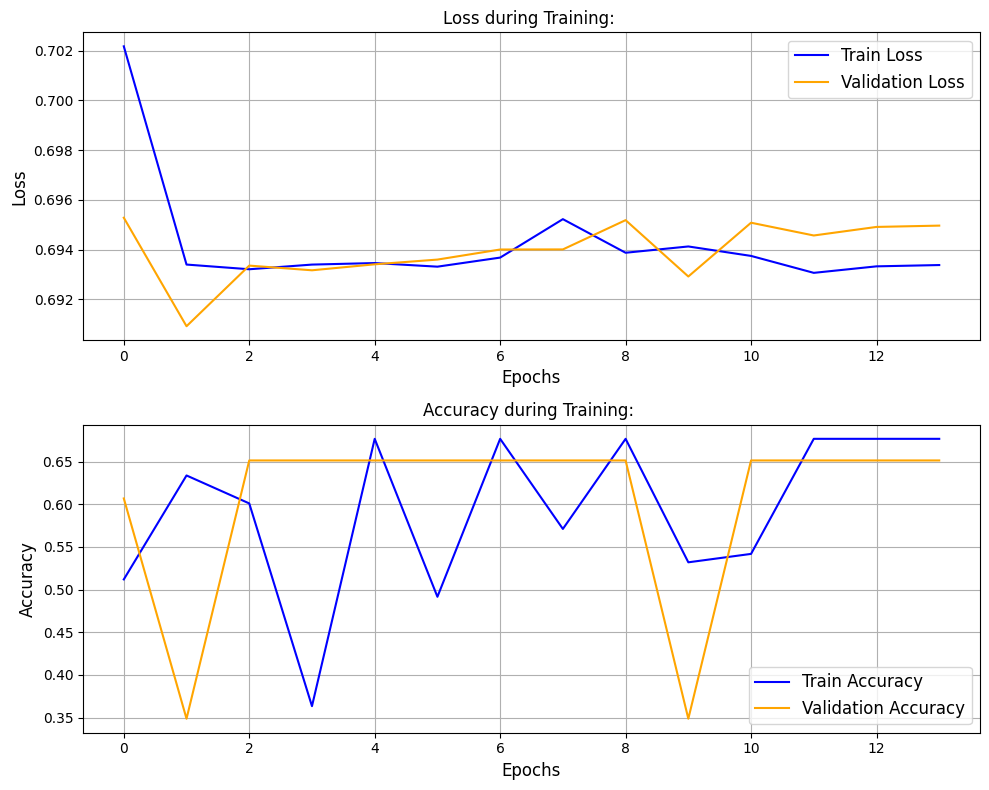

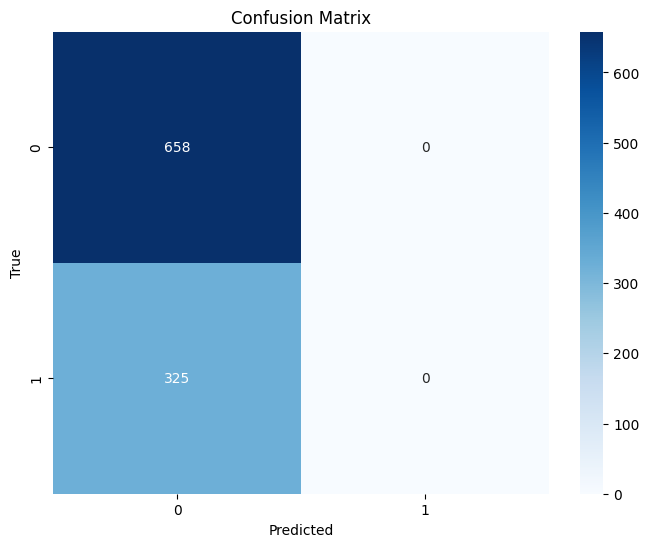

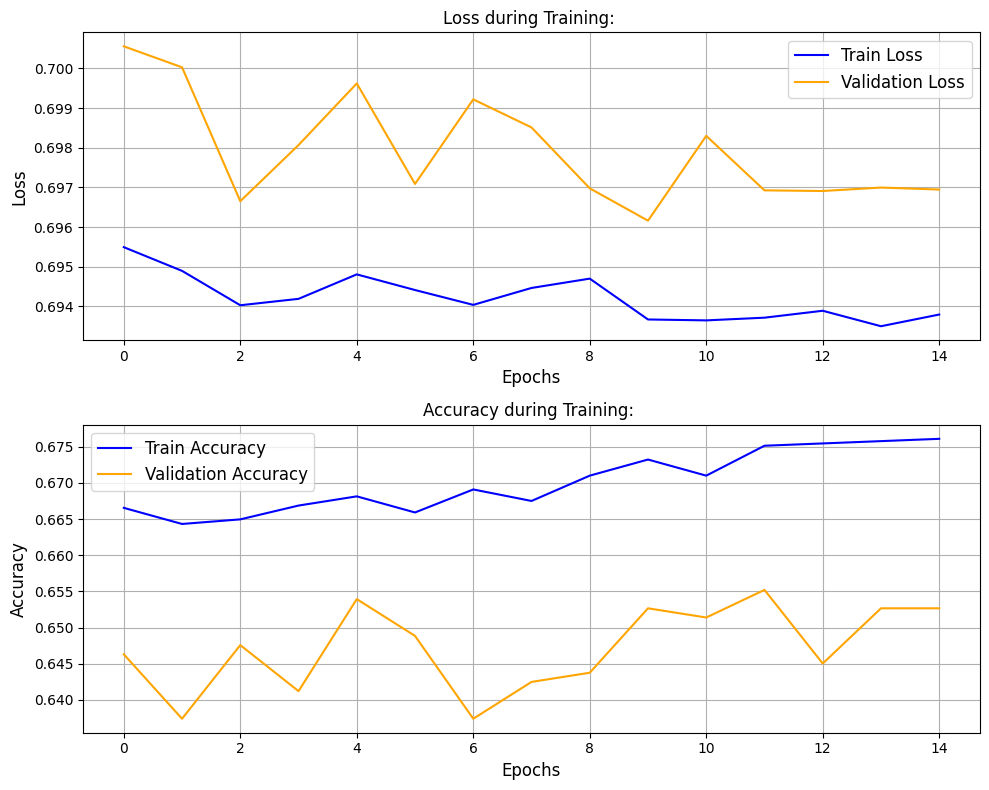

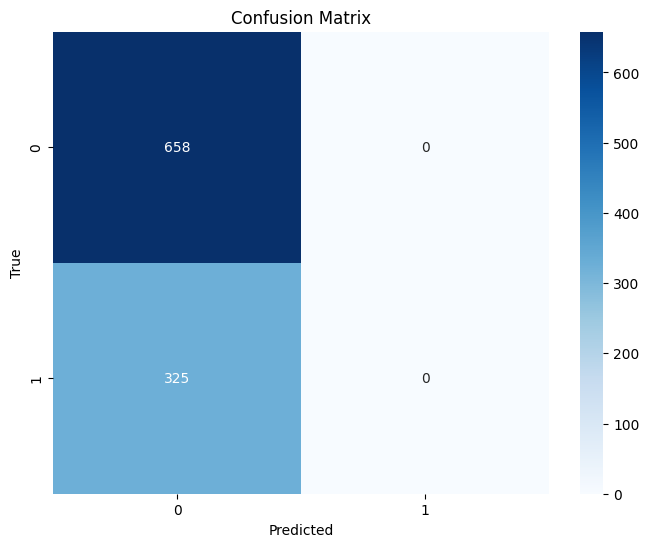

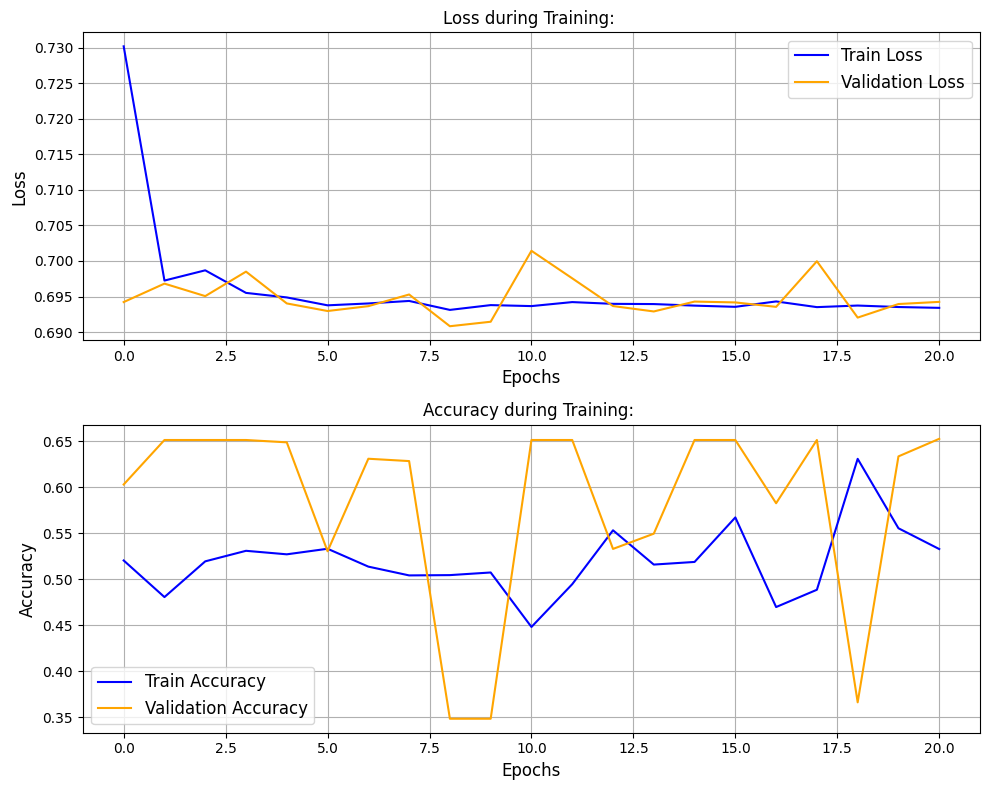

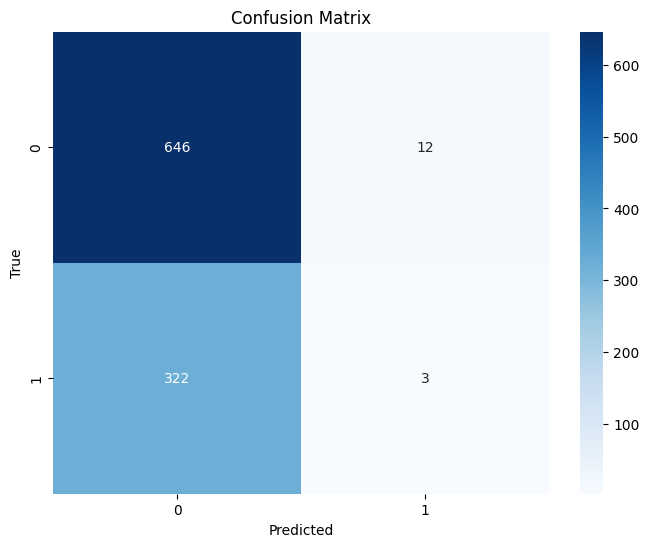

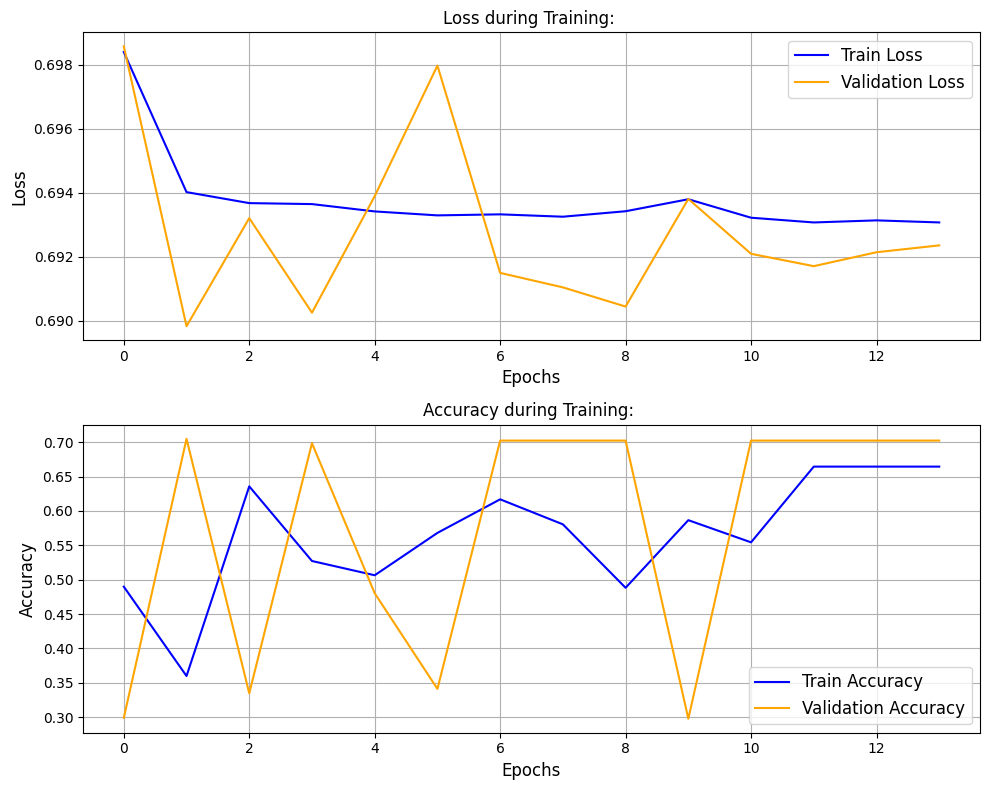

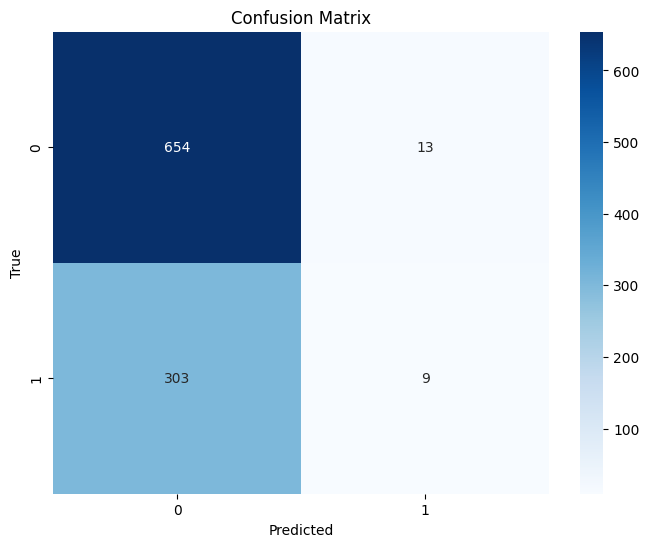

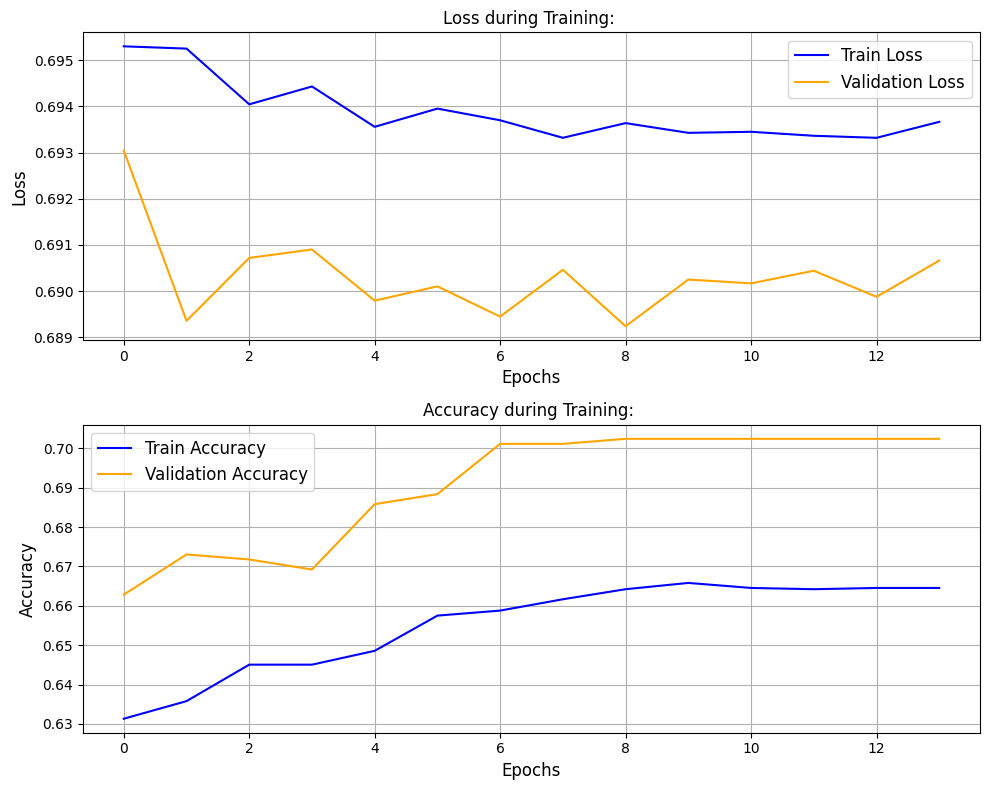

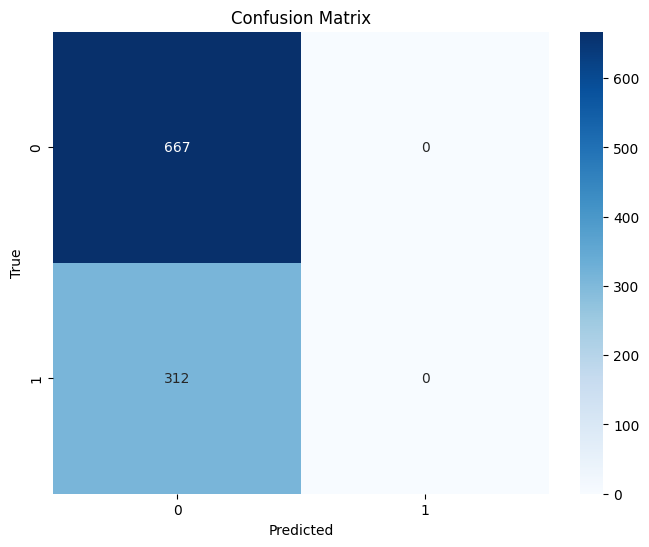

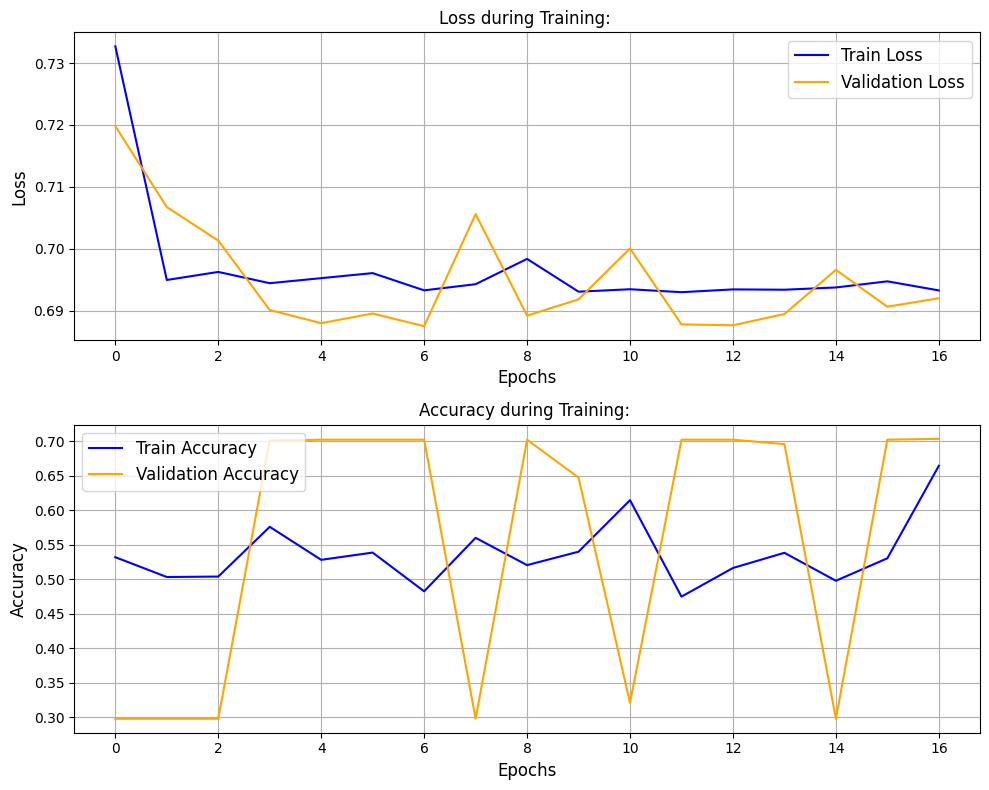

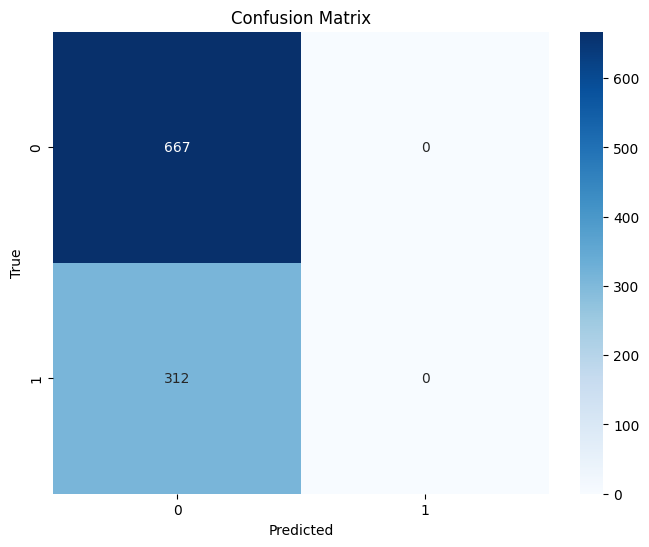

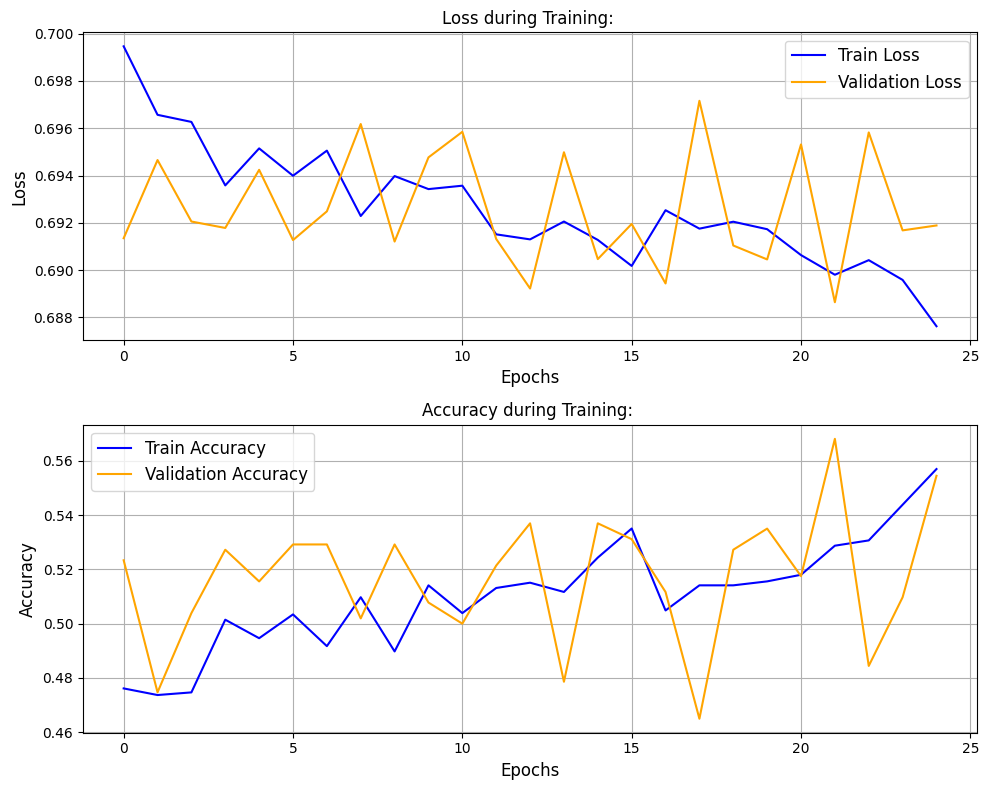

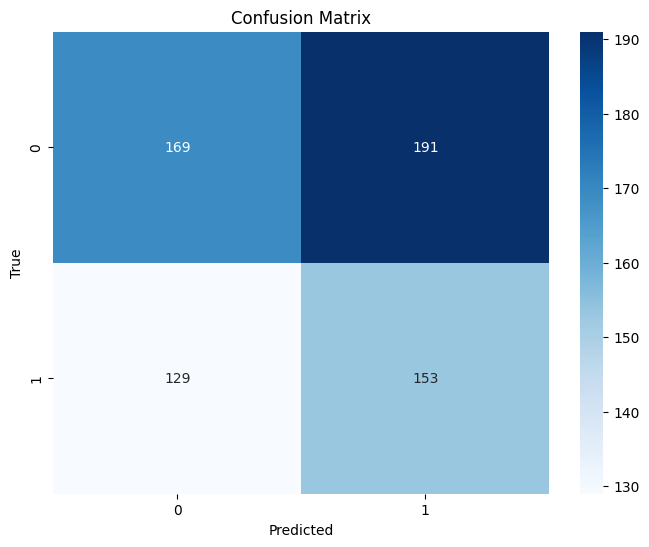

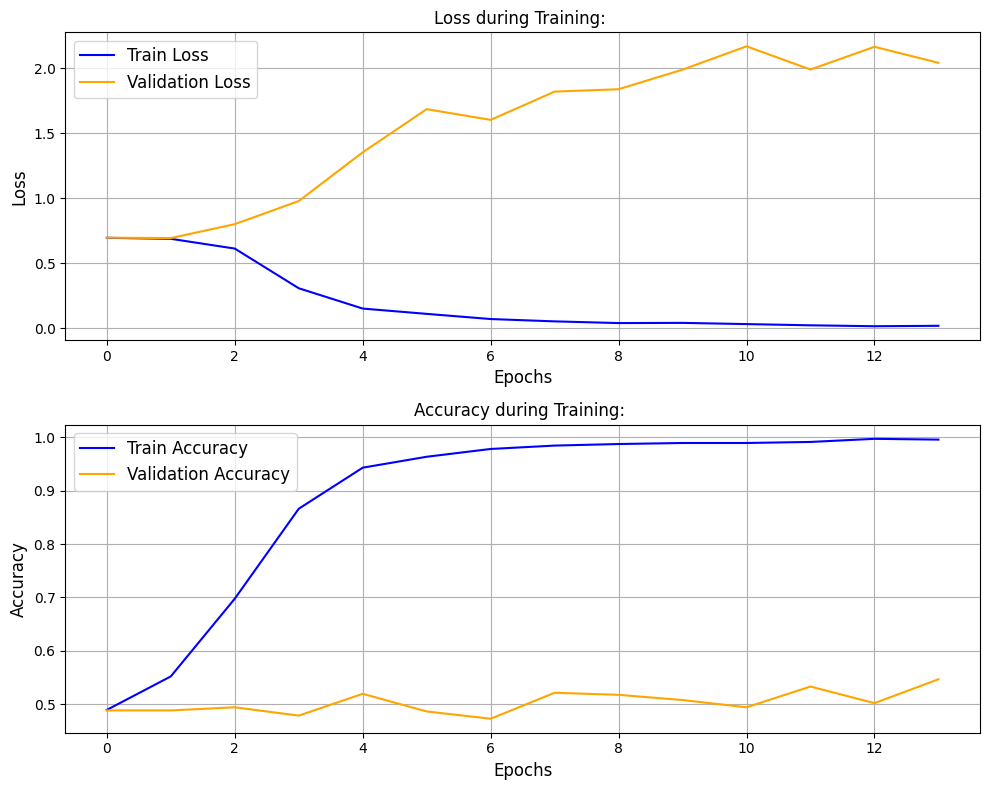

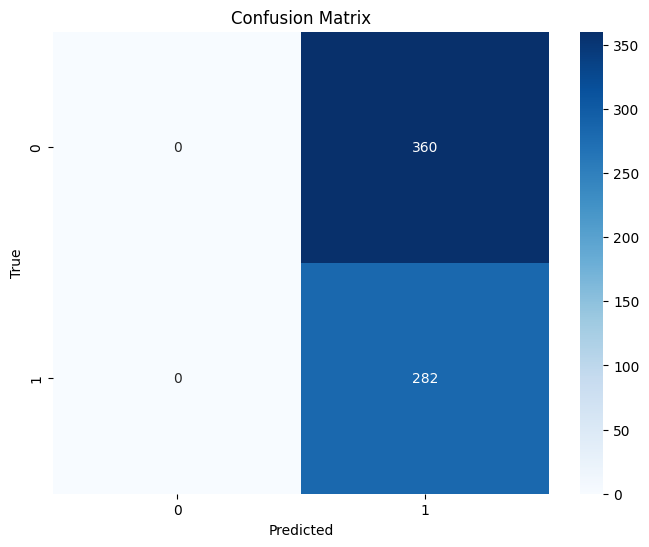

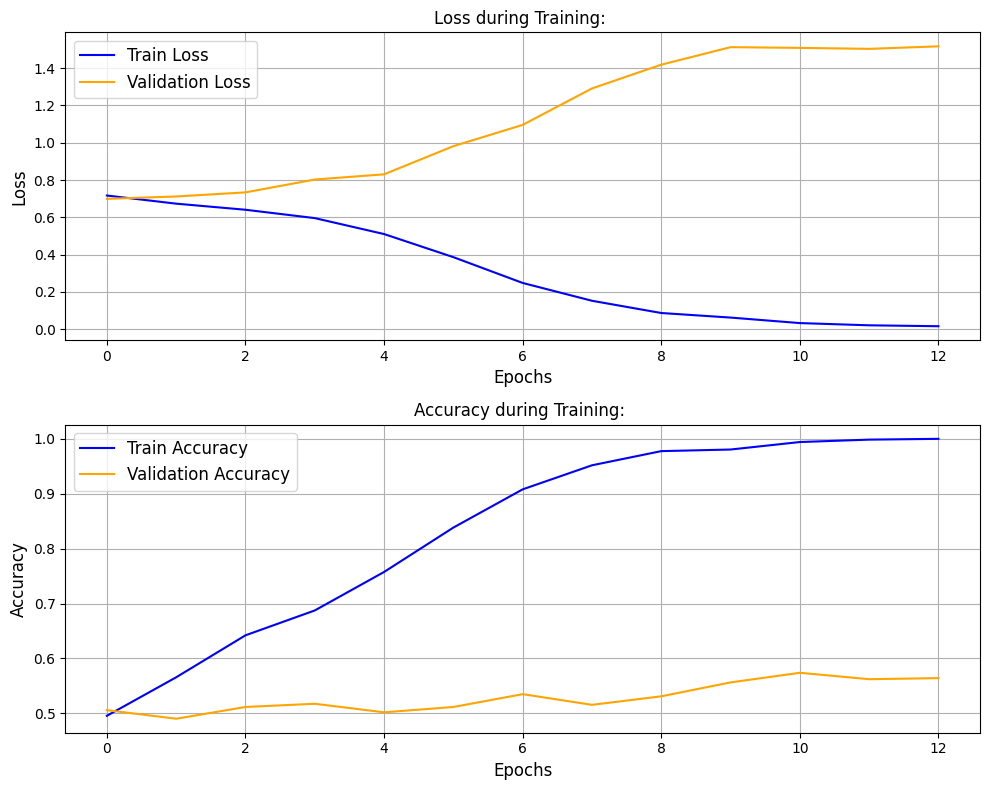

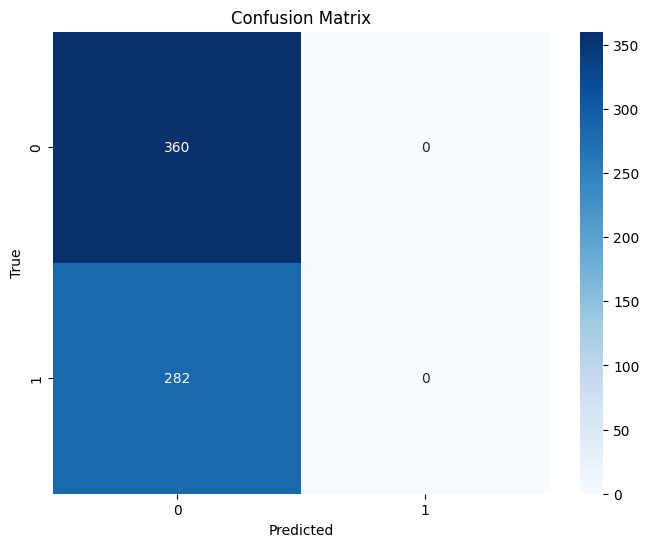

In [89]:
'''                                              *************** CON NUOVE MODIFICHE DEL PAPER ***************


Cosa cambia rispetto a prima

1) load_config_if_available:

    estrae la config (batch_size, lr, β₁, β₂, ε, ecc.)
    carica i best_weights salvati in .pkl da W&B

2) processed_datasets / processed_models

    evitano duplicate runs

3) Optimizer & Scheduler & EarlyStopping

    sono configurati con i valori estratti da config
    scheduler con patience=4 (dimezza lr dopo 4 epoche senza miglioramento di val_loss)
    early‐stopping con patience=12 sul val_loss

4) Training/testing

    la tua funzione training(...) dovrebbe accettare ora anche scheduler e early_stopping

5) GradCAM

    calcolato e salvato solo per il tuo CNN2D+LSTM

Con queste modifiche, il tuo loop:

    rispetta fedelmente il setup del paper
    mantiene la pipeline di W&B per la logica di sweep e salvataggio dei migliori modelli
    aggiunge minimi cambiamenti, lasciando intatte le tue funzioni training(), testing() e save_performance_results()

'''


# Imposta il seme per la riproducibilità

#Imposta il seme per i generatori casuali di PyTorch (per operazioni sui tensori e inizializzazione dei pesi dei modelli).
#Importante se vuoi garantire che l'addestramento del modello produca gli stessi risultati in diverse esecuzioni.
torch.manual_seed(32)

#Imposta il seme per NumPy, utile se NumPy viene usato per operazioni casuali (ad es. shuffling dei dati, inizializzazione di matrici, ecc.).
#Importante se usi NumPy per il preprocessing dei dati e vuoi riproducibilità.

np.random.seed(32)

#mposta il seme per il modulo random di Python (utile se si usano funzioni di randomizzazione di Python puro).
#Importante solo se usi random per operazioni come mescolamento di liste.
random.seed(32)

#Imposta il seme per i generatori casuali su GPU, se disponibile.
#Utile se stai eseguendo il codice su una GPU per garantire riproducibilità anche in quel contesto.

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(32)

       
'''

In questo caso, 

il set processed_datasets traccia i dataset già elaborati, 
e il set processed_models tiene traccia delle combinazioni già effettuate (modello + dataset). 

In questo modo, puoi escludere un dataset dal training se è già stato utilizzato in precedenza, 
anche se usato con un modello differente.
'''

# Dizionario per tracciare la standardizzazione usata per ogni combinazione d
# Dizionario per salvare informazioni sul modello (es. se i dati sono standardizzati)
models_info = {}


# Set per tenere traccia dei dataset già elaborati
processed_datasets = set()

# Set per tenere traccia delle combinazioni già elaborate
processed_models = set()


# Path delle performance dei modelli ottimizzati con weight and biases
# Path per trovare le best performances di ogni modello per ogni combinazione dei dati
base_folder = "/home/stefano/Interrogait/WB_spectrograms_best_results_motor_task_4_new"
                                        #WB_spectrograms_best_results_motor_task_1

# Path di salvataggio delle performance dei modelli dopo estrazione best models da base_folder
#save_path_folder = "/home/stefano/Interrogait/spectrograms_best_models_post_WB"


save_path_folder = "/home/stefano/Interrogait/spectrograms_best_models_post_WB_GradCAM_Checks_motor_task_4_new"
                                              #spectrograms_best_models_post_WB_GradCAM_Checks_motor_task_1_new


# --- LOOP PRINCIPALE (con minime modifiche) ---
for key, (X_data, y_data) in data_dict.items():
    
    print(f"\n\nEstrazione Dati per il dataset: \033[1m{key}\033[0m, \tShape X: \033[1m{X_data.shape}\033[0m, Shape y: \033[1m{y_data.shape}\033[0m")
    
    if key in processed_datasets:
        print(f"ATTENZIONE: Il dataset {key} è già stato elaborato! Salto iterazione...")
        continue
        
    processed_datasets.add(key)
    
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(X_data, y_data)
    print(f"Dataset Splitting: Train: \033[1m{X_train.shape}\033[0m, Val: \033[1m{X_val.shape}\033[0m, Test: \033[1m{X_test.shape}\033[0m")
    
    
    '''
    CREO COPIA TEST_LOADER_RAW PER I PLOT DEL POWER RAW PER BANDA E CLASSE
    '''
    # 1) salva una copia RAW dei soli dati di test PRIMA di standardizzare
    X_test_raw = X_test.copy()
    y_test_raw = y_test.copy()
    
    # 2) tensori
    X_raw_tensor = torch.tensor(X_test_raw, dtype=torch.float32)
    y_raw_tensor = torch.tensor(y_test_raw, dtype=torch.long)
    

    #for model_name in ["CNN2D", "BiLSTM", "Transformer"]:
    
    '''ATTENZIONE MODIFICA QUI'''
    
    for model_name in ["CNN2D_LSTM_TF", "BiLSTM", "Transformer"]:
        
        # Set the seed before any stochastic step of the pipeline
        set_seed(32)

        model_key = f"{model_name}_{key}"
        if model_key in processed_models:
            print(f"ATTENZIONE: Il modello {model_name} per il dataset {key} è già stato addestrato! Salto iterazione...")
            continue
        processed_models.add(model_key)
        
        print(f"\nPreparazione dati per il dataset \033[1m{key}\033[0m e il modello \033[1m{model_name}\033[0m...")
        
        # Prova a caricare la configurazione e i pesi ottimali dal file .pkl
        
        '''
        load_config_if_available --> prende in input 'key' che è la chiave composita (i.e, th_resp_vs_pt_resp_1_20_familiar_th)
        parse_combination_key --> prende in input 'key' che suddivide la chiave composita in stringhe separate
        
        exp_cond, data_type, category_subject che sfrutto per crearmi la directory path che mi servirà per caricarmi 
        pesi del modello e i suoi iper-parametri
        
        Diciamo che in questo caso, sfrutto 'parse_combination_key per qualcosa che serve a 'load_config_if_available' in modo IMPLICITO..
        '''
        
        config, best_weights = load_config_if_available(key, model_name, base_folder)
        
        if config is None:
            raise ValueError(f"\033[1mNessun file .pkl trovato per {model_name} su {key}\033[0m. Non posso procedere senza la configurazione ottimale.")
        
        '''
        Successivamente, queste variabili vengono invece create in maniera ESPLICITA per fasi successive del loop
        MA in questo caso, parsifica la chiave una VOLTA SOLA e memorizza i valori!
        '''
        
        # Parsifica la chiave una volta sola e memorizza i valori
        exp_cond, data_type, category_subject = parse_combination_key(key)
        
        '''
        Dpodiché, 
        
        1) si carica i vari valori degli iper-parametri,
        2) si esegue la standardizzazione se servisse,
        3) prepara il modello per la divisione in train_loader etc.,
        4) si carica la configurazione dei pesi del modello, 
        5) assegna i vari valori degli iper-parametri del modello corrente per la combinazione di dati correntemente iterata 
        
        6) esegue il training e il test e poi
        
        7) si salva il tutto nella path corrispondente...
        
        
        
        
        Ricordati di aggiungere le varie variabili associate alla definizione dinamica dei valori dei parametri model-specific qui!
    
        
        
        '''
        
        '''
        PER DARE UNIFORMITÀ AL CODICE, CAMBIO IL NOME DELLE VARIABILI, CHE CONTENGONO I VALORI OTTIMIZZATI 
        DA FORNIRE IN INPUT ALLE VARIE FUNZIONI CHE SONO RICHIAMATE NEL LOOP'''
        
        
        model_lr = config["lr"]
        model_weight_decay = config["weight_decay"]
        model_n_epochs = config["n_epochs"]
        model_patience = config["patience"]
        
        
        model_batch_size = config["batch_size"]
        model_standardization = config["standardization"]
        
        #model_n_epochs = config["n_epochs"]
        #model_patience = config["patience"]
        
        #model_lr = config["lr"]
        
        '''NUOVE MODIFICHE'''
        model_beta1 =  config["beta1"]
        model_beta2 =  config["beta2"]
        model_eps = config["eps"]
        
        
        
        #model_weight_decay = config["weight_decay"]
        #model_standardization = config["standardization"]
        
        #print(f"Parametri per \033[1m{model_name}\033[0m: batch_size= \033[1m{model_batch_size}\033[0m, n_epochs= \033[1m{model_n_epochs}\033[0m, patience= \033[1m{model_patience}\033[0m, lr= \033[1m{model_lr}\033[0m, weight_decay= \033[1m{model_weight_decay}\033[0m, standardization= \033[1m{model_standardization}\033[0m")
        print(f"Parametri per \033[1m{model_name}\033[0m: batch_size= \033[1m{model_batch_size}\033[0m, n_epochs= \033[1m{model_n_epochs}\033[0m, patience= \033[1m{model_patience}\033[0m, lr= \033[1m{model_lr}\033[0m, model_beta1= \033[1m{model_beta1}\033[0m,  model_beta2= \033[1m{model_beta2}\033[0m,  model_eps= \033[1m{model_eps}\033[0m, standardization= \033[1m{model_standardization}\033[0m")
        
        # Salva nel dizionario se per quella combinazione è stata applicata la standardizzazione ai dati
        models_info[model_key] = {"standardization": model_standardization}
        
        
        # 3) dataset & loader per test set (per plots power raw) –‑  IMPORTANTISSIMO: shuffle=False
        raw_dataset = TensorDataset(X_raw_tensor, y_raw_tensor)
        test_loader_raw = DataLoader(raw_dataset,
                             batch_size=model_batch_size,
                             shuffle=False)
        
        
        
        '''PER MANTENERE LA STESSA LOGICA DEL CODICE (ANCHE SE POTREI INSERIRLA DENTRO PREPARE_DATA_FOR_MODEL MODIFICANDO LA FUNZIONE (SI VEDA IN CELLA SOPRA COME)
        IMPONGONO LA STANDARDIZZAZIONE PRIMA DI QUESTA FUNZIONE
        '''

        if model_standardization:
            X_train, X_val, X_test = standardize_data(X_train, X_val, X_test)
            print(f"\033[1mSÌ Standardizzazione Dati!\033[0m")
        else:
            print(f"\033[1mNO Standardizzazione Dati!\033[0m")
        
        # Sposta il modello sulla GPU (se disponibile)
        device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

        
        # Preparazione dei dataloaders
        train_loader, val_loader, test_loader, class_weights_tensor = prepare_data_for_model(
            X_train, X_val, X_test, y_train, y_val, y_test, model_type = model_name, batch_size = model_batch_size)
        
        # Inizializzazione del modello
        #if model_name == "CNN2D":
        #    model = CNN2D(input_channels=64, num_classes=2)
        
        '''
        # ====== MODELLI TIME×FREQ ======
    
        cnn_model = CNN2D_LSTM_TF(input_channels = input_channels, num_classes =num_classes, dropout = dropout)
        hidden_sizes = [24, 48, 62]
        lstm_model = ReadMEndYou(input_size=input_channels * num_freqs, hidden_sizes=hidden_sizes, output_size=num_classes)
        transformer_model = ReadMYMind(d_model=d_model, num_heads=num_heads, num_layers=num_layers, num_classes=num_classes)

        # Creazione di dati fittizi per il test
        x = torch.randn(batch_size, input_channels, num_freqs, num_timepoints)  # (batch, canali, frequenze, tempo)
        

        # ricavo channels e freqs dai dati (shape attesa: N, C, F, T)
        channels, freqs = int(X_train.shape[1]), int(X_train.shape[2])

        if config.model_name == "CNN2D_LSTM_TF":

            #OCCHIO QUI ADESSO SAREBBE TEMPO x FREQUENZA

            model = CNN2D_LSTM_TF(
                input_channels = channels, # qui 64
                num_classes = 2,
                dropout=config.dropout,
            )

            print(f"\nInizializzazione Modello \033[1mCNN2D_LSTM_TF\033[0m")


        elif config.model_name == "BiLSTM":
            hidden_sizes = [24, 48, 62]
            model = ReadMEndYou(
                input_size = channels * freqs, #  qui 64*81
                hidden_sizes = hidden_sizes,
                output_size = 2,
                dropout = config.dropout,
                bidirectional = config.bidirectional
            )
            print(f"\nInizializzazione Modello \033[1mReadMEndYou (BiLSTM)\033[0m")

        elif config.model_name == "Transformer":
            model = ReadMYMind(
                d_model=config.d_model,
                num_heads=config.num_heads,
                num_layers=config.num_layers,
                num_classes=2,
                channels = channels,
                freqs = freqs
            )

            print(f"\nInizializzazione Modello \033[1mReadMYMind (Transformer)\033[0m")
        else:
            raise ValueError(f"Modello sconosciuto: {config.model_name}")
            
        
        '''
        
        #channels, freqs = int(X_train.shape[1]), int(X_train.shape[2])
        
        #sweep_config_cnn2d_lstm_tf
        #sweep_config_bilstm
        #sweep_config_transformer
        
        '''PARAMETRI MODEL-SPECIFIC DI CNN2D_LSTM_TF, BiLSTM e Transformer, ma richiamati al momenti della inizializzazione deii relativi sweep_config! '''
        
        #model_dropout = config['dropout']
        #model_bidirectional = config['bidirectional']
        #model_d_model = config['d_model']
        #model_num_heads = config['num_heads']
        #model_num_layers  = config['num_layers']
        
        
        channels, freqs = int(X_train.shape[1]), int(X_train.shape[2])
        
        if model_name == "CNN2D_LSTM_TF":
            
            sweep_config = sweep_config_cnn2d_lstm_tf
            
            model_dropout = float(config.get('dropout', 0.5))
            
            
            model = CNN2D_LSTM_TF(input_channels = channels, num_classes = 2, dropout = model_dropout) #input_channels = 64
        elif model_name == "BiLSTM":
            
            sweep_config = sweep_config_bilstm
            
            model_dropout = float(config.get('dropout', 0.5))
            model_bidirectional = bool(config.get('bidirectional', False))
            
            #input_size= 64 * 81
            model = ReadMEndYou(input_size= channels * freqs, hidden_sizes=[24, 48, 62], output_size=2, dropout = model_dropout, bidirectional = model_bidirectional)
            
        elif model_name == "Transformer":
            
            sweep_config = sweep_config_transformer
            
            model_d_model = int(config.get('d_model', 32))
            model_num_heads = int(config.get('num_heads', 2))
            model_num_layers  = int(config.get('num_layers', 2))
            
            model = ReadMYMind(d_model = model_d_model, num_heads = model_num_heads, num_layers = model_num_layers, num_classes=2, channels = channels, freqs= freqs) #channels = 64, freqs=81
        else:
            raise ValueError(f"Modello {model_name} non riconosciuto.")
        
        # Se abbiamo caricato i pesi ottimali, li carichiamo nel modello
        if best_weights is not None:
            try:
                model.load_state_dict(best_weights)
                print(f"📊 Modello \033[1m{model_name}\033[0m inizializzato con \033[01i pesi ottimizzati\033[0m tramite hyper-parameter tuning su \033[1mWeight & Biases\033[0m")
            except Exception as e:
                print(f"⚠️Errore nel caricamento dei pesi per {model_name} su {key}: {e}")
                continue
        
        
        '''NUOVE MODIFICHE'''
        # Definizione del criterio di perdita
        criterion = nn.CrossEntropyLoss(weight = class_weights_tensor)
        
        '''OLD VERSION'''
        # Definizione dell'ottimizzatore con i parametri aggiornati
        #optimizer = torch.optim.Adam(model.parameters(), lr = model_lr, weight_decay = model_weight_decay)
        
        '''NUOVE MODIFICHE'''
        
         # 10) ottimizzatore + scheduler + early stopping
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr    = model_lr,
            betas = (model_beta1, model_beta2),
            eps   = model_eps,
            weight_decay = model_weight_decay
            
        )
            
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode     = "min",   # monitoriamo val_loss
            factor   = 0.1,
            patience = 8,
            verbose  = True
        )
        
        
        #early_stopping = EarlyStopping(patience=model_patience, mode="max")
        #criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
        
        
        '''OLD VERSION'''
        #print(f"🏋️‍♂️Avvio del training per \033[1m{model_name}\033[0m sul dataset \033[1m{key}\033[0m...")
        #my_train_results = training(model, train_loader, val_loader, optimizer, criterion, n_epochs = model_n_epochs, patience = model_patience)
    
        #print(f"Avvio del testing per \033[1m{model_name}\033[0m sul dataset \033[1m{key}\033[0m...")
        #my_test_results = testing(my_train_results, test_loader, criterion)
        
        '''NEW VERSION'''
        # --- dopo model.load_state_dict(best_weights) e criterion = nn.CrossEntropyLoss() ---

        # 1) prepara i data_loaders per train/val
        data_loaders = {
            "train": train_loader,
            "val":   val_loader
        }
        
        print(f"🏋️‍♂️Salvo le metriche del training per \033[1m{model_name}\033[0m sul dataset \033[1m{key}\033[0m a seguito della ottimizzazione su W&B ...")
        # 2) richiama la funzione che pesca da W&B la best‐run e corregge la train AUC
        
        #ATTENZIONE al potenziale problema di stringa, non di API: 

        #i due esempi che hai postato in realtà usano diversi caratteri “‑” (uno è il classico ASCII U+002D, l’altro è un non‑breaking hyphen U+2011 o simili), quindi quando chiami
        
        #entity = "stefano‑bargione‑universit‑di‑roma‑tor‑vergata"
        #stai passando un nome che W&B non riconosce (e quindi api.projects(entity=…) torna vuoto), mentre con

        #entity = "stefano-bargione-universit-di-roma-tor-vergata"
        #funziona perché lì usi i semplici - ASCII.

        my_train_results = load_best_run_results(
            key=key,
            model = model,
            sweep_config = sweep_config,
            data_loaders = data_loaders,
            entity = "stefano-bargione-universit-di-roma-tor-vergata"
        )
        
        
        '''
        L’entity che passi a Api().runs(f"{entity}/{project}") è semplicemente il tuo account (o l’organizzazione) su W&B,
        cioè la parte che compare subito prima del nome del progetto nell’URL.

        Per esempio, se quando apri il tuo progetto su W&B vedi un indirizzo del tipo
        
        -> https://wandb.ai/steclab/some_project_name, allora entity = "steclab".
        
        Se invece lavori sotto un’organizzazione 
        
        -> “cool‑team”, e l’URL è https://wandb.ai/cool-team/some_project_name, allora userai entity = "cool-team".

        Puoi verificarlo:

        Accedi a wandb.ai e vai sul progetto.
        Leggi la prima parte dell’URL (tra wandb.ai/ e il /project_name).
        Copiala esattamente come stringa in entity.

        Così il tuo Api().runs(f"{entity}/{project}") andrà a pescare proprio le run che hai lanciato tu.

        my_train_results = load_best_run_results(
            key= key,
            model = model,
            sweep_config = sweep_config,
            data_loaders = data_loaders,
            entity= "mio-entity"
        )
        
        '''
        
        print(f"Avvio del testing per \033[1m{model_name}\033[0m sul dataset \033[1m{key}\033[0m...")
        # 3) usa il best_model caricato dentro `train_results` e chiama il testing
        my_test_results = testing(my_train_results, test_loader, criterion)
        
        
        
        '''
        GRADCAM COMPUTATION PER IL MODELLO CNN2D_LSTM_TF
        
        La funzione compute_gradcam_figure estrae due campioni (uno per ogni classe) e crea una figura con le due righe richieste.
        
        Il parametro gradcam_image (un buffer binario o un'immagine) viene passato alla funzione di salvataggio, 
        'save_performance_results', in modo da essere salvato nella path corretta. 
        
        La funzione 'save_performance_results' è stata modificata 
        per gestire ANCHE questo nuovo input dell'immagine 
        
        (ossia, per salvare il file con un nome che inizia con 'GradCAM_results_'
        seguito da tutte le altre stringhe corrispondenti alla combinazione di fattori che costituiscono il dataset corrente:
        
        - coppia di condizioni sperimentali da cui provengono i dati (i.e., th_resp_vs_pt_resp )
        - tipologia di dato EEG prelevato (i.e., spectrograms) 
        - provenienza del dato stesso (i.e., familiar_th)
        )
        
        Spiegazione:
        
        La funzione compute_gradcam_figure eseguire il calcolo di GradCAM (vedi dettagli nella sua funzione)
        e alla fine ritornerà in output una variabile 
        
        'fig_image' che sarà poi assegnata alla variabile 'gradcam_image',
        che è un oggetto buffer, che contiene i dati binari dell'immagine in formato PNG
        (poiché abbiamo usato plt.savefig con format='png'). 
        
        Quindi, quando passi gradcam_image (cioè fig_image) alla funzione 'save_performance_results',
        viene scritto direttamente su disco come file PNG.
        
        Non c'è bisogno di ri-aprire o convertire ulteriormente, a meno che tu non voglia manipolare l'immagine in seguito.
        Quindi, la soluzione è corretta così com'è:
        il buffer viene salvato come file PNG nella directory specificata, 
        e successivamente potrai aprirlo con una libreria come cv2 o PIL se necessario.        
        
        Quindi, gradcam_image (i.e., fig_image) viene quindi passato correttamente dentro al loop di training e test, 
        tramite 'save_performance_results', come input, 
        che salverà quindi poi l'immagine nella path corrispondente 

        '''
        
        # Se il modello è CNN2D, calcola anche GradCAM per la visualizzazione
        gradcam_image = None
        
        #if model_name == "CNN2D":
        
        '''ATTENZIONE MODIFICA QUI'''
        
        if model_name == "CNN2D_LSTM_TF":
            
            '''
            ATTENZIONE! Qui ho aggiunto alla nuova versione di "compute_gradcam_figure" (versione del 17/09/2025)
            il test_loader_raw tra gli argomenti della funzione!
            '''
            gradcam_image = compute_gradcam_figure(model, test_loader, test_loader_raw, exp_cond, data_type, category_subject, device)
            if gradcam_image is not None:
                print(f"Creazione di \033[1mGradCAM Image\033[0m per il modello \033[1m{model_name}\033[0m.")
                
        print(f"Salvataggio dei risultati per \033[1m{model_name}\033[0m sul dataset \033[1m{key}\033[0m...")
        save_performance_results(model_name,
                                 my_train_results,
                                 my_test_results,
                                 key,
                                 exp_cond,
                                 model_standardization,
                                 base_folder = save_path_folder,
                                 gradcam_image = gradcam_image)
        
        
        '''
        N.B
        
        gradcam_image = None avverrà solo all'inizio cioè per il primo modello CNN2D, che verrà testato con una certa combinazione di dati mi sa.. 
        ma servirebbe tracciare in qualche modo 

        1) o che la gradcam_image di ogni combinazione venga ri-azzerata alla fine loop
        2) o che venga monitorato che gradcam_image di una combinazione di dati già analizzata venga esclusa poi
        (o messa in un set) in modo che rivenga per errore sovrascritta più volte.. 
        
        Forse la strada più veloce potrebbe essere la soluzione 1)
        
        La soluzione più veloce e semplice è reimpostare la variabile gradcam_image a None alla fine dell'iterazione per ogni combinazione di dati
        (cioè, all'interno del ciclo esterno che itera su key). 
         
        In questo modo, per ogni nuovo dataset la variabile viene "azzera" e viene calcolata l'immagine GradCAM solo per quella combinazione, 
        evitando di sovrascrivere accidentalmente i risultati già calcolati per combinazioni precedenti.
         
        Un'altra possibilità sarebbe tenere traccia delle chiavi (o combinazioni) per cui hai già calcolato la GradCAM,
        ad esempio usando un set, e saltare il calcolo se la combinazione è già presente. 
        
        Tuttavia, se ogni combinazione deve avere la sua immagine, 
        la soluzione più semplice è quella di reimpostare gradcam_image = None alla fine dell'iterazione.
        
        Quindi, per esempio, alla fine del ciclo per ogni dataset (key) potresti fare:
        (VEDI SOTTO)
        
        In questo modo, ti assicuri che per ogni nuova combinazione la variabile sia pulita e pronta per essere ricalcolata, 
        senza rischio di sovrascrivere o confondere i risultati
        '''
        
        # Reimposta gradcam_image a None per la prossima combinazione di dati
        gradcam_image = None

In [90]:
print("finito")

finito


In [92]:
print(models_info.keys())

dict_keys(['CNN2D_LSTM_TF_rest_vs_both_feet_spectrograms_familiar_th', 'BiLSTM_rest_vs_both_feet_spectrograms_familiar_th', 'Transformer_rest_vs_both_feet_spectrograms_familiar_th', 'CNN2D_LSTM_TF_rest_vs_both_fists_spectrograms_familiar_th', 'BiLSTM_rest_vs_both_fists_spectrograms_familiar_th', 'Transformer_rest_vs_both_fists_spectrograms_familiar_th', 'CNN2D_LSTM_TF_both_feet_vs_both_fists_spectrograms_familiar_th', 'BiLSTM_both_feet_vs_both_fists_spectrograms_familiar_th', 'Transformer_both_feet_vs_both_fists_spectrograms_familiar_th'])


In [93]:
with open('/home/stefano/Interrogait/spectrograms_best_models_post_WB_GradCAM_Checks_motor_task_4_new.pkl', 'wb') as f:
    pickle.dump(models_info, f)

#### **CREAZIONE DELLE TABLES CON INTEGRAZIONE DELLE PERFORMANCE TRAINING & TEST DEI MODELLI DENTRO DATAFRAME**

#### **Integrazioni in Tabella delle Performance Training e Test del Modello dentro DataFrame - NEW APPROACH**

#### Implementazione 

In [141]:
import pickle 
path = '/home/stefano/Interrogait/'

with open(f"{path}spectrograms_best_models_post_WB_GradCAM_Checks_motor_task_4_new.pkl", "rb") as f:
    models_info = pickle.load(f)

In [142]:
'''
In questo codice:

model_info.get('standardization', False) cerca la chiave 'standardization' all'interno di ogni sottodizionario. 
Se non esiste, restituirà False come valore di default.
Se standardization è True, stampa la chiave associata.
'''

# Ciclo attraverso le chiavi di 'models_info'
for key, model_info in models_info.items():
    # Controllo se 'standardization' è True
    if model_info.get('standardization', False):  # Default a False nel caso in cui non esista la chiave
        print(key)  # Stampa la chiave



CNN2D_LSTM_TF_rest_vs_both_feet_spectrograms_familiar_th
BiLSTM_rest_vs_both_feet_spectrograms_familiar_th
Transformer_rest_vs_both_feet_spectrograms_familiar_th
CNN2D_LSTM_TF_rest_vs_both_fists_spectrograms_familiar_th
BiLSTM_rest_vs_both_fists_spectrograms_familiar_th
Transformer_rest_vs_both_fists_spectrograms_familiar_th
CNN2D_LSTM_TF_both_feet_vs_both_fists_spectrograms_familiar_th
BiLSTM_both_feet_vs_both_fists_spectrograms_familiar_th
Transformer_both_feet_vs_both_fists_spectrograms_familiar_th


In [143]:
models_info

{'CNN2D_LSTM_TF_rest_vs_both_feet_spectrograms_familiar_th': {'standardization': True},
 'BiLSTM_rest_vs_both_feet_spectrograms_familiar_th': {'standardization': True},
 'Transformer_rest_vs_both_feet_spectrograms_familiar_th': {'standardization': True},
 'CNN2D_LSTM_TF_rest_vs_both_fists_spectrograms_familiar_th': {'standardization': True},
 'BiLSTM_rest_vs_both_fists_spectrograms_familiar_th': {'standardization': True},
 'Transformer_rest_vs_both_fists_spectrograms_familiar_th': {'standardization': True},
 'CNN2D_LSTM_TF_both_feet_vs_both_fists_spectrograms_familiar_th': {'standardization': True},
 'BiLSTM_both_feet_vs_both_fists_spectrograms_familiar_th': {'standardization': True},
 'Transformer_both_feet_vs_both_fists_spectrograms_familiar_th': {'standardization': True}}

In [144]:
#for key, model_info in all_models.items():
#    print(key)

In [145]:
'''
Siccome la stringa associata alla category subject è diversa tra i due.. 

familiar_th  familiar_pt unfamiliar_pt unfamiliar_pt  da un lato (models_info)
th_fam, pt_fam, th_unfam, pt_unfam  dall'altro (all_models)

la corrispondenza non avverrà mai... per cui, si deve fare il mapping corrispondente tra 
le stringhe di uno e dell'altro, in modo che models_info cambi come parte della stringa della sua chiave da queste 

familiar_th  familiar_pt unfamiliar_pt unfamiliar_pt
a queste
th_fam, pt_fam, th_unfam, pt_unfam 

'''

mapping_subject = {
    "familiar_th": "th_fam",
    "familiar_pt": "pt_fam",
    "unfamiliar_th": "th_unfam",
    "unfamiliar_pt": "pt_unfam"
}

# Creiamo un nuovo dizionario con le chiavi corrette
updated_models_info = {}

for key, value in models_info.items():
    for old_suffix, new_suffix in mapping_subject.items():
        if key.endswith(old_suffix):
            new_key = key.replace(old_suffix, new_suffix)
            updated_models_info[new_key] = value
            break  # Evita sostituzioni multiple se una è già stata fatta
    else:
        # Se nessuna sostituzione è stata fatta, mantieni la chiave originale
        updated_models_info[key] = value

# Sostituisci il vecchio dizionario con quello aggiornato
models_info = updated_models_info


In [146]:
models_info.keys()

dict_keys(['CNN2D_LSTM_TF_rest_vs_both_feet_spectrograms_th_fam', 'BiLSTM_rest_vs_both_feet_spectrograms_th_fam', 'Transformer_rest_vs_both_feet_spectrograms_th_fam', 'CNN2D_LSTM_TF_rest_vs_both_fists_spectrograms_th_fam', 'BiLSTM_rest_vs_both_fists_spectrograms_th_fam', 'Transformer_rest_vs_both_fists_spectrograms_th_fam', 'CNN2D_LSTM_TF_both_feet_vs_both_fists_spectrograms_th_fam', 'BiLSTM_both_feet_vs_both_fists_spectrograms_th_fam', 'Transformer_both_feet_vs_both_fists_spectrograms_th_fam'])

In [147]:
''' Ciclo attraverso le chiavi di 'models_info' AGGIORNATO!'''

for key, model_info in models_info.items():
    # Controllo se 'standardization' è True
    if model_info.get('standardization', False):  # Default a False nel caso in cui non esista la chiave
        print(key)  # Stampa la chiavi

CNN2D_LSTM_TF_rest_vs_both_feet_spectrograms_th_fam
BiLSTM_rest_vs_both_feet_spectrograms_th_fam
Transformer_rest_vs_both_feet_spectrograms_th_fam
CNN2D_LSTM_TF_rest_vs_both_fists_spectrograms_th_fam
BiLSTM_rest_vs_both_fists_spectrograms_th_fam
Transformer_rest_vs_both_fists_spectrograms_th_fam
CNN2D_LSTM_TF_both_feet_vs_both_fists_spectrograms_th_fam
BiLSTM_both_feet_vs_both_fists_spectrograms_th_fam
Transformer_both_feet_vs_both_fists_spectrograms_th_fam


In [148]:
'''
Parsing della chiave e costruzione del path:
Usando la funzione parse_combination_key si estraggono 

exp_cond, data_type e category_subject dalla chiave del dataset. 

Questi vengono usati per costruire il percorso in cui cercare i file .pkl.
'''

# Funzione per parsare la chiave
def parse_combination_models_keys(combination_key):
    """
    Estrae (exp_cond, data_type, category_subject) da combination_key.
    
    Il formato atteso PRIMA è:
    
    "th_resp_vs_pt_resp|pt_resp_vs_shared_resp|th_resp_vs_shared_resp" _ spectrograms" _ "familiar_th|familiar_pt|unfamiliar_th|unfamiliar_pt"
    
    Il formato atteso ORA è:
    
     "th_resp_vs_pt_resp|pt_resp_vs_shared_resp|th_resp_vs_shared_resp" _ spectrograms" _ "th_fam|th_unfam|pt_fam|pt_unfam"
     
    """
    #r"^(th_resp_vs_pt_resp|pt_resp_vs_shared_resp|th_resp_vs_shared_resp)_(spectrograms)_(th_fam|th_unfam|pt_fam|pt_unfam)$", 
    
    match = re.match(
        #r"^(rest_vs_left_fist|rest_vs_right_fist|left_fist_vs_right_fist)_(spectrograms)_(th_fam|th_unfam|pt_fam|pt_unfam)$",
        r"^(rest_vs_both_feet|rest_vs_both_fists|both_feet_vs_both_fists)_(spectrograms)_(th_fam|th_unfam|pt_fam|pt_unfam)$",
        combination_key
    )
    if match:
        return match.groups()  # (exp_cond, data_type, category_subject)
    else:
        raise ValueError(f"Formato non valido: {combination_key}")
        
    return exp_cond, data_type, category_subject

#### Implementazione : Versione dal 24 novembre 2025

In [149]:
'''

Guarda ti faccio vedere: con la tua proposta qui che mi hai detto viene bene secondo me, 
ma mi sembra un po' troppo "larga" da inserire come tabella per la tesi... 

non so se allora convenga invece fare come ad esempio avevi cercato di fare per questa altra tabella (seconda immagine),

e l'idea potrebbe essere quella di avere tutto a sinistra, le metriche uno sotto l'altra,
dopodiché mettere un header per "train", 
sotto al quale metti uno accanto all'altro i tre modelli (CNN2D_LSTM, BiLSTM e Trasformer) 
e ci metti il valore di ad esempio accuracy per il train di quei modelli; 

nell'header successivo, mettere invece "validation" e sotto al quale metti uno accanto all'altro i tre modelli (CNN2D_LSTM, BiLSTM e Trasformer)
e ci metti il valore di ad esempio accuracy per il validation di quei modelli; 

nell'header successivo, mettere invece "test" e sotto al quale metti uno accanto all'altro i tre modelli (CNN2D_LSTM, BiLSTM e Trasformer)
e ci metti il valore di ad esempio accuracy per il test di quei modelli; 

E così anche per le altre metriche, in modo che: 

Tutto a sinistra, hai le metriche, poi hai gli "header" suddivisi per fold (train, val, test),
e sotto il nome del modello e a partire dalla stessa riga da cui parte la prima metrica, metti il valore del modello in questione, 
per quella metrica, a quel fold.. non so se mi son spiegato..


Capito perfettamente cosa vuoi:

Metriche in riga (Accuracy, Loss, Precision, …)

Blocchi di colonne per Train / Val / Test

Sotto ogni blocco, le colonne dei modelli (CNN2D_LSTM, BiLSTM, Transformer).

Quindi una tabella tipo:

| Metric | Train – CNN2D | Train – BiLSTM | Train – Transf | Val – CNN2D | … | Test – Transf |

Compatta, pochi colonne (1 + 3×3 = 10) e ottima da mettere in tesi.

Ti lascio il codice completo, già sistemato per:

usare tutte le metriche (Accuracy, Loss, Precision, Recall, F1-Score, AUC-ROC)

ordinare le righe dei modelli come: CNN2D_LSTM, BiLSTM, Transformer

generare una tabella compatta con matplotlib.table e salvare la figura pronta da inserire in tesi.




Ora il titolo della tabella (o forse, la tabella in realtà) è troppo messa vicina al 'titolo' della figura.
forse, il titolo va bene che sia così grande, ma invece il nome dei modelli deve esser più piccolo per entrare nella corrispondente cella ecco.. 
ci riusciamo?



Sì sì, ci riusciamo 😊
Il problema è doppio:

Il titolo della figura è troppo vicino alla tabella → serve più margine in alto.

I nomi dei modelli nell’header sono troppo grandi → basta ridurre font e altezza delle celle dell’header.

Ti lascio il pezzo di codice da sostituire al blocco 5) Plot tabella… del codice precedente.


'''



import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import table

import numpy as np


# =========================
# CONFIGURAZIONE GENERALE
# =========================

base_folder = "/home/stefano/Interrogait/spectrograms_best_models_post_WB_GradCAM_Checks_motor_task_4_new"

experimental_conditions = [
    "rest_vs_both_feet", 
    "rest_vs_both_fists", 
    "both_feet_vs_both_fists"
]

data_types = ["spectrograms"]
subfolders = ["th_fam"]

# metriche interne (come compaiono nelle chiavi dei dict)
metrics_order = ["accuracy", "loss", "precision", "recall", "f1_score", "auc"]
metric_display = {
    "accuracy":  "Accuracy",
    "loss":      "Loss",
    "precision": "Precision",
    "recall":    "Recall",
    "f1_score":  "F1-Score",
    "auc":       "AUC-ROC",
}

# split interni e etichette da mostrare
split_internal = ["train", "val", "test"]
split_display  = {"train": "Train", "val": "Validation", "test": "Test"}

# ordine desiderato delle righe (modelli)
desired_model_order = ["CNN2D_LSTM", "BiLSTM", "Transformer"]

# se models_info non esistesse in questo notebook, evitiamo crash
if "models_info" not in globals():
    models_info = {}

# =========================
# CARICAMENTO MODELLI
# =========================

all_models = {}

for condition in experimental_conditions:
    for data_type in data_types:
        for subfolder in subfolders:

            path = os.path.join(base_folder, condition, data_type, subfolder)

            if not os.path.exists(path):
                print(f"Directory non trovata: {path}")
                continue

            key = f"{condition}_{data_type}_{subfolder}"
            all_models[key] = {}

            for file in os.listdir(path):
                if file.endswith(".pkl"):
                    file_path = os.path.join(path, file)
                    try:
                        with open(file_path, "rb") as f:
                            all_models[key][file] = pickle.load(f)
                    except Exception as e:
                        print(f"Errore nel caricamento di {file}: {e}")


# =========================
# COSTRUZIONE TABELLE
# =========================

for key, models_dict in all_models.items():

    # es. key = "rest_vs_left_fist_spectrograms_th_fam"
    condition, data_type, subfolder = parse_combination_models_keys(key)
    print(f"\nProcessing: \033[1m{condition}\033[0m - \033[1m{data_type}\033[0m - \033[1m{subfolder}\033[0m\n")

    # -----------------------------
    # 1) raccogliamo i modelli per nome compatto
    # -----------------------------
    models_by_name = {}   # es. {"CNN2D_LSTM": model_data, "BiLSTM": model_data, ...}

    for file_name, model_data in models_dict.items():
        if file_name.startswith(("CNN2D_LSTM", "CNN3D_LSTM", "SeparableCNN2D_LSTM")):
            parts = file_name.split("_")
            name_model = "_".join(parts[:2])      # es. "CNN2D_LSTM"
        else:
            name_model = file_name.split("_")[0]  # es. "BiLSTM", "Transformer"

        models_by_name[name_model] = model_data

    rows = []
    row_index = []

    # -----------------------------
    # 2) costruiamo df_performances:
    #    righe = modelli, colonne = (Metric, Split)
    # -----------------------------
    for name_model in desired_model_order:
        if name_model not in models_by_name:
            continue  # modello non presente per questa condizione

        model_data = models_by_name[name_model]
        print(f"    Processing model: \033[1m{name_model}\033[0m")

        model_key = f"{name_model}_{key}"
        standardization_flag = models_info.get(model_key, {}).get("standardization", False)
        suffix = ""  # metti "*" se vuoi marcare i modelli standardizzati

        model_label = f"{name_model}{suffix}"

        try:
            train_scores = model_data.get("my_train_results", {}).get("training_performances", {})
            val_scores   = model_data.get("my_train_results", {}).get("validation_performances", {})
            test_scores  = model_data.get("my_test_results", {}).get("test_performances", {})

            # cast a float
            train_scores = {k: float(v[0]) for k, v in train_scores.items()}
            val_scores   = {k: float(v[0]) for k, v in val_scores.items()}
            test_scores  = {k: float(v[0]) for k, v in test_scores.items()}

            scores_by_split = {
                "train": train_scores,
                "val":   val_scores,
                "test":  test_scores,
            }

            # riga per questo modello:
            # [Accuracy-Train, Accuracy-Val, Accuracy-Test, Loss-Train, ... , AUC-Test]
            row_vals = []
            for metric_key in metrics_order:
                for split in split_internal:
                    prefix   = split  # "train", "val", "test"
                    dict_key = f"{prefix}_{metric_key}"   # es. "train_accuracy", "val_f1_score"
                    value = scores_by_split.get(split, {}).get(dict_key, None)
                    row_vals.append(value)

            rows.append(row_vals)
            row_index.append(model_label)

        except Exception as e:
            print(f"    Errore nell'elaborazione di {name_model}: {e}")
            continue

    if not rows:
        print("    Nessun modello valido per la tabella, salto.")
        continue

    # colonne multiindice: (Metric, Split) — solo per costruzione interna
    top_level = []
    sub_level = []

    for metric_key in metrics_order:
        mname = metric_display[metric_key]
        for split in split_internal:
            top_level.append(mname)                   # "Accuracy", "Loss", ...
            sub_level.append(split_display[split])    # "Train", "Validation", "Test"

    columns = pd.MultiIndex.from_arrays([top_level, sub_level],
                                        names=["Metrics", "Split"])

    df_performances = pd.DataFrame(rows, index=row_index, columns=columns)

    # ==========================================================
    # 3) Riorganizzo: righe = metriche, colonne = (Split, Model)
    # ==========================================================

    models_in_df = [m for m in desired_model_order if m in df_performances.index]

    # colonne MultiIndex: livello 0 = Split, livello 1 = Model
    col_tuples = []
    for split in split_internal:
        split_name = split_display[split]  # "Train", "Validation", "Test"
        for model_name in models_in_df:
            col_tuples.append((split_name, model_name))

    col_multi = pd.MultiIndex.from_tuples(col_tuples, names=["Split", "Model"])

    metric_rows = []
    metric_index = []

    for metric_key in metrics_order:
        mname = metric_display[metric_key]  # es. "Accuracy"
        row_vals = []
        for split in split_internal:
            split_name = split_display[split]
            for model_name in models_in_df:
                try:
                    val = df_performances.loc[model_name, (mname, split_name)]
                except KeyError:
                    val = None
                row_vals.append(val)
        metric_rows.append(row_vals)
        metric_index.append(mname)

    df_metric = pd.DataFrame(metric_rows, index=metric_index, columns=col_multi)

    # ==========================================================
    # 4) Appiattisco per la tabella matplotlib:
    #    prima colonna = "Metric", poi colonne "Train\nCNN2D_LSTM", ...
    # ==========================================================

    df_display = df_metric.copy()
    df_display.insert(0, "Metrics", df_display.index)
    df_display = df_display.reset_index(drop=True)

    flat_cols = ["Metrics"]
    for split_name, model_name in df_metric.columns:
        flat_cols.append(f"{split_name}\n{model_name}")
    df_display.columns = flat_cols
    
    # ==========================================================
    # 5) Plot tabella COMPATTA (figura “da tesi”)
    # ==========================================================

    # --- altezza figura in base al numero di righe ---
    n_rows = df_display.shape[0] + 1   # + header
    row_height = 0.35
    fig_height = max(2.5, n_rows * row_height)

    # --- larghezza colonne in base alla lunghezza del testo ---
    col_weights = []
    for col in df_display.columns:
        header_len = len(str(col))
        body_max = df_display[col].astype(str).map(len).max()
        col_weights.append(max(header_len, body_max))

    col_weights = np.array(col_weights, dtype=float)
    col_weights[0] *= 1.3   # la colonna "Metric" un po' più larga
    col_widths = (col_weights / col_weights.sum()) * 0.98   # normalizza e lascia un po' di margine

    fig, ax = plt.subplots(figsize=(10, fig_height))
    ax.axis("off")

    # ---------- TITOLI ----------
    main_title = "Deep Learning Models Performances for Brain Decoding of Motor Imagery (Task 4)"

    cond_pretty = condition.replace("_", " ")
    data_pretty = data_type.replace("_", " ")
    subtitle = f"Experimental Conditions: {cond_pretty} — EEG {data_pretty}: Time x Frequency"

    # Titolo principale
    fig.suptitle(
        main_title,
        fontsize=12,
        y=0.98,
    )

    # Sottotitolo sotto il titolo principale
    fig.text(
        0.5, 0.90,
        subtitle,
        ha="center",
        va="top",
        fontsize=12,
    )

    # ---------- TABELLA ----------
    # QUI usiamo ax.table (matplotlib), NON pandas.plotting.table
    tabla = ax.table(
        cellText=df_display.values,
        colLabels=df_display.columns,
        loc="center",
        cellLoc="center",
        colWidths=col_widths.tolist()
    )

    tabla.auto_set_font_size(False)

    base_fontsize = 6        # corpo tabella
    header_fontsize = 7      # header leggermente più grande

    tabla.set_fontsize(base_fontsize)
    tabla.scale(1.0, 0.6)

    # stile celle
    for (row, col), cell in tabla.get_celld().items():
        cell.set_height(0.16)
        if row == 0:  # header
            cell.set_text_props(weight="bold", fontsize=header_fontsize)

    # Lascia spazio per titolo + sottotitolo
    fig.subplots_adjust(top=0.86)
    plt.tight_layout(rect=[0, 0, 1, 0.90])

    # ---------- SALVATAGGIO ----------
    path = os.path.join(base_folder, condition, data_type, subfolder)
    os.makedirs(path, exist_ok=True)
    file_name = f"models_performances_{condition}_{data_type}_{subfolder}.png"
    img_file_path = os.path.join(path, file_name)
    fig.savefig(img_file_path, bbox_inches="tight", dpi=300)
    plt.close(fig)

    print(f"\nTabella dei dati di \033[1m{condition}_{data_type}_{subfolder}\033[0m salvata in: \n\033[1m{img_file_path}\033[0m")



Processing: rest_vs_both_feet - spectrograms - th_fam

    Processing model: CNN2D_LSTM
    Processing model: BiLSTM
    Processing model: Transformer

Tabella dei dati di rest_vs_both_feet_spectrograms_th_fam salvata in: 
/home/stefano/Interrogait/spectrograms_best_models_post_WB_GradCAM_Checks_motor_task_4_new/rest_vs_both_feet/spectrograms/th_fam/models_performances_rest_vs_both_feet_spectrograms_th_fam.png

Processing: rest_vs_both_fists - spectrograms - th_fam

    Processing model: CNN2D_LSTM
    Processing model: BiLSTM
    Processing model: Transformer

Tabella dei dati di rest_vs_both_fists_spectrograms_th_fam salvata in: 
/home/stefano/Interrogait/spectrograms_best_models_post_WB_GradCAM_Checks_motor_task_4_new/rest_vs_both_fists/spectrograms/th_fam/models_performances_rest_vs_both_fists_spectrograms_th_fam.png

Processing: both_feet_vs_both_fists - spectrograms - th_fam

    Processing model: CNN2D_LSTM
    Processing model: BiLSTM
    Processing model: Transformer

Tabella

## Impostazione **Weight & Biases DL Training** con **Rappresentazione Frequenza-Elettrodi dei miei dati EEG** a seconda del Dataset del Task scelto


Notebook **"Optimization Weight and Biases Time Domain EEG Spectrograms"**

- Task 1: Motor Execution (Open and close right or left fist) - Unilateral - Runs 3, 7, 11 
- Task 2: Motor Imagery (Imagine opening and closing right and left fists) - Unilateral - Runs 4, 8, 12 
- Task 3: Motor Execution (Open and close both fists and feet) - Bilateral - Runs 5, 9, 13 
- Task 4: Motor Imagery (Imagine opening and closing both fists and feet) - Bilateral - Runs 6, 10, 14 

### **Optimization Weight and Biases - EEG Spectrograms - Electrodes x Frequencies - CNN2D_LSTM**

### (**Solo Iper-parametri Dinamici**)

#### **Weight & Biases Login & REMOTE CHECKS - EEG Spectrograms - Electrodes x Frequencies**

##### **Weight & Biases Login PRECEDURA CORRETTA ✅ (CANCELLAZIONE RUNS e NON SWEEPS!) - EEG Spectrograms - Electrodes x Frequencies V1**

In [27]:
'''

Puoi usare l’API Python di W&B per elencare da remoto tutti i progetti di una certa entity (tuo utente o organizzazione).

Ad esempio:

'''

import wandb

# 1) autenticati (se non l’hai già fatto con wandb.login())
# wandb.login()

# 2) crea un’istanza dell’API
api = wandb.Api()

# 3) scegli la tua entity (nome utente o org). 
#    Se omesso, prende la tua entity di default.

entity = 'stefano-bargione-universit-di-roma-tor-vergata'

# 4) prendi la lista dei progetti
projects = api.projects(entity=entity)

# 5) stampa i nomi
for proj in projects:
    print(proj.name)

pt_resp_vs_shared_resp_spectrograms_channels_freqs_unfamiliar_pt
pt_resp_vs_shared_resp_spectrograms_channels_freqs_familiar_pt
pt_resp_vs_shared_resp_spectrograms_channels_freqs_unfamiliar_th
pt_resp_vs_shared_resp_spectrograms_channels_freqs_familiar_th
th_resp_vs_shared_resp_spectrograms_channels_freqs_unfamiliar_pt
th_resp_vs_shared_resp_spectrograms_channels_freqs_unfamiliar_th
th_resp_vs_shared_resp_spectrograms_channels_freqs_familiar_pt
th_resp_vs_shared_resp_spectrograms_channels_freqs_familiar_th
th_resp_vs_pt_resp_spectrograms_channels_freqs_unfamiliar_pt
th_resp_vs_pt_resp_spectrograms_channels_freqs_familiar_pt
th_resp_vs_pt_resp_spectrograms_channels_freqs_unfamiliar_th
th_resp_vs_pt_resp_spectrograms_channels_freqs_familiar_th
pt_resp_vs_shared_resp_spectrograms_time_frequency_unfamiliar_pt
pt_resp_vs_shared_resp_spectrograms_time_frequency_unfamiliar_th
pt_resp_vs_shared_resp_spectrograms_time_frequency_familiar_pt
pt_resp_vs_shared_resp_spectrograms_time_frequency_fami

In [ ]:
###TUTTE ASSIEME


import wandb

# Nomi dei progetti
project_names = [
    #'left_fist_vs_right_fist_spectrograms_channels_freqs_new',
    #'rest_vs_right_fist_spectrograms_channels_freqs_new',
    #'rest_vs_left_fist_spectrograms_channels_freqs_new'
]

user_name = 'stefano-bargione-universit-di-roma-tor-vergata'

# Connessione all'API di W&B
api = wandb.Api()

# Itera su tutti i progetti
for project_name in project_names:
    print(f"\nSelezione delle run per il progetto: \033[1m{project_name}\033[0m")
    
    # Recupera tutte le run del progetto
    runs = api.runs(f"{user_name}/{project_name}")
    
    # Salva gli ID delle run da eliminare
    run_ids_to_delete = []
    
    for run in runs:
        #print(f"Estrazione run ID: {run.id} - Run Name: {run.name}")
        run_ids_to_delete.append(run.id)  # Aggiungi l'ID della run alla lista
    
    print(f"\nTotale runs da eliminare: \033[1m{len(run_ids_to_delete)}\033[0m")
    
    # Elimina le run
    for run_id in run_ids_to_delete:
        run = api.run(f"{user_name}/{project_name}/{run_id}")
        run.delete()  # Elimina la run
        #print(f"Eliminata la run con ID: {run_id}")
    print(f"Eliminazione runs completata")

        

##### **Weight & Biases Login PRECEDURA CORRETTA ✅ (CANCELLAZIONE RUNS e SWEEPS!) - EEG Spectrograms - Electrodes x Frequencies** V2

In [ ]:
'''UFFICIALE 19 LUGLIO

Spiegazione delle modifiche:
Comando per ottenere la lista degli sweep:


cmd_list = [
    sys.executable, "-m", "wandb", "sweep",
    "--project", path, "--list"
]
Qui usiamo --list per ottenere la lista di tutti gli sweep per il progetto.

Comando per cancellare uno sweep:


cmd_delete = [
    sys.executable, "-m", "wandb", "sweep",
    "--delete", f"{path}/{sweep_id}"
]
Qui usiamo --delete per eliminare ogni sweep individuato.

Verifica degli sweep dopo la cancellazione:

Una volta che abbiamo cancellato gli sweep, facciamo una seconda chiamata proj.sweeps() 
per verificare se ci sono ancora sweep attivi.

Come funziona:
Il codice esegue una lista di tutti i progetti che corrispondono ai pattern.

Per ogni progetto, le run vengono cancellate prima.

Poi, per ogni sweep associato al progetto, il comando wandb sweep --delete viene eseguito per eliminarlo.

Infine, viene effettuata una verifica se gli sweep sono stati effettivamente cancellati.

Con queste modifiche, dovresti essere in grado di eliminare completamente gli sweep oltre a fermarli.


'''

import sys
import subprocess
import wandb

# Configurazione API e entity
entity = "stefano-bargione-universit-di-roma-tor-vergata"
api = wandb.Api()

# 1) Pattern da cercare nel nome dei progetti
patterns = [
    "_spectrograms_channels_freqs_new_3d_grid_multiband",
    "_spectrograms_channels_freqs_new_imagery_3d_grid_multiband",
]

# 2) Prendi tutti i progetti e filtra
print("Recupero tutti i progetti dell'entity…")
all_projects = api.projects(entity=entity)
target_projects = [p for p in all_projects if any(pat in p.name for pat in patterns)]

if not target_projects:
    print("Nessun progetto corrispondente ai pattern trovati.")
    sys.exit(0)

# 3) Cicla sui progetti selezionati
for proj in target_projects:
    name = proj.name
    path = f"{entity}/{name}"
    print(f"\n→ Progetto: {path}")

    # 3.1) Elimina tutte le run (per_page=None fa paging automatico)
    try:
        runs = api.runs(path, per_page=None)
        runs = list(runs)  # forza il fetch di tutte le pagine
        if runs:
            print(f"   • Eliminando {len(runs)} run…")
            for run in runs:
                try:
                    run.delete()
                    print(f"     – Run {run.id} eliminata")
                except Exception as e:
                    print(f"     – Errore eliminando run {run.id}: {e}")
        else:
            print("   (nessuna run trovata)")
    except Exception as e:
        print(f"   ⚠️ Impossibile caricare le run: {e}")

    # 3.2) Cancella tutti gli sweep via CLI Python module
    # Evitiamo di chiamare un eseguibile esterno, usiamo `python -m wandb`
    # Lo stesso interprete che esegue questo script è in sys.executable
    
    cmd_list = [
        sys.executable, "-m", "wandb", "sweep",
        "--project", path, "--list"
    ]
    res = subprocess.run(cmd_list, capture_output=True, text=True)

    if res.returncode != 0 or not res.stdout.strip():
        print("   • Nessuno sweep trovato o progetto inesistente")
        continue

    # Ogni riga di res.stdout ha uno sweep_id come primo token
    for line in res.stdout.splitlines():
        sweep_id = line.split()[0]
        print(f"   • Cancello sweep {sweep_id}")
        cmd_delete = [
            sys.executable, "-m", "wandb", "sweep",
            "--delete", f"{path}/{sweep_id}"
        ]
        subprocess.run(cmd_delete, check=False)

    # Verifica che gli sweep siano stati cancellati
    print("Verifica sweep attivi dopo cancellazione...")
    sweeps = proj.sweeps()  # Riprova a ottenere gli sweep
    if not sweeps:
        print("   ✅ Nessuno sweep attivo trovato.")
    else:
        print(f"   ⚠️ Sweep ancora attivo: {sweeps}")

    print(f"  ✅ Run e sweep eliminati per {path}")


In [ ]:
'''
UFFICIALE 20 LUGLIO SOLO UNO SPECIFICO TASK
'''

import sys
import subprocess
import wandb

# Configurazione API e entity
entity = "stefano-bargione-universit-di-roma-tor-vergata"
api = wandb.Api()

# 1) Condizioni per pattern
valid_prefixes = [
    "rest_vs_both_feet",
    "rest_vs_both_fists",
    "both_feet_vs_both_fists"
]
valid_suffix = "_spectrograms_channels_freqs_new_imagery_3d_grid_multiband"

# 2) Prendi tutti i progetti e filtra
print("Recupero tutti i progetti dell'entity…")
all_projects = api.projects(entity=entity)
target_projects = [
    p for p in all_projects
    if any(p.name.startswith(prefix) and p.name.endswith(valid_suffix) for prefix in valid_prefixes)
]

if not target_projects:
    print("Nessun progetto corrispondente ai pattern trovati.")
    sys.exit(0)

# 3) Cicla sui progetti selezionati
for proj in target_projects:
    name = proj.name
    path = f"{entity}/{name}"
    print(f"\n→ Progetto: {path}")

    # 3.1) Elimina tutte le run
    try:
        runs = api.runs(path, per_page=None)
        runs = list(runs)
        if runs:
            print(f"   • Eliminando {len(runs)} run…")
            for run in runs:
                try:
                    run.delete()
                    print(f"     – Run {run.id} eliminata")
                except Exception as e:
                    print(f"     – Errore eliminando run {run.id}: {e}")
        else:
            print("   (nessuna run trovata)")
    except Exception as e:
        print(f"   ⚠️ Impossibile caricare le run: {e}")

    # 3.2) Cancella tutti gli sweep
    cmd_list = [
        sys.executable, "-m", "wandb", "sweep",
        "--project", path, "--list"
    ]
    res = subprocess.run(cmd_list, capture_output=True, text=True)

    if res.returncode != 0 or not res.stdout.strip():
        print("   • Nessuno sweep trovato o progetto inesistente")
        continue

    for line in res.stdout.splitlines():
        sweep_id = line.split()[0]
        print(f"   • Cancello sweep {sweep_id}")
        cmd_delete = [
            sys.executable, "-m", "wandb", "sweep",
            "--delete", f"{path}/{sweep_id}"
        ]
        subprocess.run(cmd_delete, check=False)

    # Verifica finale
    print("Verifica sweep attivi dopo cancellazione...")
    sweeps = proj.sweeps()
    if not sweeps:
        print("   ✅ Nessuno sweep attivo trovato.")
    else:
        print(f"   ⚠️ Sweep ancora attivo: {sweeps}")

    print(f"  ✅ Run e sweep eliminati per {path}")


#### **Weight & Biases Procedure FINAL SEQUENCE OF STEPS - EEG Spectrograms - Electrodes x Frequencies ONLY HYPER-PARAMS**

In [28]:
#Library Importing 
    
import os
import math
import copy as cp 

import tqdm
from tqdm import tqdm

import random 

#import mne 
import scipy

import numpy as np  # NumPy per operazioni numeriche
import matplotlib.pyplot as plt  # Matplotlib per la visualizzazione dei dati

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchsummary import summary
from torch.utils.data import TensorDataset, DataLoader

import os
import pickle

import random

import wandb

In [29]:
base_path = '/home/stefano/Interrogait/all_datas/Spectrograms_channels_frequencies_motor_tasks/'

# Controlla se la cartella esiste, altrimenti la crea
if not os.path.exists(base_path):
    os.makedirs(base_path)

In [30]:
import pickle

# Caricare l'intero dizionario annidato con pickle
with open(f'{base_path}new_all_th_concat_spectrograms_coupled_exp_task_4_2d_grid_multiband.pkl', 'rb') as f:
    new_all_th_concat_spectrograms_coupled_exp_task_4 = pickle.load(f)

In [31]:
new_all_th_concat_spectrograms_coupled_exp_task_4.keys() 

dict_keys(['rest_vs_both_feet', 'rest_vs_both_fists', 'both_feet_vs_both_fists'])

In [32]:
new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_fists'].keys()

dict_keys(['data', 'labels'])

In [33]:
print(new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_feet']['data'].shape)
print()
print(new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_fists']['data'].shape)
print()
print(new_all_th_concat_spectrograms_coupled_exp_task_4['both_feet_vs_both_fists']['data'].shape)
print()
print(np.unique(new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_feet']['labels'], return_counts = True))
print()
print(np.unique(new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_fists']['labels'], return_counts = True))
print()
print(np.unique(new_all_th_concat_spectrograms_coupled_exp_task_4['both_feet_vs_both_fists']['labels'], return_counts = True))

(6906, 9, 9, 5)

(6929, 9, 9, 5)

(4565, 9, 9, 5)

(array([0, 1]), array([4635, 2271]))

(array([0, 1]), array([4635, 2294]))

(array([0, 1]), array([2271, 2294]))


#### **Utils Functions - EEG Spectrograms - Electrodes x Frequencies**

In [8]:
'''
QUI DENTRO HO CONFIGURATO 
LE FUNZIONI DI CONTROLLO DELLE STRINGHE 
PER IL SALVATAGGIO DELLE PERFORMANCE DEL MODELLO
NELLE RELATIVE SUBFOLDERS

(I.E., get_subfolder_from_key, get_subfolder_from_key_hyper)

IN MODO CHE SI LEGHINO ALLA CHIAVE 'STANDARDIZATION' DELL'OGGETTO SWEEP_CONFIG
'''


import pickle
import numpy as np


def load_data(data_type, category, subject_type, condition = "th_resp_vs_pt_resp"):
    """
    Carica i dati EEG dalla directory appropriata, già salvati con la finestra temporale (0°-640° punto)

    Parameters:
    - data_type: str, "spectrograms",
    - category: str, "task_1"
    - subject_type: str, "th" (terapisti)
    - condition: str, condizione sperimentale da selezionare
    

    Returns:
    - X: Dati EEG sotto-selezionati (50°-300° punto e canali selezionati se applicabile)
    - y: Etichette corrispondenti
    """

    # Definizione dei percorsi base
    base_paths = {
        "spectrograms": {
            "familiar": "/home/stefano/Interrogait/all_datas/Spectrograms_channels_frequencies_motor_tasks/"
            #"unfamiliar": "/home/stefano/Interrogait/all_datas/Unfamiliar_Spectrograms/"
        },
    }

    # Seleziona il path corretto
    base_path = base_paths[data_type][category]

    # Determina il nome del file corretto
    if data_type in ["spectrograms"]:
        filename = f"new_all_{subject_type}_concat_spectrograms_coupled_exp_task_1_2d_grid_multiband.pkl"
    else:
        raise ValueError("data_type non valido!")
        
    # Caricamento del file
    filepath = base_path + filename
    
    with open(filepath, "rb") as f:
        data = pickle.load(f)
    
    '''
    Per i dati spectrogram, la funzione seleziona la condizione desiderata (i.e., condition = "th_resp_vs_pt_resp") 
    e preleva i dati e le etichette associati a quella condizione.
    '''
    
    # Selezione della finestra temporale e delle etichette
    X = data[condition]["data"]
    y = data[condition]["labels"]

    
    return X, y


def select_channels(data, channels=[12, 30, 48]):
    """
    Seleziona i canali EEG specificati SOLO per i dati 1-20 e 1-45.

    Parameters:
    - data: array NumPy, dati EEG con shape (n_trials, n_channels, n_timepoints)
    - channels: list, indici dei canali da selezionare

    Returns:
    - data filtrato sui canali specificati
    """
    return data[:, channels, :]


# Funzione per train-test split
#https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

def split_data(X, y, test_size=0.2, val_size=0.2):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=val_size, random_state=42)
    return X_train, X_val, X_test, y_train, y_val, y_test


'''ATTENZIONE MODIFICATA FUNZIONE DI STANDARDIZZAZIONE'''
# Funzione per standardizzare i dati
# Con questa modifica eviti che std==0 produca NaN e i tuoi loss torneranno numeri sensati.
def standardize_data(X_train, X_val, X_test, eps = 1e-8):
    
    mean = X_train.mean(axis=0, keepdims=True)
    std = X_train.std(axis=0, keepdims=True)
    
    #aggiungo eps per evitare divisione per zero
    X_train = (X_train - mean) / (std + eps)
    X_val = (X_val - mean) / (std + eps)
    X_test = (X_test - mean) / (std + eps)
    
    return X_train, X_val, X_test


import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight


'''
Questa funzione prende in input i dati di training, validation e test, 
il tipo di modello scelto e la dimensione del batch. Si occupa di:

Calcolare i pesi delle classi.
Convertire i dati in tensori PyTorch, con le opportune trasformazioni per CNN, LSTM o Transformer.
Creare i dataset e i dataloader per il training.
'''


def prepare_data_for_model(X_train, X_val, X_test, y_train, y_val, y_test, model_type, batch_size=48):
    
    # Calcolo dei pesi delle classi
    class_weights = compute_class_weight(class_weight='balanced', 
                                         classes=np.unique(y_train), 
                                         y=y_train)
    
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
    class_weights_tensor = class_weights_tensor.to(dtype=torch.float32, device=device)
    
    # Conversione delle etichette in interi
    y_train = y_train.astype(int)
    y_val = y_val.astype(int)
    y_test = y_test.astype(int)
    
    # Conversione dei dati in tensori PyTorch con permutazione se necessario
    
    '''OCCHIO QUI CAMBIATO'''
    #if model_type == "CNN2D":
    
    if model_type == "CNN2D_LSTM_FC":
        
    #if model_type == "CNN2D":
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    
    #BiLSTM (ReadMEndYou):
    #Ora il modello si aspetta l’input con shape (batch, canali, frequenze, tempo) 
    #e, al suo interno, 
    #esegue la permutazione per avere il tempo come dimensione sequenziale. 
    #Non serve quindi applicare una permutazione anche qui.
    
    elif model_type == "CNN3D_LSTM_FC":
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    
    elif model_type == "SeparableCNN2D_LSTM_FC":
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
        
    elif model_type == "BiLSTM":
            
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    
    #Transformer (ReadMYMind):
    #Analogamente, il modello gestisce internamente la riorganizzazione dell’input, quindi lasciamo i dati nella loro forma originale.
    elif model_type == "Transformer":
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    
    else:
        raise ValueError("Modello non riconosciuto. Scegli tra 'CNN', 'LSTM' o 'Transformer'.")
    
    # Conversione delle etichette in tensori
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)
    
    # Creazione dei dataset
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    
    # Creazione dei dataloader
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader, class_weights_tensor


'''
# Funzione per determinare a quale subfolder appartiene la chiave
def get_subfolder_from_key(key, sweep_config):
    
    
    #Mi richiamo la chiave 'standardization' che ho impostato nella configurazione dell'oggetto weight and biases
    #(i.e., sweep_config['standardization']) e eseguo una procedura condizionale 
    
    ossia che, se risulta o True o False, lui cambi le condizioni di gestione 
    della costruzione delle path di salvataggio 
    
    
    # Controlla se i dati sono standardizzati
    if sweep_config['standardization']:
    
        #PER I DATI SCALED
        if '_familiar_th' in key:
            return 'TH_FAM'
        elif '_unfamiliar_th' in key:
            return 'TH_UNFAM'
        elif '_familiar_pt' in key:
            return 'PT_FAM'
        elif '_unfamiliar_pt' in key:
            return 'PT_UNFAM'
        else:
            return None
    else: 
        #PER I DATI UNSCALED

        if '_familiar_th' in key:
            return 'TH_FAM_UNSCALED'
        elif '_unfamiliar_th' in key:
            return 'TH_UNFAM_UNSCALED'
        elif '_familiar_pt' in key:
            return 'PT_FAM_UNSCALED'
        elif '_unfamiliar_pt' in key:
            return 'PT_UNFAM_UNSCALED'
        else:
            return None
    
     
   
    
# Funzione per salvare i risultati
def save_performance_results(model_name, my_train_results, my_test_results, key, data_type, sweep_config, condition = "th_resp_vs_pt_resp"):
    """
    Funzione che salva i risultati del modello in base alla combinazione di 'key' e 'model_name'.
    """
    
    # Identificazione del subfolder in base alla chiave
    subfolder = get_subfolder_from_key(key, sweep_config)
    
    # Debug: controllo sulla subfolder
    print(f"\nDEBUG - Chiave: \033[1m{key}\033[0m, Subfolder ottenuto: \033[1m{subfolder}\033[0m")
    
    if subfolder is None:
        print(f"Errore: La chiave \033[1m{key}\033[0m non corrisponde a nessun subfolder valido.\n")
        return
    
    # Determinazione del tipo di dato direttamente dalla chiave
    if "wavelet" in key:
        data_type_str = "wavelet_delta"
    elif "1_20" in key:
        data_type_str = "1_20"
    elif "1_45" in key:
        data_type_str = "1_45"
    else:
        print(f"Errore: Tipo di dato non riconosciuto nella chiave '{key}'.")
        return

    # Creazione del nome del file con l'inclusione della combinazione key + model_name
    file_name = f"{model_name}_performances_{condition}_{subfolder}_{data_type_str}.pkl"
    folder_path = os.path.join(base_folder, subfolder)
    
    # Verifica se la cartella di destinazione esiste, altrimenti creala
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
    
    file_path = os.path.join(folder_path, file_name)

    # Creazione del dizionario con i risultati
    results_dict = {
        'my_train_results': my_train_results,
        'my_test_results': my_test_results
    }

    # Salvataggio del dizionario con i risultati
    try:
        with open(file_path, 'wb') as f:
            pickle.dump(results_dict, f)
        print(f"\nRisultati salvati con successo ✅ in: \n\033[1m{file_path}\033[0m\n")
    except Exception as e:
        print(f"Errore durante il salvataggio dei risultati: {e}")
        
'''


# Funzione per determinare a quale subfolder appartiene la chiave
def get_subfolder_from_key(key, model_standardization):
    
    #DEFINIZIONE DELLA PATH DOVE VIENE SALVATO IL FILE
    if '_familiar_th' in key:
        return 'th_fam'
    elif '_unfamiliar_th' in key:
        return 'th_unfam'
    elif '_familiar_pt' in key:
        return 'pt_fam'
    elif '_unfamiliar_pt' in key:
        return 'pt_unfam'
    else:
        return None
     
   
    
# Funzione per salvare i risultati
def save_performance_results(model_name, my_train_results, my_test_results, key, data_type, sweep_config, condition = "th_resp_vs_pt_resp"):
    """
    Funzione che salva i risultati del modello in base alla combinazione di 'key' e 'model_name'.
    """
    
    # Identificazione del subfolder in base alla chiave
    subfolder = get_subfolder_from_key(key, sweep_config)
    
    # Debug: controllo sulla subfolder
    print(f"\nDEBUG - Chiave: \033[1m{key}\033[0m, Subfolder ottenuto: \033[1m{subfolder}\033[0m")
    
    if subfolder is None:
        print(f"Errore: La chiave \033[1m{key}\033[0m non corrisponde a nessun subfolder valido.\n")
        return
    
     # Determinazione del tipo di dato direttamente dalla chiave
    if "spectrograms" in key:
        data_type_str = "spectrograms"
    else:
        print(f"Errore: Tipo di dato non riconosciuto nella chiave '{key}'.")
        return

    # Creazione del nome del file con l'inclusione della combinazione key + model_name
    file_name = f"{model_name}_performances_{condition}_{subfolder}_{data_type_str}.pkl"
    folder_path = os.path.join(base_folder, subfolder)
    
    # Verifica se la cartella di destinazione esiste, altrimenti creala
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
    
    file_path = os.path.join(folder_path, file_name)

    # Creazione del dizionario con i risultati
    results_dict = {
        'my_train_results': my_train_results,
        'my_test_results': my_test_results
    }

    # Salvataggio del dizionario con i risultati
    try:
        with open(file_path, 'wb') as f:
            pickle.dump(results_dict, f)
        print(f"\nRisultati salvati con successo ✅ in: \n\033[1m{file_path}\033[0m\n")
    except Exception as e:
        print(f"Errore durante il salvataggio dei risultati: {e}")

#### **DL Models - EEG Spectrograms - Electrodes x Frequencies**

In [ ]:
'''

VERSIONE CONVOLUZIONE 3D PURA e CONVOLUZIONI SEPARABILI

'''

import torch
import torch.nn as nn
import torch.nn.functional as F

import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN3D_LSTM_FC(nn.Module):
    """
    Version with pure 3D convolutions treating the 5 frequency bands
    as a sequence (depth) for the LSTM.
    Input: Tensor of shape (B, 9, 9, 5) --> reshaped to (B, 1, 5, 9, 9)
    """
    def __init__(self, num_classes=2, dropout=0.5, hidden_size=64, use_lstm=True):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.hidden_size = hidden_size
        self.use_lstm = use_lstm

        # --- Block 1 (3D) ---
        self.conv1   = nn.Conv3d(1,  32, kernel_size=(3,3,3), padding=(1,1,1))
        self.bn1     = nn.BatchNorm3d(32)
        self.pool3d  = nn.MaxPool3d((1,2,2))  # non tocca D

        # --- Block 2 (3D Residual) ---
        self.res_conv3d = nn.Conv3d(32, 64, kernel_size=1, bias=False)
        self.res_bn3d   = nn.BatchNorm3d(64)
        self.conv2a     = nn.Conv3d(32, 64, kernel_size=(1,3,3), padding=(0,1,1))
        self.bn2a       = nn.BatchNorm3d(64)
        self.conv2b     = nn.Conv3d(64, 64, kernel_size=(1,3,3), padding=(0,1,1))
        self.bn2b       = nn.BatchNorm3d(64)

        # --- Block 3 (3D) ---
        self.conv3 = nn.Conv3d(64, 128, kernel_size=(1,3,3), padding=(0,1,1))
        self.bn3   = nn.BatchNorm3d(128)

        # LSTM o FC finale
        if self.use_lstm:
            # input_size = feature_dim per time‑step = 128
            self.lstm       = nn.LSTM(input_size=128,
                                      hidden_size=self.hidden_size,
                                      num_layers=1,
                                      batch_first=True)
            self.classifier = nn.LazyLinear(num_classes)
        else:
            self.classifier = nn.LazyLinear(num_classes)

    def forward(self, x):
        # x: (B, 9, 9, 5)
        if x.ndim == 4:
            # -> (B,1,D=5,H=9,W=9)
            x = x.permute(0, 3, 1, 2).unsqueeze(1)

        # --- Block 1 ---
        x = F.relu(self.bn1(self.conv1(x)))  # (B,32,5,9,9)
        x = self.pool3d(x)                   # (B,32,5,4,4)

        # --- Block 2 (Residual) ---
        res = self.res_bn3d(self.res_conv3d(x))  # (B,64,5,4,4)
        x   = F.relu(self.conv2a(x))             # (B,64,5,4,4)
        x   = self.bn2b(self.conv2b(x))          # (B,64,5,4,4)
        x   = F.relu(x + res)                    # (B,64,5,4,4)
        x   = self.pool3d(x)                     # (B,64,5,2,2)

        # --- Block 3 ---
        x = F.relu(self.bn3(self.conv3(x)))      # (B,128,5,2,2)
        x = self.pool3d(x)                       # (B,128,5,1,1)

        # Stampa delle dimensioni prima di passare al classifier
        #print(f"Dimensioni prima del classifier: {x.shape}")

        if self.use_lstm:
            # x: (B,128,5,1,1)
            # -> squeeze spatial dims → (B,128,5)
            x = x.squeeze(-1).squeeze(-1)
            # -> permute per batch_first → (B, seq_len=5, feat=128)
            x = x.permute(0, 2, 1)
            x = self.dropout(x)
            out, _ = self.lstm(x)               # out: (B,5,hidden_size)
            last    = out[:, -1, :]             # prendo l’ultimo time-step
            logits  = self.classifier(last)     # (B, num_classes)
        else:
            # x: (B,128,5,1,1) → flatten → (B,128)
            x = x.view(x.size(0), -1)
            logits = self.classifier(self.dropout(x))

        return logits

    

class SeparableCNN2D_LSTM_FC(nn.Module):
    """
    Version with depthwise + pointwise separable convolutions
    across the 5 channels.
    Input: Tensor of shape (B, 9, 9, 5) -> (B,5,9,9)
    """
    def __init__(self, num_classes=2, dropout=0.5, hidden_size=64, use_lstm=True):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.hidden_size = hidden_size
        self.use_lstm = use_lstm

        # --- Block 1 separabile ---
        self.dw_conv1 = nn.Conv2d(5, 5, kernel_size=3, padding=1, groups=5)
        self.pw_conv1 = nn.Conv2d(5, 32, kernel_size=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)

        # --- Block 2 (residuo) ---
        self.res_conv = nn.Conv2d(32, 64, kernel_size=1, bias=False)
        self.res_bn = nn.BatchNorm2d(64)
        self.bn2a = nn.BatchNorm2d(32)
        self.conv2a = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2b = nn.BatchNorm2d(64)
        self.conv2b = nn.Conv2d(64, 64, kernel_size=3, padding=1)

        # --- Block 3 ---
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.lstm = nn.LSTM(input_size=128 * 5, hidden_size=self.hidden_size, num_layers=1, batch_first=True)

        if self.use_lstm:
            self.lstm = nn.LSTM(
                input_size=128 * 1,
                hidden_size=self.hidden_size,
                num_layers=1,
                batch_first=True
            )
            self.classifier = nn.Linear(self.hidden_size, num_classes)
        else:
            self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = x.permute(0, 3, 1, 2)  # -> (B,5,9,9)

        x = F.relu(self.dw_conv1(x))
        x = F.relu(self.bn1(self.pw_conv1(x)))
        x = self.pool(x)

        res = self.res_bn(self.res_conv(x))
        x = F.relu(self.conv2a(self.bn2a(x)))
        x = self.bn2b(self.conv2b(x))
        x = F.relu(x + res)
        x = self.pool(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)  # (B,128,1,1)

        if self.use_lstm:
            x = x.permute(0, 2, 1, 3).reshape(x.size(0), 1, -1)  # (B,1,128)
            out, _ = self.lstm(self.dropout(x))
            last = out[:, -1, :]
            logits = self.classifier(last)
        else:
            x = x.view(x.size(0), -1)
            logits = self.classifier(self.dropout(x))

        return logits

In [36]:
print(new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_feet']['data'].shape)
print()
print(new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_fists']['data'].shape)
print()
print(new_all_th_concat_spectrograms_coupled_exp_task_4['both_feet_vs_both_fists']['data'].shape)
print()
print(np.unique(new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_feet']['labels'], return_counts = True))
print()
print(np.unique(new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_fists']['labels'], return_counts = True))
print()
print(np.unique(new_all_th_concat_spectrograms_coupled_exp_task_4['both_feet_vs_both_fists']['labels'], return_counts = True))

(6906, 9, 9, 5)

(6929, 9, 9, 5)

(4565, 9, 9, 5)

(array([0, 1]), array([4635, 2271]))

(array([0, 1]), array([4635, 2294]))

(array([0, 1]), array([2271, 2294]))


In [35]:
# Quick test
if __name__ == "__main__":
    cnn = CNN3D_LSTM_FC()
    sep_conv = SeparableCNN2D_LSTM_FC()
    
    # Test both input orders
    x2 = torch.randn(8, 9, 9, 5)
    print(cnn(x2).shape)   # -> (8,2)
    print(sep_conv(x2).shape)  # -> (8,2)

torch.Size([8, 2])
torch.Size([8, 2])


#### **Early Stopping - EEG Spectrograms - Electrodes x Frequencies**

In [37]:
'''
DEFINIZIONE EARLY STOPPING
'''

import io
from PIL import Image
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import pickle
import numpy as np


class EarlyStopping:
    def __init__(self, patience = 10, min_delta = 0.001, mode = 'max'):
        
        
        """
        :param patience: Numero di epoche da attendere prima di interrompere il training se non c'è miglioramento
        
        Esempio: il training si interromperà se non si osserva un miglioramento per (N = 5) epoche consecutive.
        
        :param min_delta: Variazione minima richiesta per considerare un miglioramento
        
        definisce il miglioramento minimo richiesto per essere considerato significativo. 
        Se il miglioramento è inferiore a min_delta, non viene considerato un vero miglioramento.
        
        Il parametro min_delta in una configurazione di early stopping indica 
        la minima variazione del valore di una metrica 
        (ad esempio, la perdita o l'accuratezza) 
        che deve verificarsi tra un'epoca e la successiva 
        per continuare l'allenamento. 
        
        In genere, il valore di min_delta dipende dal tipo di modello e dai dati specifici, 
        ma di solito si trova in un intervallo tra 0.001 e 0.01.
    
            - Se stai cercando di evitare che l'allenamento si fermi troppo presto,
            puoi impostare un valore più basso per min_delta (come 0.001), 
            - Se vuoi essere più conservativo e permettere fluttuazioni nei valori della metrica,
            un valore più alto (come 0.01) potrebbe essere appropriato.

        Un buon punto di partenza potrebbe essere 0.001, e poi fare dei test per capire quale valore funziona meglio
        nel tuo caso specifico!
        
        :param mode: 'min' per monitorare la loss (minimizzazione), 'max' per l'accuracy (massimizzazione)
        
        'max' → ottimizza metriche da massimizzare (es. accuracy, F1-score, AUC).
        'min' → ottimizza metriche da minimizzare (es. loss).
        
        """
            
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best_score = None # Tiene traccia del miglior punteggio osservato
        self.counter = 0 # Conta quante epoche consecutive non migliorano
        self.early_stop = False # Flag che indica se attivare l'early stopping
        
        #Ogni volta che si chiama la classe con early_stopping(current_score), controlla se il modello sta migliorando o meno.

    def __call__(self, current_score):
        
        #Caso 1: Prima iterazione (best_score ancora None)
        #→ Se non esiste ancora un miglior punteggio, lo inizializza con il primo valore ricevuto.
        
        if self.best_score is None:
            self.best_score = current_score
            
        #Caso 2: Il modello migliora
        #→ Se il valore migliora di almeno min_delta, aggiorna best_score e resetta il contatore.

        elif (self.mode == 'min' and current_score < self.best_score - self.min_delta) or \
             (self.mode == 'max' and current_score > self.best_score + self.min_delta):
            self.best_score = current_score
            self.counter = 0  # Reset contatore se migliora
            
        #Caso 3: Il modello NON migliora
        
        #→ Se il valore non migliora, incrementa il contatore.
        #→ Se il contatore raggiunge patience, imposta early_stop = True, segnalando che il training deve essere interrotto.
        
        else:
            self.counter += 1  # Incrementa se non migliora
            if self.counter >= self.patience:
                print(f"🛑 Early stopping attivato! Nessun miglioramento per {self.patience} epoche consecutive.")
                self.early_stop = True


#### **Weight & Biases Login - EEG Spectrograms - Electrodes x Frequencies**

In [38]:
'''

WEIGHT AND BIASES LOGIN

Il messaggio che stai ricevendo indica 
che sei già connesso al tuo account Weights & Biases (wandb).

Se vuoi forzare il login, puoi usare il comando suggerito:

wandb login --relogin

Questo comando ti permetterà di reinserire le credenziali e riconnetterti al tuo account.
Se non hai bisogno di disconnetterti o di cambiare l'account,
puoi semplicemente continuare a usare wandb senza ulteriori passaggi. 
Hai bisogno di ulteriore assistenza con wandb o con il tuo progetto?
'''


import wandb
wandb.login()
print("✅ Weights & Biases login effettuato con successo!")

✅ Weights & Biases login effettuato con successo!


In [39]:
'''
Per modificare il percorso in cui W&B salva i dati localmente,
puoi configurare la variabile di ambiente WANDB_DIR.

Questo ti permette di specificare una directory personalizzata in cui W&B salva tutti i file associati al tuo run, inclusi i dati e i log.
'''

import os

# Imposta la directory per i dati W&B:
# Questo cambierà la cartella in cui W&B salva i dati per quella sessione di esecuzione

# Definisci la cartella principale
#WB_dir = "/home/stefano/Interrogait/WB_spectrograms_analyses_channels_frequencies_params_hyperparams_motor_task_1"

WB_dir = "/home/stefano/Interrogait/WB_spectrograms_analyses_channels_frequencies_params_motor_task_4_new_3d_grid_multiband"
os.makedirs(WB_dir, exist_ok=True)


os.environ["WANDB_DIR"] = WB_dir


In [40]:
import pickle
import numpy

# Apri il file in modalità lettura binaria ('rb')

#path = '/home/stefano/Interrogait/all_datas/Unfamiliar_Spectrograms/'

#path = '/home/stefano/Interrogait/all_datas/Familiar_Spectrograms_channels_frequencies/'

path = '/home/stefano/Interrogait/all_datas/Spectrograms_channels_frequencies_motor_tasks/'

with open(f"{path}new_all_th_concat_spectrograms_coupled_exp_task_4_2d_grid_multiband.pkl", "rb") as f:
    data = pickle.load(f)


In [41]:
# Itera sulle chiavi del dizionario principale
for condition, values in data.items():
    if isinstance(values, dict) and "data" in values and "labels" in values:
        X_shape = values["data"].shape
        y_length = len(values["labels"])
        print(f"🔹 Condizione: {condition}")
        print(f"   ➡ Shape dati: {X_shape}")
        print(f"   ➡ Lunghezza labels: {y_length}\n")


🔹 Condizione: rest_vs_both_feet
   ➡ Shape dati: (6906, 9, 9, 5)
   ➡ Lunghezza labels: 6906

🔹 Condizione: rest_vs_both_fists
   ➡ Shape dati: (6929, 9, 9, 5)
   ➡ Lunghezza labels: 6929

🔹 Condizione: both_feet_vs_both_fists
   ➡ Shape dati: (4565, 9, 9, 5)
   ➡ Lunghezza labels: 4565



In [42]:
new_all_th_concat_spectrograms_coupled_exp_task_4.keys()

dict_keys(['rest_vs_both_feet', 'rest_vs_both_fists', 'both_feet_vs_both_fists'])

#### **Datasets Loading - EEG Spectrograms - Electrodes x Frequencies**

In [43]:
##################### CODICE UFFICIALE DEL 04/03/2025 ORE 9:30 #####################
                                 ##################### SENZA DETTAGLI SCRITTI V°3 #####################
        
'''ATTENZIONE: 

HO SOSTITUITO LE VARIABILI DI 

    1) DATASET_TRAIN_LOADER -->  TRAIN_LOADER
    2) DATASET_VAL_LOADER -->  VAL_LOADER

    VEDI FUNZIONE 'PREPARE_DATA_FOR_MODEL --> NOMI DELLE VARIABILI DEI TORCH TENSOR DATASET LOADER SON  'TRAIN_LOADER' E VAL_LOADER!!!  

'''
import torch
import torch.nn as nn
import torch.optim as optim
import wandb
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import copy as cp
import numpy as np

import wandb
import random
import copy as cp


# Definisci le lista delle coppie di condizioni sperimentali
#experimental_conditions = ["th_resp_vs_pt_resp", "th_resp_vs_shared_resp", "pt_resp_vs_shared_resp"]
#experimental_conditions = ["rest_vs_left_fist", "rest_vs_right_fist", "left_fist_vs_right_fist"]

experimental_conditions = ["rest_vs_both_feet", "rest_vs_both_fists", "both_feet_vs_both_fists"] 


# Inizializza il dizionario per caricare i dati
data_dict = {}

# Definisci la cartella principale

#base_dir = "/home/stefano/Interrogait/WB_spectrograms_best_results"

#base_dir = "/home/stefano/Interrogait/WB_spectrograms_best_results_channels_frequencies"

#base_dir = "/home/stefano/Interrogait/WB_spectrograms_best_results_channels_frequencies_params_hyperparams"


'''HO AGGIUNTO NEW QUI PER CREARE CARTELLA CON SWEEP NUOVI, CONFRONTANDO BILSTM & TRANSFORMER CON CNN2D_LSTM!'''

base_dir = "/home/stefano/Interrogait/WB_spectrograms_best_results_channels_frequencies_params_motor_task_4_new_3d_grid_multiband"


os.makedirs(base_dir, exist_ok=True)

'''LOOP DI CARICAMENTO DATI'''

for condition in experimental_conditions:
    # Crea la cartella per la condizione sperimentale
    condition_dir = os.path.join(base_dir, condition)
    os.makedirs(condition_dir, exist_ok=True)
    
    # Aggiungi un livello di annidamento per ogni condizione
    data_dict[condition] = {}
    
    for data_type in ["spectrograms"]:
        
        # Crea la cartella per il tipo di dato
        data_dir = os.path.join(condition_dir, data_type)
        os.makedirs(data_dir, exist_ok=True)
        
        #for category in ["familiar", "unfamiliar"]:
        for category in ["familiar"]:
            
            # Crea la cartella per la categoria
            #category_dir = os.path.join(data_dir, category)
            #os.makedirs(category_dir, exist_ok=True)
            
            #for subject_type in ["th", "pt"]:
            for subject_type in ["th"]:
                # Caricamento e suddivisione dei dati
                
                #if data_type == "spectrograms":
                    
                print(f"Caricamento dati per: {condition} - {data_type} - {category}_{subject_type}")
                X, y = load_data(data_type, category, subject_type, condition=condition)
                
                
                # Creazione della chiave per il dizionario annidato
                data_dict[condition][data_type] = data_dict[condition].get(data_type, {})
                data_dict[condition][data_type][f"{category}_{subject_type}"] = (X, y)
                
                # Stampa di conferma
                print(f"Dataset caricato: \033[1m{condition}\033[0m_\033[1m{data_type}\033[0m_\033[1m{category}_{subject_type}\033[0m - Shape X: \033[1m{X.shape}\033[0m, Shape y: \033[1m{len(y)}\033[0m\n")

Caricamento dati per: rest_vs_both_feet - spectrograms - familiar_th
Dataset caricato: rest_vs_both_feet_spectrograms_familiar_th - Shape X: (6906, 9, 9, 5), Shape y: 6906

Caricamento dati per: rest_vs_both_fists - spectrograms - familiar_th
Dataset caricato: rest_vs_both_fists_spectrograms_familiar_th - Shape X: (6929, 9, 9, 5), Shape y: 6929

Caricamento dati per: both_feet_vs_both_fists - spectrograms - familiar_th
Dataset caricato: both_feet_vs_both_fists_spectrograms_familiar_th - Shape X: (4565, 9, 9, 5), Shape y: 4565



In [44]:
data_dict['rest_vs_both_feet'].keys()

dict_keys(['spectrograms'])

#### **Sweep Configuration - EEG Spectrograms - Electrodes x Frequencies ONLY HYPER-PARAMS**


#### **Sweep separati per ciascuno dei modelli CNN3D e CNN Sep**

In [45]:
'''
N.B. 

PER SAPERE A QUALE COMBINAZIONE DI FATTORI CORRISPONDONO I DATI (i.e, X_train, X_val, X_test, y_train, y_val, y_test)

MI CREO UN DIZIONARIO ULTERIORE, 'DATA_DICT_PREPROCESSED' CHE CONTIENE PER OGNI COMBINAZIONE DI FATTORI I DATI SPLITTATI

IN QUESTO MODO, QUANDO FORNISCO ALLA FUNZIONE 'TRAINING_SWEEP' LA TUPLA CON I VARI DATI ((TRAIN, VAL E TEST))
IO POSSO CAPIRE A QUALE COMBINAZIONI DI FATTORI CORRISPONDE QUELLA TUPLA DI DATI (TRAIN, VAL E TEST)


INOLTRE,
MI CREO ANCHE UNA LISTA DI TUPLE DI STRINGHE, DOVE OGNI TUPLA CONTIENE LE STRINGHE DELLE CHIAVI USATE 
PER LA GENERAZIONE DI DATA_DICT_PREPROCESSED.

IN QUESTO MODO, MI ASSICURO CHE SIA UNA COERENZA TRA LA CREAZIONE DEI 'NAME' E 'TAG' DELLA RUN
E
LA CORRETTA ESTRAZIONE DEI DATI (OSSIA I DATI DI QUALE CONDIZIONE SPERIMENTALE, QUALI EEG INPUT, E DA CHI PROVENGONO!)  


Questo approccio permette di garantire la corrispondenza tra 

1) le chiavi dei dati pre‐processati e 
2) la configurazione delle runs su W&B

andando a creare due strutture in parallelo:

- data_dict_preprocessed – che contiene, per ogni combinazione (condition, data_type, category_subject), 
                            la tupla dei dati già suddivisi (X_train, X_val, X_test, y_train, y_val, y_test);
                            
- sweeps_id – che contiene, per ogni combinazione (condition, data_type, category_subject), 
              sia la stringa univoca dello sweep ID, che l'insieme delle stringhe che formano la combinazione (condition, data_type, category_subject)



LOOP DI PREPARAZIONE DATI (FINO A DATASET SPLITTING)
'''



from sklearn.model_selection import train_test_split

#A QUESTO PUNTO PER OGNI DATASET, FACCIO STEP PRIMA DELLO SWEEP

# Set per tenere traccia dei dataset già elaborati
processed_datasets = set()

# Seleziona il dispositivo (GPU o CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Modelli che useremo nei sweep
MODEL_LIST = ["CNN3D_LSTM_FC", "SeparableCNN2D_LSTM_FC"]


# Dizionario per salvare gli sweep ID associati a ogni condizione sperimentale

'''sweep_ids_for_models contiene la struttura che mi serve da copiare per best_models''' 
sweep_ids_for_models = {}

'''sweep_ids contiene la struttura che mi serve da copiare per iterare sui singoli swweps di ogni combinazione di fattori'''
sweep_ids = {}  

'''DIZIONARIO CHE VIENE FORNITO IN INGRESSO A TRAINING_SWEEP'''
# Dizionario per salvare la tupla di dati già preprocessati
data_dict_preprocessed = {}


# Loop di addestramento e test per ogni condizione sperimentale
for condition, data_types in data_dict.items():  # Itera sulle condizioni sperimentali
    
    data_dict_preprocessed[condition] = {}
    
    # Aggiungi al dizionario sweep_ids
    if condition not in sweep_ids:
        sweep_ids[condition] = {}
        
        '''sweep_ids_for_models'''
        sweep_ids_for_models[condition] = {}
        
    for data_type, categories in data_types.items():  # Itera sui tipi di dati (1_20, 1_45, wavelet)
        
        data_dict_preprocessed[condition][data_type] = {}
        
        if data_type not in sweep_ids[condition]:
            sweep_ids[condition][data_type] = {}
            
            '''sweep_ids_for_models'''
            sweep_ids_for_models[condition][data_type] = {}
            
        for category_subject, (X_data, y_data) in categories.items():  # Itera sulle coppie category_subject
            
            # 1. Prepara spazio nei dizionari: sotto category_subject, un dict per ogni modello
            
            data_dict_preprocessed[condition][data_type][category_subject] = None
            
            if category_subject not in sweep_ids[condition][data_type]:
                
                sweep_ids[condition][data_type][category_subject] = {}
                
                '''NUOVA MODIFICA'''
                sweep_ids[condition][data_type][category_subject] = {
                model: [] for model in MODEL_LIST
                }

                '''sweep_ids_for_models'''
                sweep_ids_for_models[condition][data_type][category_subject] = {}
                
                '''NUOVA MODIFICA'''
                sweep_ids_for_models[condition][data_type][category_subject] = {
                model: [] for model in MODEL_LIST
                }
                
            print(f"\n\n\033[1mEstrazione Dati\033[0m della Chiave \033[1m{condition}_{data_type}_{category_subject}\033[0m")
            
            # Controlla se il dataset è già stato elaborato (se la chiave è già nel set)
            if (condition, data_type, category_subject) in processed_datasets:
                print(f"⚠️ ATTENZIONE: Il dataset {condition} - {data_type} - {category_subject} è già stato elaborato! Salto iterazione...")
                continue  # Salta se il dataset è già stato processato

            # Aggiungi il dataset al set
            processed_datasets.add((condition, data_type, category_subject))

            X_train, X_val, X_test, y_train, y_val, y_test = split_data(X_data, y_data)
            
            data_dict_preprocessed[condition][data_type][category_subject] = (X_train, X_val, X_test, y_train, y_val, y_test)
            
            # Puoi anche aggiungere altri print per verificare la dimensione dei set
            print(f"\033[1mDataset Splitting\033[0m: Train Set Shape: {X_train.shape}, Validation Set Shape: {X_val.shape}, Test Set Shape: {X_test.shape}")

            
print(f"\nCreato \033[1mdata_dict_preprocessed\033[0m")




Estrazione Dati della Chiave rest_vs_both_feet_spectrograms_familiar_th
Dataset Splitting: Train Set Shape: (4419, 9, 9, 5), Validation Set Shape: (1105, 9, 9, 5), Test Set Shape: (1382, 9, 9, 5)


Estrazione Dati della Chiave rest_vs_both_fists_spectrograms_familiar_th
Dataset Splitting: Train Set Shape: (4434, 9, 9, 5), Validation Set Shape: (1109, 9, 9, 5), Test Set Shape: (1386, 9, 9, 5)


Estrazione Dati della Chiave both_feet_vs_both_fists_spectrograms_familiar_th
Dataset Splitting: Train Set Shape: (2921, 9, 9, 5), Validation Set Shape: (731, 9, 9, 5), Test Set Shape: (913, 9, 9, 5)

Creato data_dict_preprocessed


In [46]:
data_dict['rest_vs_both_fists'].keys()

dict_keys(['spectrograms'])

In [47]:
print(data_dict_preprocessed.keys())
print(data_dict_preprocessed['rest_vs_both_fists'].keys())
print(data_dict_preprocessed['rest_vs_both_fists']['spectrograms'].keys())
print(type(data_dict_preprocessed['rest_vs_both_fists']['spectrograms'].keys()))

#All'interno, c'è una tuprest_vs_both_fistsla, di 6 elementi!
print(type(data_dict_preprocessed['rest_vs_both_fists']['spectrograms']['familiar_th']))

#I 6 elementi della tupla sono X_train, X_val, X_test, y_train, y_val, y_test !
print(len(data_dict_preprocessed['rest_vs_both_fists']['spectrograms']['familiar_th']))

dict_keys(['rest_vs_both_feet', 'rest_vs_both_fists', 'both_feet_vs_both_fists'])
dict_keys(['spectrograms'])
dict_keys(['familiar_th'])
<class 'dict_keys'>
<class 'tuple'>
6


In [48]:
print(sweep_ids_for_models)

{'rest_vs_both_feet': {'spectrograms': {'familiar_th': {'CNN3D_LSTM_FC': [], 'SeparableCNN2D_LSTM_FC': []}}}, 'rest_vs_both_fists': {'spectrograms': {'familiar_th': {'CNN3D_LSTM_FC': [], 'SeparableCNN2D_LSTM_FC': []}}}, 'both_feet_vs_both_fists': {'spectrograms': {'familiar_th': {'CNN3D_LSTM_FC': [], 'SeparableCNN2D_LSTM_FC': []}}}}


In [49]:
print(sweep_ids)

{'rest_vs_both_feet': {'spectrograms': {'familiar_th': {'CNN3D_LSTM_FC': [], 'SeparableCNN2D_LSTM_FC': []}}}, 'rest_vs_both_fists': {'spectrograms': {'familiar_th': {'CNN3D_LSTM_FC': [], 'SeparableCNN2D_LSTM_FC': []}}}, 'both_feet_vs_both_fists': {'spectrograms': {'familiar_th': {'CNN3D_LSTM_FC': [], 'SeparableCNN2D_LSTM_FC': []}}}}


In [50]:
print(sweep_ids_for_models)

{'rest_vs_both_feet': {'spectrograms': {'familiar_th': {'CNN3D_LSTM_FC': [], 'SeparableCNN2D_LSTM_FC': []}}}, 'rest_vs_both_fists': {'spectrograms': {'familiar_th': {'CNN3D_LSTM_FC': [], 'SeparableCNN2D_LSTM_FC': []}}}, 'both_feet_vs_both_fists': {'spectrograms': {'familiar_th': {'CNN3D_LSTM_FC': [], 'SeparableCNN2D_LSTM_FC': []}}}}


In [51]:
''' 

Sweep Config


'''


#Tutti gli sweep saranno organizzati sotto lo stesso progetto,
#che corrisponde alla coppia di condizioni sperimentali corrente (i.e., exp_cond).

#Questo significa che tutte le runs che verranno lanciate con quello sweep, 
#saranno associate a quella specifica coppia di condizioni sperimentali corrente.

#Dato che sto iterando su ogni coppia di condizioni sperimentali, 
#ogni sweep verrà automaticamente salvato all'interno del progetto corrispondente 
#della specifica condizione sperimentale (exp_cond).

#In pratica, se hai più condizioni sperimentali 
#(ad esempio, "Condizione_A", "Condizione_B", ecc.),
#WandB creerà automaticamente sweep separati all'interno dei rispettivi progetti


#Creo la configurazione dello sweep e la eseguo:

#uno per il modello CNN3D_LSTM_FC, uno oer 


# 2.1 – Sweep config per ciascun modello
sweep_config_cnn3d = {
    "method": "random",
    "metric": {"name": "val_accuracy", "goal": "maximize"},
    "parameters": {
        "lr": {"values": [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]},
        "weight_decay": {"values": [0, 1e-4, 1e-3, 1e-2, 1e-1]},
        "n_epochs": {"value": 100},
        "patience": {"value": 12},
        "model_name": {"values": ["CNN3D_LSTM_FC"]},
        "batch_size": {"values": [32, 48, 64, 96]},
        "standardization": {"values": [True]}, #        '''ATTENZIONE QUI IMPOSTIAMO SEMPRE A TRUE'''
        "beta1": {"values": [0.9, 0.95]},
        "beta2": {"values": [0.99, 0.995]},
        "eps": {"values": [1e-8, 1e-7]},
        "use_lstm": {"values": [True, False]},
        "lstm_hidden": {"values": [32]},
        "dropout": {"values": [0.5]},
    }
}


sweep_config_cnn_sep = {
    "method": "random",
    "metric": {"name": "val_accuracy", "goal": "maximize"},
    "parameters": {
        "lr": {"values": [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]},
        "weight_decay": {"values": [0, 1e-4, 1e-3, 1e-2, 1e-1]},
        "n_epochs": {"value": 100},
        "patience": {"value": 12},
        "model_name": {"values": ["SeparableCNN2D_LSTM_FC"]},
        "batch_size": {"values": [32, 48, 64, 96]},
        "standardization": {"values": [True]}, #        '''ATTENZIONE QUI IMPOSTIAMO SEMPRE A TRUE'''
        "beta1": {"values": [0.9, 0.95]},
        "beta2": {"values": [0.99, 0.995]},
        "eps": {"values": [1e-8, 1e-7]},
        "use_lstm": {"values": [True, False]},
        "lstm_hidden": {"values": [32]},
        "dropout": {"values": [0.5]},
    }
}





    
'''SWEEP_IDS_FOR_MODELS

# 2) Popolo sweep_ids_for_models in base a MODEL_LIST (già inizializzato nella prima cella)
'''

#Preparazione del dizionario sweep_ids_for_models (lo aggiorno inserendo il livello delle chiavi dei modelli, per copiare poi la struttura per creare best_models)

#for condition in sweep_ids_for_models:
    #for data_type in sweep_ids_for_models[condition]:
        #for category_subject in sweep_ids_for_models[condition][data_type]:
            #for model_name in sweep_config["parameters"]["model_name"]["values"]:
                
                # Aggiungi il modello al dizionario, se non esiste già
                #if model_name not in sweep_ids_for_models[condition][data_type][category_subject]:
                    #sweep_ids_for_models[condition][data_type][category_subject][model_name] = []

                    
print(f"\nAggiornato \033[1msweep_ids_for_models\033[0m")


'''BEST_MODELS

# 3) Creo best_models da sweep_ids_for_models
'''

#Preparazione del dizionario best_models (facendo una copia della struttura di 'sweep_ids_for_models')

#In questo modo potrò, per ogni condizione sperimentale, tipo di dato EEG e combinazione di ruolo/gruppo,
#accedere facilmente al miglior modello (cioè ai suoi pesi e bias) e gestirlo in maniera separata!

import copy
best_models = copy.deepcopy(sweep_ids_for_models)

# Inizializzo il dizionario che contiene il migliori modello tra quelli degli sweep testati, 
# relativi ad una certa combinazione di fattori,
#per ogni condizione sperimentale
#tipo di dato EEG 
#combinazione di ruolo/gruppo

for condition in best_models:
    for data_type in best_models[condition]:
        for category_subject in best_models[condition][data_type]:
            for model_name in best_models[condition][data_type][category_subject]:
                best_models[condition][data_type][category_subject][model_name] = {
                    "model": None,
                    "max_val_acc": -float('inf'),
                    "best_epoch": None,
                    
                    #ATTENZIONE! CREATA ALTRA CHIAVE PER SALVARE 
                    #LA MIGLIORE CONFIGURAZIONE DI IPER-PARAMETRI DI OGNI MODELLO!
                    "config": None}
                
print(f"\nCreato \033[1mbest_models\033[0m")


#'''SWEEP_IDS'''

#Preparazione del dizionario sweep_ids (lo aggiorno inserendo solo una lista all'ultimo livello)

# Itera su sweep_ids e crea le chiavi per category_subject con liste vuote
#for condition in sweep_ids:
    #for data_type in sweep_ids[condition]:
        #for category_subject in sweep_ids[condition][data_type]:
            # Inizializza una lista vuota se non esiste già
            #if not isinstance(sweep_ids[condition][data_type][category_subject], list):
                #sweep_ids[condition][data_type][category_subject] = []
                    
#print(f"\nAggiornato \033[1msweep_ids\033[0m")



Aggiornato sweep_ids_for_models

Creato best_models


In [ ]:
#print(best_models)
#print(sweep_ids_for_models)
#print(sweep_ids)
#print(data_dict_preprocessed['th_resp_vs_pt_resp']['1_20']['familiar_th'][0].shape)

In [52]:
print(best_models)

{'rest_vs_both_feet': {'spectrograms': {'familiar_th': {'CNN3D_LSTM_FC': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None}, 'SeparableCNN2D_LSTM_FC': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None}}}}, 'rest_vs_both_fists': {'spectrograms': {'familiar_th': {'CNN3D_LSTM_FC': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None}, 'SeparableCNN2D_LSTM_FC': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None}}}}, 'both_feet_vs_both_fists': {'spectrograms': {'familiar_th': {'CNN3D_LSTM_FC': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None}, 'SeparableCNN2D_LSTM_FC': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None}}}}}


In [53]:
print(sweep_ids_for_models)

{'rest_vs_both_feet': {'spectrograms': {'familiar_th': {'CNN3D_LSTM_FC': [], 'SeparableCNN2D_LSTM_FC': []}}}, 'rest_vs_both_fists': {'spectrograms': {'familiar_th': {'CNN3D_LSTM_FC': [], 'SeparableCNN2D_LSTM_FC': []}}}, 'both_feet_vs_both_fists': {'spectrograms': {'familiar_th': {'CNN3D_LSTM_FC': [], 'SeparableCNN2D_LSTM_FC': []}}}}


In [54]:
print(sweep_ids)

{'rest_vs_both_feet': {'spectrograms': {'familiar_th': {'CNN3D_LSTM_FC': [], 'SeparableCNN2D_LSTM_FC': []}}}, 'rest_vs_both_fists': {'spectrograms': {'familiar_th': {'CNN3D_LSTM_FC': [], 'SeparableCNN2D_LSTM_FC': []}}}, 'both_feet_vs_both_fists': {'spectrograms': {'familiar_th': {'CNN3D_LSTM_FC': [], 'SeparableCNN2D_LSTM_FC': []}}}}


In [ ]:
#data_dict_preprocessed['th_resp_vs_pt_resp']['1_20']['familiar_th'][5].shape

**NOTA BENE**

Come output, io otterrò **quando crei gli sweeps** una cosa come questa, ad esempio:

        Create sweep with ID: y73iajvw
        Sweep URL: https://wandb.ai/stefano-bargione-universit-di-roma-tor-vergata/th_resp_vs_pt_resp/sweeps/y73iajvw
        Sweep ID creato per th_resp_vs_pt_resp - 1_20 - familiar_th - CNN1D: n° sweep y73iajvw
        Create sweep with ID: 3b6o28jt
        Sweep URL: https://wandb.ai/stefano-bargione-universit-di-roma-tor-vergata/th_resp_vs_pt_resp/sweeps/3b6o28jt
        Sweep ID creato per th_resp_vs_pt_resp - 1_20 - familiar_th - BiLSTM: n° sweep 3b6o28jt
        Create sweep with ID: q6yp4fas

        .....

Vedendole bene, per **ogni condizione sperimentale (3)**, **per ogni dato EEG (3)** e **per ogni provenienza del dato EEG (4)**, 
Io **DOVREI OTTENERE** in totale = **3x3x4 = 36 sweeps** per **OGNI CONDIZIONE SPERIMENTALE**


Per **ognuna di queste sweeps**, io se ho capito bene creerò **15 esperimenti** (le mie runs), che corrispondo alle **diverse configurazioni di iper-parametri testati per lo stesso specifico sweep**!

(ad esempio, solo questo 

<br> 

        Create sweep with ID: y73iajvw
        Sweep URL: https://wandb.ai/stefano-bargione-universit-di-roma-tor-vergata/th_resp_vs_pt_resp/sweeps/y73iajvw
        Sweep ID creato per th_resp_vs_pt_resp - 1_20 - familiar_th - CNN1D: n° sweep y73iajvw)

Dove, le diverse configurazioni, son determinate randomicamente a partire dai valori dentro la variabile "**sweep_config**"  che è questa 


    #Creo la configurazione dello sweep e la eseguo
    sweep_config = {
        "method": "random",
        "metric": {"name": "val_accuracy", "goal": "maximize"},
        "parameters": {
            "lr": {"values": [0.01, 0.001, 0.0005, 0.0001]},
            "weight_decay": {"values": [0, 0.01, 0.001, 0.0001]},
            "n_epochs": {"value": 100},
            "patience": {"value": 10},
            "model_name":{"values": ['CNN1D', 'BiLSTM', 'Transformer']},
            "batch_size": {"values": [32, 48, 64, 96]},
            "standardization":{"values": [True, False]},
        }
    }
    
    



In [ ]:
'''
ATTENZIONE CHE A QUESTO PUNTO


1) sweep_ids[cond][dtype][cat][model_name] contiene le tuple (sweep_id, combo_key) per ciascun modello, che ancora non esistono perché devo esser create durante la creazione degli sweeps, ma ho solo una lista

{'rest_vs_left_fist': {'spectrograms': {'familiar_th': []}}, 
'rest_vs_right_fist': {'spectrograms': {'familiar_th': []}}, 
'left_fist_vs_right_fist': {'spectrograms': {'familiar_th': []}}}


2) sweep_ids_for_models e best_models sono paralleli a sweep_ids con lo stesso livello model_name

ossia 

sweep_ids_for_models come

{'rest_vs_left_fist': {'spectrograms': {'familiar_th': {'CNN3D_LSTM_FC': [], 'SeparableCNN2D_LSTM_FC': []}}},
'rest_vs_right_fist': {'spectrograms': {'familiar_th': {'CNN3D_LSTM_FC': [], 'SeparableCNN2D_LSTM_FC': []}}},
'left_fist_vs_right_fist': {'spectrograms': {'familiar_th': {'CNN3D_LSTM_FC': [], 'SeparableCNN2D_LSTM_FC': []}}}}

best_models come

{'rest_vs_left_fist': {'spectrograms': {'familiar_th': 
{'CNN3D_LSTM_FC': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None}, 
'SeparableCNN2D_LSTM_FC': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None}}}},

'rest_vs_right_fist': {'spectrograms': {'familiar_th': 
{'CNN3D_LSTM_FC': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None}, 
'SeparableCNN2D_LSTM_FC': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None}}}}, 

'left_fist_vs_right_fist': {'spectrograms': {'familiar_th': 
{'CNN3D_LSTM_FC': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None},
'SeparableCNN2D_LSTM_FC': {'model': None, 'max_val_acc': -inf, 'best_epoch': None, 'config': None}}}}}


'''


In [55]:
'''
Popolamento di sweep_ids e lancio degli agenti:


'''
created_combinations = set()

# Per semplicità, tieni MODEL_LIST a portata di mano
MODEL_LIST = ["CNN3D_LSTM_FC", "SeparableCNN2D_LSTM_FC"]

for condition in sweep_ids:
    for data_type in sweep_ids[condition]:
        for category_subject in sweep_ids[condition][data_type]:
            
            combination_key = f"{condition}_{data_type}_{category_subject}"
            
            # per ciascun modello, creo uno sweep separato
            for model_name in MODEL_LIST:

                # Controlla se la combinazione di condition, data_type, category_subject + modello è già stata elaborata
                if (combination_key, model_name) not in created_combinations:

                    # Scegli il config in base al model_name
                    if model_name == "CNN3D_LSTM_FC":
                        sweep_conf = sweep_config_cnn3d
                        
                    else:  # SeparableCNN2D_LSTM_FC
                        sweep_conf = sweep_config_cnn_sep
                    
                    # Controllo se la lista per il modello specifico è vuota
                    if not sweep_ids[condition][data_type][category_subject][model_name]:

                        # Crea lo sweep e lo appendo nella lista dedicata a quel modello
                        new_sweep_id = wandb.sweep(sweep_conf, project=f"{condition}_spectrograms_channels_freqs_new_imagery_3d_grid_multiband")
                        
                        #QUI, viene creata la mappatura tra Sweep ID e la descrizione della combinazione (in formato di stringhe)
                        #CON LA CREAZIONE DI UNA TUPLA, DENTRO LA LISTA 
                        
                        sweep_ids[condition][data_type][category_subject][model_name].append((new_sweep_id, combination_key))

                    print(f"▶ Sweep \033[1m{new_sweep_id}\033[0m creato per \033[1m{combination_key}\033[0m, modello \033[1m{model_name}\033[0m")
                    
                    # Aggiungi la combinazione al set per evitare duplicazioni
                    created_combinations.add((combination_key, model_name))  # Aggiungi la combinazione con il modello
                else:
                    # Se la combinazione è già stata creata, salta
                    print(f"⚠️ {combination_key} già processato per il modello {model_name}, skip.")
                    continue


Create sweep with ID: c2h660vq
Sweep URL: https://wandb.ai/stefano-bargione-universit-di-roma-tor-vergata/rest_vs_both_feet_spectrograms_channels_freqs_new_imagery_3d_grid_multiband/sweeps/c2h660vq
▶ Sweep c2h660vq creato per rest_vs_both_feet_spectrograms_familiar_th, modello CNN3D_LSTM_FC
Create sweep with ID: jo759sww
Sweep URL: https://wandb.ai/stefano-bargione-universit-di-roma-tor-vergata/rest_vs_both_feet_spectrograms_channels_freqs_new_imagery_3d_grid_multiband/sweeps/jo759sww
▶ Sweep jo759sww creato per rest_vs_both_feet_spectrograms_familiar_th, modello SeparableCNN2D_LSTM_FC
Create sweep with ID: q84djsrv
Sweep URL: https://wandb.ai/stefano-bargione-universit-di-roma-tor-vergata/rest_vs_both_fists_spectrograms_channels_freqs_new_imagery_3d_grid_multiband/sweeps/q84djsrv
▶ Sweep q84djsrv creato per rest_vs_both_fists_spectrograms_familiar_th, modello CNN3D_LSTM_FC
Create sweep with ID: p0d6vtl1
Sweep URL: https://wandb.ai/stefano-bargione-universit-di-roma-tor-vergata/rest_vs

In [56]:
# Calcola e stampa il numero totale di combinazioni uniche (e quindi di sweep creati)

total_sweeps = len(created_combinations)
total_runs = total_sweeps * 200

print(f"Numero totale di sweep creati: {total_sweeps}")
print(f"Numero totale di runs da eseguire: {total_runs}")

Numero totale di sweep creati: 6
Numero totale di runs da eseguire: 1200


In [57]:
'''ESEGUI QUI QUESTA CELLA PER VEDERE COME SI STRUTTURA SWEEP_IDS'''

#sweep_ids

'ESEGUI QUI QUESTA CELLA PER VEDERE COME SI STRUTTURA SWEEP_IDS'

In [ ]:
#sweep_ids.keys()
#sweep_ids['th_resp_vs_pt_resp'].keys()
#sweep_ids['th_resp_vs_pt_resp'].keys()

**NOTA BENE**


I **numeri degli sweeps** tornano e son corretti! 
Tuttavia, avendo solo preparato l'inizializzazione degli sweeps dentro 'sweep_ids', 
Sul sito di weight and biases, io vedo le tre condizioni sperimentali, create ciascuna come un progetto separato, che è corretto, ma ancora le runs di ciascuna le vedo a 0

Deduco che questo comportamento, dovrebbe esser normale, dato che ancora non ho avviato l'agente appunto wandb.agent(), con cui gli fornisco lo sweep_id generato adesso in questo loop precedente.

In [58]:
print(data_dict_preprocessed.keys())
print(sweep_ids.keys())

dict_keys(['rest_vs_both_feet', 'rest_vs_both_fists', 'both_feet_vs_both_fists'])
dict_keys(['rest_vs_both_feet', 'rest_vs_both_fists', 'both_feet_vs_both_fists'])


In [59]:
data_dict_preprocessed.keys()

dict_keys(['rest_vs_both_feet', 'rest_vs_both_fists', 'both_feet_vs_both_fists'])

In [60]:
data_dict_preprocessed['rest_vs_both_fists'].keys()

dict_keys(['spectrograms'])

#### **VERSIONE DEL 6 MARZO (RISOLUZIONE DEFINITIVA)**

##### **Training Function Edits - EEG Spectrograms - Electrodes x Frequencies ONLY HYPER-PARAMS**

#### **Sweep separati per ciascuno dei modelli CNN3D e CNN Sep**

In [61]:
'''CELLA DI ESEMPIO PER VERIFICARE SE QUESTA FUNZIONE FACESSE IL PARSING DELLE STRINGHE DELLE COMBINAZIONI DI FATTORI CORRETTAMENTE'''

import re

def parse_combination_key(combination_key):
    """
    Estrae condition_experiment e subject_key da combination_key
    dove il data_type è fisso a "spectrograms".
    
    Esempio di chiave: 
    "pt_resp_vs_shared_resp_spectrograms_familiar_th"
    """
    match = re.match(
        r"^(rest_vs_both_feet|rest_vs_both_fists|both_feet_vs_both_fists)_spectrograms_(familiar_th|familiar_pt|unfamiliar_th|unfamiliar_pt)$",
        combination_key
    )
    if match:
        condition_experiment = match.group(1)
        subject_key = match.group(2)
        return condition_experiment, subject_key
    else:
        raise ValueError(f"Formato non valido: {combination_key}")

# Test
combination_key = "rest_vs_both_fists_spectrograms_familiar_th"
condition_experiment, subject_key = parse_combination_key(combination_key)

print("Condizione:", condition_experiment)
print("Soggetto:", subject_key)


Condizione: rest_vs_both_fists
Soggetto: familiar_th


In [62]:
'''
                                                                ***** FUNZIONE DI TRAINING *****
                                                                ***** VERSIONE DEL 5 MARZO *****
                                                                
                                                                    **** SALVATAGGIO DI **** 
                                                        
                                                        1) PESI E BIAS DI UN CERTO MODELLO 
                                                        2) CONFIGURAZIONE IPER-PARAMETRI DI UN CERTO MODELLO
                                                                
Il punto critico è garantire che ogni configurazione di iperparametri estratta randomicamente da W&B per OGNI SWEEP sia coerente con:

Il dataset giusto (ossia la coppia di condizioni sperimentali corrispondente).
Il tipo di dato EEG usato (1_20, 1_45, wavelet ecc.).
L'origine dei dati tra le quattro tipologie di soggetti.


che io andrei a prelevare ogni volta da 'data_dict_preprocessed'!

Quindi, ad ogni iterazione del loop sui dati (i.e., data_dict_preprocessed?)
il codice dovrebbe assicurarsi/verificare che, 


1) la configurazione selezionata da W&B presa da uno SPECIFICO SWEEP,  
sia quella che effettivamente corrisponde ad un certo dataset in termini di combinazione di fattori 

- una specifica condizione sperimentale
- una specifico tipo di dato EEG 
- una specifica combinazione di ruolo/gruppo


2) che le run di quella sweep siano inserita nel progetto del dataset di quella specifica condizione sperimentale,


(3 PLUS OPZIONALE

e che il "name" e i "tag" (eventualmente, delle runs associate a quello sweep)
siano costruiti in maniera coerente con la combinazione di fattori associata allo sweep (e quindi alla condizione sperimentale corrente)



****************************** ******************************
CONCLUSIONE A CUI SON ARRIVATO LA MATTINA DEL 04/03/2025: 
****************************** ******************************

Dato che ogni sweep si applica per verificare, tra le 15 diversi set di iper-parametri diversi, 
quale sia la configurazione migliore, per uno specifico set di dati in termini di combinazione di fattori, che sono

- relativi ad una certa condizione sperimentale,  
- con un certo preprocessing
- con un certa provenienza del dato


Son arrivato ad un punto in cui credo che sia davvero molto complesso controllare la corrispondenza esatta tra 

1) di chi esegue lo sweep
2) la definizione del nome della sue 15 runs (cioè di quale dato si riferisca etc. in termini di combinazione di fattori) ...

Quindi l'unica cosa che ha senso è forse solo creare le runs in modo da inserirle tutte assieme in base al solo nome del progetto,
che però è prelevabile dalla prima chiave di 'data_dict_preprocessed'.. 

in questo modo, pur non avendo il controllo sul nome della run e del suo tag,
almeno dovrei esser sicuro che comunque le runs associate all'uso dei dati di ALMENO 
una certa condizione sperimentale vengano inserite nel relativo progetto su weight and biases...



TUTTAVIA, 

****************************** ******************************
ILLUMINAZIONE DEL POMERIGGIO DEL 04/03/2025: 
****************************** ******************************

MI HA PORTATO A PENSARE A PROVARE A CAPIRE ANCORA SE RIESCO A RISOLVERE IL PROBLEMA ...
'''


#VERSIONE NUOVA!

#Fase 2: Creazione della funzione di 'training_sweep' 
    
'''Questa funzione parse_combination_key serve per estrarre 
le varie stringhe che compongono la combinazioni di fattori (condizione sperimentale, tipo di dato EEG e provenienza del dato EEG) 
che si riferiscono allo sweep ID corrente.

Esempio:

Lo tupla sweep (sweep ID, combinazioni di fattori in stringa) è la seguente:

Inizio l'agent per sweep_id: ('4u94ovth', 'pt_resp_vs_shared_resp_wavelet_unfamiliar_pt') dove
- sweep ID: 4u94ovth
- combinazioni di fattori in stringa: pt_resp_vs_shared_resp_wavelet_unfamiliar_pt

Di conseguenza, quando avvio l'agent per quella condizione sperimentale nel loop, 
dentro la funzione di 'training_sweep' io prenderò in input la tupla


""" Esegue il training per uno specifico sweep """

def training_sweep(data_dict_preprocessed, sweep_config, sweep_ids, sweep_id, sweep_tuple, best_models): 

sweep_id, combination_key = sweep_tuple
exp_cond, data_type, category_subject = parse_combination_key(combination_key)


E lui estrarrà la combinazione di fattori che la compongono, in questo caso è 

1) Condizione Sperimentale = pt_resp_vs_shared_resp
2) Tipo di Dato EEG = wavelet
3) Provenienza del Tipo di Dato EEG unfamiliar_pt

Successivamente, confronta se questa combinazione di stringhe si trova dentro la mia struttura dati e, se la trova

1) creerà il progetto con il nome della condizione sperimentale combaciante tra 
 
 - la combination_key associata allo Sweep ID corrente e
 - il sottodizionario di data_dict_preprocessed 
 
2) le relative run di quello specifico Sweep, verranno nominate con la combinazioni di fattori combaciante su W&B

3) Esegue e gestisce il salvataggio della migliore configurazione di iper-parametri del relativo modello preso in esame (CNN1D, BiLSTM e Transformer)
   tra le 15 runs di OGNI SWEEP
   

'''

import re

import random
import numpy as np
import torch

def set_seed(seed: int = 32) -> None:
    """
    Set the random seed for Python, NumPy, and PyTorch in order to improve
    experiment reproducibility across runs.

    This function:
    1. fixes Python's built-in random generator,
    2. fixes NumPy's random generator,
    3. fixes PyTorch CPU random generation,
    4. fixes PyTorch CUDA random generation on all available GPUs,
    5. requests deterministic CuDNN behavior when possible,
    6. disables CuDNN benchmarking to avoid non-deterministic algorithm selection.

    Parameters
    ----------
    seed : int, default=32
        Integer seed used to initialize all supported random number generators.

    Notes
    -----
    - This improves reproducibility, but exact bitwise reproducibility is not
      always guaranteed on every hardware/software stack.
    - The function should be called before DataLoader creation, model
      initialization, and training.
    """
    random.seed(seed)                 # Python built-in random module
    np.random.seed(seed)              # NumPy random generator
    torch.manual_seed(seed)           # PyTorch random generator on CPU

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)   # PyTorch random generator on all CUDA devices

    #torch.backends.cudnn.deterministic = True   # Prefer deterministic CuDNN algorithms
    #torch.backends.cudnn.benchmark = False      # Disable dynamic CuDNN autotuning
    
    # Set the seed before any stochastic step of the pipeline
    #set_seed(32)
    
    

def parse_combination_key(combination_key):
    """
    Estrae condition_experiment e subject_key da combination_key
    dove il data_type è fisso a "spectrograms".
    
    Esempio di chiave: 
    "pt_resp_vs_shared_resp_spectrograms_familiar_th"
    """
    match = re.match(
        r"^(rest_vs_both_feet|rest_vs_both_fists|both_feet_vs_both_fists)_spectrograms_(familiar_th|familiar_pt|unfamiliar_th|unfamiliar_pt)$",
        combination_key
    )
    if match:
        condition_experiment = match.group(1)
        subject_key = match.group(2)
        return condition_experiment, subject_key
    else:
        raise ValueError(f"Formato non valido: {combination_key}")
        
        
def training_sweep(data_dict_preprocessed, sweep_config, sweep_ids, sweep_id, sweep_tuple, best_models): 
    
    # Per ogni sweep, che viene iterato nel loop, io prendo 
    #1) la stringa univoca dello Sweep ID
    #2) la sua combinazione di fattori stringa (che mi serviranno per prelevare il dato corrispondente da 'data_dict_preprocessed'
    
    sweep_id, combination_key = sweep_tuple
    
    # Ora la funzione restituisce solo (exp_condition, subject_key)
    exp_cond, category_subject = parse_combination_key(combination_key)
    
    # Poiché ora i dati sono solo di tipo "spectrograms", li impostiamo in modo fisso:
    data_type = "spectrograms"

    # Set the seed before any stochastic step of the pipeline
    set_seed(32)
    
    if not (exp_cond in data_dict_preprocessed and category_subject in data_dict_preprocessed[exp_cond][data_type]):
        raise ValueError(f"❌ ERRORE - Combinazione \033[1mNON TROVATA\033[0m in data_dict_preprocessed: \033[1m{exp_cond}\033[0m, \033[1m{category_subject}\033[0m")
    

    run_name = f"{exp_cond}_{data_type}_{category_subject}"
    
    tags = [exp_cond, data_type, category_subject]

    #Inizializza la run dello specifico Sweep dentro Weights & Biases (W&B) con

    #1) un nome del progetto pari alla condizione sperimentale corrente
    #2) il nome e tag della run in base alla combinazione di fattori corrispondente
    #3) la congiurazione di iper-parametri è pari a quella passata in input a 'training_sweep'

    #Vedi questo link su wandb.init() per vedere i suoi parametri --> #https://docs.wandb.ai/ref/python/init/
    
    # Inizializza la run in W&B nel progetto che termina con "_spectrograms"
    
    '''OCCHIO QUI CAMBIATO'''
        
    wandb.init(project=f"{exp_cond}_spectrograms_channels_freqs_new_imagery_3d_grid_multiband", name=run_name, tags=tags)

    print(f"\nCreo wandb project per: \033[1m{exp_cond}_spectrograms\033[0m")
    print(f"Lo sweep corrente è \033[1m{sweep_tuple}\033[0m")
    print(f"\nInizio addestramento sul dataset \033[1m{exp_cond}\033[0m con dati EEG \033[1m{data_type}\033[0m di \033[1m{category_subject}\033[0m")

    # Parametri dell'esperimento presi da wandb
    config = wandb.config

    # Recupera i dati pre-processati per la combinazione corrente una volta verificata l'esatta corrispondenza tra:
    #1)il combination_key dello sweep
    #2)l'esistenza di specifico dataset con le stesse 'combination_key' dentro data_dict_preprocessed

    try:
        X_train, X_val, X_test, y_train, y_val, y_test = data_dict_preprocessed[exp_cond][data_type][category_subject]
        print(f"\nCarico i dati di \033[1m{exp_cond}\033[0m, \033[1m{data_type}\033[0m, \033[1m{category_subject}\033[0m")
        print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
        print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
        print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}\n")
    except KeyError:
        raise ValueError(f"❌ ERRORE - Combinazione \033[1mNON TROVATA\033[0m in data_dict_preprocessed: \033[1m{exp_cond}\033[0m, \033[1m{data_type}\033[0m, \033[1m{category_subject}\033[0m")


    if config.standardization:
        # Standardizzazione
        X_train, X_val, X_test = standardize_data(X_train, X_val, X_test)
        print(f"\nUso DATI \033[1mSTANDARDIZZATI\033[0m!")
    else:
        print(f"\nUso DATI \033[1mNON STANDARDIZZATI\033[0m!")

    # Preparazione dei dataloaders (N.B. prendo uno dei modelli considerati dentro config.model_name)
    train_loader, val_loader, test_loader, class_weights_tensor = prepare_data_for_model(
        X_train, X_val, X_test, y_train, y_val, y_test, model_type=config.model_name, batch_size = config.batch_size
    )

    #Qui estraggo il relativo modello su cui sto iterando al momento corrente e lo inizializzo

        
    # Inizializza il modello in base al valore scelto in config.model_name
    #if config.model_name == "CNN2D":
    #    model = CNN2D(input_channels=64, num_classes=2)
    #    print(f"\nInizializzazione Modello \033[1mCNN2D\033[0m")
    
    '''OCCHIO QUI CAMBIATO'''
    #class CNN2D_LSTM_FC(nn.Module):
    #def __init__(self, n_freq=45, input_channels=64, num_classes = 2, dropout=0.2):
    
    if config.model_name == "CNN3D_LSTM_FC":
        #model = CNN2D_LSTM_FC(n_freq =45, input_channels=64, num_classes=2, dropout=0.2)
        
        '''OCCHIO QUI CAMBIATO PER GRIGLIA 3D'''
    
        model = CNN3D_LSTM_FC(
            num_classes=2,
            dropout=config.dropout,
            hidden_size=config.lstm_hidden,
            use_lstm=config.use_lstm
        )

        print(f"\nInizializzazione Modello \033[1mCNN3D_LSTM_FC\033[0m")
    
    
    elif config.model_name == "SeparableCNN2D_LSTM_FC":
        model = SeparableCNN2D_LSTM_FC(
            num_classes=2,
            dropout=config.dropout,
            hidden_size=config.lstm_hidden,
            use_lstm=config.use_lstm
        )
        print(f"\nInizializzazione Modello \033[1mSeparableCNN2D_LSTM_FC\033[0m")
    
    #elif config.model_name == "TopomapNet":
        #model = TopomapNet(
            #input_channels=5,
            #num_classes=2,
            #base_channels=config.base_channels,
            #use_lstm=config.use_lstm,
            #lstm_hidden=config.lstm_hidden,
            #dropout=config.dropout
        #)
        #print(f"\nInizializzazione Modello \033[1mTopomapNet\033[0m")
    else:
        raise ValueError(f"Modello sconosciuto: {config.model_name}")
        
    #elif config.model_name == "BiLSTM":
        # Qui, input_size = canali * frequenze = 3 * 38 = 78
        #model = ReadMEndYou(input_size= 64 * 45, hidden_sizes=[24, 48, 62], output_size=2, bidirectional=True)
        #print(f"\nInizializzazione Modello \033[1mBiLSTM\033[0m")
        
    #elif config.model_name == "Transformer":
        # Per il Transformer, passiamo anche i parametri channels e freqs per adattare l'embedding
        #model = ReadMYMind(d_model=16, num_heads=4, num_layers=2, num_classes=2, channels=64, freqs=45)
        #print(f"\nInizializzazione Modello \033[1mTransformer\033[0m")

        
    #ORIGINAL VERSION OF TIME SERIES EEG DATA REPRESENTATION  
    #def initialize_models():
        #model_CNN = CNN1D(input_channels=3, num_classes=2)
        #model_LSTM = ReadMEndYou(input_size=3, hidden_sizes=[24, 48, 62], output_size=2, bidirectional=True)
        #model_Transformer = ReadMYMind(num_channels=3, seq_length=250, d_model=16, num_heads=4, num_layers=2, num_classes=2)
        
        #return model_CNN, model_LSTM, model_Transformer

    '''
    Cosa è cambiato rispetto alla tua versione
    Optimizer Adam ora prende betas=(0.9,0.999) e eps=1e-8.

    ReduceLROnPlateau posizionato subito dopo l’optimizer, chiamato su val_loss ogni epoca.

    EarlyStopping con patience=12, mode='min' su val_loss.

    Loop sulle epoche fino a config.n_epochs (100), senza limitare a 60.

    Tutti i parametri di sweep_config (lr, weight_decay, n_epochs, patience, batch_size, standardization…) rimangono esposti e loggati.

    In questo modo riproduci fedelmente il training descritto nel paper, senza stravolgere la tua pipeline di sweep.
    '''
    
    '''OLD VERSION'''
    #optimizer = optim.Adam(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    
    '''NEW VERSION'''
    optimizer = optim.Adam(
        model.parameters(),
        lr = config.lr,               # da sweep: es. [0.01,0.001,...]
        betas = (config.beta1, config.beta2),          # paper
        eps = config.eps,                    # paper
        weight_decay=config.weight_decay
    )
    
    criterion = nn.CrossEntropyLoss(weight = class_weights_tensor)
    
    '''NEW VERSION'''
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode ='min',      # monitoriamo val_loss
        factor = 0.1,      # dimezza lr
        patience = 8,      # 4 epoche di plateau
        verbose = True
    )
    
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    # Parametri di training
    n_epochs = config.n_epochs
    patience = config.patience
    
    #early_stopping = EarlyStopping(patience=patience, mode='min')
    
    '''NEW VERSION'''
    early_stopping = EarlyStopping(patience=patience, mode='max')
    
    best_model = None
    max_val_acc = 0
    best_epoch = 0

    #'''AGGIORNAMENTI FINALI'''
    #from sklearn.metrics import roc_auc_score

    pbar = tqdm(range(n_epochs))

    for epoch in pbar:
        
        # ---------------------- TRAIN ----------------------
        #'''AGGIORNAMENTI FINALI'''
        #model.train()  
        
        train_loss_tmp = []
        correct_train = 0
        y_true_train_list, y_pred_train_list = [], []

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            y_pred = model(x)
            loss = criterion(y_pred, y.view(-1))
            loss.backward()
            optimizer.step()

            train_loss_tmp.append(loss.item())
            _, predicted_train = torch.max(y_pred, 1)
            correct_train += (predicted_train == y).sum().item()
            y_true_train_list.extend(y.cpu().numpy())
            y_pred_train_list.extend(predicted_train.cpu().numpy())
            
            #'''AGGIORNAMENTI FINALI'''
            
            # 👇 NOVITÀ: SCORE CONTINUO PER AUC TRAIN (usa la Softmax):
            # OPZIONE A: puoi usare la Softmax per avere le probabilità,
            # OPZIONE B: oppure direttamente CrossEntropy y_pred[:,1] (logit della classe 1).
            
            # Opzione A: usare le probabilità (softmax) 
            
            #DECOMMENTA QUESTE 2 RIGHE PER USARE SOFTMAX
            
            #probs_train = torch.softmax(y_pred, dim=1)
            #y_score_train_list.extend(probs_train[:, 1].detach().cpu().numpy())
            
            # Opzione B: usare direttamente i logits della classe 1 (consigliata, compatibile con CrossEntropy)
            
            #DECOMMENTA QUESTA RIGA PER USARE CROSSENTROPY
            
            # y_score_train_list.extend(y_pred[:, 1].detach().cpu().numpy())

        accuracy_train = correct_train / len(train_loader.dataset)
        loss_train = np.mean(train_loss_tmp)

        precision_train = precision_score(y_true_train_list, y_pred_train_list, average='weighted')
        recall_train = recall_score(y_true_train_list, y_pred_train_list, average='weighted')
        f1_train = f1_score(y_true_train_list, y_pred_train_list, average='weighted')
        
        '''come dovrebbe essere calcolato se non si dovesse passare al load_best_run_results'''
        #auc_train = roc_auc_score(y_true_train_list, y_pred_train_list)
        
        '''come è stato calcolato se si dovesse passare al load_best_run_results'''
        auc_train = roc_auc_score(y_true_train_list, y_pred_train_list, average='weighted')
        
        
        
        #'''AGGIORNAMENTI FINALI'''
        #try:
            #auc_train = roc_auc_score(y_true_train_list, y_pred_train_list, average='weighted')
        #except ValueError:
            #print("⚠️ AUC non calcolabile: nel train set c'è una sola classe.")
            #auc_val = np.nan
        
        # ---------------------- VALIDATION ----------------------
        #'''AGGIORNAMENTI FINALI'''
        #model.eval()
        
        loss_val_tmp = []
        correct_val = 0
        y_true_val_list, y_pred_val_list = [], []
        
                
        #'''AGGIORNAMENTI FINALI'''
        #y_score_val_list = []  # per AUC valida

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                y_pred = model(x)

                loss = criterion(y_pred, y.view(-1))
                loss_val_tmp.append(loss.item())
                _, predicted_val = torch.max(y_pred, 1)

                correct_val += (predicted_val == y).sum().item()
                y_true_val_list.extend(y.cpu().numpy())
                y_pred_val_list.extend(predicted_val.cpu().numpy())
                
                #'''AGGIORNAMENTI FINALI'''
                
                # 👇 NOVITÀ: SCORE CONTINUO PER AUC TRAIN (usa la Softmax):
                
                # OPZIONE A: puoi usare la Softmax per avere le probabilità,
                # OPZIONE B: oppure direttamente CrossEntropy y_pred[:,1] (logit della classe 1).
                
                # Opzione A: usare le probabilità (softmax) 
                
                #DECOMMENTA QUESTE 2 RIGHE PER USARE SOFTMAX
                
                #probs_val = torch.softmax(y_pred, dim=1)
                #y_score_val_list.extend(probs_val[:, 1].detach().cpu().numpy())
                
                # Opzione B: usare direttamente i logits della classe 1 (consigliata, compatibile con CrossEntropy)
                
                #DECOMMENTA QUESTA RIGA PER USARE CROSSENTROPY
                # y_score_val_list.extend(y_pred[:, 1].detach().cpu().numpy())
                

        accuracy_val = correct_val / len(val_loader.dataset)
        loss_val = np.mean(loss_val_tmp)
        
        #'''AGGIORNAMENTI FINALI'''
        #precision_val = precision_score(y_true_val_list, y_pred_val_list, average='weighted')
        #recall_val    = recall_score(y_true_val_list, y_pred_val_list, average='weighted')
        #f1_val        = f1_score(y_true_val_list, y_pred_val_list, average='weighted')
        
        #try:
            # ATTENZIONE: qui usiamo gli score continui, NON le etichette
            #auc_val = roc_auc_score(y_true_val_list, y_score_val_list, average='weighted')
        #except ValueError:
            #print("⚠️ AUC non calcolabile: nel validation set c'è una sola classe.")
            #auc_val = np.nan

        wandb.log({
            "epoch": epoch,
            
            # TRAIN
            "train_loss": loss_train,
            "train_accuracy": accuracy_train,
            "train_precision": precision_train,
            "train_recall": recall_train,
            "train_f1": f1_train,
            "train_auc": auc_train,
            
            # VALIDATION
            
            "val_loss": loss_val,
            "val_accuracy": accuracy_val,
            
            # se vuoi loggare anche queste (consigliato):
            
            #"val_precision": precision_val,
            #"val_recall": recall_val,
            #"val_f1": f1_val,
            #"val_auc": auc_val,
        })
        
        #Nota: questa patch qua sopra (correzione su train e validation) rende corretto anche train_auc per le run future, 
        #quindi non avrai più bisogno della “correzione a posteriori” in load_best_run_results 
        #per i nuovi esperimenti (ma la puoi lasciare per compatibilità coi vecchi run).

        if accuracy_val > max_val_acc:
            max_val_acc = accuracy_val
            best_epoch = epoch
            best_model = cp.deepcopy(model)
            
        '''OLD VERSION'''
        #early_stopping(loss_val)
        #if early_stopping.early_stop:
            #print("🛑 Early stopping attivato!")
            #break

        '''NEW VERSION'''
        scheduler.step(loss_val)
        #early_stopping(loss_val)
        early_stopping (accuracy_val)
        
        if early_stopping.early_stop:
            print(f"🛑 Early stopping attivato!")
            break

        '''
        Qui, si usa config.model_name tra le chiavi di best_models, 
        così che gestisca automaticamente il salvataggio del best model estratto dalla configurazione randomica di iper-parametri
        della specifica run di un determinato sweep, che è relativa allo specifico modello correntemente estratto randomicamente dalla sweep_config!
        
        ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** *****
        IMPORTANTISSIMO: COME SALVARSI LA MIGLIORE CONFIGURAZIONE DI IPER-PARAMETRI DI UN CERTO MODELLO, DI UN DATO DI UNA CERTA COMBINAZIONE DI FATTORI
        (CONDIZIONE SPERIMENTALE, TIPO DI DATO, PROVENIENZA DEL DATO!)
        ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** ***** *****
        
        CHATGPT:
        
        Nei run eseguiti con W&B ogni esecuzione registra automaticamente la configurazione degli iper-parametri (tramite wandb.config) 
        insieme alle metriche e ai log. 
        Quindi, a meno che tu non abbia modificato il comportamento predefinito, 
        ogni run con il tuo sweep ha già la configurazione associata registrata nei run logs di W&B.

        Tuttavia, per associare in modo “automatico” e diretto la migliore configurazione agli specifici modelli salvati in .pth, 
        potresti considerare di fare uno o più di questi aggiustamenti:

        Salvare la configurazione nel dizionario dei best_models:
        Quando aggiorni il dizionario best_models (cioè quando salvi il miglior modello per una determinata combinazione), 
        puoi salvare anche una copia della configurazione corrente. 
        
        Ad esempio, potresti modificare il blocco in cui aggiorni best_models in questo modo:
        
        best_models[exp_cond][data_type][category_subject][config.model_name] = {
            "model": cp.deepcopy(model),
            "max_val_acc": accuracy_val,
            "best_epoch": best_epoch,
            "config": dict(config)  # Salva la configurazione degli iper-parametri
        }
        
        In questo modo, ogni volta che un modello viene considerato il migliore per quella combinazione,
        la sua configurazione sarà salvata insieme ai pesi.
        Questo ti permetterà, in seguito, di sapere esattamente quali iper-parametri sono stati usati per ottenere quel modello.
        
        
        In sintesi, se hai già usato wandb.config e hai loggato le configurazioni durante le run,
        W&B le ha automaticamente salvate nei run logs. 
        
        Se vuoi rendere più esplicita l'associazione tra il modello salvato (.pth) e la sua configurazione, 
        è utile modificare il tuo codice di TRAINING per salvare ANCHE 
        
        1) il dizionario di configurazione insieme a 
        2) i pesi nel dizionario best_models oppure nei metadati del file salvato.
        
        Questo piccolo accorgimento ti consentirà di recuperare facilmente la configurazione ottimale per ogni modello salvato.
        
        OSSIA
        Aggiungendo la chiave "config": dict(config) nel dizionario che memorizza il best model,
        salvi anche la configurazione degli iper-parametri utilizzata in quella run.
        
        In questo modo, per ogni modello salvato (.pth) potrai recuperare facilmente sia i pesi che la configurazione ottimale che li ha generati.
        
        Questo approccio garantisce che ogni modello sia associato in modo esplicito al set di iper-parametri che ha prodotto le migliori performance, 
        rendendo più semplice il successivo confronto o la replica degli esperimenti.
        
        '''
        
        
        # ***** ATTENZIONE: CAMBIAMENTI ESEGUITI RISPETTO A PRIMA *****
        #1)Al posto di salvarmi solo i migliori pesi (i.e.,  model_file = f"{model_path}/{best_model_name}.pth")
        #  ora mi salvo anche la MIGLIORE configurazione di iper-parametri trovata rispetto alle 15 RUNS di un certo SWEEP
        #  di un certo MODELLO, applicato su un DATASET con una SPECIFICA COMBINAZIONE DI FATTORI
        #  condizione sperimentale, tipo di dato e provenienza del dato!
        
    

        if best_models[exp_cond][data_type][category_subject][config.model_name]["max_val_acc"] == -float('inf'):

            # Salvo il primo best_model per quella combinazione
            best_models[exp_cond][data_type][category_subject][config.model_name] = {
                "model": cp.deepcopy(model),
                "max_val_acc": accuracy_val,
                "best_epoch": epoch,
                
                #***** ATTENZIONE: CAMBIAMENTI ESEGUITI RISPETTO A PRIMA *****
                #***** AGGIUNTA DELLA CHIAVE CONFIG CHE PRELEVA AUTOMATICAMENTE LA MIGLIORE CONFIGURAZIONE DI IPER-PARAMETRI DENTRO 'BEST_MODELS'
                
                # Salva la configurazione degli iper-parametri della migliore run di uno sweep 
                # in relazione ad un certo modello applicato su un dataset costituito da 
                # una certa combinazione di fattori: 
                # condizione sperimentale, tipo di dato EEG usato, provenienza del dato usato
                "config": dict(config)  
            }

            best_model_name = f"{config.model_name}_{exp_cond}_{data_type}_{category_subject}"

            model_path = os.path.join(base_dir, exp_cond, data_type, category_subject)

            os.makedirs(model_path, exist_ok=True)
            
            #***** ATTENZIONE: CAMBIAMENTI ESEGUITI RISPETTO A PRIMA *****
            #***** SALVATAGGIO DI UN FILE .PKL, CHE CONTIENE 
            
            # I PESI E BIAS DEL MODELLO DERIVATO DALLA MIGLIORE CONFIGURAZIONE DI IPER-PARAMETRI OTTENUTA DALLA MIGLIORE RUN DI UN CERTO SWEEP
            # IN RELAZIONE AD UN CERTO DATASET COSTITUITO DA UNA CERTA COMBINAZIONE DI FATTORI
            
            '''OLD VERSION (SOLO SALVATAGGIO PESI E BIAS DEL MODELLO!'''
            #model_file = f"{model_path}/{best_model_name}.pth"
            
            model_file = f"{model_path}/{best_model_name}.pkl"
            
            '''OLD VERSION (SOLO SALVATAGGIO PESI E BIAS DEL MODELLO!'''
            #torch.save(best_model.state_dict(), model_file)
            
            # Salva un dizionario contenente sia i pesi che la configurazione
            torch.save({
                "state_dict": best_model.state_dict(),
                "config": dict(config)
            }, model_file)

            print(f"Il modello \n\033[1m{best_model_name}\033[0m verrà salvato in questa folder directory: \n\033[1m{model_file}\033[0m")

            #Condizione di aggiornamento:
            #Se l'accuracy corrente (accuracy_val) di quel modello di quello sweep supera il valore già salvato in best_models[...], 
            #allora aggiorniamo il dizionario e sovrascriviamo il file del best model, di quel modello, di quella combinazione di fattori.


            # Puoi confrontare e salvare il modello solo se il nuovo è migliore


            #Questo assicura che il salvataggio del modello avvenga solo se
            #il nuovo modello ha un'accuratezza di validazione (max_val_acc) migliore 
            #rispetto a quella già memorizzata per la condizione specifica (exp_cond).

            #In questo modo, si evita di sovrascrivere il modello salvato con uno peggiore


            # Nuovo modello migliore per questa combinazione: aggiorna e sovrascrivi il file


        elif accuracy_val > best_models[exp_cond][data_type][category_subject][config.model_name]["max_val_acc"]:
                best_models[exp_cond][data_type][category_subject][config.model_name] = {
                    "model": best_model,
                    "max_val_acc": accuracy_val,
                    "best_epoch": best_epoch,
                    
                    # Salva la configurazione degli iper-parametri della migliore run di uno sweep 
                    # in relazione ad un certo modello applicato su un dataset costituito da 
                    # una certa combinazione di fattori: 
                    # condizione sperimentale, tipo di dato EEG usato, provenienza del dato usato
                    "config": dict(config)  
                }
                best_model_name = f"{config.model_name}_{exp_cond}_{data_type}_{category_subject}"
                model_path = os.path.join(base_dir, exp_cond, data_type, category_subject)
                os.makedirs(model_path, exist_ok=True)

                print(f"Il modello di questa folder directory:\n\033[1m{model_path}\033[0m")
                print(f"\nHa un MIGLIORAMENTO!")

                '''OLD VERSION (SOLO SALVATAGGIO PESI E BIAS DEL MODELLO!'''
                #model_file = f"{model_path}/{best_model_name}.pth"

                model_file = f"{model_path}/{best_model_name}.pkl"

                if os.path.exists(model_file):

                    # Se il file esiste, stampiamo un messaggio di aggiornamento
                    print(f"\n⚠️ ATTENZIONE: \nIl modello \033[1m{best_model_name}\033[0m verrà AGGIORNATO in \n\033[1m{model_path}\033[0m")

                    # Salva il miglior modello solo se è stato aggiornato
                    
                    '''OLD VERSION (SOLO SALVATAGGIO PESI E BIAS DEL MODELLO!'''
                    #torch.save(best_model.state_dict(), model_file)

                    # Salva un dizionario contenente sia i pesi che la configurazione
                    torch.save({
                        "state_dict": best_model.state_dict(),
                        "config": dict(config)
                    }, model_file)
                    
                    print(f"\nIl nome del modello AGGIORNATO è:\n\033[1m{best_model_name}\033[0m")

                else:
                    continue

                #Condizione "nessun miglioramento":
                #Se il modello corrente non migliora il best già salvato, viene semplicemente stampato un messaggio.

                #Questa logica garantisce che per ogni combinazione il file .pth contenga 
                #sempre i pesi del miglior modello (secondo la validation accuracy) fino a quel momento.
                #Adatta eventualmente i nomi delle variabili (es. accuracy_val vs max_val_acc) per essere coerente con il resto del tuo codice.
        else:
            ''''QUI VA RIDEFINITO LA MODEL_PATH (e anche se vuoi MODE_FILE) ALTRIMENTI IN QUESTO ELSE NON ESISTONO!'''

            best_model_name = f"{config.model_name}_{exp_cond}_{data_type}_{category_subject}"
            model_path = os.path.join(base_dir, exp_cond, data_type, category_subject)
            model_file = f"{model_path}/{best_model_name}.pkl"
            print(f"Nessun miglioramento per il modello \033[1m{config.model_name}\033[0m in \n\033[1m{model_path}\033[0m, ossia \n\033[1m{model_file}\033[0m")

    wandb.finish()
    
    torch.cuda.empty_cache()
    
    return best_models


#### **Weight & Biases Procedure Final Edits - EEG Spectrograms - Electrodes x Frequencies ONLY HYPER-PARAMS**
#### **Sweep separati per ciascuno dei modelli CNN3D e CNN Sep**

In [ ]:
'''

                                        QUI IL LOOP LO ESEGUO SU OGNI SINGOLO SWEEP DI OGNI COMBINAZIONE DI FATTORI!!!
                                                            
                                                                    VERSIONE C 
                                                                    
                                                                    
                                                W&B SWEEPS AND TRAING LAUNCH WITH MULTIPLE GPUs MANAGEMENT
                                        
Questa volta, invece, andiamo ad iterare rispetto a 

- sweep_tuple, che la tuple che contiene

1) relativo codice stringa univoco dello Sweep ID
2  la sua combination_key, che ri-associa allo Sweep ID la combinazione di fattori della relativa condizione sperimentale


PRIMA FACEVO IN QUESTO MODO

for sweep_id in sweep_ids[condition][data_type][category_subject]:
    print(f"\033[1mInizio l'agent\033[0m per sweep_id: \033[1m{sweep_id}\033[0m")
    
ORA INVECE ITERO SULLA TUPLA!


for condition in sweep_ids:
    for data_type in sweep_ids[condition]:
        for category_subject in sweep_ids[condition][data_type]:
            for sweep_tuple in sweep_ids[condition][data_type][data_tuples]:
        

VERSIONE C (SEMPLIFICATA!)


****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ******

SPIEGAZIONE

GPU counter: Ho aggiunto un contatore (gpu_counter) che cicla tra le GPU disponibili. 

In questo modo, il primo sweep sarà eseguito sulla GPU 0, il secondo sulla GPU 1, e così via. 
Quando il contatore raggiunge il numero di GPU disponibili, torna a 0 per riusare la prima GPU.

Rotazione delle GPU: All'interno del loop, per ogni sweep, viene assegnata una GPU diversa. 
Se ci sono più di 1 GPU, il contatore incrementa, e la variabile CUDA_VISIBLE_DEVICES cambia automaticamente per assegnare la GPU corretta.

Esecuzione parallela: Ogni sweep viene eseguito su una GPU separata. Se ci sono 2 GPU, il primo sweep va su GPU 0, il secondo su GPU 1, il terzo su GPU 0, e così via.

Risposta alla tua domanda:
In questo modo, ogni sweep_id viene eseguito una sola volta, ma su GPU diverse (se disponibili). Non ci sono duplicati dello stesso sweep su entrambe le GPU.


DOMANDE SUL NUOVO CODICE

1) Gli sweep sono eseguiti già in parallelo giusto?
No, in questo caso gli sweep non sono eseguiti in parallelo in modo esplicito tramite il codice che hai scritto.

Anche se hai assegnato ciascun sweep a una GPU diversa, il codice esegue sequenzialmente ogni sweep, solo che li distribuisce su GPU differenti in modo rotazionale.
Ogni volta che il ciclo passa ad un nuovo sweep, assegna un ID GPU e poi esegue l'agent su quella GPU. Non vengono eseguiti in parallelo a livello di codice.

2) O semplicemente in questo modo faccio in modo di distribuire ogni sweep sull'altra GPU rispetto a quella usata dallo sweep precedente
per "ottimizzare" il carico computazionale di ogni GPU?

Esatto! Quello che stai facendo è distribuire i vari sweep su GPU diverse, assicurandoti che ogni sweep venga eseguito su una GPU separata (se ne hai di disponibili).
Questo permette di ottimizzare l'uso delle risorse, evitando che una GPU venga sovraccaricata da più sweep. Se il numero di GPU disponibili è maggiore di 1, 
allora i sweep sono distribuiti sulle diverse GPU, ma ogni sweep sarà ancora eseguito singolarmente.





Sì, con il codice che hai fornito, stai distribuendo gli sweep tra le diverse GPU, in modo da ottimizzare il carico computazionale e non sovraccaricare una sola GPU.

Dettaglio del funzionamento:
Distribuzione delle GPU (rotazionale):

Quando ci sono più di una GPU, il codice assegna a ciascun sweep una GPU diversa in modo rotazionale.

Per ogni ciclo del loop, la variabile gpu_counter determina a quale GPU assegnare il prossimo sweep.

Se ci sono 2 GPU, il primo sweep viene eseguito sulla GPU 0, il secondo sulla GPU 1, il terzo di nuovo sulla GPU 0, e così via.

Gestione della GPU:

Se hai più di una GPU, os.environ["CUDA_VISIBLE_DEVICES"] imposta il dispositivo GPU corrente su cui il codice deve girare (GPU 0 o GPU 1). Questo permette di gestire quale GPU eseguirà l'addestramento per ciascun sweep.

Quando num_gpus > 1, il codice alterna l'assegnazione della GPU per ogni sweep, evitando di sovraccaricare una singola GPU con troppe operazioni contemporaneamente.

Ottimizzazione del carico computazionale:

L'alternanza tra GPU successive per ciascun sweep aiuta a distribuire il carico in modo equilibrato, specialmente se il numero di sweep è alto.

In pratica, se hai 2 GPU e 10 sweep da eseguire, ogni GPU eseguirà 5 sweep, evitando di saturare una singola GPU.

Parallelizzazione effettiva:
Nel tuo codice non c'è parallelismo vero e proprio tra le GPU (come quello che otterresti con DataParallel o DistributedDataParallel), ma piuttosto distribuisci gli sweep su GPU diverse. Ogni sweep è eseguito sequenzialmente su una GPU diversa, ma non stai parallelizzando il training dello stesso sweep su più GPU.

Se volessi fare in modo che un singolo sweep fosse parallelizzato su più GPU (in modo che il lavoro venga diviso tra le GPU per uno stesso sweep), dovresti usare DataParallel o DistributedDataParallel, come descritto in precedenza. Ma in questo caso, ogni sweep è isolato e viene eseguito su una sola GPU, quindi non c'è un vero parallelismo dentro ogni singolo sweep.

Domande che potrebbero sorgere:
Gli sweep vengono eseguiti in parallelo?

No, i sweep sono eseguiti uno alla volta, ma su GPU diverse. Quindi, mentre il primo sweep usa la GPU 0, il secondo usa la GPU 1 e così via. Ogni sweep viene gestito separatamente, ma sfrutti più GPU per parallelizzare l'esecuzione di più sweep contemporaneamente.

La distribuzione delle GPU tra gli sweep è ottimizzata?

Sì, stai bilanciando il carico computazionale tra le GPU, assegnando a ogni GPU uno sweep alternato. Se hai molte GPU, puoi ottimizzare ulteriormente distribuendo i sweep su più dispositivi.

Se volessi parallelizzare più agenti W&B su diverse GPU, il codice che stai utilizzando sarebbe corretto, ma per ottimizzare ulteriormente i tempi di esecuzione, potresti prendere in considerazione anche l'utilizzo di tecniche come DataParallel o DistributedDataParallel per far sì che più GPU lavorino contemporaneamente sullo stesso sweep. Ma la logica che hai già implementato va bene per distribuire più sweep tra le GPU.

Se hai bisogno di ulteriori dettagli su come implementare il parallelismo vero e proprio (inclusi DataParallel o DistributedDataParallel), fammi sapere!



****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ******



'''



'''

Per modificare il loop in modo che accetti i sweeps per ogni modello e gestisca correttamente
l'esecuzione del training per ciascun modello con il relativo sweep, dobbiamo fare alcune modifiche.


Modifiche principali:

1) Funzione make_train_wrapper:
La funzione dovrà essere adattata per passare correttamente la configurazione di sweep per ogni modello, 
invece di passare un'unica configurazione generica (sweep_config).

2) Identificazione corretta del modello: 
Nel loop, per ogni combinazione (condition, data_type, category_subject)
e per ogni modello (ad esempio, CNN3D_LSTM_FC e SeparableCNN2D_LSTM_FC), 

dobbiamo passare al wandb.agent il relativo sweep ID per il modello e la sua configurazione.

3) Modifica della funzione make_train_wrapper per gestire ogni modello separatamente: 
Ogni modello avrà il proprio sweep e la propria configurazione.


Spiegazione delle modifiche:

1) Funzione make_train_wrapper:

Adesso prende anche model_name per passare il relativo sweep_config dal dizionario sweep_config_dict.
Passa il sweep_config corretto per ogni modello, a seconda del model_name passato nel ciclo.

2) Dizionario sweep_config_dict:

Ho creato un dizionario sweep_config_dict che associa ciascun modello ("CNN3D_LSTM_FC" e "SeparableCNN2D_LSTM_FC")
alla sua configurazione di sweep (sweep_config_cnn3d e sweep_config_cnn_sep).
Questo permette di usare la corretta configurazione per ogni modello.

3) Modifica nel ciclo:

Il ciclo ora scorre su model_name (i.e., i modelli CNN3D_LSTM_FC e SeparableCNN2D_LSTM_FC) 
per ogni combinazione di condition, data_type, category_subject.

Per ogni modello, il relativo sweep viene creato ed eseguito.


Risultato:
Ora, per ogni combinazione di condition, data_type, e category_subject, 
il codice creerà e gestirà separatamente gli sweeps per ciascun modello,
e li eseguirà utilizzando la funzione training_sweep con la relativa configurazione specifica per ogni modello.

Questa modifica ti consente di avere il corretto flusso di lavoro per eseguire
il training separato per ogni modello con la sua configurazione.


'''


import time  # Importa il modulo time


# Definiamo una funzione wrapper che "cattura" lo sweep_id e le altre variabili

'''ATTENZIONE AGGIUNTO model_name tra i parametri di --> make_train_wrapper'''

def make_train_wrapper(sweep_id, sweep_tuple, condition, data_type, category_subject, model_name):
    def train_wrapper():

        # Qui chiamiamo la funzione di training con i parametri appropriati
        #print(f"\nSetto il training per lo Sweep ID \033[1m{condition}_{data_type}_{category_subject}\033[0m con sweep_id {sweep_id}")
        #print(f"\nSetting Up Training per lo Sweep ID \033[1m{sweep_id}\033[0m --> \033[1m{combination_key}\033[0m")
        
        print(f"\nSetting Up Training per lo Sweep ID \033[1m{sweep_id}\033[0m --> \033[1m{combination_key}\033[0m, modello \033[1m{model_name}\033[0m")
        training_sweep(
            data_dict_preprocessed, 
            sweep_config_dict[model_name], # Prendi la configurazione per il modello specifico
            sweep_ids,
            sweep_id,
            sweep_tuple,
            best_models  # Best models viene aggiornato all'interno della funzione
        )
    return train_wrapper
                        

# Dizionari di configurazione per ogni modello
sweep_config_dict = {
    "CNN3D_LSTM_FC": sweep_config_cnn3d,
    "SeparableCNN2D_LSTM_FC": sweep_config_cnn_sep
}

# Verifica quante GPU sono disponibili
num_gpus = torch.cuda.device_count()


# Crea un contatore per assegnare un GPU diversa a ciascun sweep
gpu_counter = 0

# Registra il tempo di inizio
start_time = time.time()

for condition in sweep_ids:
    for data_type in sweep_ids[condition]:
        for category_subject in sweep_ids[condition][data_type]:
            
            for model_name in sweep_ids[condition][data_type][category_subject]:  # Aggiunto loop per il modello
                
                #for sweep_tuple in sweep_ids[condition][data_type][category_subject]:
                
                 for sweep_tuple in sweep_ids[condition][data_type][category_subject][model_name]:  # Itera sugli sweep per ciascun modello

                    # Esegui l'unpacking della tupla per ottenere solo il primo elemento della tupla (sweep_id, combination_key)
                    sweep_id, combination_key = sweep_tuple
                    
                    
                    combination_key = f"{condition}_{data_type}_{category_subject}"
                    
                    # Un modo efficace per "catturare" il contesto (come sweep_id e le altre variabili) 
                    # per ogni iterazione è definire una funzione wrapper locale all'interno del ciclo
                    # In questo modo, ogni volta che chiami l'agente, il wrapper avrà già i parametri specifici per quella combinazione


                    # Se ci sono più di 1 GPU, assegna a ciascuna GPU uno sweep diverso
                    if num_gpus > 1:

                        '''ATTENZIONE AGGIUNTO model_name tra i parametri di --> make_train_wrapper''' 
                        
                        # Assegna la GPU in modo rotazionale
                        os.environ["CUDA_VISIBLE_DEVICES"] = str(gpu_counter)
                        
                        agent_function = make_train_wrapper(sweep_id, sweep_tuple, condition, data_type, category_subject, model_name)
                    
                        wandb.agent(sweep_id, function=make_train_wrapper(sweep_id, sweep_tuple, condition, data_type, category_subject, model_name), project=f"{condition}_spectrograms_channels_freqs_new_imagery_3d_grid_multiband", count=200)
                        
                        # Passa alla prossima GPU per il prossimo sweep
                        gpu_counter = (gpu_counter + 1) % num_gpus

                    else:
                        
                        # Se c'è una sola GPU, esegui il sweep sulla GPU 0
                        os.environ["CUDA_VISIBLE_DEVICES"] = "0"
                        
                        agent_function = make_train_wrapper(sweep_id, sweep_tuple, condition, data_type, category_subject, model_name)
                        
                        wandb.agent(sweep_id, function=make_train_wrapper(sweep_id, sweep_tuple, condition, data_type, category_subject, model_name), project=f"{condition}_spectrograms_channels_freqs_new_imagery_3d_grid_multiband", count=200)


                    # Crea la funzione wrapper per l'agent
                    '''COMMENTATO'''
                    #agent_function = make_train_wrapper(sweep_id, sweep_tuple, condition, data_type, category_subject)


                    # NOTA: non assegno il valore di wandb.agent a best_models, lascio che training_sweep aggiorni best_models internamente!
                    '''DEVI INSERIRE PER L'AGENTE COME PARAMETRO IL NOME DELLA CONDIZIONE SPERIMENTALE DEL PROGETTO SU  W&B
                       ALTRIMENTI CERCA LO SWEEP NEL PROGETTO SBAGLIATO '''

                    print(f"Inizio l'\033[1magent\033[0m per \033[1msweep_id\033[0m \tN°: \033[1m{sweep_tuple}\033[0m")

                    '''COMMENTATO'''
                    #wandb.agent(sweep_id, function=agent_function, project = f"{condition}_spectrograms_channels_freqs_new_2d_grid_multiband_topomap", count=15)

                    print(f"\nLo sweep id corrente \033[1m{sweep_id}\033[0m ha la combinazione di fattori stringhe: \033[1m{condition}; {data_type}; {category_subject}\033[0m\n")

                    torch.cuda.empty_cache()

# Registra il tempo di fine
end_time = time.time()

# Calcola il tempo totale
total_time = end_time - start_time
hours = int(total_time // 3600)
minutes = int((total_time % 3600) // 60)
seconds = int(total_time % 60)

# Stampa il tempo totale in formato leggibile
print(f"\nTempo totale impiegato: \033[1m{hours} ore, {minutes} minuti e {seconds} secondi\033[0m.\n")

/home/stefano/anaconda3/envs/new_pd_env/lib/python3.9/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
wandb: Agent Starting Run: 0clt6igz with config:
wandb: 	batch_size: 64
wandb: 	beta1: 0.9
wandb: 	beta2: 0.995
wandb: 	dropout: 0.5
wandb: 	eps: 1e-08
wandb: 	lr: 0.01
wandb: 	lstm_hidden: 32
wandb: 	model_name: CNN3D_LSTM_FC
wandb: 	n_epochs: 100
wandb: 	patience: 12
wandb: 	standardization: True
wandb: 	use_lstm: False
wandb: 	weight_decay: 0



Setting Up Training per lo Sweep ID c2h660vq --> rest_vs_both_feet_spectrograms_familiar_th, modello CNN3D_LSTM_FC



Creo wandb project per: rest_vs_both_feet_spectrograms
Lo sweep corrente è ('c2h660vq', 'rest_vs_both_feet_spectrograms_familiar_th')

Inizio addestramento sul dataset rest_vs_both_feet con dati EEG spectrograms di familiar_th

Carico i dati di rest_vs_both_feet, spectrograms, familiar_th
X_train shape: (4419, 9, 9, 5), y_train shape: (4419,)
X_val shape: (1105, 9, 9, 5), y_val shape: (1105,)
X_test shape: (1382, 9, 9, 5), y_test shape: (1382,)


Uso DATI STANDARDIZZATI!

Inizializzazione Modello CNN3D_LSTM_FC


/home/stefano/anaconda3/envs/new_pd_env/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
  1%|▍                                          | 1/100 [00:00<01:20,  1.23it/s]

Il modello 
CNN3D_LSTM_FC_rest_vs_both_feet_spectrograms_familiar_th verrà salvato in questa folder directory: 
/home/stefano/Interrogait/WB_spectrograms_best_results_channels_frequencies_params_motor_task_4_new_3d_grid_multiband/rest_vs_both_feet/spectrograms/familiar_th/CNN3D_LSTM_FC_rest_vs_both_feet_spectrograms_familiar_th.pkl


...

Nessun miglioramento per il modello CNN3D_LSTM_FC in 
/home/stefano/Interrogait/WB_spectrograms_best_results_channels_frequencies_params_motor_task_4_new_3d_grid_multiband/rest_vs_both_feet/spectrograms/familiar_th, ossia 
/home/stefano/Interrogait/WB_spectrograms_best_results_channels_frequencies_params_motor_task_4_new_3d_grid_multiband/rest_vs_both_feet/spectrograms/familiar_th/CNN3D_LSTM_FC_rest_vs_both_feet_spectrograms_familiar_th.pth


 10%|████▏                                     | 10/100 [00:09<01:26,  1.04it/s]

Nessun miglioramento per il modello CNN3D_LSTM_FC in 
/home/stefano/Interrogait/WB_spectrograms_best_results_channels_frequencies_params_motor_task_4_new_3d_grid_multiband/rest_vs_both_feet/spectrograms/familiar_th, ossia 
/home/stefano/Interrogait/WB_spectrograms_best_results_channels_frequencies_params_motor_task_4_new_3d_grid_multiband/rest_vs_both_feet/spectrograms/familiar_th/CNN3D_LSTM_FC_rest_vs_both_feet_spectrograms_familiar_th.pth


 11%|████▌                                     | 11/100 [00:10<01:25,  1.03it/s]

Nessun miglioramento per il modello CNN3D_LSTM_FC in 
/home/stefano/Interrogait/WB_spectrograms_best_results_channels_frequencies_params_motor_task_4_new_3d_grid_multiband/rest_vs_both_feet/spectrograms/familiar_th, ossia 
/home/stefano/Interrogait/WB_spectrograms_best_results_channels_frequencies_params_motor_task_4_new_3d_grid_multiband/rest_vs_both_feet/spectrograms/familiar_th/CNN3D_LSTM_FC_rest_vs_both_feet_spectrograms_familiar_th.pth


## Impostazione **Recupero DL Optimized Models** con **Rappresentazione Frequenza-Elettrodi dei miei dati EEG** a seconda del Dataset del Task scelto


Notebook **"EEG Data Stats Descriptives & GradCam Checks"**

- Task 1: Motor Execution (Open and close right or left fist) - Unilateral - Runs 3, 7, 11 
- Task 2: Motor Imagery (Imagine opening and closing right and left fists) - Unilateral - Runs 4, 8, 12 
- Task 3: Motor Execution (Open and close both fists and feet) - Bilateral - Runs 5, 9, 13 
- Task 4: Motor Imagery (Imagine opening and closing both fists and feet) - Bilateral - Runs 6, 10, 14 

In [94]:
import pickle

# Caricare l'intero dizionario annidato con pickle
path = '/home/stefano/EEGMMIDB_Analyses/'

# Caricare l'intero dizionario annidato con pickle
#with open(f'{path_channels}ordered_electrodes.pkl', 'rb') as f:

with open(f'{path}electrode_grid_map.pkl', 'rb') as f:
    EEG_channels_names = pickle.load(f)

In [36]:
EEG_channels_names

{'AF7': (0, 1),
 'Fp1': (0, 2),
 'AFz': (0, 3),
 'Fpz': (0, 4),
 'Fp2': (0, 5),
 'AF8': (0, 6),
 'F7': (1, 0),
 'F5': (1, 1),
 'F3': (1, 2),
 'F1': (1, 3),
 'Fz': (1, 4),
 'F2': (1, 5),
 'F4': (1, 6),
 'F6': (1, 7),
 'F8': (1, 8),
 'FT7': (2, 0),
 'FC5': (2, 1),
 'FC3': (2, 2),
 'FC1': (2, 3),
 'FCz': (2, 4),
 'FC2': (2, 5),
 'FC4': (2, 6),
 'FC6': (2, 7),
 'FT8': (2, 8),
 'T7': (3, 0),
 'C5': (3, 1),
 'C3': (3, 2),
 'C1': (3, 3),
 'Cz': (3, 4),
 'C2': (3, 5),
 'C4': (3, 6),
 'C6': (3, 7),
 'T8': (3, 8),
 'TP7': (4, 0),
 'CP5': (4, 1),
 'CP3': (4, 2),
 'CP1': (4, 3),
 'CPz': (4, 4),
 'CP2': (4, 5),
 'CP4': (4, 6),
 'CP6': (4, 7),
 'TP8': (4, 8),
 'P7': (5, 0),
 'P5': (5, 1),
 'P3': (5, 2),
 'P1': (5, 3),
 'Pz': (5, 4),
 'P2': (5, 5),
 'P4': (5, 6),
 'P6': (5, 7),
 'P8': (5, 8),
 'PO7': (6, 2),
 'PO3': (6, 3),
 'POz': (6, 4),
 'PO4': (6, 5),
 'PO8': (6, 6),
 'O1': (7, 3),
 'Oz': (7, 4),
 'O2': (7, 5),
 'Iz': (8, 4)}

#### **Weight & Biases Login & REMOTE CHECKS - EEG Spectrograms - Electrodes x Frequencies**

##### **Weight & Biases Login PRECEDURA CORRETTA ✅ (CANCELLAZIONE RUNS e NON SWEEPS!) - EEG Spectrograms - Electrodes x Frequencies**

In [ ]:
'''

Puoi usare l’API Python di W&B per elencare da remoto tutti i progetti di una certa entity (tuo utente o organizzazione).

Ad esempio:

'''

import wandb

# 1) autenticati (se non l’hai già fatto con wandb.login())
# wandb.login()

# 2) crea un’istanza dell’API
api = wandb.Api()

# 3) scegli la tua entity (nome utente o org). 
#    Se omesso, prende la tua entity di default.

entity = 'stefano-bargione-universit-di-roma-tor-vergata'

# 4) prendi la lista dei progetti
projects = api.projects(entity=entity)

# 5) stampa i nomi
for proj in projects:
    print(proj.name)

#### **Weight & Biases Procedure FINAL SEQUENCE OF STEPS - EEG Spectrograms - Electrodes x Frequencies ONLY HYPER-PARAMS**

In [97]:
#Library Importing 
    
import os
import math
import copy as cp 

import tqdm
from tqdm import tqdm

import random 

#import mne 
import scipy

import numpy as np  # NumPy per operazioni numeriche
import matplotlib.pyplot as plt  # Matplotlib per la visualizzazione dei dati

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchsummary import summary
from torch.utils.data import TensorDataset, DataLoader

import os
import pickle

import random

import wandb

In [98]:
base_path = '/home/stefano/Interrogait/all_datas/Spectrograms_channels_frequencies_motor_tasks/'

# Controlla se la cartella esiste, altrimenti la crea
if not os.path.exists(base_path):
    os.makedirs(base_path)

In [99]:
import pickle

# Caricare l'intero dizionario annidato con pickle
with open(f'{base_path}new_all_th_concat_spectrograms_coupled_exp_task_4_2d_grid_multiband.pkl', 'rb') as f:
    new_all_th_concat_spectrograms_coupled_exp_task_4 = pickle.load(f)

In [100]:
new_all_th_concat_spectrograms_coupled_exp_task_4.keys() 

dict_keys(['rest_vs_both_feet', 'rest_vs_both_fists', 'both_feet_vs_both_fists'])

In [101]:
new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_fists'].keys()

dict_keys(['data', 'labels'])

In [102]:
print(new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_fists']['data'].shape)
print()
print(new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_fists']['data'].shape)
print()
print(new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_fists']['data'].shape)
print()
print(np.unique(new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_fists']['labels'], return_counts = True))
print()
print(np.unique(new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_fists']['labels'], return_counts = True))
print()
print(np.unique(new_all_th_concat_spectrograms_coupled_exp_task_4['rest_vs_both_fists']['labels'], return_counts = True))

(6929, 9, 9, 5)

(6929, 9, 9, 5)

(6929, 9, 9, 5)

(array([0, 1]), array([4635, 2294]))

(array([0, 1]), array([4635, 2294]))

(array([0, 1]), array([4635, 2294]))


#### **Utils Functions - EEG Spectrograms - Electrodes x Frequencies**

In [103]:
'''
QUI DENTRO HO CONFIGURATO 
LE FUNZIONI DI CONTROLLO DELLE STRINGHE 
PER IL SALVATAGGIO DELLE PERFORMANCE DEL MODELLO
NELLE RELATIVE SUBFOLDERS

(I.E., get_subfolder_from_key, get_subfolder_from_key_hyper)

IN MODO CHE SI LEGHINO ALLA CHIAVE 'STANDARDIZATION' DELL'OGGETTO SWEEP_CONFIG

'''


import pickle
import numpy as np


def load_data(data_type, category, subject_type, condition = "th_resp_vs_pt_resp"):
    """
    Carica i dati EEG dalla directory appropriata, già salvati con la finestra temporale (0°-640° punto)

    Parameters:
    - data_type: str, "spectrograms",
    - category: str, "task_1"
    - subject_type: str, "th" (terapisti)
    - condition: str, condizione sperimentale da selezionare
    

    Returns:
    - X: Dati EEG sotto-selezionati (50°-300° punto e canali selezionati se applicabile)
    - y: Etichette corrispondenti
    """

    # Definizione dei percorsi base
    base_paths = {
        "spectrograms": {
            "familiar": "/home/stefano/Interrogait/all_datas/Spectrograms_channels_frequencies_motor_tasks/"
            #"unfamiliar": "/home/stefano/Interrogait/all_datas/Unfamiliar_Spectrograms/"
        },
    }

    # Seleziona il path corretto
    base_path = base_paths[data_type][category]

    # Determina il nome del file corretto
    if data_type in ["spectrograms"]:
        filename = f"new_all_{subject_type}_concat_spectrograms_coupled_exp_task_1_2d_grid_multiband.pkl"
    else:
        raise ValueError("data_type non valido!")
        
    # Caricamento del file
    filepath = base_path + filename
    
    with open(filepath, "rb") as f:
        data = pickle.load(f)
    
    '''
    Per i dati spectrogram, la funzione seleziona la condizione desiderata (i.e., condition = "th_resp_vs_pt_resp") 
    e preleva i dati e le etichette associati a quella condizione.
    '''
    
    # Selezione della finestra temporale e delle etichette
    X = data[condition]["data"]
    y = data[condition]["labels"]

    
    return X, y


def select_channels(data, channels=[12, 30, 48]):
    """
    Seleziona i canali EEG specificati SOLO per i dati 1-20 e 1-45.

    Parameters:
    - data: array NumPy, dati EEG con shape (n_trials, n_channels, n_timepoints)
    - channels: list, indici dei canali da selezionare

    Returns:
    - data filtrato sui canali specificati
    """
    return data[:, channels, :]


# Funzione per train-test split
#https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

def split_data(X, y, test_size=0.2, val_size=0.2):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=val_size, random_state=42)
    return X_train, X_val, X_test, y_train, y_val, y_test

'''ATTENZIONE CAMBIATA'''
# Funzione per standardizzare i dati
def standardize_data(X_train, X_val, X_test, eps = 1e-8):
    
    mean = X_train.mean(axis=0, keepdims=True)
    std = X_train.std(axis=0, keepdims=True)
    
    X_train = (X_train - mean) / (std + eps)
    X_val = (X_val - mean) / (std + eps)
    X_test = (X_test - mean) / (std + eps)
    
    return X_train, X_val, X_test



import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight


'''
Questa funzione prende in input i dati di training, validation e test, 
il tipo di modello scelto e la dimensione del batch. Si occupa di:

Calcolare i pesi delle classi.
Convertire i dati in tensori PyTorch, con le opportune trasformazioni per CNN, LSTM o Transformer.
Creare i dataset e i dataloader per il training.
'''


def prepare_data_for_model(X_train, X_val, X_test, y_train, y_val, y_test, model_type, batch_size=48):
    
    # Calcolo dei pesi delle classi
    class_weights = compute_class_weight(class_weight='balanced', 
                                         classes=np.unique(y_train), 
                                         y=y_train)
    
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
    class_weights_tensor = class_weights_tensor.to(dtype=torch.float32, device=device)
    
    # Conversione delle etichette in interi
    y_train = y_train.astype(int)
    y_val = y_val.astype(int)
    y_test = y_test.astype(int)
    
    # Conversione dei dati in tensori PyTorch con permutazione se necessario
    
    '''ATTENZIONE CAMBIATO QUI!'''
    
    elif model_type == "CNN3D_LSTM_FC":
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    
    elif model_type == "SeparableCNN2D_LSTM_FC":
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

    #BiLSTM (ReadMEndYou):
    #Ora il modello si aspetta l’input con shape (batch, canali, frequenze, tempo) 
    #e, al suo interno, 
    #esegue la permutazione per avere il tempo come dimensione sequenziale. 
    #Non serve quindi applicare una permutazione anche qui.
    
    elif model_type == "BiLSTM":
            
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    
    #Transformer (ReadMYMind):
    #Analogamente, il modello gestisce internamente la riorganizzazione dell’input, quindi lasciamo i dati nella loro forma originale.
    elif model_type == "Transformer":
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    
    else:
        raise ValueError("Modello non riconosciuto. Scegli tra 'CNN', 'LSTM' o 'Transformer'.")
    
    # Conversione delle etichette in tensori
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)
    
    # Creazione dei dataset
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    
    # Creazione dei dataloader
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader, class_weights_tensor



#NEW VERSIONS FOR SPECTROGRAMS WITH GRADCAM COMPUTATION ON CNN2D!

# Funzione per determinare a quale subfolder appartiene la chiave
def get_subfolder_from_key(key, model_standardization):
    
    #DEFINIZIONE DELLA PATH DOVE VIENE SALVATO IL FILE
    if '_familiar_th' in key:
        return 'th_fam'
    elif '_unfamiliar_th' in key:
        return 'th_unfam'
    elif '_familiar_pt' in key:
        return 'pt_fam'
    elif '_unfamiliar_pt' in key:
        return 'pt_unfam'
    else:
        return None


from PIL import Image
import io
import pickle
import os
     
# Funzione per salvare i risultati
def save_performance_results(model_name, 
                             my_train_results,
                             my_test_results, 
                             key,
                             exp_cond,
                             model_standardization,
                             base_folder,
                             gradcam_image = None):
    """
    Funzione che salva i risultati del modello in base alla combinazione di 'key' e 'model_name'.
    Se gradcam_image è fornita, la salva anche in formato PNG con un nome che inizia con 'GradCAM_results'.
    """
    
    # Identificazione del subfolder in base alla chiave
    subfolder = get_subfolder_from_key(key, model_standardization)
    
    # Debug: controllo sulla subfolder
    print(f"\nDEBUG - Chiave: \033[1m{key}\033[0m, Subfolder ottenuto: \033[1m{subfolder}\033[0m")
    
    if subfolder is None:
        print(f"Errore: La chiave \033[1m{key}\033[0m non corrisponde a nessun subfolder valido.\n")
        return
    
    # Determinazione del tipo di dato direttamente dalla chiave
    if "spectrograms" in key:
        data_type_str = "spectrograms"
    else:
        print(f"Errore: Tipo di dato non riconosciuto nella chiave '{key}'.")
        return

    # Creazione del nome del file pickle con l'inclusione della combinazione key + model_name
    if model_standardization:
        
        '''AGGIUNGO _multiband ALLA FINE PER DISTINGUERE DA QUELLI TOTAL POWER'''
        
        file_name = f"{model_name}_performances_{exp_cond}_{data_type_str}_{subfolder}_std_3d_multiband.pkl"
        folder_path = os.path.join(base_folder, exp_cond, data_type_str, subfolder)
    else:
        file_name = f"{model_name}_performances_{exp_cond}_{data_type_str}_{subfolder}_3d_multiband.pkl"
        folder_path = os.path.join(base_folder, exp_cond, data_type_str, subfolder)
    
    # Verifica se la cartella di destinazione esiste, altrimenti creala
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
    
    file_path = os.path.join(folder_path, file_name)

    # Creazione del dizionario con i risultati
    results_dict = {
        'my_train_results': my_train_results,
        'my_test_results': my_test_results
    }

    # Salvataggio del dizionario con i risultati
    try:
        with open(file_path, 'wb') as f:
            pickle.dump(results_dict, f)
        print(f"\n🔬Risultati salvati con successo 👍 in: \n\033[1m{file_path}\033[0m\n")
    except Exception as e:
        print(f"❌Errore durante il salvataggio dei risultati: {e}")
    
    # Se è stata fornita l'immagine GradCAM, salvala come file PNG
    if gradcam_image is not None:
        if model_standardization:
            
            '''AGGIUNGO _multiband ALLA FINE PER DISTINGUERE DA QUELLI TOTAL POWER'''
            
            gradcam_file_name = f"GradCAM_results_{model_name}_{exp_cond}_{data_type_str}_{subfolder}_std_3d_multiband.png"
        else:
            gradcam_file_name = f"GradCAM_results_{model_name}_{exp_cond}_{data_type_str}_{subfolder}_3d_multiband.png"
        
        gradcam_file_path = os.path.join(folder_path, gradcam_file_name)
        
        #try:
        #    with open(gradcam_file_path, "wb") as f_img:
        #        f_img.write(gradcam_image)
        #    print(f"\n📸Immagine GradCAM salvata con successo 👍 in: \n\033[1m{gradcam_file_path}\033[0m\n")
        
        try:
            
            '''
            Se gradcam_image è un oggetto BytesIO, allora rappresenta un flusso di dati binari in memoria.
            Quando si leggono dati da un BytesIO, il cursore interno avanza come in un file normale. 
            Se il cursore non è all'inizio, Image.open() potrebbe non leggere correttamente l'immagine.
            👉 seek(0) riporta il cursore all'inizio del buffer prima di leggerlo con Image.open()
            
            Per maggior info leggi cella successiva!
            '''
            
            # 🔄 Se gradcam_image è un buffer, convertirlo in immagine PIL
            if isinstance(gradcam_image, io.BytesIO):
                gradcam_image.seek(0)  # 🔄 Reset puntatore del buffer
                gradcam_image = Image.open(gradcam_image)
            
            '''
            Il messaggio di errore indica che il tuo oggetto gradcam_image è di tipo bytes e non ha il metodo save(), 
            che è tipico di un oggetto PIL. 
            
            Per risolvere questo, devi convertire i byte in un'immagine PIL. 
            Per farlo, controlla se gradcam_image sia un oggetto di tipo bytes e,
            in tal caso, usa io.BytesIO per creare un buffer da passare a Image.open(). 
            
            Inserisci questa conversione all'interno del blocco che salva l'immagine, così da assicurarti che,
            indipendentemente dal tipo, gradcam_image diventi un oggetto PIL e possa chiamare il metodo save().
            '''
            
            if isinstance(gradcam_image, bytes):
                gradcam_image = io.BytesIO(gradcam_image)
                gradcam_image.seek(0)
                gradcam_image = Image.open(gradcam_image)
            
            
            print(f"\n📸Immagine \033[1mGradCAM salvata\033[0m con successo 👍 in: \n\033[1m{gradcam_file_path}\033[0m\n")
            # 🔄 Salvare l'immagine nel percorso specificato
            gradcam_image.save(gradcam_file_path, format = "PNG")
            
        except Exception as e:
            print(f"❌Errore durante il salvataggio dell'immagine GradCAM: {e}")

#### **NUOVE UTILS DATI POST W&B (PER RICHIAMARE MODELLI OTTIMIZZATI)**

In [104]:
'''
Parsing della chiave e costruzione del path:
Usando la funzione parse_combination_key si estraggono 

exp_cond, data_type e category_subject dalla chiave del dataset. 

Questi vengono usati per costruire il percorso in cui cercare i file .pkl.
'''
import re 

# Funzione per parsare la chiave
def parse_combination_key(combination_key):
    """
    Estrae (exp_cond, data_type, category_subject) da combination_key.
    Il formato atteso è:
    "th_resp_vs_pt_resp|pt_resp_vs_shared_resp|th_resp_vs_shared_resp" _ 
    "1_20|1_45|wavelet" _ 
    "familiar_th|familiar_pt|unfamiliar_th|unfamiliar_pt"
    """
    match = re.match(
        #r"^(th_resp_vs_pt_resp|pt_resp_vs_shared_resp|th_resp_vs_shared_resp)_(spectrograms)_(familiar_th|familiar_pt|unfamiliar_th|unfamiliar_pt)$", 
        #r"^(rest_vs_left_fist|rest_vs_right_fist|left_fist_vs_right_fist)_spectrograms_(familiar_th|familiar_pt|unfamiliar_th|unfamiliar_pt)$",
        r"^(rest_vs_both_feet|rest_vs_both_fists|both_feet_vs_both_fists)_(spectrograms)_(familiar_th|familiar_pt|unfamiliar_th|unfamiliar_pt)$",
        combination_key
    )
    if match:
        return match.groups()  # (exp_cond, data_type, category_subject)
    else:
        raise ValueError(f"Formato non valido: {combination_key}")
        

'''CELLA DI ESEMPIO PER VERIFICARE SE QUESTA FUNZIONE FACESSE IL PARSING DELLE STRINGHE DELLE COMBINAZIONI DI FATTORI CORRETTAMENTE'''

# Test
combination_key = "rest_vs_both_fists_spectrograms_familiar_th"
condition_experiment, data_type, subject_key = parse_combination_key(combination_key)

print("Condizione:", condition_experiment)
print("Data Type:", data_type)
print("Soggetto:", subject_key)

Condizione: rest_vs_both_fists
Data Type: spectrograms
Soggetto: familiar_th


In [105]:
'''
Verifica del file .pkl:
La funzione load_config_if_available cerca, per ogni modello, il file con nome del tipo
"{model_name}_{exp_cond}_{data_type}_{category_subject}.pkl"
all’interno della struttura di cartelle basata su base_path. 

Se il file esiste, allora viene passata poi a load_model_config_and_weights, 
che carica il dizionario di partenza 
e da questo estrae i 2 sotto-dizionari 'config' e 'state_dict'.
'''

def load_config_if_available(dataset_key, model_name, base_path):
    """
    Data una chiave (es. "th_resp_vs_pt_resp_wavelet_familiar_th") e il nome del modello,
    cerca il file .pkl corrispondente e ritorna (config, state_dict).
    Se non esiste, restituisce (None, None).
    """
    try:
        exp_cond, data_type, category_subject = parse_combination_key(dataset_key)
        config, state_dict = load_model_config_and_weights(exp_cond, data_type, category_subject, model_name, base_path)
        print(f"✅ File .pkl trovato per \033[1m{model_name}\033[0m su \033[1m{dataset_key}\033[0m")
        
        return config, state_dict
    except Exception as e:
        print(f"⚠️ Nessun file .pkl per {model_name} su {dataset_key} - uso parametri di default. ({e})")
        return None, None

In [106]:
'''
Caricamento del file .pkl:
La funzione load_model_config_and_weights cerca, per ogni modello, il file con nome del tipo
"{model_name}_{exp_cond}_{data_type}_{category_subject}.pkl"
all’interno della struttura di cartelle basata su base_path. Se il file esiste, vengono restituiti config e state_dict.
'''

# Funzione per caricare il file .pkl con la configurazione e i pesi ottimali
def load_model_config_and_weights(exp_cond, data_type, category_subject, model_name, base_path):
    """
    Costruisce il path usando:
        base_path / exp_cond / data_type / category_subject
    e il nome del file:
        {model_name}_{exp_cond}_{data_type}_{category_subject}.pkl
    Se il file esiste, lo carica e restituisce (config, state_dict).
    """
    
    file_name = f"{model_name}_{exp_cond}_{data_type}_{category_subject}.pkl"
    file_path = os.path.join(base_path, exp_cond, data_type, category_subject, file_name)
    
    if os.path.exists(file_path):
        print(f"🕵️‍♂️🔍Caricamento file .pkl: \033[1m{file_path}\033[0m")
        
        # Il file .pkl è stato salvato con torch.save() e contiene un dizionario con chiavi al suo interno che sono: "config" e "state_dict"
        with open(file_path, "rb") as f:
            data = torch.load(f)
        return data["config"], data["state_dict"]
    else:
        raise FileNotFoundError(f"File {file_path} non trovato.")

#### **TESTING**

In [107]:
'''
TESTING FUNCTION: CORRETTA ANCHE PER IL GRAD-CAM

SUCCESSIVAMENTE, DENTRO AL FOR LOOP DEL TRAINING E TESTING, 
SI RICHIAMA LA FUNZIONE DIRETTAMENTE DI 

1) compute_gradcam_figure, LA QUALE AL SUO INTERNO PRESENTA GIÀ 
TUTTO QUELLO CHE SERVE PER CALCOLARE IL GRADCAM, DI MODO CHE VADA A 

Selezionare esempi rappresentativi per ciascuna classe.
Calcolare le mappe GradCAM e gli overlay.
Creare una figura con le heatmap e le sovrapposizioni, completa di titoli esplicativi.
Restituire un'immagine (buffer) pronta per essere salvata

SUCCESSIVAMENTE, QUINDI, IL PROCEDIMENTO DIVENTA COME SEGUE:

1) Si esegue il TESTING, per ottenere le metriche e salvare i risultati (senza GradCAM)

2) Nel loop principale di TRAINING & TESTING, se il modello è CNN2D, allora 

 - richiama la funzione 'compute_gradcam_figure', la quale va a
    - calcolare le mappe di attivazione e successivamente creo le immagini che gli ho chiesto
    - passa l'immagine ottenuta da GradCAM alla funzione 'save_performance_results', la quale va a 
        - salvare i risultati di test ottenuti dalla funzione di 'testing'
        - salvare l'immagine risultatante del GradCAM e la sovrapposizione del GradCAM sullo spettrogramma originale della classe risultante
        
        
Questo approccio garantisce chiarezza e separa la parte di performance (testing) dalla parte di explainability (GradCAM).


'''

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

import io
from PIL import Image

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score


def testing(results, test_loader, criterion):
    
    # Recupera il miglior modello ottenuto durante la validazione
    model = results['best_model']
    model.to(device)
    
    model.eval()  # Imposta il modello in modalità valutazione

    y_true_list = []  # Lista per salvare le etichette reali
    y_pred_list = []  # Lista per salvare le previsioni del modello
    
    '''AGGIUNTA NUOVA PER CALCOLO AUC-ROC'''
    y_score_list = []   # <— Lista per salvare gli score per le probabilità della classe positiva (per auc-roc!)
    
    total_loss = 0
    correct = 0
    
    test_performances = {
        "test_loss": [],
        "test_accuracy": [],
        "test_precision": [],
        "test_recall": [],
        "test_f1_score": [],
        "test_auc": []
    }
    

    with torch.no_grad():
        
        pbar = tqdm(test_loader, desc="Testing")
        
        for inputs, labels in pbar:
            
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Ottenere le predizioni del modello
            outputs = model(inputs)
            
            '''AGGIUNTA NUOVA PER CALCOLO AUC-ROC'''
            # aggiungi queste due righe
            probs = torch.softmax(outputs, dim=1)
            y_score_list.extend(probs[:,1].cpu().numpy())

            # Calcolare la loss
            test_loss = criterion(outputs, labels)
            total_loss += test_loss.item()

            # Memorizzare predizioni ed etichette vere
            _, predicted = torch.max(outputs, 1)
            y_pred_list.extend(predicted.cpu().numpy())
            y_true_list.extend(labels.cpu().numpy())

            # Aggiornare il numero di predizioni corrette
            correct += (predicted == labels).sum().item()

            pbar.set_description(f"Loss: {test_loss.item():.4f}")

    # Calcolare l'accuratezza complessiva
    accuracy = correct / len(test_loader.dataset)
    
    
    # Calcolare precision, recall, F1-score, AUC durante il testing
    precision_test = precision_score(y_true_list, y_pred_list, average='weighted')
    recall_test = recall_score(y_true_list, y_pred_list, average='weighted')
    f1_test = f1_score(y_true_list, y_pred_list, average='weighted')
    
    '''OLD VERSION'''
    #auc_test = roc_auc_score(y_true_list, y_pred_list, average='weighted')  # Assicurati che il problema sia binario o multi-class
    
    '''AGGIUNTA NUOVA PER CALCOLO AUC-ROC
    
    In questo modo l’roc_auc_score calcola l’area sotto tutta la curva ROC (tutte le soglie), invece di valutare un solo punto corrispondente alla soglia 0.5
    '''
    
    #https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
    auc_test = roc_auc_score(y_true_list, y_score_list)


    # Aggiungere questi valori nel dizionario delle performance (arrotondando a 4 decimali)
    test_performances["test_loss"].append(round(total_loss / len(test_loader), 4))  # Media della loss
    test_performances["test_accuracy"].append(round(accuracy, 4))
    test_performances["test_precision"].append(round(precision_test, 4))
    test_performances["test_recall"].append(round(recall_test, 4))
    test_performances["test_f1_score"].append(round(f1_test, 4))
    test_performances["test_auc"].append(round(auc_test, 4))
    
    # Creare la confusion matrix
    conf_matrix = confusion_matrix(y_true_list, y_pred_list)
    
    # Stampare classification report
    class_report = classification_report(y_true_list, y_pred_list)

    print(f"\nTest Accuracy: {accuracy:.4f}")
    print("\nClassification Report:\n", class_report)

    # Visualizzare la confusion matrix
    #plt.figure(figsize=(8, 6))
    #sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    #plt.title("Confusion Matrix")
    #plt.xlabel("Predicted")
    #plt.ylabel("True")
    #plt.show()
    
    # Salviamo l'immagine della confusion matrix in un buffer
    #buf = io.BytesIO()
    #plt.savefig(buf, format='png')
    #buf.seek(0)
    #conf_matrix_image_data = buf.getvalue()
    #buf.close()
    
    
    # Salviamo l'immagine della confusion matrix in un buffer
    buf = io.BytesIO()
    plt.figure(figsize=(8, 6))  # Nuova figura per evitare sovrapposizioni
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.savefig(buf, format='png')  # Salva l'immagine nel buffer
    buf.seek(0)  # Torna all'inizio del buffer
    conf_matrix_image_data = buf.getvalue()  # Ottieni l'immagine in formato binario
    buf.close()  # Chiudi il buffer

    # Mostra la confusion matrix (opzionale)
    #plt.show()
    
    # Salvataggio della configurazione del modello e iper-parametri
    '''COMMENTATO'''
    #model_config = {
        #"model_architecture": str(model),
        #"batch_size_test": test_loader.batch_size,
    #}
    
    '''COMMENTATO'''
    # Dizionario degli iper-parametri
    #hyperparams = {
        #"optimizer": str(optimizer),
        #"loss_function": str(criterion),
        #"learning_rate": optimizer.param_groups[0]['lr'],
    #}

    
    '''COMMENTATO'''
    # Restituisci i risultati come dizionario
    #test_results = {
        #"test_performances": test_performances,  # Aggiungi il dizionario delle performance
        #"confusion_matrix": conf_matrix,
        #"classification_report": class_report,
        #"model_configuration": model_config,
        #"hyperparameters": hyperparams,  # Aggiunti i due nuovi dizionari
        #"confusion_matrix_image": conf_matrix_image_data,  # Aggiunta l'immagine della confusion matrix
    #}
    
    
    # Restituisci i risultati come dizionario
    test_results = {
        "test_performances": test_performances,  # Aggiungi il dizionario delle performance
        "confusion_matrix": conf_matrix,
        "classification_report": class_report,
        "confusion_matrix_image": conf_matrix_image_data,  # Aggiunta l'immagine della confusion matrix
    }
    
        
    return test_results


#### **CREAZIONE CLASSE GRADCAM**

In [108]:
##### **CREAZIONE CLASSE GRADCAM**

'''
Creazione della classe GradCAM

-----1. Costruttore (init)-----

Cosa fa:

Salva il modello e il layer target (ad esempio, l'ultimo strato convoluzionale) su cui calcolare le mappe di attivazione.

A) Inizializza due variabili, 

1) self.activations e 2) self.gradients, che verranno usate per memorizzare rispettivamente 
1) le attivazioni (feature maps) e 2) i gradienti di quel layer

B) Registra due hook sul target_layer:

1) Forward Hook: Quando il modello effettua la forward pass, viene eseguito save_activation per salvare le attivazioni
2) Backward Hook: Durante la backward pass, save_gradient viene chiamato per salvare i gradienti


-----2. Hook per Salvare Attivazioni e Gradienti-----

B) Save Activation

def save_activation(self, module, input, output):
    self.activations = output.detach()

Cosa fa:

Quando viene eseguita la forward pass sul target_layer, questo hook cattura l'output (le attivazioni) del layer.
Usa detach() per ottenere una copia dei dati senza il tracking dei gradienti, 
in modo da non interferire con la retropropagazione.

C) Save Gradient

def save_gradient(self, module, grad_input, grad_output):
    self.gradients = grad_output[0].detach()


Cosa fa:

Durante la backward pass, questo hook cattura i gradienti che fluiscono attraverso il target_layer.
grad_output è una tupla; solitamente il primo elemento contiene i gradienti utili. 

Anche qui si usa detach() per isolare i dati dai grafi di calcolo.


'''

import torch
import torch.nn.functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        
        # Registra hook per catturare attivazioni e gradienti
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

#### **FINAL IMPLEMENTATION OF GRADCAM COMPUTATION: FREQUENCIES X ELECTRODES PER EEG STATS**

##### **CONV3D & CONV SEPARABLE**

**SINTESI DELLA FUNZIONE check_negative_residuals**


| Blocco                          | Scopo                                                                                                                                                                                                                                                                                                                                                                                                                                         | Perché serve                                                                                                                                                                                                                                                                                                                                                                                   |
| ------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **1. eps / “dynamic tol”**      | Calcola una soglia *dinamica* sotto la quale i valori negativi sono quasi certamente puro rumore numerico.<br><br>`python<br>eps32 = np.finfo(np.float32).eps  # ≈ 1.19e‑7<br>dynamic_tol = -eps32 * max(arr.max(), 1.0)`                                                                                                                                                                                                                     | *machine‑epsilon* (ε) è l’errore di arrotondamento massimo relativo per `float32` vicino a 1.<br>Moltiplicandolo per il massimo **positivo** trovato nella mappa definiamo una “fascia di tolleranza” proporzionale alla scala reale del dato. Tutto ciò che cade **sotto** `dynamic_tol` è troppo piccolo perché sia fisico — è, con ottima probabilità, soltanto rumore di rappresentazione. |
| **2. Negativi “significativi”** | Conta e, se ce ne sono, stampa quante celle sono < `dynamic_tol`, quanto è il minimo osservato e la tolleranza stessa.                                                                                                                                                                                                                                                                                                                        | Ti permette di capire a colpo d’occhio se il preprocessing ha generato valori negativi (che non dovrebbero esistere in potenza) che **superano** il rumore ammesso.                                                                                                                                                                                                                            |
| **3. Log‑hint**                 | Se *non* ci sono negativi significativi, calcola il **dynamic range** della mappa (max/min **> 0**) e decide se suggerire la scala log.<br><br>`python<br>positive = arr[arr > 0]<br>if positive.size == 0:<br>    ratio = np.inf          # tutto zero<br>else:<br>    min_pos = positive.min()<br>    max_pos = positive.max()<br>    ratio   = max_pos / max(min_pos, 1e‑12)<br>note = "LOG consigliato" if ratio > 1e3 else "lineare ok"` | – Ignoriamo gli zeri: la scala log non li supporta.<br>– Aggiungiamo un “cuscinetto” di `1e‑12` per evitare div/0.<br>– Se il range è > 10³ (tre ordini di grandezza ≃ “la potenza massima è **> 1000 ×** la minima”), la lettura lineare diventa poco informativa → meglio log10.                                                                                                             |


Perché mean_cams_per_band 3D e global_mean_cams 3D ti escono (quasi) identiche
Architettura 3‑D pura

1) Step che fai realmente

| passaggio                                         | cosa calcoli                                 | forma       |
| ------------------------------------------------- | -------------------------------------------- | ----------- |
| a.  `cam_vol`                                     | Grad‑CAM volumetrica per **un** trial        | `(D, H, W)` |
| b.  `cams_per_band_3d[cls][b].append(cam_vol[b])` | salvi la **slice** alla banda *b*            | `(H, W)`    |
| c.  `global_cams_3d[cls].append(cam_vol)`         | salvi l’intero volume                        | `(D, H, W)` |
| d.  `mean_cams_per_band_3d`                       | **media sulle slice** passo b                | `(H, W)`    |
| e.  `global_mean_cams_3d`                         | **media sul volume** passo c e **poi slice** | `(H, W)`    |



2) Osservazione

Media e slicing sono entrambi operatori lineari e commutano:

media(slice(𝑉))=slice(media(𝑉))

dove V è lo stesso volume (D, H, W).


Con bande già perfettamente allineate sugli indici di profondità, le due strade portano alla stessa matrice — le eventuali differenze che vedi sono solo dovute a:

numero finito di trial (piccole fluttuazioni di rounding),
ReLU che azzera i negativi prima o dopo la media (ma di solito non cambia nulla).


Perché con la Separable CNN 2‑D la Global CAM 2‑D è diversa

In quel caso le bande di frequenza sono canali indipendenti di una convoluzione 2‑D:

quando mascheri una sola banda ottieni una CAM “per banda” (equivalente alla slice 3‑D).

quando sommi tutte le feature‑map e poi medi, l’informazione di ciascuna banda viene pesata dal modello in modo diverso → la global diventa una “mappa di importanza complessiva” che non coincide più con la semplice media delle singole bande.


<br>

Quando potresti vedere differenze nel caso 3‑D


-  Pooling sul volume prima di salvare cam_vol — p.e. max‑pool sulle depth.

- Attenzione Selettiva: se, dopo il layer 3‑D, il modello applica pesi diversi alle bande (es. un self‑attention che fa “mix” tra slice), allora la Grad‑CAM del
    volume non è più la somma semplice delle CAM per banda → le due medie divergeranno.

- Registrazione sbagliata: se per errore fai lo slice con un indice che non corrisponde sempre alla stessa banda.


**Se nessuna di queste condizioni vale, la tua intuizione è corretta: i due plot comunicano la stessa cosa e puoi sceglierne uno solo per evitare ridondanza**

<br>


Che cosa tenere nei plot

- Modello 3‑D

    - Può bastare la riga “Mean CAM per banda”.
    - La riga “Global CAM per banda” è ridondante, salvo tu voglia dimostrare la commutatività.

- Modello Separable 2‑D

- Mantieni entrambi:

    - per‑banda → mostra quali frequenze accendono dove;
    - globale 2‑D → mostra quanto ciascuna zona del “cuoio capelluto” guida la decisione, integrando le bande.


#### **CONV3D & CONV SEPARABLE: Codice per il Calcolo del GradCAM**

In [109]:
'''

                                                                        NEW VERSION 17/11/2025
                                                                        
                                                                
                                                                        
                                                                  
                                                                    VERSION FREQUENCY x CHANNELS
                                                                            
                                                                     ****** PER GRID 2D! ******
                                                                      ****** MULTI BAND******
                                                                      
                                                                      PER CONVOLUZIONE 3D (PURA)
                                                                              +
                                                                      PER CONVOLUZIONI SEPARABILI
                                                                      
                                                              
                                                                CON VALORI MEAN GRADCAM e MEAN RAW POWER
                                                                            SU STESSA SCALA
                                                                PER OGNI CLASSE E BANDA DI FREQUENZA!
                                                                
                                                                        ^^^^^SENZA COMMENTI^^^^^
                                                                        ^^^^^            ^^^^^
                                                                        
                                                                    SENZA ADOZIONE DELLA MASCHERA 
                                                                PER INDICARE LE POSIZIONI DELLA GRIGLIA REALI    
                                                            
                                                            1) STIMOLA A VERIFICARE CHE LA RETE DISTINGUA TRA 
                                                        
                                                        COORDINATE ELETTRODICHE REALI VS FITTIZIE (SPAZI VUOTI GRIGLIA)
                                                            
                                                            2) CONFERMA IN MODO DATA-DRIVEN LA RILEVANZA NEUROFISIOLOGICA
                                                            DEL FENOMENO IPOTIZZATO
                                                            

OLTRETUTTO

1) senza mask vedevi hotspot che escono fuori dalla “sagoma” degli elettrodi;

2) con la mask, l’informazione si appiattisce / cambia abbastanza 
→ questo ti dice che il modello 2D sta effettivamente usando anche le celle fittizie / bordi / padding come feature.
Mascherando a posteriori, tu forzi la visualizzazione dentro la sagoma, 
ma non stai più mostrando fedelmente dove il modello guarda.


Quindi la tua intuizione:

“non imporre una maschera aiuta a capire se davvero il modello discrimina tra posizioni reali e non reali”

è giusta al 100%. La mask è solo un filtro di visualizzazione, non cambia il modello: se la applichi 
puoi rendere la mappa “più neuro-plausibile”, ma rischi di nascondere il fatto che
la Separable CNN2D sta facendo cose un po’ spurie nella parte fittizia della griglia.


'''

'''
SINTESI DELLA FUNZIONE check_negative_residuals


| Blocco                          | Scopo                                                                                                                                                                                                                                                                                                                                                                                                                                         | Perché serve                                                                                                                                                                                                                                                                                                                                                                                   |
| ------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **1. eps / “dynamic tol”**      | Calcola una soglia *dinamica* sotto la quale i valori negativi sono quasi certamente puro rumore numerico.<br><br>`python<br>eps32 = np.finfo(np.float32).eps  # ≈ 1.19e‑7<br>dynamic_tol = -eps32 * max(arr.max(), 1.0)`                                                                                                                                                                                                                     | *machine‑epsilon* (ε) è l’errore di arrotondamento massimo relativo per `float32` vicino a 1.<br>Moltiplicandolo per il massimo **positivo** trovato nella mappa definiamo una “fascia di tolleranza” proporzionale alla scala reale del dato. Tutto ciò che cade **sotto** `dynamic_tol` è troppo piccolo perché sia fisico — è, con ottima probabilità, soltanto rumore di rappresentazione. |
| **2. Negativi “significativi”** | Conta e, se ce ne sono, stampa quante celle sono < `dynamic_tol`, quanto è il minimo osservato e la tolleranza stessa.                                                                                                                                                                                                                                                                                                                        | Ti permette di capire a colpo d’occhio se il preprocessing ha generato valori negativi (che non dovrebbero esistere in potenza) che **superano** il rumore ammesso.                                                                                                                                                                                                                            |
| **3. Log‑hint**                 | Se *non* ci sono negativi significativi, calcola il **dynamic range** della mappa (max/min **> 0**) e decide se suggerire la scala log.<br><br>`python<br>positive = arr[arr > 0]<br>if positive.size == 0:<br>    ratio = np.inf          # tutto zero<br>else:<br>    min_pos = positive.min()<br>    max_pos = positive.max()<br>    ratio   = max_pos / max(min_pos, 1e‑12)<br>note = "LOG consigliato" if ratio > 1e3 else "lineare ok"` | – Ignoriamo gli zeri: la scala log non li supporta.<br>– Aggiungiamo un “cuscinetto” di `1e‑12` per evitare div/0.<br>– Se il range è > 10³ (tre ordini di grandezza ≃ “la potenza massima è **> 1000 ×** la minima”), la lettura lineare diventa poco informativa → meglio log10.                                                                                                             |



In sintesi

Prima parte → caccia ai negativi “numeric‑noise” tramite ε.

Seconda parte → valuta solo i valori positivi e suggerisce log‑scale quando il dynamic‑range supera ~3 decadi (≈ 10³).


Quando il codice passa in log‑scale?
Raccogli tutte le mappe (di entrambe le classi e di tutte le bande)


all_mean_pow = np.concatenate([...])

Filtra i positivi e trova vmin_pow (con un 10 % di margine per non “appiattire” il minimo nella color‑bar)

positive_vals = all_mean_pow[all_mean_pow > 0]
vmin_pow = positive_vals.min() * 0.9 if positive_vals.size else 1e‑12
vmax_pow = all_mean_pow.max()

Decidi

use_log = vmax_pow / max(vmin_pow, 1e‑12) > 1e3
Se la potenza massima è > 1000 × la minima positiva, usare LogNorm.

Come si spiega “tre ordini di grandezza”?

“Il massimo è mille volte il minimo”.
“Dynamic‑range di 3 decadi”.
Oppure “max/min > 10³”.



Riassunto finale
ε: misura il rumore di quantizzazione, ti dice quando un (piccolo) negativo è solo un effetto di arrotondamento.

Dynamic‑range: se la banda ha valori reali che variano più di 10³ ×, la scala log10 rende le differenze leggibili senza “schiacciare” i dettagli bassi.

La funzione: un’unica utility per

diagnosticare residui numerici,

suggerire in automatico la rappresentazione (lineare / log) più sensata per i tuoi plot di potenza.

Così il flusso diventa:


check_negative_residuals(...)   # → log “SCALA LOG consigliata”
↓
use_log = True                  # ratio > 1e3
↓
plot con LogNorm + LogLocator   # color‑bar pulita, dettagli visibili




Perché vedi ratio = inf
* Nelle bande Beta e Gamma la tua mappa media è tutta a zero (o comunque tutti i valori ≤ ε).
* Con soli zeri il vettore positive = arr[arr > 0] è vuoto, quindi lo tratto come “dynamic‑range infinito” per evitare la divisione per 0.
* In realtà non hai un’«escursione infinita»; semplicemente non hai segnale in quelle bande → la scala log non aggiungerebbe nulla.

Se vuoi evitare quel suggerimento “falso‑positivo”, basta cambiare la logica così (l’ho già indicato ma lo riscrivo compatto):

positive = arr[arr > 0]
if positive.size < 2:          # 0 o 1 valore positivo → niente dinamica utile
    ratio = 0                  # forza il consiglio a “lineare”
else:
    ratio = positive.max() / max(positive.min(), 1e-12)
    
    
Linear vs log: quale usare davvero?
Banda	Dynamic‑range (≈ max/min)	Scala consigliabile
Delta ‑ Theta	3‑11 ×	Lineare: già leggibile.
Alpha	12 ×	Ancora lineare (o log, ma non cambia molto).
Beta – Gamma	0 (tutti zeri)	Log inutile: non c’è potenza da mostrare.

Di conseguenza:

Mantieni la scala lineare globale come nel tuo blocco finale.

Se in altri dataset vedrai rapporti > 1 000 con almeno 2 valori positivi, allora attiva la parte LogNorm.



'''

def check_negative_residuals(band_names, tensor_dict, tag, log_hint=True):
    
    """
    • band_names   : lista di stringhe  (lunghezza = n_bands)
    • tensor_dict  : {cls: [np.ndarray(H,W), … n_bands]} --> dict  {cls: [np.ndarray(H,W), … 5 bande]}
    • tag          : prefisso stampato nel log --> string visualizzato nel log
    • log_hint     : se True mostra il rapporto max/min ⇒ aiuta a decidere
                     se usare la scala log nei plot.
    """
    
    
    #https://numpy.org/doc/2.1/reference/generated/numpy.finfo.html
    eps32 = np.finfo(np.float32).eps        # 1.19e‑7
    for cls in [0, 1]:
        for b, b_name in enumerate(band_names):
            arr   = tensor_dict[cls][b]
            
            # Soglia dinamica = −eps * valore_massimo_della_mappa
            
            #dynamic_tol = -eps32 * arr.max()      # tolleranza dinamica
            
            dynamic_tol = -eps32 * max(arr.max(), 1.0)   # evita max==0
            
            neg_mask  = arr < dynamic_tol # “negativi significativi”
            
            min_v, max_v = float(arr.min()), float(arr.max())
            
            if np.any(neg_mask):
                print(f"Valori sotto la soglia per classe e banda:\n")
                
                #forma	cosa fa	quando differisce
                #np.count_nonzero(neg_mask)	converte il bool‑array in int (True→1, False→0) e somma gli 1	è sempre un intero Python
                
                #neg_mask.sum()	chiama il metodo .sum() dell’ndarray; 
                #per tipo bool fa esattamente la stessa somma di sopra	restituisce uno numpy.int_ (stesso valore, differente tipo)
                
                n_neg   = np.count_nonzero(neg_mask)
                
                min_val = arr.min()
                
                print(f"[{tag} {b_name}] class={cls}  band={b_name:<6}  "
                      f"neg={n_neg}  min={min_val:.3e}  tol={dynamic_tol:.3e}")
            else:
                print(f"Nessun valore sotto la soglia per classe {cls} e banda {b_name}\n")
                print(f"Definisco il range minimo e massimo per classe {cls} e banda{b_name} :\n")
                
                # ‑‑ opzionale: suggerimento scala log
                if log_hint:                    
                    #if max_v == 0 or min_v == 0:
                    positive = arr[arr > 0]           # considera solo i valori > 0
                    
                    #Se il primo valore della potenza è proprio 0:
                    #per evitare problemi di NaN lo impongo ad infinito
                    if positive.size == 0:
                        ratio = float('inf')          # tutto zero → range “infinito”
                    
                    #Se il primo valore della potenza è proprio 0:
                    #per evitare problemi di NaN lo impongo ad infinito
                    else:
                        min_pos = positive.min()
                        max_pos = positive.max()
                        ratio   = max_pos / max(min_pos, 1e-12)
                    note = f"\033[1mSCALA LOG per plots consigliata\033[0m" if ratio > 1e3 else f"\033[1mSCALA LINEARE per plots consigliata ok\033[0m"
                    print(f"        dynamic‑range ≈ {ratio:8.1f}  → {note}")
            print()
                
                
                
import torch.nn as nn

def model_has_cudnn_rnn(model):
    """Ritorna True se il modello usa LSTM/GRU/RNN supportati da CuDNN."""
    return any(isinstance(m, (nn.LSTM, nn.GRU, nn.RNN)) for m in model.modules())


from matplotlib.ticker import FixedLocator

from matplotlib.colors import LogNorm
from matplotlib.ticker import (LogLocator, LogFormatterMathtext,
                               ScalarFormatter)


'''RICORDATI: aggiunto parametro TEST_LOADER_RAW per i plots della POTENZA SPETTRALE MEDIA PER BANDA (i.e., test_loader_raw)'''
def compute_gradcam_figure(model, test_loader, test_loader_raw, exp_cond, data_type, category_subject, device, channel_names=None, debug = False):
    
    
    '''SOLO PER I MODELLI OTTIMIZZATI CON ANCHE LA LSTM'''
    
    #Solo i modelli con LSTM entrano in questo giro; gli altri non cambiano di stato.
    #Con questa sequenza:
    #non ottieni più l’errore “cudnn RNN backward…”;
    #la rete “si comporta” come in eval (Dropout off, BN congelato) mentre calcoli le CAM;
    #l’ambiente di chiamata (il tuo loop di testing) riceve il modello esattamente nello stato in cui l’aveva passato alla funzione compute_gradcam_figure
    

    ### Perché serve model.train() anche se la CAM è presa prima della LSTM
    
    #Il backward, per arrivare dal loss (o dal logit scelto) fino al tuo layer conv3, deve comunque attraversare l’LSTM che sta più avanti nella rete.
    #Le implementazioni CuDNN degli RNN (LSTM/GRU) alzano un’eccezione se provi a chiamare tensor.backward() mentre il modulo è in modalità eval().
    #RuntimeError: cudnn RNN backward can only be called in training mode
    #Quindi, anche se la CAM è calcolata su conv3, devi mettere l’intero modello in train() per il tempo del backward.
    #condition_names = exp_cond.split("_vs_") if "_vs_" in exp_cond else ["Class 0", "Class 1"]
    
    
    ### Che cos’è model.training
    
    #model.training è un semplice flag booleano (impostato da nn.Module.train() / nn.Module.eval()), ereditato da tutti i sotto‑moduli.
    #Con was_training = model.training ricordi in che stato era il modello (quasi sempre False, cioè eval, nel tuo flusso)
    #per poterlo ripristinare dopo.
    
    #Facendo così
    
    #for m in model.modules():
    #if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d,
                      #nn.Dropout, nn.Dropout2d, nn.Dropout3d)):
        #if m.training:         # cioè erano in train
            #m.eval()
            #frozen_layers.append(m)
    
    #Li sposti in eval uno per uno, senza toccare il resto della rete che deve restare in train() per far funzionare CuDNN‑RNN.
    
    
    ### Perché, a fine blocco, servono due ripristini
    
    #1) Riattivo i BatchNorm / Dropout che avevo forzato in eval:
    
    #for m in frozen_layers:
        #m.train()              # torna come prima
    
    #2) Riporto l’intero modello nello stato in cui si trovava prima del Grad‑CAM:
    
    #model.train(was_training)  # se era eval() torna eval, altrimenti resta train
    
    #Se non facessi il punto 1, lasceresti quei moduli permanentemente in eval anche quando, più tardi, 
    #rientri in training (per esempio in un fine‑tuning).
    #Se non facessi il punto 2, lasceresti tutto il modello in train → dropout attivo, BN che accumula statistiche, ecc.

    
    
    # ------------------------------------------------------------ ------------------------------------------------------------
    # ❶ — se serve, abilito temporaneamente la modalità train per il modello ottimizzato che aveva ANCHE la LSTM... 
    # ------------------------------------------------------------ ------------------------------------------------------------
    
    needs_train_mode = model_has_cudnn_rnn(model)
    
    if needs_train_mode:
        was_training = model.training      # salvo lo stato
        model.train()                      # abilito backward su CuDNN‑RNN
        
        # ➊ salvo lo stato di OGNI BN/Dropout
        
        saved = [(m, m.training) for m in model.modules()
             if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d,
                               nn.Dropout, nn.Dropout2d, nn.Dropout3d))]
        
        model.train()                              # abilita backward su CuDNN‑RNN
        
        # ➋ congelo in ogni layer della rete gli strati di BatchNorm e Dropout
        for m, _ in saved:
            m.eval()
    
    # ------------------------------------------------------------
    # ❷ — QUI sotto metti tutto il tuo codice Grad‑CAM
    #      (forward, backward, costruzione delle mappe, plot, …)
    # ------------------------------------------------------------

    # … il tuo lunghissimo corpo della funzione rimane invariato …
    # → al momento di fare backward NON avrà più l’eccezione
    #   “cudnn RNN backward can only be called in training mode”

    
    '''SE VUOI USARE STESSO LAYER PER GRADCAM IN ENTRAMBE ARCHITETTURE'''
    target_layer = model.conv2b #model.conv3
    
    
    '''SE VUOI USARE DIVERSI LAYER PER GRADCAM NELLE 2 ARCHITETTURE'''
    #if isinstance(model, CNN3D_LSTM_FC):
        #target_layer = model.conv2b
        
    #elif isinstance(model, SeparableCNN2D_LSTM_FC):
        #target_layer = model.pw_conv1  # feature map 9x9, allineata 1:1 alla griglia
    
    gradcam = GradCAM(model, target_layer)
    
    # Determina il target layer in base al tipo di modello
    #if isinstance(model, SeparableCNN2D_LSTM_FC):
        #target_layer = model.dw_conv1  # Per il modello separabile 2D
    #else:
        #target_layer = model.conv3  # Per il modello CNN3D
        

    condition_names = exp_cond.split("_vs_") if "_vs_" in exp_cond else ["Class 0", "Class 1"]
    
    
    # ✅ Raccogli TUTTI i campioni per ciascuna classe
    # Itera sul test_loader fino a trovare almeno un esempio per ciascuna classe (0 e 1)
    
    
    #PER IL CASO CONV 3D
    
    # Ogni mio sample è 3D, perché infatti è fatto per convoluzione 3d pura o convoluzioni separabili, 
    # Quindi ha shape  (B, C, D, H, W), dove:  
    
    #B = batch (in questo caso, per ogni singolo esempio quindi sarà 1 -> singolo esempio alla volta)
    #C = feature maps/canali (numero di feature maps estratte dalla convoluzione, o meglio anche noti come  canali convoluzionali)
    #D = depth (la dimensione di profondità del mio tensore --> 5 ossia, la potenza spettrale ad ogni banda di frequenza - i.e.,  delta, theta, alfa, beta e gamma)
    #H = height (altezza, prima dimensione SPAZIALE del mio tensore i.e., altezza griglia, canali EEG) 
    #W = width (larghezza, seconda dimensione SPAZIALE del mio tensore i.e., larghezza griglia, canali EEG)
    
    
    '''SHAPE DEI DATI ORIGINALE SAREBBE (B, 9, 9, 5)'''
    samples = {0: [], 1: []}
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        for i, label in enumerate(labels):
            label_int = int(label.item())
            if label_int in samples:  # Assumendo solo classi 0 e 1
                
                '''OSSIA QUI DIVENTA (1, 9, 9, 5)'''
                samples[label_int].append(inputs[i].unsqueeze(0))
                
    
    '''TEST_LOADER RAW (B, 9, 9, 5)'''
    samples_raw = {0: [], 1: []}
    for inputs, labels in test_loader_raw:
        inputs, labels = inputs.to(device), labels.to(device)
        for i, label in enumerate(labels):
            label_int = int(label.item())
            if label_int in samples_raw:  # Assumendo solo classi 0 e 1
                
                '''OSSIA QUI DIVENTA (1, 9, 9, 5)'''
                samples_raw[label_int].append(inputs[i].unsqueeze(0))
                
    # ============================================================
    # Calcolo delle Grad-CAM per ogni singola banda di frequenza
    # ============================================================
    
    n_bands = 5  # numero di canali/bande di frequenza
    band_names = ['Delta (δ)', 'Theta (Θ)', 'Alpha (α)', 'Beta (β) ', 'Gamma (γ)']  
    
    
    '''STRUTTURE DATI PER CONV3D'''
    #✅ Struttura per il GradCAM 3D, ossia qui raccolgo il GradCAM 3D di ogni esempio
    # quindi la mappa di attivazione che identifica l'attivazioni più rilevanti per la classificazione di una esemplare di una certa classe
    # sia spazialmente (height and width, ossia le dimensioni spaziali del mio tensore)
    # sia frequenzialmente (depth), ossia le attivazioni più rilevanti in base alla banda di frequenza
    
    global_cams_3d = {0: [], 1: []} # shape (D, 9, 9)
    
    #Poi qui abbiamo: 

    # ✅ Struttura: classe → banda → immagini raw di input filtrate per singola banda (senza passare dal modello)
    #tutte le mappe di potenza per la classe cls nella banda b-esima
    
    #La struttura per salvare invece lo potenza spettrale media per ogni relativa banda 
    raw_power_per_band_3d = {0: [[] for _ in range(n_bands)], 1: [[] for _ in range(n_bands)]}
    
    #La struttura che salverà la "fetta" del gradcam3D, ossia dove plotto solo la fetta della banda a partire dal global_cam_3d
    #Ossia per ogni esempio di una specifica classe, prenderò la mappa di attivazione spazialmente più rilevante, in base alla specifica banda di frequenza indagata

    #✅ Struttura: classe → banda → lista CAM
    #cams_per_band_3d[cls][banda]: la slice D-esima (ossia la slice frequenziale) della mappa GradCAM per ogni campione di classe cls.
    
    cams_per_band_3d = {0: [[] for _ in range(n_bands)], 1: [[] for _ in range(n_bands)]}
    
    '''STRUTTURE DATI PER CONV SEPARABLE'''

    
    global_cams_2d = {0: [], 1: []} 
    
    raw_power_per_band_2d = {0: [[] for _ in range(n_bands)], 1: [[] for _ in range(n_bands)]}
    
    cams_per_band_2d = {0: [[] for _ in range(n_bands)], 1: [[] for _ in range(n_bands)]}
    
    '''
    
    Da qui in giù, vado a eseguire i passaggi essenziali per:
    
    1) Calcolare il GradCAM 3D per ogni esempio,
    2) Isolare le fette (slice) per banda,
    3) Raccogliere le immagini di potenza raw per ogni banda,
    4) Calcolare le medie per classe e banda.
    
    '''


    for cls in [0, 1]:
        
        for sample_input, sample_input_raw in zip(samples[cls], samples_raw[cls]):
            
            # 1) Preparo il sample per il calcolo
            sample_input = sample_input.clone().detach().requires_grad_(True)
            
            '''
            
            Devo far squeeze perché essendo prelevati dal test loader, li avevo già resi con un 1 davanti ossia qui sopra

            samples[label_int].append(inputs[i].unsqueeze(0))
            
            perché io, è vero che prendo i dati dal test_loader che son in formato batch (batch, D, H, W)
            ma siccome poi prelevo ogni singolo esempio per metterli dentro a "samples", allora quella dimensione di batch si leva nel dizionario "samples".
            
            Per cui, quando voglio prendermi il singolo esempio per salvarmelo dentro a "raw_vol" (ossia la potenza spettrale del volume proprio di ogni esempio),
            allora devo ri-assegnare ad ogni esempio la dimensione del batch (ossia 1, ossia il singolo esempio)
            quando li salvo dentro samples. 
            
            Ed infatti, quindi quell' ".unsqueeze(0)" --> samples[label_int].append(inputs[i].unsqueeze(0)) serve proprio a questo...

            Quando poi, devo prendere il singolo esempio da salvare, nei termini di potenza spettrale di ogni esempio (come volume 3D), 
            allora devo rifare .squeeze(), per togliere nuovamente la dimensione del batch (ossia 1, ossia il singolo esempio)
            perché la rappresentazione del singolo esempio è, appunto, composta da, le sole dimensioni che costituiscono proprio il singolo esempio,
            ossia 9x9x5 -->  ossia la griglia 3D !

            E quindi, per ogni esempio, mi salvo la griglia 3d, ossia
            "raw_vol = sample_input.detach().cpu().numpy().squeeze()   # → (9, 9, 5)"
            
            E poi, la divido però per banda 
            
            "for b in range(n_bands):
                raw_power_per_band_3d[cls][b].append(raw_vol[:, :, b])
            "
            '''
            
            # 2) Subito qui prendo la potenza raw del volume 9×9×5, senza passare dal modello!
            #raw_vol[:, :, b] è una mappa 2D (9, 9) della potenza spettrale per la banda b per ogni singolo esempio
            
            raw_vol = sample_input_raw.detach().cpu().numpy().squeeze()     # → (9, 9, 5)
            
            '''CASTING IN FLOAT64'''
            #raw_vol = sample_input.detach().cpu().numpy().squeeze().astype(np.float64)         # 🔹 cast a float64   # → (9, 9, 5)
            
            for b in range(n_bands):
                
                
                # Determina in base al tipo di modello i dati e le shape da salvare:
                
                #if isinstance(model, CNN3D_LSTM_FC):
                #if isinstance(model, SeparableCNN2D_LSTM_FC):
                
                    #target_layer = model.dw_conv1  # Per il modello separabile 2D
                #else:
                    #target_layer = model.conv3  # Per il modello CNN3D
                    
                if isinstance(model, CNN3D_LSTM_FC):
                    
                    #raw_power_per_band_3d invece raccoglie TUTTE le mappe 2D (9, 9) di ogni singolo esempio che conterrà la potenza spettrale alla stessa banda b 
                    #Lista di mappe di potenza 2D (una per trial) per la relativa banda

                    raw_power_per_band_3d[cls][b].append(raw_vol[:, :, b])
                    
                elif isinstance(model, SeparableCNN2D_LSTM_FC):
                    raw_power_per_band_2d[cls][b].append(raw_vol[:,:,b])

            
            # 2) Esegui il forward pass
            output = model(sample_input)
            target_class = output.argmax(dim=1).item()
            
            # 3) Esegui il backward pass
            model.zero_grad()
            target = output[0, target_class]
            target.backward()
            
            # 4) Preleva attivazioni e gradienti
            activ = gradcam.activations   # shape può essere 5D (B,C,D,H,W) per CNN3D o 4D (B, C, H, W) per CNN Separable
            grads = gradcam.gradients # shape può essere 5D (B,C,D,H,W) per CNN3D o 4D (B, C, H, W) per CNN Separable
            
            #Nel caso 3D dovrebbe essere

            #Media dei gradienti solo su H,W → (B,C,D,1,1)
            #w3d = torch.mean(grads, dim=(3, 4))

            # b) Sommo sui canali → (B,D,H,W)
            #cam3d = F.relu(torch.sum(w3d * activ, dim=1))
            
            #e così la shape finale sarebbe 3D con (B,C,D)
            
            #✔️ w3d è correttamente calcolato per ogni (B, C, D, 1, 1)
            #✔️ La somma su dim=1 aggrega le feature maps con pesi per ogni banda
            #✔️ ReLU rimuove componenti negative
            
            '''
            Nel caso della CNN3D calcoli una mappa Grad-CAM 3D "globale" direttamente dal layer convoluzionale 3D, ottenendo attivazioni di shape 
            (B,C,D,H,W) e quindi una CAM volumetrica per ogni trial
            
            CNN3D → calcoli una CAM 3D da attivazioni (B,C,D,H,W), una volta sola per ogni esempio.

            '''
            
            if activ.ndim == 5:  # Caso per modello CNN3D pura 
                
                # 3D Volumetric Grad-CAM
                
                # a) Media dei gradienti solo su H,W → (B,C,D,1,1)
                w3d = torch.mean(grads, dim=(3, 4), keepdim=True)

                # b) Sommo sui canali (feature maps) → (B,D,H,W)
                cam3d = F.relu(torch.sum(w3d * activ, dim=1))
                
                # c) Upsample H×W, mantenendo D intatto
                B, D, H, W = cam3d.shape
                cam_flat = cam3d.view(B*D, 1, H, W)
                cam_up   = F.interpolate(cam_flat,
                                         size=(9, 9),
                                         mode='bilinear',
                                         align_corners=False)
                
                cam_vol  = cam_up.view(B, D, 9, 9).cpu().numpy()
                
                # d) Prendi ogni batch-item
                
                '''
                Quindi qui ottengo che:
            
                1) appendo a global_cams_3d che cosa qui? il gradcam 3D ossia la mappa di attivazione di volume,
                ossia OGNI esempio (volumetrico) per ogni classe (ossia 9x9x5 ancora, di OGNI esempio)
                
                Quindi semplicemente anziché rendere il dato come 'batch, D, H, W'.. siccome prendiamo ogni esempio UNO ALLA VOLTA
                è inutile mantenere la dimensione batch (che sarebbe sempre 1, perché parliamo di ogni esempio, uno alla volta)
                
                ossia anziché fare 
                
                global_cams_3d[cls].append(cam_vol)
                
                faccio
                
                global_cams_3d[cls].append(cam_vol[0])
                
                
                E quindi, mi salvo per OGNI esempio direttamente la mappa cam 3d, per ogni banda, direttamente
                ossia ogni esempio sarà costituito da 3 dimensioni (D, H, W) anziché dire 
                
                "Ogni dato (ossia ogni esempio) è composto da (batch, D, H, W) 
                se tanto il batch = 1 (perché il batch è il singolo esempio ogni volta)
                
                e quindi significherebbe aggiungere una dimensione (quella del batch) che in realtà è inutile, 
                perché si riferisce all'esempio stesso di già!
                
                Quindi:
                👉 cam_vol[0] estrae la CAM 3D senza la dimensione "batch", che è inutile in quel contesto
                👉 Serve per poter fare medie e slicing banda per banda correttamente dopo lo stack
                👉 Questo rende compatibile il risultato finale con imshow (che accetta solo 2D o 3D RGB)
       
                2) appendo anche l'esempio volumetrico a cams_per_band_3d, MA GIA' suddiviso per banda! (per cui diventa 2d là dentro! 9x9)

                '''
                
                global_cams_3d[cls].append(cam_vol[0])
                
                for b in range(n_bands):
                    cams_per_band_3d[cls][b].append(cam_vol[0,b])
            
                '''
                Nel caso della SeparableCNN2D, invece, il layer convoluzionale è 2D e riceve in input 
                (B,5,9,9), cioè con le bande di frequenza come canali (non come profondità). 

                Questo significa che non puoi ottenere direttamente una CAM 3D nello stesso modo, 
                ma si può ottenere una CAM 2D per ogni banda, 
                "mascherando" l’input attivando una banda alla volta

                SeparableCNN2D → non hai accesso diretto a una "profondità" come in GradCAM 3D, quindi:

                Simuli la profondità attivando una banda alla volta.

                Ottieni una CAM 2D per ogni slice (banda), iterando sulle bande.

                Questo approccio ti consente di costruire comunque strutture 3D:
                cams_per_band_2d[cls][b] con b = 0...4 contiene 
                le CAM 2D relative alla banda b, ricostruendo idealmente la distribuzione tridimensionale
                '''
            
            elif activ.ndim == 4: #Caso per il modello Conv Separabili 
                
                # 1) Preparo il sample per il calcolo
                sample_input = sample_input.clone().detach().requires_grad_(True) # sample_input: (1, 9, 9, 5)
                
                
                '''
                il mio sample input ora è sempre 4D, ma a differenza di prima, io sto trattando in questo caso 
                le bande come CANALI, e non come DEPTH (della convoluzione 3d pura!)
                
                Come prima, devo togliere la dimensione del batch ...
                '''
                
                
                # 2) Subito qui prendo la potenza raw del volume 9×9×5, senza passare dal modello!
                #raw_vol[:, :, b] è una mappa 2D (9, 9) della potenza spettrale per la banda b per ogni singolo esempio
                
                raw_vol = sample_input_raw.detach().cpu().numpy().squeeze()     # → (9, 9, 5)
                
                '''CASTING IN FLOAT64'''
                #raw_vol = sample_input.detach().cpu().numpy().squeeze().astype(np.float64)         # 🔹 cast a float64   # → (9, 9, 5)
                
                
                '''
                cams_per_band_2d e raw_power_per_band_2d son dentro al loop di MASKING, 
                perché entrambe si riferiscono alla banda e quindi devo essere inserite dentro al loop di masking...
                
                --> raw_power_per_band_2d[cls][b] e cams_per_band_2d[cls][b] sono dentro il loop (for b in ...) 


                
                mentre global_cams_2d è FUORI da quel loop, perché raccoglie tutti gli esempi delle gradcam, 
                considerando però le mappe di attivazione di ogni banda singolarmente 
                e le aggrega per avere una visualizzazione dell'impatto complessivo di ogni singola banda sulla decisione del modello,
                facendo vedere dove son maggiormente concentrate le attivazioni a livello spaziale TRA le bande ( = considerando TUTTE le bande assieme!)
                
                --> global_cams_2d[cls] sta dopo quel for b, raccogliendo una sola mappa 2D “complessiva” per trial
                
                In questo modo:

                raw_power_per_band_2d e cams_per_band_2d catturano tutti i trial per banda.

                global_cams_2d cattura un’unica mappa per trial, che poi aggregherò in global_mean_cams_2d per ottenere la heatmap 2D “globale”
                che comprende tutte le bande insieme

                '''
                
                
                per_band_cams = []  # 👈 CAM di questo trial, una per banda
                
                
                for b in range(n_bands):
                    
                    #raw_power_per_band_2d invece raccoglie TUTTE le mappe 2D (9, 9) di ogni singolo esempio che conterrà la potenza spettrale alla stessa banda b 
                    #Lista di mappe di potenza 2D (una per trial) per la relativa banda
                    raw_power_per_band_2d[cls][b].append(raw_vol[:, :, b])
                    
                    # ✅ Creo un input mascherato con **solo** la banda b attiva
                    masked = np.zeros_like(raw_vol)  # (9, 9, 5)
                    
                    masked[:, :, b] = raw_vol[:, :, b]  # attiva solo la banda b
                    
                    #Qui lo prepari in formato 4D, come vorrebbe il modello Conv Separable
                    masked_tensor = torch.tensor(masked).unsqueeze(0).to(device)  # (1, 9, 9, 5)
                    
                    # Preparo il sample
                    masked_tensor.requires_grad_(True)
                    
                    # Forward + backward
                    output = model(masked_tensor)
                    target_class = output.argmax(dim=1).item()
                    model.zero_grad()
                    
                    target = output[0, target_class]
                    target.backward()

                    activ = gradcam.activations   # (B, C, H, W)
                    grads = gradcam.gradients     # (B, C, H, W)
                    
                    # Calcolo CAM 2D (come standard GradCAM)
                    w2d = torch.mean(grads, dim=(2, 3), keepdim=True)  # (B, C, 1, 1)
                    cam = F.relu(torch.sum(w2d * activ, dim=1))        # (B, H, W) --> # (1, H, W)
                    
                    # ---- stesso nome in entrambi i casi ----
                    
                    B, H, W = cam.shape
                    
                    '''
                    NEL CASO LAYER SIA DIVERSO DA pw_conv1, ALLORA FACCIO UPSAMPLING
                    Cosa cambia in pratica:

                    Se il target_layer è pw_conv1 (feature map 32×9×9):

                    H, W = 9, 9 → salta l’interpolate, quindi nessuna distorsione spaziale.

                    Se un domani cambi target_layer a un layer dopo un pool (es. conv2b con mappe 4×4):

                    H, W != 9 → scatta l’upsampling e tutto continua a funzionare come prima.

                    Il ramo 3D (activ.ndim == 5) non lo tocchi, lì l’upsampling è ancora necessario (4×4 → 9×9).

                    Con questa modifica il caso SeparableCNN2D è “pulito” e allineato alla griglia elettrodica 1:1
                    '''
                    
                    if (H, W) != (9, 9):
                    
                        #Riporto la shape con .unsqueeze(1) a 4D per fare interpolation e alla fine di nuovo in 3d
                        cam = F.interpolate(cam.unsqueeze(1), size=(9, 9), mode='bilinear', align_corners=False).squeeze(1)
                    
                    
                    # caso pw_conv1: la mappa è già 9x9 → nessun upsampling
                    
                    #Riporto la shape con .squeeze(1) a 3D per salvare i dati
                    #cam_2d = cam_up.squeeze(1).cpu().numpy()  # (B, 9, 9)
                    
                    cam_2d = cam.detach().cpu().numpy()      # (B,9,9)

                    # ✅ Aggiungo la mappa CAM alla banda corrispondente
                    cams_per_band_2d[cls][b].append(cam_2d[0])  # prende il CAM per il sample corrente (9x9)
                    
                    # Conteggio della CAM corrente, per questo trial
                    per_band_cams.append(cam_2d[0])                   
                    
                #Qui “ricompatti” i 5 CAM 2D in un volume e poi medii, per ottenere una mappa 2D complessiva che tenga insieme l’informazione su tutte le bande.
                #Durante il loop, dopo il masking e il calcolo di cam_2d, fai:
                # cam_2d ha shape (1,9,9) → [0] è la matrice 9×9
                
                # 👇 qui, fuori dal for b
                
                all_cams_2d_per_band = np.mean(np.stack(per_band_cams), axis=0)  # (9,9)
                
                global_cams_2d[cls].append(all_cams_2d_per_band)
            else:
                raise RuntimeError(f"activ.ndim inatteso: {activ.ndim}")
                
                
    '''
    CASO MODELLO CON 3D PURO, dovrei fare: 

    1) per global_cams_3d vado ad ottenere una media, ossia una global_mean_cams_3d, che riassume il contributo GLOBALE della gradcam 3D aggregata
    all'interno dell'intero volume 3D (che poi al massimo si può scorporare vedendo per ogni banda successivamante)

    '''
    
    if isinstance(model, CNN3D_LSTM_FC):
        
        #1) global_cams_3d → media “globale” del volume 3D Grad‑CAM
        # media sul numero di esempi per ogni classe → ottieni un array (D, H, W)
        global_mean_cams_3d = {
            cls: np.mean(np.stack(global_cams_3d[cls]), axis=0)  # da [ (1,D,H,W), … ] a (D,H,W)
            for cls in [0,1]
        }
        
        # ➜ CAM 2D globale per classe (media su TUTTE le bande dal VOLUME 3D)
        global_2d_from3d = {
            cls: np.mean(global_mean_cams_3d[cls], axis=0)  # (9,9)
            for cls in [0, 1]
        }
        
        


        '''
        2) poi, dentro a raw_power_per_band_3d (siccome è già suddivsa ogni potenza spettrale in 2D di ogni esempio, per ogni classe e per ogni banda !)
        ottenere una media sulla potenza spettrale dei gradcam di ogni trial della relativa classe, sulla relativa banda... (i.e., mean_raw_power_per_band_3d)
        '''

        #2) raw_power_per_band_3d → media della potenza raw per banda
        #Hai già raccolto, per ogni cls e per ogni banda b, tutte le mappe 2D raw_power_per_band_3d[cls][b] (una per trial).
        #La media diventa:

        mean_raw_power_per_band_3d = {
            cls: [ np.mean(np.stack(raw_power_per_band_3d[cls][b]), axis=0)
                   for b in range(n_bands) ]
            for cls in [0,1]
        }

        # risultato: mean_raw_power_per_band_3d[cls][b] è (H,W)

        '''
        3) dentro a cams_per_band_3d, (siccome è già suddivsa ogni gradcam in 2D di ogni esempio, per ogni classe e per ogni banda !) 
        ottenere una media sulle gradcam di ogni trial della relativa classe, sulla relativa banda... (i.e., mean_cam_3d_per_band) 

        '''

        #3) cams_per_band_3d → media della Grad‑CAM per banda
        #Analogamente hai raccolto tutte le slice 2D di Grad‑CAM in cams_per_band_3d[cls][b].
        #La media diventa:

        mean_cams_per_band_3d = {
            cls: [ np.mean(np.stack(cams_per_band_3d[cls][b]), axis=0)
                   for b in range(n_bands) ]
            for cls in [0,1]
        }
        # mean_cam_3d_per_band[cls][b] ha shape (H,W)


        '''
        Con queste tre strutture (global_mean_cams_3d, mean_raw_power_per_band_3d, mean_cam_3d_per_band) puoi

        riga 1–2: istogrammi di mean_cam_3d_per_band[cls][b]

        riga 3–4: heatmap di mean_cam_3d_per_band[cls][b]

        riga 5–6: heatmap di mean_raw_power_per_band_3d[cls][b]

        riga 7–8: slice di global_mean_cams_3d[cls] per ogni b

        '''
    
    elif isinstance(model, SeparableCNN2D_LSTM_FC):
    
        '''
        CASO MODELLO CONV SEPARABLE, dovrei fare: 

        1) per global_cams_2d vado ad ottenere una media, ossia una global_mean_cams_2d, che riassume il contributo GLOBALE della gradcam 2D aggregata
        all'interno di TUTTE LE BANDE ASSIME (che mi dovrebbe dare quindi per OGNI CLASSE un plot unico, 
        e non come il global_mean_cams_3d, dove dovrei vedere in quel caso, invece, la stessa mappa di “rilevanza complessiva”, MA distribuita lungo la profondità,
        ossia tra le bande e quindi potrei vedere se effettivamente io abbia una banda che è specificatamente più attiva di altre COMPLESSIVAMENTE...

        Per la SeparableCNN2D ricostruisci un Grad‑CAM “3D” artificiale facendo 5 Grad‑CAM 2D una per ogni banda
        '''

        #global_cams_2d
        #Qui “ricompatti” i 5 CAM 2D in un volume e poi medii, per ottenere una mappa 2D complessiva che tenga insieme l’informazione su tutte le bande.
        #Durante il loop, dopo il masking e il calcolo di cam_2d, fai:

        # cam_2d ha shape (1,9,9) → [0] è la matrice 9×9
        #global_cams_2d[cls].append(cam_2d[0])

        global_mean_cams_2d = {
            cls: np.mean(np.stack(global_cams_2d[cls]), axis=0)
            for cls in [0,1]
        }
        # global_mean_cams_2d[cls] shape = (9,9)

        '''
        2) poi, dentro a raw_power_per_band_2d (siccome è già suddivsa ogni potenza spettrale in 2D di ogni esempio, per ogni classe e per ogni banda !)
        ottenere una media sulla potenza spettrale dei gradcam di ogni trial della relativa classe, sulla relativa banda... (i.e., mean_raw_power_per_band_2d)
        '''

        #raw_power_per_band_2d
        #Hai già in raw_power_per_band_2d[cls][b] tutte le mappe 2D di potenza (9×9) per trial, per ciascuna banda b.
        #La media finale:


        mean_raw_power_per_band_2d = {
            cls: [ np.mean(np.stack(raw_power_per_band_2d[cls][b]), axis=0)
                  for b in range(n_bands) ]
            for cls in [0,1]
        }

        # mean_raw_power_per_band_2d[cls][b] shape = (9,9)


        '''
        3) dentro a cams_per_band_2d, (siccome è già suddivsa ogni gradcam in 2D di ogni esempio, per ogni classe e per ogni banda !) 
        ottenere una media sulle gradcam di ogni trial della relativa classe, sulla relativa banda... (i.e., mean_cam_2d_per_band) 

        '''

        #cams_per_band_2d
        #Durante il masking loop appendi in cams_per_band_2d[cls][b] il CAM 2D (9×9) di ogni trial.
        #La media finale:

        mean_cams_per_band_2d = {
            cls: [ np.mean(np.stack(cams_per_band_2d[cls][b]), axis=0)
                   for b in range(n_bands) ]
            for cls in [0,1]
        }
        # mean_cam_2d_per_band[cls][b] shape = (9,9)

        '''
        Con queste tre strutture —

        mean_raw_power_per_band_2d (5 mappe 9×9),

        mean_cam_2d_per_band (5 mappe 9×9),

        global_mean_cams_2d (1 mappa 9×9) —

        puoi costruire esattamente le stesse righe di plot che avevi per il caso 3D, solo che al posto di “slice” del volume userai le CAM 2D mascherate.


        '''
    
    # Preleva la struttura corretta in base al modello
    
    if isinstance(model, SeparableCNN2D_LSTM_FC):
        mean_cams_per_band = mean_cams_per_band_2d
        mean_raw_power_per_band = mean_raw_power_per_band_2d
        global_mean_cams = global_mean_cams_2d
    
    else:  # Caso per modello CNN3D
        mean_cams_per_band = mean_cams_per_band_3d
        mean_raw_power_per_band = mean_raw_power_per_band_3d
        
        #global_mean_cams = global_mean_cams_3d
        
        
        
        '''NUOVA MODIFICA''' 
        global_mean_cams = global_2d_from3d
        
    
    
    
    
    
    # prima di salvare la figura, solo se richiesto vedi i valori delle potenze medie per banda e condizione sperimentale...
    
    #"tag_names=[f"{model.__class__.__name__} power"]")
    
    if debug:
        if isinstance(model, CNN3D_LSTM_FC):
            model_tag = f"{model.__class__.__name__} power"
            check_negative_residuals(band_names,
                                     mean_raw_power_per_band_3d,
                                     model_tag)
        else:
            model_tag = f"{model.__class__.__name__} power"
            check_negative_residuals(band_names,
                                     mean_raw_power_per_band_2d,
                                     model_tag)
            
    
    
    
    # Crea la figura dinamicamente in base al modello
    if isinstance(model, SeparableCNN2D_LSTM_FC):
        fig, axs = plt.subplots(8, 5, figsize=(24, 30))  # 2 righe per 5 colonne per modello 2D
    else:
        fig, axs = plt.subplots(8, 5, figsize=(24, 30))  # 5 righe per 2 colonne per modello 3D

    
    
            
    title = (
        f"Grad-CAM Mapping over EEG Trials – Experimental Conditions: {exp_cond}\n\n"
        "Row 1-2: Histogram of Mean Grad-CAM Raw Values for Each Class and Frequency Band\n"
        "Row 3-4: Normalized Mean Grad-CAM Heatmaps for Class 0 (top) and Class 1 (bottom)\n"
        #"Row 5-6: Log-Scaled Mean Raw Spectrogram for Class 0 (top) and Class 1 (bottom)\n"
        "Row 5-6: Log-Scaled Mean Raw Power Maps for Class 0 (top) and Class 1 (bottom)\n"
        #"Row 7-8: Global CAM per Class"
        "Row 7: Global CAM per Class 0 (left side) and Class 1 (right side)"
        )
    
    plt.suptitle(title, fontsize=15)

    # Spaziatura verticale per evitare sovrapposizione
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    plt.subplots_adjust(hspace = 0.7, wspace = 0.4)  # Fine tuning della spaziatura tra subplot
    
    #PER PLOT RIGA 1-2 
    
    from matplotlib.ticker import ScalarFormatter, MaxNLocator

    # Crea un formatter per notazione scientifica
    sci_formatter = ScalarFormatter(useMathText=True)
    
    #Questa chiamata serve a forzare il range entro cui usare la notazione scientifica
    #Se non metti questo limite, il comportamento può variare leggermente a seconda della scala dei dati —
    #a volte sarà decimale (0.0001), altre volte esponenziale (1e-4), e potrebbe non essere uniforme tra subplot.
    
    sci_formatter.set_powerlimits((-3, 3))  # usa 1e-xxx se valori sono piccoli

    for b, b_name in enumerate(band_names):
    
        for j, cls in enumerate([0, 1]):
            
            # Calcola l'istogramma dei valori della heatmap media
            # rispetto alle 2 classi in base alla banda di frequenza isolata
            
            ax = axs[0, b] if cls == 0 else axs[1, b]
            
            ax.hist(mean_cams_per_band[cls][b].flatten(), bins='auto', color='blue', edgecolor='black')
            ax.set_title(f"{b_name} - Class {condition_names[cls]}", fontsize=10)
            ax.set_xlabel("Grad-CAM Value")
            ax.set_ylabel("Count")
            
            # ✅ Format tick con notazione scientifica
            ax.xaxis.set_major_formatter(sci_formatter)
            ax.xaxis.set_major_locator(MaxNLocator(4))      # max ~4 tick
            
            #ax.tick_params(axis='x', labelrotation=45, labelsize=6)
    
    
    
    #PER PLOT RIGA 3-4 
    
    '''
    Concateno tutte le mean-CAM (cls 0+1, tutte le bande) in un unico array
    in modo da confrontare le Gradcam tra classi e bande tra di loro! 
    '''
    
    all_mean_cams = np.concatenate([
        mean_cams_per_band[0][b].flatten()
        for b in range(n_bands)
    ] + [
        mean_cams_per_band[1][b].flatten()
        for b in range(n_bands)
    ])
    vmin_cam = all_mean_cams.min()
    vmax_cam = all_mean_cams.max()
    
    
    for b, band in enumerate(band_names):                                 
        
        for j, cls in enumerate([0, 1]):
            
            ax = axs[2, b] if cls == 0 else axs[3, b]
            
            cam = mean_cams_per_band[cls][b] 
            
            # Controlla se la forma è corretta per l'input di imshow
            assert cam.ndim == 2, f"Expected 2D array, got {cam.ndim}D array"
            
            im = ax.imshow(
                cam,
                cmap = 'RdYlBu_r',
                vmin = vmin_cam, 
                vmax = vmax_cam,
                aspect = 'equal',
                origin = 'upper'
            )
            
            ticks = np.linspace(vmin_cam, vmax_cam, 6)

            cbar = fig.colorbar(
                im, ax=ax, orientation='horizontal', pad=0.12, ticks=ticks, format='%.1e')
            
            cbar.set_ticks(ticks)
            cbar.ax.xaxis.set_major_locator(FixedLocator(ticks))
            cbar.set_ticklabels([f"{t:.2f}" for t in ticks])

            ax.set_title(
                f"{band} - Class {condition_names[cls]}",
                fontsize=10
            )

            if channel_names is not None:
                ax.set_xticks([])
                ax.set_yticks([])
                for name, (y, x) in channel_names.items():
                    ax.text(
                        x, y, name,
                        ha='center', va='center',
                        fontsize=6, color='black', weight='bold'
                    )
            else:
                ax.axis("off")
    
    
    
    #PER PLOT RIGA 5-6 
    
    '''
    Concateno tutte lo spettogrammam medio logaritmico
    da confrontare tra le classi per ogni banda tra di loro! 
    '''

    
    # Log-trasform delle mappe di potenza per banda
    log_mean_power_per_band = {
        cls: [np.log1p(mean_raw_power_per_band[cls][b])
              for b in range(n_bands)]
        for cls in [0, 1]
    }
    
    #Concateno tutte le mean-power (cls 0+1, tutte le bande) in un unico array
    
    
    # concateno tutte le log mean-power (cls 0+1, tutte le bande) in un unico array
    all_mean_pow = np.concatenate([
        log_mean_power_per_band[0][b].flatten()
        for b in range(n_bands)
    ] + [
        log_mean_power_per_band[1][b].flatten()
        for b in range(n_bands)
    ])
    vmin_pow = all_mean_pow.min()
    vmax_pow = all_mean_pow.max()
    
    ticks = np.linspace(vmin_pow, vmax_pow, 6)
    
    from matplotlib.ticker import ScalarFormatter

    sci = ScalarFormatter(useMathText=True)
    sci.set_powerlimits((-2, 2))          # forza 1eX fuori dall’intervallo 1e‑2 … 1e2

    for b, band in enumerate(band_names):
        
        for cls in [0, 1]:
            ax = axs[4, b] if cls == 0 else axs[5, b]

            log_power = log_mean_power_per_band[cls][b]

            im = ax.imshow(
                log_power,
                cmap='jet',
                vmin=vmin_pow,
                vmax=vmax_pow,
                aspect='equal',
                origin='upper'
            )
            
            cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.12, ticks = ticks, format= sci)#format='%.1e')

            cbar.ax.xaxis.set_major_formatter(sci) # <-- solo formatter
            cbar.ax.tick_params(labelsize=6)

            ax.set_title(f"{band} Log Mean Power - Class {condition_names[cls]}", fontsize=10)
            
            if channel_names is not None:
                ax.set_xticks([])
                ax.set_yticks([])
                for name, (y, x) in channel_names.items():
                    ax.text(x, y, name, ha='center', va='center', fontsize=6, color='black', weight='bold')
            else:
                ax.axis("off")
                
                
    '''
    OLD PLOTS SPETTROGRAMMA RAW 
    
    
    #****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ******
     
    #PER PLOT RIGA 5-6 (SCALA LINEARE)
    
    from matplotlib.ticker import ScalarFormatter

    sci = ScalarFormatter(useMathText=True)
    sci.set_powerlimits((-2, 2))          # forza 1eX fuori dall’intervallo 1e‑2 … 1e2

    
    #Concateno tutte le mean-power (cls 0+1, tutte le bande) in un unico array
    
    
    # concateno tutte le mean-power (cls 0+1, tutte le bande) in un unico array
    all_mean_pow = np.concatenate([
        mean_raw_power_per_band[0][b].flatten()
        for b in range(n_bands)
    ] + [
        mean_raw_power_per_band[1][b].flatten()
        for b in range(n_bands)
    ])
    vmin_pow = all_mean_pow.min()
    vmax_pow = all_mean_pow.max()
    
    
    ticks = np.linspace(vmin_pow, vmax_pow, 6)
    
    # Riga 3: Mappa della potenza media rispetto a distribuzione congiunta (su ciascuna banda e classe)
    for b, band in enumerate(band_names):
        
        for cls in [0, 1]:
            ax = axs[4, b] if cls == 0 else axs[5, b]
            
            power = mean_raw_power_per_band[cls][b] 
            
            im = ax.imshow(
                power, 
                cmap='jet',
                vmin= vmin_pow,
                vmax= vmax_pow,
                aspect='equal',
                origin='upper'
            )
            
            #ticks = np.linspace(vmin_pow, vmax_pow, 6)
            
            cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.12, ticks = ticks, format= sci)#format='%.1e')
            
            #cbar.ax.xaxis.set_major_locator(FixedLocator(ticks))
            #cbar.set_ticklabels([f"{t:.2f}" for t in ticks])
            
            cbar.ax.xaxis.set_major_formatter(sci)   # <-- solo formatter
            cbar.ax.tick_params(labelsize=6)
            
            ax.set_title(f"{band} Power - Class {condition_names[cls]}", fontsize=10)
            
            if channel_names is not None:
                ax.set_xticks([])
                ax.set_yticks([])
                for name, (y, x) in channel_names.items():
                    ax.text(x, y, name, ha='center', va='center', fontsize=6, color='black', weight='bold')
            else:
                ax.axis("off")
                
                
    
    #****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ****** ******
    
    #PER PLOT RIGA 5-6 (SCALA LOGARITMICA)
        
    
    # ----- 1. calcola vmin_pow / vmax_pow -----
    
    #Concateno tutte le mean-power (cls 0+1, tutte le bande) in un unico array
    
    
    # concateno tutte le mean-power (cls 0+1, tutte le bande) in un unico array
    all_mean_pow = np.concatenate([
        mean_raw_power_per_band[0][b].flatten()
        for b in range(n_bands)
    ] + [
        mean_raw_power_per_band[1][b].flatten()
        for b in range(n_bands)
    ])
    vmin_pow = all_mean_pow.min()
    vmax_pow = all_mean_pow.max()
    
    #Filtra solo i valori strettamente > 0 (la scala log non accetta zeri o negativi).
    #Perché? Se l’intero array fosse ≤ 0 (caso patologico) avremmo positive.size == 0.
    positive = all_mean_pow[all_mean_pow > 0]
    
    
    
    #In pratica: stiamo abbassando il bordo inferiore del colormap di un 10 % rispetto al minimo positivo reale, 
    #così quei pixel non finiscono “incollati” al limite della color‑bar. Se preferisci usare un altro margine (5 %, 1 %) basta cambiare 0.9 in 0.95, 0.99, ecc.
    #Se invece vuoi proprio che vada esattamente sul minimo, puoi togliere *0.9 (ma occhio ai warning di Matplotlib)
    
    #Il resto del blocco:

    #Calcola vmax_pow dal massimo globale.
    #Decide automaticamente use_log se il dynamic‑range supera 10³.
    #Imposta una sola logica di plotting: quando use_log è True usa LogNorm, LogLocator e LogFormatterMathtext; altrimenti scala lineare + ScalarFormatter.

    #I titoli aggiungono “(log10)” solo quando serve.
    #Nota: quando use_log è True, passiamo vmin/vmax tramite LogNorm; quando è False, li passiamo direttamente a imshow con i parametri vmin=…, vmax=….
    #Così la stessa funzione disegna correttamente entrambe le situazioni senza dover duplicare codice.
    
    
    #1. Se esistono valori positivi, prende il più piccolo e lo moltiplica per 0.9 (−10 %).
    # Obiettivo: Creare un piccolo margine: il vero minimo non cade esattamente sul bordo inferiore della scala log, evitando clip / warning.
    
    #2. Se non esistono, imposta un fallback sicur0
    # Obiettivo: Garantire che vmin_pow > 0 in ogni caso (requisito di LogNorm).
    
    #vmin_pow = positive.min()*0.9 if positive.size else 1e-12
    #vmin_pow = positive.min() if positive.size else 1e-12
    
    vmin_pow = positive.min()
    
    vmax_pow = all_mean_pow.max()

    use_log  = vmax_pow / max(vmin_pow, 1e-12) > 1e3   # o il flag suggest_log

    if use_log:
        norm      = LogNorm(vmin=vmin_pow, vmax=vmax_pow)
        locator   = LogLocator(base=10.0)
        formatter = LogFormatterMathtext(base=10.0)
    else:
        norm      = None
        locator   = None
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_powerlimits((-2, 2))         # 1e‑2 – 1e2 lineare

    # ----- 2. plot -----
    for b, band in enumerate(band_names):
        for cls in (0, 1):
            ax   = axs[4, b] if cls == 0 else axs[5, b]
            pow_ = mean_raw_power_per_band[cls][b]

            im = ax.imshow(pow_, cmap='jet', norm=norm,
                           vmin=None if use_log else vmin_pow,
                           vmax=None if use_log else vmax_pow,
                           aspect='equal', origin='upper')

            cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.12)
            
            if locator is not None:
                cbar.locator   = locator
            cbar.formatter = formatter
            cbar.update_ticks()
            cbar.ax.tick_params(labelsize=8)

            scale = "(log10)" if use_log else ""
            ax.set_title(f"{band} Power {scale} – Class {condition_names[cls]}",
                         fontsize=10)
            
            if channel_names is not None:
                ax.set_xticks([])
                ax.set_yticks([])
                for name, (y, x) in channel_names.items():
                    ax.text(x, y, name, ha='center', va='center', fontsize=6, color='black', weight='bold')
            else:
                ax.axis("off")
    
    '''
    
    
    
    #PER PLOT RIGA 7-8
    
    '''
    Vorrei solo verificare allora l'ultima riga 7-8 per la differenza tra i due modelli, perchè: 
    
    
    1) Nel caso del modello 3d puro, ho ancora una fetta rappresentata, ossia

    per global_cams_3d vado ad ottenere una media, ossia una global_mean_cams_3d, che riassume il contributo GLOBALE della gradcam 3D aggregata
    all'interno dell'intero volume 3D (che poi al massimo si può scorporare vedendo per ogni banda successivamante) 

    ed è quello che vorrei fare per il modello Conv3D puro...

    2) per il modello Conv Separabili invece, 

    per global_cams_2d vado ad ottenere una media, ossia una global_mean_cams_2d, che riassume il contributo GLOBALE della gradcam 2D aggregata
    all'interno di TUTTE LE BANDE ASSIEME (che mi dovrebbe dare quindi per OGNI CLASSE un plot unico, 
    
    e non come il global_mean_cams_3d, dove dovrei vedere in quel caso, invece, la stessa mappa di “rilevanza complessiva”, MA distribuita lungo la profondità,
    ossia tra le bande e quindi potrei vedere se effettivamente io abbia una banda che è specificatamente più attiva di altre COMPLESSIVAMENTE ...

    devo verificare che per queste righe 7-8, a seconda del modello, il codice sia corretto, in base a come so che 

    global_mean_cams_3d e global_mean_cams_2d sono in realtà adesso ossia 
    
    global_mean_cams_3d[cls]	(5, 9, 9)	volume medio 3D
    global_mean_cams_2d[cls]	(9, 9)	heatmap 2D “globale” su tutte le bande

    '''
    
    
    '''
    Costruiamo la distribuzione congiunta della media del singolo input multi-canale per ogni classe
    '''
    
    all_global_mean_cams = np.concatenate([global_mean_cams[0].flatten(), global_mean_cams[1].flatten()])
    
    global_vmin_cam = all_global_mean_cams.min()
    global_vmax_cam = all_global_mean_cams.max()
    
    
    '''
    In sintesi:

    CNN3D: global_mean_cams_3d[cls] è già shape (5,9,9), quindi fai subito mat2d = global_mean_cams_3d[cls][b]
    SeparableCNN2D: global_mean_cams_2d[cls] è shape (9,9), e la metti in axs[6, cls]
    
    '''
    
    
    #'''Global CAM 2D: una mappa per classe, entrambe su riga 6'''
    
    if isinstance(model, SeparableCNN2D_LSTM_FC):
        
        #mean_cams_per_band = mean_cams_per_band_2d
        #mean_raw_power_per_band = mean_raw_power_per_band_2d
        global_mean_cams = global_mean_cams_2d
        
        # Global 2D: una sola heatmap per classe
        for cls in [0, 1]:
            ax = axs[6, cls]
            mat2d = global_mean_cams[cls]  # (9,9)
            im = ax.imshow(mat2d,
                           cmap='RdYlBu_r',
                           vmin=global_vmin_cam,
                           vmax=global_vmax_cam,
                           aspect='equal',
                           origin='upper')
            ticks = np.linspace(global_vmin_cam, global_vmax_cam, 6)
            cbar = fig.colorbar(im, ax=ax,
                                orientation='horizontal',
                                pad=0.12,
                                ticks=ticks,
                                format='%.1e')
            cbar.ax.xaxis.set_major_locator(FixedLocator(ticks))
            cbar.set_ticklabels([f"{t:.2f}" for t in ticks])
            ax.set_title(f"Global CAM 2D (across bands) – Class {condition_names[cls]}", fontsize=10)

            if channel_names is not None:
                ax.set_xticks([]);  ax.set_yticks([])
                for name, (y, x) in channel_names.items():
                    ax.text(x, y, name,
                            ha='center', va='center',
                            fontsize=6, color='black', weight='bold')
            else:
                ax.axis("off")

        # spegni i subplot vuoti
        for col in range(2, n_bands):
            axs[6, col].axis("off")
        for col in range(n_bands):
            axs[7, col].axis("off")

    else:
        
        '''
        # Global 3D: una heatmap per banda e per classe
        #mean_cams_per_band = mean_cams_per_band_3d
        #mean_raw_power_per_band = mean_raw_power_per_band_3d
        
        global_mean_cams = global_mean_cams_3d
        
        for b, band in enumerate(band_names):
            
            #for cls in [0, 1]:
            for j, cls in enumerate([0, 1]):
                
                #ax = axs[6 + cls, b]  # cls==0→riga6, cls==1→riga7
                
                ax = axs[6, b] if cls == 0 else axs[7, b]
                
                vol3d = global_mean_cams[cls]     # (5,9,9) --> perché? 
                                                  # Perché sopra è stato fatto 'global_cams_3d[cls].append(cam_vol[0])'
                                                  # Quindi ogni dato non era più fatto da (B, D, W, H) dove B = 1 (ossia l'esempio stesso)
                                                  # Per cui dopo in global_mean_cams_3d quando ho fatto la media, ho ottenuto una rappresentazione MEDIA
                                                  # del gradcam 3D, PER OGNI BANDA. Quindi, quando prelevo la SINGOLA BANDA, basta che faccio lo 'slicing' ossia
                                                  # mat2d = vol3d[b]  --> da (5,9,9) diventa --> (9,9)
                
                mat2d = vol3d[b]                  # slice b → (9,9)
                
                im = ax.imshow(mat2d,
                               cmap='RdYlBu_r',
                               vmin=global_vmin_cam,
                               vmax=global_vmax_cam,
                               aspect='equal',
                               origin='upper')
                ticks = np.linspace(global_vmin_cam, global_vmax_cam, 6)
                cbar = fig.colorbar(im, ax=ax,
                                    orientation='horizontal',
                                    pad=0.12,
                                    ticks=ticks,
                                    format='%.1e')
                cbar.ax.xaxis.set_major_locator(FixedLocator(ticks))
                cbar.set_ticklabels([f"{t:.2f}" for t in ticks])
                ax.set_title(f"{band} Global CAM 3D – Class {condition_names[cls]}", fontsize=10)

                if channel_names is not None:
                    ax.set_xticks([]);  ax.set_yticks([])
                    for name, (y, x) in channel_names.items():
                        ax.text(x, y, name,
                                ha='center', va='center',
                                fontsize=6, color='black', weight='bold')
                else:
                    ax.axis("off")
        '''
        
        
        '''
        # Global 3D: una heatmap per classe TRA le bande
        '''
        
        # ➜ CNN3D: una sola mappa 2D globale per classe (media sulle bande)
        #   global_2d_from3d[cls] ha shape (9,9)
        
        global_mean_cams = global_2d_from3d
        
        for cls in [0, 1]:
            ax = axs[6, cls]   # uso riga 7, colonne 0 e 1
            mat2d = global_2d_from3d[cls]  # (9,9)

            im = ax.imshow(
                mat2d,
                cmap='RdYlBu_r',
                vmin=global_vmin_cam,
                vmax=global_vmax_cam,
                aspect='equal',
                origin='upper'
            )
            ticks = np.linspace(global_vmin_cam, global_vmax_cam, 6)
            cbar = fig.colorbar(
                im, ax=ax,
                orientation='horizontal',
                pad=0.12,
                ticks=ticks,
                format='%.1e'
            )
            cbar.ax.xaxis.set_major_locator(FixedLocator(ticks))
            cbar.set_ticklabels([f"{t:.2f}" for t in ticks])
            ax.set_title(f"Global CAM 3D (across bands) – Class {condition_names[cls]}", fontsize=10)

            if channel_names is not None:
                ax.set_xticks([]); ax.set_yticks([])
                for name, (y, x) in channel_names.items():
                    ax.text(x, y, name,
                            ha='center', va='center',
                            fontsize=6, color='black', weight='bold')
            else:
                ax.axis("off")

        # spegni gli altri subplot della riga 7–8
        for col in range(2, n_bands):
            axs[6, col].axis("off")
        for col in range(n_bands):
            axs[7, col].axis("off")
    
    
    # ------------------------------------------------------------ ------------------------------------------------------------
    # ❸ — Ripristino allo stato precedente il modello ottimizzato trovato migliore, che aveva incluso anche layer LSTM
    # ------------------------------------------------------------ ------------------------------------------------------------
    
    if needs_train_mode:
        # ➌ ripristino layer singoli (i.e., riporto BN/Dropout dove stavano in eval mode)
        for m, old_flag in saved:
            m.train(old_flag)
        # ➍ ripristino lo stato globale del modello (di nuovo ad .eval())
        # i.e.,  come era stato passato in input alla funzione compute_gradcam_figure a partire 'load_best_run_results'!
        
        #Così simuli l’eval (Dropout off, BN congelato) pur essendo in train() per soddisfare CuDNN‑RNN.
        model.train(was_training)
        
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
                                
    
    #Passaggio 8: Salvataggio della figura
    #Qui la figura viene salvata in un buffer di memoria, pronto per essere salvato o inviato altrove
    
    # -------------------------------
    # Passaggio 8: Salvataggio della figura in un buffer
    # -------------

    # Salva la figura in un buffer (che potrai poi passare a save_performance_results)
    buf = io.BytesIO()
    plt.savefig(buf, format='png')
    buf.seek(0)
    fig_image = buf.getvalue()
    buf.close()
    plt.close(fig)
    
    return fig_image


#### **MODELLI CNN3D e Conv Separable**

In [110]:
'''

VERSIONE CONVOLUZIONE 3D PURA e CONVOLUZIONI SEPARABILI 19 LUGLIO 2025


Due versioni dell’architettura:

CNN3D_LSTM_FC: usa nn.Conv3d per eseguire una vera convoluzione 3D sui cinque depth (bande di frequenza), 
mantenendo il resto del flusso identico.

SeparableCNN2D_LSTM_FC: applica in sequenza una convoluzione depthwise (gruppi = canali) e una pointwise (1×1) 
per fondere i cinque canali in modo efficiente.

Entrambe le classi si integrano con il tuo blocco LSTM e il classificatore come nella versione originale.



Per ottenere un Grad‑CAM “3D” su ciascuna delle 5 bande (cioè un volume 9×9×5) 
invece di schiacciare tutto in una mappa 9×9, bisogna:

Non appiattire la dimensione di profondità (“depth” = bande) con cam.mean(dim=1).

Calcolare i pesi medi dei gradienti solo su altezza e larghezza, non su depth, in modo da preservare D=5.

Upsample (solo) le due dimensioni spaziali H×W, lasciando inalterata la profondità D.

(Opzionale) 

Se il tuo primo Conv3d usa un kernel di profondità pari all’intera profondità d’ingresso, 
quella informazione viene compressa in D=1!

Se vuoi davvero avere D=5 in uscita, devi cambiare conv1 in:


# ❌ kernel_size=(5,3,3), padding=(0,1,1) → D_out = 1
self.conv1 = nn.Conv3d(1, 32, kernel_size=(3,3,3), padding=(1,1,1))
così la profondità si conserva da 5→5.



1) Perché in conv1 useremo padding=(1,1,1) e negli altri layer padding=(0,1,1)
Obiettivo: mantenere la profondità (numero di bande, D = 5) costante lungo tutta la rete.

In conv1, abbiamo scelto kernel_size=(3,3,3) perché vogliamo che il filtro “scorra” su tutti e tre gli assi (D,H,W).

Con kernel_depth=3, per avere

𝐷out = (𝐷in + 2⋅𝑃 depth − 𝐾 depth)/ 𝑆 + 1 = 5

Da qui (1,1,1) per (depth, height, width).

Negli altri layer 3D (conv2a, conv2b, conv3) il kernel depth = 1 (kernel_size=(1,3,3)), 
quindi la profondità non cambia se mettiamo padding_depth=0 con padding (0,1,1) nel layer conv2 e conv3

In altre parole, su quell’asse non serve alcun padding:

se P dept = 0 allora diventa infatti

𝐷out = (𝐷in + 2⋅0 − 𝐾 depth)/ 𝑆 + 1 = 5

2⋅0


Non è che la tua rete “CNN3D_LSTM_FC” sia sbagliata in senso assoluto, 
ma — proprio a causa di quel primo Conv3d con kernel_size=(5,3,3) e padding=(0,1,1) — 

stai automaticamente comprimendo tutte e 5 le bande nella singola fetta di profondità:


self.conv1 = nn.Conv3d(
    in_channels=1, out_channels=32,
    kernel_size=(5, 3, 3),  # → D_out = (5 − 5 + 2·0)/1 + 1 = 1
    padding=(0, 1, 1)
)
Quindi il tuo tensore (B, 1, 5, 9, 9) diventa (B, 32, 1, 9, 9): la dimensione depth (5) si riduce a 1 subito.

Se invece vuoi davvero preservare le 5 “fette” come vera terza dimensione spaziale, hai due possibili correzioni:

Usare un kernel 3×3×3 (o 1×3×3) in conv1, in modo da non “abbracciare” tutta la profondità d’ingresso:


- self.conv1 = nn.Conv3d(1, 32, kernel_size=(5, 3, 3), padding=(0, 1, 1))
+ # preserva D: depth out = depth in = 5
+ self.conv1 = nn.Conv3d(1, 32, kernel_size=(3, 3, 3), padding=(1, 1, 1))

Oppure, se vuoi mantenere le bande completamente indipendenti in questo layer,


self.conv1 = nn.Conv3d(1, 32, kernel_size=(1, 3, 3), padding=(0, 1, 1))
che trasforma (B,1,5,9,9) → (B,32,5,9,9).

Lasciare com’è, sapendo però che la rete “fonderà” le 5 bande in un’unica mappa di profondità: 
non è un bug, è una scelta architetturale.

La SeparableCNN2D_LSTM_FC
Quella architettura non comprime mai le bande all’interno di un’unica fetta, perché:

Le bande diventano canali di un Conv2d depth‑wise:


x = x.permute(0, 3, 1, 2)  # (B,5,9,9)
self.dw_conv1 = nn.Conv2d(5, 5, kernel_size=3, padding=1, groups=5)
Ogni “fetta” (banda) resta separata fino al pointwise e agli strati successivi.

Quindi se il tuo obiettivo è avere un’uscita per banda (e poi poter plottare un Grad‑CAM 2D per ciascuna),
la SeparableCNN2D è già configurata correttamente.

Se invece vuoi un Grad‑CAM “volumetrico” 3D (5×9×9) direttamente dal modello 3D puro,
la vera modifica necessaria è solo sul primo Conv3d, come mostrato sopra.

Fammi sapere quale dei due setup stai usando e ti aiuto a integrare il Grad‑CAM 3D di conseguenza!

'''



'''
Ecco l’implementazione completa di CNN3D_LSTM_FC (“approccio sequenza di profondità”) in cui:

mantieni il tuo primo blocco 3D con kernel (3,3,3) e padding (1,1,1), quindi D rimane 5 fino alla fine;

riduci le spatial singleton dims (H=1,W=1) e trasformi la depth D=5 in una sequenza di lunghezza 5;

imposti l’input_size=128 nell’LSTM (feature per time‑step = 128);


Con questa versione:

la sequenza per l’LSTM ha lunghezza D=5;

ogni passo ha 128 feature, esattamente input_size=128;

non servono trucchi di reshape su scala globale.


'''


import torch
import torch.nn as nn
import torch.nn.functional as F

import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN3D_LSTM_FC(nn.Module):
    """
    Version with pure 3D convolutions treating the 5 frequency bands
    as a sequence (depth) for the LSTM.
    Input: Tensor of shape (B, 9, 9, 5) --> reshaped to (B, 1, 5, 9, 9)
    """
    def __init__(self, num_classes=2, dropout=0.5, hidden_size=64, use_lstm=True):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.hidden_size = hidden_size
        self.use_lstm = use_lstm

        # --- Block 1 (3D) ---
        self.conv1   = nn.Conv3d(1,  32, kernel_size=(3,3,3), padding=(1,1,1))
        self.bn1     = nn.BatchNorm3d(32)
        self.pool3d  = nn.MaxPool3d((1,2,2))  # non tocca D

        # --- Block 2 (3D Residual) ---
        self.res_conv3d = nn.Conv3d(32, 64, kernel_size=1, bias=False)
        self.res_bn3d   = nn.BatchNorm3d(64)
        self.conv2a     = nn.Conv3d(32, 64, kernel_size=(1,3,3), padding=(0,1,1))
        self.bn2a       = nn.BatchNorm3d(64)
        self.conv2b     = nn.Conv3d(64, 64, kernel_size=(1,3,3), padding=(0,1,1))
        self.bn2b       = nn.BatchNorm3d(64)

        # --- Block 3 (3D) ---
        self.conv3 = nn.Conv3d(64, 128, kernel_size=(1,3,3), padding=(0,1,1))
        self.bn3   = nn.BatchNorm3d(128)

        # LSTM o FC finale
        if self.use_lstm:
            # input_size = feature_dim per time‑step = 128
            self.lstm       = nn.LSTM(input_size=128,
                                      hidden_size=self.hidden_size,
                                      num_layers=1,
                                      batch_first=True)
            self.classifier = nn.LazyLinear(num_classes)
        else:
            self.classifier = nn.LazyLinear(num_classes)

    def forward(self, x):
        # x: (B, 9, 9, 5)
        if x.ndim == 4:
            # -> (B,1,D=5,H=9,W=9)
            x = x.permute(0, 3, 1, 2).unsqueeze(1)

        # --- Block 1 ---
        x = F.relu(self.bn1(self.conv1(x)))  # (B,32,5,9,9)
        x = self.pool3d(x)                   # (B,32,5,4,4)

        # --- Block 2 (Residual) ---
        res = self.res_bn3d(self.res_conv3d(x))  # (B,64,5,4,4)
        x   = F.relu(self.conv2a(x))             # (B,64,5,4,4)
        x   = self.bn2b(self.conv2b(x))          # (B,64,5,4,4)
        x   = F.relu(x + res)                    # (B,64,5,4,4)
        x   = self.pool3d(x)                     # (B,64,5,2,2)

        # --- Block 3 ---
        x = F.relu(self.bn3(self.conv3(x)))      # (B,128,5,2,2)
        x = self.pool3d(x)                       # (B,128,5,1,1)

        # Stampa delle dimensioni prima di passare al classifier
        #print(f"Dimensioni prima del classifier: {x.shape}")

        if self.use_lstm:
            # x: (B,128,5,1,1)
            # -> squeeze spatial dims → (B,128,5)
            x = x.squeeze(-1).squeeze(-1)
            # -> permute per batch_first → (B, seq_len=5, feat=128)
            x = x.permute(0, 2, 1)
            x = self.dropout(x)
            out, _ = self.lstm(x)               # out: (B,5,hidden_size)
            last    = out[:, -1, :]             # prendo l’ultimo time-step
            logits  = self.classifier(last)     # (B, num_classes)
        else:
            # x: (B,128,5,1,1) → flatten → (B,128)
            x = x.view(x.size(0), -1)
            logits = self.classifier(self.dropout(x))

        return logits

    

class SeparableCNN2D_LSTM_FC(nn.Module):
    """
    Version with depthwise + pointwise separable convolutions
    across the 5 channels.
    Input: Tensor of shape (B, 9, 9, 5) -> (B,5,9,9)
    
    
    groups=5 → impone che ogni canale venga convoluto indipendentemente dagli altri → depthwise ✅

    kernel_size=1 → combina i 5 canali in un nuovo spazio di 32 feature maps → pointwise ✅


    """
    def __init__(self, num_classes=2, dropout=0.5, hidden_size=64, use_lstm=True):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.hidden_size = hidden_size
        self.use_lstm = use_lstm

        # --- Block 1 separabile ---
        self.dw_conv1 = nn.Conv2d(5, 5, kernel_size=3, padding=1, groups=5)
        self.pw_conv1 = nn.Conv2d(5, 32, kernel_size=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)

        # --- Block 2 (residuo) ---
        self.res_conv = nn.Conv2d(32, 64, kernel_size=1, bias=False)
        self.res_bn = nn.BatchNorm2d(64)
        self.bn2a = nn.BatchNorm2d(32)
        self.conv2a = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2b = nn.BatchNorm2d(64)
        self.conv2b = nn.Conv2d(64, 64, kernel_size=3, padding=1)

        # --- Block 3 ---
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.lstm = nn.LSTM(input_size=128 * 5, hidden_size=self.hidden_size, num_layers=1, batch_first=True)

        if self.use_lstm:
            self.lstm = nn.LSTM(
                input_size=128 * 1,
                hidden_size=self.hidden_size,
                num_layers=1,
                batch_first=True
            )
            self.classifier = nn.Linear(self.hidden_size, num_classes)
        else:
            self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = x.permute(0, 3, 1, 2)  # -> (B,5,9,9)

        x = F.relu(self.dw_conv1(x))
        x = F.relu(self.bn1(self.pw_conv1(x)))
        x = self.pool(x)

        res = self.res_bn(self.res_conv(x))
        x = F.relu(self.conv2a(self.bn2a(x)))
        x = self.bn2b(self.conv2b(x))
        x = F.relu(x + res)
        x = self.pool(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)  # (B,128,1,1)

        if self.use_lstm:
            x = x.permute(0, 2, 1, 3).reshape(x.size(0), 1, -1)  # (B,1,128)
            out, _ = self.lstm(self.dropout(x))
            last = out[:, -1, :]
            logits = self.classifier(last)
        else:
            x = x.view(x.size(0), -1)
            logits = self.classifier(self.dropout(x))

        return logits

#### **Implementazione: Carico Dati** 

In [118]:
'''VERSIONE NUOVA UFFICIALE


Ecco come puoi correggere solo il calcolo dell’AUC–ROC sul training set a posteriori, 
lasciando invariato tutto il resto di load_best_run_results. 


L’idea è:

1) Estrarre la history normale da W&B (che contiene il vecchio train_auc)
2) Individuare best_epoch
3) Caricare il modello migliore da disco
4) Rifare un passaggio solo sullo train_loader per ottenere le vere probabilità e ricalcolare la ROC–AUC
5) Sovrascrivere il vecchio valore auc_train_history[best_epoch] e aggiornare best_metrics["train_auc"]



Cosa è cambiato

1) Ti ho inserito un passaggio 6) in cui ricalcoli l’AUC–ROC vero del train set, usando torch.softmax(…,dim=1)[:,1].
2) Sostituisci il vecchio auc_train_history[best_epoch] col valore corretto.
3) Ricomponi best_metrics["train_auc"] con true_auc_train.

Da qui in poi, puoi chiamare subito dopo la tua testing(...) per ottenere anche tutte le metriche sul test set e salvare la tabella finale in cui:

“Train” = best_metrics["train_*"] (ora con AUC corretta)

“Test” = test_results["test_performances"]

Ecco fatto: nessun re‑training, solo un passaggio aggiuntivo per correggere il calcolo dell’AUC–ROC sul train set.



Quindi il punto 6

# --- 6) Ricalcolo vero train AUC–ROC sul train_loader ---

serve per ri-calcolarsi correttamente l'auc roc al train set nell'epoca in cui sul val set ho ottenuto la migliore validation accuracy, 
che corrisponde quindi al modello salvato dentro il best_model che io ri-prelevo quando poi lo do in pasto al test set?


Esattamente: quel passaggio 6):

Riprende il modello caricato dal file .pkl (che è proprio il best_model scelto sull’epoca di miglior val_accuracy),

Lo mette in eval() e senza gradienti scorre tutto il train_loader,

Calcola le probabilità (softmax(:,1)) e da quelle ricava la vera ROC–AUC per il train set,

Infine sovrascrive auc_train_history[best_epoch] e aggiorna best_metrics["train_auc"] con questo valore corretto.

In questo modo la tua colonna “Train” nella tabella conterrà davvero l’AUC–ROC calcolata sulle probabilità del modello nella stessa epoca 
in cui hai ottenuto la migliore validazione, cioè esattamente quei pesi che poi passerai al test set.


'''

from wandb import Api
import torch
import numpy as np

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import io
import matplotlib.pyplot as plt
from PIL import Image


import re


    
'''
1) questa serve per plottare le metriche di loss e accuracy in ogni modello e condizione sperimentale
per salvarla dentro al dizionario 'training_plot' come buffer di memoria
'''


def plot_training_results(loss_train_history, loss_val_history, accuracy_train_history, accuracy_val_history):
    
    '''
    # Creazione di una figura con 2 subplot
    '''
    fig, ax = plt.subplots(2, 1, figsize=(10, 8))  # 2 righe, 1 colonna, dimensione figura

    #Plot della loss
    ax[0].plot(loss_train_history, label='Train Loss', color='blue')
    ax[0].plot(loss_val_history, label='Validation Loss', color='orange')
    #ax[0].set_title(f'Loss during Training: {exp_cond_1} vs {exp_cond_2}', fontsize=16)  # Titolo più grande
    ax[0].set_title(f'Loss during Training: ', fontsize=12)  # Titolo più grande
    ax[0].set_xlabel('Epochs', fontsize=12)  # Dimensione font asse x
    ax[0].set_ylabel('Loss', fontsize=12)    # Dimensione font asse y
    ax[0].legend(fontsize=12)  # Dimensione font legenda
    ax[0].grid(True)

    # Plot dell'accuracy
    ax[1].plot(accuracy_train_history, label='Train Accuracy', color='blue')
    ax[1].plot(accuracy_val_history, label='Validation Accuracy', color='orange')
    #ax[1].set_title(f'Accuracy during Training: {exp_cond_1} vs {exp_cond_2}', fontsize=16)  # Titolo più grande
    ax[1].set_title(f'Accuracy during Training: ', fontsize=12)  # Titolo più grande
    ax[1].set_xlabel('Epochs', fontsize=12)  # Dimensione font asse x
    ax[1].set_ylabel('Accuracy', fontsize=12)  # Dimensione font asse y
    ax[1].legend(fontsize=12)  # Dimensione font legenda
    ax[1].grid(True)
    
    # Regolare la spaziatura tra i subplot
    plt.tight_layout()  # Alternativa: fig.subplots_adjust(hspace=0.3)
    
    #plt.close(fig)
    
    '''
    # Salvare il plot in un buffer di memoria
    '''
    buf = io.BytesIO()
    plt.savefig(buf, format='png')  # Salviamo il plot in formato PNG
    buf.seek(0)  # Torniamo all'inizio del buffer

    # Convertire il buffer in un'immagine PIL (opzionale, per visualizzarla)
    img = Image.open(buf)

    # Aggiungere i dati dell'immagine nel dizionario
    plot_image_data = buf.getvalue()  # Otteniamo i dati binari dell'immagine
    buf.close()
    
    # Ritorniamo i dati dell'immagine da salvare nel dizionario
    return plot_image_data


'''
2) questa serve per estrarmi le stringhe per ricostruire il nome del progetto su W&B per 
poi estrarmi le metriche ottenute sul training e validation 
da salvare sempre dentro al dizionario 'training_plot' 
'''

# Funzione per parsare la chiave
def parse_combination_key(combination_key):
    """
    Estrae (exp_cond, data_type, category_subject) da combination_key.
    Il formato atteso è:
    "th_resp_vs_pt_resp|pt_resp_vs_shared_resp|th_resp_vs_shared_resp" _ 
    "1_20|1_45|wavelet" _ 
    "familiar_th|familiar_pt|unfamiliar_th|unfamiliar_pt"
    """
    match = re.match(
        #r"^(rest_vs_left_fist|rest_vs_right_fist|left_fist_vs_right_fist)_(spectrograms)_(familiar_th|familiar_pt|unfamiliar_th|unfamiliar_pt)$",
        r"^(rest_vs_both_feet|rest_vs_both_fists|both_feet_vs_both_fists)_(spectrograms)_(familiar_th|familiar_pt|unfamiliar_th|unfamiliar_pt)$",
        combination_key
    )
    if match:
        return match.groups()  # (exp_cond, data_type, category_subject)
    else:
        raise ValueError(f"Formato non valido: {combination_key}")
        

'''CELLA DI ESEMPIO PER VERIFICARE SE QUESTA FUNZIONE FACESSE IL PARSING DELLE STRINGHE DELLE COMBINAZIONI DI FATTORI CORRETTAMENTE'''

# Test
#combination_key = "rest_vs_left_fist_spectrograms_familiar_th"
#condition_experiment, data_type, subject_key = parse_combination_key(combination_key)

#print("Condizione:", condition_experiment)
#print("Data Type:", data_type)
#print("Soggetto:", subject_key)



'''

Ecco come puoi correggere solo il calcolo dell’AUC–ROC sul training set a posteriori, lasciando invariato tutto il resto di load_best_run_results. 


L’idea è:

1) Estrarre la history normale da W&B (che contiene il vecchio train_auc)
2) Individuare best_epoch
3) Caricare il modello migliore da disco
4) Rifare un passaggio solo sullo train_loader per ottenere le vere probabilità e ricalcolare la ROC–AUC
5) Sovrascrivere il vecchio valore auc_train_history[best_epoch] e aggiornare best_metrics["train_auc"]



Cosa è cambiato

1) Ti ho inserito un passaggio 6) in cui ricalcoli l’AUC–ROC vero del train set, usando torch.softmax(…,dim=1)[:,1].
2) Sostituisci il vecchio auc_train_history[best_epoch] col valore corretto.
3) Ricomponi best_metrics["train_auc"] con true_auc_train.

Da qui in poi, puoi chiamare subito dopo la tua testing(...) per ottenere anche tutte le metriche sul test set e salvare la tabella finale in cui:

“Train” = best_metrics["train_*"] (ora con AUC corretta)

“Test” = test_results["test_performances"]

Ecco fatto: nessun re‑training, solo un passaggio aggiuntivo per correggere il calcolo dell’AUC–ROC sul train set.



Quindi il punto 6

# --- 6) Ricalcolo vero train AUC–ROC sul train_loader ---

serve per ri-calcolarsi correttamente l'auc roc al train set nell'epoca in cui sul val set ho ottenuto la migliore validation accuracy, 
che corrisponde quindi al modello salvato dentro il best_model che io ri-prelevo quando poi lo do in pasto al test set?


Esattamente: quel passaggio 6):

Riprende il modello caricato dal file .pkl (che è proprio il best_model scelto sull’epoca di miglior val_accuracy),

Lo mette in eval() e senza gradienti scorre tutto il train_loader,

Calcola le probabilità (softmax(:,1)) e da quelle ricava la vera ROC–AUC per il train set,

Infine sovrascrive auc_train_history[best_epoch] e aggiorna best_metrics["train_auc"] con questo valore corretto.

In questo modo la tua colonna “Train” nella tabella conterrà davvero l’AUC–ROC calcolata sulle probabilità del modello nella stessa epoca 
in cui hai ottenuto la migliore validazione, cioè esattamente quei pesi che poi passerai al test set.

'''


'''
3) Dopodiché, comincia la funzione di load_best_run_results che, 
per ogni progetto e sweep del relativo modello,

si va ad estrarre le metriche del train (corregge il calcolo del train_auc)
e si calcola anche per il validation phase la confusion matrix e classification report


4) dopodichè dovrebbe richiamare la funzione di 
"plot_training_results" in modo che poi si salvi i plot di training e validation (sia loss che accuracy)
in modo che si salvi tutto in una immagine come buffer che viene spuntato fuori da quella funzione 

e poi inserito come valore dentro al dizionario training_results che sarà l'output di "load_best_run_results" 


quindi qui sotto mi manca richiamare la funzione "plot_training_results" con una variabile tipo training_plot = plot_training_results che avrà come argomenti

queste liste qua salvate come colonne del df creato dentro a 'load_best_run_results!'


loss_train_history     = df["train_loss"].tolist()
loss_val_history       = df["val_loss"].tolist()
accuracy_train_history = df["train_accuracy"].tolist()
accuracy_val_history   = df["val_accuracy"].tolist()


5) dopodiché mi serve caricare tutte queste info dentro al dizionario train_results, che sarà l'output di load_best_run_results... 
e su questo ho dei dubbi su quali chiavi del dizionario tenere separate oppure se "unirne" qualcuna, aggregando tutte le info del sweep_config assieme, 
sia che siano veri iper-parametri (learning rate etc) o parametri architetturali della rete (anche se avevano valori fissi) il più delle volte se vedi



# 2.1 – Sweep config per ciascun modello
sweep_config_cnn3d = {
    "method": "random",
    "metric": {"name": "val_accuracy", "goal": "maximize"},
    "parameters": {
        "lr": {"values": [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]},
        "weight_decay": {"values": [0, 1e-4, 1e-3, 1e-2, 1e-1]},
        "n_epochs": {"value": 100},
        "patience": {"value": 12},
        "model_name": {"values": ["CNN3D_LSTM_FC"]},
        "batch_size": {"values": [32, 48, 64, 96]},
        "standardization": {"values": [True, False]},
        "beta1": {"values": [0.9, 0.95]},
        "beta2": {"values": [0.99, 0.995]},
        "eps": {"values": [1e-8, 1e-7]},
        "use_lstm": {"values": [True, False]},
        "lstm_hidden": {"values": [32]},
        "dropout": {"values": [0.5]},
    }
}


sweep_config_cnn_sep = {
    "method": "random",
    "metric": {"name": "val_accuracy", "goal": "maximize"},
    "parameters": {
        "lr": {"values": [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]},
        "weight_decay": {"values": [0, 1e-4, 1e-3, 1e-2, 1e-1]},
        "n_epochs": {"value": 100},
        "patience": {"value": 12},
        "model_name": {"values": ["SeparableCNN2D_LSTM_FC"]},
        "batch_size": {"values": [32, 48, 64, 96]},
        "standardization": {"values": [True, False]},
        "beta1": {"values": [0.9, 0.95]},
        "beta2": {"values": [0.99, 0.995]},
        "eps": {"values": [1e-8, 1e-7]},
        "use_lstm": {"values": [True, False]},
        "lstm_hidden": {"values": [32]},
        "dropout": {"values": [0.5]},
    }
}


'''

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def load_best_run_results(
    key, # es. "rest_vs_left_fist_spectrograms_familiar_th"
    model, # # <-- istanza PyTorch già caricata con i pesi best es. "CNN3D_LSTM_FC"
    
    sweep_config,      # <— qui richiamo lo sweep config del modello corrispondente
    
    data_loaders, # dict con DataLoader per "train" e "val"
    entity= "my_wb_entity"): # entity = "stefano‑bargione‑universit‑di‑roma‑tor‑vergata"
    
    
    # --- 1) Parse key e ricava project name ---
    exp_cond, data_type, category_subject = parse_combination_key(key)
    
    project = f"{exp_cond}_{data_type}_channels_freqs_new_imagery_3d_grid_multiband"
    
    model_name = type(model).__name__
    

    '''
    SE ESTRAGGO SWEEP ID A POSTERIORI DAL PROGETTO

    1) Prendo tutte le run del progetto e modello corrispondente
    2) Filtro solo quelle con config["model_name"] == model_name.
    3) Controllo che ce ne sia almeno una (altrimenti errore).
    4) Costruisce un set di tutti gli r.sweep e verifica che sia esattamente uno (altrimenti errore).
    5) Estrae quello unico (.pop()) e lo stampa insieme al numero di run.
    6) Infine, seleziona la singola best_run sulla base di val_accuracy.

    '''
    
    # 2) Recupero tutte le run del progetto
    api  = Api()
    runs = api.runs(f"{entity}/{project}")

    # 3) filtro solo quelle del modello giusto
    runs_filtered = [r for r in runs if r.config.get("model_name", "") == model_name]
    n_runs = len(runs_filtered)

    if n_runs == 0:
        raise RuntimeError(f"Nessuna run trovata per progetto `{project}` e modello `{model_name}`")

    # 4) controllo che le run filtrate appartengano tutte allo stesso sweep
    unique_sweeps = {r.sweep for r in runs_filtered}
    if len(unique_sweeps) != 1:
        raise RuntimeError(
            f"Trovati più sweep per progetto `{project}` e modello `{model_name}`: {unique_sweeps}"
        )

    # 5) estraggo lo sweep_id
    sweep_id_unico = unique_sweeps.pop()
    #print(f"✓ Trovate \033[1m{n_runs}\033[0m runs in progetto `{project}` e modello `{model_name}`, sweep: `{sweep_id_unico}`")
    print(f"✓ Trovate \033[1m{n_runs}\033[0m runs\n")
    print(f"✓ Progetto \033[1m`{project}`\033[0m\n")
    print(f"✓ Modello \033[1m`{model_name}`\033[0m\n")
    print(f"✓ Sweep \033[1m`{sweep_id_unico}`\033[0m\n\n")

    # 6) scelgo la run con val_accuracy massima
    best_run = max(runs_filtered, key=lambda r: r.summary.get("val_accuracy", 0.0))

    # --- 7) Estraggo tutta la history (compresi i train_auc sbagliati) ---
    df = best_run.history(
        keys=[
          "train_loss","train_accuracy","train_precision",
          "train_recall","train_f1","train_auc",
          "val_loss","val_accuracy"
        ],
        pandas=True
    )
    # converto in liste
    loss_train_history     = df["train_loss"].tolist()
    loss_val_history       = df["val_loss"].tolist()
    accuracy_train_history = df["train_accuracy"].tolist()
    accuracy_val_history   = df["val_accuracy"].tolist()
    precision_train_history= df["train_precision"].tolist()
    recall_train_history   = df["train_recall"].tolist()
    f1_train_history       = df["train_f1"].tolist()
    auc_train_history      = df["train_auc"].tolist()

    # best_epoch (su val_accuracy)
    best_epoch = int(df["val_accuracy"].idxmax())

    # --- 8) Prendo il modello ottimizzato .pkl corrispondente passato in input ---
    device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model.to(device).eval()

    # --- 9) Ricalcolo vero train AUC–ROC sul train_loader ---
    y_t_train, y_s_train = [], []
    with torch.no_grad():
        for x,y in data_loaders["train"]:
            x = x.to(device)
            logits = model(x)
            probs  = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
            y_s_train.extend(probs)
            y_t_train.extend(y.numpy())
            
    true_auc_train = roc_auc_score(np.array(y_t_train), np.array(y_s_train))

    # Sovrascrivo il vecchio valore sbagliato
    auc_train_history[best_epoch] = true_auc_train

    # Ricostruisco best_metrics
    best_metrics = {
      "train_loss":       [round(loss_train_history[best_epoch],4)],
      "train_accuracy":   [round(accuracy_train_history[best_epoch],4)],
      "train_precision":  [round(precision_train_history[best_epoch],4)],
      "train_recall":     [round(recall_train_history[best_epoch],4)],
      "train_f1_score":   [round(f1_train_history[best_epoch],4)],
      "train_auc":        [round(true_auc_train,4)]
    }

    #Solo una nota: qui non serve per training che l'auc abbia l'average='weighted' 
    #perché è binario e stai usando score continui.
    #anche se sopra lo avevi messo in "training_sweep".
    
    #Per le altre metriche (precision, recall, f1_score invece) l'average andava bene!
    #Anche in binario: average='weighted' = fai la media pesata per supporto delle metriche per ciascuna classe (0 e 1). 
    #È sensato se hai sbilanciamento e vuoi che le metriche riflettano anche quanto è frequente ciascuna classe. 
    
    #L’unica cosa da essere consapevoli è che non stai riportando “F1 della classe positiva”, 
    #ma una F1 complessiva pesata sulle due classi. 
    #Ma va bene, basta essere coerenti e chiari nel testo della tesi/paper."
    

    # --- 10) Ricreo confusion matrix e classification report su val set ---
    
    #Per il validation set, invece, rifai il calcolo:
    
    #y_t_val = true labels (0/1).
    #y_p_val = predizioni binarie (0/1), usate per accuracy / precision / recall / f1.
    #y_s_val = score continui (probabilità o logit della classe 1), usati per il calcolo dell'AUC-ROC:
    
    #Quindi diventerà ---> val_auc = roc_auc_score(y_t_val, y_s_val)
    #Quindi qui "y_s_val" è semplicemente la lista di p(y=1) per ogni campione di validation.
    
    y_t_val, y_p_val, y_s_val = [], [], []
    with torch.no_grad():
        for x,y in data_loaders["val"]:
            x = x.to(device)
            logits = model(x)
            probs  = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
            preds  = (probs >= 0.5).astype(int)
            
            
            y_p_val.extend(preds) # predizioni 0/1
            y_s_val.extend(probs) # score continui per AUC
            y_t_val.extend(y.numpy()) 
            
    confusion_matrix_val = confusion_matrix(y_t_val, y_p_val)
    classification_report_val = classification_report(y_t_val, y_p_val, output_dict=False)
    
    # Metriche Validation
    #val_accuracy = accuracy_score(y_t_val, y_p_val) --> questa la riprelevo, insieme alla val loss dalle W&B history!
    val_precision = precision_score(y_t_val, y_p_val, average='weighted')
    val_recall    = recall_score(y_t_val, y_p_val, average='weighted')
    val_f1        = f1_score(y_t_val, y_p_val, average='weighted')
    
    try:
        val_auc = roc_auc_score(y_t_val, y_s_val)   # <-- NOTHING average=... qui
    except ValueError:
        print("⚠️ AUC non calcolabile: nel val set c'è una sola classe.")
        val_auc = np.nan
    
    # Val performances alla best_epoch
    '''
    Qui la cosa importante è: il modello con cui stai facendo il forward su data_loaders["val"] 
    è il best model, cioè quello che hai caricato da .pkl e che dovrebbe corrispondere esattamente 
    ai pesi di best_epoch per quella run.
    
    Per cui, val_loss e val_accuracy che salvi nel dict sono proprio quelli loggati all’epoca best_epoch durante il training.
    Questi sono coerenti con “la migliore epoca secondo val_accuracy”.
    
    Mentre le altre metriche (precision, recall, f1_score, son ricalcolate in base al best model che aveva ottenuto
    a quella epoca specifica la migliore val_accuracy!
    
    '''
    
    validation_performances = {
        # dalla history di W&B (loss/acc per quella epoch)
        "val_loss":       [round(loss_val_history[best_epoch],4)],
        "val_accuracy":   [round(accuracy_val_history[best_epoch],4)],
        
        # dalle metriche ricalcolate con il best_model
        "val_precision":  [round(val_precision,4)],
        "val_recall":     [round(val_recall,4)],
        "val_f1_score":   [round(val_f1,4)],
        "val_auc":        [round(val_auc,4)],
    }
    
        
    # --- 10) Plot delle curve loss/accuracy tra train e test ---
    training_plot = plot_training_results(
        loss_train_history,
        loss_val_history,
        accuracy_train_history,
        accuracy_val_history
    )

    # --- 11) Composizione del dict finale identico a `training()` ---
    
    # Restituire tutti i risultati in un dizionario
    train_results = {
        "training_performances": best_metrics,  # Aggiungi il dizionario delle performance
        
        "loss_train_history": loss_train_history,
        "loss_val_history": loss_val_history,
        
        "accuracy_train_history": accuracy_train_history,
        "accuracy_val_history": accuracy_val_history,
        
        "best_model": model,
        
        # VALIDATION
        "validation_performances": validation_performances,
        
        "confusion_matrix": confusion_matrix_val,
        "classification_report": classification_report_val,
    
        "hyperparams" : {k: best_run.config[k] for k in best_run.config.keys() if k in sweep_config["parameters"]},
            
        "training_plot": training_plot  # Salviamo il buffer con il plot
    }
    
    '''
    Ho questo errore "Errore “cudnn RNN backward can only be called in training mode”" solo con i dati di 
    left_fist_vs_right_fist, per il modello SeparableCNN2D_LSTM_FC, 
    mentre con i dati delle altre condizioni sperimentali, ossia:
    
    rest_vs_left_fist o rest_vs_right_fist, sempre per il modello SeparableCNN2D_LSTM_FC,non succede ... come mai solo con l'ultimo succede? 
    
    cioè dove dovrei aver lasciato il modello caricato in eval.() ?
    
    probabilmente qui nella funzione load_best_train_results!?
    
    quindi qui poi alla fine dovrei rimettere il modello in un'altra modalità alla fine della funzione? 
    perché in sostanza, dovrebbe succedere che in sostanza... non succede nulla per lo stesso modello per  gli altri dati, 
    perché ogni volta che ne prendo uno lo porto in eval e vabbè.. ma poi il problema succede solo per l'ultimo caso solo, 
    perché forse l'ultimo proprio, ossia solo SeparableCNN2D_LSTM_FC usa proprio il layer LSTM e quindi da errore là,
    perché dentro a load_best_train_results è rimasto in .eval() ed ha il layer LSTM e quindi dà errore?
    
    
    
    Perché l’errore appare “solo” con l’ultima combinazione

    1. load_best_run_results() termina con:

    model.to(device).eval()   # ← il modello rimane in eval()
    
    2. In compute_gradcam_figure() tu usi il best model che hai messo in train_results["best_model"] (quello appena impostato in eval()), poi esegui:

   
    output = model(sample_input)
    ...
    target.backward()         # <-- gradiente attraverso l’LSTM
    3. Il kernel CuDNN per gli RNN (LSTM/GRU) rifiuta il backward quando il modulo è in modalità inference (eval()), e solleva:

    
    RuntimeError: cudnn RNN backward can only be called in training mode
    
    4. Per le combinazioni precedenti con lo stesso modello “SeparableCNN2D_LSTM_FC” non è esploso perché, con ogni probabilità, 
    use_lstm=False nelle relative run migliori (quindi l’LSTM non c’è e CuDNN non interviene).
    
    Nell’ultima combinazione invece la best‑run ha use_lstm=True, quindi compare l’LSTM e l’errore salta fuori.
    
    '''
    
    
    return train_results

In [112]:
#LOOP PER CARICARE I DATI NON HYPER
data_dict = {}

# Condizioni sperimentali
#experimental_conditions = ["th_resp_vs_pt_resp", "th_resp_vs_shared_resp", "pt_resp_vs_shared_resp"]

experimental_conditions = ["rest_vs_both_feet", "rest_vs_both_fists", "both_feet_vs_both_fists"]


for condition in experimental_conditions:

    for data_type in ["spectrograms"]:
        
        #for category in ["familiar", "unfamiliar"]:
        for category in ["familiar"]:
            
            #for subject_type in ["th", "pt"]:
            for subject_type in ["th"]:
            
                # Caricamento e suddivisione dei dati
                if data_type == "wavelet":
                    X, y = load_data(data_type, category, subject_type, wavelet_level="delta", condition = condition)
                else:
                    X, y = load_data(data_type, category, subject_type, condition = condition)

                #key = f"{condition}/{data_type}_{category}_{subject_type}"
                key = f"{condition}_{data_type}_{category}_{subject_type}"
                data_dict[key] = (X, y)

                # Stampa di conferma
                print(f"Dataset caricato: \033[1m{key}\033[0m - Forma X: {X.shape}, Lunghezza y: {len(y)}")

Dataset caricato: rest_vs_both_feet_spectrograms_familiar_th - Forma X: (6906, 9, 9, 5), Lunghezza y: 6906
Dataset caricato: rest_vs_both_fists_spectrograms_familiar_th - Forma X: (6929, 9, 9, 5), Lunghezza y: 6929
Dataset caricato: both_feet_vs_both_fists_spectrograms_familiar_th - Forma X: (4565, 9, 9, 5), Lunghezza y: 4565


In [113]:
data_dict.keys()

dict_keys(['rest_vs_both_feet_spectrograms_familiar_th', 'rest_vs_both_fists_spectrograms_familiar_th', 'both_feet_vs_both_fists_spectrograms_familiar_th'])

In [ ]:
#data_dict['rest_vs_left_fist_spectrograms_familiar_th'][0].shape

In [114]:
'''
perfetto ora, siccome ho creato data_dict nel modo di cui sopra, 
ora dentro ogni chiave, 
ci sono già tutte le chiavi associate correttamente, per estrarmi i dati e labels corrispondenti di quella combinazione di fattori lì.

infatti dentro ogni chiave c'è una tupla, con 2 elementi, il primo è l'array dei dati, il secondo è l'array delle labels
'''

#data_dict['rest_vs_left_fist']['spectrograms'][0].shape

data_dict['rest_vs_both_fists_spectrograms_familiar_th'][0].shape

(6929, 9, 9, 5)

In [115]:
'''NEW VERSION'''

# Percorso base per il salvataggio
#base_folder = "/home/stefano/Interrogait/spectrograms_best_models_post_WB_GradCAM_Checks_motor_task_1_new"

base_folder = "/home/stefano/Interrogait/spectrograms_best_models_channels_frequencies_params_post_WB_GradCAM_Checks_motor_task_4_new_3d_grid_multiband"

os.makedirs(base_folder, exist_ok=True)

# Condizioni sperimentali
#experimental_conditions = ["th_resp_vs_pt_resp", "th_resp_vs_shared_resp", "pt_resp_vs_shared_resp"]

experimental_conditions = ["rest_vs_both_feet", "rest_vs_both_fists", "both_feet_vs_both_fists"]

# Tipologie di dati
data_types = ["spectrograms"]

# Subfolders per tipologia di soggetto
#subfolders = ["th_fam", "th_unfam", "pt_fam", "pt_unfam"]
subfolders = ["th_fam"]

# Creazione della struttura delle cartelle
for condition in experimental_conditions:
    for data_type in data_types:
        for subfolder in subfolders:
            
            path = os.path.join(base_folder, condition, data_type, subfolder)
            
            if not os.path.exists(path):
                os.makedirs(path, exist_ok=True)
            
            print(f"Cartella creata: \033[1m{path}\033[0m")

Cartella creata: /home/stefano/Interrogait/spectrograms_best_models_channels_frequencies_params_post_WB_GradCAM_Checks_motor_task_4_new_3d_grid_multiband/rest_vs_both_feet/spectrograms/th_fam
Cartella creata: /home/stefano/Interrogait/spectrograms_best_models_channels_frequencies_params_post_WB_GradCAM_Checks_motor_task_4_new_3d_grid_multiband/rest_vs_both_fists/spectrograms/th_fam
Cartella creata: /home/stefano/Interrogait/spectrograms_best_models_channels_frequencies_params_post_WB_GradCAM_Checks_motor_task_4_new_3d_grid_multiband/both_feet_vs_both_fists/spectrograms/th_fam


In [116]:
# 2.1 – Sweep config per ciascun modello
sweep_config_cnn3d = {
    "method": "random",
    "metric": {"name": "val_accuracy", "goal": "maximize"},
    "parameters": {
        "lr": {"values": [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]},
        "weight_decay": {"values": [0, 1e-4, 1e-3, 1e-2, 1e-1]},
        "n_epochs": {"value": 100},
        "patience": {"value": 12},
        "model_name": {"values": ["CNN3D_LSTM_FC"]},
        "batch_size": {"values": [32, 48, 64, 96]},
        "standardization": {"values": [True, False]},
        "beta1": {"values": [0.9, 0.95]},
        "beta2": {"values": [0.99, 0.995]},
        "eps": {"values": [1e-8, 1e-7]},
        "use_lstm": {"values": [True, False]},
        "lstm_hidden": {"values": [32]},
        "dropout": {"values": [0.5]},
    }
}


sweep_config_cnn_sep = {
    "method": "random",
    "metric": {"name": "val_accuracy", "goal": "maximize"},
    "parameters": {
        "lr": {"values": [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]},
        "weight_decay": {"values": [0, 1e-4, 1e-3, 1e-2, 1e-1]},
        "n_epochs": {"value": 100},
        "patience": {"value": 12},
        "model_name": {"values": ["SeparableCNN2D_LSTM_FC"]},
        "batch_size": {"values": [32, 48, 64, 96]},
        "standardization": {"values": [True, False]},
        "beta1": {"values": [0.9, 0.95]},
        "beta2": {"values": [0.99, 0.995]},
        "eps": {"values": [1e-8, 1e-7]},
        "use_lstm": {"values": [True, False]},
        "lstm_hidden": {"values": [32]},
        "dropout": {"values": [0.5]},
    }
}

#### **Implementazione: Richiamo Reti Ottimizzate dopo W&B** 



Estrazione Dati per il dataset: rest_vs_both_feet_spectrograms_familiar_th, 	Shape X: (6906, 9, 9, 5), Shape y: (6906,)
Dataset Splitting: Train: (4419, 9, 9, 5), Val: (1105, 9, 9, 5), Test: (1382, 9, 9, 5)

Preparazione dati per il dataset rest_vs_both_feet_spectrograms_familiar_th e il modello CNN3D_LSTM_FC...
🕵️‍♂️🔍Caricamento file .pkl: /home/stefano/Interrogait/WB_spectrograms_best_results_channels_frequencies_params_motor_task_4_new_3d_grid_multiband/rest_vs_both_feet/spectrograms/familiar_th/CNN3D_LSTM_FC_rest_vs_both_feet_spectrograms_familiar_th.pkl
✅ File .pkl trovato per CNN3D_LSTM_FC su rest_vs_both_feet_spectrograms_familiar_th
Parametri per CNN3D_LSTM_FC: batch_size= 48, n_epochs= 100, patience= 12, lr= 0.01, model_beta1= 0.9,  model_beta2= 0.99,  model_eps= 1e-07, standardization= True
SÌ Standardizzazione Dati!

Inizializzazione Modello CNN3D_LSTM_FC
📊 Modello CNN3D_LSTM_FC inizializzato con  pesi ottimizzati tramite hyper-parameter tuning su Weight & Biases
🏋️‍♂️Salv

/home/stefano/anaconda3/envs/new_pd_env/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


✓ Trovate 200 runs

✓ Progetto `rest_vs_both_feet_spectrograms_channels_freqs_new_imagery_3d_grid_multiband`

✓ Modello `CNN3D_LSTM_FC`

✓ Sweep `<Sweep stefano-bargione-universit-di-roma-tor-vergata/rest_vs_both_feet_spectrograms_channels_freqs_new_imagery_3d_grid_multiband/c2h660vq (RUNNING)>`




/home/stefano/anaconda3/envs/new_pd_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/stefano/anaconda3/envs/new_pd_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/stefano/anaconda3/envs/new_pd_env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

Avvio del testing per CNN3D_LSTM_FC sul dataset rest_vs_both_feet_spectrograms_familiar_th...


...

✓ Trovate 200 runs

✓ Progetto `both_feet_vs_both_fists_spectrograms_channels_freqs_new_imagery_3d_grid_multiband`

✓ Modello `SeparableCNN2D_LSTM_FC`

✓ Sweep `<Sweep stefano-bargione-universit-di-roma-tor-vergata/both_feet_vs_both_fists_spectrograms_channels_freqs_new_imagery_3d_grid_multiband/pkymrcif (RUNNING)>`


Avvio del testing per SeparableCNN2D_LSTM_FC sul dataset both_feet_vs_both_fists_spectrograms_familiar_th...


Loss: 0.7190: 100%|████████████████████████████| 20/20 [00:00<00:00, 263.50it/s]


Test Accuracy: 0.5575

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.49      0.53       471
           1       0.54      0.63      0.58       442

    accuracy                           0.56       913
   macro avg       0.56      0.56      0.56       913
weighted avg       0.56      0.56      0.56       913




/home/stefano/anaconda3/envs/new_pd_env/lib/python3.9/site-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Creazione di GradCAM Image per il modello SeparableCNN2D_LSTM_FC.
Salvataggio dei risultati per SeparableCNN2D_LSTM_FC sul dataset both_feet_vs_both_fists_spectrograms_familiar_th...

DEBUG - Chiave: both_feet_vs_both_fists_spectrograms_familiar_th, Subfolder ottenuto: th_fam

🔬Risultati salvati con successo 👍 in: 
/home/stefano/Interrogait/spectrograms_best_models_channels_frequencies_params_post_WB_GradCAM_Checks_motor_task_4_new_3d_grid_multiband/both_feet_vs_both_fists/spectrograms/th_fam/SeparableCNN2D_LSTM_FC_performances_both_feet_vs_both_fists_spectrograms_th_fam_std_3d_multiband.pkl


📸Immagine GradCAM salvata con successo 👍 in: 
/home/stefano/Interrogait/spectrograms_best_models_channels_frequencies_params_post_WB_GradCAM_Checks_motor_task_4_new_3d_grid_multiband/both_feet_vs_both_fists/spectrograms/th_fam/GradCAM_results_SeparableCNN2D_LSTM_FC_both_feet_vs_both_fists_spectrograms_th_fam_std_3d_multiband.png



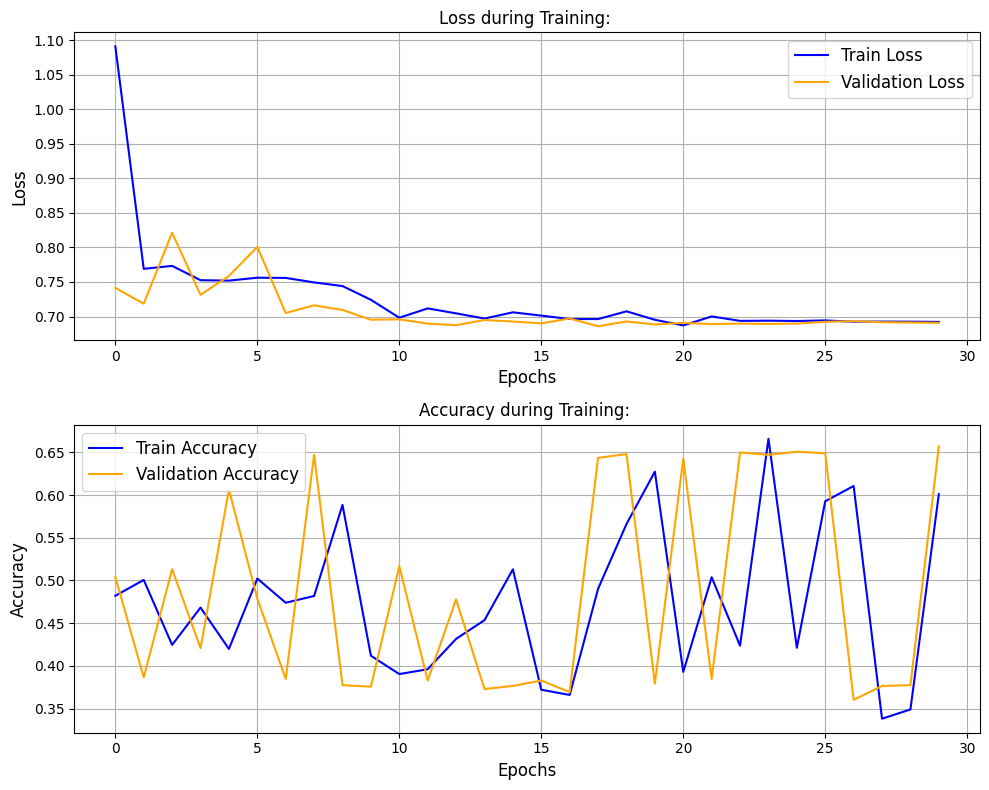

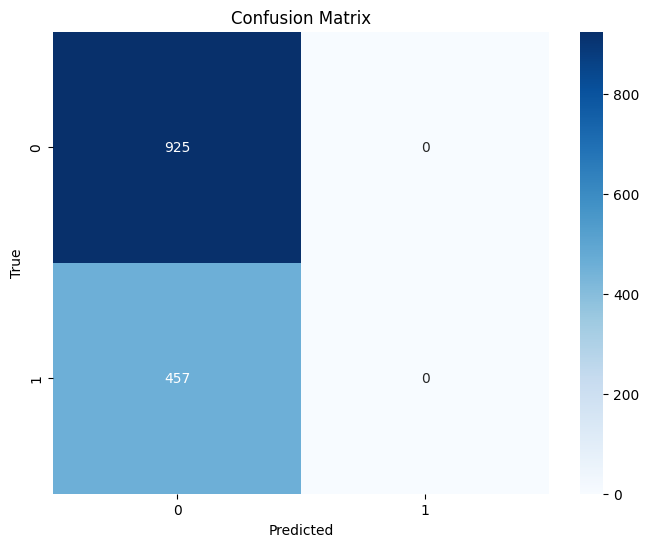

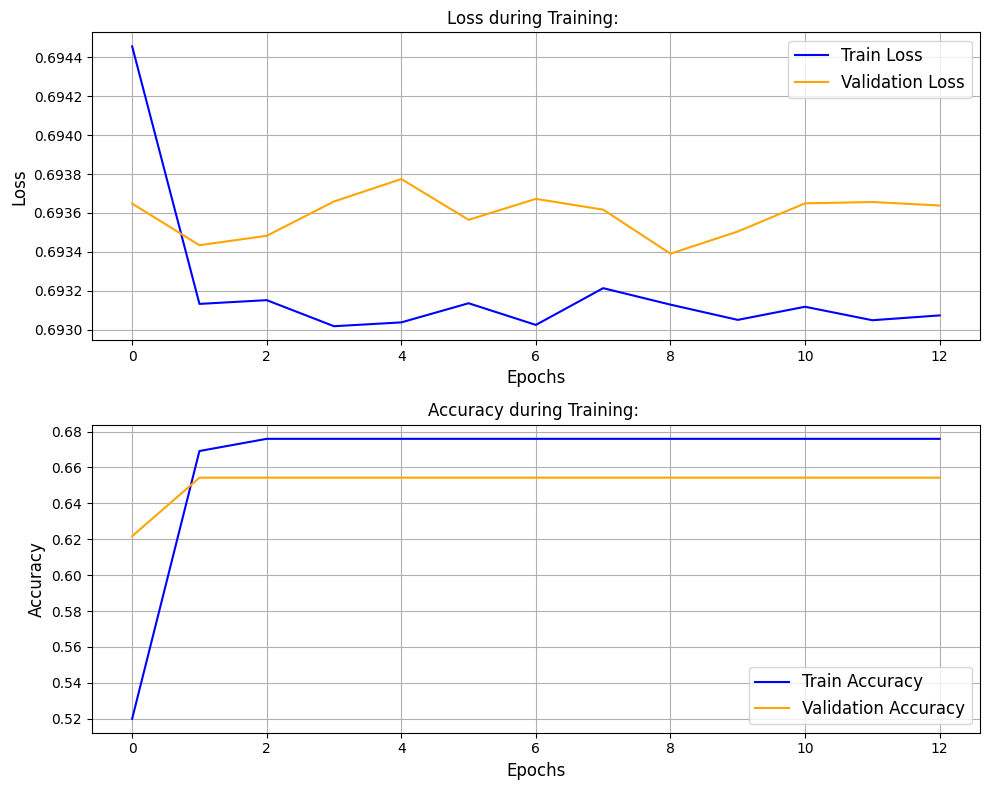

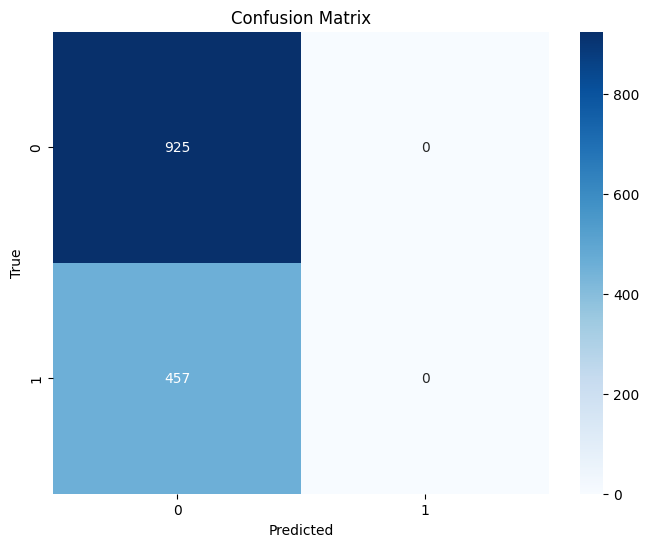

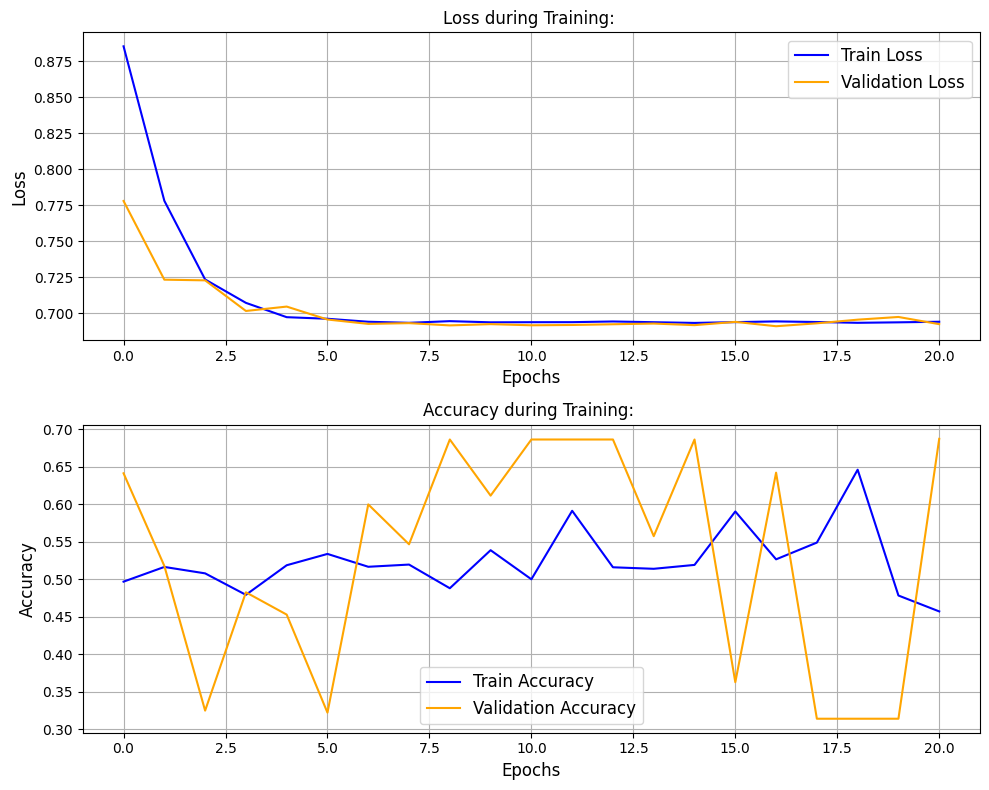

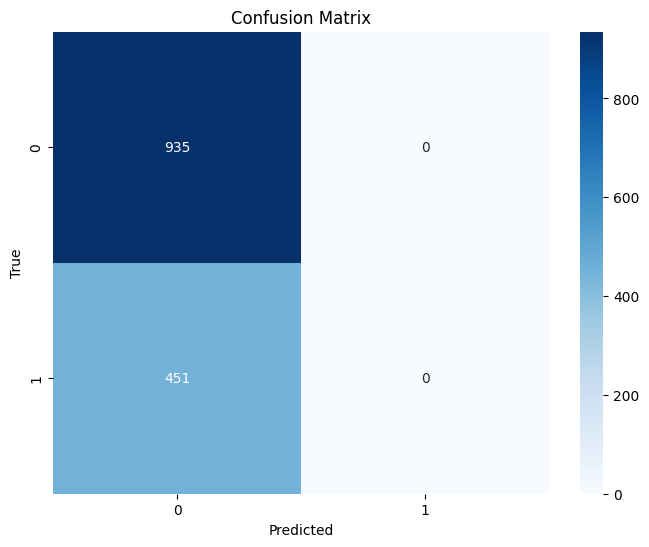

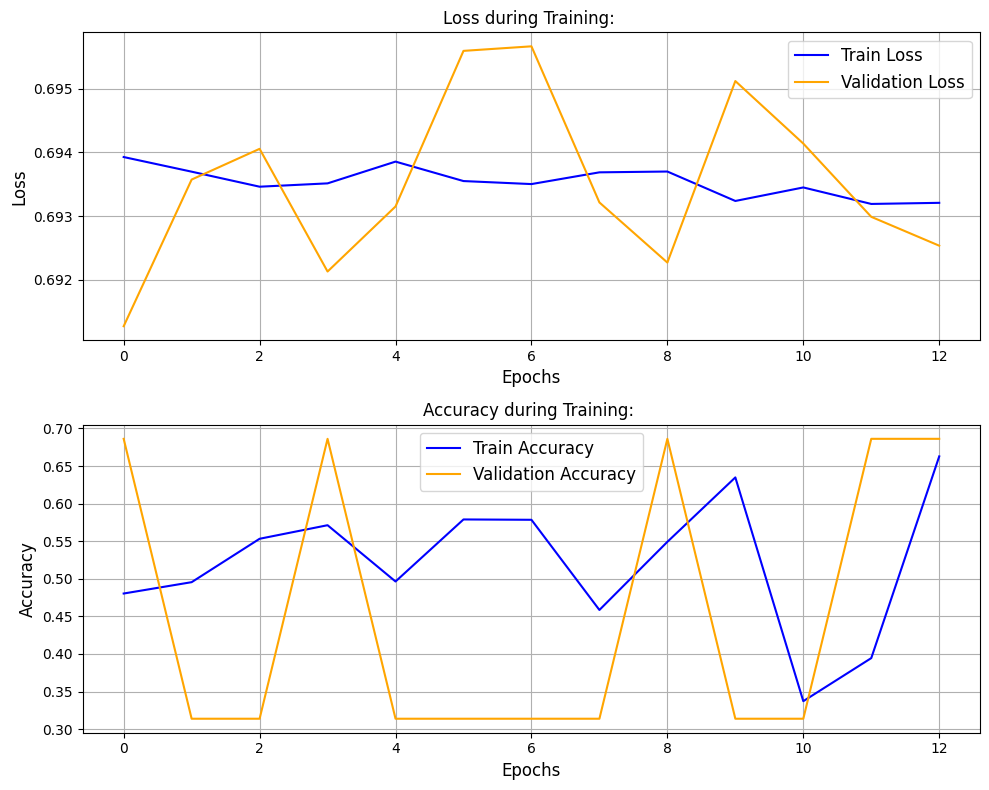

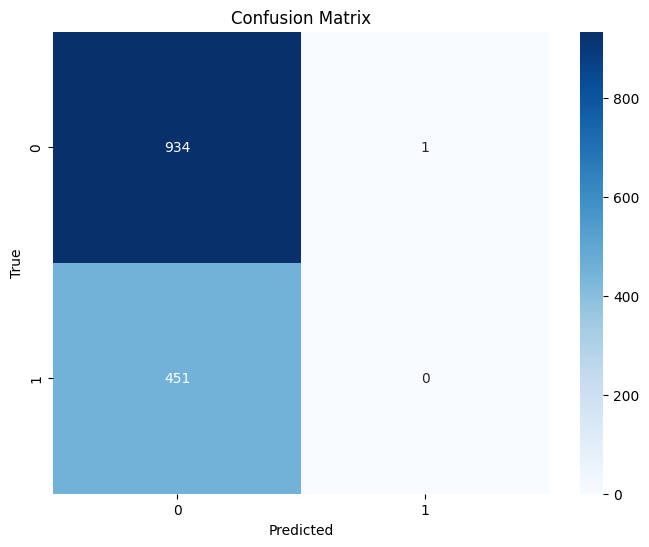

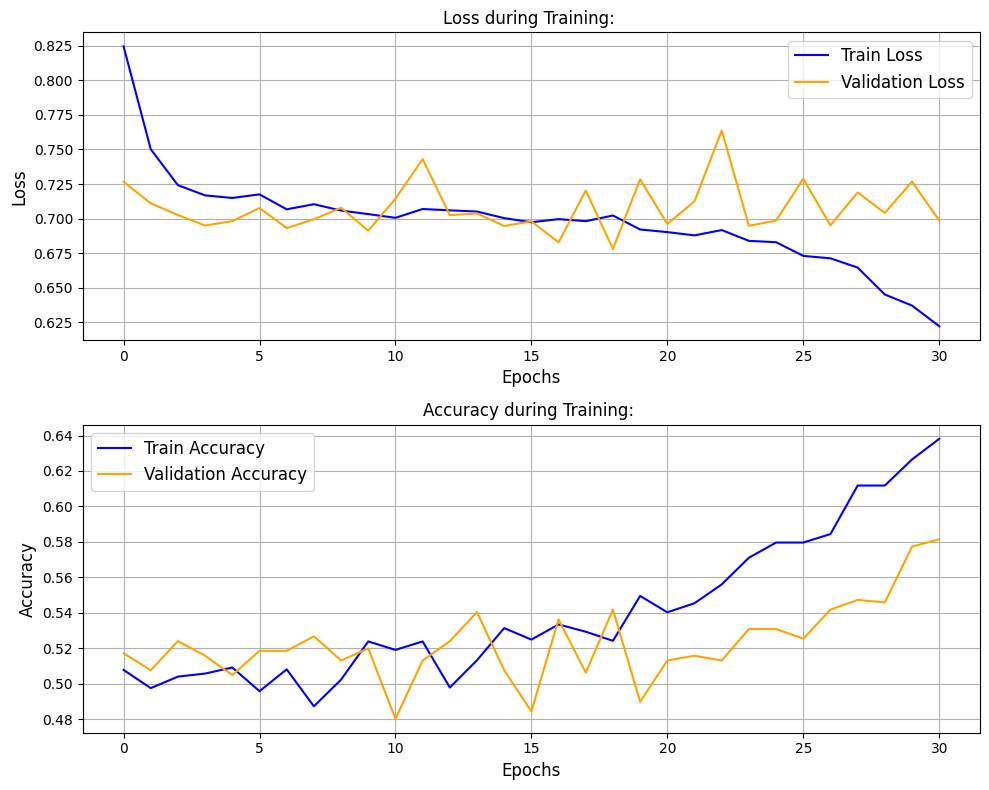

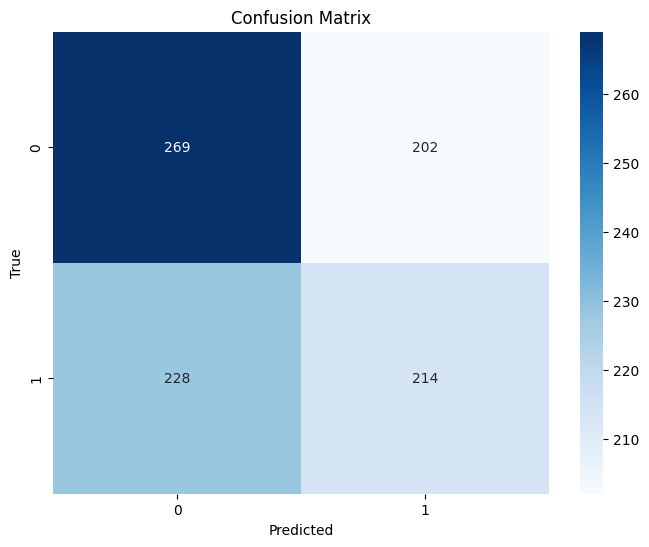

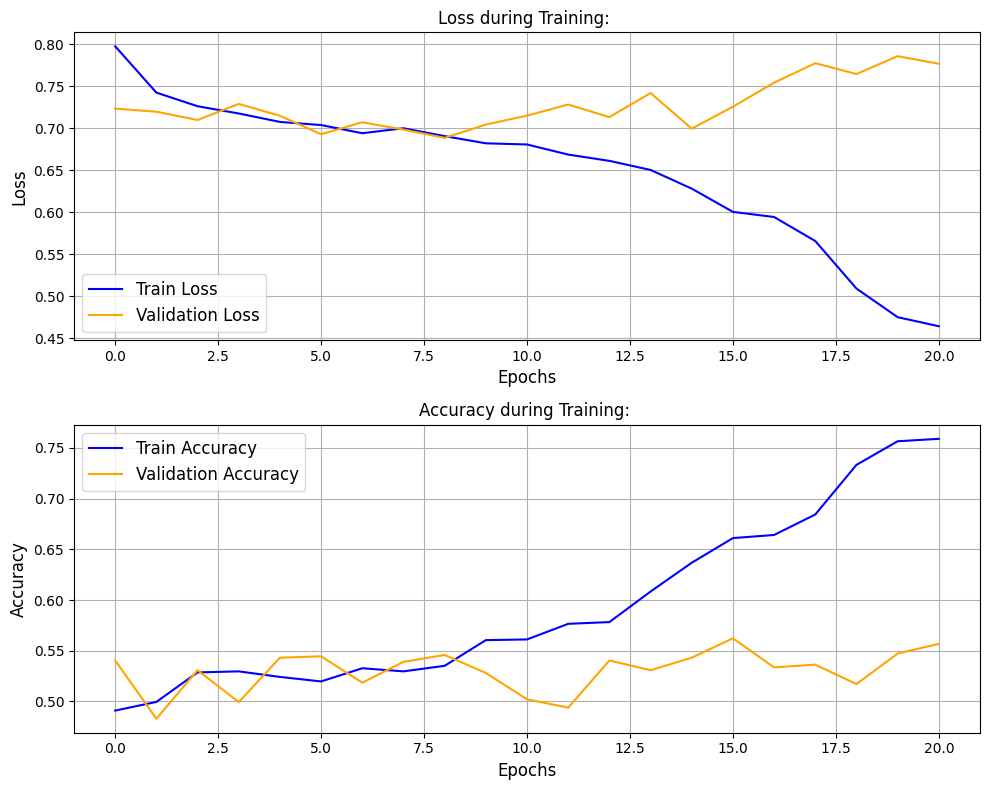

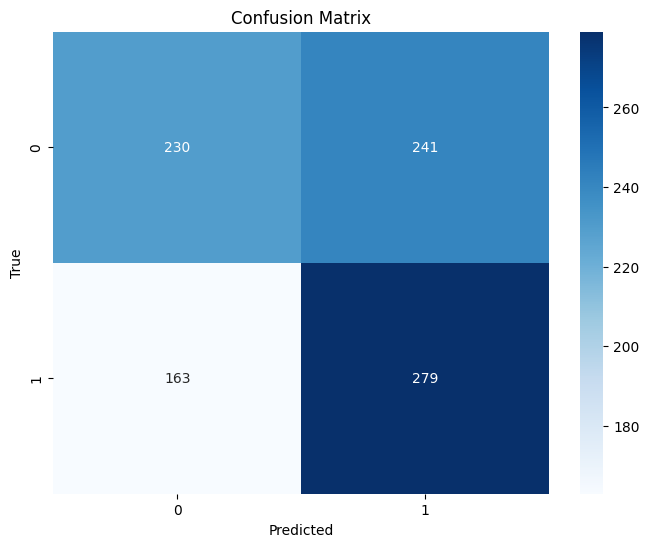

In [119]:
'''                                              *************** CON NUOVE MODIFICHE DEL PAPER ***************
                                                                    
                                                                    NEW VERSION CON
                                                            
                                                                   load_best_run_results


Cosa cambia rispetto a prima

1) load_config_if_available:

    estrae la config (batch_size, lr, β₁, β₂, ε, ecc.)
    carica i best_weights salvati in .pkl da W&B

2) processed_datasets / processed_models

    evitano duplicate runs

3) Optimizer & Scheduler & EarlyStopping

    sono configurati con i valori estratti da config
    scheduler con patience=4 (dimezza lr dopo 4 epoche senza miglioramento di val_loss)
    early‐stopping con patience=12 sul val_loss

4) Training/testing

    la tua funzione training(...) dovrebbe accettare ora anche scheduler e early_stopping

5) GradCAM

    calcolato e salvato solo per il tuo CNN2D+LSTM

Con queste modifiche, il tuo loop:

    rispetta fedelmente il setup del paper
    mantiene la pipeline di W&B per la logica di sweep e salvataggio dei migliori modelli
    aggiunge minimi cambiamenti, lasciando intatte le tue funzioni training(), testing() e save_performance_results()

'''


# Imposta il seme per la riproducibilità

#Imposta il seme per i generatori casuali di PyTorch (per operazioni sui tensori e inizializzazione dei pesi dei modelli).
#Importante se vuoi garantire che l'addestramento del modello produca gli stessi risultati in diverse esecuzioni.
torch.manual_seed(32)

#Imposta il seme per NumPy, utile se NumPy viene usato per operazioni casuali (ad es. shuffling dei dati, inizializzazione di matrici, ecc.).
#Importante se usi NumPy per il preprocessing dei dati e vuoi riproducibilità.

np.random.seed(32)

#mposta il seme per il modulo random di Python (utile se si usano funzioni di randomizzazione di Python puro).
#Importante solo se usi random per operazioni come mescolamento di liste.
random.seed(32)

#Imposta il seme per i generatori casuali su GPU, se disponibile.
#Utile se stai eseguendo il codice su una GPU per garantire riproducibilità anche in quel contesto.

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(32)

       
'''

In questo caso, 

il set processed_datasets traccia i dataset già elaborati, 
e il set processed_models tiene traccia delle combinazioni già effettuate (modello + dataset). 

In questo modo, puoi escludere un dataset dal training se è già stato utilizzato in precedenza, 
anche se usato con un modello differente.
'''

# Dizionario per tracciare la standardizzazione usata per ogni combinazione d
# Dizionario per salvare informazioni sul modello (es. se i dati sono standardizzati)
models_info = {}


# Set per tenere traccia dei dataset già elaborati
processed_datasets = set()

# Set per tenere traccia delle combinazioni già elaborate
processed_models = set()


# Path delle performance dei modelli ottimizzati con weight and biases
# Path per trovare le best performances di ogni modello per ogni combinazione dei dati
base_folder = "/home/stefano/Interrogait/WB_spectrograms_best_results_channels_frequencies_params_motor_task_4_new_3d_grid_multiband"
                                        #WB_spectrograms_best_results_motor_task_1

# Path di salvataggio delle performance dei modelli dopo estrazione best models da base_folder
#save_path_folder = "/home/stefano/Interrogait/spectrograms_best_models_post_WB"


save_path_folder = "/home/stefano/Interrogait/spectrograms_best_models_channels_frequencies_params_post_WB_GradCAM_Checks_motor_task_4_new_3d_grid_multiband"
                    
                                              #spectrograms_best_models_post_WB_GradCAM_Checks_motor_task_1_new
                                    #spectrograms_best_models_channels_frequencies_params_post_WB_GradCAM_Checks_motor_task_1_new


# --- LOOP PRINCIPALE (con minime modifiche) ---
for key, (X_data, y_data) in data_dict.items():
    
    print(f"\n\nEstrazione Dati per il dataset: \033[1m{key}\033[0m, \tShape X: \033[1m{X_data.shape}\033[0m, Shape y: \033[1m{y_data.shape}\033[0m")
    
    if key in processed_datasets:
        print(f"ATTENZIONE: Il dataset {key} è già stato elaborato! Salto iterazione...")
        continue
        
    processed_datasets.add(key)
    
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(X_data, y_data)
    print(f"Dataset Splitting: Train: \033[1m{X_train.shape}\033[0m, Val: \033[1m{X_val.shape}\033[0m, Test: \033[1m{X_test.shape}\033[0m")
    
    
    '''
    CREO COPIA TEST_LOADER_RAW PER I PLOT DEL POWER RAW PER BANDA E CLASSE
    '''
    # 1) salva una copia RAW dei soli dati di test PRIMA di standardizzare
    X_test_raw = X_test.copy()
    y_test_raw = y_test.copy()
    
    # 2) tensori
    X_raw_tensor = torch.tensor(X_test_raw, dtype=torch.float32)
    y_raw_tensor = torch.tensor(y_test_raw, dtype=torch.long)
    
    
    #for model_name in ["CNN2D", "BiLSTM", "Transformer"]:
    
    '''ATTENZIONE MODIFICA QUI'''
    
    #for model_name in ["CNN2D_LSTM_TF", "BiLSTM", "Transformer"]:
    for model_name in ["CNN3D_LSTM_FC", "SeparableCNN2D_LSTM_FC"]:
        
        #Set the seed before any stochastic step of the pipeline
        set_seed(32)

        model_key = f"{model_name}_{key}"
        if model_key in processed_models:
            print(f"ATTENZIONE: Il modello {model_name} per il dataset {key} è già stato addestrato! Salto iterazione...")
            continue
        processed_models.add(model_key)
        
        print(f"\nPreparazione dati per il dataset \033[1m{key}\033[0m e il modello \033[1m{model_name}\033[0m...")
        
        # Prova a caricare la configurazione e i pesi ottimali dal file .pkl
        
        '''
        load_config_if_available --> prende in input 'key' che è la chiave composita (i.e, th_resp_vs_pt_resp_1_20_familiar_th)
        parse_combination_key --> prende in input 'key' che suddivide la chiave composita in stringhe separate
        
        exp_cond, data_type, category_subject che sfrutto per crearmi la directory path che mi servirà per caricarmi 
        pesi del modello e i suoi iper-parametri
        
        Diciamo che in questo caso, sfrutto 'parse_combination_key per qualcosa che serve a 'load_config_if_available' in modo IMPLICITO..
        '''
        
        config, best_weights = load_config_if_available(key, model_name, base_folder)
        
        if config is None:
            raise ValueError(f"\033[1mNessun file .pkl trovato per {model_name} su {key}\033[0m. Non posso procedere senza la configurazione ottimale.")
        
        '''
        Successivamente, queste variabili vengono invece create in maniera ESPLICITA per fasi successive del loop
        MA in questo caso, parsifica la chiave una VOLTA SOLA e memorizza i valori!
        '''
        
        # Parsifica la chiave una volta sola e memorizza i valori
        exp_cond, data_type, category_subject = parse_combination_key(key)
        
        '''
        Dpodiché, 
        
        1) si carica i vari valori degli iper-parametri,
        2) si esegue la standardizzazione se servisse,
        3) prepara il modello per la divisione in train_loader etc.,
        4) si carica la configurazione dei pesi del modello, 
        5) assegna i vari valori degli iper-parametri del modello corrente per la combinazione di dati correntemente iterata 
        
        6) esegue il training e il test e poi
        
        7) si salva il tutto nella path corrispondente...
        
        '''
        
        '''
        PER DARE UNIFORMITÀ AL CODICE, CAMBIO IL NOME DELLE VARIABILI, CHE CONTENGONO I VALORI OTTIMIZZATI 
        DA FORNIRE IN INPUT ALLE VARIE FUNZIONI CHE SONO RICHIAMATE NEL LOOP'''
        
        
        #"lr": {"values": [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]},
        #"weight_decay": {"values": [0, 1e-4, 1e-3, 1e-2, 1e-1]},
        #"n_epochs": {"value": 100},
        #"patience": {"value": 12},
        
        #"model_name": {"values": ["SeparableCNN2D_LSTM_FC"]},
        #"batch_size": {"values": [32, 48, 64, 96]},
        #"standardization": {"values": [True, False]},
        #"beta1": {"values": [0.9, 0.95]},
        #"beta2": {"values": [0.99, 0.995]},
        #"eps": {"values": [1e-8, 1e-7]},
        
        #"use_lstm": {"values": [True, False]},
        #"lstm_hidden": {"values": [32]},
        #"dropout": {"values": [0.5]},
        
        
        model_lr = config["lr"]
        model_weight_decay = config["weight_decay"]
        model_n_epochs = config["n_epochs"]
        model_patience = config["patience"]
        
        
        model_batch_size = config["batch_size"]
        model_standardization = config["standardization"]
    
        
        '''NUOVE MODIFICHE'''
        model_beta1 =  config["beta1"]
        model_beta2 =  config["beta2"]
        model_eps = config["eps"]
        

        '''Per CNN3D_LSTM_FC e SeparableCNN2D_LSTM_FC'''
        model_use_lstm      = config["use_lstm"]
        model_lstm_hidden   = config["lstm_hidden"]
        model_dropout       = config["dropout"]
    
            
        #print(f"Parametri per \033[1m{model_name}\033[0m: batch_size= \033[1m{model_batch_size}\033[0m, n_epochs= \033[1m{model_n_epochs}\033[0m, patience= \033[1m{model_patience}\033[0m, lr= \033[1m{model_lr}\033[0m, weight_decay= \033[1m{model_weight_decay}\033[0m, standardization= \033[1m{model_standardization}\033[0m")
        print(f"Parametri per \033[1m{model_name}\033[0m: batch_size= \033[1m{model_batch_size}\033[0m, n_epochs= \033[1m{model_n_epochs}\033[0m, patience= \033[1m{model_patience}\033[0m, lr= \033[1m{model_lr}\033[0m, model_beta1= \033[1m{model_beta1}\033[0m,  model_beta2= \033[1m{model_beta2}\033[0m,  model_eps= \033[1m{model_eps}\033[0m, standardization= \033[1m{model_standardization}\033[0m")
        
        # Salva nel dizionario se per quella combinazione è stata applicata la standardizzazione ai dati
        models_info[model_key] = {"standardization": model_standardization}
        
        
        
        # 3) dataset & loader per test set (per plots power raw) –‑  IMPORTANTISSIMO: shuffle=False
        raw_dataset = TensorDataset(X_raw_tensor, y_raw_tensor)
        test_loader_raw = DataLoader(raw_dataset,
                             batch_size=model_batch_size,
                             shuffle=False)
        
        '''PER MANTENERE LA STESSA LOGICA DEL CODICE (ANCHE SE POTREI INSERIRLA DENTRO PREPARE_DATA_FOR_MODEL MODIFICANDO LA FUNZIONE (SI VEDA IN CELLA SOPRA COME)
        IMPONGONO LA STANDARDIZZAZIONE PRIMA DI QUESTA FUNZIONE
        '''

        if model_standardization:
            X_train, X_val, X_test = standardize_data(X_train, X_val, X_test)
            print(f"\033[1mSÌ Standardizzazione Dati!\033[0m")
        else:
            print(f"\033[1mNO Standardizzazione Dati!\033[0m")
        
        # Sposta il modello sulla GPU (se disponibile)
        device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

        
        # Preparazione dei dataloaders
        train_loader, val_loader, test_loader, class_weights_tensor = prepare_data_for_model(
            X_train, X_val, X_test, y_train, y_val, y_test, model_type = model_name, batch_size = model_batch_size)
        

        # Inizializzazione del modello
        #if model_name == "CNN2D":
        #    model = CNN2D(input_channels=64, num_classes=2)
        
        #if model_name == "CNN2D_LSTM_FC":
            
            #model = CNN2D_LSTM_FC(n_freq = 45, input_channels=64, num_classes=2, dropout = 0.2)
            #model = CNN2D_LSTM_FC(input_channels = 5, num_classes=2, dropout=0.2)
            
        #elif model_name == "BiLSTM":
        #    model = ReadMEndYou(input_size= 64 * 81, hidden_sizes=[24, 48, 62], output_size=2, bidirectional=True)
        #elif model_name == "Transformer":
        #    model = ReadMYMind(d_model=16, num_heads=4, num_layers=2, num_classes=2, channels=64, freqs=81)
        
        #elif model_name == "TopomapNet":
            #model = TopomapNet(
                #input_channels=5,
                #num_classes=2,
                #base_channels=model_base_channels,
                #use_lstm=model_use_lstm,
                #lstm_hidden=model_lstm_hidden,
                #dropout=model_dropout
            #)
        
        '''OCCHIO QUI CAMBIATO PER GRIGLIA 3D'''
        if model_name == "CNN3D_LSTM_FC":
            
            sweep_config = sweep_config_cnn3d
            
            model = CNN3D_LSTM_FC(
                num_classes=2,
                dropout=model_dropout,
                hidden_size=model_lstm_hidden,
                use_lstm=model_use_lstm)

            print(f"\nInizializzazione Modello \033[1mCNN3D_LSTM_FC\033[0m")
        
        elif model_name == "SeparableCNN2D_LSTM_FC":
            
            sweep_config = sweep_config_cnn_sep
            
            model = SeparableCNN2D_LSTM_FC(
                num_classes=2,
                dropout=model_dropout,
                hidden_size=model_lstm_hidden,
                use_lstm=model_use_lstm
            )
            print(f"\nInizializzazione Modello \033[1mSeparableCNN2D_LSTM_FC\033[0m")
            
        else:
            raise ValueError(f"Modello {model_name} non riconosciuto.")
        
        
        # Se abbiamo caricato i pesi ottimali, li carichiamo nel modello
        if best_weights is not None:
            try:
                model.load_state_dict(best_weights)
                print(f"📊 Modello \033[1m{model_name}\033[0m inizializzato con \033[01i pesi ottimizzati\033[0m tramite hyper-parameter tuning su \033[1mWeight & Biases\033[0m")
            except Exception as e:
                print(f"⚠️Errore nel caricamento dei pesi per {model_name} su {key}: {e}")
                continue
        
        '''OLD VERSION'''
        # Definizione del criterio di perdita
        #criterion = nn.CrossEntropyLoss(weight = class_weights_tensor)
        
        '''NUOVE MODIFICHE'''
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
        
        '''OLD VERSION'''
        # Definizione dell'ottimizzatore con i parametri aggiornati
        #optimizer = torch.optim.Adam(model.parameters(), lr = model_lr, weight_decay = model_weight_decay)
        
        '''NUOVE MODIFICHE'''
        
         # 10) ottimizzatore + scheduler + early stopping
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr    = model_lr,
            betas = (model_beta1, model_beta2),
            eps   = model_eps, 
            weight_decay = model_weight_decay
        )
            
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode     = "min",   # monitoriamo val_loss
            factor   = 0.1,
            patience = 8,
            verbose  = True
        )
        
        
        #early_stopping = EarlyStopping(patience=model_patience, mode="min")
        
        '''OLD VERSION'''
        #print(f"🏋️‍♂️Avvio del training per \033[1m{model_name}\033[0m sul dataset \033[1m{key}\033[0m...")
        #my_train_results = training(model, train_loader, val_loader, optimizer, criterion, n_epochs = model_n_epochs, patience = model_patience)
        
        '''NEW VERSION'''
        # --- dopo model.load_state_dict(best_weights) e criterion = nn.CrossEntropyLoss() ---

        # 1) prepara i data_loaders per train/val
        data_loaders = {
            "train": train_loader,
            "val":   val_loader
        }
        
        print(f"🏋️‍♂️Salvo le metriche del training per \033[1m{model_name}\033[0m sul dataset \033[1m{key}\033[0m a seguito della ottimizzazione su W&B ...")
        # 2) richiama la funzione che pesca da W&B la best‐run e corregge la train AUC
        
        #ATTENZIONE al potenziale problema di stringa, non di API: 

        #i due esempi che hai postato in realtà usano diversi caratteri “‑” (uno è il classico ASCII U+002D, l’altro è un non‑breaking hyphen U+2011 o simili), quindi quando chiami
        
        #entity = "stefano‑bargione‑universit‑di‑roma‑tor‑vergata"
        #stai passando un nome che W&B non riconosce (e quindi api.projects(entity=…) torna vuoto), mentre con

        #entity = "stefano-bargione-universit-di-roma-tor-vergata"
        #funziona perché lì usi i semplici - ASCII.

        my_train_results = load_best_run_results(
            key=key,
            model = model,
            sweep_config = sweep_config,
            data_loaders = data_loaders,
            entity = "stefano-bargione-universit-di-roma-tor-vergata"
        )
        
        
        
        '''
        L’entity che passi a Api().runs(f"{entity}/{project}") è semplicemente il tuo account (o l’organizzazione) su W&B,
        cioè la parte che compare subito prima del nome del progetto nell’URL.

        Per esempio, se quando apri il tuo progetto su W&B vedi un indirizzo del tipo
        
        -> https://wandb.ai/steclab/some_project_name, allora entity = "steclab".
        
        Se invece lavori sotto un’organizzazione 
        
        -> “cool‑team”, e l’URL è https://wandb.ai/cool-team/some_project_name, allora userai entity = "cool-team".

        Puoi verificarlo:

        Accedi a wandb.ai e vai sul progetto.
        Leggi la prima parte dell’URL (tra wandb.ai/ e il /project_name).
        Copiala esattamente come stringa in entity.

        Così il tuo Api().runs(f"{entity}/{project}") andrà a pescare proprio le run che hai lanciato tu.

        my_train_results = load_best_run_results(
            key= key,
            model = model,
            sweep_config = sweep_config,
            data_loaders = data_loaders,
            entity= "mio-entity"
        )
        
        '''
        
        print(f"Avvio del testing per \033[1m{model_name}\033[0m sul dataset \033[1m{key}\033[0m...")
        # 3) usa il best_model caricato dentro `train_results` e chiama il testing
        my_test_results = testing(my_train_results, test_loader, criterion)
        
        '''
        GRADCAM COMPUTATION PER IL MODELLO CNN3D e ConvSep
        
        La funzione compute_gradcam_figure estrae i campioni (per ogni classe) e crea una figura con le due righe richieste.
        
        Il parametro gradcam_image (un buffer binario o un'immagine) viene passato alla funzione di salvataggio, 
        'save_performance_results', in modo da essere salvato nella path corretta. 
        
        La funzione 'save_performance_results' è stata modificata 
        per gestire ANCHE questo nuovo input dell'immagine 
        
        (ossia, per salvare il file con un nome che inizia con 'GradCAM_results_'
        seguito da tutte le altre stringhe corrispondenti alla combinazione di fattori che costituiscono il dataset corrente:
        
        - coppia di condizioni sperimentali da cui provengono i dati (i.e., th_resp_vs_pt_resp )
        - tipologia di dato EEG prelevato (i.e., spectrograms) 
        - provenienza del dato stesso (i.e., familiar_th)
        )
        
        Spiegazione:
        
        La funzione compute_gradcam_figure eseguire il calcolo di GradCAM (vedi dettagli nella sua funzione)
        e alla fine ritornerà in output una variabile 
        
        'fig_image' che sarà poi assegnata alla variabile 'gradcam_image',
        che è un oggetto buffer, che contiene i dati binari dell'immagine in formato PNG
        (poiché abbiamo usato plt.savefig con format='png'). 
        
        Quindi, quando passi gradcam_image (cioè fig_image) alla funzione 'save_performance_results',
        viene scritto direttamente su disco come file PNG.
        
        Non c'è bisogno di ri-aprire o convertire ulteriormente, a meno che tu non voglia manipolare l'immagine in seguito.
        Quindi, la soluzione è corretta così com'è:
        il buffer viene salvato come file PNG nella directory specificata, 
        e successivamente potrai aprirlo con una libreria come cv2 o PIL se necessario.        
        
        Quindi, gradcam_image (i.e., fig_image) viene quindi passato correttamente dentro al loop di training e test, 
        tramite 'save_performance_results', come input, 
        che salverà quindi poi l'immagine nella path corrispondente 

        '''
        
        # Se il modello è CNN2D, calcola anche GradCAM per la visualizzazione
        gradcam_image = None
        
        #if model_name == "CNN2D":
        
        '''ATTENZIONE MODIFICA QUI'''
        
        #if model_name == "CNN2D_LSTM_FC":
        
        if model_name in ("CNN3D_LSTM_FC", "SeparableCNN2D_LSTM_FC"):
            
            gradcam_image = compute_gradcam_figure(model, test_loader, test_loader_raw, exp_cond, data_type, category_subject, device, EEG_channels_names, debug = False)
            if gradcam_image is not None:
                print(f"Creazione di \033[1mGradCAM Image\033[0m per il modello \033[1m{model_name}\033[0m.")
                
        print(f"Salvataggio dei risultati per \033[1m{model_name}\033[0m sul dataset \033[1m{key}\033[0m...")
        save_performance_results(model_name,
                                 my_train_results,
                                 my_test_results,
                                 key,
                                 exp_cond,
                                 model_standardization,
                                 base_folder = save_path_folder,
                                 gradcam_image = gradcam_image)
        
        
        '''
        N.B
        
        gradcam_image = None avverrà solo all'inizio cioè per il primo modello, che verrà testato con una certa combinazione di dati.. 
        ma servirebbe tracciare in qualche modo 

        1) o che la gradcam_image di ogni combinazione venga ri-azzerata alla fine loop
        2) o che venga monitorato che gradcam_image di una combinazione di dati già analizzata venga esclusa poi
        (o messa in un set) in modo che rivenga per errore sovrascritta più volte.. 
        
        Forse la strada più veloce potrebbe essere la soluzione 1)
        
        La soluzione più veloce e semplice è re-impostare la variabile gradcam_image a None alla fine dell'iterazione per ogni combinazione di dati
        (cioè, all'interno del ciclo esterno che itera su key). 
         
        In questo modo, per ogni nuovo dataset la variabile viene "azzera" e viene calcolata l'immagine GradCAM solo per quella combinazione, 
        evitando di sovrascrivere accidentalmente i risultati già calcolati per combinazioni precedenti.
         
        Un'altra possibilità sarebbe tenere traccia delle chiavi (o combinazioni) per cui hai già calcolato la GradCAM,
        ad esempio usando un set, e saltare il calcolo se la combinazione è già presente. 
        
        Tuttavia, se ogni combinazione deve avere la sua immagine, 
        la soluzione più semplice è quella di reimpostare gradcam_image = None alla fine dell'iterazione.
        
        Quindi, per esempio, alla fine del ciclo per ogni dataset (key) potresti fare:
        (VEDI SOTTO)
        
        In questo modo, ti assicuri che per ogni nuova combinazione la variabile sia pulita e pronta per essere ricalcolata, 
        senza rischio di sovrascrivere o confondere i risultati
        '''
        
        # Reimposta gradcam_image a None per la prossima combinazione di dati
        gradcam_image = None
    

In [ ]:
#axs[0, j].hist(mean_cams_per_band[cls][b].flatten(), bins='auto', color='blue', edgecolor='black')
            #axs[0, j].set_title(f"\nClass {condition_names[cls]} - Band {b_name}", fontsize=9)
            #axs[0, j].set_xlabel("Grad-CAM value")
            #axs[0, j].set_ylabel("Count")
    

In [120]:
print("finito")

finito


In [121]:
print(models_info.keys())

dict_keys(['CNN3D_LSTM_FC_rest_vs_both_feet_spectrograms_familiar_th', 'SeparableCNN2D_LSTM_FC_rest_vs_both_feet_spectrograms_familiar_th', 'CNN3D_LSTM_FC_rest_vs_both_fists_spectrograms_familiar_th', 'SeparableCNN2D_LSTM_FC_rest_vs_both_fists_spectrograms_familiar_th', 'CNN3D_LSTM_FC_both_feet_vs_both_fists_spectrograms_familiar_th', 'SeparableCNN2D_LSTM_FC_both_feet_vs_both_fists_spectrograms_familiar_th'])


In [122]:
with open('/home/stefano/Interrogait/spectrograms_best_models_channels_freqs_params_post_WB_GradCAM_Checks_motor_task_4_new_3d_grid_multiband.pkl', 'wb') as f:
    pickle.dump(models_info, f)

#### **CREAZIONE DELLE TABLES CON INTEGRAZIONE DELLE PERFORMANCE TRAINING & TEST DEI MODELLI DENTRO DATAFRAME**

#### **Integrazioni in Tabella delle Performance Training e Test del Modello dentro DataFrame - NEW APPROACH**

In [150]:
import pickle 
path = '/home/stefano/Interrogait/'

#with open(f"{path}spectrograms_best_models_post_WB_GradCAM_Checks_motor_task_1_new.pkl", "rb") as f: 
with open(f"{path}spectrograms_best_models_channels_freqs_params_post_WB_GradCAM_Checks_motor_task_4_new_3d_grid_multiband.pkl", "rb") as f:
    models_info = pickle.load(f)

In [151]:
'''
In questo codice:

model_info.get('standardization', False) cerca la chiave 'standardization' all'interno di ogni sottodizionario. 
Se non esiste, restituirà False come valore di default.
Se standardization è True, stampa la chiave associata.
'''

# Ciclo attraverso le chiavi di 'models_info'
for key, model_info in models_info.items():
    # Controllo se 'standardization' è True
    if model_info.get('standardization', False):  # Default a False nel caso in cui non esista la chiave
        print(key)  # Stampa la chiave

CNN3D_LSTM_FC_rest_vs_both_feet_spectrograms_familiar_th
SeparableCNN2D_LSTM_FC_rest_vs_both_feet_spectrograms_familiar_th
CNN3D_LSTM_FC_rest_vs_both_fists_spectrograms_familiar_th
SeparableCNN2D_LSTM_FC_rest_vs_both_fists_spectrograms_familiar_th
CNN3D_LSTM_FC_both_feet_vs_both_fists_spectrograms_familiar_th
SeparableCNN2D_LSTM_FC_both_feet_vs_both_fists_spectrograms_familiar_th


In [152]:
models_info

{'CNN3D_LSTM_FC_rest_vs_both_feet_spectrograms_familiar_th': {'standardization': True},
 'SeparableCNN2D_LSTM_FC_rest_vs_both_feet_spectrograms_familiar_th': {'standardization': True},
 'CNN3D_LSTM_FC_rest_vs_both_fists_spectrograms_familiar_th': {'standardization': True},
 'SeparableCNN2D_LSTM_FC_rest_vs_both_fists_spectrograms_familiar_th': {'standardization': True},
 'CNN3D_LSTM_FC_both_feet_vs_both_fists_spectrograms_familiar_th': {'standardization': True},
 'SeparableCNN2D_LSTM_FC_both_feet_vs_both_fists_spectrograms_familiar_th': {'standardization': True}}

In [ ]:
#for key, model_info in all_models.items():
#    print(key)

In [153]:
'''
Siccome la stringa associata alla category subject è diversa tra i due.. 

familiar_th  familiar_pt unfamiliar_pt unfamiliar_pt  da un lato (models_info)
th_fam, pt_fam, th_unfam, pt_unfam  dall'altro (all_models)

la corrispondenza non avverrà mai... per cui, si deve fare il mapping corrispondente tra 
le stringhe di uno e dell'altro, in modo che models_info cambi come parte della stringa della sua chiave da queste 

familiar_th  familiar_pt unfamiliar_pt unfamiliar_pt
a queste
th_fam, pt_fam, th_unfam, pt_unfam 

'''

mapping_subject = {
    "familiar_th": "th_fam",
    "familiar_pt": "pt_fam",
    "unfamiliar_th": "th_unfam",
    "unfamiliar_pt": "pt_unfam"
}

# Creiamo un nuovo dizionario con le chiavi corrette
updated_models_info = {}

for key, value in models_info.items():
    for old_suffix, new_suffix in mapping_subject.items():
        if key.endswith(old_suffix):
            new_key = key.replace(old_suffix, new_suffix)
            updated_models_info[new_key] = value
            break  # Evita sostituzioni multiple se una è già stata fatta
    else:
        # Se nessuna sostituzione è stata fatta, mantieni la chiave originale
        updated_models_info[key] = value

# Sostituisci il vecchio dizionario con quello aggiornato
models_info = updated_models_info

In [154]:
models_info.keys()

dict_keys(['CNN3D_LSTM_FC_rest_vs_both_feet_spectrograms_th_fam', 'SeparableCNN2D_LSTM_FC_rest_vs_both_feet_spectrograms_th_fam', 'CNN3D_LSTM_FC_rest_vs_both_fists_spectrograms_th_fam', 'SeparableCNN2D_LSTM_FC_rest_vs_both_fists_spectrograms_th_fam', 'CNN3D_LSTM_FC_both_feet_vs_both_fists_spectrograms_th_fam', 'SeparableCNN2D_LSTM_FC_both_feet_vs_both_fists_spectrograms_th_fam'])

In [155]:
''' Ciclo attraverso le chiavi di 'models_info' AGGIORNATO!'''

for key, model_info in models_info.items():
    # Controllo se 'standardization' è True
    if model_info.get('standardization', False):  # Default a False nel caso in cui non esista la chiave
        print(key)  # Stampa la chiavi

CNN3D_LSTM_FC_rest_vs_both_feet_spectrograms_th_fam
SeparableCNN2D_LSTM_FC_rest_vs_both_feet_spectrograms_th_fam
CNN3D_LSTM_FC_rest_vs_both_fists_spectrograms_th_fam
SeparableCNN2D_LSTM_FC_rest_vs_both_fists_spectrograms_th_fam
CNN3D_LSTM_FC_both_feet_vs_both_fists_spectrograms_th_fam
SeparableCNN2D_LSTM_FC_both_feet_vs_both_fists_spectrograms_th_fam


In [156]:
'''
Parsing della chiave e costruzione del path:
Usando la funzione parse_combination_key si estraggono 

exp_cond, data_type e category_subject dalla chiave del dataset. 

Questi vengono usati per costruire il percorso in cui cercare i file .pkl.
'''

# Funzione per parsare la chiave
def parse_combination_models_keys(combination_key):
    """
    Estrae (exp_cond, data_type, category_subject) da combination_key.
    
    Il formato atteso PRIMA è:
    
    "th_resp_vs_pt_resp|pt_resp_vs_shared_resp|th_resp_vs_shared_resp" _ spectrograms" _ "familiar_th|familiar_pt|unfamiliar_th|unfamiliar_pt"
    
    Il formato atteso ORA è:
    
     "th_resp_vs_pt_resp|pt_resp_vs_shared_resp|th_resp_vs_shared_resp" _ spectrograms" _ "th_fam|th_unfam|pt_fam|pt_unfam"
     
    """
    #r"^(th_resp_vs_pt_resp|pt_resp_vs_shared_resp|th_resp_vs_shared_resp)_(spectrograms)_(th_fam|th_unfam|pt_fam|pt_unfam)$", 
    
    match = re.match(
        r"^(rest_vs_both_feet|rest_vs_both_fists|both_feet_vs_both_fists)_(spectrograms)_(th_fam|th_unfam|pt_fam|pt_unfam)$",
        combination_key
    )
    if match:
        return match.groups()  # (exp_cond, data_type, category_subject)
    else:
        raise ValueError(f"Formato non valido: {combination_key}")
        
    return exp_cond, data_type, category_subject

#### Implementazione : Versione dal 24 novembre 2025 

In [158]:
'''

Guarda ti faccio vedere: con la tua proposta qui che mi hai detto viene bene secondo me, 
ma mi sembra un po' troppo "larga" da inserire come tabella per la tesi... 

non so se allora convenga invece fare come ad esempio avevi cercato di fare per questa altra tabella (seconda immagine),

e l'idea potrebbe essere quella di avere tutto a sinistra, le metriche uno sotto l'altra,
dopodiché mettere un header per "train", 
sotto al quale metti uno accanto all'altro i tre modelli (CNN2D_LSTM, BiLSTM e Trasformer) 
e ci metti il valore di ad esempio accuracy per il train di quei modelli; 

nell'header successivo, mettere invece "validation" e sotto al quale metti uno accanto all'altro i tre modelli (CNN2D_LSTM, BiLSTM e Trasformer)
e ci metti il valore di ad esempio accuracy per il validation di quei modelli; 

nell'header successivo, mettere invece "test" e sotto al quale metti uno accanto all'altro i tre modelli (CNN2D_LSTM, BiLSTM e Trasformer)
e ci metti il valore di ad esempio accuracy per il test di quei modelli; 

E così anche per le altre metriche, in modo che: 

Tutto a sinistra, hai le metriche, poi hai gli "header" suddivisi per fold (train, val, test),
e sotto il nome del modello e a partire dalla stessa riga da cui parte la prima metrica, metti il valore del modello in questione, 
per quella metrica, a quel fold.. non so se mi son spiegato..


Capito perfettamente cosa vuoi:

Metriche in riga (Accuracy, Loss, Precision, …)

Blocchi di colonne per Train / Val / Test

Sotto ogni blocco, le colonne dei modelli (CNN2D_LSTM, BiLSTM, Transformer).

Quindi una tabella tipo:

| Metric | Train – CNN2D | Train – BiLSTM | Train – Transf | Val – CNN2D | … | Test – Transf |

Compatta, pochi colonne (1 + 3×3 = 10) e ottima da mettere in tesi.

Ti lascio il codice completo, già sistemato per:

usare tutte le metriche (Accuracy, Loss, Precision, Recall, F1-Score, AUC-ROC)

ordinare le righe dei modelli come: CNN2D_LSTM, BiLSTM, Transformer

generare una tabella compatta con matplotlib.table e salvare la figura pronta da inserire in tesi.




Ora il titolo della tabella (o forse, la tabella in realtà) è troppo messa vicina al 'titolo' della figura.
forse, il titolo va bene che sia così grande, ma invece il nome dei modelli deve esser più piccolo per entrare nella corrispondente cella ecco.. 
ci riusciamo?



Sì sì, ci riusciamo 😊
Il problema è doppio:

Il titolo della figura è troppo vicino alla tabella → serve più margine in alto.

I nomi dei modelli nell’header sono troppo grandi → basta ridurre font e altezza delle celle dell’header.

Ti lascio il pezzo di codice da sostituire al blocco 5) Plot tabella… del codice precedente.


'''



import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import table

import numpy as np


# =========================
# CONFIGURAZIONE GENERALE
# =========================

base_folder = "/home/stefano/Interrogait/spectrograms_best_models_channels_frequencies_params_post_WB_GradCAM_Checks_motor_task_4_new_3d_grid_multiband"

experimental_conditions = [
    "rest_vs_both_fists",
    "rest_vs_both_feet",
    "both_feet_vs_both_fists",
]

data_types = ["spectrograms"]
subfolders = ["th_fam"]

# metriche interne (come compaiono nelle chiavi dei dict)
metrics_order = ["accuracy", "loss", "precision", "recall", "f1_score", "auc"]
metric_display = {
    "accuracy":  "Accuracy",
    "loss":      "Loss",
    "precision": "Precision",
    "recall":    "Recall",
    "f1_score":  "F1-Score",
    "auc":       "AUC-ROC",
}

# split interni e etichette da mostrare
split_internal = ["train", "val", "test"]
split_display  = {"train": "Train", "val": "Validation", "test": "Test"}

# ordine desiderato delle righe (modelli)
desired_model_order = ["CNN3D_LSTM", "SeparableCNN2D_LSTM"]

# se models_info non esistesse in questo notebook, evitiamo crash
if "models_info" not in globals():
    models_info = {}

# =========================
# CARICAMENTO MODELLI
# =========================

all_models = {}

for condition in experimental_conditions:
    for data_type in data_types:
        for subfolder in subfolders:

            path = os.path.join(base_folder, condition, data_type, subfolder)

            if not os.path.exists(path):
                print(f"Directory non trovata: {path}")
                continue

            key = f"{condition}_{data_type}_{subfolder}"
            all_models[key] = {}

            for file in os.listdir(path):
                if file.endswith(".pkl"):
                    file_path = os.path.join(path, file)
                    try:
                        with open(file_path, "rb") as f:
                            all_models[key][file] = pickle.load(f)
                    except Exception as e:
                        print(f"Errore nel caricamento di {file}: {e}")



# =========================
# COSTRUZIONE TABELLE
# =========================

for key, models_dict in all_models.items():

    # es. key = "rest_vs_left_fist_spectrograms_th_fam"
    condition, data_type, subfolder = parse_combination_models_keys(key)
    print(f"\nProcessing: \033[1m{condition}\033[0m - \033[1m{data_type}\033[0m - \033[1m{subfolder}\033[0m\n")

    # -----------------------------
    # 1) raccogliamo i modelli per nome compatto
    # -----------------------------
    models_by_name = {}   # es. {"CNN2D_LSTM": model_data, "BiLSTM": model_data, ...}
    
    #CNN3D_LSTM_FC
    #SeparableCNN2D_LSTM_FC

    for file_name, model_data in models_dict.items():
        
        if file_name.startswith(("CNN3D_LSTM", "SeparableCNN2D_LSTM")):
            parts = file_name.split("_")
            name_model = "_".join(parts[:2])      # es. "CNN2D_LSTM"
        else:
            name_model = file_name.split("_")[0]  # es. "BiLSTM", "Transformer"

        models_by_name[name_model] = model_data

    rows = []
    row_index = []

    # -----------------------------
    # 2) costruiamo df_performances:
    #    righe = modelli, colonne = (Metric, Split)
    # -----------------------------
    for name_model in desired_model_order:
        if name_model not in models_by_name:
            continue  # modello non presente per questa condizione

        model_data = models_by_name[name_model]
        print(f"    Processing model: \033[1m{name_model}\033[0m")

        model_key = f"{name_model}_{key}"
        standardization_flag = models_info.get(model_key, {}).get("standardization", False)
        suffix = ""  # metti "*" se vuoi marcare i modelli standardizzati

        model_label = f"{name_model}{suffix}"

        try:
            train_scores = model_data.get("my_train_results", {}).get("training_performances", {})
            val_scores   = model_data.get("my_train_results", {}).get("validation_performances", {})
            test_scores  = model_data.get("my_test_results", {}).get("test_performances", {})

            # cast a float
            train_scores = {k: float(v[0]) for k, v in train_scores.items()}
            val_scores   = {k: float(v[0]) for k, v in val_scores.items()}
            test_scores  = {k: float(v[0]) for k, v in test_scores.items()}

            scores_by_split = {
                "train": train_scores,
                "val":   val_scores,
                "test":  test_scores,
            }

            # riga per questo modello:
            # [Accuracy-Train, Accuracy-Val, Accuracy-Test, Loss-Train, ... , AUC-Test]
            row_vals = []
            for metric_key in metrics_order:
                for split in split_internal:
                    prefix   = split  # "train", "val", "test"
                    dict_key = f"{prefix}_{metric_key}"   # es. "train_accuracy", "val_f1_score"
                    value = scores_by_split.get(split, {}).get(dict_key, None)
                    row_vals.append(value)

            rows.append(row_vals)
            row_index.append(model_label)

        except Exception as e:
            print(f"    Errore nell'elaborazione di {name_model}: {e}")
            continue

    if not rows:
        print("    Nessun modello valido per la tabella, salto.")
        continue

    # colonne multiindice: (Metric, Split) — solo per costruzione interna
    top_level = []
    sub_level = []

    for metric_key in metrics_order:
        mname = metric_display[metric_key]
        for split in split_internal:
            top_level.append(mname)                   # "Accuracy", "Loss", ...
            sub_level.append(split_display[split])    # "Train", "Validation", "Test"

    columns = pd.MultiIndex.from_arrays([top_level, sub_level],
                                        names=["Metric", "Split"])

    df_performances = pd.DataFrame(rows, index=row_index, columns=columns)

    # ==========================================================
    # 3) Riorganizzo: righe = metriche, colonne = (Split, Model)
    # ==========================================================

    models_in_df = [m for m in desired_model_order if m in df_performances.index]

    # colonne MultiIndex: livello 0 = Split, livello 1 = Model
    col_tuples = []
    for split in split_internal:
        split_name = split_display[split]  # "Train", "Validation", "Test"
        for model_name in models_in_df:
            col_tuples.append((split_name, model_name))

    col_multi = pd.MultiIndex.from_tuples(col_tuples, names=["Split", "Model"])

    metric_rows = []
    metric_index = []

    for metric_key in metrics_order:
        mname = metric_display[metric_key]  # es. "Accuracy"
        row_vals = []
        for split in split_internal:
            split_name = split_display[split]
            for model_name in models_in_df:
                try:
                    val = df_performances.loc[model_name, (mname, split_name)]
                except KeyError:
                    val = None
                row_vals.append(val)
        metric_rows.append(row_vals)
        metric_index.append(mname)

    df_metric = pd.DataFrame(metric_rows, index=metric_index, columns=col_multi)

    # ==========================================================
    # 4) Appiattisco per la tabella matplotlib:
    #    prima colonna = "Metric", poi colonne "Train\nCNN2D_LSTM", ...
    # ==========================================================

    df_display = df_metric.copy()
    df_display.insert(0, "Metric", df_display.index)
    df_display = df_display.reset_index(drop=True)

    flat_cols = ["Metric"]
    for split_name, model_name in df_metric.columns:
        flat_cols.append(f"{split_name}\n{model_name}")
    df_display.columns = flat_cols
    
    # ==========================================================
    # 5) Plot tabella COMPATTA (figura “da tesi”)
    # ==========================================================

    # --- altezza figura in base al numero di righe ---
    n_rows = df_display.shape[0] + 1   # + header
    row_height = 0.35
    fig_height = max(2.5, n_rows * row_height)

    # --- larghezza colonne in base alla lunghezza del testo ---
    col_weights = []
    for col in df_display.columns:
        header_len = len(str(col))
        body_max = df_display[col].astype(str).map(len).max()
        col_weights.append(max(header_len, body_max))

    col_weights = np.array(col_weights, dtype=float)
    col_weights[0] *= 1.3   # la colonna "Metric" un po' più larga
    col_widths = (col_weights / col_weights.sum()) * 0.98   # normalizza e lascia un po' di margine

    fig, ax = plt.subplots(figsize=(10, fig_height))
    ax.axis("off")

    # ---------- TITOLI ----------
    main_title = "Deep Learning Models Performances for Brain Decoding of Motor Imagery (Task 4)"

    cond_pretty = condition.replace("_", " ")
    data_pretty = data_type.replace("_", " ")
    subtitle = f"Experimental Conditions: {cond_pretty} — EEG {data_pretty}: Electrodes x Frequency"

    # Titolo principale
    fig.suptitle(
        main_title,
        fontsize=12,
        y=0.98,
    )

    # Sottotitolo sotto il titolo principale
    fig.text(
        0.5, 0.90,
        subtitle,
        ha="center",
        va="top",
        fontsize=12,
    )

    # ---------- TABELLA ----------
    # QUI usiamo ax.table (matplotlib), NON pandas.plotting.table
    tabla = ax.table(
        cellText=df_display.values,
        colLabels=df_display.columns,
        loc="center",
        cellLoc="center",
        colWidths=col_widths.tolist()
    )

    tabla.auto_set_font_size(False)

    base_fontsize = 6        # corpo tabella
    header_fontsize = 7      # header leggermente più grande

    tabla.set_fontsize(base_fontsize)
    tabla.scale(1.0, 0.6)

    # stile celle
    for (row, col), cell in tabla.get_celld().items():
        cell.set_height(0.16)
        if row == 0:  # header
            cell.set_text_props(weight="bold", fontsize=header_fontsize)

    # Lascia spazio per titolo + sottotitolo
    fig.subplots_adjust(top=0.86)
    plt.tight_layout(rect=[0, 0, 1, 0.90])

    # ---------- SALVATAGGIO ----------
    path = os.path.join(base_folder, condition, data_type, subfolder)
    os.makedirs(path, exist_ok=True)
    file_name = f"models_performances_{condition}_{data_type}_{subfolder}.png"
    img_file_path = os.path.join(path, file_name)
    fig.savefig(img_file_path, bbox_inches="tight", dpi=300)
    plt.close(fig)

    print(f"\nTabella dei dati di \033[1m{condition}_{data_type}_{subfolder}\033[0m salvata in: \n\033[1m{img_file_path}\033[0m")



Processing: rest_vs_both_fists - spectrograms - th_fam

    Processing model: CNN3D_LSTM
    Processing model: SeparableCNN2D_LSTM

Tabella dei dati di rest_vs_both_fists_spectrograms_th_fam salvata in: 
/home/stefano/Interrogait/spectrograms_best_models_channels_frequencies_params_post_WB_GradCAM_Checks_motor_task_4_new_3d_grid_multiband/rest_vs_both_fists/spectrograms/th_fam/models_performances_rest_vs_both_fists_spectrograms_th_fam.png

Processing: rest_vs_both_feet - spectrograms - th_fam

    Processing model: CNN3D_LSTM
    Processing model: SeparableCNN2D_LSTM

Tabella dei dati di rest_vs_both_feet_spectrograms_th_fam salvata in: 
/home/stefano/Interrogait/spectrograms_best_models_channels_frequencies_params_post_WB_GradCAM_Checks_motor_task_4_new_3d_grid_multiband/rest_vs_both_feet/spectrograms/th_fam/models_performances_rest_vs_both_feet_spectrograms_th_fam.png

Processing: both_feet_vs_both_fists - spectrograms - th_fam

    Processing model: CNN3D_LSTM
    Processing model: